Trying to create a personal 3D stitiching algorithm

In [58]:
import tifffile
import pandas as pd
from skimage.measure import regionprops, regionprops_table
import napari
import numpy as np
import os



def properties_mask(image):

    # Get the properties of every mask in the image
    props = regionprops(image)

    data = []

    # For every mask found, get the label, centeroid, boundingbox, and volume
    for prop in props:
        label = prop.label
        centroid = prop.centroid  # (z, y, x)
        bounding_box = prop.bbox  # (min_z, min_y, min_x, max_z, max_y, max_x)
        volume = prop.area
        
        # Pre-compute coordinate set for fast IOU calculations later
        coords_2d = prop.coords[:, 1:]
        coords_set = set(map(tuple, coords_2d))

        data.append(
            {
                "label": label,
                "z": centroid[0],
                "y": centroid[1],
                "x": centroid[2],
                "bounding_box": bounding_box,
                "volume": volume,
                "coords_set": coords_set,
            }
        )

    # Make a pandas data frame from the data
    df_props = pd.DataFrame(data)

    return df_props


def properties_channel(mask, image, type=None):

    # Get the properties of the mask for the channel you specified (image)
    props_channel = regionprops_table(
        mask, intensity_image=image, properties=["label", "mean_intensity"]
    )

    # Make this into a pandas dataframe and rename some variables to the name of the channel for later merging
    props_channel = pd.DataFrame(props_channel).rename(
        columns={
            "label": "label",
            "mean_intensity": f"raw_{type}",
        }
    )

    return props_channel

def make_unique_mask(mask):
    """Makes a fresh mask from a already stitched mask"""
    unique_mask = []
    number = 1
    for z in range(mask.shape[0]):
        # go over every unique number in the mask and create a new slice with a new unique number 1 higher
        slice = mask[z]
        unique_slice = mask[z].copy()
        for val in range(1, slice.max() + 1):
            unique_slice[slice == val] = number
            number += 1
        unique_mask.append(unique_slice)
    unique_mask = np.stack(unique_mask, axis=0)

    return unique_mask

Dual nuclei image

In [59]:
# generate mask
import os
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import utils

image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\cropped\Frame-0.tif"
)

nuclei = image[:, 0:1]

nuclei = np.max(image, axis=1)

model = utils.load_model(r"C:\Users\6331823\Local SSD\Train dual nuclei 20x\models\dual_nuclei")

mask = utils.segment(nuclei, model)

tifffile.imwrite(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\Frame-0_segmented.tif",
    mask,
)

KeyboardInterrupt: 

In [ ]:
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\cropped\Frame-0.tif"
)
crc_image = image[:,0]
wt_image = image[:,1]
mask = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\Frame-0_segmented.tif"
)

print(crc_image.shape, wt_image.shape, mask.shape)

unique_mask = make_unique_mask(mask)

props_mask = properties_mask(unique_mask)
props_wt = properties_channel(unique_mask, wt_image, type="wt")
props_crc = properties_channel(unique_mask, crc_image, type="crc")

# Merge all the dataframes together on the label
df_final = props_mask.merge(props_wt, on="label").merge(props_crc, on="label")

(63, 356, 370) (63, 356, 370) (63, 356, 370)


In [87]:
# using the fake data
import os
import sys

sys.path.insert(0, os.path.dirname(os.getcwd()))
import utils

output_directory = r"C:\Users\6331823\Local SSD\Fake_data"

image = tifffile.imread(os.path.join(output_directory, "realistic_organoid.tif"))

model = utils.load_model(
    r"C:\Users\6331823\Local SSD\Train dual nuclei 20x\models\dual_nuclei"
)

mask = utils.segment(image, model)

tifffile.imwrite(
    os.path.join(output_directory, "realistic_organoid_segmented.tif"),
    mask,
)

Using CUDA for processing.
loaded custom model: dual_nuclei


In [109]:
image = tifffile.imread(
    os.path.join(output_directory, "realistic_organoid.tif"))

image_wt = image_crc = image
# make a fake channel layer at axis 1
mask = tifffile.imread(
    os.path.join(output_directory, "realistic_organoid_segmented.tif")
)
perfect_mask = tifffile.imread(
    os.path.join(output_directory, "perfect_mask.tif")
)

unique_mask = make_unique_mask(mask)

props_mask = properties_mask(unique_mask)
props_wt = properties_channel(unique_mask, image, type="wt")
props_crc = properties_channel(unique_mask, image, type="crc")

# Merge all the dataframes together on the label
df_final = props_mask.merge(props_wt, on="label").merge(props_crc, on="label")

In [49]:
import builtins


def get_mask_properties(mask, image1, image2 = None):
    unique_mask = make_unique_mask(mask)

    props_mask = properties_mask(unique_mask)
    props_wt = properties_channel(unique_mask, image1, type="wt")
    if image2 is not None:
        props_crc = properties_channel(unique_mask, image2, type="crc")
        # Merge all the dataframes together on the label
        df_final = props_mask.merge(props_wt, on="label").merge(props_crc, on="label")
    else:
        df_final = props_mask.merge(props_wt, on="label")

    return df_final, unique_mask

def calculate_iou(coords_sets, idx1, idx2):
    """
    Calculate overlap metric for cell matching.
    Returns 1 if the smaller cell is completely contained in the larger cell.
    Otherwise returns intersection over union (standard IOU).
    """
    set1 = coords_sets[idx1]
    set2 = coords_sets[idx2]

    # Check if either set is empty
    len1, len2 = len(set1), len(set2)
    if len2 == 0:
        return 0

    # Calculate intersection (overlapping pixels)
    intersection = len(set1 & set2)

    if intersection == 0:
        return 0  # No overlap = different cells

    # If the smaller cell is completely contained in the larger cell, return 1
    min_len = min(len1, len2)
    if intersection == min_len:
        return 1.0  # One cell completely covers the other

    # Otherwise, use standard IOU
    union = len1 + len2 - intersection
    return intersection / union

def IOU_stitching(data, unique_mask):

    print("Starting IOU-based stitching...")
    df_final = data.copy()
    # Reset index to ensure sequential 0-based indexing
    df_final = df_final.reset_index(drop=True)

    df_final["3d_label"] = -1  # Use -1 to indicate unassigned
    mask_3D = np.zeros_like(unique_mask)
    coords_sets = df_final["coords_set"].to_dict()

    z_groups = {}
    for idx, z_val in df_final["z"].items():
        z_int = int(round(z_val))
        if z_int not in z_groups:
            z_groups[z_int] = []
        z_groups[z_int].append(idx)

    z_array = df_final["z"].values
    x_array = df_final["x"].values
    y_array = df_final["y"].values
    labels_array = np.full(len(df_final), -1, dtype=np.int32)

    def stitch_forward(idx, current_label):
        """Simplified recursive stitching - idx is now both pandas index and array position"""
        current_z = int(round(z_array[idx]))

        # Assign the current label
        labels_array[idx] = current_label

        # Fast lookup: get only indices in the next slice
        next_z = current_z + 1
        if next_z not in z_groups:
            return

        candidates = z_groups[next_z]

        # Filter unassigned candidates
        unassigned_candidates = [c for c in candidates if labels_array[c] == -1]

        if len(unassigned_candidates) == 0:
            return

        # Vectorized distance calculation
        unassigned_array = np.array(unassigned_candidates)
        distances = np.sqrt(
            (x_array[unassigned_array] - x_array[idx]) ** 2
            + (y_array[unassigned_array] - y_array[idx]) ** 2
        )

        # Find the closest candidate
        closest_idx = np.argmin(distances)
        closest_distance = distances[closest_idx]

        # Only proceed if the closest cell is within threshold
        if closest_distance > 10:
            return

        # Get the closest candidate's index
        closest_candidate = unassigned_array[closest_idx]

        # Check IOU with the closest candidate only
        iou = calculate_iou(coords_sets,idx, closest_candidate)
        if iou > 0.3:
            # Recursively stitch this cell forward
            stitch_forward(closest_candidate, current_label)

    unique_label = 0
    for idx in range(len(df_final)):
        if labels_array[idx] == -1:
            unique_label += 1
            stitch_forward(idx, unique_label)

    # Copy results back to dataframe
    df_final["3d_label"] = labels_array

    print(f"Total unique 3D cells found: {unique_label} via IOU stitching")

    # Vectorized mask creation
    mask_3D = np.zeros_like(unique_mask)
    for idx, row in df_final.iterrows():
        z = int(row["z"])
        label_3d = labels_array[idx]
        mask_3D[z][unique_mask[z] == row["label"]] = label_3d

    return df_final, mask_3D


def break_score(values, i):
    # Calculate intensity-based anomalies by getting a score that resembles high-low-high intensity value patterns
    # Calculate ratio between slice i and below i, and i and above i
    values_bottom = max(values[:i])
    values_top = max(values[i + 1 :])
    ratio_1 = values_bottom / values[i]
    ratio_2 = values[i] / values_top

    # divide this again, now high low high gets higher score then other patterns
    ratio_total = ratio_1 / ratio_2
    return ratio_total

    
def point_line_distance(z_positions, x_positions, y_positions, points=3):
    # Fit line to specified points (int, tuple, or slice)
    if isinstance(points, tuple):
        points = builtins.slice(*points)
    elif isinstance(points, int):
        points = builtins.slice(None, points)

    z_fit = np.array(z_positions[points])
    x_fit = np.array(x_positions[points])
    y_fit = np.array(y_positions[points])

    # Calculate line parameters
    A = np.vstack([z_fit, np.ones(len(z_fit))]).T
    m_x, c_x = np.linalg.lstsq(A, x_fit, rcond=None)[0]
    m_y, c_y = np.linalg.lstsq(A, y_fit, rcond=None)[0]

    # Create line function: given z, returns (x, y)
    line_function = lambda z: (m_x * z + c_x, m_y * z + c_y)

    # Calculate distances for all points
    distances = []
    for i in range(len(z_positions)):
        z_val = z_positions[i]
        x_line = m_x * z_val + c_x
        y_line = m_y * z_val + c_y
        distance = np.sqrt(
            (x_positions[i] - x_line) ** 2 + (y_positions[i] - y_line) ** 2
        )
        distances.append(distance)
    return distances, line_function


def slope_change(distances):
    # First derivative (slope between consecutive points)
    first_deriv = np.diff(distances)

    # Second derivative (change in slope)
    second_deriv = np.diff(first_deriv)

    # Pad to match original length
    second_deriv_padded = np.concatenate([[0], second_deriv, [0]])

    return second_deriv_padded


# Create a new dataframe grouped by 3D label
def calculate_3d_properties(df_3d_props):
    # Optional: add number of slices per 3D cell
    raw_cols = [c for c in df_3d_props.columns if c.startswith("raw_")]

    df_3d_props["num_slices"] = df_3d_props["labels_2d"].apply(len)
    init_arrays = lambda n: [0] * n
    for col in [
        "volumes_break_score",
        "final_break_score",
        "break_score_up",
        "break_score_down",
        "intensity_break_score",
    ]:
        df_3d_props[col] = df_3d_props["num_slices"].apply(init_arrays)

    if raw_cols:

        def max_intensity(row):
            per_channel = [row[col] for col in raw_cols]
            return [max(values) for values in zip(*per_channel)]

    else:

        def max_intensity(row):
            return [0] * row["num_slices"]

    df_3d_props["nuclei_intensity"] = df_3d_props.apply(max_intensity, axis=1)

    # itterate over every row, look at the volumes, find cells where the pattern is big small big
    for idx, row in df_3d_props.iterrows():
        volumes = row["volumes"]
        intensities = row["nuclei_intensity"]
        if len(volumes) < 5:
            continue  # At least 5 slices to break something

        for i in range(1, len(volumes) - 1):
            df_3d_props.at[idx, "volumes_break_score"][i] = break_score(volumes, i)
            df_3d_props.at[idx, "intensity_break_score"][i] = break_score(
                intensities, i
            )
            # multiply both scores to get a final score

        # Calculate a line based on first 3 points and calculate distance from this line for other points
        z_positions = row["z_positions"]
        x_positions = row["x_centroids"]
        y_positions = row["y_centroids"]
        line_distance_up, _ = point_line_distance(z_positions, x_positions, y_positions)
        # # get delta between consecutive points
        # delta_line_distance_up = abs(np.diff(line_distance_up))
        # break_score_up = [0] + [score / 1 for score in delta_line_distance_up]
        break_score_up = abs(slope_change(line_distance_up))
        df_3d_props.at[idx, "break_score_up"] = break_score_up

        # Calculate a line based on last 3 points and calculate distance from this line for other points
        line_distance_down, _ = point_line_distance(
            z_positions[::-1], x_positions[::-1], y_positions[::-1]
        )
        line_distance_down = line_distance_down[::-1]
        # delta_line_distance_down = abs(np.diff(line_distance_down))
        # break_score_down = [0] + [score / 1 for score in delta_line_distance_down]
        break_score_down = abs(slope_change(line_distance_down))
        df_3d_props.at[idx, "break_score_down"] = break_score_down

        # calculate final break score by multiplying all scores
        final_scores = []
        for v_score, i_score, up_score, down_score in zip(
            df_3d_props.at[idx, "volumes_break_score"],
            df_3d_props.at[idx, "intensity_break_score"],
            df_3d_props.at[idx, "break_score_up"],
            df_3d_props.at[idx, "break_score_down"],
        ):
            final_score = np.max([up_score, down_score]) * v_score * i_score
            final_scores.append(final_score)
        df_3d_props.at[idx, "final_break_score"] = final_scores

    return df_3d_props


def make_data_frame_3d(data):
    raw_cols = [c for c in data.columns if c.startswith("raw_")]

    agg_map = {
        "label": list,
        "z": list,
        "y": list,
        "x": list,
        "volume": list,
    }
    agg_map.update({col: list for col in raw_cols})

    data = data.groupby("3d_label").agg(agg_map).reset_index()

    rename_map = {
        "label": "labels_2d",
        "z": "z_positions",
        "y": "y_centroids",
        "x": "x_centroids",
        "volume": "volumes",
    }
    data = data.rename(columns=rename_map)

    return data


def stitch_loop(df_final, threshold=2.5):
    # Make 3D dataframe from current df_final state
    uncut_data = make_data_frame_3d(df_final)

    # Calculate break scores
    df_3d_props = calculate_3d_properties(uncut_data)

    # # This code can show how it is cutting during debugging
    # # Drop num_slices
    # df_3d_props_long = df_3d_props.drop(columns=["num_slices"], errors="ignore")

    # # Add slice index to keep alignment after explode
    # df_3d_props_long["slice_idx"] = df_3d_props_long["volumes"].apply(lambda v: list(range(len(v))))

    # # Identify list-like columns (excluding the key column)
    # list_cols = [
    #     c for c in df_3d_props_long.columns
    #     if c != "3d_label" and df_3d_props_long[c].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).all()
    # ]

    # # Explode all list-like columns together (keeps rows aligned)
    # df_3d_props_long = df_3d_props_long.explode(list_cols, ignore_index=True)
    # display(df_3d_props_long[df_3d_props_long["3d_label"] == 409])
    # Get the maximum existing 3D label to continue numbering
    new_label_counter = df_3d_props["3d_label"].max() + 1

    breaks_found = 0  # Track if any breaks were made

    cut_cells = []
    # Break cells at slices with break score above threshold
    for idx, row in df_3d_props.iterrows():
        break_scores = row["final_break_score"]
        labels_2d = row["labels_2d"]

        # Only consider breaks in middle slices (skip first 3 and last 3)
        # Need at least 3 slices on each side for valid detection
        if len(labels_2d) < 7:  # Too short to have valid breaks
            continue

        # Mask out first 3 and last 3 positions
        masked_scores = np.array(break_scores, dtype=float)
        masked_scores[:3] = 0  # First 3 slices get score 0
        masked_scores[-3:] = 0  # Last 3 slices get score 0

        # If no breaks above threshold, skip this cell
        if max(masked_scores) < threshold:
            continue

        breaks_found += 1

        # Find slice with highest break score
        max_break = max(masked_scores)
        break_position = [
            i for i, score in enumerate(masked_scores) if score == max_break
        ][0]

        # Get the 2D labels
        labels_2d = row["labels_2d"]

        # All slices after and including break get a new 3D label
        for i in range(break_position, len(labels_2d)):
            label_2d = labels_2d[i]
            df_final.loc[df_final["label"] == label_2d, "3d_label"] = new_label_counter

        cut_cells.append(row["3d_label"])
        cut_cells.append(new_label_counter)
        new_label_counter += 1

    return df_final, breaks_found, cut_cells

def stitch_3D(image1, image2=None, mask = None, threshold = 2.5):
    if mask is None:
        mask = utils.segment(image1, model)

    if image2 is not None:
        df_final, unique_mask = get_mask_properties(mask, image1, image2)
    else:
        df_final, unique_mask = get_mask_properties(mask, image1)
    # Initial IOU-based stitching
    IOU_stitched_df, IOU_stitched_mask = IOU_stitching(df_final, unique_mask)
    stitched_df = IOU_stitched_df.copy()

    # Iterative break and restitching
    max_iterations = 10
    iteration = 0
    all_cut_cells = []
    while iteration < max_iterations:
        iteration += 1
        print(f"Stitching iteration {iteration}...")
        stitched_df, breaks_found, cut_cells = stitch_loop(stitched_df, threshold=threshold)
        all_cut_cells.extend(cut_cells)
        print(f"Breaks made this iteration: {breaks_found}")

        if breaks_found == 0:
            print("No more breaks found. Stitching complete.")
            break

    # Final unique mask creation
    mask_3d_fixed = np.zeros_like(unique_mask)
    for idx, row in stitched_df.iterrows():
        z = int(row["z"])
        label_3d = row["3d_label"]
        mask_3d_fixed[z][unique_mask[z] == row["label"]] = label_3d

    print(f"Total unique 3D cells found: {stitched_df['3d_label'].nunique()} after stitching")

    return mask_3d_fixed, IOU_stitched_mask, stitched_df, IOU_stitched_df, all_cut_cells

In [ ]:
import os
output_directory = r"C:\Users\6331823\Local SSD\Fake_data"
# fake data stitching
image = tifffile.imread(os.path.join(output_directory, "realistic_organoid.tif"))
perfect_organoid = tifffile.imread(os.path.join(output_directory, "perfect_organoid.tif"))

image_wt = image_crc = image
# make a fake channel layer at axis 1
mask = tifffile.imread(
    os.path.join(output_directory, "realistic_organoid_segmented.tif")
)
perfect_mask = tifffile.imread(os.path.join(output_directory, "perfect_mask.tif"))

mask_3d_fixed, IOU_stitched_mask, stitched_df, IOU_stitched_df, all_cut_cells = stitch_3D(image_wt, image_crc, mask=mask, threshold=2.5)
print(f"actual amount of cells: {len(np.unique(perfect_mask)) - 1}")

# create a mask that only has cells that were cut
cut_cells_mask = np.zeros_like(mask_3d_fixed)
for cell_label in all_cut_cells:
    cut_cells_mask[mask_3d_fixed == cell_label] = cell_label

new_labels = np.zeros_like(mask_3d_fixed)
for idx, row in new_df.iterrows():
    z = int(row["z"])
    label_3d = row["3d_label"]
    coords_array = np.array(list(row["coords_set"]))

    if len(coords_array) > 0:
        y_coords = coords_array[:, 0].astype(int)
        x_coords = coords_array[:, 1].astype(int)
        new_labels[z, y_coords, x_coords] = label_3d
viewer = napari.Viewer()
scale = (2.5, 0.64, 0.64)
viewer.add_image(image, scale=scale, name="image", visible=False)
viewer.add_image(perfect_organoid, name="perfect organoid", scale=scale, visible=False)
viewer.add_labels(perfect_mask, name="perfect mask", scale=scale, visible=False)
viewer.add_labels(mask_3d_fixed, name="Final stitched mask", scale=scale)
viewer.add_labels(IOU_stitched_mask, name="IOU stitched mask", scale=scale, visible=False)
viewer.add_labels(cut_cells_mask, name="cut cells", scale=scale, visible=False)
viewer.add_labels(test, name = 'test', scale=scale, visible=False)
viewer.add_labels(new_labels, name="new_labels", scale=scale, visible=False)

Starting IOU-based stitching...
Total unique 3D cells found: 178 via IOU stitching
Stitching iteration 1...
Breaks made this iteration: 20
Stitching iteration 2...
Breaks made this iteration: 11
Stitching iteration 3...
Breaks made this iteration: 1
Stitching iteration 4...
Breaks made this iteration: 0
No more breaks found. Stitching complete.
Total unique 3D cells found: 210 after stitching
actual amount of cells: 200


<Labels layer 'new_labels' at 0x14125c82650>

In [56]:
test.shape

(77, 300, 300)

In [78]:
# For all cut cells, find if which other cut cells they are touching in 3D space
props = regionprops(cut_cells_mask)
new_df = stitched_df.copy()

properties = []
for prop in props:
    label = prop.label
    coords_3d = prop.coords # (z, y, x)
    # filter only coords that are highest and lowest z positions
    selected_coords_3d = coords_3d[
        (coords_3d[:, 0] == coords_3d[:, 0].min()) | (coords_3d[:, 0] == coords_3d[:, 0].max())
    ]   
    centeroid = prop.centroid
    properties.append({
    "label": label,
    "selected_coords_3d": selected_coords_3d,
    "coords_3d": coords_3d,
    "centeroid": centeroid
    })
properties = pd.DataFrame(properties)

properties["touching_cells"] = None

neighbor_offsets = [(-1, 0, 0), (1, 0, 0)]

for idx, cell in properties.iterrows():
    centeroid = cell["centeroid"]
    properties["distance"] = properties["centeroid"].apply(
        lambda x: np.sqrt(
            (x[0] - centeroid[0]) ** 2
            + (x[1] - centeroid[1]) ** 2
            + (x[2] - centeroid[2]) ** 2
        )
    )
    closest_cells = properties.sort_values("distance").iloc[1:6]

    touching_cells = []
    cell_coords_set = set(map(tuple, cell["selected_coords_3d"]))
    for _, other_cell in closest_cells.iterrows():
        other_coords = set(map(tuple, other_cell["coords_3d"]))
        if any(
            (z + dz, y, x) in other_coords
            for z, y, x in cell_coords_set
            for dz, _, _ in neighbor_offsets
        ):
            touching_cells.append(other_cell["label"])

    properties.at[idx, "touching_cells"] = touching_cells

# remove distance column
properties = properties.drop(columns=["distance"])
properties
# get a new dataframe with all combinations of touching cells
touching_pairs = []
for idx, cell in properties.iterrows():
    label = cell["label"]
    for touching_label in cell["touching_cells"]:
        if label < touching_label:  # Avoid duplicates
            cell_1_coords = cell["coords_3d"]
            cell_2_coords = properties[properties["label"] == touching_label]["coords_3d"].values[0]
            cell_1_centeroid = cell["centeroid"]
            cell_2_centeroid = properties[properties["label"] == touching_label]["centeroid"].values[0]
            if cell_1_centeroid[0] < cell_2_centeroid[0]:
                touching_pairs.append({"cell_1": label, "cell_2": touching_label,
                                    "cell_1_coords": cell_1_coords,
                                    "cell_2_coords": cell_2_coords,
                                    "cell_1_centeroid": cell_1_centeroid,
                                    "cell_2_centeroid": cell_2_centeroid,
                                    })
            else:
                touching_pairs.append({"cell_1": touching_label, "cell_2": label,
                                    "cell_1_coords": cell_2_coords,
                                    "cell_2_coords": cell_1_coords,
                                    "cell_1_centeroid": cell_2_centeroid,
                                    "cell_2_centeroid": cell_1_centeroid,
                                    })


def slice_centroids_df(coords_3d):
    df = pd.DataFrame(coords_3d, columns=["z", "y", "x"])
    out = (
        df.groupby("z")[["y", "x"]]
        .mean()
        .reset_index()
        .assign(y=lambda d: d["y"].astype(float), x=lambda d: d["x"].astype(float))
    )
    return list(out.itertuples(index=False, name=None))

def check_split_cells(centroids_2d, pred_point_1, pred_point_2, pair):
    last_z = centroids_2d[-1][0]
    cell_1_last_slice = np.array(
        [coord for coord in pair["cell_1_coords"] if coord[0] == last_z]
    )
    original_centroid = centroids_2d[-1]
    original_distance_1 = np.sqrt(
        (original_centroid[1] - y_last_slice_line_1)**2 + 
        (original_centroid[2] - x_last_slice_line_1)**2
    )

    # Create splitting line perpendicular to the line between the two predicted points
    # Direction vector between predicted points
    direction = pred_point_2 - pred_point_1
    # Perpendicular vector (rotate 90 degrees)
    normal = direction / (np.linalg.norm(direction) + 1e-8)
    # Midpoint between predicted points
    midpoint = (pred_point_1 + pred_point_2) / 2

    part_1_coords = []
    part_2_coords = []

    for coord in cell_1_last_slice:
        z, y, x = coord
        point = np.array([y, x])
        # Vector from midpoint to this point
        to_point = point - midpoint
        # Dot product determines which side of the line
        side = np.dot(to_point, normal)

        if side <= 0:
            part_1_coords.append(coord)
        else:
            part_2_coords.append(coord)

    min_size = max(
        3, len(cell_1_last_slice) * 0.1
    )  # At least 10% of pixels or 3 pixels

    if len(part_1_coords) < min_size or len(part_2_coords) < min_size:
        print(f"  Warning: Split too unbalanced ({len(part_1_coords)} vs {len(part_2_coords)} pixels)")
        return None

    # Calculate new centroids
    part_1_coords = np.array(part_1_coords)
    part_2_coords = np.array(part_2_coords)

    centroid_1 =  np.mean(part_1_coords[:, 1:], axis=0)  # (y, x)
    centroid_2 = np.mean(part_2_coords[:, 1:], axis=0)  # (y, x)

    # Calculate distances from new centroids to predicted points
    dist_c1_to_pred1 = np.sqrt(
        (centroid_1[0] - pred_point_1[0]) ** 2
        + (centroid_1[1] - pred_point_1[1]) ** 2
    )
    dist_c2_to_pred2 = np.sqrt(
        (centroid_2[0] - pred_point_2[0]) ** 2
        + (centroid_2[1] - pred_point_2[1]) ** 2
    )

    # Check if splitting improves the fit
    avg_new_distance = (dist_c1_to_pred1 + dist_c2_to_pred2) / 2

    print(f"  Cell {pair['cell_1']} & {pair['cell_2']}:")
    if avg_new_distance < original_distance_1:
        print(
            f"    ✓ Splitting improves fit! (reduction: {original_distance_1 - avg_new_distance:.2f})"
        )
        return(part_1_coords, part_2_coords)
    else:
        print(f"    ✗ Splitting does not improve fit")
        return None

for pair in touching_pairs:
    centroids_2d_1 = slice_centroids_df(pair["cell_1_coords"])
    centroids_2d_2 = slice_centroids_df(pair["cell_2_coords"])

    distances_1, line_1 = point_line_distance(
        [c[0] for c in centroids_2d_1],  # z
        [c[2] for c in centroids_2d_1],  # x
        [c[1] for c in centroids_2d_1],  # y
        points=(0, -1),
    )
    distances_2, line_2 = point_line_distance(
        [c[0] for c in centroids_2d_2][::-1],  # z
        [c[2] for c in centroids_2d_2][::-1],  # x
        [c[1] for c in centroids_2d_2][::-1],  # y
        points=(0, -1),
    )
    x_last_slice_line_1, y_last_slice_line_1 = line_1(centroids_2d_1[-1][0])
    x_last_slice_line_2, y_last_slice_line_2 = line_2(centroids_2d_2[-1][0])
    # if the predicted point is inside the cell_1 coords, print("Predicted point is inside cell 1")
    cell_1_coords_set = set(map(tuple, pair["cell_1_coords"]))
    cell_2_coords_set = set(map(tuple, pair["cell_2_coords"]))

    # Check if both predicted points are inside the overlapping slice
    pred_in_cell_1_line_1 = (
        centroids_2d_1[-1][0],
        int(round(y_last_slice_line_1)),
        int(round(x_last_slice_line_1)),
    ) in cell_1_coords_set
    # print(int(round(y_last_slice_line_1)), int(round(x_last_slice_line_1)))
    # print(pair["cell_1_coords"][centroids_2d_1[-1][0] == pair["cell_1_coords"][:,0]])
    pred_in_cell_1_line_2 = (
        centroids_2d_1[-1][0],
        int(round(y_last_slice_line_2)),
        int(round(x_last_slice_line_2)),
    ) in cell_1_coords_set

    if pred_in_cell_1_line_1 and pred_in_cell_1_line_2:
        # Check minimum distance between predicted points
        pred_point_1 = np.array([y_last_slice_line_1, x_last_slice_line_1])
        pred_point_2 = np.array([y_last_slice_line_2, x_last_slice_line_2])
        distance_between_preds = np.linalg.norm(pred_point_2 - pred_point_1)

        if distance_between_preds < 1:  # Minimum 1 pixel apart
            continue

        # split the cell 1 coords of this last z slice into two parts, perpendicular to the line between the two predicted points
        # Get the last z slice coords for both cells

        result = check_split_cells(
            centroids_2d_1, pred_point_1, pred_point_2, pair
        )
        if result is None:
            continue
        part_1_coords, part_2_coords = result
        # Update the new_df to reflect the split
        last_z = centroids_2d_1[-1][0]

        # Convert part coords to (y, x) tuples for coords_set
        part_1_coords_2d = set(map(tuple, part_1_coords[:, 1:]))  # (y, x)
        part_2_coords_2d = set(map(tuple, part_2_coords[:, 1:]))  # (y, x)

        # Find the row(s) for cell_1 at last_z and update coords_set
        cell_1_mask = (new_df["3d_label"] == pair["cell_1"]) & (new_df["z"] == last_z)
        if cell_1_mask.any():
            # Overwrite coords_set for cell_1 at last z slice - assign to each row
            for idx in new_df[cell_1_mask].index:
                new_df.at[idx, "coords_set"] = part_1_coords_2d

        # Add a new row for cell_2 at last z slice
        new_row = new_df[cell_1_mask].iloc[0].copy()
        new_row["3d_label"] = pair["cell_2"]
        new_row["coords_set"] = part_2_coords_2d
        new_row["volume"] = len(part_2_coords_2d)
        new_df = pd.concat([new_df, pd.DataFrame([new_row])], ignore_index=True)

  Cell 68 & 199:
    ✗ Splitting does not improve fit
  Cell 69 & 180:
    ✗ Splitting does not improve fit
  Cell 71 & 181:
    ✓ Splitting improves fit! (reduction: 1.38)
  Cell 72 & 200:
    ✗ Splitting does not improve fit
  Cell 76 & 201:
    ✗ Splitting does not improve fit
  Cell 78 & 185:
    ✓ Splitting improves fit! (reduction: 4.51)
  Cell 79 & 202:
    ✗ Splitting does not improve fit
  Cell 80 & 187:
    ✗ Splitting does not improve fit
  Cell 83 & 188:
    ✓ Splitting improves fit! (reduction: 0.27)
  Cell 86 & 189:
    ✗ Splitting does not improve fit
  Cell 87 & 190:
    ✗ Splitting does not improve fit
  Cell 89 & 203:
    ✓ Splitting improves fit! (reduction: 6.18)
  Cell 91 & 192:
    ✓ Splitting improves fit! (reduction: 3.37)
  Cell 93 & 193:
    ✗ Splitting does not improve fit
  Cell 108 & 198:
    ✓ Splitting improves fit! (reduction: 0.02)
  Cell 210 & 179:
    ✗ Splitting does not improve fit
  Cell 200 & 182:
    ✓ Splitting improves fit! (reduction: 1.80)
  

In [86]:
new_df[new_df["3d_label"] == 181]

,label,z,y,x,bounding_box,volume,coords_set,raw_wt,raw_crc,3d_label
830,831,34.0,31.991453,106.880342,"(34, 28, 98, 35, 37, 117)",117.0,"{(32, 101), (33, 100), (32, 110), (30, 110), (...",37.991453,37.991453,181
854,855,35.0,32.020408,106.938776,"(35, 27, 97, 36, 38, 118)",147.0,"{(32, 101), (33, 100), (27, 114), (35, 97), (3...",57.782313,57.782313,181
881,882,36.0,32.071006,106.804734,"(36, 26, 96, 37, 39, 119)",169.0,"{(32, 101), (33, 100), (27, 114), (35, 97), (3...",76.118343,76.118343,181
905,906,37.0,32.053254,106.863905,"(37, 26, 96, 38, 39, 119)",169.0,"{(32, 101), (33, 100), (27, 114), (35, 97), (3...",91.497041,91.497041,181
930,931,38.0,32.017647,106.841176,"(38, 26, 96, 39, 39, 119)",170.0,"{(32, 101), (33, 100), (27, 114), (35, 97), (3...",94.417647,94.417647,181
954,955,39.0,31.888889,107.024691,"(39, 26, 96, 40, 38, 119)",162.0,"{(32, 101), (33, 100), (27, 114), (35, 97), (3...",87.111111,87.111111,181
980,981,40.0,31.794702,107.006623,"(40, 26, 96, 41, 38, 118)",151.0,"{(32, 101), (33, 100), (27, 114), (35, 97), (3...",69.397351,69.397351,181
1006,1007,41.0,31.626866,107.567164,"(41, 27, 98, 42, 37, 118)",134.0,"{(32, 101), (33, 100), (27, 114), (32, 110), (...",48.283582,48.283582,181
1032,1033,42.0,31.489796,109.551020,"(42, 28, 100, 43, 36, 119)",98.0,"{(33, 100), (32, 110), (30, 110), (33, 109), (...",31.989796,31.989796,181
1864,808,33.0,33.415385,108.692308,"(33, 29, 100, 34, 39, 118)",74.0,"{(32, 101), (30, 107), (30, 113), (32, 104), (...",24.761538,24.761538,181


In [5]:
cut_cells_data = stitched_df[stitched_df["3d_label"].isin(all_cut_cells)]
simple_data = cut_cells_data[["3d_label", "z", "y", "x"]].copy()
summary_3d = []
neighbor_offsets = [(-1, 0, 0), (1, 0, 0)]

for cell in all_cut_cells:
    cell_data = cut_cells_data[cut_cells_data["3d_label"] == cell]
    centeroid = cell_data[["z", "y", "x"]].mean().values
    # Flatten all coords_set into a single set, adding z coordinate from each row
    coords_3d_flat = set()
    for idx, row in cell_data.iterrows():
        z = int(round(row["z"]))
        for y, x in row["coords_set"]:
            coords_3d_flat.add((z, y, x))

    summary_3d.append(
        {
            "3d_label": cell,
            "num_slices": len(cell_data),
            "centeroid_z": centeroid[0],
            "centeroid_y": centeroid[1],
            "centeroid_x": centeroid[2],
            "coords_3d": coords_3d_flat,  # Now stores a single set, not a list of sets
        }
    )
summary_3d = pd.DataFrame(summary_3d)
summary_3d["touching_cells"] = None

for cell in all_cut_cells:
    cell_data = summary_3d[summary_3d["3d_label"] == cell]
    # calculate distance to all other cells in summary_3d
    centeroid = cell_data[["centeroid_z", "centeroid_y", "centeroid_x"]].values[0]
    summary_3d["distance"] = summary_3d.apply(
        lambda row: np.sqrt(
            (row["centeroid_z"] - centeroid[0]) ** 2
            + (row["centeroid_y"] - centeroid[1]) ** 2
            + (row["centeroid_x"] - centeroid[2]) ** 2
        ),
        axis=1,
    )

    closest_cells = (
        summary_3d[summary_3d["3d_label"] != cell]
        .sort_values("distance")[1:6]
    )
    touching_cells = []
    cell_coords_set = cell_data["coords_3d"].values[0]  # Already a set

    for _, other_cell in closest_cells.iterrows():
        other_coords = other_cell["coords_3d"]  # Already a set
        if any(
            (z + dz, y, x) in other_coords
            for z, y, x in cell_coords_set
            for dz, _, _ in neighbor_offsets
        ):
            touching_cells.append(other_cell["3d_label"])
    # Find the index where 3d_label == cell and assign the value
    cell_idx = summary_3d[summary_3d["3d_label"] == cell].index[0]
    summary_3d.at[cell_idx, "touching_cells"] = touching_cells

# Remove the distance column
summary_3d = summary_3d.drop(columns=["distance"])
display(summary_3d.head())

,3d_label,num_slices,centeroid_z,centeroid_y,centeroid_x,coords_3d,touching_cells
0,68,7,26.0,198.961090,256.865027,"{(26, 203, 255), (28, 200, 261), (27, 199, 253...",[199]
1,179,4,40.5,188.234340,267.886611,"{(39, 182, 268), (39, 193, 268), (41, 182, 270...",[204]
2,69,9,28.0,115.270187,263.993250,"{(26, 117, 261), (26, 120, 266), (25, 116, 265...",[]
3,180,8,36.5,110.322110,268.207891,"{(39, 107, 265), (40, 111, 269), (35, 118, 273...",[108]
4,71,9,29.0,35.761089,111.494037,"{(31, 37, 105), (28, 33, 111), (26, 33, 118), ...",[]


In [40]:
# real data stitching
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\cropped\Frame-0.tif"
)
print(image.shape)
crc_image = image[:, 0]
print(crc_image.shape)
wt_image = image[:, 1]
mask = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\Frame-0_segmented.tif"
)

mask_3d_fixed, IOU_stitched_mask, stitched_df, IOU_stitched_df, _ = stitch_3D(
    wt_image, crc_image, mask=mask, threshold=2.5
)

viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)
viewer.add_image(wt_image, scale=scale, name="wt image", visible=False, blending="additive")
viewer.add_image(crc_image, scale=scale, name="crc image", visible=False, blending="additive")
viewer.add_labels(mask_3d_fixed, name="Final stitched mask", scale=scale)
viewer.add_labels(
    IOU_stitched_mask, name="IOU stitched mask", scale=scale, visible=False
)

(63, 3, 356, 370)
(63, 356, 370)
Starting IOU-based stitching...
Total unique 3D cells found: 328 via IOU stitching
Stitching iteration 1...
Breaks made this iteration: 37
Stitching iteration 2...
Breaks made this iteration: 11
Stitching iteration 3...
Breaks made this iteration: 2
Stitching iteration 4...
Breaks made this iteration: 1
Stitching iteration 5...
Breaks made this iteration: 0
No more breaks found. Stitching complete.
Total unique 3D cells found: 379 after stitching


RuntimeError: sequence argument must have length equal to input rank

<Labels layer 'IOU stitched mask' at 0x2339107f110>

In [50]:
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\cropped\Frame-10.tif"
).astype(np.uint16)
image = image[:,:,:,0:606]
print(image.shape)
crc_image = image[:, 0]
wt_image = image[:, 1]

mask = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\segmented\Frame-10_masks.tif"
)
print(mask.shape)
mask_3d_fixed, IOU_stitched_mask, stitched_df, IOU_stitched_df, _ = stitch_3D(
    wt_image, crc_image, mask=mask, threshold=2.5
)


viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)
viewer.add_image(
    wt_image, scale=scale, name="wt image", visible=False, blending="additive"
)
viewer.add_image(
    crc_image, scale=scale, name="crc image", visible=False, blending="additive"
)
viewer.add_labels(mask_3d_fixed, name="Final stitched mask", scale=scale)
viewer.add_labels(
    IOU_stitched_mask, name="IOU stitched mask", scale=scale, visible=False
)

(92, 3, 528, 606)
(92, 528, 606)
Starting IOU-based stitching...
Total unique 3D cells found: 1205 via IOU stitching
Stitching iteration 1...


,3d_label,labels_2d,z_positions,y_centroids,x_centroids,volumes,raw_wt,raw_crc,volumes_break_score,final_break_score,break_score_up,break_score_down,intensity_break_score,nuclei_intensity,slice_idx
2858,409,7436,31.0,56.189189,142.72973,37.0,137.27027,105.918919,0,0.0,0.0,0.0,0,137.27027,0
2859,409,7856,32.0,56.769231,141.974359,78.0,152.064103,107.564103,1.009533,1.55159,0.587063,1.54715,0.9934,152.064103,1
2860,409,8289,33.0,56.017699,142.371681,113.0,159.938053,107.292035,1.014018,0.887324,0.879655,0.189748,0.994773,159.938053,2
2861,409,8730,34.0,55.37234,142.404255,94.0,167.340426,106.531915,2.122906,1.96183,0.993675,0.774508,0.930007,167.340426,3
2862,409,9182,35.0,54.145161,143.354839,124.0,162.830645,106.758065,1.219953,0.334827,0.276573,0.227497,0.992357,162.830645,4
2863,409,9646,36.0,53.064815,144.018519,108.0,157.231481,106.296296,1.764746,0.078103,0.010445,0.042426,1.043161,157.231481,5
2864,409,10114,37.0,51.902913,144.563107,103.0,147.563107,106.631068,1.940239,2.60235,1.132493,0.63896,1.184336,147.563107,6
2865,409,10583,38.0,51.060976,143.439024,82.0,144.841463,106.378049,3.061273,4.338162,1.152813,0.613306,1.229263,144.841463,7
2866,409,11056,39.0,49.589474,143.336842,95.0,141.894737,105.968421,2.280776,1.89624,0.558145,0.649102,1.280849,141.894737,8
2867,409,11538,40.0,48.847328,143.557252,131.0,146.832061,107.328244,1.199464,0.45802,0.319234,0.044413,1.196159,146.832061,9


Breaks made this iteration: 182
Stitching iteration 2...


,3d_label,labels_2d,z_positions,y_centroids,x_centroids,volumes,raw_wt,raw_crc,volumes_break_score,final_break_score,break_score_up,break_score_down,intensity_break_score,nuclei_intensity,slice_idx
2516,409,7436,31.0,56.189189,142.72973,37.0,137.27027,105.918919,0,0.0,0.0,0.0,0,137.27027,0
2517,409,7856,32.0,56.769231,141.974359,78.0,152.064103,107.564103,0.754109,1.307181,0.587063,1.744928,0.9934,152.064103,1
2518,409,8289,33.0,56.017699,142.371681,113.0,159.938053,107.292035,0.757459,0.66282,0.879655,0.366468,0.994773,159.938053,2
2519,409,8730,34.0,55.37234,142.404255,94.0,167.340426,106.531915,1.585785,1.465463,0.993675,0.296715,0.930007,167.340426,3
2520,409,9182,35.0,54.145161,143.354839,124.0,162.830645,106.758065,0.793704,0.29756,0.276573,0.377788,0.992357,162.830645,4
2521,409,9646,36.0,53.064815,144.018519,108.0,157.231481,106.296296,1.094993,0.052623,0.010445,0.048113,0.998849,157.231481,5
2522,409,10114,37.0,51.902913,144.563107,103.0,147.563107,106.631068,0,0.0,0.0,0.0,0,147.563107,6


Breaks made this iteration: 60
Stitching iteration 3...


...

Breaks made this iteration: 1
Stitching iteration 6...


,3d_label,labels_2d,z_positions,y_centroids,x_centroids,volumes,raw_wt,raw_crc,volumes_break_score,final_break_score,break_score_up,break_score_down,intensity_break_score,nuclei_intensity,slice_idx
2459,409,7436,31.0,56.189189,142.72973,37.0,137.27027,105.918919,0,0.0,0.0,0.0,0,137.27027,0
2460,409,7856,32.0,56.769231,141.974359,78.0,152.064103,107.564103,0.754109,1.307181,0.587063,1.744928,0.9934,152.064103,1
2461,409,8289,33.0,56.017699,142.371681,113.0,159.938053,107.292035,0.757459,0.66282,0.879655,0.366468,0.994773,159.938053,2
2462,409,8730,34.0,55.37234,142.404255,94.0,167.340426,106.531915,1.585785,1.465463,0.993675,0.296715,0.930007,167.340426,3
2463,409,9182,35.0,54.145161,143.354839,124.0,162.830645,106.758065,0.793704,0.29756,0.276573,0.377788,0.992357,162.830645,4
2464,409,9646,36.0,53.064815,144.018519,108.0,157.231481,106.296296,1.094993,0.052623,0.010445,0.048113,0.998849,157.231481,5
2465,409,10114,37.0,51.902913,144.563107,103.0,147.563107,106.631068,0,0.0,0.0,0.0,0,147.563107,6


Breaks made this iteration: 0
No more breaks found. Stitching complete.
Total unique 3D cells found: 1479 after stitching


RuntimeError: sequence argument must have length equal to input rank

<Labels layer 'IOU stitched mask' at 0x23439ed97d0>

In [49]:
import numpy as np
from skimage.measure import regionprops


def centroid_accuracy(perfect_mask, mask_3d_fixed):
    perfect_mask = np.asarray(perfect_mask)
    pred_mask = np.asarray(mask_3d_fixed)
    if perfect_mask.shape != pred_mask.shape:
        raise ValueError("Masks must share shape")

    gt_props = regionprops(perfect_mask)
    hit_pred_labels = set()
    predicted_labels = np.array([])
    tp = fn = 0

    for prop in gt_props:
        centroid = np.rint(prop.centroid).astype(int)
        centroid = tuple(np.clip(centroid, 0, np.array(perfect_mask.shape) - 1))
        pred_label = pred_mask[centroid]
        predicted_labels = np.append(predicted_labels, pred_label)
        if pred_label > 0:
            tp += 1
            hit_pred_labels.add(int(pred_label))
        else:
            fn += 1

    pred_labels = set(np.unique(pred_mask))
    pred_labels.discard(0)
    fp = len(pred_labels - hit_pred_labels)
    fp_list = list(pred_labels - hit_pred_labels)
    merged_cells = len(predicted_labels) - len(np.unique(predicted_labels))

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0

    gt_binary = perfect_mask > 0
    pred_binary = pred_mask > 0
    intersection = np.count_nonzero(gt_binary & pred_binary)
    dice = (
        (2 * intersection) / (gt_binary.sum() + pred_binary.sum())
        if (gt_binary.sum() + pred_binary.sum())
        else 0.0
    )

    return {
        "true_positives": tp,
        "false_negatives": fn,
        "false_positives": fp,
        "merged_cells": merged_cells,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "voxel_dice": dice,
        "false_positive_labels": fp_list,
    }

# print(centroid_accuracy(perfect_mask, mask_3d_fixed))
# print(f"actual amount of cells: {len(np.unique(perfect_mask)) - 1}, predicted amount of cells: {len(np.unique(mask_3d_fixed)) - 1}")

In [114]:
# Method 2: Access the actual list value
cell = 79
intensity = (df_3d_props_fixed[df_3d_props_fixed["3d_label"] == cell][
    "nuclei_intensity"
].values[0])
intensity_break = (df_3d_props_fixed[df_3d_props_fixed["3d_label"] == cell]["intensity_break_score"].values[0])
volume = df_3d_props_fixed[df_3d_props_fixed["3d_label"] == cell]["volumes"].values[0]
volume_break = (df_3d_props_fixed[df_3d_props_fixed["3d_label"] == cell]["volumes_break_score"].values[0])
break_score_up = (df_3d_props_fixed[df_3d_props_fixed["3d_label"] == cell]["break_score_up"].values[0])
break_score_down = (df_3d_props_fixed[df_3d_props_fixed["3d_label"] == cell]["break_score_down"].values[0])
final_score = (df_3d_props_fixed[df_3d_props_fixed["3d_label"] == cell]["final_break_score"].values[0])

# create df of this and display
df_cell_detail = pd.DataFrame(
    {
        "slice": range(len(volume)),
        "volume": volume,
        "nuclei_intensity": intensity,
        "intensity_break_score": intensity_break,
        "volume_break_score": volume_break,
        "break_score_up": break_score_up,
        "break_score_down": break_score_down,
        "final_break_score": final_score,
    }
)



display(df_cell_detail)

,slice,volume,nuclei_intensity,intensity_break_score,volume_break_score,break_score_up,break_score_down,final_break_score
0,0,66.0,21.500000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,138.0,36.050725,1.653241,0.693132,0.138247,0.306124,0.350792
2,2,174.0,59.528736,1.016685,0.911613,0.427690,0.048959,0.396393
3,3,189.0,84.000000,0.843128,0.974217,0.002691,0.002606,0.002210
4,4,200.0,97.690000,0.879639,0.897750,0.087896,0.084598,0.069411
5,5,190.0,99.936842,0.854310,1.008310,0.373727,0.354597,0.321932
6,6,182.0,87.340659,0.894629,1.086825,0.066677,0.057741,0.064830
7,7,180.0,68.288889,0.000000,0.000000,0.000000,0.000000,0.000000


In [115]:
import napari

viewer = napari.Viewer(ndisplay=3)

# Create a shared color dictionary for specific labels
import numpy as np

wt_image = crc_image = tifffile.imread(os.path.join(output_directory, "realistic_organoid.tif"))
perfect_image = tifffile.imread(os.path.join(output_directory, "perfect_organoid.tif"))

# Generate colors for labels 0-max_label
max_label = max(mask_3d.max(), mask_3d_fixed.max())
np.random.seed(42)  # For reproducible colors
color_dict = {}
for i in range(max_label + 1):
    # Generate bright colors with full alpha
    color = np.random.rand(3)  # RGB only
    color = (
        color / color.max()
    )  # Normalize so at least one channel is at max brightness
    color_dict[i] = np.append(color, 0.8)  # Add full alpha

color_dict[0] = np.array([0, 0, 0, 0])  # Background transparent

# Apply to both layers
viewer.add_labels(
    mask_3d, name="3D_stitched_mask", scale=(2.5, 0.64, 0.64), colormap=color_dict
)
viewer.add_labels(
    mask_3d_fixed,
    name="3D_stitched_mask_fixed",
    scale=(2.5, 0.64, 0.64),
    colormap=color_dict,
)
viewer.add_labels(
    mask_3d_cuts,
    name="3D_stitched_mask_cuts",
    scale=(2.5, 0.64, 0.64),
    colormap=color_dict,
)

viewer.add_labels(
    unique_mask, name="original_mask", scale=(2.5, 0.64, 0.64), visible=False
)
viewer.add_image(
    crc_image,
    name="crc_image",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    visible=False,
)
viewer.add_image(
    wt_image,
    name="wt_image",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    visible=False,
)
viewer.add_image(
    perfect_image,
    name="perfect_image",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    visible=False,
)

viewer.add_labels(
    perfect_mask, name="perfect_mask", scale=(2.5, 0.64, 0.64), visible=False
)

c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\utils\colormaps\colormap.py:447: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\utils\colormaps\colormap.py:447: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\utils\colormaps\colormap.py:447: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


RuntimeError: sequence argument must have length equal to input rank

RuntimeError: sequence argument must have length equal to input rank

<Labels layer 'perfect_mask' at 0x16696f9a810>

In [86]:
from skimage.draw import ellipsoid
import napari
import os
from scipy.ndimage import zoom, gaussian_filter

def make_cell(radius_Z, radius_Y, radius_X, intensity=255):
    """Create a binary ellipsoidal cell"""
    cell = ellipsoid(radius_Z, radius_Y, radius_X)
    cell = cell.astype(np.uint16) * intensity
    return cell


def paste_cell(volume, mask, cell, position, label):
    cz, cy, cx = position.astype(int)
    dz, dy, dx = cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(volume.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(volume.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(volume.shape[2], cx + hx + 1)

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    if subcell.size == 0:
        return False

    volume[z0:z1, y0:y1, x0:x1] = np.maximum(volume[z0:z1, y0:y1, x0:x1], subcell)
    mask[z0:z1, y0:y1, x0:x1][subcell > 0] = label
    return True

from scipy.ndimage import affine_transform


def _rotation_matrix(from_vec, to_vec):
    a = from_vec / (np.linalg.norm(from_vec) + 1e-8)
    b = to_vec / (np.linalg.norm(to_vec) + 1e-8)
    v = np.cross(a, b)
    c = np.dot(a, b)
    if np.isclose(c, 1.0):
        return np.eye(3)
    if np.isclose(c, -1.0):
        # 180° flip around any perpendicular axis
        perp = np.array([1.0, 0.0, 0.0])
        if np.allclose(a, perp):
            perp = np.array([0.0, 1.0, 0.0])
        v = perp - a * np.dot(perp, a)
        v /= np.linalg.norm(v)
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        return np.eye(3) + 2 * vx @ vx
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / (np.linalg.norm(v) ** 2 + 1e-8))


def orient_cell(cell, direction_vec):
    base = np.array([1.0, 0.0, 0.0])  # +z axis in (z, y, x) ordering
    pad = int(max(cell.shape) * 0.75)
    padded = np.pad(
        cell,
        ((pad, pad), (pad, pad), (pad, pad)),
        mode="constant",
        constant_values=0,
    )
    R = _rotation_matrix(base, direction_vec)
    center = (np.array(padded.shape) - 1) / 2
    matrix = R.T
    offset = center - matrix @ center
    rotated = affine_transform(
        padded,
        matrix=matrix,
        offset=offset,
        order=1,
        mode="constant",
        cval=0,
    )
    return rotated.astype(cell.dtype)


def can_place(mask, cell, position):
    cz, cy, cx = position.astype(int)
    dz, dy, dx = cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(mask.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(mask.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(mask.shape[2], cx + hx + 1)

    if z0 >= z1 or y0 >= y1 or x0 >= x1:
        return False

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    return np.all(mask[z0:z1, y0:y1, x0:x1][subcell > 0] == 0)

number_of_cells = 250
max_attempts = 30
radius_X = radius_Y = 12
radius_Z = 5
randomness = 0.2

vol_shape = (300,300,300)
volume = np.zeros(vol_shape, dtype=np.uint16)
mask = np.zeros_like(volume)

organoid_size = 250

viewer = napari.Viewer(ndisplay=3)

for cell_idx in range(number_of_cells):
    # create a binomial distrubution around the radii with the arms reaching the randomness value
    rand_radius_X = int(radius_X + np.random.uniform(-randomness, randomness) * radius_X)
    rand_radius_Y = int(radius_Y + np.random.uniform(-randomness, randomness) * radius_Y)
    rand_radius_Z = int(radius_Z + np.random.uniform(-randomness, randomness) * radius_Z)
    cell = make_cell(rand_radius_Z, rand_radius_Y, rand_radius_X, intensity=255)

    placed = False
    for attempt in range(max_attempts):
        # get a random position at distance of organoid_size/2 from center
        u = np.random.uniform(-1, 1)  # cos(theta)
        phi = np.random.uniform(0, 2 * np.pi)
        theta = np.arccos(u)
        r = organoid_size / 2 # controls how far from center the cells are placed
        pos_z = int(center[0] + r * u)
        sin_theta = np.sqrt(1 - u * u)
        pos_y = int(center[1] + r * sin_theta * np.cos(phi))
        pos_x = int(center[2] + r * sin_theta * np.sin(phi))
        position = np.array([pos_z, pos_y, pos_x])

        # place the cell in the volume at the random position
        direction = center - position  # point toward organoid center
        oriented_cell = orient_cell(cell, direction)

        if not can_place(mask, oriented_cell, position):
            continue

        paste_success = paste_cell(volume, mask, oriented_cell, position, label=cell_idx + 1)
        if paste_success:
            placed = True
            print(
                f"Cell {cell_idx+1}: position=({pos_z}, {pos_y}, {pos_x}), radii=({rand_radius_Z}, {rand_radius_Y}, {rand_radius_X})"
            )
            break

    if not placed:
        print(f"Cell {cell_idx}: skipped after {max_attempts} attempts")

rescale = ((vol_shape[0] / (2.5 / 0.64) / vol_shape[0]), 1.0, 1.0)
volume = zoom(volume, zoom=rescale, order=1)
mask = zoom(mask, zoom=rescale, order=0)
output_directory = r"C:\Users\6331823\Local SSD\Fake_data"
tifffile.imwrite(os.path.join(output_directory, "perfect_organoid.tif"), volume)
tifffile.imwrite(os.path.join(output_directory, "perfect_mask.tif"), mask)

unique_labels = np.unique(mask)
unique_labels = unique_labels[unique_labels > 0]

rng = np.random.default_rng()

brightness_volume = np.zeros_like(volume, dtype=np.float32)

for lbl in unique_labels:
    cell_voxels = mask == lbl
    cell_mean = np.clip(rng.normal(200, 15), 150, 250)
    cell_noise = rng.normal(loc=cell_mean, scale=5, size=cell_voxels.sum())
    lo = max(150, cell_mean - 10)
    hi = min(250, cell_mean + 10)
    brightness_volume[cell_voxels] = np.clip(cell_noise, lo, hi)

brightness_volume = brightness_volume.astype(np.uint16)
tifffile.imwrite(os.path.join(output_directory, "brightness_adjusted_organoid.tif"), brightness_volume)

gaussian_volume = gaussian_filter(
    brightness_volume.astype(np.float32), sigma=(1.6, 0.6, 0.6)
)
tifffile.imwrite(
    os.path.join(output_directory, "gaussian_organoid.tif"),
    gaussian_volume.astype(np.uint16),
)

z_profile = np.linspace(0.9, 0.3, volume.shape[0], dtype=np.float32)[:, None, None]
realistic_volume = gaussian_volume.astype(np.float32) * z_profile
realistic_volume = np.clip(realistic_volume, 0, 255).astype(np.uint16)
tifffile.imwrite(
    os.path.join(output_directory, "realistic_organoid.tif"),
    realistic_volume.astype(np.uint16),
)

scale = (2.5, 0.64, 0.64)
viewer.add_image(volume, name="synthetic_volume", scale=scale)
viewer.add_labels(mask, name="synthetic_mask", scale=scale)
viewer.add_image(brightness_volume, name="brightness_volume", scale=scale)
viewer.add_image(gaussian_volume, name="gaussian_volume", scale=scale)
viewer.add_image(realistic_volume, name="realistic_volume", scale=scale)

Cell 1: position=(47, 201, 198), radii=(4, 10, 10)
Cell 2: position=(150, 104, 33), radii=(4, 10, 11)
Cell 3: position=(45, 198, 101), radii=(5, 13, 9)
Cell 4: position=(226, 148, 51), radii=(4, 9, 14)
Cell 5: position=(146, 57, 65), radii=(4, 10, 10)
Cell 6: position=(34, 149, 196), radii=(5, 11, 11)
Cell 7: position=(158, 247, 227), radii=(5, 13, 13)
Cell 8: position=(92, 70, 227), radii=(4, 12, 11)
Cell 9: position=(106, 235, 230), radii=(4, 11, 9)
Cell 10: position=(222, 48, 150), radii=(5, 12, 13)
Cell 11: position=(211, 50, 195), radii=(5, 12, 10)
Cell 12: position=(186, 42, 98), radii=(4, 10, 10)
Cell 13: position=(84, 235, 213), radii=(5, 14, 11)
Cell 14: position=(71, 128, 245), radii=(4, 10, 10)
Cell 15: position=(156, 44, 216), radii=(4, 13, 10)
Cell 16: position=(267, 178, 117), radii=(4, 10, 14)
Cell 17: position=(192, 256, 99), radii=(4, 10, 13)
Cell 18: position=(217, 190, 247), radii=(4, 12, 12)
Cell 19: position=(177, 120, 268), radii=(5, 11, 11)
Cell 20: position=(158

<Image layer 'realistic_volume' at 0x161df084e10>

In [103]:
from scipy.ndimage import gaussian_filter, map_coordinates

# axial elongation / blur
brightness_volume = tifffile.imread(os.path.join(output_directory, "brightness_adjusted_organoid.tif"))


scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(brightness_volume, name="synthetic_volume", scale=scale)
viewer.add_labels(mask, name="synthetic_mask", scale=scale)
viewer.add_image(brightness_volume, name="brightness_volume", scale=scale)

<Image layer 'brightness_volume' at 0x1666b052350>

In [102]:
gaussian_volume = gaussian_filter(
    brightness_volume.astype(np.float32), sigma=(3, 0.6, 0.6)
)
z_profile = np.linspace(0.9, 0.3, volume.shape[0], dtype=np.float32)[:, None, None]
realistic_volume = gaussian_volume.astype(np.float32) * z_profile
realistic_volume = np.clip(realistic_volume, 0, 255).astype(np.uint16)
viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)
viewer.add_image(volume, name="synthetic_volume", scale=scale)
viewer.add_labels(mask, name="synthetic_mask", scale=scale)
viewer.add_image(brightness_volume, name="brightness_volume", scale=scale)
viewer.add_image(gaussian_volume, name="gaussian_volume", scale=scale)
viewer.add_image(realistic_volume, name="realistic_volume", scale=scale)

AttributeError: 'list' object has no attribute 'shape'

Cleaner version of organoid stitcher

In [50]:
import tifffile
import pandas as pd
from skimage.measure import regionprops, regionprops_table
import napari
import numpy as np
import os
from dataclasses import dataclass
import scipy.spatial


@dataclass
class cell_3d:
    label: int
    centroid: tuple
    coords_set: set
    volume: int
    labels_2d: list | None = None
    centroids_2d: list | None = None
    coords_set_2d: list | None = None
    volumes_2d: list | None = None
    # per-slice per-channel intensities, dict of lists keyed by channel name
    intensities_2d: dict | None = None
    # aggregated per-channel intensities (mean across slices), keys like "intensity_wt"
    intensities: dict | None = None
    break_scores: list | None = None
    parents: list | None = None
    touching_cells: list | None = None


@dataclass
class cell_2d:
    label: int
    centroid: tuple
    coords_set: set
    volume: int

    def __post_init__(self):
        self._intensities = {}


def get_cell_properties_2d(image):
    # Get the properties of every mask in the image
    props = regionprops(image)

    organoid = []

    # For every mask found, get the label, centeroid, boundingbox, and volume
    for prop in props:
        # Pre-compute coordinate set for fast IOU calculations later
        coords_2d = prop.coords[:, 1:]
        coords_set = set(map(tuple, coords_2d))

        cell = cell_2d(
            label=prop.label,
            centroid=prop.centroid,  # (z, y, x)
            coords_set=coords_set,
            volume=prop.area,
        )
        organoid.append(cell)

    return organoid


def properties_channel(organoid, mask, image, channel_type=None):
    props_channel = regionprops_table(
        mask, intensity_image=image, properties=["label", "mean_intensity"]
    )
    intensity_dict = dict(zip(props_channel["label"], props_channel["mean_intensity"]))

    for cell in organoid:
        attr_name = f"intensity_{channel_type}" if channel_type else "intensity"
        setattr(cell, attr_name, intensity_dict.get(cell.label, 0))

    return organoid


def make_unique_mask(mask):
    """Makes a fresh mask from a already stitched mask"""
    unique_mask = []
    number = 1
    for z in range(mask.shape[0]):
        # go over every unique number in the mask and create a new slice with a new unique number 1 higher
        slice_data = mask[z]
        unique_slice = mask[z].copy()
        for val in range(1, slice_data.max() + 1):
            unique_slice[slice_data == val] = number
            number += 1
        unique_mask.append(unique_slice)
    unique_mask = np.stack(unique_mask, axis=0)

    return unique_mask

def get_2d_mask_properties(mask, image1, image_type_1=None, image2=None, image_type_2=None):
    unique_mask = make_unique_mask(mask)
    organoid = get_cell_properties_2d(unique_mask)

    organoid = properties_channel(organoid, unique_mask, image1, channel_type=image_type_1)

    if image2 is not None:
        organoid = properties_channel(
            organoid, unique_mask, image2, channel_type=image_type_2
        )

    return organoid


def calculate_iou(coords_sets, idx1, idx2):
    """
    Calculate overlap metric for cell matching.
    Returns 1 if the smaller cell is completely contained in the larger cell.
    Otherwise returns intersection over union (standard IOU).
    """
    set1 = coords_sets[idx1]
    set2 = coords_sets[idx2]

    # Check if either set is empty
    len1, len2 = len(set1), len(set2)
    if len2 == 0:
        return 0

    # Calculate intersection (overlapping pixels)
    intersection = len(set1 & set2)

    if intersection == 0:
        return 0  # No overlap = different cells

    # If the smaller cell is completely contained in the larger cell, return 1
    min_len = min(len1, len2)
    if intersection == min_len:
        return 1.0  # One cell completely covers the other

    # Otherwise, use standard IOU
    union = len1 + len2 - intersection
    return intersection / union


def IOU_stitching(organoid_2d, distance_threshold=10, iou_threshold=0.3):
    print("Starting IOU based 3D stitching...")
    n = len(organoid_2d)
    z_array = np.array([c.centroid[0] for c in organoid_2d])
    y_array = np.array([c.centroid[1] for c in organoid_2d])
    x_array = np.array([c.centroid[2] for c in organoid_2d])
    coords_sets = {i: c.coords_set for i, c in enumerate(organoid_2d)}

    # group by integer z to increase speed
    z_groups = {}
    for idx, z_val in enumerate(z_array):
        z_int = int(round(z_val))
        z_groups.setdefault(z_int, []).append(idx)

    labels_3d = np.full(n, -1, dtype=np.int32)

    def stitch_forward(idx, current_label):
        labels_3d[idx] = current_label
        next_z = int(round(z_array[idx])) + 1
        if next_z not in z_groups:
            return
        # get all cells that havent been stitched yet
        candidates = [c for c in z_groups[next_z] if labels_3d[c] == -1] 
        if not candidates:
            return
        cand_arr = np.array(candidates)
        dists = np.hypot(
            x_array[cand_arr] - x_array[idx], y_array[cand_arr] - y_array[idx]
        )
        closest_cell = np.argmin(dists)
        if dists[closest_cell] > distance_threshold:
            return
        cand_idx = cand_arr[closest_cell]
        if calculate_iou(coords_sets, idx, cand_idx) > iou_threshold:
            stitch_forward(cand_idx, current_label)

    current_label = 0
    for i in range(n):
        if labels_3d[i] == -1:
            current_label += 1
            stitch_forward(i, current_label)

    # build organoid_3d list
    organoid_3d = []
    intensity_attrs = [a for a in organoid_2d[0].__dict__ if a.startswith("intensity")]
    for cell in np.unique(labels_3d):
        if cell <= 0:
            continue
        slice_idxs = np.where(labels_3d == cell)[0]
        labels_2d = [organoid_2d[i].label for i in slice_idxs]
        centroids_2d = [organoid_2d[i].centroid for i in slice_idxs]
        coords_set_2d = [organoid_2d[i].coords_set for i in slice_idxs]
        volumes_2d = [organoid_2d[i].volume for i in slice_idxs]
        # collect per-channel per-slice intensities
        intensities_2d = {
            attr: [getattr(organoid_2d[i], attr, None) for i in slice_idxs]
            for attr in intensity_attrs
        }

        coords_3d = set()
        for z_idx, (z, _, _) in enumerate(centroids_2d):
            z_int = int(round(z))
            for y, x in coords_set_2d[z_idx]:
                coords_3d.add((z_int, int(y), int(x)))

        cell3d = cell_3d(
            label=cell,
            centroid=np.mean(centroids_2d, axis=0),
            coords_set=coords_3d,
            volume=sum(volumes_2d),
            labels_2d=labels_2d,
            centroids_2d=centroids_2d,
            coords_set_2d=coords_set_2d,
            volumes_2d=volumes_2d,
            intensities_2d=intensities_2d,
        )
        organoid_3d.append(cell3d)

    print(f"Completed IOU based stitching: {len(organoid_3d)} cells formed.")

    return organoid_3d

def mask_from_organoid(organoid, shape):
    mask = np.zeros(shape, dtype=np.uint16)
    for cell in organoid:
        for z_idx, (z, y, x) in enumerate(cell.centroids_2d):
            z_int = int(round(z))
            if 0 <= z_int < shape[0]:
                for yy, xx in cell.coords_set_2d[z_idx]:
                    if 0 <= yy < shape[1] and 0 <= xx < shape[2]:
                        mask[z_int, yy, xx] = cell.label
    return mask


def break_score(values, i):
    # Calculate intensity-based anomalies by getting a score that resembles high-low-high intensity value patterns
    # Calculate ratio between slice i and below i, and i and above i
    values_bottom = max(values[:i])
    values_top = max(values[i + 1 :])
    ratio_1 = values_bottom / values[i]
    ratio_2 = values[i] / values_top

    # divide this again, now high low high gets higher score then other patterns
    return ratio_1 / ratio_2

def get_centroid_positions(centroid):
    z_positions = [c[0] for c in centroid]
    y_positions = [c[1] for c in centroid]
    x_positions = [c[2] for c in centroid]
    return z_positions, y_positions, x_positions


def calculate_line_3d(z_positions, y_positions, x_positions, points=3):
    # Fit line to specified points (int, tuple, or slice)
    if isinstance(points, tuple):
        points = builtins.slice(*points)
    elif isinstance(points, int):
        points = builtins.slice(None, points)

    z_fit = np.array(z_positions[points])
    x_fit = np.array(x_positions[points])
    y_fit = np.array(y_positions[points])

    # Calculate line parameters
    A = np.vstack([z_fit, np.ones(len(z_fit))]).T
    m_x, c_x = np.linalg.lstsq(A, x_fit, rcond=None)[0]
    m_y, c_y = np.linalg.lstsq(A, y_fit, rcond=None)[0]

    # Create line function: given z, returns (x, y) in that order
    line_function = lambda z: (m_x * z + c_x, m_y * z + c_y)

    return line_function


def calculate_point_line_distances(
    z_positions, y_positions, x_positions, line_function
):
    distances = []
    for z, x, y in zip(z_positions, x_positions, y_positions):
        line_x, line_y = line_function(z)
        dist = np.sqrt((x - line_x) ** 2 + (y - line_y) ** 2)
        distances.append(dist)
    return distances

def get_slope_changes(distances):
    # Calculate slope changes in the distance array
    slopes = np.diff(distances)
    slope_changes = np.diff(slopes)

    # Pad to match original length
    slope_changes = np.concatenate([[0], slope_changes, [0]])
    return slope_changes

def get_volume_break_scores(cell):
    num_slices = len(cell.volumes_2d)
    volumes_break_score = [0] * num_slices

    for i in range(1, num_slices - 1):
        volumes_break_score[i] = break_score(cell.volumes_2d, i)

    return volumes_break_score

def get_intensity_break_scores(cell):
    num_slices = len(cell.volumes_2d)
    intensity_break_score = [0] * num_slices

    if cell.intensities_2d:
        per_channel = list(cell.intensities_2d.values())
        max_intensity = [max(vals) for vals in zip(*per_channel)]
    else:
        max_intensity = [0] * num_slices

    for i in range(1, num_slices - 1):
        intensity_break_score[i] = break_score(max_intensity, i)

    return intensity_break_score

def get_line_break_scores(z_positions, y_positions, x_positions):
    # Calculate line-based break scores (from bottom_up)
    line = calculate_line_3d(z_positions, y_positions, x_positions, points=3)
    distances = calculate_point_line_distances(z_positions, y_positions, x_positions, line)
    break_score = abs(get_slope_changes(distances))
    return break_score

def get_IOU_break_scores(cell):
    num_slices = len(cell.volumes_2d)
    iou_break_score = [0] * num_slices

    for i in range(1, num_slices - 1):
        iou_break_score[i] = 1 - calculate_iou(
            cell.coords_set_2d, i - 1, i
        )

    return iou_break_score

def get_break_scores(organoid):
    for cell in organoid:
        num_slices = len(cell.volumes_2d)
        if num_slices < 5:
            cell.break_scores = [0] * num_slices
            continue

        # Calculate volume-based break scores
        volumes_break_score = get_volume_break_scores(cell)
        # Calculate intensity-based break scores
        intensity_break_score = get_intensity_break_scores(cell)

        # Calculate line-based break scores (from bottom_up)
        z_positions, y_positions, x_positions = get_centroid_positions(cell.centroids_2d)
        break_score_up = get_line_break_scores(z_positions, y_positions, x_positions)
        # pad 1 at start and remove last to match and better represent breaks between slices
        break_score_up = np.concatenate([[0], break_score_up[:-1]])
        # Calculate line-based break scores (from top_down)
        break_score_down = get_line_break_scores(
            z_positions[::-1], y_positions[::-1], x_positions[::-1]
        )[::-1]
        IOU_break_score = get_IOU_break_scores(cell)

        # Calculate final break scores
        final_scores = []
        for v_score, i_score, up_score, down_score, IOU_score in zip(
            volumes_break_score,
            intensity_break_score,
            break_score_up,
            break_score_down,
            IOU_break_score,
        ):
            final_score = np.max([up_score, down_score]) * v_score * (i_score**2) * (IOU_score*2)
            # if cell.label == 83:
            #     print(f"v:{v_score:.2f}, i:{i_score:.2f}, up:{up_score:.2f}, down:{down_score:.2f}, IOU:{IOU_score:.2f}, final:{final_score:.2f}")
            final_scores.append(final_score)

        cell.break_scores = final_scores

    return organoid

def split_cell_at_index(cell, break_position, new_label):
    # Build parent lineage: existing parents + current label
    parent_lineage = (cell.parents or []) + [cell.label]

    # Build 3D coords_set for bottom cell
    coords_3d_bottom = set()
    for z_idx in range(break_position):
        z_int = int(round(cell.centroids_2d[z_idx][0]))
        for y, x in cell.coords_set_2d[z_idx]:
            coords_3d_bottom.add((z_int, int(y), int(x)))

    bottom_cell = cell_3d(
        label=cell.label,
        centroid=np.mean(cell.centroids_2d[:break_position], axis=0),
        coords_set=coords_3d_bottom,
        volume=sum(cell.volumes_2d[:break_position]),
        labels_2d=cell.labels_2d[:break_position],
        centroids_2d=cell.centroids_2d[:break_position],
        coords_set_2d=cell.coords_set_2d[:break_position],
        volumes_2d=cell.volumes_2d[:break_position],
        intensities_2d={
            k: v[:break_position] for k, v in (cell.intensities_2d or {}).items()
        },
        parents=parent_lineage,
    )

    # Build 3D coords_set for top cell
    max_z = len(cell.volumes_2d)
    coords_3d_top = set()
    for z_idx in range(break_position, max_z):
        z_int = int(round(cell.centroids_2d[z_idx][0]))
        for y, x in cell.coords_set_2d[z_idx]:
            coords_3d_top.add((z_int, int(y), int(x)))

    top_cell = cell_3d(
        label=new_label,
        centroid=np.mean(cell.centroids_2d[break_position:max_z], axis=0),
        coords_set=coords_3d_top,
        volume=sum(cell.volumes_2d[break_position:max_z]),
        labels_2d=cell.labels_2d[break_position:max_z],
        centroids_2d=cell.centroids_2d[break_position:max_z],
        coords_set_2d=cell.coords_set_2d[break_position:max_z],
        volumes_2d=cell.volumes_2d[break_position:max_z],
        intensities_2d={
            k: v[break_position:max_z] for k, v in (cell.intensities_2d or {}).items()
        },
        parents=parent_lineage,
    )

    return bottom_cell, top_cell

def break_stitching(organoid, breaking_threshold = 2.5):
    new_organoid = []
    breaks_made = 0
    new_label = max(cell.label for cell in organoid) + 1
    for cell in organoid:
        if len(cell.volumes_2d) < 7:
            new_organoid.append(cell)
            continue
        # if cell.label == 103:
        #     print(cell.break_scores)
        # Find indices where break score exceeds threshold
        break_scores = [score for score in cell.break_scores]
        break_scores[:3] = [0, 0, 0]  # First 3 slices get score 0
        break_scores[-3:] = [0, 0, 0]  # Last 3 slices get score 0
        if max(break_scores) < breaking_threshold:
            new_organoid.append(cell)
            continue

        # break indice is the highest scoring indices above threshold
        max_break_value = max(break_scores)
        break_position = break_scores.index(max_break_value)

        # Create new cells by breaking at the identified indices
        bottom_cell, top_cell = split_cell_at_index(cell, break_position, new_label=new_label)
        new_organoid.append(bottom_cell)
        new_organoid.append(top_cell)
        new_label += 1
        breaks_made += 1
    return new_organoid, breaks_made


def find_touching_pairs(organoid):
    neighbor_offsets = [(-1, 0, 0), (1, 0, 0)]  # Only z-direction neighbors

    # Build spatial index using KDTree for fast nearest neighbor search
    centroids = np.array([cell.centroid for cell in organoid])
    tree = scipy.spatial.cKDTree(centroids)

    for i, cell in enumerate(organoid):
        if len(cell.volumes_2d) <= 1:
            cell.touching_cells = []
            continue

        # Query k=10 nearest neighbors (increase if needed, but 5-10 is usually enough)
        distances, indices = tree.query(cell.centroid, k=min(5, len(organoid)))

        # Skip self (first result is always self)
        candidate_indices = indices[1:]

        # Check only nearby candidates for actual touching
        touching_cells = []
        current_boundary = cell.coords_set

        for idx in candidate_indices:
            other_cell = organoid[idx]
            other_coords = other_cell.coords_set

            # Fast boundary check using set operations
            # Create neighbor coordinates for current cell
            neighbor_coords = {
                (z + dz, y, x)
                for z, y, x in current_boundary
                for dz, _, _ in neighbor_offsets
            }

            # Check if any neighbors overlap with other cell
            if neighbor_coords & other_coords:  # Set intersection
                touching_cells.append(other_cell.label)

                # Early exit if we found enough touching cells
                if len(touching_cells) >= 5:
                    break

        cell.touching_cells = touching_cells

    return organoid


def find_touching_cells(organoid):
    # return a list of unique pairs of touching cells
    touching_pairs = set()
    for cell in organoid:
        for touching_label in cell.touching_cells:
            pair = tuple(sorted((cell.label, touching_label)))
            touching_pairs.add(pair)

    return list(touching_pairs)


def calculate_split_coords(cell, index, pred_point_1, pred_point_2):
    # Create splitting line perpendicular to the line between the two predicted points
    # Direction vector between predicted points
    direction = pred_point_2 - pred_point_1
    # Perpendicular vector (rotate 90 degrees)
    normal = direction / (np.linalg.norm(direction) + 1e-8)
    # Midpoint between predicted points
    midpoint = (pred_point_1 + pred_point_2) / 2

    part_1_coords = []
    part_2_coords = []

    for coord in cell.coords_set_2d[index]:
        y, x = coord
        point = np.array([y, x])
        # Vector from midpoint to this point
        to_point = point - midpoint
        # Dot product determines which side of the line
        side = np.dot(to_point, normal)

        if side <= 0:
            part_1_coords.append(coord)
        else:
            part_2_coords.append(coord)

    # Calculate new centroids
    part_1_coords = np.array(part_1_coords)
    part_2_coords = np.array(part_2_coords)

    return part_1_coords, part_2_coords


def are_split_cells_valid(cell, index, part_1_coords, part_2_coords):
    min_size = max(
        3, len(cell.coords_set_2d[index]) * 0.1
    )  # At least 10% of pixels or 3 pixels

    if len(part_1_coords) < min_size or len(part_2_coords) < min_size:
        # print(
        #     f"  Warning: Split too unbalanced ({len(part_1_coords)} vs {len(part_2_coords)} pixels)"
        # )
        return False
    return True


def calculate_new_distances(part_1_coords, part_2_coords, pred_point_1, pred_point_2):
    centroid_1 = np.mean(part_1_coords, axis=0)  # (y, x)
    centroid_2 = np.mean(part_2_coords, axis=0)  # (y, x)

    # Calculate distances from new centroids to predicted points
    dist_c1_to_pred1 = np.sqrt(
        (centroid_1[0] - pred_point_1[0]) ** 2 + (centroid_1[1] - pred_point_1[1]) ** 2
    )
    dist_c2_to_pred2 = np.sqrt(
        (centroid_2[0] - pred_point_2[0]) ** 2 + (centroid_2[1] - pred_point_2[1]) ** 2
    )
    # Check if splitting improves the fit
    avg_new_distance = (dist_c1_to_pred1 + dist_c2_to_pred2) / 2

    return avg_new_distance


def check_split_cells(cell, index, pred_point_1, pred_point_2):
    # centroids_2d stores (z, y, x), so extract y, x
    original_centroid = cell.centroids_2d[index]
    original_y = original_centroid[1]  # y is at index 1
    original_x = original_centroid[2]  # x is at index 2

    original_distance = np.sqrt(
        (original_y - pred_point_1[0]) ** 2 + (original_x - pred_point_1[1]) ** 2
    )

    part_1_coords, part_2_coords = calculate_split_coords(
        cell, index, pred_point_1, pred_point_2
    )


    if not are_split_cells_valid(cell, index, part_1_coords, part_2_coords):
        # print(f"    ✗ Split cells not valid")
        return None

    avg_new_distance = calculate_new_distances(
        part_1_coords, part_2_coords, pred_point_1, pred_point_2
    )

    if avg_new_distance < original_distance:
        # print(
        #     f"    ✓ Splitting improves fit! cell {cell.label} (reduction: {original_distance - avg_new_distance:.2f})"
        # )
        return (part_1_coords, part_2_coords)
    else:
        # print(f"    ✗ Splitting does not improve fit: increase of {avg_new_distance:.2f} >= {original_distance:.2f}")
        return None


def split_multiple_cell_layers(cell_1, cell_2):
    z_to_predicts = [1, 2]
    split_cells = 0
    for z_to_predict in z_to_predicts:
        # Split cell_1 at its top
        # print("bottom cell z:", z_to_predict)
        split_results = split_single_cell_layer(
            cell_1, cell_2, z_to_predict=z_to_predict, bottom_up=True
        )
        if split_results is not None:
            split_cells += 1
            part_1_coords, part_2_coords, z_idx, last_z = split_results
            part_1_coords_2d = set(map(tuple, part_1_coords))
            part_2_coords_2d = set(map(tuple, part_2_coords))
            update_coords(
                cell_1, cell_2, z_idx, part_1_coords_2d, part_2_coords_2d, last_z
            )

        # print("top cell z:", z_to_predict)
        # Split cell_2 at its bottom
        split_results = split_single_cell_layer(
            cell_2, cell_1, z_to_predict=z_to_predict, bottom_up=False
        )
        if split_results is not None:
            split_cells += 1
            part_1_coords, part_2_coords, z_idx, first_z = split_results
            part_1_coords_2d = set(map(tuple, part_1_coords))
            part_2_coords_2d = set(map(tuple, part_2_coords))
            update_coords_bottom(
                cell_2, cell_1, z_idx, part_1_coords_2d, part_2_coords_2d, first_z
            )
        
        # When no splits are made on the 1st level, we dont need to check splitting the second level.
        if split_cells == 0:
            break
    return split_cells


def split_single_cell_layer(cell_1, cell_2, z_to_predict=1, bottom_up=True):
    """
    Split a cell layer at the touching interface.
    bottom_up=True: split cell_1 at its top (for cell_1 splitting cell_2 from above)
    bottum_up=False: split cell_1 at its bottom (for cell_1 splitting from below)
    """
    if len(cell_1.volumes_2d) <= 2 or len(cell_2.volumes_2d) <= 2:
        return None

    z_positions_1, y_positions_1, x_positions_1 = get_centroid_positions(
        cell_1.centroids_2d
    )
    z_positions_2, y_positions_2, x_positions_2 = get_centroid_positions(
        cell_2.centroids_2d
    )

    # Get line fits
    if bottom_up:
        line_1 = calculate_line_3d(
            z_positions_1, y_positions_1, x_positions_1, points=(0, -z_to_predict)
        )
        line_2 = calculate_line_3d(
            z_positions_2[::-1],
            y_positions_2[::-1],
            x_positions_2[::-1],
            points=(0, -z_to_predict),
        )
        z_idx = len(cell_1.volumes_2d) - z_to_predict
        target_z = z_positions_1[-z_to_predict]
    else:
        line_1 = calculate_line_3d(
            z_positions_1[::-1], y_positions_1[::-1], x_positions_1[::-1], points=(0, -z_to_predict)
        )
        line_2 = calculate_line_3d(
            z_positions_2, y_positions_2, x_positions_2, points=(0, -z_to_predict)
        )
        z_idx = z_to_predict - 1
        target_z = z_positions_1[z_to_predict - 1]

    # Get predictions
    predict_x_1, predict_y_1 = line_1(target_z)
    predict_x_2, predict_y_2 = line_2(target_z)

    # Check if predicted points are in cell_1's coords_set
    predicted_line_1_in_cell_1 = (
        int(round(target_z)),
        int(round(predict_y_1)),
        int(round(predict_x_1)),
    ) in cell_1.coords_set
    predicted_line_2_in_cell_1 = (
        int(round(target_z)),
        int(round(predict_y_2)),
        int(round(predict_x_2)),
    ) in cell_1.coords_set

    # print(predicted_line_1_in_cell_1, predicted_line_2_in_cell_1)
    # print(int(round(predict_y_1*0.64)), int(round(predict_x_1*0.64)), int(round(predict_y_2*0.64)), int(round(predict_x_2*0.64)))
    if not (predicted_line_1_in_cell_1 and predicted_line_2_in_cell_1):
        # print(
        #     f"  ✗ Predicted splitting points not in cell {cell_1.label} at z={int(round(target_z))}"
        # )
        return None

    pred_point_1 = np.array([predict_y_1, predict_x_1])
    pred_point_2 = np.array([predict_y_2, predict_x_2])

    # print(f"Attempting to split touching cells {cell_1.label} and {cell_2.label}")
    split_results = check_split_cells(cell_1, z_idx, pred_point_1, pred_point_2)
    if split_results is None:
        return None

    part_1_coords, part_2_coords = split_results
    target_z_int = int(round(target_z))
    return part_1_coords, part_2_coords, z_idx, target_z_int


def update_coords(cell_1, cell_2, z_idx, part_1_coords_2d, part_2_coords_2d, last_z):
    """Update both cells after splitting cell_1 at its top"""
    cell_1.coords_set_2d[z_idx] = part_1_coords_2d

    for y, x in part_2_coords_2d:
        cell_1.coords_set.discard((last_z, int(y), int(x)))

    cell_1.volumes_2d[z_idx] = len(part_1_coords_2d)
    part_1_array = np.array(list(part_1_coords_2d))
    cell_1.centroids_2d[z_idx] = (last_z, *np.mean(part_1_array, axis=0))

    # Append to cell_2
    cell_2.coords_set_2d.append(part_2_coords_2d)
    cell_2.labels_2d.append(cell_1.labels_2d[z_idx])

    part_2_array = np.array(list(part_2_coords_2d))
    cell_2.centroids_2d.append((last_z, *np.mean(part_2_array, axis=0)))
    cell_2.volumes_2d.append(len(part_2_coords_2d))

    for y, x in part_2_coords_2d:
        cell_2.coords_set.add((last_z, int(y), int(x)))

    _recalculate_cell_properties(cell_1)
    _recalculate_cell_properties(cell_2)

import builtins

slice = builtins.slice

def update_coords_bottom(
    cell_2, cell_1, z_idx, part_1_coords_2d, part_2_coords_2d, first_z
):
    """Update both cells after splitting cell_2 at its bottom"""
    cell_2.coords_set_2d[z_idx] = part_1_coords_2d

    for y, x in part_2_coords_2d:
        cell_2.coords_set.discard((first_z, int(y), int(x)))

    cell_2.volumes_2d[z_idx] = len(part_1_coords_2d)
    part_1_array = np.array(list(part_1_coords_2d))
    cell_2.centroids_2d[z_idx] = (first_z, *np.mean(part_1_array, axis=0))

    # Insert at beginning of cell_1
    cell_1.coords_set_2d.insert(0, part_2_coords_2d)
    cell_1.labels_2d.insert(0, cell_2.labels_2d[z_idx])

    part_2_array = np.array(list(part_2_coords_2d))
    cell_1.centroids_2d.insert(0, (first_z, *np.mean(part_2_array, axis=0)))
    cell_1.volumes_2d.insert(0, len(part_2_coords_2d))

    for y, x in part_2_coords_2d:
        cell_1.coords_set.add((first_z, int(y), int(x)))

    _recalculate_cell_properties(cell_1)
    _recalculate_cell_properties(cell_2)


def _recalculate_cell_properties(cell):
    """Helper to recalculate volume and centroid after modification"""
    cell.volume = sum(cell.volumes_2d)
    cell.centroid = np.mean(cell.centroids_2d, axis=0)


import copy

def split_organoid_cells(organoid):
    print("Starting to split touching cells...")
    organoid = find_touching_pairs(organoid)
    touching_cells = find_touching_cells(organoid)
    print(f"Found {len(touching_cells)} pairs of touching cells.")
    number_of_splits = 0
    for pair in touching_cells:
        cell_1 = next(c for c in organoid if c.label == pair[0])
        cell_2 = next(c for c in organoid if c.label == pair[1])
        # Ensure cell_1 is below cell_2 (lower z centroid)
        if cell_1.centroid[0] > cell_2.centroid[0]:
            cell_1, cell_2 = cell_2, cell_1
        number_of_splits += split_multiple_cell_layers(cell_1, cell_2)
    
    print(f"Splitted {number_of_splits} touching cell pairs.")
    return organoid


def organoid_from_mask(mask):
    """Reconstruct organoid list directly from mask by splitting coords by z-level"""
    props = regionprops(mask)

    organoid = []
    for prop in props:
        # Get 3D coordinates (z, y, x)
        coords_3d = prop.coords

        # Split coordinates by z-level
        coords_by_z = {}
        for z, y, x in coords_3d:
            if z not in coords_by_z:
                coords_by_z[z] = []
            coords_by_z[z].append((y, x))

        # Sort by z to maintain order
        z_sorted = sorted(coords_by_z.keys())

        # Build per-slice data
        centroids_2d = []
        coords_set_2d = []
        volumes_2d = []

        for z in z_sorted:
            coords_2d = np.array(coords_by_z[z])
            centroid_2d = np.mean(coords_2d, axis=0)

            centroids_2d.append((z, centroid_2d[0], centroid_2d[1]))
            coords_set_2d.append(set(map(tuple, coords_2d)))
            volumes_2d.append(len(coords_2d))

        cell = cell_3d(
            label=prop.label,
            centroid=prop.centroid,
            coords_set=set(map(tuple, prop.coords)),
            volume=prop.area,
            centroids_2d=centroids_2d,
            coords_set_2d=coords_set_2d,
            volumes_2d=volumes_2d,
        )

        organoid.append(cell)

    return organoid


def stitch_small_cells(organoid, max_slices=2, iou_threshold=0.9):
    """Merge small cells (1-2 slices) with neighboring cells above or below"""
    cells_to_remove = []
    number_of_cells_stitched = 0
    number_of_cells_removed = 0

    print(f"Stitching cells with {max_slices} or fewer slices...")

    for cell in organoid:
        if len(cell.volumes_2d) > max_slices:
            continue  # Only process cells with max_slices or fewer

        # Get the z positions of this cell's slices
        z_positions = [int(round(c[0])) for c in cell.centroids_2d]

        # Find neighboring cells in organoid that are above or below
        candidates = []
        for c in organoid:
            if c.label == cell.label or len(c.volumes_2d) <= max_slices:
                continue

            # Check if candidate cell is adjacent to any of the current cell's slices
            for z_pos in z_positions:
                # Check adjacent z-levels
                for neighbor_z in [z_pos - 1, z_pos + 1]:
                    # Get the slice index in the candidate cell at neighbor_z
                    candidate_z_positions = [
                        int(round(c_cent[0])) for c_cent in c.centroids_2d
                    ]

                    if neighbor_z in candidate_z_positions:
                        # Found an adjacent slice, now check IOU
                        candidate_slice_idx = candidate_z_positions.index(neighbor_z)
                        cell_slice_idx = z_positions.index(z_pos)

                        iou = calculate_iou(
                            {
                                0: cell.coords_set_2d[cell_slice_idx],
                                1: c.coords_set_2d[candidate_slice_idx],
                            },
                            0,
                            1,
                        )

                        if iou > iou_threshold:
                            candidates.append(c)
                            break  # Found a valid neighbor, no need to check other slices of this candidate

                if c in candidates:
                    break  # Already added this candidate

        if not candidates:
            # Only remove 1-slice cells, keep 2-slice cells
            if len(cell.volumes_2d) == 1:
                cells_to_remove.append(cell.label)
                number_of_cells_removed += 1
            continue

        number_of_cells_stitched += 1
        closest_neighbor = candidates[0]

        # Add all of cell's slices to neighbor
        for i in range(len(cell.coords_set_2d)):
            # Find correct insertion position to maintain z-order
            cell_z = int(round(cell.centroids_2d[i][0]))
            neighbor_z_positions = [
                int(round(c[0])) for c in closest_neighbor.centroids_2d
            ]

            # Find insertion index
            insert_idx = len(neighbor_z_positions)
            for idx, neighbor_z in enumerate(neighbor_z_positions):
                if cell_z < neighbor_z:
                    insert_idx = idx
                    break

            # Insert at correct position
            closest_neighbor.coords_set_2d.insert(insert_idx, cell.coords_set_2d[i])
            closest_neighbor.centroids_2d.insert(insert_idx, cell.centroids_2d[i])
            closest_neighbor.volumes_2d.insert(insert_idx, cell.volumes_2d[i])

            # Update 3D coords_set
            closest_neighbor.coords_set.update(
                {(cell_z, int(y), int(x)) for y, x in cell.coords_set_2d[i]}
            )

        # Update neighbor properties
        _recalculate_cell_properties(closest_neighbor)

        # Mark cell for removal
        cells_to_remove.append(cell.label)

    # Remove merged cells from organoid
    organoid = [c for c in organoid if c.label not in cells_to_remove]

    print(
        f"Stitched {number_of_cells_stitched} small cells, and removed {number_of_cells_removed} cells without suitable neighbors."
    )

    return organoid

import copy

def stitch_3d(mask, image1, image_type_1=None, image2=None, image_type_2=None, breaking_threshold=2.5):
    print("Starting 3D stitching process...")
    organoid = get_2d_mask_properties(mask, image1, image_type_1=image_type_1, image2=image2, image_type_2=image_type_2)
    print(f"Initial organoid has {len(organoid)} 2d sliced cells.")
    organoid = IOU_stitching(organoid, distance_threshold=10, iou_threshold=0.3)

    # Iterative break and restitching
    max_iterations = 10
    iteration = 0
    print("Starting iterative breaking of cells")
    while iteration < max_iterations:
        organoid = get_break_scores(organoid)
        organoid, breaks_made = break_stitching(organoid, breaking_threshold=breaking_threshold)
        if breaks_made == 0:
            break  # No more breaks made

        print(f"    Iteration {iteration + 1}: Made {breaks_made} breaks.")
        iteration += 1

    # before_splitting = copy.deepcopy(organoid)
    # before_splitting_mask = mask_from_organoid(before_splitting, shape=mask.shape)
    organoid = split_organoid_cells(organoid)

    stitched_mask = mask_from_organoid(organoid, shape=mask.shape)
    organoid = organoid_from_mask(stitched_mask)

    organoid = stitch_small_cells(organoid)

    stitched_mask = mask_from_organoid(organoid, shape=mask.shape)
    

    print(f"Final stitched mask has {len(organoid)} cells.")

    return stitched_mask, organoid #, before_splitting, before_splitting_mask

In [8]:
import time
import napari


output_directory = r"C:\Users\6331823\Local SSD\Fake_data"
image = tifffile.imread(os.path.join(output_directory, "realistic_organoid.tif"))
mask = tifffile.imread(
    os.path.join(output_directory, "realistic_organoid_segmented.tif")
)
perfect_mask = tifffile.imread(
    os.path.join(output_directory, "perfect_mask.tif")
)

# organoid = get_2d_mask_properties(mask, image, image_type_1="wt")
# organoid = IOU_stitching(organoid, distance_threshold=10, iou_threshold=0.3)
# stitched_mask = mask_from_organoid(organoid, mask.shape)
start_time = time.time()    
stitched_mask, organoid, before_splitting_mask = stitch_3d(
    mask,
    image,
    image_type_1="wt",
    breaking_threshold=2,
)
end_time = time.time()
print(f"Stitching completed in {end_time - start_time:.2f} seconds.")

# tifffile.imwrite(
#     os.path.join(output_directory, "3d_segmented.tif"), stitched_mask
# )

# print(centroid_accuracy(perfect_mask, stitched_mask))
# print(f"actual amount of cells: {len(np.unique(perfect_mask)) - 1}, predicted amount of cells: {len(np.unique(stitched_mask)) - 1}")
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer()
viewer.add_image(image, name="wt image", blending="additive", scale=scale)
viewer.add_labels(mask, name="original mask", visible=False, scale=scale)
viewer.add_labels(stitched_mask, name="stitched mask", visible=False, scale=scale)
viewer.add_labels(perfect_mask, name="perfect mask", visible=False, scale=scale)
viewer.add_labels(before_splitting_mask, name="before split mask", visible=False, scale=scale)

Starting 3D stitching process...
Initial organoid has 1864 2d sliced cells.
Starting IOU based 3D stitching...
Completed IOU based stitching: 178 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 20 breaks.
    Iteration 2: Made 9 breaks.
    Iteration 3: Made 1 breaks.
Starting to split touching cells...
Found 108 pairs of touching cells.
Splitted 20 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 7 small cells, and removed 1 cells without suitable neighbors.
Final stitched mask has 200 cells.
Stitching completed in 4.01 seconds.


<Labels layer 'before split mask' at 0x1d7018cd350>

In [10]:
output_directory = r"C:\Users\6331823\Local SSD\Data_Merel\Image optimisation\Plate14_20x_2x2bin_2.5um_F0"
image = tifffile.imread(os.path.join(output_directory, "cropped", "Frame-0.tif"))
stitched_mask = tifffile.imread(
    os.path.join(output_directory, "segmented", "Frame-0_masks.tif")
)


scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer()
viewer.add_image(image[:, 0], name="wt image", blending="additive", scale=scale)
viewer.add_labels(stitched_mask, name="stitched mask", visible=False, scale=scale)

<Labels layer 'stitched mask' at 0x245989b5750>

In [6]:
import time
output_directory = r"C:\Users\6331823\Local SSD\Data_Merel\MvL_Exp139_positions_WT_SI\Experiment_final_1_F02"
image = tifffile.imread(os.path.join(output_directory, "cropped", "Frame-20.tif"))[:,:,:,:606]
mask = tifffile.imread(
    os.path.join(output_directory, "segmented", "Frame-20_masks.tif")
)
# perfect_mask = tifffile.imread(os.path.join(output_directory, "perfect_mask.tif"))

start_time = time.time()
stitched_mask, organoid = stitch_3d(
    mask,
    image1=image[:,0],
    image_type_1="crc",
    image2=image[:,1],
    image_type_2="wt",
    breaking_threshold=2.5,
)
end_time = time.time()
print(f"Stitching completed in {end_time - start_time:.2f} seconds.")

# tifffile.imwrite(
#     os.path.join(output_directory, "3d_segmented.tif"), stitched_mask
# )

# print(centroid_accuracy(perfect_mask, stitched_mask))
# print(f"actual amount of cells: {len(np.unique(perfect_mask)) - 1}, predicted amount of cells: {len(np.unique(stitched_mask)) - 1}")
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer()
viewer.add_image(image[:,0], name="wt image", blending="additive", scale=scale)
viewer.add_image(image[:,1], name="crc image", blending="additive", scale=scale)
viewer.add_labels(mask, name="original mask", visible=False, scale=scale)
viewer.add_labels(stitched_mask, name="stitched mask", visible=False, scale=scale)
# viewer.add_labels(perfect_mask, name="perfect mask", visible=False, scale=scale)
# viewer.add_labels(
#     before_splitting_mask, name="before split mask", visible=False, scale=scale
# )

Starting 3D stitching process...
Initial organoid has 448 2d sliced cells.
Starting IOU based 3D stitching...
Completed IOU based stitching: 213 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 3 breaks.
Starting to split touching cells...
Found 145 pairs of touching cells.
Splitted 7 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 1 small cells, and removed 90 cells without suitable neighbors.
Final stitched mask has 125 cells.
Stitching completed in 0.23 seconds.


<Labels layer 'stitched mask' at 0x2457f8ca9d0>

Suijkerbuijk segmentation

In [51]:
import os
import sys

sys.path.insert(0, os.path.dirname(os.getcwd()))
import utils
import time

# input_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1"
input_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1"
# input_directory = r"C:\Users\6331823\Local SSD\Fake_data"
# input_directory = r"C:\Users\6331823\Downloads\Data for mario\Merel organoid"
# input_directory = r"C:\Users\6331823\Local SSD\Data_Merel\MvL_Exp139_positions_WT_SI\Experiment_final_1_F18"

image = tifffile.imread(os.path.join(input_directory, "data.tif"))

# model = utils.load_model(
#     r"C:\Users\6331823\Local SSD\Train dual nuclei 20x\models\dual_nuclei_wt"
# )
# model = utils.load_model(r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1\model\drosophila")
model = utils.load_model(
    r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model\models\zebrafish"
)
# model = utils.load_model(
#     r"C:\Users\6331823\Local SSD\Train fixed intestinal 40x\models\fixed_intestinal_40x"
# )
# model = utils.load_model(
#     r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
# )

start_time = time.time()
# mask = utils.segment(image, model)
# tifffile.imwrite(
#     os.path.join(input_directory, "2d_segmented_drosophila_model.tif"),
#     mask,
#     compression="zlib",
#     compressionargs={"level": 8},
# )
mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_trained.tif"))
segmentation_time = time.time() - start_time


start_stitch_time = time.time()
stitched_mask, organoid = stitch_3d(
    mask,
    image,
    image_type_1="wt",
    breaking_threshold=2,
)
end_time = time.time()

tifffile.imwrite(
    os.path.join(input_directory, "3d_segmented_suijkerbuijk_trained.tif"),
    stitched_mask,
    compression="zlib",
    compressionargs={"level": 8},
)

# ground_truth = tifffile.imread(
#     os.path.join(input_directory, "GroundTruth.tif")
# )

# results = (centroid_accuracy(ground_truth, stitched_mask))
# print(f"centroid accuracy: {results}")
# print(
#     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(stitched_mask)) - 1}"
# )

print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
print(f"Total time: {end_time - start_time:.2f} seconds.")

# save results of centroid accuracy and cell count to a text file
# with open(os.path.join(input_directory, "results.txt"), "w") as f:
#     f.write(f"centroid accuracy: {results}\n")
#     f.write(
#         f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(stitched_mask)) - 1}\n"
#     )
#     f.write(f"Segmentation time: {segmentation_time:.2f} seconds.\n")
#     f.write(f"Stitching time: {end_time - start_stitch_time:.2f} seconds.\n")
#     f.write(f"Total time: {end_time - start_time:.2f} seconds.\n")

Using CUDA for processing.
2026-02-05 17:00:33,501 [INFO] ** TORCH CUDA version installed and working. **
2026-02-05 17:00:33,501 [INFO] >>>> using GPU (CUDA)
2026-02-05 17:00:34,659 [INFO] >>>> loading model C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model\models\zebrafish
loaded custom model: zebrafish
Starting 3D stitching process...
Initial organoid has 57561 2d sliced cells.
Starting IOU based 3D stitching...
Completed IOU based stitching: 10561 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 2249 breaks.
    Iteration 2: Made 731 breaks.
    Iteration 3: Made 174 breaks.
    Iteration 4: Made 25 breaks.
    Iteration 5: Made 4 breaks.
Starting to split touching cells...
Found 8327 pairs of touching cells.
Splitted 3608 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 48 small cells, and removed 1150 cells without suitable neighbors.
Final stitched mask has 12546 cells.
Segmentation completed in 0.25 seconds.
Stitching 

Cellpose 4

In [36]:
import os
import time
import sys
from cellpose import models, io

# input_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1"
# input_directory = r"C:\Users\6331823\Local SSD\Fake_data"
# input_directory = r"C:\Users\6331823\Downloads\Data for mario\Merel organoid"
input_directory = r"C:\Users\6331823\Local SSD\Data_Merel\MvL_Exp139_positions_WT_SI\Experiment_final_1_F18"
input_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1"

image = tifffile.imread(os.path.join(input_directory, "data.tif"))

# model = models.CellposeModel(gpu=True)
sys.path.insert(0, os.path.dirname(os.getcwd()))
import utils
# model = utils.load_model(
#     r"C:\Users\6331823\Local SSD\Train dual nuclei 20x\models\dual_nuclei_wt"
# )
# model = utils.load_model(
#     r"C:\Users\6331823\Local SSD\Train fixed intestinal 40x\models\fixed_intestinal_40x"
# )
model = utils.load_model(r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model\models\zebrafish")
start_time = time.time()

stitched_mask, _, _ = model.eval(
            image,
            diameter=None,
            normalize=True,
            invert=False,
            resample=True,
            do_3D=True,
            flow3D_smooth=0.4,
            progress=None,
            z_axis=0,
            anisotropy=1,
            min_size=15,
        )

segmentation_time = time.time() - start_time
end_time = time.time()

tifffile.imwrite(
    os.path.join(input_directory, "3d_segmented_cellpose4_trained.tif"),
    stitched_mask
)

# ground_truth = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))

# results = centroid_accuracy(ground_truth, stitched_mask)
# print(f"centroid accuracy: {results}")
# print(
#     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(stitched_mask)) - 1}"
# )

print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
print(f"Total time: {end_time - start_time:.2f} seconds.")

# # save results of centroid accuracy and cell count to a text file
# with open(os.path.join(input_directory, "results_cellpose4.txt"), "w") as f:
#     f.write(f"centroid accuracy: {results}\n")
#     f.write(
#         f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(stitched_mask)) - 1}\n"
#     )
#     f.write(f"Segmentation time: {segmentation_time:.2f} seconds.\n")
#     f.write(f"Stitching time: {end_time - start_stitch_time:.2f} seconds.\n")
#     f.write(f"Total time: {end_time - start_time:.2f} seconds.\n")

utils package loaded successfully
Using CUDA for processing.
2026-02-05 14:37:51,176 [INFO] ** TORCH CUDA version installed and working. **
2026-02-05 14:37:51,176 [INFO] >>>> using GPU (CUDA)
2026-02-05 14:37:52,265 [INFO] >>>> loading model C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model\models\zebrafish
loaded custom model: zebrafish
2026-02-05 14:38:06,886 [INFO] running YX: 170 planes of size (1920, 1920)
2026-02-05 14:44:51,237 [INFO] 100%|##########| 170/170 [06:44<00:00,  2.38s/it]
2026-02-05 14:45:13,902 [INFO] running ZY: 1920 planes of size (170, 1920)
2026-02-05 14:55:11,951 [INFO] 100%|##########| 1920/1920 [09:58<00:00,  3.21it/s]
2026-02-05 14:56:11,151 [INFO] running ZX: 1920 planes of size (170, 1920)
2026-02-05 15:06:14,875 [INFO] 100%|##########| 1920/1920 [10:03<00:00,  3.18it/s]
2026-02-05 15:07:50,168 [INFO] network run in 1783.28s
2026-02-05 15:07:50,174 [INFO] smoothing flows with sigma=0.4
2026-02-05 15:11:46,536 [INFO] masks created in 56.06s
Se

In [22]:
print(f"predicted amount of cells: {len(np.unique(stitched_mask)) - 1}")

predicted amount of cells: 8755


In [3]:
viewer = napari.Viewer()
# input_directory = r"C:\Users\6331823\Downloads\Data for mario\Merel organoid"
input_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1"
# input_directory = r"C:\Users\6331823\Local SSD\Data_Merel\MvL_Exp139_positions_WT_SI\Experiment_final_1_F18"
image = tifffile.imread(os.path.join(input_directory, "data_3.tif"))
suijkerbuijk = tifffile.imread(
    os.path.join(input_directory, "3d_segmented_suijkerbuijk.tif")
)
cellpose4 = tifffile.imread(
    os.path.join(input_directory, "3d_segmented_cellpose4.tif")
)
# ground_truth = tifffile.imread(
#     os.path.join(input_directory, "GroundTruth.tif")
# )

scale = (2.5, 0.32, 0.32)
viewer.add_image(image, name="wt image", blending="additive", scale=scale)
viewer.add_labels(suijkerbuijk, name="suijkerbuijk mask", visible=False, scale=scale)
viewer.add_labels(cellpose4, name="cellpose4 mask", visible=False, scale=scale)
# viewer.add_labels(ground_truth, name="ground truth", visible=False, scale=scale)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\6331823\\Downloads\\NIS3D\\NIS3D\\NIS3D\\Drosophila_1\\data_3.tif'

In [14]:
print(f"predicted amount of cells: {len(np.unique(suijkerbuijk)) - 1}")

predicted amount of cells: 855


In [55]:
import os
import tifffile

def get_segmentation_score(input_directory):
    # ground_truth = tifffile.imread(
    #     os.path.join(input_directory, "GroundTruth.tif")
    # )
    ground_truth = tifffile.imread(
        os.path.join(input_directory, "perfect_mask.tif")
    )
    stitched_mask_suijkerbuijk = tifffile.imread(
        os.path.join(input_directory, "3d_segmented.tif")
    )
    image = tifffile.imread(os.path.join(input_directory, "realistic_organoid.tif"))
    stitched_mask_cp4 = tifffile.imread(os.path.join(input_directory, "realistic_organoid_cp_masks.tif"))
    results_cp4 = centroid_accuracy(ground_truth, stitched_mask_cp4)
    results_suijkerbuijk = centroid_accuracy(ground_truth, stitched_mask_suijkerbuijk)
    cell_count_info = (
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(stitched_mask_suijkerbuijk)) - 1}"
    )

    scale = (2.5, 0.64, 0.64)
    viewer = napari.Viewer()
    viewer.add_image(image, name="wt image", blending="additive", scale=scale)
    # viewer.add_labels(ground_truth, name="perfect mask", visible=False)
    viewer.add_labels(stitched_mask_cp4, name="cp4 stitched mask", visible=False, scale=scale)
    viewer.add_labels(stitched_mask_suijkerbuijk, name="suijkerbuijk stitched mask", visible=False, scale=scale)
    return results_cp4, results_suijkerbuijk, cell_count_info

# input_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1"
input_directory = r"C:\Users\6331823\Local SSD\Fake_data"

results_cp4, results_suijkerbuijk, cell_count_info = get_segmentation_score(input_directory)
print(results_cp4)
print(results_suijkerbuijk)
print(cell_count_info)

{'true_positives': 200, 'false_negatives': 0, 'false_positives': 3, 'merged_cells': 0, 'precision': 0.9852216748768473, 'recall': 1.0, 'f1': 0.9925558312655086, 'voxel_dice': 0.6218564047190718, 'false_positive_labels': [201, 202, 203]}
{'true_positives': 200, 'false_negatives': 0, 'false_positives': 0, 'merged_cells': 0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'voxel_dice': 0.5385429021272464, 'false_positive_labels': []}
actual amount of cells: 200, predicted amount of cells: 200


In [5]:
import napari
import tifffile
import os

# input_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1"
input_directory = r"C:\Users\6331823\Local SSD\Fake_data"

image = tifffile.imread(os.path.join(input_directory, "data.tif"))
stitched_mask = tifffile.imread(os.path.join(input_directory, "3d_segmented.tif"))

ground_truth = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))
viewer = napari.Viewer()
# scale = (1,1,1)
scale = (2.5, 0.62, 0.62)
viewer.add_image(image, name="zebrafish 1 image", blending="additive", scale=scale)
viewer.add_labels(stitched_mask, name="3d stitched mask", visible=False, scale=scale)
viewer.add_labels(ground_truth, name="ground truth", visible=False, scale=scale)

<Labels layer 'ground truth' at 0x292932a7f10>

In [24]:
import numpy as np
from skimage.measure import regionprops
from tqdm import tqdm


def centroid_accuracy(ground_truth_mask, predicted_mask):
    ground_truth_mask = np.asarray(ground_truth_mask)
    predicted_mask = np.asarray(predicted_mask)
    if ground_truth_mask.shape != predicted_mask.shape:
        raise ValueError("Masks must share shape")

    gt_props = regionprops(ground_truth_mask)
    pred_props = regionprops(predicted_mask)

    # Precompute coordinate sets for ALL cells upfront
    gt_coords_sets = {prop.label: set(map(tuple, prop.coords)) for prop in gt_props}
    pred_coords_sets = {prop.label: set(map(tuple, prop.coords)) for prop in pred_props}

    hit_pred_labels = set()
    predicted_labels = np.array([])
    per_cell_iou = {}
    tp = fn = 0

    # Main loop with progress bar
    for prop in tqdm(gt_props, desc="Computing centroid accuracy", unit="cell"):
        gt_label = prop.label
        centroid = np.rint(prop.centroid).astype(int)
        centroid = tuple(np.clip(centroid, 0, np.array(ground_truth_mask.shape) - 1))
        pred_label = predicted_mask[centroid]
        predicted_labels = np.append(predicted_labels, pred_label)

        if pred_label > 0:
            tp += 1
            hit_pred_labels.add(int(pred_label))

            # Fast IoU using precomputed sets
            gt_set = gt_coords_sets[gt_label]
            pred_set = pred_coords_sets[pred_label]

            intersection = len(gt_set & pred_set)
            union = len(gt_set | pred_set)
            cell_iou = intersection / union if union > 0 else 0.0

            per_cell_iou[gt_label] = cell_iou
        else:
            fn += 1
            per_cell_iou[gt_label] = 0.0

    pred_labels = set(np.unique(predicted_mask))
    pred_labels.discard(0)
    fp = len(pred_labels - hit_pred_labels)
    fp_list = list(pred_labels - hit_pred_labels)
    merged_cells = len(predicted_labels) - len(np.unique(predicted_labels))

    for fp_label in fp_list:
        per_cell_iou[f"fp_{fp_label}"] = 0.0

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0

    gt_binary = ground_truth_mask > 0
    pred_binary = predicted_mask > 0
    intersection = np.count_nonzero(gt_binary & pred_binary)
    dice = (
        (2 * intersection) / (gt_binary.sum() + pred_binary.sum())
        if (gt_binary.sum() + pred_binary.sum())
        else 0.0
    )

    # Calculate 3D IoU
    union = np.count_nonzero(gt_binary | pred_binary)
    iou_3d = intersection / union if union > 0 else 0.0

    return {
        "true_positives": tp,
        "false_negatives": fn,
        "false_positives": fp,
        "merged_cells": merged_cells,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "voxel_dice": dice,
        "iou_3d": iou_3d,
        "per_cell_iou": per_cell_iou,
        "false_positive_labels": fp_list,
    }

In [53]:
import os
import tifffile

input_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1"

image = tifffile.imread(os.path.join(input_directory, "data.tif"))

stitched_mask = tifffile.imread(
    os.path.join(input_directory, "3d_segmented_suijkerbuijk_trained.tif"),
)

cp4 = tifffile.imread(
    os.path.join(input_directory, "3d_segmented_cellpose4_trained.tif"),
)

ground_truth = tifffile.imread(
    os.path.join(input_directory, "GroundTruth.tif")
)

results_suijkerbuijk = centroid_accuracy(ground_truth, stitched_mask)
print(results_suijkerbuijk)
mean_iou_suijkerbuijk = np.mean(list(results_suijkerbuijk["per_cell_iou"].values()))
print(f"Mean IoU Suijkerbuijk: {mean_iou_suijkerbuijk:.3f}")

results_cp4 = centroid_accuracy(ground_truth, cp4)
print(results_cp4)
mean_iou_cp4 = np.mean(list(results_cp4["per_cell_iou"].values()))
print(f"Mean IoU CP4: {mean_iou_cp4:.3f}")

Computing centroid accuracy: 100%|██████████| 12793/12793 [00:26<00:00, 479.42cell/s]


{'true_positives': 11881, 'false_negatives': 912, 'false_positives': 1061, 'merged_cells': 1307, 'precision': 0.9180188533456962, 'recall': 0.9287110138356914, 'f1': 0.9233339809597825, 'voxel_dice': 0.7609763068774889, 'iou_3d': 0.6141741365411046, 'per_cell_iou': {1: 0.5475701574264202, 2: 0.6602086438152012, 3: 0.2702140927042195, 4: 0.4277408637873754, 5: 0.0, 6: 0.5341641598624839, 7: 0.5655707425193942, 8: 0.7103225806451613, 9: 0.5652899457655403, 10: 0.6509111617312073, 11: 0.4897119341563786, 12: 0.5021445067634444, 13: 0.4466161026837806, 14: 0.5376242309512541, 15: 0.46343975283213185, 16: 0.6142542248346804, 17: 0.4126482213438735, 18: 0.4140243902439024, 19: 0.5222832722832723, 20: 0.0, 21: 0.3753329781566329, 22: 0.5096, 23: 0.5308343409915357, 24: 0.6113681427627231, 25: 0.46422214311142757, 26: 0.0, 27: 0.0, 28: 0.5077966101694915, 29: 0.2151639344262295, 30: 0.41556175854849964, 31: 0.4211128048780488, 32: 0.0, 33: 0.4139433551198257, 34: 0.0, 35: 0.0, 36: 0.0, 37: 0.0

Computing centroid accuracy: 100%|██████████| 12793/12793 [00:28<00:00, 441.22cell/s]


{'true_positives': 12261, 'false_negatives': 532, 'false_positives': 963, 'merged_cells': 1302, 'precision': 0.9271778584392014, 'recall': 0.95841475807082, 'f1': 0.9425375715878079, 'voxel_dice': 0.7190145868548705, 'iou_3d': 0.5612980284369636, 'per_cell_iou': {1: 0.38940204180845894, 2: 0.6878804648588821, 3: 0.48801513877207736, 4: 0.2426243945398503, 5: 0.3738450604122246, 6: 0.5472703062583223, 7: 0.3618492901346924, 8: 0.5206407886629698, 9: 0.4325991189427313, 10: 0.585247883917775, 11: 0.6561797752808989, 12: 0.6079894644424935, 13: 0.36896653834764587, 14: 0.39020843431895297, 15: 0.36785030831384224, 16: 0.3333333333333333, 17: 0.415061295971979, 18: 0.24731903485254692, 19: 0.5887005649717514, 20: 0.30313802402549644, 21: 0.4656449553001277, 22: 0.0, 23: 0.42069434989788973, 24: 0.5846444304594084, 25: 0.5120772946859904, 26: 0.4232081911262799, 27: 0.40486169321039395, 28: 0.3664860681114551, 29: 0.2400312744331509, 30: 0.23330940416367552, 31: 0.30616907844630614, 32: 0.4

In [ ]:
Computing centroid accuracy: 100%|██████████| 12793/12793 [00:04<00:00, 2562.17cell/s]
{'true_positives': 12376, 'false_negatives': 417, 'false_positives': 1360, 'merged_cells': 718, 'precision': 0.900990099009901, 'recall': 0.9674040490893457, 'f1': 0.9330166987070753, 'voxel_dice': 0.6847328458817838, 'iou_3d': 0.5206036231786262, 'per_cell_iou': {1: 0.5790527018012008, 2: 0.6065759637188208, 3: 0.38507847774672116, 4: 0.4475402699172834, 5: 0.0, 6: 0.5617726051924798, 7: 0.47619047619047616, 8: 0.5824104234527687, 9: 0.45702952842661965, 10: 0.5433596118859915, 11: 0.5547013601419278, 12: 0.5190905190905191, 13: 0.4256014256014256, 14: 0.584247258225324, 15: 0.4115025466893039, 16: 0.5481814773153356, 17: 0.468034727703236, 18: 0.3624511082138201, 19: 0.5390977443609023, 20: 0.10593434343434344, 21: 0.42330651440436023, 22: 0.46866791744840525, 23: 0.5578734858681023, 24: 0.5700389105058365, 25: 0.46203623813632444, 26: 0.5357905982905983, 27: 0.5074404761904762, 28: 0.414651493598862, 29: 0.516914749661705, 30: 0.2799145299145299, 31: 0.35561497326203206, 32: 0.5513059701492538, 33: 0.43743536711478803, 34: 0.3885411651420318, 35: 0.42108585858585856, 36: 0.5370487650411653, 37: 0.18907337975361543, 38: 0.4314159292035398, 39: 0.31512605042016806, 40: 0.14739884393063585, 41: 0.19694622704138084, 42: 0.5574374079528719, 43: 0.37800422995577776, 44: 0.564179104477612, 45: 0.27489789506754636, 46: 0.3952941176470588, 47: 0.20639332870048646, 48: 0.19261477045908185, 49: 0.4810126582278481, 50: 0.4908095424325381, 51: 0.2937853107344633, 52: 0.6117729502452698, 53: 0.5655550479671083, 54: 0.5727619855748833, 55: 0.21495327102803738, 56: 0.3823008849557522, 57: 0.485167837626854, 58: 0.38423295454545453, 59: 0.5123674911660777, 60: 0.4392156862745098, 61: 0.4270498392282958, 62: 0.4063615709185329, 63: 0.43248782987445555, 64: 0.45134383688600554, 65: 0.21174004192872117, 66: 0.5227272727272727, 67: 0.22653942285844125, 68: 0.3600525624178712, 69: 0.41513292433537835, 70: 0.26659230340211937, 71: 0.5580508474576271, 72: 0.44452222611130554, 73: 0.5614104595879557, 74: 0.580964153275649, 75: 0.4281972937581842, 76: 0.46417445482866043, 77: 0.36174365647365, 78: 0.36273701566364386, 79: 0.39695636230289694, 80: 0.19769857759309573, 81: 0.3791838606143971, 82: 0.5161839863713799, 83: 0.5924895688456189, 84: 0.31932225480612575, 85: 0.4841549295774648, 86: 0.43475126171593365, 87: 0.4222222222222222, 88: 0.611189468735308, 89: 0.5220718069452619, 90: 0.3941994672980172, 91: 0.55125284738041, 92: 0.34726545131169406, 93: 0.3144950287807431, 94: 0.49214659685863876, 95: 0.47704685281590153, 96: 0.342220722240972, 97: 0.17860262008733624, 98: 0.19246861924686193, 99: 0.44706778370144706, 100: 0.48750557786702364, 101: 0.6420996818663839, 102: 0.5405607476635514, 103: 0.2633628318584071, 104: 0.43821510297482835, 105: 0.33892718010188794, 106: 0.4706527701590784, 107: 0.35410557184750735, 108: 0.5275229357798165, 109: 0.425673428666445, 110: 0.3210197710718002, 111: 0.519811320754717, 112: 0.4389261744966443, 113: 0.44148742253007656, 114: 0.5211459754433834, 115: 0.4717391304347826, 116: 0.6130711393869288, 117: 0.4784705477092663, 118: 0.5271072417886822, 119: 0.3565597667638484, 120: 0.2537216828478964, 121: 0.48894601542416455, 122: 0.6129271916790491, 123: 0.5355125100887813, 124: 0.5817091454272864, 125: 0.4251928020565553, 126: 0.48960066555740434, 127: 0.39237490071485304, 128: 0.4861580013504389, 129: 0.48747731397459165, 130: 0.44378966455122393, 131: 0.5405797101449276, 132: 0.3890457368718238, 133: 0.34890965732087226, 134: 0.5366403607666291, 135: 0.42382271468144045, 136: 0.564625850340136, 137: 0.35826001955034215, 138: 0.17014341590612778, 139: 0.5362962962962963, 140: 0.3836996336996337, 141: 0.3111239860950174, 142: 0.21587766390108995, 143: 0.3725950258094791, 144: 0.6490125673249552, 145: 0.3625099920063949, 146: 0.5239074550128535, 147: 0.6095278604849, 148: 0.6910592255125285, 149: 0.4825298540468819, 150: 0.43258565442445157, 151: 0.39215070643642075, 152: 0.5950974601299468, 153: 0.3755296610169492, 154: 0.2616662594673833, 155: 0.5721925133689839, 156: 0.2693877551020408, 157: 0.370020964360587, 158: 0.5282451923076923, 159: 0.5467523197715917, 160: 0.43339960238568587, 161: 0.510803324099723, 162: 0.503859649122807, 163: 0.5271493212669683, 164: 0.19911504424778761, 165: 0.64504054897068, 166: 0.6245989304812835, 167: 0.3319910514541387, 168: 0.21482778750729714, 169: 0.5181030086690463, 170: 0.22796227962279622, 171: 0.5199757869249395, 172: 0.6672113289760349, 173: 0.49259757738896365, 174: 0.5043270665472993, 175: 0.46468184471687096, 176: 0.20719424460431654, 177: 0.3080568720379147, 178: 0.5798525798525799, 179: 0.2607758620689655, 180: 0.3925898203592814, 181: 0.31859070464767614, 182: 0.2766845557543232, 183: 0.42223610243597753, 184: 0.4167601945379723, 185: 0.3574144486692015, 186: 0.5483291412145167, 187: 0.3628691983122363, 188: 0.37871631008613504, 189: 0.3810842896715473, 190: 0.6060442525634107, 191: 0.40910956093557654, 192: 0.57991513437058, 193: 0.29897218863361547, 194: 0.5094850948509485, 195: 0.5534883720930233, 196: 0.5178571428571429, 197: 0.5252431681333951, 198: 0.45927791771620485, 199: 0.36070507308684435, 200: 0.416015625, 201: 0.31994047619047616, 202: 0.11988304093567251, 203: 0.5688118811881188, 204: 0.5573487031700288, 205: 0.256034219370608, 206: 0.46179775280898877, 207: 0.3083894957006739, 208: 0.46079545454545456, 209: 0.4055859137826351, 210: 0.31934191098924275, 211: 0.3225806451612903, 212: 0.4955223880597015, 213: 0.3501221001221001, 214: 0.30121678668984353, 215: 0.3663949275362319, 216: 0.5773038842345773, 217: 0.39548772395487725, 218: 0.4376718606782768, 219: 0.4310160427807487, 220: 0.3280217644772639, 221: 0.1423913043478261, 222: 0.4514657980456026, 223: 0.38250790305584825, 224: 0.5547445255474452, 225: 0.34095707248416607, 226: 0.48481238832638474, 227: 0.47853142501555695, 228: 0.5256739409499358, 229: 0.47559366754617416, 230: 0.3403202328966521, 231: 0.48804137039431156, 232: 0.32832948421862973, 233: 0.5198902606310014, 234: 0.43886743886743884, 235: 0.3387369132049983, 236: 0.24758497316636852, 237: 0.48798328108672934, 238: 0.14861995753715498, 239: 0.46483771251931993, 240: 0.43463143254520165, 241: 0.5450867052023122, 242: 0.571917808219178, 243: 0.4846382556987116, 244: 0.5370569280343717, 245: 0.33817903596021426, 246: 0.27743526510480887, 247: 0.4913294797687861, 248: 0.30902348578491967, 249: 0.5048112509252406, 250: 0.47734222963580764, 251: 0.2583552384528727, 252: 0.45620789220404234, 253: 0.5207585853408508, 254: 0.2753935734310977, 255: 0.325903411009794, 256: 0.3595266990291262, 257: 0.3745032100275145, 258: 0.47015384615384614, 259: 0.3748246844319776, 260: 0.2241953385127636, 261: 0.46851385390428213, 262: 0.25392528424472116, 263: 0.4608788853161844, 264: 0.28976467252622623, 265: 0.49416909620991256, 266: 0.19989001924663183, 267: 0.5046428571428572, 268: 0.5138794854434665, 269: 0.49522799575821846, 270: 0.42428711897738447, 271: 0.4246100519930676, 272: 0.358337314859054, 273: 0.41170825335892514, 274: 0.3754956383822363, 275: 0.2921686746987952, 276: 0.37662337662337664, 277: 0.4748626953950148, 278: 0.0, 279: 0.46328195829555757, 280: 0.377491961414791, 281: 0.39655732380643066, 282: 0.4467382328654005, 283: 0.32150943396226417, 284: 0.42733950814436283, 285: 0.20389249304911955, 286: 0.48429676832043694, 287: 0.46412037037037035, 288: 0.39853747714808047, 289: 0.5926395939086294, 290: 0.4965108164689463, 291: 0.25940383250532295, 292: 0.4713081316290454, 293: 0.5819337267362688, 294: 0.6383442265795207, 295: 0.48641153632834166, 296: 0.5608770917484132, 297: 0.6528614457831325, 298: 0.5143380109823062, 299: 0.4763817173455728, 300: 0.5557909604519774, 301: 0.535575679172057, 302: 0.5276809910956253, 303: 0.3459409594095941, 304: 0.5933734939759037, 305: 0.49818181818181817, 306: 0.2677491244826488, 307: 0.3470460872254872, 308: 0.2597340930674264, 309: 0.43378773125608566, 310: 0.3056008700380642, 311: 0.5285497726124305, 312: 0.4944168734491315, 313: 0.5544256120527307, 314: 0.2595190380761523, 315: 0.44394762056850845, 316: 0.5295269168026101, 317: 0.47806608176218035, 318: 0.45860113421550097, 319: 0.5263157894736842, 320: 0.34602709630172096, 321: 0.24771524771524772, 322: 0.5743243243243243, 323: 0.587709497206704, 324: 0.38421528720036185, 325: 0.6484295845997974, 326: 0.6103789126853377, 327: 0.29899630216587425, 328: 0.4204119850187266, 329: 0.6542840023966447, 330: 0.4628460417678485, 331: 0.558223833257816, 332: 0.3996710526315789, 333: 0.5691666666666667, 334: 0.3810840707964602, 335: 0.481437125748503, 336: 0.48165869218500795, 337: 0.4454172366621067, 338: 0.3847814355099838, 339: 0.41204250295159384, 340: 0.31590739357729647, 341: 0.22113075747653352, 342: 0.41900452488687784, 343: 0.2259535655058043, 344: 0.29880239520958085, 345: 0.3938814531548757, 346: 0.2859237536656892, 347: 0.35384615384615387, 348: 0.642512077294686, 349: 0.4550408719346049, 350: 0.11724137931034483, 351: 0.45709828393135726, 352: 0.5741626794258373, 353: 0.22981927710843372, 354: 0.3473282442748092, 355: 0.2445414847161572, 356: 0.0, 357: 0.0, 358: 0.5117581187010078, 359: 0.4068352059925094, 360: 0.4460034013605442, 361: 0.2675893886966551, 362: 0.37485843714609285, 363: 0.4199796126401631, 364: 0.474025974025974, 365: 0.11355081555834379, 366: 0.0, 367: 0.485414235705951, 368: 0.0, 369: 0.4951267056530214, 370: 0.0, 371: 0.3719332679097154, 372: 0.3145817912657291, 373: 0.0, 374: 0.0, 375: 0.3223606168446026, 376: 0.318259385665529, 377: 0.489883507050889, 378: 0.0, 379: 0.36122448979591837, 380: 0.46065057712486884, 381: 0.43908794788273614, 382: 0.29199683042789226, 383: 0.5028924026224451, 384: 0.47593376973430884, 385: 0.6592427616926503, 386: 0.5222551928783383, 387: 0.5309734513274337, 388: 0.5175565175565175, 389: 0.17613365155131264, 390: 0.5851938895417156, 391: 0.6592252133946159, 392: 0.4481707317073171, 393: 0.520997375328084, 394: 0.23807274444969295, 395: 0.11805225653206651, 396: 0.23896103896103896, 397: 0.21439831844456123, 398: 0.3602080624187256, 399: 0.461133069828722, 400: 0.0, 401: 0.40414507772020725, 402: 0.2788703983862834, 403: 0.281079344683585, 404: 0.5290227773695811, 405: 0.3375936535918907, 406: 0.5410029498525074, 407: 0.4432081594807603, 408: 0.42613948380010985, 409: 0.5345781466113416, 410: 0.3233890214797136, 411: 0.3812636165577342, 412: 0.48586956521739133, 413: 0.0, 414: 0.37193111029681203, 415: 0.33079847908745247, 416: 0.5146327995582551, 417: 0.379746835443038, 418: 0.4254409406734367, 419: 0.44559270516717325, 420: 0.36464646464646466, 421: 0.32660869565217393, 422: 0.0, 423: 0.40711462450592883, 424: 0.5235468816291896, 425: 0.46870305458187284, 426: 0.1834388927984987, 427: 0.5003909304143862, 428: 0.28136704119850187, 429: 0.4850905218317359, 430: 0.2148000993295257, 431: 0.4577777777777778, 432: 0.5065821550463189, 433: 0.5008301051466519, 434: 0.3478747203579418, 435: 0.44130042143287174, 436: 0.553873552983081, 437: 0.4134352812670672, 438: 0.4752781211372064, 439: 0.5013360053440213, 440: 0.41262894654579557, 441: 0.38535184298707514, 442: 0.28232455258395334, 443: 0.3956146489386517, 444: 0.2563559322033898, 445: 0.5008605851979346, 446: 0.4402935290193462, 447: 0.35519591141396933, 448: 0.0, 449: 0.0, 450: 0.3612953570035115, 451: 0.41231992051664185, 452: 0.5170821791320406, 453: 0.22803149606299214, 454: 0.245406288280931, 455: 0.4451476793248945, 456: 0.5875160875160875, 457: 0.28126352228472523, 458: 0.5078577336641853, 459: 0.37488789237668163, 460: 0.24343163538873994, 461: 0.42585829072315556, 462: 0.48768834987137083, 463: 0.23043478260869565, 464: 0.40131578947368424, 465: 0.3720538720538721, 466: 0.45373939861218193, 467: 0.40933899332929047, 468: 0.28333795397837536, 469: 0.4718487394957983, 470: 0.4707543364259782, 471: 0.6777572396796057, 472: 0.5768482490272373, 473: 0.5483485873458018, 474: 0.3256333830104322, 475: 0.5308361710177828, 476: 0.3442455242966752, 477: 0.49257425742574257, 478: 0.42830609212481424, 479: 0.30416248746238717, 480: 0.4419035846724351, 481: 0.2840321654221712, 482: 0.5344931013797241, 483: 0.37722772277227723, 484: 0.5642965204236006, 485: 0.5890097309673726, 486: 0.45296007342817807, 487: 0.42786069651741293, 488: 0.4506132989025178, 489: 0.5213414634146342, 490: 0.38082996694821886, 491: 0.17256740914419696, 492: 0.6129196337741607, 493: 0.6271186440677966, 494: 0.4733009708737864, 495: 0.35184067592033796, 496: 0.22594646732577767, 497: 0.4820770519262982, 498: 0.29849424269264835, 499: 0.4294917680744452, 500: 0.6138049058756417, 501: 0.4946808510638298, 502: 0.5292259083728278, 503: 0.0, 504: 0.13756613756613756, 505: 0.5318302387267905, 506: 0.4046035805626598, 507: 0.6272727272727273, 508: 0.4158636026686434, 509: 0.4638939670932358, 510: 0.4956521739130435, 511: 0.4792746113989637, 512: 0.0, 513: 0.5218120805369127, 514: 0.29451540195341847, 515: 0.4319643740722415, 516: 0.3066914498141264, 517: 0.4645161290322581, 518: 0.3185063152114223, 519: 0.2918127448958548, 520: 0.45768025078369906, 521: 0.6474025974025974, 522: 0.41840607210626185, 523: 0.5713432835820895, 524: 0.1977704376548307, 525: 0.40648567119155354, 526: 0.5133189344852411, 527: 0.598479612992398, 528: 0.41739824421388666, 529: 0.4713804713804714, 530: 0.4034134988363072, 531: 0.2953315290933694, 532: 0.282703488372093, 533: 0.5684673366834171, 534: 0.2902601591055687, 535: 0.5696804894629504, 536: 0.5978618421052632, 537: 0.5622161671207992, 538: 0.4229534510433387, 539: 0.4137884872824632, 540: 0.10579541034616881, 541: 0.28609201480698043, 542: 0.464326160815402, 543: 0.2482701356213673, 544: 0.5004557885141294, 545: 0.5866171003717472, 546: 0.291497975708502, 547: 0.2777268560953254, 548: 0.5271523178807948, 549: 0.33284529038555394, 550: 0.3304050756466569, 551: 0.5267520723436323, 552: 0.3783231083844581, 553: 0.3043859649122807, 554: 0.3857677902621723, 555: 0.4996446339729922, 556: 0.5569007263922519, 557: 0.4996237772761475, 558: 0.45811051693404636, 559: 0.552297165200391, 560: 0.5875816993464053, 561: 0.45657015590200445, 562: 0.27101200686106347, 563: 0.14581328200192492, 564: 0.5372168284789643, 565: 0.6630525437864887, 566: 0.6020971302428256, 567: 0.4263233190271817, 568: 0.4745098039215686, 569: 0.33964879852125696, 570: 0.1962730403078793, 571: 0.35608082348455966, 572: 0.6235190873189995, 573: 0.44082081348479296, 574: 0.3860010293360782, 575: 0.43371757925072046, 576: 0.48933957358294333, 577: 0.37010309278350517, 578: 0.27944280287040946, 579: 0.5428764348413234, 580: 0.44256455921638466, 581: 0.4067140090380891, 582: 0.24449877750611246, 583: 0.219435736677116, 584: 0.4052494415487714, 585: 0.404392072844135, 586: 0.3493282149712092, 587: 0.30613668061366806, 588: 0.4479945615227736, 589: 0.3892741562644475, 590: 0.32589285714285715, 591: 0.5950255102040817, 592: 0.5853658536585366, 593: 0.4957932692307692, 594: 0.4493783303730018, 595: 0.48223733938019653, 596: 0.5213494992092778, 597: 0.24380165289256198, 598: 0.5431286549707602, 599: 0.31478199220134706, 600: 0.4888888888888889, 601: 0.5862068965517241, 602: 0.5227803738317757, 603: 0.5537190082644629, 604: 0.43121019108280256, 605: 0.5051020408163265, 606: 0.4544378698224852, 607: 0.5395833333333333, 608: 0.6354790419161677, 609: 0.5986733001658375, 610: 0.4584805653710247, 611: 0.5684615384615385, 612: 0.4744557974233674, 613: 0.6620689655172414, 614: 0.47658979734451434, 615: 0.4700944386149003, 616: 0.3293718166383701, 617: 0.5852734163508392, 618: 0.5655042412818096, 619: 0.3143093465674111, 620: 0.5271966527196653, 621: 0.47, 622: 0.32494608195542773, 623: 0.6522506619593998, 624: 0.4892703862660944, 625: 0.5982367758186398, 626: 0.7432517263025737, 627: 0.47337278106508873, 628: 0.6659167604049494, 629: 0.5756232686980609, 630: 0.5671566142929549, 631: 0.4802784222737819, 632: 0.46223736513344693, 633: 0.5706959706959707, 634: 0.26216216216216215, 635: 0.5162744116174262, 636: 0.5198473282442748, 637: 0.31198808637379, 638: 0.6284271284271284, 639: 0.5724838411819021, 640: 0.6593337523570082, 641: 0.5228668941979522, 642: 0.5282660332541568, 643: 0.6488824801730353, 644: 0.6532385466034755, 645: 0.5498199279711885, 646: 0.5869041887337506, 647: 0.35675876135731505, 648: 0.19386126457949662, 649: 0.5139225181598063, 650: 0.6337805840568271, 651: 0.523407521105142, 652: 0.33314054366685947, 653: 0.1881720430107527, 654: 0.5959468017732742, 655: 0.36061381074168797, 656: 0.3437801350048216, 657: 0.3076557299096529, 658: 0.20042194092827004, 659: 0.4594348222424795, 660: 0.4423407917383821, 661: 0.27942353883106485, 662: 0.4861804861804862, 663: 0.3657211828605914, 664: 0.5094339622641509, 665: 0.45305980528511824, 666: 0.4166059723233795, 667: 0.5045537340619308, 668: 0.3704379562043796, 669: 0.500459981600736, 670: 0.5233751425313569, 671: 0.0, 672: 0.42899702085402186, 673: 0.323406789755807, 674: 0.05649484536082474, 675: 0.35842293906810035, 676: 0.36201117318435755, 677: 0.25877886744701045, 678: 0.43204202232435984, 679: 0.15428354814253223, 680: 0.2585139318885449, 681: 0.38872043662825956, 682: 0.17408965617292907, 683: 0.35688005886681384, 684: 0.22180293501048218, 685: 0.337, 686: 0.3822033898305085, 687: 0.3045789043336059, 688: 0.3584993052339046, 689: 0.2111111111111111, 690: 0.44181646168401134, 691: 0.3457350272232305, 692: 0.3733826247689464, 693: 0.24049513704686118, 694: 0.38465274405051, 695: 0.2804259634888438, 696: 0.41453245979749853, 697: 0.33405639913232105, 698: 0.48080949057920447, 699: 0.3443616029822926, 700: 0.28982456140350876, 701: 0.34091923248549755, 702: 0.3016759776536313, 703: 0.6311200536552649, 704: 0.5298982188295165, 705: 0.21858700806069228, 706: 0.2671849427168576, 707: 0.4361861861861862, 708: 0.5057692307692307, 709: 0.3878007834359261, 710: 0.3706896551724138, 711: 0.22848200312989045, 712: 0.34566403881140084, 713: 0.437946718648473, 714: 0.4960212201591512, 715: 0.42193486590038315, 716: 0.38730723606168443, 717: 0.1461187214611872, 718: 0.2703768624014023, 719: 0.2920729122509538, 720: 0.5150442477876106, 721: 0.32383040935672514, 722: 0.23685413808870598, 723: 0.0, 724: 0.2610050642773666, 725: 0.1436233611442193, 726: 0.2981871994080651, 727: 0.3878954607977992, 728: 0.3247863247863248, 729: 0.18360433604336043, 730: 0.4983563445101907, 731: 0.33952125061064975, 732: 0.3192327903310562, 733: 0.4152646696758309, 734: 0.4598393574297189, 735: 0.2451550387596899, 736: 0.5516834022445364, 737: 0.41073384446878425, 738: 0.0, 739: 0.28836206896551725, 740: 0.5466970387243736, 741: 0.34214463840399, 742: 0.529275092936803, 743: 0.5625479662317728, 744: 0.4938716654650324, 745: 0.2820770519262982, 746: 0.3720657276995305, 747: 0.5713058419243986, 748: 0.31543887147335425, 749: 0.46970684039087945, 750: 0.44963738920225627, 751: 0.5384164222873901, 752: 0.3113933795227098, 753: 0.1942270058708415, 754: 0.49955985915492956, 755: 0.31649189704480457, 756: 0.6409214092140921, 757: 0.4078740157480315, 758: 0.30298369732390035, 759: 0.5398119122257053, 760: 0.5770925110132159, 761: 0.5692857142857143, 762: 0.6033013844515442, 763: 0.5099925980754997, 764: 0.508177570093458, 765: 0.4354260089686099, 766: 0.30420353982300885, 767: 0.447870778267254, 768: 0.4888888888888889, 769: 0.27843986998916576, 770: 0.5070652173913044, 771: 0.39226973684210525, 772: 0.3916540975364505, 773: 0.4966517857142857, 774: 0.42083333333333334, 775: 0.4009756097560976, 776: 0.2741585233441911, 777: 0.5041379310344828, 778: 0.3736434108527132, 779: 0.4016042780748663, 780: 0.47839318320146074, 781: 0.304986642920748, 782: 0.6192364898363907, 783: 0.5018115942028986, 784: 0.49527027027027026, 785: 0.6243822075782537, 786: 0.470299727520436, 787: 0.11799474605954466, 788: 0.5660377358490566, 789: 0.41003948110547095, 790: 0.5414078674948241, 791: 0.5757250268528464, 792: 0.5206489675516224, 793: 0.4357308584686775, 794: 0.4076124567474048, 795: 0.30393145161290325, 796: 0.4368932038834951, 797: 0.23234524847428073, 798: 0.4994675186368477, 799: 0.6302521008403361, 800: 0.6105769230769231, 801: 0.5201401050788091, 802: 0.5884892086330935, 803: 0.3421455938697318, 804: 0.44862795149968093, 805: 0.32131147540983607, 806: 0.5818022747156606, 807: 0.44157894736842107, 808: 0.5254338719329743, 809: 0.2521572387344199, 810: 0.45897832817337464, 811: 0.4184521206821163, 812: 0.5154464663563267, 813: 0.5888972243060765, 814: 0.3799826689774697, 815: 0.5333939118582463, 816: 0.4169986719787517, 817: 0.27214891611687086, 818: 0.23114355231143552, 819: 0.47574893009985736, 820: 0.525030525030525, 821: 0.4447015270708006, 822: 0.3778860410929888, 823: 0.5983701979045402, 824: 0.6072635135135135, 825: 0.5433295324971493, 826: 0.5885190545103715, 827: 0.4255547602004295, 828: 0.4954904171364149, 829: 0.3920914721295855, 830: 0.5712804561949196, 831: 0.3212969786293294, 832: 0.2722157868608307, 833: 0.4387147957159857, 834: 0.38542310067943175, 835: 0.5181305398871877, 836: 0.6170076726342711, 837: 0.3660668380462725, 838: 0.31222707423580787, 839: 0.4831223628691983, 840: 0.3062575210589651, 841: 0.5886402753872634, 842: 0.4899328859060403, 843: 0.5816326530612245, 844: 0.43710191082802546, 845: 0.34002509410288584, 846: 0.6298405466970387, 847: 0.5320606950562897, 848: 0.5975855130784709, 849: 0.49817184643510054, 850: 0.2550278134360291, 851: 0.2910662824207493, 852: 0.5656836461126006, 853: 0.48043818466353677, 854: 0.5161117078410311, 855: 0.383756345177665, 856: 0.38562091503267976, 857: 0.5882712278558339, 858: 0.49622566547477154, 859: 0.6060900550696469, 860: 0.5635229929851909, 861: 0.34610123119015046, 862: 0.3275013668671405, 863: 0.5673352435530086, 864: 0.5878220140515222, 865: 0.4988540870893812, 866: 0.5866141732283464, 867: 0.525963149078727, 868: 0.5711793440334961, 869: 0.5597014925373134, 870: 0.23225806451612904, 871: 0.4948148148148148, 872: 0.4981467753891772, 873: 0.3556840077071291, 874: 0.3622161671207993, 875: 0.3310090237899918, 876: 0.505611340815121, 877: 0.3974297953355545, 878: 0.5796652200867948, 879: 0.6069906223358909, 880: 0.533427495291902, 881: 0.6349453978159126, 882: 0.48108340498710234, 883: 0.7023017902813299, 884: 0.42239417387346384, 885: 0.41058304752572267, 886: 0.43054786939679024, 887: 0.583232810615199, 888: 0.28799688230709275, 889: 0.47302087435998424, 890: 0.4178131788559015, 891: 0.4711792702273929, 892: 0.2898909811694747, 893: 0.0, 894: 0.37627721012883164, 895: 0.21313299944351696, 896: 0.6031195840554593, 897: 0.49071513235875147, 898: 0.3628421665695981, 899: 0.699055330634278, 900: 0.22009569377990432, 901: 0.3775, 902: 0.584426946631671, 903: 0.5143564356435644, 904: 0.4668218859138533, 905: 0.6269230769230769, 906: 0.1466467401457127, 907: 0.5477272727272727, 908: 0.49814126394052044, 909: 0.5537047673750718, 910: 0.6348788198103267, 911: 0.4035827186512118, 912: 0.5041347626339969, 913: 0.5170489770613763, 914: 0.523236741388737, 915: 0.583883751651255, 916: 0.23896103896103896, 917: 0.35477263416632526, 918: 0.6363636363636364, 919: 0.6255992329817833, 920: 0.608098833218943, 921: 0.5782909930715935, 922: 0.5875968992248062, 923: 0.4340746624305004, 924: 0.5488029465930019, 925: 0.24302714763852734, 926: 0.5881753312945973, 927: 0.3891213389121339, 928: 0.563387690689111, 929: 0.4762187871581451, 930: 0.44566623544631306, 931: 0.46289424860853434, 932: 0.6191446028513238, 933: 0.5682569674067076, 934: 0.29574517554057195, 935: 0.5628032345013477, 936: 0.4167267483777938, 937: 0.5826133909287257, 938: 0.5178426601784266, 939: 0.5243154883530854, 940: 0.5370370370370371, 941: 0.41320960698689957, 942: 0.4146718146718147, 943: 0.3623124448367167, 944: 0.45707317073170733, 945: 0.14790509843513377, 946: 0.2890625, 947: 0.24877606527651858, 948: 0.48834853090172237, 949: 0.46685303514376997, 950: 0.536501079913607, 951: 0.4608695652173913, 952: 0.658183632734531, 953: 0.7147223637289862, 954: 0.5846153846153846, 955: 0.5554317548746518, 956: 0.5391937290033595, 957: 0.6095505617977528, 958: 0.555919513336453, 959: 0.35194805194805195, 960: 0.2949725058915947, 961: 0.30697674418604654, 962: 0.6616487455197133, 963: 0.5832727272727273, 964: 0.6023789294817332, 965: 0.46903820816864294, 966: 0.6166456494325346, 967: 0.48753738783649053, 968: 0.6490897677338355, 969: 0.0, 970: 0.5716652858326429, 971: 0.5742811501597445, 972: 0.2922998986828774, 973: 0.41767068273092367, 974: 0.32715477293790546, 975: 0.31104507181773156, 976: 0.2238525206922498, 977: 0.3330608908868002, 978: 0.5809859154929577, 979: 0.2795874938615158, 980: 0.4814977973568282, 981: 0.30182599355531686, 982: 0.5976377952755906, 983: 0.42254545454545456, 984: 0.49613784907902553, 985: 0.0, 986: 0.26904985888993416, 987: 0.3888888888888889, 988: 0.5663875598086124, 989: 0.5783200908059024, 990: 0.5096196868008949, 991: 0.4942212438084755, 992: 0.5066162570888468, 993: 0.32281205164992827, 994: 0.6049450549450549, 995: 0.6, 996: 0.37336561743341407, 997: 0.5107553776888444, 998: 0.5279106858054227, 999: 0.3509596553074814, 1000: 0.5512820512820513, 1001: 0.3340782122905028, 1002: 0.28083896196231783, 1003: 0.5182767624020888, 1004: 0.4069702079820124, 1005: 0.526702596766291, 1006: 0.5243399339933993, 1007: 0.48733153638814014, 1008: 0.5493607954545454, 1009: 0.5097949886104783, 1010: 0.3106904231625835, 1011: 0.5180340864050733, 1012: 0.37473060344827586, 1013: 0.23515092502434273, 1014: 0.26490327674694036, 1015: 0.41794871794871796, 1016: 0.5398288347597103, 1017: 0.5315863359850257, 1018: 0.5077343039126478, 1019: 0.4917156600748263, 1020: 0.4407423028258119, 1021: 0.5938023450586265, 1022: 0.401673640167364, 1023: 0.2665449566408033, 1024: 0.5752308527973927, 1025: 0.3340471092077088, 1026: 0.4442021083242457, 1027: 0.2518813634351483, 1028: 0.1847662141779789, 1029: 0.36996098829648894, 1030: 0.4014084507042254, 1031: 0.26158301158301156, 1032: 0.518479408658923, 1033: 0.2823803967327888, 1034: 0.4336099585062241, 1035: 0.40247383444338725, 1036: 0.6905055487053021, 1037: 0.5036642238507661, 1038: 0.5271186440677966, 1039: 0.5503822098679638, 1040: 0.3242128121606949, 1041: 0.5522088353413654, 1042: 0.6552462526766595, 1043: 0.6388535031847133, 1044: 0.6182795698924731, 1045: 0.42347166443551987, 1046: 0.5336297943301834, 1047: 0.5045936395759717, 1048: 0.5945273631840796, 1049: 0.5470647773279352, 1050: 0.5801282051282052, 1051: 0.46267866596082585, 1052: 0.5592178770949721, 1053: 0.42116630669546434, 1054: 0.441980198019802, 1055: 0.373021582733813, 1056: 0.5639132441162898, 1057: 0.5972027972027972, 1058: 0.6109839816933639, 1059: 0.40436590436590436, 1060: 0.6539792387543253, 1061: 0.465818759936407, 1062: 0.684044233807267, 1063: 0.45600804424333835, 1064: 0.5611111111111111, 1065: 0.31525207402680283, 1066: 0.5511254019292604, 1067: 0.4629734313171283, 1068: 0.6018735362997658, 1069: 0.5915619389587073, 1070: 0.5320600272851296, 1071: 0.3201754385964912, 1072: 0.5482502651113468, 1073: 0.5429602888086643, 1074: 0.4512022630834512, 1075: 0.542915185373286, 1076: 0.6366381479617513, 1077: 0.5759557344064387, 1078: 0.6418581418581418, 1079: 0.28350807594219324, 1080: 0.6195530726256984, 1081: 0.5885939741750359, 1082: 0.5788827501534684, 1083: 0.46516129032258063, 1084: 0.49594272076372314, 1085: 0.45863495346432265, 1086: 0.49589905362776027, 1087: 0.34, 1088: 0.5575596816976127, 1089: 0.37198795180722893, 1090: 0.5041512915129152, 1091: 0.40040241448692154, 1092: 0.5549425287356322, 1093: 0.5576282478347768, 1094: 0.4968637992831541, 1095: 0.4897567988498862, 1096: 0.33477842003853564, 1097: 0.4612263300270514, 1098: 0.6, 1099: 0.5635324015247777, 1100: 0.43090105030403536, 1101: 0.5419354838709678, 1102: 0.3215258855585831, 1103: 0.23666079153981734, 1104: 0.5664983164983165, 1105: 0.4482758620689655, 1106: 0.5860655737704918, 1107: 0.5502584721424468, 1108: 0.2585883822610868, 1109: 0.5303416624171341, 1110: 0.3619361936193619, 1111: 0.6910179640718563, 1112: 0.5132013201320133, 1113: 0.5368181818181819, 1114: 0.5789106145251397, 1115: 0.46732788798133024, 1116: 0.6051032806804374, 1117: 0.5627760252365931, 1118: 0.4367720465890183, 1119: 0.4975124378109453, 1120: 0.40728476821192056, 1121: 0.6876404494382022, 1122: 0.6200941915227629, 1123: 0.7197368421052631, 1124: 0.5490716180371353, 1125: 0.4007910349373764, 1126: 0.6864463924477411, 1127: 0.3844689760182718, 1128: 0.4597315436241611, 1129: 0.5373134328358209, 1130: 0.4242828552368246, 1131: 0.583710407239819, 1132: 0.593006993006993, 1133: 0.3519603424966201, 1134: 0.48274253731343286, 1135: 0.5810055865921788, 1136: 0.5724893917963225, 1137: 0.524239934264585, 1138: 0.6531177829099307, 1139: 0.5614617940199336, 1140: 0.6383874849578821, 1141: 0.6084598698481561, 1142: 0.6695254431103488, 1143: 0.6753968253968254, 1144: 0.35910338517840806, 1145: 0.34125726360274694, 1146: 0.3678728070175439, 1147: 0.25073825503355707, 1148: 0.525664811379097, 1149: 0.6199130778348478, 1150: 0.5421686746987951, 1151: 0.5088825214899714, 1152: 0.5117986366019927, 1153: 0.4973190348525469, 1154: 0.3600774360077436, 1155: 0.336835960303561, 1156: 0.5046040515653776, 1157: 0.42196918955123913, 1158: 0.4849566547679755, 1159: 0.6565022421524663, 1160: 0.4655810510732791, 1161: 0.4298654244306418, 1162: 0.4970809007506255, 1163: 0.6187363834422658, 1164: 0.3026431718061674, 1165: 0.48874887488748875, 1166: 0.11081967213114755, 1167: 0.33157894736842103, 1168: 0.39208882720333105, 1169: 0.42995689655172414, 1170: 0.40601503759398494, 1171: 0.5211161387631976, 1172: 0.6596820809248555, 1173: 0.7350081037277147, 1174: 0.6659376708583926, 1175: 0.5104542177361211, 1176: 0.6462025316455696, 1177: 0.5601391650099403, 1178: 0.5525647536820721, 1179: 0.5524096385542169, 1180: 0.5672299779573843, 1181: 0.5921152388172858, 1182: 0.34415757253127494, 1183: 0.6541990119971771, 1184: 0.5274161735700197, 1185: 0.6143459915611814, 1186: 0.5, 1187: 0.32384566729917774, 1188: 0.47451669595782076, 1189: 0.5533562822719449, 1190: 0.6396887159533073, 1191: 0.6382042253521126, 1192: 0.5084226646248086, 1193: 0.45843828715365237, 1194: 0.45285524568393093, 1195: 0.41650197628458496, 1196: 0.5225019069412662, 1197: 0.6424375917767988, 1198: 0.5392857142857143, 1199: 0.41430192962542567, 1200: 0.5939196525515744, 1201: 0.6391654812707445, 1202: 0.6600985221674877, 1203: 0.5778953556731334, 1204: 0.5259259259259259, 1205: 0.5832766825288919, 1206: 0.5321605277625069, 1207: 0.47098591549295776, 1208: 0.532938564026647, 1209: 0.4749524413443247, 1210: 0.5353982300884956, 1211: 0.46854990583804146, 1212: 0.5246200607902736, 1213: 0.6267964765878535, 1214: 0.4616564417177914, 1215: 0.3551617873651772, 1216: 0.5432098765432098, 1217: 0.28136120996441283, 1218: 0.6100696304231388, 1219: 0.4793713163064833, 1220: 0.5832813474734873, 1221: 0.1780320366132723, 1222: 0.3740629685157421, 1223: 0.6549344375431332, 1224: 0.46148459383753504, 1225: 0.5184108527131783, 1226: 0.5029904306220095, 1227: 0.5485579752795762, 1228: 0.6147974163241339, 1229: 0.5739817123857024, 1230: 0.41236263736263734, 1231: 0.30390835579514824, 1232: 0.40530973451327434, 1233: 0.44234404536862004, 1234: 0.45916594265855776, 1235: 0.30781938325991187, 1236: 0.6326979472140762, 1237: 0.5011520737327189, 1238: 0.37476923076923074, 1239: 0.41911764705882354, 1240: 0.39370683039140447, 1241: 0.6001609010458568, 1242: 0.6382513661202186, 1243: 0.30575035063113604, 1244: 0.37842669845053634, 1245: 0.3106535362578335, 1246: 0.34471153846153846, 1247: 0.5057581573896354, 1248: 0.5968834688346883, 1249: 0.6018031555221638, 1250: 0.5726141078838174, 1251: 0.550321199143469, 1252: 0.539080459770115, 1253: 0.4669767441860465, 1254: 0.43458759033142286, 1255: 0.47076612903225806, 1256: 0.4417892156862745, 1257: 0.25820214800647345, 1258: 0.4352269311692215, 1259: 0.5733148019457956, 1260: 0.5625, 1261: 0.5316676350958744, 1262: 0.5765845070422535, 1263: 0.46756949394155384, 1264: 0.3157193605683837, 1265: 0.465924276169265, 1266: 0.5244794597636466, 1267: 0.5494643982356647, 1268: 0.4465500485908649, 1269: 0.5323529411764706, 1270: 0.5269624573378839, 1271: 0.33008356545961004, 1272: 0.5226277372262774, 1273: 0.4928571428571429, 1274: 0.42127264282396654, 1275: 0.3841392649903288, 1276: 0.4451538015089959, 1277: 0.4013722126929674, 1278: 0.37428337428337427, 1279: 0.0, 1280: 0.2559366754617414, 1281: 0.5475737392959087, 1282: 0.15568258238063215, 1283: 0.34345047923322686, 1284: 0.3637911464245176, 1285: 0.6277472527472527, 1286: 0.4755661501787843, 1287: 0.5751445086705202, 1288: 0.3821257815373299, 1289: 0.662831415707854, 1290: 0.22561237645036528, 1291: 0.4426229508196721, 1292: 0.35374554102259215, 1293: 0.3889264010803511, 1294: 0.29130180969060127, 1295: 0.42593957258658804, 1296: 0.4503105590062112, 1297: 0.43649701971572674, 1298: 0.5469583778014941, 1299: 0.6442687747035574, 1300: 0.5892557358701734, 1301: 0.5567242674680691, 1302: 0.6014381099126862, 1303: 0.4630709426627794, 1304: 0.5601952277657267, 1305: 0.47404202719406674, 1306: 0.6487730061349694, 1307: 0.39436619718309857, 1308: 0.5324825986078886, 1309: 0.4754237288135593, 1310: 0.28243419824528654, 1311: 0.6118200134318335, 1312: 0.5996793158738642, 1313: 0.5897560975609756, 1314: 0.5043478260869565, 1315: 0.6099378881987577, 1316: 0.5786130227633669, 1317: 0.6574324324324324, 1318: 0.5345201910551455, 1319: 0.5587467362924282, 1320: 0.4585099939430648, 1321: 0.4942084942084942, 1322: 0.5467836257309941, 1323: 0.5971277399848829, 1324: 0.6229260935143288, 1325: 0.39806763285024155, 1326: 0.5723781388478582, 1327: 0.48980516538287266, 1328: 0.41622574955908287, 1329: 0.6521428571428571, 1330: 0.5895865237366003, 1331: 0.6088060965283658, 1332: 0.6224489795918368, 1333: 0.5546218487394958, 1334: 0.48543307086614174, 1335: 0.5342146189735615, 1336: 0.5386766076421249, 1337: 0.45295829291949563, 1338: 0.49460819554277496, 1339: 0.6398907103825137, 1340: 0.3424577751892836, 1341: 0.2029639175257732, 1342: 0.3375, 1343: 0.6771910724006532, 1344: 0.6794543904518329, 1345: 0.20117442366246194, 1346: 0.43896103896103894, 1347: 0.39452054794520547, 1348: 0.5414593698175788, 1349: 0.6551889048302247, 1350: 0.6601466992665037, 1351: 0.6963064295485636, 1352: 0.2971739130434783, 1353: 0.6495425756509501, 1354: 0.6979388770433547, 1355: 0.5228686425173802, 1356: 0.5063424947145877, 1357: 0.5274725274725275, 1358: 0.2973517559009787, 1359: 0.5084253341080767, 1360: 0.5438477226376615, 1361: 0.49510763209393344, 1362: 0.37859354268023, 1363: 0.4924487594390507, 1364: 0.3279268652314951, 1365: 0.46924829157175396, 1366: 0.43856209150326797, 1367: 0.11225728155339806, 1368: 0.35714285714285715, 1369: 0.5635388739946381, 1370: 0.5263742365352582, 1371: 0.49562903838844546, 1372: 0.4598059598059598, 1373: 0.5368200836820084, 1374: 0.618162506638343, 1375: 0.5185185185185185, 1376: 0.5733422638981915, 1377: 0.48193295602960384, 1378: 0.5410187667560322, 1379: 0.4548736462093863, 1380: 0.42683519688867283, 1381: 0.2548875855327468, 1382: 0.4591416813639036, 1383: 0.4650537634408602, 1384: 0.4068171757414785, 1385: 0.5695623775310255, 1386: 0.425, 1387: 0.4537424453742445, 1388: 0.5737602008788449, 1389: 0.4922336469043973, 1390: 0.5975168132436627, 1391: 0.5620659722222222, 1392: 0.4953136265320836, 1393: 0.4885535900104058, 1394: 0.44884169884169883, 1395: 0.49339622641509434, 1396: 0.5813315030885381, 1397: 0.6005899705014749, 1398: 0.5693506493506494, 1399: 0.3889413988657845, 1400: 0.6198521647307286, 1401: 0.58532518065592, 1402: 0.5226264418811003, 1403: 0.5481651376146789, 1404: 0.6876847290640394, 1405: 0.5237592397043295, 1406: 0.5527994330262226, 1407: 0.5507598784194528, 1408: 0.6963835155592936, 1409: 0.5582010582010583, 1410: 0.5763636363636364, 1411: 0.639202657807309, 1412: 0.5587334014300307, 1413: 0.5233644859813084, 1414: 0.3038510368176047, 1415: 0.6077147016011645, 1416: 0.6683250414593698, 1417: 0.6835081029551954, 1418: 0.5972302365839585, 1419: 0.46183552930486144, 1420: 0.5913978494623656, 1421: 0.19439834024896266, 1422: 0.478806907378336, 1423: 0.5874877810361682, 1424: 0.45847554038680316, 1425: 0.0, 1426: 0.5132530120481927, 1427: 0.6816901408450704, 1428: 0.44471865745310957, 1429: 0.605672461116194, 1430: 0.5255516840882695, 1431: 0.7232704402515723, 1432: 0.4921731123388582, 1433: 0.5525349008082292, 1434: 0.49939759036144576, 1435: 0.4056710775047259, 1436: 0.44844124700239807, 1437: 0.6677559912854031, 1438: 0.4882390336935791, 1439: 0.4462952326249282, 1440: 0.6148582600195504, 1441: 0.5403690888119954, 1442: 0.3457047539616347, 1443: 0.3810075275043428, 1444: 0.3942144072603517, 1445: 0.45448676565526147, 1446: 0.5800636267232238, 1447: 0.6689147762109136, 1448: 0.27634660421545665, 1449: 0.4462121212121212, 1450: 0.6061980347694633, 1451: 0.6925795053003534, 1452: 0.5637037037037037, 1453: 0.6544046466602129, 1454: 0.5686746987951807, 1455: 0.65625, 1456: 0.5122171945701357, 1457: 0.4965473948524796, 1458: 0.558364312267658, 1459: 0.5006849315068493, 1460: 0.5645962732919255, 1461: 0.6860158311345647, 1462: 0.3351126927639383, 1463: 0.26789366053169733, 1464: 0.5418060200668896, 1465: 0.554646405610754, 1466: 0.3362222222222222, 1467: 0.6461159062885327, 1468: 0.5363247863247863, 1469: 0.6240458015267175, 1470: 0.6819687647893989, 1471: 0.5481481481481482, 1472: 0.568602425015954, 1473: 0.28846153846153844, 1474: 0.5305793991416309, 1475: 0.5546975546975547, 1476: 0.6079219288174512, 1477: 0.6386003280481137, 1478: 0.6940494997367035, 1479: 0.4295774647887324, 1480: 0.5081481481481481, 1481: 0.38333333333333336, 1482: 0.5260900643316655, 1483: 0.5482256596906279, 1484: 0.5781566021381104, 1485: 0.26024235429890363, 1486: 0.4694201747418586, 1487: 0.6595588235294118, 1488: 0.48839907192575405, 1489: 0.669024045261669, 1490: 0.35571260306242636, 1491: 0.5209143968871596, 1492: 0.5245901639344263, 1493: 0.6037371134020618, 1494: 0.6733542319749216, 1495: 0.5688172043010753, 1496: 0.6332747510251904, 1497: 0.4852294154619736, 1498: 0.549929676511955, 1499: 0.5406125166444741, 1500: 0.5355344152210408, 1501: 0.4875283446712018, 1502: 0.5304437564499485, 1503: 0.4693237796686073, 1504: 0.5252626313156579, 1505: 0.3822573153738969, 1506: 0.6318785578747628, 1507: 0.6714082503556188, 1508: 0.5748337028824834, 1509: 0.6364070711896799, 1510: 0.48744979919678716, 1511: 0.5282234105763518, 1512: 0.52747791952895, 1513: 0.25284339457567806, 1514: 0.757094211123723, 1515: 0.5756136183689627, 1516: 0.4263157894736842, 1517: 0.5534161490683229, 1518: 0.5962815405046481, 1519: 0.5350790513833992, 1520: 0.3506006006006006, 1521: 0.2177379172894868, 1522: 0.556420233463035, 1523: 0.6173752310536045, 1524: 0.5507859733978234, 1525: 0.39399869536855836, 1526: 0.49647449191206966, 1527: 0.4744145706851691, 1528: 0.5173886516168396, 1529: 0.4788650839606254, 1530: 0.5105774728416238, 1531: 0.4002333722287048, 1532: 0.46191007060572276, 1533: 0.6635388739946381, 1534: 0.5294888597640891, 1535: 0.5678929765886288, 1536: 0.5097142857142857, 1537: 0.40328767123287673, 1538: 0.5814521049420378, 1539: 0.4293175487465181, 1540: 0.5950704225352113, 1541: 0.26609342319312107, 1542: 0.5134516313680595, 1543: 0.6454033771106942, 1544: 0.6130867709815079, 1545: 0.21742983751846381, 1546: 0.6617543859649123, 1547: 0.38477272727272727, 1548: 0.25393700787401574, 1549: 0.7177033492822966, 1550: 0.18936708860759494, 1551: 0.32510444360045576, 1552: 0.42689732142857145, 1553: 0.38101694915254236, 1554: 0.34021632251720746, 1555: 0.4391353811149033, 1556: 0.3030549898167006, 1557: 0.5933719095213046, 1558: 0.7345132743362832, 1559: 0.5030885380919699, 1560: 0.6353658536585366, 1561: 0.6076233183856502, 1562: 0.5092391304347826, 1563: 0.6055253623188406, 1564: 0.5810014727540501, 1565: 0.6926686217008797, 1566: 0.5718475073313783, 1567: 0.6394756008739986, 1568: 0.6132930513595166, 1569: 0.5921521997621879, 1570: 0.6658174097664543, 1571: 0.6843814585178624, 1572: 0.6860787576261785, 1573: 0.41989708404802745, 1574: 0.64086859688196, 1575: 0.5172131147540984, 1576: 0.49974186886938565, 1577: 0.5106282475200756, 1578: 0.5552466990965949, 1579: 0.5891117478510028, 1580: 0.6804784280222127, 1581: 0.634386540828888, 1582: 0.4827586206896552, 1583: 0.4944987775061125, 1584: 0.37586649550706036, 1585: 0.6659142212189616, 1586: 0.4401840490797546, 1587: 0.4878874706954936, 1588: 0.6306941431670282, 1589: 0.12142126789366053, 1590: 0.2859218598643849, 1591: 0.5382557517388978, 1592: 0.5681093394077449, 1593: 0.5968468468468469, 1594: 0.6105197244834064, 1595: 0.6207834602829162, 1596: 0.5339105339105339, 1597: 0.6939636977627691, 1598: 0.6641556811048337, 1599: 0.45951417004048584, 1600: 0.5602071644367717, 1601: 0.37142857142857144, 1602: 0.5103485838779956, 1603: 0.3750509580105993, 1604: 0.37120677487649967, 1605: 0.44527649769585254, 1606: 0.5749128919860628, 1607: 0.6647398843930635, 1608: 0.6064581231079718, 1609: 0.6599241466498104, 1610: 0.5572176514584891, 1611: 0.6589278176445758, 1612: 0.6214361140443506, 1613: 0.6106816584680252, 1614: 0.5257879656160458, 1615: 0.5691263782866837, 1616: 0.4763719512195122, 1617: 0.5413016270337923, 1618: 0.6987399770904925, 1619: 0.3808537090758392, 1620: 0.5711929631665751, 1621: 0.5632432432432433, 1622: 0.40751098681582104, 1623: 0.5670650730411687, 1624: 0.5431218816821097, 1625: 0.47899778924097275, 1626: 0.6404011461318052, 1627: 0.5519419008525418, 1628: 0.5479125248508946, 1629: 0.47841381515829867, 1630: 0.6716141001855288, 1631: 0.5867850098619329, 1632: 0.6779533483822423, 1633: 0.4006849315068493, 1634: 0.7508731082654249, 1635: 0.3482224247948952, 1636: 0.32786885245901637, 1637: 0.4616608335984728, 1638: 0.1986262163709216, 1639: 0.7159810126582279, 1640: 0.4608904933814681, 1641: 0.6940711462450593, 1642: 0.603258013662638, 1643: 0.623574144486692, 1644: 0.6215613382899629, 1645: 0.2800683614612262, 1646: 0.508301404853129, 1647: 0.5829493087557603, 1648: 0.557510148849797, 1649: 0.6674008810572687, 1650: 0.5855855855855856, 1651: 0.6157817109144543, 1652: 0.6382428940568475, 1653: 0.7362366474938373, 1654: 0.6098971722365039, 1655: 0.6220600162206001, 1656: 0.4324473975636766, 1657: 0.4563380281690141, 1658: 0.33765182186234816, 1659: 0.5876623376623377, 1660: 0.5143154606975534, 1661: 0.7118863049095607, 1662: 0.532608695652174, 1663: 0.43381955699621827, 1664: 0.47237331806470084, 1665: 0.6046035805626598, 1666: 0.6590736522399393, 1667: 0.2857142857142857, 1668: 0.6829415310427969, 1669: 0.5886828340466, 1670: 0.5678633975481612, 1671: 0.1993937352643988, 1672: 0.5752042287361845, 1673: 0.5565924142083083, 1674: 0.4750673854447439, 1675: 0.5848748639825898, 1676: 0.6174582798459564, 1677: 0.6366322008862629, 1678: 0.5800135043889264, 1679: 0.6759966072943172, 1680: 0.6432049579459937, 1681: 0.457977207977208, 1682: 0.6899441340782123, 1683: 0.6841025641025641, 1684: 0.6195039458850057, 1685: 0.4288175411119812, 1686: 0.5138983050847458, 1687: 0.6550951847704367, 1688: 0.4368794326241135, 1689: 0.44522144522144524, 1690: 0.546205860255447, 1691: 0.6009648518263266, 1692: 0.48061497326203206, 1693: 0.6013006503251626, 1694: 0.44837340876944837, 1695: 0.6252086811352254, 1696: 0.6808199121522694, 1697: 0.6097560975609756, 1698: 0.5502717391304348, 1699: 0.6497991967871486, 1700: 0.6644194756554307, 1701: 0.6884920634920635, 1702: 0.7210828547990156, 1703: 0.24334442595673877, 1704: 0.698685540950455, 1705: 0.4716981132075472, 1706: 0.5857445306986592, 1707: 0.7013352073085032, 1708: 0.6232427366447985, 1709: 0.5698005698005698, 1710: 0.624546553808948, 1711: 0.7775735294117647, 1712: 0.5616966580976864, 1713: 0.6710526315789473, 1714: 0.7230215827338129, 1715: 0.3494012895302426, 1716: 0.22791293213828426, 1717: 0.6714579055441479, 1718: 0.41960227272727274, 1719: 0.6031602708803612, 1720: 0.606703146374829, 1721: 0.6033519553072626, 1722: 0.5059055118110236, 1723: 0.6740433379437529, 1724: 0.6763736263736264, 1725: 0.466996699669967, 1726: 0.44587628865979384, 1727: 0.5628458498023715, 1728: 0.5455140798952194, 1729: 0.616398243045388, 1730: 0.6299357208448118, 1731: 0.5586734693877551, 1732: 0.2513006107215562, 1733: 0.17580645161290323, 1734: 0.4707182320441989, 1735: 0.5636838667537557, 1736: 0.5732383214568487, 1737: 0.5745895788722342, 1738: 0.6181988742964353, 1739: 0.3989189189189189, 1740: 0.5972696245733788, 1741: 0.08324924318869828, 1742: 0.7133838383838383, 1743: 0.5325977933801405, 1744: 0.7306201550387597, 1745: 0.583417593528817, 1746: 0.5874867444326617, 1747: 0.569620253164557, 1748: 0.44626407369498466, 1749: 0.6550255536626917, 1750: 0.39738562091503266, 1751: 0.4897959183673469, 1752: 0.37898089171974525, 1753: 0.6239870340356564, 1754: 0.5928521373510862, 1755: 0.40491515506143944, 1756: 0.5431034482758621, 1757: 0.5617683033374105, 1758: 0.6035353535353535, 1759: 0.7681312863949179, 1760: 0.6532630191166776, 1761: 0.6875551632833187, 1762: 0.6701940035273368, 1763: 0.653876272513704, 1764: 0.6039676708302718, 1765: 0.6769845232151772, 1766: 0.6463339494762785, 1767: 0.35562146131032624, 1768: 0.7206477732793523, 1769: 0.5779060181368508, 1770: 0.5526315789473685, 1771: 0.6347222222222222, 1772: 0.5749440715883669, 1773: 0.6659356725146199, 1774: 0.41210795040116704, 1775: 0.6783042394014963, 1776: 0.5075292805354155, 1777: 0.49288486416558863, 1778: 0.6954094292803971, 1779: 0.5364705882352941, 1780: 0.433288409703504, 1781: 0.573055028462998, 1782: 0.539804469273743, 1783: 0.6205357142857143, 1784: 0.6552949538024165, 1785: 0.6065420560747663, 1786: 0.5080831408775982, 1787: 0.6732909379968204, 1788: 0.6740146960587843, 1789: 0.7567760342368046, 1790: 0.6259289843104872, 1791: 0.5776201733648542, 1792: 0.6396807297605474, 1793: 0.5755932203389831, 1794: 0.33464257659073054, 1795: 0.7611940298507462, 1796: 0.5916187345932621, 1797: 0.4680946006247211, 1798: 0.6388244392884764, 1799: 0.7288557213930348, 1800: 0.5340990667623834, 1801: 0.6853556485355649, 1802: 0.5422773393461104, 1803: 0.6292026897214217, 1804: 0.6397117694155324, 1805: 0.5801980198019802, 1806: 0.672493100275989, 1807: 0.5404949381327334, 1808: 0.4712, 1809: 0.6209068010075567, 1810: 0.7025, 1811: 0.6362349610757254, 1812: 0.6267806267806267, 1813: 0.5912627169359664, 1814: 0.5889763779527559, 1815: 0.5100286532951289, 1816: 0.35777052473010296, 1817: 0.6327014218009479, 1818: 0.6324786324786325, 1819: 0.6191687871077184, 1820: 0.6035940803382663, 1821: 0.5806675938803895, 1822: 0.6162260711030082, 1823: 0.5564588979223125, 1824: 0.2549115913555992, 1825: 0.436426116838488, 1826: 0.6519274376417233, 1827: 0.5906526994359388, 1828: 0.6440489432703004, 1829: 0.4125, 1830: 0.6042194092827005, 1831: 0.6, 1832: 0.49580915538362347, 1833: 0.520125457396759, 1834: 0.4233206590621039, 1835: 0.5865724381625441, 1836: 0.7200634417129262, 1837: 0.677384780278671, 1838: 0.604776119402985, 1839: 0.7230549607423269, 1840: 0.5762237762237762, 1841: 0.6080467229072031, 1842: 0.6109921484653819, 1843: 0.5425963488843814, 1844: 0.60062893081761, 1845: 0.7490740740740741, 1846: 0.678623718887262, 1847: 0.5668789808917197, 1848: 0.3696369636963696, 1849: 0.574052812858783, 1850: 0.44883866917765225, 1851: 0.6881874701099953, 1852: 0.6832034018426648, 1853: 0.6719883889695211, 1854: 0.6570397111913358, 1855: 0.48125, 1856: 0.628286491387126, 1857: 0.5683912119064494, 1858: 0.6126373626373627, 1859: 0.49385560675883255, 1860: 0.5867014341590613, 1861: 0.7086267605633803, 1862: 0.6335554209569958, 1863: 0.6417641764176417, 1864: 0.6502504173622704, 1865: 0.7546709991876523, 1866: 0.675611681136543, 1867: 0.7508846426043878, 1868: 0.6882232811436352, 1869: 0.7159685863874345, 1870: 0.6220130340333092, 1871: 0.6284083703233989, 1872: 0.583128078817734, 1873: 0.6343683083511777, 1874: 0.5127582017010935, 1875: 0.5810732833237161, 1876: 0.714975845410628, 1877: 0.571632216678546, 1878: 0.45817344589409054, 1879: 0.548062015503876, 1880: 0.6413949962092494, 1881: 0.6956904133685137, 1882: 0.6928270042194092, 1883: 0.7037313432835821, 1884: 0.5718232044198895, 1885: 0.5638474295190713, 1886: 0.5913767760901519, 1887: 0.5920303605313093, 1888: 0.6599516518936341, 1889: 0.5653465346534653, 1890: 0.5671171171171171, 1891: 0.6632324533161623, 1892: 0.6533435818601077, 1893: 0.5, 1894: 0.7025495750708215, 1895: 0.5881451200817578, 1896: 0.562731997030438, 1897: 0.5821484992101106, 1898: 0.515645371577575, 1899: 0.6141797197032152, 1900: 0.5616438356164384, 1901: 0.2659119496855346, 1902: 0.6545784224841342, 1903: 0.6759856630824372, 1904: 0.630066322770818, 1905: 0.4895622895622896, 1906: 0.6608093716719915, 1907: 0.7001023541453428, 1908: 0.6945093457943925, 1909: 0.5895043731778425, 1910: 0.5278195488721804, 1911: 0.6097222222222223, 1912: 0.5881126173096975, 1913: 0.46833013435700577, 1914: 0.6782608695652174, 1915: 0.5769230769230769, 1916: 0.5520036019810896, 1917: 0.46588235294117647, 1918: 0.5317018909899889, 1919: 0.3963223787167449, 1920: 0.5422446406052963, 1921: 0.6080156402737048, 1922: 0.5604996096799375, 1923: 0.545985401459854, 1924: 0.5322872661436331, 1925: 0.7115135834411385, 1926: 0.3916913946587537, 1927: 0.45794392523364486, 1928: 0.7018450184501845, 1929: 0.6804191224623445, 1930: 0.6556776556776557, 1931: 0.6680942184154176, 1932: 0.5475989890480202, 1933: 0.6319554848966613, 1934: 0.654158215010142, 1935: 0.5311453449430676, 1936: 0.6039024390243902, 1937: 0.1941471937104171, 1938: 0.5274542429284526, 1939: 0.6051080550098232, 1940: 0.5891291642314436, 1941: 0.533880017263703, 1942: 0.4262402088772846, 1943: 0.2986225895316804, 1944: 0.5911854103343465, 1945: 0.6356066613798572, 1946: 0.6501766784452296, 1947: 0.583793738489871, 1948: 0.4403567447045708, 1949: 0.6901114206128134, 1950: 0.5773562537048014, 1951: 0.6037037037037037, 1952: 0.7056451612903226, 1953: 0.6669156086631814, 1954: 0.3541521284019539, 1955: 0.537380550871276, 1956: 0.5251921434671221, 1957: 0.5159651669085631, 1958: 0.5483870967741935, 1959: 0.5941530524505589, 1960: 0.5105973025048169, 1961: 0.6307477937761263, 1962: 0.6248073959938367, 1963: 0.5023793337865398, 1964: 0.5637065637065637, 1965: 0.6944, 1966: 0.5027397260273972, 1967: 0.5965439519158527, 1968: 0.5339805825242718, 1969: 0.5764050162563864, 1970: 0.713026444662096, 1971: 0.2238322799445044, 1972: 0.6349574632637278, 1973: 0.6884422110552764, 1974: 0.6738072054527751, 1975: 0.5568965517241379, 1976: 0.4686162624821683, 1977: 0.35268414481897625, 1978: 0.5552427867698804, 1979: 0.5839855508729681, 1980: 0.6444444444444445, 1981: 0.5618401206636501, 1982: 0.5789473684210527, 1983: 0.6579439252336449, 1984: 0.7354196301564723, 1985: 0.4776923076923077, 1986: 0.7597073719752392, 1987: 0.5103286384976525, 1988: 0.625233644859813, 1989: 0.5759682224428997, 1990: 0.6252019386106623, 1991: 0.5349823321554771, 1992: 0.7369774919614148, 1993: 0.6837004405286343, 1994: 0.6482534524776604, 1995: 0.6343241727425687, 1996: 0.6288837744533947, 1997: 0.5798583792289536, 1998: 0.6275221953188055, 1999: 0.31890660592255127, 2000: 0.30987917555081734, 2001: 0.5426356589147286, 2002: 0.6293053123175715, 2003: 0.6308681672025723, 2004: 0.44637223974763407, 2005: 0.6009421265141319, 2006: 0.556970983722576, 2007: 0.4622496147919877, 2008: 0.5933767643865364, 2009: 0.5269594219010562, 2010: 0.35901271503365745, 2011: 0.5395348837209303, 2012: 0.6919575113808801, 2013: 0.6284119106699751, 2014: 0.7074792243767313, 2015: 0.6582089552238806, 2016: 0.5967287084038353, 2017: 0.617738913179263, 2018: 0.6609385327164574, 2019: 0.5991091314031181, 2020: 0.327477563490548, 2021: 0.49416342412451364, 2022: 0.3258426966292135, 2023: 0.5564912280701755, 2024: 0.41015496208374547, 2025: 0.6687587168758717, 2026: 0.6666666666666666, 2027: 0.5684830633284241, 2028: 0.6183136899365367, 2029: 0.6438679245283019, 2030: 0.6399647887323944, 2031: 0.6590577950461389, 2032: 0.6705624543462382, 2033: 0.6771513353115727, 2034: 0.6313890559230306, 2035: 0.6786407766990291, 2036: 0.6710280373831776, 2037: 0.21507890122735243, 2038: 0.6603088101725704, 2039: 0.6733812949640288, 2040: 0.5194085027726433, 2041: 0.6274509803921569, 2042: 0.7044595616024187, 2043: 0.7167854828256643, 2044: 0.6681788723266364, 2045: 0.33588663347376485, 2046: 0.6033057851239669, 2047: 0.6989174560216509, 2048: 0.687434554973822, 2049: 0.65244375484872, 2050: 0.7306949806949807, 2051: 0.6124437781109445, 2052: 0.6343661971830986, 2053: 0.5927750410509032, 2054: 0.47966429954809553, 2055: 0.6129032258064516, 2056: 0.5983167559296098, 2057: 0.7147461724415793, 2058: 0.5266736401673641, 2059: 0.6303284416491963, 2060: 0.3541615213632996, 2061: 0.560942760942761, 2062: 0.6614035087719298, 2063: 0.6148046607265251, 2064: 0.6223255813953489, 2065: 0.6295399515738499, 2066: 0.33523537803138376, 2067: 0.570385818561001, 2068: 0.5850162866449511, 2069: 0.5847893114080165, 2070: 0.6419423692636073, 2071: 0.5667888947092719, 2072: 0.5826351865955827, 2073: 0.5695952615992103, 2074: 0.6918561995597946, 2075: 0.6798128342245989, 2076: 0.47491638795986624, 2077: 0.6773255813953488, 2078: 0.6479166666666667, 2079: 0.6259894459102903, 2080: 0.666958041958042, 2081: 0.633220910623946, 2082: 0.648064806480648, 2083: 0.2487129987129987, 2084: 0.5268456375838926, 2085: 0.6328694499668654, 2086: 0.6070245195493704, 2087: 0.6431005110732538, 2088: 0.6797797010228167, 2089: 0.6324381253291206, 2090: 0.6071719641401793, 2091: 0.6344232515894641, 2092: 0.7052341597796143, 2093: 0.3968042609853529, 2094: 0.726775956284153, 2095: 0.5697258641239571, 2096: 0.6397905759162303, 2097: 0.563188253801783, 2098: 0.4883720930232558, 2099: 0.5346938775510204, 2100: 0.6776075857038658, 2101: 0.7473684210526316, 2102: 0.6772655007949125, 2103: 0.6576862123613312, 2104: 0.6278884462151394, 2105: 0.6346015793251975, 2106: 0.6740660530590146, 2107: 0.6331018518518519, 2108: 0.5871559633027523, 2109: 0.5323695788812068, 2110: 0.6332644628099173, 2111: 0.6753424657534246, 2112: 0.6172248803827751, 2113: 0.5625229189585625, 2114: 0.4888268156424581, 2115: 0.45486725663716815, 2116: 0.34287454323995126, 2117: 0.44022503516174405, 2118: 0.5969387755102041, 2119: 0.5233837689133425, 2120: 0.6151665485471297, 2121: 0.5552784704904405, 2122: 0.5255720053835801, 2123: 0.6254180602006689, 2124: 0.6518126888217523, 2125: 0.658284023668639, 2126: 0.5014560279557367, 2127: 0.5591026747195859, 2128: 0.50426944971537, 2129: 0.7014581734458941, 2130: 0.58671875, 2131: 0.42670157068062825, 2132: 0.633097441480675, 2133: 0.717607973421927, 2134: 0.5386221294363257, 2135: 0.6935881627620222, 2136: 0.6221701795472288, 2137: 0.6929196499602227, 2138: 0.6058394160583942, 2139: 0.5856196783349101, 2140: 0.5462478184991274, 2141: 0.5298215063125816, 2142: 0.5952989269289729, 2143: 0.4315937940761636, 2144: 0.5106539309331374, 2145: 0.6666666666666666, 2146: 0.5535307517084282, 2147: 0.6431334622823984, 2148: 0.3504524333577892, 2149: 0.6431660899653979, 2150: 0.486782720825274, 2151: 0.4174653887113951, 2152: 0.6920341394025604, 2153: 0.6579898770788142, 2154: 0.5440414507772021, 2155: 0.6494435612082671, 2156: 0.43207222699914016, 2157: 0.5148319050758076, 2158: 0.6728452270620945, 2159: 0.6015578190533254, 2160: 0.4072431633407243, 2161: 0.4681647940074906, 2162: 0.6806056236481615, 2163: 0.3602103418054338, 2164: 0.6428571428571429, 2165: 0.5409836065573771, 2166: 0.6813681368136814, 2167: 0.6251298026998962, 2168: 0.605072463768116, 2169: 0.578806767586821, 2170: 0.6613793103448276, 2171: 0.5248474280732345, 2172: 0.23045586808923377, 2173: 0.6910656620021528, 2174: 0.5, 2175: 0.5565982404692082, 2176: 0.6171122994652406, 2177: 0.5226504394861393, 2178: 0.5474598930481284, 2179: 0.5937770095073466, 2180: 0.6229418221734357, 2181: 0.6442577030812325, 2182: 0.5816242821985234, 2183: 0.4504810413129598, 2184: 0.6882096069868996, 2185: 0.5006361323155216, 2186: 0.5928714859437751, 2187: 0.6904937361827561, 2188: 0.5729813664596274, 2189: 0.686471009305655, 2190: 0.5690168818272096, 2191: 0.4948604992657856, 2192: 0.5388732394366197, 2193: 0.26997307001795334, 2194: 0.6502866502866503, 2195: 0.6901287553648069, 2196: 0.550561797752809, 2197: 0.5555555555555556, 2198: 0.6353421859039836, 2199: 0.5801068090787717, 2200: 0.5595238095238095, 2201: 0.5542691751085383, 2202: 0.39307535641547864, 2203: 0.7068965517241379, 2204: 0.4673815907059875, 2205: 0.620345140781108, 2206: 0.5744500846023689, 2207: 0.5840978593272171, 2208: 0.5527156549520766, 2209: 0.7150793650793651, 2210: 0.670061099796334, 2211: 0.5747046560111189, 2212: 0.5470953186689227, 2213: 0.5886109632783395, 2214: 0.21710344827586206, 2215: 0.5978367748279253, 2216: 0.6083769633507854, 2217: 0.5142594296228151, 2218: 0.4963235294117647, 2219: 0.685364281108962, 2220: 0.666460012399256, 2221: 0.5929038281979458, 2222: 0.5785482123510293, 2223: 0.4943620178041543, 2224: 0.589711417816813, 2225: 0.5255311218784943, 2226: 0.48694390715667313, 2227: 0.58497772119669, 2228: 0.7420886075949367, 2229: 0.7376179245283019, 2230: 0.5825783972125436, 2231: 0.45586297760210803, 2232: 0.569164265129683, 2233: 0.48942598187311176, 2234: 0.718167701863354, 2235: 0.6527929901423878, 2236: 0.6745426829268293, 2237: 0.6881998277347114, 2238: 0.48765154916928605, 2239: 0.5202998126171143, 2240: 0.6990223463687151, 2241: 0.546142208774584, 2242: 0.7158818834796489, 2243: 0.5625468164794007, 2244: 0.6853546910755148, 2245: 0.5436543654365437, 2246: 0.60284126003706, 2247: 0.6509207365892714, 2248: 0.5587326120556414, 2249: 0.668693009118541, 2250: 0.7281491002570694, 2251: 0.6268733850129199, 2252: 0.4868686868686869, 2253: 0.525089605734767, 2254: 0.6207159177456207, 2255: 0.5878136200716846, 2256: 0.3385278514588859, 2257: 0.6187010078387458, 2258: 0.5525773195876289, 2259: 0.40042523033309707, 2260: 0.5901213171577123, 2261: 0.5741507870753936, 2262: 0.48930232558139536, 2263: 0.5837378640776699, 2264: 0.3136676499508358, 2265: 0.6664656212303981, 2266: 0.6231884057971014, 2267: 0.6153846153846154, 2268: 0.6546920821114369, 2269: 0.6469886702444841, 2270: 0.6122244488977956, 2271: 0.6099252934898612, 2272: 0.6271649954421149, 2273: 0.6124346310284718, 2274: 0.6396648044692738, 2275: 0.524266027561414, 2276: 0.5620131815458358, 2277: 0.49899799599198397, 2278: 0.7098121085594989, 2279: 0.5936883629191322, 2280: 0.6567278287461774, 2281: 0.6297734627831715, 2282: 0.4681487815305686, 2283: 0.6255397902529303, 2284: 0.6347490347490348, 2285: 0.6333955223880597, 2286: 0.38929738562091504, 2287: 0.6263650546021841, 2288: 0.32935323383084575, 2289: 0.7369402985074627, 2290: 0.6232741617357002, 2291: 0.6438356164383562, 2292: 0.6465364120781527, 2293: 0.7267080745341615, 2294: 0.6006451612903225, 2295: 0.5314079422382672, 2296: 0.6322436849925706, 2297: 0.5036040365209035, 2298: 0.5335793357933579, 2299: 0.5531289374212516, 2300: 0.5200271554650373, 2301: 0.4377370417193426, 2302: 0.6072727272727273, 2303: 0.48063492063492064, 2304: 0.5689497716894977, 2305: 0.5851804939835339, 2306: 0.592496765847348, 2307: 0.5953079178885631, 2308: 0.6515151515151515, 2309: 0.7014057198254968, 2310: 0.5279831045406547, 2311: 0.5368782161234992, 2312: 0.6327060350421804, 2313: 0.6043613707165109, 2314: 0.5933503836317136, 2315: 0.5242047026279392, 2316: 0.5410628019323671, 2317: 0.6676700782661048, 2318: 0.4476248477466504, 2319: 0.5672333848531684, 2320: 0.2796196350552557, 2321: 0.6953168044077135, 2322: 0.5491183879093199, 2323: 0.6362934362934363, 2324: 0.7062982005141388, 2325: 0.6158752657689582, 2326: 0.6731927710843374, 2327: 0.0, 2328: 0.6567796610169492, 2329: 0.5527670527670527, 2330: 0.5680933852140078, 2331: 0.5881944444444445, 2332: 0.5724876441515651, 2333: 0.6530324400564175, 2334: 0.48677581863979846, 2335: 0.6502057613168725, 2336: 0.6493055555555556, 2337: 0.5882800608828006, 2338: 0.4064272211720227, 2339: 0.6919315403422983, 2340: 0.6888720666161998, 2341: 0.7220670391061452, 2342: 0.7384259259259259, 2343: 0.5408684546615581, 2344: 0.29065040650406504, 2345: 0.4489281210592686, 2346: 0.5711627906976744, 2347: 0.6464454976303318, 2348: 0.6948853615520282, 2349: 0.31530804412160346, 2350: 0.5055118110236221, 2351: 0.5945157526254375, 2352: 0.5970772442588727, 2353: 0.5735512630014858, 2354: 0.6020047169811321, 2355: 0.614162806088683, 2356: 0.40865892291446676, 2357: 0.3909348441926346, 2358: 0.5196629213483146, 2359: 0.6546840958605664, 2360: 0.5807799442896936, 2361: 0.6537691794529686, 2362: 0.4803296119085593, 2363: 0.5590015128593041, 2364: 0.6698872785829307, 2365: 0.43572778827977315, 2366: 0.7533112582781457, 2367: 0.49414389291689903, 2368: 0.6244131455399061, 2369: 0.4455888938647559, 2370: 0.39637952559300876, 2371: 0.5918738629472408, 2372: 0.46807151979565775, 2373: 0.7211538461538461, 2374: 0.6171662125340599, 2375: 0.586266589728794, 2376: 0.4504310344827586, 2377: 0.5374631268436578, 2378: 0.5027716186252772, 2379: 0.3728613569321534, 2380: 0.34785591766723845, 2381: 0.6518324607329843, 2382: 0.618437900128041, 2383: 0.5518565941101152, 2384: 0.60671768707483, 2385: 0.6835530881332408, 2386: 0.3040834057341442, 2387: 0.6041270703231062, 2388: 0.45585412667946257, 2389: 0.5720338983050848, 2390: 0.186279296875, 2391: 0.5311203319502075, 2392: 0.32934131736526945, 2393: 0.6107431935246505, 2394: 0.4463026395325408, 2395: 0.6147144240077445, 2396: 0.40836770771950504, 2397: 0.17694190963721346, 2398: 0.5532894736842106, 2399: 0.4484732824427481, 2400: 0.5406532314107019, 2401: 0.5387149917627677, 2402: 0.5164279696714406, 2403: 0.5354260089686098, 2404: 0.616710875331565, 2405: 0.6147186147186147, 2406: 0.6630276564774381, 2407: 0.6924398625429553, 2408: 0.711413748378729, 2409: 0.4984709480122324, 2410: 0.5634110787172012, 2411: 0.0, 2412: 0.6049180327868853, 2413: 0.48494208494208496, 2414: 0.7491683300066534, 2415: 0.5781931464174455, 2416: 0.6217183770883055, 2417: 0.7546563904945408, 2418: 0.7451820128479657, 2419: 0.7361668003207699, 2420: 0.7443609022556391, 2421: 0.776673293571902, 2422: 0.6194144838212635, 2423: 0.539355992844365, 2424: 0.6717557251908397, 2425: 0.48666053357865685, 2426: 0.7071713147410359, 2427: 0.6779538904899135, 2428: 0.616557734204793, 2429: 0.5131474103585657, 2430: 0.6826771653543308, 2431: 0.5899014778325123, 2432: 0.3616484440706476, 2433: 0.6458481192334989, 2434: 0.6796036333608588, 2435: 0.6614583333333334, 2436: 0.5296882731321129, 2437: 0.6404308202154101, 2438: 0.48114285714285715, 2439: 0.5896159317211949, 2440: 0.6734234234234234, 2441: 0.6005726556907659, 2442: 0.5671455340412243, 2443: 0.59609375, 2444: 0.4286498353457739, 2445: 0.5993975903614458, 2446: 0.4584717607973422, 2447: 0.5258086717136958, 2448: 0.675098814229249, 2449: 0.6174863387978142, 2450: 0.7631278538812786, 2451: 0.4802890932982917, 2452: 0.4131308619919607, 2453: 0.5224071702944942, 2454: 0.5973451327433629, 2455: 0.6833910034602076, 2456: 0.5568060021436227, 2457: 0.6495901639344263, 2458: 0.7549246813441484, 2459: 0.5641173087981599, 2460: 0.48213081591368845, 2461: 0.528062764031382, 2462: 0.5625850340136055, 2463: 0.5496794871794872, 2464: 0.619375, 2465: 0.5244755244755245, 2466: 0.6946006749156356, 2467: 0.48873563218390803, 2468: 0.48411322934719814, 2469: 0.47842301545018645, 2470: 0.5097511768661735, 2471: 0.5774886877828054, 2472: 0.7470997679814385, 2473: 0.48546944858420266, 2474: 0.44611365120836055, 2475: 0.6153374233128834, 2476: 0.5757109915449654, 2477: 0.5996920708237106, 2478: 0.5549968573224388, 2479: 0.36898669396110545, 2480: 0.5764304013663536, 2481: 0.6970588235294117, 2482: 0.539919586444572, 2483: 0.5510876730388925, 2484: 0.5784244144783535, 2485: 0.4471718249733191, 2486: 0.5201877934272301, 2487: 0.6652892561983471, 2488: 0.4732225300092336, 2489: 0.5627177700348432, 2490: 0.42247433819556995, 2491: 0.6253838280450358, 2492: 0.5233716475095785, 2493: 0.5188383045525903, 2494: 0.659037558685446, 2495: 0.7552775605942142, 2496: 0.6257530120481928, 2497: 0.5938615274803711, 2498: 0.48544395924308587, 2499: 0.39258861439312565, 2500: 0.4944649446494465, 2501: 0.7509727626459144, 2502: 0.4679399727148704, 2503: 0.4874930516953863, 2504: 0.5458871515975526, 2505: 0.47601279317697226, 2506: 0.6021400778210116, 2507: 0.5711412770236299, 2508: 0.44623655913978494, 2509: 0.4254185692541857, 2510: 0.695132365499573, 2511: 0.3595382078064871, 2512: 0.6474666666666666, 2513: 0.41353383458646614, 2514: 0.45771465461588123, 2515: 0.7192575406032483, 2516: 0.47416413373860183, 2517: 0.62397476340694, 2518: 0.4782608695652174, 2519: 0.702954898911353, 2520: 0.6009549795361528, 2521: 0.6077684691546078, 2522: 0.5949458483754513, 2523: 0.47451227186910006, 2524: 0.5802798134576949, 2525: 0.6772823779193206, 2526: 0.2422062350119904, 2527: 0.7402777777777778, 2528: 0.6451612903225806, 2529: 0.7148659626320065, 2530: 0.7589928057553957, 2531: 0.6507014997581035, 2532: 0.6070381231671554, 2533: 0.5240538806927517, 2534: 0.6619718309859155, 2535: 0.6032171581769437, 2536: 0.5290227773695811, 2537: 0.6626776364996261, 2538: 0.15709728867623604, 2539: 0.4604377104377104, 2540: 0.5045278137128072, 2541: 0.6030120481927711, 2542: 0.5346358792184724, 2543: 0.6293155663234403, 2544: 0.4872040946896993, 2545: 0.5353185595567868, 2546: 0.5758620689655173, 2547: 0.6271820448877805, 2548: 0.6367713004484304, 2549: 0.5916134913400183, 2550: 0.5856832971800434, 2551: 0.5527479469361971, 2552: 0.5676470588235294, 2553: 0.33311688311688314, 2554: 0.6463620981387479, 2555: 0.6309362279511533, 2556: 0.2931222707423581, 2557: 0.43147472642001045, 2558: 0.6024808033077378, 2559: 0.6625954198473283, 2560: 0.5756062767475035, 2561: 0.6455078125, 2562: 0.7480122324159021, 2563: 0.522879177377892, 2564: 0.588547815820543, 2565: 0.10603744745892243, 2566: 0.6826783114992722, 2567: 0.6262482168330956, 2568: 0.5572139303482587, 2569: 0.5772613065326633, 2570: 0.5923606762680025, 2571: 0.6713156671315668, 2572: 0.5525291828793775, 2573: 0.4687719298245614, 2574: 0.52101506740682, 2575: 0.4973637961335677, 2576: 0.651738923296808, 2577: 0.599540581929556, 2578: 0.6706758304696449, 2579: 0.4697484704282801, 2580: 0.6203353163872364, 2581: 0.6666666666666666, 2582: 0.6966442953020134, 2583: 0.6655737704918033, 2584: 0.5846235985050721, 2585: 0.30429021036938875, 2586: 0.518840579710145, 2587: 0.535361216730038, 2588: 0.40591271703425624, 2589: 0.412348401323043, 2590: 0.6420097697138869, 2591: 0.6440793976728268, 2592: 0.5159306875349358, 2593: 0.525691699604743, 2594: 0.2610508757297748, 2595: 0.489469250210615, 2596: 0.5473427000610873, 2597: 0.4264188849824209, 2598: 0.5442083618917066, 2599: 0.4923325262308313, 2600: 0.4298375184638109, 2601: 0.6105407255304586, 2602: 0.5913818722139673, 2603: 0.44421272158498437, 2604: 0.723613595706619, 2605: 0.750997150997151, 2606: 0.6392443631931749, 2607: 0.5555555555555556, 2608: 0.5826558265582655, 2609: 0.45420660276890307, 2610: 0.6632403328438571, 2611: 0.4486948694869487, 2612: 0.5912040374909877, 2613: 0.3826429980276134, 2614: 0.4949874686716792, 2615: 0.6676829268292683, 2616: 0.6413612565445026, 2617: 0.6193832599118942, 2618: 0.5837004405286343, 2619: 0.534416086620263, 2620: 0.7364071335363201, 2621: 0.6659324522760646, 2622: 0.7334770114942529, 2623: 0.15886472539624033, 2624: 0.5925925925925926, 2625: 0.6965714285714286, 2626: 0.75, 2627: 0.697991967871486, 2628: 0.5890483785220627, 2629: 0.5652754590984975, 2630: 0.5478260869565217, 2631: 0.628175519630485, 2632: 0.6438679245283019, 2633: 0.6381381381381381, 2634: 0.467828418230563, 2635: 0.6620648259303722, 2636: 0.5383395029085141, 2637: 0.6977559607293128, 2638: 0.7213114754098361, 2639: 0.6816770186335404, 2640: 0.6585903083700441, 2641: 0.6098319850653391, 2642: 0.512532981530343, 2643: 0.27944111776447106, 2644: 0.1683404255319149, 2645: 0.3092900302114804, 2646: 0.40475161987041036, 2647: 0.3086792452830189, 2648: 0.47461468721668176, 2649: 0.4752623688155922, 2650: 0.6203703703703703, 2651: 0.4825834542815675, 2652: 0.5618846694796061, 2653: 0.5345963756177924, 2654: 0.3103103103103103, 2655: 0.4859408795962509, 2656: 0.5152590489709014, 2657: 0.6633554083885209, 2658: 0.5693135935397039, 2659: 0.21694480102695765, 2660: 0.6302895322939867, 2661: 0.6026380873866447, 2662: 0.6327599102468212, 2663: 0.5706713780918727, 2664: 0.6436903499469777, 2665: 0.72265625, 2666: 0.40681362725450904, 2667: 0.6359193646915089, 2668: 0.6259887005649718, 2669: 0.6271899088997898, 2670: 0.57627765064836, 2671: 0.5242309313105773, 2672: 0.2807794508414526, 2673: 0.5283363802559415, 2674: 0.17882140438022126, 2675: 0.6339787632729544, 2676: 0.6879018118059614, 2677: 0.5679156908665105, 2678: 0.5669700910273082, 2679: 0.5545224006762468, 2680: 0.5846153846153846, 2681: 0.5618508026440038, 2682: 0.5318725099601593, 2683: 0.4427828348504551, 2684: 0.5848445595854922, 2685: 0.6757599376461418, 2686: 0.4410112359550562, 2687: 0.5049464138499588, 2688: 0.6192223037417461, 2689: 0.6864784546805349, 2690: 0.47708273277601615, 2691: 0.6762688614540466, 2692: 0.5264, 2693: 0.520723436322532, 2694: 0.5328692962103635, 2695: 0.6567342073897497, 2696: 0.6326987681970885, 2697: 0.571247625079164, 2698: 0.5317131001778305, 2699: 0.6155162578436966, 2700: 0.382262996941896, 2701: 0.4792654028436019, 2702: 0.4841228526808954, 2703: 0.564621409921671, 2704: 0.39541160593792174, 2705: 0.6670862177470107, 2706: 0.738255033557047, 2707: 0.6384915474642393, 2708: 0.4878048780487805, 2709: 0.5884745762711865, 2710: 0.5945179584120983, 2711: 0.6795343137254902, 2712: 0.6939297124600639, 2713: 0.5363693864642631, 2714: 0.12914364640883977, 2715: 0.6025704399406822, 2716: 0.597105864432597, 2717: 0.36335209505941213, 2718: 0.5315091210613598, 2719: 0.6839666357738647, 2720: 0.6598414795244386, 2721: 0.7020232985898222, 2722: 0.6324614352783366, 2723: 0.47655259822560203, 2724: 0.6582278481012658, 2725: 0.2594192464602832, 2726: 0.6085481682496607, 2727: 0.6124031007751938, 2728: 0.6949509116409537, 2729: 0.7005559968228753, 2730: 0.493431855500821, 2731: 0.4797803295057414, 2732: 0.5043668122270742, 2733: 0.5199316628701595, 2734: 0.5700258397932817, 2735: 0.4080745341614907, 2736: 0.4366380916884085, 2737: 0.6145172656800564, 2738: 0.6980756469807564, 2739: 0.6324523663183774, 2740: 0.5560975609756098, 2741: 0.24586597040905134, 2742: 0.38281622911694513, 2743: 0.6902871105681124, 2744: 0.6104615384615385, 2745: 0.35904255319148937, 2746: 0.4937194696441033, 2747: 0.47237880496054113, 2748: 0.5744927536231884, 2749: 0.5546666666666666, 2750: 0.514102564102564, 2751: 0.5674974039460021, 2752: 0.6803625377643504, 2753: 0.4896388395500296, 2754: 0.7226001511715797, 2755: 0.6917697686928456, 2756: 0.6881793478260869, 2757: 0.5042492917847026, 2758: 0.6639765223771094, 2759: 0.5918552036199095, 2760: 0.6252478519497686, 2761: 0.47893772893772896, 2762: 0.19574373753048105, 2763: 0.5945280437756498, 2764: 0.6381578947368421, 2765: 0.4682057513163224, 2766: 0.5262636273538157, 2767: 0.4685099846390169, 2768: 0.48746666666666666, 2769: 0.5977396400167434, 2770: 0.6389671361502347, 2771: 0.3596813725490196, 2772: 0.5592948717948718, 2773: 0.5682318415260454, 2774: 0.5869410929737402, 2775: 0.5053956834532374, 2776: 0.5460930640913082, 2777: 0.33098591549295775, 2778: 0.584375, 2779: 0.6, 2780: 0.2332786212556422, 2781: 0.6852094240837696, 2782: 0.45252525252525255, 2783: 0.5235378031383737, 2784: 0.7147498375568551, 2785: 0.678479381443299, 2786: 0.699859747545582, 2787: 0.6106088004822182, 2788: 0.5579752795762213, 2789: 0.21431093327056608, 2790: 0.5544893762851268, 2791: 0.5595895816890292, 2792: 0.6239113222486145, 2793: 0.5683632734530938, 2794: 0.534128561961564, 2795: 0.40719114935464046, 2796: 0.6314102564102564, 2797: 0.6316472114137484, 2798: 0.6593155893536121, 2799: 0.5905292479108635, 2800: 0.5238853503184714, 2801: 0.648721399730821, 2802: 0.4822916666666667, 2803: 0.5990818668706962, 2804: 0.3966653741760372, 2805: 0.49539170506912444, 2806: 0.6577708006279435, 2807: 0.5131680867544539, 2808: 0.617339312406577, 2809: 0.6818181818181818, 2810: 0.5086593970493907, 2811: 0.5690759377859104, 2812: 0.601010101010101, 2813: 0.7319223985890653, 2814: 0.30418943533697634, 2815: 0.5517241379310345, 2816: 0.7181949111857897, 2817: 0.5063953488372093, 2818: 0.5761111111111111, 2819: 0.7300411522633745, 2820: 0.6573323507737656, 2821: 0.5301535087719298, 2822: 0.5219389887170915, 2823: 0.69296833064949, 2824: 0.5173351461590755, 2825: 0.20570264765784113, 2826: 0.583756345177665, 2827: 0.5924583031182016, 2828: 0.5534620819594913, 2829: 0.5583173996175909, 2830: 0.43685121107266434, 2831: 0.5673813169984686, 2832: 0.6477832512315271, 2833: 0.6079676674364896, 2834: 0.4966936076414401, 2835: 0.6090064331665476, 2836: 0.6151685393258427, 2837: 0.6649630891538898, 2838: 0.38698419215766783, 2839: 0.5914893617021276, 2840: 0.2945859872611465, 2841: 0.45568243610657966, 2842: 0.4273255813953488, 2843: 0.3967935871743487, 2844: 0.684288905435592, 2845: 0.6237772761474794, 2846: 0.4918918918918919, 2847: 0.6260829913360693, 2848: 0.5567598402738163, 2849: 0.5834670947030498, 2850: 0.600130890052356, 2851: 0.6443980514961726, 2852: 0.6076555023923444, 2853: 0.6272530641672674, 2854: 0.559371362048894, 2855: 0.7283842794759825, 2856: 0.6658536585365854, 2857: 0.4860774818401937, 2858: 0.4202970297029703, 2859: 0.501984126984127, 2860: 0.5359066427289049, 2861: 0.45295629820051414, 2862: 0.56, 2863: 0.5151057401812689, 2864: 0.5985620131815458, 2865: 0.5567164179104478, 2866: 0.6252465483234714, 2867: 0.54433062522077, 2868: 0.60079275198188, 2869: 0.5520757465404225, 2870: 0.5913357400722021, 2871: 0.7057159026598755, 2872: 0.4322916666666667, 2873: 0.460702875399361, 2874: 0.5769754768392371, 2875: 0.7601602747567258, 2876: 0.3720136518771331, 2877: 0.5565969718817592, 2878: 0.6, 2879: 0.4752688172043011, 2880: 0.6893261776982708, 2881: 0.4675792507204611, 2882: 0.6892539356605065, 2883: 0.489593657086224, 2884: 0.5446784291405805, 2885: 0.5249150622876557, 2886: 0.3425, 2887: 0.5566991017964071, 2888: 0.6469760900140648, 2889: 0.5935897435897436, 2890: 0.7216367017978921, 2891: 0.6650746268656716, 2892: 0.5996659242761693, 2893: 0.3776978417266187, 2894: 0.4828510182207931, 2895: 0.3727087576374745, 2896: 0.6279761904761905, 2897: 0.6212534059945504, 2898: 0.5471039776692254, 2899: 0.5719579987646696, 2900: 0.5841232227488151, 2901: 0.5630252100840336, 2902: 0.5233132199670872, 2903: 0.6060954571592869, 2904: 0.616156547917712, 2905: 0.43872017353579174, 2906: 0.5373737373737374, 2907: 0.6207264957264957, 2908: 0.6220391349124614, 2909: 0.6624416277518346, 2910: 0.703514739229025, 2911: 0.6291390728476821, 2912: 0.7132987910189983, 2913: 0.5844772967265047, 2914: 0.626951995373048, 2915: 0.6280944156591824, 2916: 0.6059443911792906, 2917: 0.4667874396135266, 2918: 0.6514792899408284, 2919: 0.4668831168831169, 2920: 0.18139345927280115, 2921: 0.4894837476099426, 2922: 0.6818923327895595, 2923: 0.17745231607629428, 2924: 0.5880026367831246, 2925: 0.544260700389105, 2926: 0.6711456859971712, 2927: 0.7164916615194564, 2928: 0.5492870427774333, 2929: 0.6174887892376681, 2930: 0.5778661365142479, 2931: 0.6038567493112947, 2932: 0.6078301260783012, 2933: 0.47336804164998, 2934: 0.5998632010943913, 2935: 0.5978021978021978, 2936: 0.45796906523201075, 2937: 0.6442307692307693, 2938: 0.6537190082644628, 2939: 0.532258064516129, 2940: 0.5227391531625719, 2941: 0.662303664921466, 2942: 0.5920162381596752, 2943: 0.5260115606936416, 2944: 0.5429033998920669, 2945: 0.6716549295774648, 2946: 0.5259822560202788, 2947: 0.5240683229813664, 2948: 0.563076923076923, 2949: 0.6370023419203747, 2950: 0.734447539461467, 2951: 0.20940959409594095, 2952: 0.5242424242424243, 2953: 0.43615934627170583, 2954: 0.5858164481525626, 2955: 0.6441102756892231, 2956: 0.647787610619469, 2957: 0.5659553831231814, 2958: 0.4491525423728814, 2959: 0.48936170212765956, 2960: 0.45749827228749135, 2961: 0.6306306306306306, 2962: 0.42979635584137194, 2963: 0.5609065155807366, 2964: 0.6377519853390348, 2965: 0.6199238578680203, 2966: 0.5472924187725632, 2967: 0.5372720063441713, 2968: 0.5472673559822747, 2969: 0.5099255583126551, 2970: 0.5810055865921788, 2971: 0.6559748427672956, 2972: 0.5154295246038365, 2973: 0.48863636363636365, 2974: 0.453781512605042, 2975: 0.5187406296851574, 2976: 0.575619295958279, 2977: 0.5246189917936694, 2978: 0.6388041488712629, 2979: 0.7296559257236482, 2980: 0.449203187250996, 2981: 0.5191387559808612, 2982: 0.6382417582417582, 2983: 0.49443702714730753, 2984: 0.7077953132472501, 2985: 0.5352393617021277, 2986: 0.6598390636430139, 2987: 0.6275641025641026, 2988: 0.5704314720812182, 2989: 0.5266015200868621, 2990: 0.5593824228028503, 2991: 0.5899218071242398, 2992: 0.46241674595623217, 2993: 0.23861318830727396, 2994: 0.5365079365079365, 2995: 0.5277463193657984, 2996: 0.6266531027466938, 2997: 0.5162866449511401, 2998: 0.6164729661445174, 2999: 0.2795004306632214, 3000: 0.5346392737697085, 3001: 0.45884543761638735, 3002: 0.5167224080267558, 3003: 0.45261791432280396, 3004: 0.4346110484780158, 3005: 0.5206117021276596, 3006: 0.5523809523809524, 3007: 0.5324074074074074, 3008: 0.3511178861788618, 3009: 0.46179219351291917, 3010: 0.5927895981087471, 3011: 0.4684466019417476, 3012: 0.4182222222222222, 3013: 0.5420054200542005, 3014: 0.45195493704440026, 3015: 0.4816775244299674, 3016: 0.39653641207815277, 3017: 0.39634146341463417, 3018: 0.6206425153793574, 3019: 0.4853683148335015, 3020: 0.37707736389684815, 3021: 0.4607104413347686, 3022: 0.6594740391099123, 3023: 0.43157894736842106, 3024: 0.5340777820562187, 3025: 0.6549104720564297, 3026: 0.08806753365274926, 3027: 0.4081796311146752, 3028: 0.47416762342135477, 3029: 0.49785202863961814, 3030: 0.3395225464190981, 3031: 0.4023062139654068, 3032: 0.4572901325478645, 3033: 0.44595300261096604, 3034: 0.49653579676674364, 3035: 0.39067201604814444, 3036: 0.54438149197356, 3037: 0.5678620063549705, 3038: 0.5308823529411765, 3039: 0.5784641068447413, 3040: 0.26304635761589407, 3041: 0.5432357043235704, 3042: 0.3563268892794376, 3043: 0.4341366787718719, 3044: 0.26245639144825117, 3045: 0.4346516007532957, 3046: 0.6125811283075387, 3047: 0.5082811924917188, 3048: 0.37531486146095716, 3049: 0.5207341944255608, 3050: 0.6165211551376762, 3051: 0.5067448680351906, 3052: 0.556781045751634, 3053: 0.5756126718469815, 3054: 0.5175627240143369, 3055: 0.4933444259567388, 3056: 0.5793324188385917, 3057: 0.36704834605597964, 3058: 0.35685320356853206, 3059: 0.49706546275395036, 3060: 0.46193884189980483, 3061: 0.4382102272727273, 3062: 0.33520336605890605, 3063: 0.6245487364620939, 3064: 0.5310668229777257, 3065: 0.4428697962798937, 3066: 0.39955654101995564, 3067: 0.3893648449039882, 3068: 0.6343476018566271, 3069: 0.6007276034561164, 3070: 0.5889348500517063, 3071: 0.5766081871345029, 3072: 0.5549719887955182, 3073: 0.4543103448275862, 3074: 0.40863787375415284, 3075: 0.43452672878862186, 3076: 0.4268134715025907, 3077: 0.2845039628313747, 3078: 0.30502532138683286, 3079: 0.4855595667870036, 3080: 0.4017499088589136, 3081: 0.33835779452598175, 3082: 0.5472172351885098, 3083: 0.5967351874244257, 3084: 0.4878980891719745, 3085: 0.5664780763790664, 3086: 0.5416316232127838, 3087: 0.5071698113207547, 3088: 0.5330243337195828, 3089: 0.5996343692870201, 3090: 0.30949067631505706, 3091: 0.37470095693779903, 3092: 0.34203569068076667, 3093: 0.45908841295991215, 3094: 0.32093337842407843, 3095: 0.5990316901408451, 3096: 0.48129592518370073, 3097: 0.5998731769181991, 3098: 0.6063291139240506, 3099: 0.28719723183391005, 3100: 0.4274061990212072, 3101: 0.22340960523007292, 3102: 0.5323854660347551, 3103: 0.36392785571142283, 3104: 0.4620836286321758, 3105: 0.43556895252449135, 3106: 0.46880650994575046, 3107: 0.38183694530443757, 3108: 0.4297924297924298, 3109: 0.47449259462424576, 3110: 0.37876506024096385, 3111: 0.664720194647202, 3112: 0.4718940936863544, 3113: 0.5908001916626737, 3114: 0.31383647798742137, 3115: 0.5638888888888889, 3116: 0.4588235294117647, 3117: 0.5495495495495496, 3118: 0.5275080906148867, 3119: 0.5158013544018059, 3120: 0.41482572410407464, 3121: 0.45004803073967337, 3122: 0.3726014087928103, 3123: 0.6461295418641391, 3124: 0.12115606936416184, 3125: 0.5114174924601465, 3126: 0.3435155412647374, 3127: 0.48855564325177586, 3128: 0.4765360425737784, 3129: 0.5501519756838906, 3130: 0.42617214835549333, 3131: 0.36017151024297284, 3132: 0.4077750206782465, 3133: 0.5704894083272462, 3134: 0.3850893407270487, 3135: 0.0, 3136: 0.5101701951017019, 3137: 0.6231281198003328, 3138: 0.3220234423195558, 3139: 0.5232198142414861, 3140: 0.43116740088105726, 3141: 0.4851258581235698, 3142: 0.49710982658959535, 3143: 0.40660225442834136, 3144: 0.5112359550561798, 3145: 0.3040247678018576, 3146: 0.6530782029950083, 3147: 0.382138517618469, 3148: 0.47368421052631576, 3149: 0.4337899543378995, 3150: 0.4562071591774562, 3151: 0.4116059379217274, 3152: 0.3706729735540744, 3153: 0.5175578611332802, 3154: 0.5573929961089494, 3155: 0.5277044854881267, 3156: 0.5775900400177857, 3157: 0.31335535630014155, 3158: 0.6460767946577629, 3159: 0.4491371480472298, 3160: 0.38285714285714284, 3161: 0.2669021190716448, 3162: 0.4406848756624541, 3163: 0.4146014735432016, 3164: 0.4212538226299694, 3165: 0.5859630032644179, 3166: 0.5034230944774076, 3167: 0.5060728744939271, 3168: 0.44654088050314467, 3169: 0.39858371269600407, 3170: 0.397196261682243, 3171: 0.0, 3172: 0.3780397936624908, 3173: 0.4615869017632242, 3174: 0.5865687303252886, 3175: 0.45574468085106384, 3176: 0.3521031207598372, 3177: 0.6067211625794732, 3178: 0.7476966690290574, 3179: 0.3343520782396088, 3180: 0.40930232558139534, 3181: 0.39337252805986106, 3182: 0.2934249263984298, 3183: 0.2920024798512089, 3184: 0.284, 3185: 0.6182401466544455, 3186: 0.5566546762589928, 3187: 0.6274143302180686, 3188: 0.46085232903865214, 3189: 0.7413286302175192, 3190: 0.519872813990461, 3191: 0.6979591836734694, 3192: 0.6338028169014085, 3193: 0.7575757575757576, 3194: 0.741337630942788, 3195: 0.6038781163434903, 3196: 0.6394230769230769, 3197: 0.5133735979292493, 3198: 0.7292110874200426, 3199: 0.5483636363636364, 3200: 0.6644481419855796, 3201: 0.4936708860759494, 3202: 0.7149825783972126, 3203: 0.4863013698630137, 3204: 0.566425792106726, 3205: 0.5505913272010512, 3206: 0.5672597864768684, 3207: 0.647098976109215, 3208: 0.5449678800856531, 3209: 0.6179525222551929, 3210: 0.5706385118149824, 3211: 0.5402476780185759, 3212: 0.6750496360026472, 3213: 0.46690647482014386, 3214: 0.6015625, 3215: 0.6100577081615829, 3216: 0.6998050682261209, 3217: 0.5401030169242089, 3218: 0.7362728785357737, 3219: 0.6057176891006552, 3220: 0.7119266055045872, 3221: 0.7142857142857143, 3222: 0.2771141901576684, 3223: 0.5959765297569153, 3224: 0.6762981574539364, 3225: 0.696551724137931, 3226: 0.504231311706629, 3227: 0.6513207547169811, 3228: 0.6670792079207921, 3229: 0.6442155309033281, 3230: 0.5226652102676134, 3231: 0.5825287356321839, 3232: 0.6459754433833561, 3233: 0.6852966466036113, 3234: 0.6017505470459519, 3235: 0.6711327649208283, 3236: 0.6309707241910631, 3237: 0.5702103467879477, 3238: 0.6117363344051447, 3239: 0.5651604453176162, 3240: 0.5264069264069264, 3241: 0.4885844748858447, 3242: 0.6815519765739385, 3243: 0.5244897959183673, 3244: 0.16973192019950126, 3245: 0.6930076628352491, 3246: 0.6976225854383358, 3247: 0.6191126279863481, 3248: 0.671003717472119, 3249: 0.638095238095238, 3250: 0.5566893424036281, 3251: 0.6594871794871795, 3252: 0.4991462720546386, 3253: 0.6824167312161116, 3254: 0.6982248520710059, 3255: 0.6784565916398714, 3256: 0.578611332801277, 3257: 0.6355072463768116, 3258: 0.584493041749503, 3259: 0.6558303886925795, 3260: 0.3541233541233541, 3261: 0.6590709903593339, 3262: 0.6672550750220653, 3263: 0.6712774613506917, 3264: 0.6808383233532934, 3265: 0.651394422310757, 3266: 0.6202118989405053, 3267: 0.6148837209302326, 3268: 0.6691042047531993, 3269: 0.543682310469314, 3270: 0.6404215747055176, 3271: 0.461642905634759, 3272: 0.5493468795355588, 3273: 0.6775553213909379, 3274: 0.6419294990723562, 3275: 0.5900439238653001, 3276: 0.5486725663716814, 3277: 0.44080604534005036, 3278: 0.582010582010582, 3279: 0.6641957005189029, 3280: 0.6124450456543794, 3281: 0.6734028683181226, 3282: 0.6354330708661418, 3283: 0.5647359454855196, 3284: 0.07244015540794586, 3285: 0.35109532267613974, 3286: 0.6586183769282361, 3287: 0.5418679549114331, 3288: 0.4960380348652932, 3289: 0.5422842197035745, 3290: 0.5627405696689761, 3291: 0.49295774647887325, 3292: 0.654320987654321, 3293: 0.3344392833443928, 3294: 0.7278008298755186, 3295: 0.649802371541502, 3296: 0.6089211618257261, 3297: 0.5280172413793104, 3298: 0.5976761074800291, 3299: 0.6754484304932735, 3300: 0.6097560975609756, 3301: 0.6012176560121766, 3302: 0.6714859437751004, 3303: 0.703125, 3304: 0.6641285956006768, 3305: 0.7641666666666667, 3306: 0.6421703296703297, 3307: 0.687962962962963, 3308: 0.6797047970479705, 3309: 0.5723598435462842, 3310: 0.6874145006839946, 3311: 0.661560904449307, 3312: 0.6078431372549019, 3313: 0.7667844522968198, 3314: 0.7307351638618246, 3315: 0.5316631871955463, 3316: 0.5491891891891892, 3317: 0.3505775991963837, 3318: 0.682062298603652, 3319: 0.42448979591836733, 3320: 0.467915956842703, 3321: 0.5812892184826013, 3322: 0.47644603458556944, 3323: 0.5889046941678521, 3324: 0.5899363794100636, 3325: 0.5967184801381693, 3326: 0.6722454672245467, 3327: 0.6683029453015428, 3328: 0.6498838109992254, 3329: 0.5335640138408304, 3330: 0.5725, 3331: 0.48578811369509045, 3332: 0.5413333333333333, 3333: 0.7943425076452599, 3334: 0.5475285171102662, 3335: 0.4948717948717949, 3336: 0.633303808680248, 3337: 0.61659333752357, 3338: 0.6691919191919192, 3339: 0.6346623270951993, 3340: 0.6151046405823476, 3341: 0.5491573033707865, 3342: 0.656832298136646, 3343: 0.5425, 3344: 0.48859604662949824, 3345: 0.6696969696969697, 3346: 0.5885947046843177, 3347: 0.38477261113949923, 3348: 0.6446637877853177, 3349: 0.5392456676860347, 3350: 0.6196440342781806, 3351: 0.1646828631990869, 3352: 0.5770258236865539, 3353: 0.6992136304062909, 3354: 0.6883408071748879, 3355: 0.6144501278772379, 3356: 0.5483516483516484, 3357: 0.797274275979557, 3358: 0.6713947990543735, 3359: 0.6414523449319214, 3360: 0.6093862815884477, 3361: 0.6364414029084687, 3362: 0.5413907284768212, 3363: 0.47765212708669896, 3364: 0.5467128027681661, 3365: 0.4879518072289157, 3366: 0.5426900584795321, 3367: 0.6338315217391305, 3368: 0.5851063829787234, 3369: 0.4718772826880935, 3370: 0.547641073080481, 3371: 0.6324435318275154, 3372: 0.6257995735607675, 3373: 0.6637931034482759, 3374: 0.6316742081447964, 3375: 0.6924901185770751, 3376: 0.6496301277740417, 3377: 0.5032679738562091, 3378: 0.646829268292683, 3379: 0.6838235294117647, 3380: 0.6119565217391304, 3381: 0.7050919377652051, 3382: 0.45743405275779375, 3383: 0.5925925925925926, 3384: 0.4841225626740947, 3385: 0.6180451127819548, 3386: 0.6390728476821192, 3387: 0.6758928571428572, 3388: 0.6173835125448028, 3389: 0.6263817243920413, 3390: 0.6715141146278871, 3391: 0.617351598173516, 3392: 0.7597911227154047, 3393: 0.4217105263157895, 3394: 0.7247311827956989, 3395: 0.6918604651162791, 3396: 0.6166529266281946, 3397: 0.5978004713275726, 3398: 0.6568537258509659, 3399: 0.54695687222894, 3400: 0.0, 3401: 0.6423699914748509, 3402: 0.6912997903563941, 3403: 0.5645684620376379, 3404: 0.6232980332829047, 3405: 0.2809917355371901, 3406: 0.6432791728212703, 3407: 0.4721676489849378, 3408: 0.5301027900146843, 3409: 0.640625, 3410: 0.6309593878752208, 3411: 0.5703245749613601, 3412: 0.6412478336221837, 3413: 0.6904948939512962, 3414: 0.6264285714285714, 3415: 0.6369606003752345, 3416: 0.555893536121673, 3417: 0.647348277747403, 3418: 0.5057316250842886, 3419: 0.6928348909657321, 3420: 0.6070623591284748, 3421: 0.7038461538461539, 3422: 0.6156802459646425, 3423: 0.24232736572890026, 3424: 0.6063829787234043, 3425: 0.7556719022687609, 3426: 0.6242937853107344, 3427: 0.6498054474708171, 3428: 0.5594493116395495, 3429: 0.5167138810198301, 3430: 0.6047073023536512, 3431: 0.665209244222361, 3432: 0.659037095501184, 3433: 0.7549770290964778, 3434: 0.3913713405238829, 3435: 0.505, 3436: 0.6220538720538721, 3437: 0.5621931260229133, 3438: 0.5551401869158878, 3439: 0.5956618464961068, 3440: 0.44527220630372494, 3441: 0.5022301516503123, 3442: 0.6048387096774194, 3443: 0.6104260089686099, 3444: 0.6632492113564669, 3445: 0.5662934590453742, 3446: 0.6653027823240589, 3447: 0.5400335008375209, 3448: 0.34751286449399654, 3449: 0.6034236804564908, 3450: 0.5750724637681159, 3451: 0.5996451803666469, 3452: 0.5874952344643538, 3453: 0.693125, 3454: 0.6641274238227147, 3455: 0.48128807658833767, 3456: 0.45618374558303887, 3457: 0.5625, 3458: 0.5302521008403361, 3459: 0.5167525773195877, 3460: 0.41426045963464936, 3461: 0.6346444780635401, 3462: 0.5731132075471698, 3463: 0.6505740359140418, 3464: 0.6264705882352941, 3465: 0.5862960568842922, 3466: 0.6014660493827161, 3467: 0.3679690854443967, 3468: 0.521792510742787, 3469: 0.5475450590428838, 3470: 0.35255135851557323, 3471: 0.5617667356797792, 3472: 0.6815450643776824, 3473: 0.6715379262352122, 3474: 0.5707070707070707, 3475: 0.5593348450491308, 3476: 0.4810810810810811, 3477: 0.43602225312934634, 3478: 0.6869244935543278, 3479: 0.4843937575030012, 3480: 0.6140350877192983, 3481: 0.6381631037212985, 3482: 0.6854009595613434, 3483: 0.591937069813176, 3484: 0.7518427518427518, 3485: 0.5891748003549245, 3486: 0.2321805702217529, 3487: 0.5041269841269841, 3488: 0.5396341463414634, 3489: 0.6426735218508998, 3490: 0.5253256150506512, 3491: 0.6795740561471443, 3492: 0.6645569620253164, 3493: 0.5658914728682171, 3494: 0.5459882583170255, 3495: 0.6102564102564103, 3496: 0.6686390532544378, 3497: 0.2550161812297735, 3498: 0.7261410788381742, 3499: 0.570774231678487, 3500: 0.6088888888888889, 3501: 0.6017467248908297, 3502: 0.4540023894862604, 3503: 0.6359959555106168, 3504: 0.65, 3505: 0.4654126213592233, 3506: 0.6928571428571428, 3507: 0.3245201014125317, 3508: 0.40356195528609323, 3509: 0.544472152950956, 3510: 0.450814332247557, 3511: 0.49331783846600813, 3512: 0.6007751937984496, 3513: 0.6778273809523809, 3514: 0.5982286634460547, 3515: 0.6010362694300518, 3516: 0.5803900896151819, 3517: 0.4895247828308636, 3518: 0.6243697478991597, 3519: 0.5560064935064936, 3520: 0.4049487024743512, 3521: 0.574384236453202, 3522: 0.582089552238806, 3523: 0.5850622406639004, 3524: 0.5776772247360482, 3525: 0.5226404800872886, 3526: 0.5507011866235167, 3527: 0.5445960125918153, 3528: 0.6445993031358885, 3529: 0.34209170530654304, 3530: 0.6809954751131222, 3531: 0.3666950596252129, 3532: 0.5527950310559007, 3533: 0.6061135371179039, 3534: 0.23320377568017767, 3535: 0.48243559718969553, 3536: 0.5411140583554377, 3537: 0.5555555555555556, 3538: 0.591174561972745, 3539: 0.5421331761932823, 3540: 0.6553006819590824, 3541: 0.4425925925925926, 3542: 0.6254709871891485, 3543: 0.5537065052950075, 3544: 0.5415079969535415, 3545: 0.6427125506072875, 3546: 0.690314620604565, 3547: 0.6331417624521073, 3548: 0.5758333333333333, 3549: 0.40274599542334094, 3550: 0.71484375, 3551: 0.5444743935309974, 3552: 0.7128252788104089, 3553: 0.6131850675138999, 3554: 0.402938901778809, 3555: 0.6017214397496088, 3556: 0.6230215827338129, 3557: 0.6898895497026338, 3558: 0.6479289940828402, 3559: 0.5336442371752165, 3560: 0.7599243856332704, 3561: 0.5909617612977984, 3562: 0.6433962264150943, 3563: 0.7469366009589771, 3564: 0.5430174563591023, 3565: 0.6144721233689205, 3566: 0.6601671309192201, 3567: 0.47619047619047616, 3568: 0.7089898053753475, 3569: 0.6643700787401575, 3570: 0.6625103906899418, 3571: 0.5991471215351812, 3572: 0.4424560320888615, 3573: 0.6120818771842237, 3574: 0.5463768115942029, 3575: 0.4734789391575663, 3576: 0.6552941176470588, 3577: 0.5430656934306569, 3578: 0.6600587371512482, 3579: 0.6011705685618729, 3580: 0.6006884681583476, 3581: 0.4247619047619048, 3582: 0.1854615220635259, 3583: 0.5749258160237388, 3584: 0.5857940941739824, 3585: 0.5759527643585615, 3586: 0.5830258302583026, 3587: 0.6711026615969582, 3588: 0.6275252525252525, 3589: 0.658994032395567, 3590: 0.5950413223140496, 3591: 0.6267387944358578, 3592: 0.6069958847736625, 3593: 0.3295750216825672, 3594: 0.6829511465603191, 3595: 0.4106776180698152, 3596: 0.5377218934911243, 3597: 0.5383480825958702, 3598: 0.5662100456621004, 3599: 0.6293800539083558, 3600: 0.7395377888819488, 3601: 0.48303538854432687, 3602: 0.6189138576779026, 3603: 0.7365911799761621, 3604: 0.5833701901813357, 3605: 0.6678657074340527, 3606: 0.6154529307282416, 3607: 0.658207343412527, 3608: 0.6711409395973155, 3609: 0.5887096774193549, 3610: 0.748646558391338, 3611: 0.6140350877192983, 3612: 0.6856287425149701, 3613: 0.7085714285714285, 3614: 0.5021337126600285, 3615: 0.637012987012987, 3616: 0.7202505219206681, 3617: 0.6758620689655173, 3618: 0.7306425041186162, 3619: 0.6561264822134387, 3620: 0.5967016491754122, 3621: 0.573469387755102, 3622: 0.6496296296296297, 3623: 0.6787878787878788, 3624: 0.3209726443768997, 3625: 0.6216053108026554, 3626: 0.6610767872903796, 3627: 0.6454615981380916, 3628: 0.47892190739460955, 3629: 0.4955393349553934, 3630: 0.6167608286252354, 3631: 0.5840568271507498, 3632: 0.530448717948718, 3633: 0.5359361135758651, 3634: 0.6545048399106478, 3635: 0.44646799116997793, 3636: 0.6560402684563759, 3637: 0.543369890329013, 3638: 0.6601694915254237, 3639: 0.6734250543084721, 3640: 0.5821917808219178, 3641: 0.6342329545454546, 3642: 0.5412275263484191, 3643: 0.6952034001214329, 3644: 0.5125, 3645: 0.4770075497597804, 3646: 0.6223175965665236, 3647: 0.6, 3648: 0.5976863753213367, 3649: 0.5850234009360374, 3650: 0.6384, 3651: 0.5101140125045973, 3652: 0.587650444793302, 3653: 0.5169417897480452, 3654: 0.6055293324342549, 3655: 0.7156573116691285, 3656: 0.7413671599718111, 3657: 0.7066869300911854, 3658: 0.5595950299125633, 3659: 0.6806231742940604, 3660: 0.6795817958179582, 3661: 0.6324251898168826, 3662: 0.6322207958921694, 3663: 0.5549968573224388, 3664: 0.5663349917081261, 3665: 0.6141304347826086, 3666: 0.6490344248530646, 3667: 0.6981499513145083, 3668: 0.3067552602436323, 3669: 0.6713681241184767, 3670: 0.5994350282485875, 3671: 0.7178217821782178, 3672: 0.658955223880597, 3673: 0.2675876726886291, 3674: 0.5289345592212007, 3675: 0.4466628636622932, 3676: 0.6414994720168955, 3677: 0.5769516728624535, 3678: 0.5545927209705372, 3679: 0.4123904881101377, 3680: 0.5733471074380165, 3681: 0.5347938144329897, 3682: 0.5428233904311872, 3683: 0.6463142218912882, 3684: 0.40112640801001254, 3685: 0.23888711224816117, 3686: 0.5775705186533212, 3687: 0.533955857385399, 3688: 0.3018633540372671, 3689: 0.4860557768924303, 3690: 0.24516129032258063, 3691: 0.6496902959394356, 3692: 0.4892405063291139, 3693: 0.5925076452599388, 3694: 0.6176031824962706, 3695: 0.6439461883408072, 3696: 0.5775158658204895, 3697: 0.5086551264980027, 3698: 0.7173708920187793, 3699: 0.5728214503351615, 3700: 0.725181598062954, 3701: 0.66167290886392, 3702: 0.669882100750268, 3703: 0.6023131672597865, 3704: 0.5628415300546448, 3705: 0.6036113499570077, 3706: 0.7194719471947195, 3707: 0.7312228429546865, 3708: 0.5506465517241379, 3709: 0.4893805309734513, 3710: 0.40093896713615024, 3711: 0.47058823529411764, 3712: 0.5623268698060941, 3713: 0.6173134328358209, 3714: 0.6565726083964212, 3715: 0.6880733944954128, 3716: 0.3222857142857143, 3717: 0.6308243727598566, 3718: 0.6068965517241379, 3719: 0.6052422557585385, 3720: 0.6687022900763359, 3721: 0.4001088731627654, 3722: 0.5219446320054018, 3723: 0.4946985761890336, 3724: 0.6787878787878788, 3725: 0.49138576779026216, 3726: 0.579870729455217, 3727: 0.46786632390745503, 3728: 0.5253505933117584, 3729: 0.5838509316770186, 3730: 0.5316045380875203, 3731: 0.2032967032967033, 3732: 0.6434474616292798, 3733: 0.4133738601823708, 3734: 0.6813725490196079, 3735: 0.6118881118881119, 3736: 0.6770391324846771, 3737: 0.5702746365105008, 3738: 0.6547106647537063, 3739: 0.6778907242693774, 3740: 0.5539267015706806, 3741: 0.6319580877537656, 3742: 0.6855742296918768, 3743: 0.5750798722044729, 3744: 0.63406292749658, 3745: 0.6310880829015544, 3746: 0.6223021582733813, 3747: 0.6926648096564532, 3748: 0.6862745098039216, 3749: 0.6237547892720307, 3750: 0.5868613138686132, 3751: 0.6246600181323663, 3752: 0.5481670929241261, 3753: 0.5371647509578544, 3754: 0.6420863309352518, 3755: 0.6378737541528239, 3756: 0.5742060920285159, 3757: 0.6626192541196878, 3758: 0.7459708365310821, 3759: 0.6526610644257703, 3760: 0.5518763796909493, 3761: 0.5847789591494125, 3762: 0.5967413441955194, 3763: 0.38095238095238093, 3764: 0.3970004411116012, 3765: 0.5524475524475524, 3766: 0.5469522240527183, 3767: 0.6736474694589878, 3768: 0.4434167573449401, 3769: 0.6948853615520282, 3770: 0.6754478398314014, 3771: 0.5983240223463687, 3772: 0.6147978642257819, 3773: 0.6335877862595419, 3774: 0.484375, 3775: 0.41795381556812966, 3776: 0.4624037892243931, 3777: 0.6700626959247649, 3778: 0.4765840220385675, 3779: 0.4882301656495205, 3780: 0.5697167755991286, 3781: 0.5313977042538826, 3782: 0.5453720508166969, 3783: 0.5759545085296507, 3784: 0.6303116147308782, 3785: 0.47462096242584045, 3786: 0.7602627257799671, 3787: 0.27074235807860264, 3788: 0.6123778501628665, 3789: 0.4283837056504599, 3790: 0.5750950570342205, 3791: 0.0965686274509804, 3792: 0.5709739019732655, 3793: 0.6714165968147527, 3794: 0.5556396669190008, 3795: 0.6669463087248322, 3796: 0.652972027972028, 3797: 0.5964682799215173, 3798: 0.5909782057780031, 3799: 0.5716723549488054, 3800: 0.6010498687664042, 3801: 0.4253731343283582, 3802: 0.4939929328621908, 3803: 0.36279275298276625, 3804: 0.7208520179372198, 3805: 0.6389252948885976, 3806: 0.5678251121076233, 3807: 0.6167146974063401, 3808: 0.6802426343154246, 3809: 0.593103448275862, 3810: 0.6475069252077562, 3811: 0.6245247148288974, 3812: 0.6462912087912088, 3813: 0.4965337954939341, 3814: 0.6064113980409617, 3815: 0.5624284077892325, 3816: 0.5750708215297451, 3817: 0.6118530884808013, 3818: 0.5604155276107162, 3819: 0.2125686813186813, 3820: 0.733909702209414, 3821: 0.6485029940119761, 3822: 0.6733067729083665, 3823: 0.6079470198675496, 3824: 0.5806938159879337, 3825: 0.6785714285714286, 3826: 0.5023837902264601, 3827: 0.6786757546251218, 3828: 0.6972067039106146, 3829: 0.568, 3830: 0.5872382851445663, 3831: 0.5994475138121547, 3832: 0.5213228894691035, 3833: 0.6066790352504638, 3834: 0.5995260663507109, 3835: 0.6125592417061612, 3836: 0.6432673899170389, 3837: 0.6265457543281121, 3838: 0.6148713060057197, 3839: 0.5622521808088818, 3840: 0.6217228464419475, 3841: 0.5047762694821518, 3842: 0.6629303442754203, 3843: 0.5347682119205298, 3844: 0.5061728395061729, 3845: 0.46474555487431024, 3846: 0.5677200902934537, 3847: 0.6505332239540607, 3848: 0.5459882583170255, 3849: 0.6506024096385542, 3850: 0.6764705882352942, 3851: 0.6864181091877497, 3852: 0.6132930513595166, 3853: 0.5386799148332151, 3854: 0.5224215246636771, 3855: 0.49947643979057593, 3856: 0.7461459403905447, 3857: 0.5301310043668123, 3858: 0.6202118989405053, 3859: 0.6235864297253635, 3860: 0.6330275229357798, 3861: 0.4895330112721417, 3862: 0.5972222222222222, 3863: 0.410776766969909, 3864: 0.6653061224489796, 3865: 0.4830357142857143, 3866: 0.6316981132075472, 3867: 0.5837711617046117, 3868: 0.5493885230479775, 3869: 0.6745562130177515, 3870: 0.614070351758794, 3871: 0.6109243697478992, 3872: 0.548936170212766, 3873: 0.681917211328976, 3874: 0.6430575035063114, 3875: 0.6044711951848667, 3876: 0.6757028112449799, 3877: 0.645933014354067, 3878: 0.7541703248463565, 3879: 0.6174678402166554, 3880: 0.7236126224156693, 3881: 0.5680304471931494, 3882: 0.7762645914396887, 3883: 0.5521259842519685, 3884: 0.4466338259441708, 3885: 0.5829493087557603, 3886: 0.5755131964809385, 3887: 0.5381114903299203, 3888: 0.729957805907173, 3889: 0.24124066628374496, 3890: 0.6310975609756098, 3891: 0.5127362366474938, 3892: 0.5796344647519582, 3893: 0.5201465201465202, 3894: 0.526867627785059, 3895: 0.6343906510851419, 3896: 0.24684873949579833, 3897: 0.5715427657873701, 3898: 0.37475149105367794, 3899: 0.6652843601895735, 3900: 0.6820652173913043, 3901: 0.536723163841808, 3902: 0.6655665566556656, 3903: 0.6865800865800866, 3904: 0.5522388059701493, 3905: 0.5863073561544064, 3906: 0.37844739530132787, 3907: 0.42640823743185946, 3908: 0.6651376146788991, 3909: 0.4768486523842433, 3910: 0.6811023622047244, 3911: 0.5619967793880838, 3912: 0.6547831253713606, 3913: 0.3110349801658853, 3914: 0.6056338028169014, 3915: 0.6748582230623819, 3916: 0.6797608881298036, 3917: 0.6272727272727273, 3918: 0.5110844817255842, 3919: 0.6157793457344451, 3920: 0.631367292225201, 3921: 0.6506024096385542, 3922: 0.6152882205513784, 3923: 0.5206477732793522, 3924: 0.6136877828054299, 3925: 0.5313563441905688, 3926: 0.6757575757575758, 3927: 0.6180904522613065, 3928: 0.7039641943734015, 3929: 0.648479427549195, 3930: 0.6090342679127726, 3931: 0.5236220472440944, 3932: 0.6585173501577287, 3933: 0.5925039872408293, 3934: 0.5868347338935574, 3935: 0.5023352361183187, 3936: 0.66110183639399, 3937: 0.6260472201066261, 3938: 0.30874657363568403, 3939: 0.6774193548387096, 3940: 0.6030183727034121, 3941: 0.6341976173791171, 3942: 0.1771135781383433, 3943: 0.4188514357053683, 3944: 0.5771704180064309, 3945: 0.8408927285817135, 3946: 0.5916075650118203, 3947: 0.5472918350848828, 3948: 0.5105782792665726, 3949: 0.707488986784141, 3950: 0.6197424892703862, 3951: 0.6189573459715639, 3952: 0.594392523364486, 3953: 0.5407066052227343, 3954: 0.5868544600938967, 3955: 0.33956916099773243, 3956: 0.567714631197098, 3957: 0.5514705882352942, 3958: 0.6939820742637645, 3959: 0.732824427480916, 3960: 0.6277695716395865, 3961: 0.5868421052631579, 3962: 0.5574506283662477, 3963: 0.6142222222222222, 3964: 0.6592095451155854, 3965: 0.6326268464996788, 3966: 0.6113333333333333, 3967: 0.5549930971007824, 3968: 0.6608391608391608, 3969: 0.6861626248216833, 3970: 0.4986351228389445, 3971: 0.48554913294797686, 3972: 0.5869017632241813, 3973: 0.4954627949183303, 3974: 0.6339044183949504, 3975: 0.5715604801477377, 3976: 0.6463768115942029, 3977: 0.6001712328767124, 3978: 0.530281690140845, 3979: 0.6329743164871583, 3980: 0.6848659003831418, 3981: 0.5419545903257651, 3982: 0.49850746268656715, 3983: 0.6545615589016829, 3984: 0.705710102489019, 3985: 0.6639600249843848, 3986: 0.6335268505079826, 3987: 0.577152600170503, 3988: 0.6029798422436459, 3989: 0.6110607434270172, 3990: 0.5802640722724114, 3991: 0.6024844720496895, 3992: 0.45600756859035, 3993: 0.6361607142857143, 3994: 0.5906432748538012, 3995: 0.6984815618221258, 3996: 0.6276150627615062, 3997: 0.6351706036745407, 3998: 0.684494867639114, 3999: 0.5709366391184573, 4000: 0.6614730878186968, 4001: 0.6370370370370371, 4002: 0.5486935866983373, 4003: 0.5817518248175182, 4004: 0.44672607516466484, 4005: 0.5668821481849826, 4006: 0.6492357200321802, 4007: 0.6765202702702703, 4008: 0.5500770416024653, 4009: 0.43828715365239296, 4010: 0.6069182389937107, 4011: 0.6380368098159509, 4012: 0.5902985074626865, 4013: 0.6067285382830626, 4014: 0.6559080962800875, 4015: 0.1683673469387755, 4016: 0.5485102010861588, 4017: 0.5182306387789711, 4018: 0.609375, 4019: 0.6740050804403048, 4020: 0.6353566681435534, 4021: 0.24197120708748615, 4022: 0.7061855670103093, 4023: 0.6133786848072562, 4024: 0.491640866873065, 4025: 0.5886792452830188, 4026: 0.7112616426756986, 4027: 0.3753581661891118, 4028: 0.30796707563286224, 4029: 0.0, 4030: 0.5506481036965915, 4031: 0.6085680751173709, 4032: 0.6526207605344296, 4033: 0.5224861040929762, 4034: 0.6256015399422522, 4035: 0.32894736842105265, 4036: 0.49556868537666177, 4037: 0.5632, 4038: 0.6184615384615385, 4039: 0.5147058823529411, 4040: 0.6286496350364964, 4041: 0.7905525846702317, 4042: 0.6452762923351159, 4043: 0.6374570446735395, 4044: 0.7073286052009456, 4045: 0.5868725868725869, 4046: 0.49060336300692386, 4047: 0.564773452456924, 4048: 0.637396694214876, 4049: 0.625587958607714, 4050: 0.6531082118188795, 4051: 0.6293103448275862, 4052: 0.5101476014760148, 4053: 0.6301633045148896, 4054: 0.45493562231759654, 4055: 0.4704073789392775, 4056: 0.5448369565217391, 4057: 0.5670470756062768, 4058: 0.6355710549258936, 4059: 0.56601607347876, 4060: 0.6434634974533107, 4061: 0.7037630104083267, 4062: 0.6083202511773941, 4063: 0.3778366111951589, 4064: 0.7085324232081911, 4065: 0.6271551724137931, 4066: 0.7216770740410348, 4067: 0.615014436958614, 4068: 0.518970189701897, 4069: 0.5337078651685393, 4070: 0.7351851851851852, 4071: 0.7472952086553323, 4072: 0.6233009708737864, 4073: 0.5677655677655677, 4074: 0.6495395055744062, 4075: 0.5398851308232291, 4076: 0.581973581973582, 4077: 0.6491803278688525, 4078: 0.6638029782359679, 4079: 0.5225390984360626, 4080: 0.5958747135217723, 4081: 0.5927889713679746, 4082: 0.7335359675785208, 4083: 0.4307824591573517, 4084: 0.27566964285714285, 4085: 0.7512588116817724, 4086: 0.5719626168224299, 4087: 0.5755879059350504, 4088: 0.5670588235294117, 4089: 0.4899696048632219, 4090: 0.35186960690316393, 4091: 0.41731724627395317, 4092: 0.7898193760262726, 4093: 0.710091743119266, 4094: 0.6517213771016813, 4095: 0.7223942208462333, 4096: 0.6222723852520692, 4097: 0.537771129394166, 4098: 0.6660459342023588, 4099: 0.21052631578947367, 4100: 0.5713196033562167, 4101: 0.6563380281690141, 4102: 0.5742501828822238, 4103: 0.6067329762815609, 4104: 0.6750756811301716, 4105: 0.6224040276903713, 4106: 0.3663115169964485, 4107: 0.6322701688555347, 4108: 0.4411764705882353, 4109: 0.43105756358768405, 4110: 0.5760040671072699, 4111: 0.6155433287482807, 4112: 0.55484387510008, 4113: 0.5933125972006221, 4114: 0.6063936063936064, 4115: 0.6878519710378117, 4116: 0.6255144032921811, 4117: 0.7301006404391582, 4118: 0.5262379896526238, 4119: 0.625173852573018, 4120: 0.6996466431095406, 4121: 0.725314183123878, 4122: 0.7504761904761905, 4123: 0.3772782503037667, 4124: 0.5295019157088122, 4125: 0.7355421686746988, 4126: 0.7109252483010977, 4127: 0.17809330628803247, 4128: 0.6790766939687267, 4129: 0.690677966101695, 4130: 0.6718464351005484, 4131: 0.5373230373230373, 4132: 0.6837920489296636, 4133: 0.7218430034129693, 4134: 0.7060020345879959, 4135: 0.5175675675675676, 4136: 0.7251282051282051, 4137: 0.5754458161865569, 4138: 0.6803435114503816, 4139: 0.48558758314855877, 4140: 0.631993006993007, 4141: 0.6934707903780069, 4142: 0.7495446265938069, 4143: 0.4864864864864865, 4144: 0.6519959058341863, 4145: 0.6380597014925373, 4146: 0.5895571711830799, 4147: 0.44220572640509015, 4148: 0.5121899059024807, 4149: 0.6079601990049751, 4150: 0.6304034582132565, 4151: 0.6882821387940842, 4152: 0.629873695771554, 4153: 0.6657623440043408, 4154: 0.6172772006560963, 4155: 0.6550836550836551, 4156: 0.5033112582781457, 4157: 0.6022988505747127, 4158: 0.6086175942549371, 4159: 0.6431718061674009, 4160: 0.5857605177993528, 4161: 0.5861204013377926, 4162: 0.6792452830188679, 4163: 0.5662251655629139, 4164: 0.6829787234042554, 4165: 0.608806636885769, 4166: 0.6066613798572561, 4167: 0.488, 4168: 0.44680851063829785, 4169: 0.3909433962264151, 4170: 0.5776772247360482, 4171: 0.7717983651226158, 4172: 0.6285714285714286, 4173: 0.64, 4174: 0.4372041214146477, 4175: 0.6023564064801178, 4176: 0.6585942114589486, 4177: 0.6582512315270936, 4178: 0.5621262458471761, 4179: 0.5497215592680986, 4180: 0.588, 4181: 0.6334379905808477, 4182: 0.7889502762430939, 4183: 0.6864548494983278, 4184: 0.44583333333333336, 4185: 0.6979332273449921, 4186: 0.446676231468197, 4187: 0.6248313090418354, 4188: 0.6955307262569832, 4189: 0.6556914393226717, 4190: 0.5625817706061927, 4191: 0.6008264462809917, 4192: 0.39561534628799205, 4193: 0.7567114093959731, 4194: 0.6343570057581573, 4195: 0.6373973468098547, 4196: 0.48201438848920863, 4197: 0.6787819253438114, 4198: 0.5700234192037471, 4199: 0.7046659597030753, 4200: 0.6218332565637955, 4201: 0.289803795432615, 4202: 0.6629018245004344, 4203: 0.6510878323932313, 4204: 0.552423900789177, 4205: 0.4155982905982906, 4206: 0.6489270386266094, 4207: 0.6251908396946565, 4208: 0.5618401206636501, 4209: 0.6002949852507374, 4210: 0.706766917293233, 4211: 0.7395957193816884, 4212: 0.5542046605876393, 4213: 0.6136767317939609, 4214: 0.6331210191082802, 4215: 0.4636898920510304, 4216: 0.6391263057929725, 4217: 0.49664879356568364, 4218: 0.6374501992031872, 4219: 0.5627376425855514, 4220: 0.6701030927835051, 4221: 0.6097067745197169, 4222: 0.6995169082125604, 4223: 0.692436974789916, 4224: 0.6455463728191001, 4225: 0.6589648798521257, 4226: 0.4937888198757764, 4227: 0.5465313028764806, 4228: 0.5671981776765376, 4229: 0.5141700404858299, 4230: 0.5749303621169917, 4231: 0.582942097026604, 4232: 0.47721822541966424, 4233: 0.6771653543307087, 4234: 0.4595375722543353, 4235: 0.6165413533834586, 4236: 0.6195028680688337, 4237: 0.6129647283126788, 4238: 0.502418797512094, 4239: 0.6921783010933558, 4240: 0.36673448626653105, 4241: 0.6149122807017544, 4242: 0.5452288045406173, 4243: 0.4791830322073841, 4244: 0.6403409090909091, 4245: 0.64501312335958, 4246: 0.5730961645358532, 4247: 0.6082130965593785, 4248: 0.43817787418655096, 4249: 0.290850483511034, 4250: 0.559730790802019, 4251: 0.5907473309608541, 4252: 0.7382478632478633, 4253: 0.6766169154228856, 4254: 0.6, 4255: 0.6970338983050848, 4256: 0.5450049455984174, 4257: 0.7173020527859237, 4258: 0.6750609260763607, 4259: 0.0, 4260: 0.587470135386249, 4261: 0.7654205607476635, 4262: 0.6452074391988555, 4263: 0.5689588935843258, 4264: 0.6492776886035313, 4265: 0.6060358890701468, 4266: 0.5656660412757973, 4267: 0.5635491606714629, 4268: 0.6496090973702914, 4269: 0.6301369863013698, 4270: 0.6193672099712368, 4271: 0.6204933586337761, 4272: 0.5910518053375197, 4273: 0.5778364116094987, 4274: 0.6636957813428401, 4275: 0.6767554479418886, 4276: 0.44677769732078204, 4277: 0.6967871485943775, 4278: 0.44380639868744876, 4279: 0.27392913802221047, 4280: 0.45145631067961167, 4281: 0.4341317365269461, 4282: 0.5073597056117756, 4283: 0.47450753186558514, 4284: 0.6792452830188679, 4285: 0.740916271721959, 4286: 0.6780684104627767, 4287: 0.6001881467544685, 4288: 0.4306306306306306, 4289: 0.37860696517412934, 4290: 0.6197398622800306, 4291: 0.5485040797824116, 4292: 0.5293522267206477, 4293: 0.550773369199731, 4294: 0.4879310344827586, 4295: 0.6081330868761553, 4296: 0.6204492641363284, 4297: 0.5992592592592593, 4298: 0.7299824663939217, 4299: 0.5754985754985755, 4300: 0.5529733424470267, 4301: 0.6919602529358627, 4302: 0.6660714285714285, 4303: 0.7495721620079863, 4304: 0.6593103448275862, 4305: 0.6990445859872612, 4306: 0.7188132164531356, 4307: 0.6494057724957555, 4308: 0.49362380446333687, 4309: 0.7467921300256629, 4310: 0.3764980999707688, 4311: 0.6556380823767725, 4312: 0.6134380453752182, 4313: 0.5871886120996441, 4314: 0.6265984654731458, 4315: 0.6205648081100652, 4316: 0.5270403146509341, 4317: 0.2490079365079365, 4318: 0.2533466248931928, 4319: 0.5963821368004523, 4320: 0.33588014981273406, 4321: 0.570774163994503, 4322: 0.6072974644403216, 4323: 0.6206896551724138, 4324: 0.7427864798021434, 4325: 0.5087900723888314, 4326: 0.7176581680830972, 4327: 0.5403830141548709, 4328: 0.6368346679227508, 4329: 0.4947473736868434, 4330: 0.7213438735177866, 4331: 0.6620180475799836, 4332: 0.7210179076343073, 4333: 0.6199854121079504, 4334: 0.5775962660443408, 4335: 0.38964303670186023, 4336: 0.44836533471717693, 4337: 0.5307557117750439, 4338: 0.6139954853273137, 4339: 0.7289107289107289, 4340: 0.40281603917967557, 4341: 0.6065798492117889, 4342: 0.610981308411215, 4343: 0.5478018143754362, 4344: 0.3817550818046604, 4345: 0.40237691001697795, 4346: 0.6276060388209921, 4347: 0.5736179529282978, 4348: 0.574750830564784, 4349: 0.6724137931034483, 4350: 0.6105849582172702, 4351: 0.5251677852348994, 4352: 0.5520295202952029, 4353: 0.7266666666666667, 4354: 0.6338983050847458, 4355: 0.6677740863787376, 4356: 0.5539318023660403, 4357: 0.5271317829457365, 4358: 0.5965372507869885, 4359: 0.5328898743532889, 4360: 0.636978579481398, 4361: 0.6290613718411552, 4362: 0.6648083623693379, 4363: 0.3599873577749684, 4364: 0.6815709969788519, 4365: 0.5026946107784431, 4366: 0.5800668489820723, 4367: 0.3659531090723751, 4368: 0.4001887682869278, 4369: 0.5236753100338218, 4370: 0.5928677563150074, 4371: 0.4486486486486487, 4372: 0.5141284403669725, 4373: 0.2543507362784471, 4374: 0.3896490184414039, 4375: 0.5875059608965189, 4376: 0.6211180124223602, 4377: 0.5941853422168383, 4378: 0.4829024186822352, 4379: 0.48525214081826834, 4380: 0.5487305487305487, 4381: 0.7381294964028777, 4382: 0.5244444444444445, 4383: 0.4649805447470817, 4384: 0.6470944309927361, 4385: 0.5712079085573062, 4386: 0.5614617940199336, 4387: 0.3441587731168245, 4388: 0.6010709504685409, 4389: 0.5619834710743802, 4390: 0.6967905405405406, 4391: 0.33668341708542715, 4392: 0.41382978723404257, 4393: 0.7060849598163031, 4394: 0.5815972222222222, 4395: 0.7230769230769231, 4396: 0.5884413309982487, 4397: 0.3378016085790885, 4398: 0.7329876863253403, 4399: 0.5372340425531915, 4400: 0.6722993361496681, 4401: 0.7084805653710248, 4402: 0.7003610108303249, 4403: 0.7081649151172191, 4404: 0.6181953765846383, 4405: 0.6804597701149425, 4406: 0.6299862448418156, 4407: 0.6360505166475315, 4408: 0.5766283524904214, 4409: 0.4540973505853358, 4410: 0.6151685393258427, 4411: 0.5470502194051682, 4412: 0.5349118144479342, 4413: 0.2658626114315679, 4414: 0.710929519918284, 4415: 0.55327545382794, 4416: 0.37714285714285717, 4417: 0.7028073572120038, 4418: 0.5960038986354775, 4419: 0.3468628146047501, 4420: 0.5163043478260869, 4421: 0.5922098569157392, 4422: 0.5990453460620525, 4423: 0.4269721426711794, 4424: 0.6420765027322405, 4425: 0.36046511627906974, 4426: 0.6162079510703364, 4427: 0.16625766871165645, 4428: 0.6669691470054446, 4429: 0.6093344857389801, 4430: 0.7218045112781954, 4431: 0.6669195751138088, 4432: 0.6270207852193995, 4433: 0.48360128617363346, 4434: 0.4606345475910693, 4435: 0.6070359281437125, 4436: 0.5876753507014028, 4437: 0.5273492286115007, 4438: 0.6464379947229552, 4439: 0.657942238267148, 4440: 0.3314028314028314, 4441: 0.46348448687350835, 4442: 0.6872727272727273, 4443: 0.6224048442906575, 4444: 0.43310502283105023, 4445: 0.5180064308681672, 4446: 0.564983164983165, 4447: 0.6016096579476862, 4448: 0.6110019646365422, 4449: 0.6222222222222222, 4450: 0.6803418803418804, 4451: 0.6893564356435643, 4452: 0.5730511099638617, 4453: 0.7732394366197183, 4454: 0.7095709570957096, 4455: 0.4492635024549918, 4456: 0.6594827586206896, 4457: 0.7090909090909091, 4458: 0.6124137931034482, 4459: 0.6111508220157256, 4460: 0.5143570536828964, 4461: 0.6392156862745098, 4462: 0.5793499043977055, 4463: 0.5605985037406483, 4464: 0.3953180212014134, 4465: 0.5882352941176471, 4466: 0.344, 4467: 0.5951557093425606, 4468: 0.4833538840937115, 4469: 0.605080831408776, 4470: 0.6252408477842004, 4471: 0.6468489892984542, 4472: 0.4932920536635707, 4473: 0.49182313749242884, 4474: 0.5905707196029777, 4475: 0.6214099216710183, 4476: 0.659016393442623, 4477: 0.5607763023493361, 4478: 0.22832154819501302, 4479: 0.5696296296296296, 4480: 0.5747663551401869, 4481: 0.5838235294117647, 4482: 0.63107822410148, 4483: 0.5238095238095238, 4484: 0.5783009211873081, 4485: 0.6555629580279814, 4486: 0.5849324804548686, 4487: 0.44022770398481975, 4488: 0.47877758913412566, 4489: 0.7326328079392878, 4490: 0.6681943171402384, 4491: 0.5745341614906833, 4492: 0.6244725738396625, 4493: 0.608843537414966, 4494: 0.6366061899679829, 4495: 0.6608505997818975, 4496: 0.5754716981132075, 4497: 0.6264418811002662, 4498: 0.5934861278648975, 4499: 0.5200880572372042, 4500: 0.5389972144846796, 4501: 0.4928390901432182, 4502: 0.5124037639007699, 4503: 0.6, 4504: 0.6634615384615384, 4505: 0.7588235294117647, 4506: 0.7091743119266055, 4507: 0.7036688617121355, 4508: 0.6491628614916286, 4509: 0.5674949630624581, 4510: 0.609009009009009, 4511: 0.5932914046121593, 4512: 0.6460606060606061, 4513: 0.6063771302913689, 4514: 0.6401838476690742, 4515: 0.6172161172161172, 4516: 0.6369278510473235, 4517: 0.3440366972477064, 4518: 0.6212121212121212, 4519: 0.26834470989761094, 4520: 0.5553587245349867, 4521: 0.2880641079713201, 4522: 0.550755939524838, 4523: 0.5209409064830751, 4524: 0.6321922796795338, 4525: 0.5817444219066937, 4526: 0.6809815950920245, 4527: 0.5376486129458389, 4528: 0.24094881398252185, 4529: 0.6475063398140322, 4530: 0.4025931928687196, 4531: 0.6139639639639639, 4532: 0.32049879676219645, 4533: 0.5835240274599542, 4534: 0.6046863189720333, 4535: 0.7514492753623189, 4536: 0.5849158979924037, 4537: 0.5663189269746647, 4538: 0.5204642638973732, 4539: 0.6306122448979592, 4540: 0.7081881533101045, 4541: 0.5931414055884844, 4542: 0.7026348808030113, 4543: 0.6349480968858131, 4544: 0.6396276595744681, 4545: 0.5785920925747348, 4546: 0.6126327557294577, 4547: 0.4667221297836938, 4548: 0.5042857142857143, 4549: 0.1479076479076479, 4550: 0.7264492753623188, 4551: 0.7431355181576617, 4552: 0.5194647201946472, 4553: 0.48951048951048953, 4554: 0.6603174603174603, 4555: 0.5451002227171492, 4556: 0.6272134203168686, 4557: 0.5080213903743316, 4558: 0.5571343990526939, 4559: 0.7125129265770423, 4560: 0.6318449873631002, 4561: 0.6368330464716007, 4562: 0.5750773993808049, 4563: 0.7148325358851675, 4564: 0.626095423563778, 4565: 0.4685519258898099, 4566: 0.6401158580738595, 4567: 0.647812166488794, 4568: 0.1934435912581217, 4569: 0.4327784891165173, 4570: 0.2997566909975669, 4571: 0.6446886446886447, 4572: 0.644474034620506, 4573: 0.6098591549295774, 4574: 0.6551083591331269, 4575: 0.5272904483430799, 4576: 0.5748418833450457, 4577: 0.4345445495271279, 4578: 0.6786407766990291, 4579: 0.7038486627527724, 4580: 0.6998939554612937, 4581: 0.17327680525164113, 4582: 0.663575042158516, 4583: 0.5242778119237861, 4584: 0.611318407960199, 4585: 0.46864899806076277, 4586: 0.582541567695962, 4587: 0.6875912408759124, 4588: 0.6907391673746814, 4589: 0.654320987654321, 4590: 0.5698769007965243, 4591: 0.47926763597199784, 4592: 0.6649168853893264, 4593: 0.5778625954198473, 4594: 0.5145573380867499, 4595: 0.6195569136745608, 4596: 0.5002320185614849, 4597: 0.5884597043395327, 4598: 0.5517241379310345, 4599: 0.4879668049792531, 4600: 0.44103612815269255, 4601: 0.4857042004941758, 4602: 0.7085674157303371, 4603: 0.6682464454976303, 4604: 0.6714876033057852, 4605: 0.5184496947172816, 4606: 0.7078103207810321, 4607: 0.31227598566308246, 4608: 0.632183908045977, 4609: 0.6072761194029851, 4610: 0.6154598825831703, 4611: 0.20342368045649073, 4612: 0.6655672823218998, 4613: 0.6382145653876272, 4614: 0.642221058145626, 4615: 0.5668103448275862, 4616: 0.6, 4617: 0.6293929712460063, 4618: 0.5989847715736041, 4619: 0.5841766329346826, 4620: 0.5217391304347826, 4621: 0.779788838612368, 4622: 0.7098635886673662, 4623: 0.4363696152581388, 4624: 0.6438622028141678, 4625: 0.729072907290729, 4626: 0.6641963872163038, 4627: 0.5160919540229885, 4628: 0.4852223078900026, 4629: 0.7076520601700458, 4630: 0.6773633998265395, 4631: 0.6285998013902682, 4632: 0.6286013619696176, 4633: 0.7254740313272877, 4634: 0.6559734513274337, 4635: 0.7463651050080775, 4636: 0.6151271753681392, 4637: 0.6915584415584416, 4638: 0.581945661700263, 4639: 0.5150931278098908, 4640: 0.6775510204081633, 4641: 0.6911764705882353, 4642: 0.5470953186689227, 4643: 0.3316739265712508, 4644: 0.527428949107733, 4645: 0.647373107747106, 4646: 0.6145526057030481, 4647: 0.6086556169429097, 4648: 0.5533923303834808, 4649: 0.4977085242896425, 4650: 0.3439813011297234, 4651: 0.6685236768802229, 4652: 0.6447368421052632, 4653: 0.6572407883461868, 4654: 0.0, 4655: 0.35424636572302987, 4656: 0.7758775877587759, 4657: 0.6037234042553191, 4658: 0.6805845511482255, 4659: 0.31523446264303345, 4660: 0.6143410852713178, 4661: 0.45305164319248825, 4662: 0.726010101010101, 4663: 0.6334426229508197, 4664: 0.6649746192893401, 4665: 0.3394495412844037, 4666: 0.3742004264392324, 4667: 0.47515257192676547, 4668: 0.5891748003549245, 4669: 0.35355147645650437, 4670: 0.342714196372733, 4671: 0.30810250333283956, 4672: 0.5766470971950424, 4673: 0.48256834712816654, 4674: 0.555365296803653, 4675: 0.46565888925402565, 4676: 0.6490066225165563, 4677: 0.3833403273185061, 4678: 0.7684140676841407, 4679: 0.6930232558139535, 4680: 0.5417102966841186, 4681: 0.6539130434782608, 4682: 0.5907928388746803, 4683: 0.6630276564774381, 4684: 0.5832482124616956, 4685: 0.6680189317106153, 4686: 0.49185043144774687, 4687: 0.38069908814589665, 4688: 0.49909255898366606, 4689: 0.33759246805648957, 4690: 0.6283572767020612, 4691: 0.42055622732769044, 4692: 0.6187106918238994, 4693: 0.5840064620355412, 4694: 0.6596358391923562, 4695: 0.6954137587238285, 4696: 0.14843180160466812, 4697: 0.4478891820580475, 4698: 0.6393072289156626, 4699: 0.5215439856373429, 4700: 0.6407407407407407, 4701: 0.6065239551478083, 4702: 0.35926773455377575, 4703: 0.5445859872611465, 4704: 0.31216272312162724, 4705: 0.6508097165991903, 4706: 0.43930991990141716, 4707: 0.481717933836332, 4708: 0.3406398104265403, 4709: 0.6706810631229236, 4710: 0.6935985083903046, 4711: 0.4923398328690808, 4712: 0.40044576523031206, 4713: 0.43289124668435014, 4714: 0.5212871287128713, 4715: 0.5219330855018587, 4716: 0.8042831647828673, 4717: 0.670490093847758, 4718: 0.4381491973559962, 4719: 0.4342485549132948, 4720: 0.6705202312138728, 4721: 0.7108179419525066, 4722: 0.5008860011813349, 4723: 0.6810007818608288, 4724: 0.45355587808417996, 4725: 0.6168407310704961, 4726: 0.6470175438596492, 4727: 0.6934058463630184, 4728: 0.6364812419146184, 4729: 0.6615916955017301, 4730: 0.6610696517412935, 4731: 0.5789473684210527, 4732: 0.6885422270037654, 4733: 0.6593843098311817, 4734: 0.6082751209027405, 4735: 0.5926133184107443, 4736: 0.4193954659949622, 4737: 0.6692242114236999, 4738: 0.5957661290322581, 4739: 0.6413678065054211, 4740: 0.5125628140703518, 4741: 0.5608721986674743, 4742: 0.6054794520547945, 4743: 0.6371595330739299, 4744: 0.45296959363455525, 4745: 0.21815235008103728, 4746: 0.6929133858267716, 4747: 0.5869436201780416, 4748: 0.5936311787072244, 4749: 0.35647530040053405, 4750: 0.6549413735343383, 4751: 0.5753424657534246, 4752: 0.5060185185185185, 4753: 0.6702970297029703, 4754: 0.7117701575532901, 4755: 0.6744394618834081, 4756: 0.3759191176470588, 4757: 0.2827313769751693, 4758: 0.4499618029029794, 4759: 0.53584229390681, 4760: 0.26206140350877194, 4761: 0.6524184476940382, 4762: 0.5104895104895105, 4763: 0.6413586413586414, 4764: 0.5682483889865261, 4765: 0.5036252091466815, 4766: 0.5432234432234432, 4767: 0.5314091680814941, 4768: 0.6162839248434238, 4769: 0.6464379947229552, 4770: 0.6340782122905028, 4771: 0.720532319391635, 4772: 0.6078431372549019, 4773: 0.44636363636363635, 4774: 0.5702179176755447, 4775: 0.6680584551148225, 4776: 0.6887508626639062, 4777: 0.6995633187772926, 4778: 0.5526512322628827, 4779: 0.7183246073298429, 4780: 0.522969837587007, 4781: 0.657922350472193, 4782: 0.470841006752609, 4783: 0.6558177379983726, 4784: 0.6375209380234506, 4785: 0.6531151003167899, 4786: 0.5333780610533378, 4787: 0.5159353348729793, 4788: 0.592282958199357, 4789: 0.48332150461320084, 4790: 0.6488651535380507, 4791: 0.4889589905362776, 4792: 0.5359628770301624, 4793: 0.5452688904016337, 4794: 0.43981264637002343, 4795: 0.5715686274509804, 4796: 0.5954500494559841, 4797: 0.5742320819112628, 4798: 0.49537512846865367, 4799: 0.7365394668060637, 4800: 0.5845070422535211, 4801: 0.5988835725677831, 4802: 0.7197309417040358, 4803: 0.5281615302869288, 4804: 0.5033444816053512, 4805: 0.2924597364568082, 4806: 0.7729124236252546, 4807: 0.5876393110435664, 4808: 0.6925260170293283, 4809: 0.5385164051355207, 4810: 0.5309090909090909, 4811: 0.43744374437443745, 4812: 0.6176638176638176, 4813: 0.3031496062992126, 4814: 0.7798485730926034, 4815: 0.2975237385961646, 4816: 0.5665551839464883, 4817: 0.44870501177262023, 4818: 0.48255470136014195, 4819: 0.6657986111111112, 4820: 0.6582709326072158, 4821: 0.6538049303322615, 4822: 0.552536231884058, 4823: 0.5308953341740227, 4824: 0.34573002754820936, 4825: 0.21758436944937834, 4826: 0.5047418335089568, 4827: 0.588421052631579, 4828: 0.6595441595441596, 4829: 0.44398340248962653, 4830: 0.5415456130156886, 4831: 0.44569757727652465, 4832: 0.550383631713555, 4833: 0.5438718662952646, 4834: 0.5228215767634855, 4835: 0.4753577106518283, 4836: 0.35387177352206495, 4837: 0.42587292501431023, 4838: 0.4070422535211268, 4839: 0.35361730899256255, 4840: 0.5713342140026421, 4841: 0.3660953401178361, 4842: 0.5021067415730337, 4843: 0.3658277206664303, 4844: 0.464503694185673, 4845: 0.5254582484725051, 4846: 0.698051948051948, 4847: 0.5289473684210526, 4848: 0.5244565217391305, 4849: 0.5957696827262045, 4850: 0.5745192307692307, 4851: 0.3905683192261185, 4852: 0.6180257510729614, 4853: 0.5875912408759124, 4854: 0.5623136553369111, 4855: 0.6245411641321448, 4856: 0.6840182648401827, 4857: 0.4779220779220779, 4858: 0.47804878048780486, 4859: 0.20561073357727827, 4860: 0.40147058823529413, 4861: 0.3756578947368421, 4862: 0.491183879093199, 4863: 0.5644581407293272, 4864: 0.5023900573613767, 4865: 0.6209677419354839, 4866: 0.5887594242631939, 4867: 0.3547266881028939, 4868: 0.5708376421923474, 4869: 0.24630541871921183, 4870: 0.4924, 4871: 0.6210862619808307, 4872: 0.6631445477599324, 4873: 0.6641123882503193, 4874: 0.5094745908699397, 4875: 0.5811870100783875, 4876: 0.46779026217228464, 4877: 0.40308880308880307, 4878: 0.2491174987392839, 4879: 0.5906604964240639, 4880: 0.3699349674837419, 4881: 0.21901072705601907, 4882: 0.681045751633987, 4883: 0.3111467522052927, 4884: 0.47912652536929995, 4885: 0.5926275992438563, 4886: 0.6821760916249106, 4887: 0.640544345377757, 4888: 0.43, 4889: 0.6536697247706422, 4890: 0.4265625, 4891: 0.579250720461095, 4892: 0.5545851528384279, 4893: 0.44035087719298244, 4894: 0.5004748338081672, 4895: 0.6437768240343348, 4896: 0.5945378151260504, 4897: 0.5285400658616904, 4898: 0.4734672849046883, 4899: 0.3871338311315336, 4900: 0.4717330861909175, 4901: 0.4120603015075377, 4902: 0.5093214019388516, 4903: 0.5231736056559309, 4904: 0.5996055226824457, 4905: 0.48955223880597015, 4906: 0.21330874442907638, 4907: 0.4449078901633646, 4908: 0.5563636363636364, 4909: 0.5830090791180286, 4910: 0.5458015267175572, 4911: 0.6058944482522276, 4912: 0.233835683033544, 4913: 0.507137490608565, 4914: 0.6526674233825198, 4915: 0.5508433734939759, 4916: 0.3617703656189865, 4917: 0.6489659027389603, 4918: 0.09392789373814042, 4919: 0.48080373161105133, 4920: 0.3425651170458292, 4921: 0.6891798759476223, 4922: 0.6305855161787365, 4923: 0.31234628627643873, 4924: 0.5518252933507171, 4925: 0.4994778976679429, 4926: 0.48108493932905066, 4927: 0.4050225370251127, 4928: 0.6009817671809257, 4929: 0.5140646976090014, 4930: 0.4370860927152318, 4931: 0.19282868525896416, 4932: 0.568193008370261, 4933: 0.5010901162790697, 4934: 0.30603290676416817, 4935: 0.5117748420448018, 4936: 0.41217712177121774, 4937: 0.31343283582089554, 4938: 0.5851581508515815, 4939: 0.14304496450170917, 4940: 0.46303724928366763, 4941: 0.7212475633528265, 4942: 0.3895234344230012, 4943: 0.549006168608636, 4944: 0.5516949152542373, 4945: 0.6484330484330484, 4946: 0.5458937198067633, 4947: 0.554734721289456, 4948: 0.50523311132255, 4949: 0.46495489243580845, 4950: 0.32497956959956414, 4951: 0.633147113594041, 4952: 0.5649902024820379, 4953: 0.5940274414850686, 4954: 0.46689895470383275, 4955: 0.6147403685092128, 4956: 0.5855369670804101, 4957: 0.5788449059052563, 4958: 0.3179611650485437, 4959: 0.5829646017699115, 4960: 0.55027711797308, 4961: 0.5264238070805541, 4962: 0.5777777777777777, 4963: 0.5670714487432928, 4964: 0.6204268292682927, 4965: 0.6790243902439025, 4966: 0.5991379310344828, 4967: 0.5002373042240151, 4968: 0.28437708936928907, 4969: 0.2600907029478458, 4970: 0.4594594594594595, 4971: 0.516213389121339, 4972: 0.7471988795518207, 4973: 0.6325632563256326, 4974: 0.6337308347529813, 4975: 0.5055118110236221, 4976: 0.6687179487179488, 4977: 0.56875, 4978: 0.5816757082579868, 4979: 0.42083333333333334, 4980: 0.46934865900383144, 4981: 0.24929498025944727, 4982: 0.4552332912988651, 4983: 0.41390914189568145, 4984: 0.2269690576652602, 4985: 0.19279423538831064, 4986: 0.4783180026281209, 4987: 0.456973293768546, 4988: 0.6984021304926764, 4989: 0.5736816165598817, 4990: 0.5418439716312057, 4991: 0.5027995520716685, 4992: 0.5691549829480864, 4993: 0.31157054769677184, 4994: 0.24670263788968824, 4995: 0.4879301489470981, 4996: 0.2612021857923497, 4997: 0.5591317365269461, 4998: 0.589422028353326, 4999: 0.5669153137340939, 5000: 0.7056672760511883, 5001: 0.5238545111006141, 5002: 0.7241379310344828, 5003: 0.5401069518716578, 5004: 0.5158428390367554, 5005: 0.38922155688622756, 5006: 0.24313141343925854, 5007: 0.40466472303206996, 5008: 0.6043956043956044, 5009: 0.558968058968059, 5010: 0.6365546218487395, 5011: 0.5114268066707844, 5012: 0.42648401826484017, 5013: 0.0, 5014: 0.40111766532132875, 5015: 0.12095339736748488, 5016: 0.3783311489733508, 5017: 0.5299295774647887, 5018: 0.41469057258530945, 5019: 0.5429193899782135, 5020: 0.5377094972067039, 5021: 0.5864839319470699, 5022: 0.563314226159458, 5023: 0.6083333333333333, 5024: 0.2444927086565312, 5025: 0.6562255285826155, 5026: 0.660655737704918, 5027: 0.6474411047928513, 5028: 0.6762728146013448, 5029: 0.5325443786982249, 5030: 0.5761342448725917, 5031: 0.6563106796116505, 5032: 0.5895872420262664, 5033: 0.7346938775510204, 5034: 0.0, 5035: 0.5763707571801566, 5036: 0.4421965317919075, 5037: 0.7521982414068745, 5038: 0.6895604395604396, 5039: 0.7007299270072993, 5040: 0.568569746909947, 5041: 0.5792291220556746, 5042: 0.30716911764705884, 5043: 0.35246473956151375, 5044: 0.6690909090909091, 5045: 0.7070707070707071, 5046: 0.5755844155844155, 5047: 0.6567732115677322, 5048: 0.5263984915147706, 5049: 0.5981808453718566, 5050: 0.5859140859140859, 5051: 0.6227208976157083, 5052: 0.5590173756740563, 5053: 0.5592772146319964, 5054: 0.61635687732342, 5055: 0.5818273092369478, 5056: 0.3563968668407311, 5057: 0.45616535994297935, 5058: 0.587696335078534, 5059: 0.4683122081387592, 5060: 0.5180840664711632, 5061: 0.45821529745042494, 5062: 0.5106815869786369, 5063: 0.0, 5064: 0.6606640405177265, 5065: 0.15766402714932126, 5066: 0.6565096952908587, 5067: 0.14148681055155876, 5068: 0.6758241758241759, 5069: 0.3881278538812785, 5070: 0.6283185840707964, 5071: 0.5730293663060279, 5072: 0.43165632896852746, 5073: 0.2774705458042799, 5074: 0.5169688516968852, 5075: 0.6685878962536023, 5076: 0.45554997488699145, 5077: 0.4951560818083961, 5078: 0.0, 5079: 0.71171875, 5080: 0.6032325338894682, 5081: 0.5289795918367347, 5082: 0.4669014084507042, 5083: 0.570877531340405, 5084: 0.6427090532135452, 5085: 0.6365513680949922, 5086: 0.6009779951100245, 5087: 0.5034662045060658, 5088: 0.5191768007483629, 5089: 0.4697357203751066, 5090: 0.6690328305235137, 5091: 0.4995224450811843, 5092: 0.5954773869346733, 5093: 0.4718430034129693, 5094: 0.30243337195828507, 5095: 0.2837620578778135, 5096: 0.6503178928247049, 5097: 0.5852682145716573, 5098: 0.5466275659824047, 5099: 0.32597904026475455, 5100: 0.6594752186588921, 5101: 0.20692997334625637, 5102: 0.5948695267580717, 5103: 0.5135135135135135, 5104: 0.3992723965438836, 5105: 0.505055880787653, 5106: 0.6858168761220825, 5107: 0.7460545193687231, 5108: 0.5360121304018196, 5109: 0.525649145028499, 5110: 0.6134301270417423, 5111: 0.5140845070422535, 5112: 0.5449069003285871, 5113: 0.44463157894736843, 5114: 0.6321190354027707, 5115: 0.5658073270013568, 5116: 0.4340878828229028, 5117: 0.10452804685740032, 5118: 0.5090016366612111, 5119: 0.628698224852071, 5120: 0.4648956356736243, 5121: 0.35992691839220464, 5122: 0.5294797687861271, 5123: 0.6927405740011255, 5124: 0.47184065934065933, 5125: 0.001005656819610308, 5126: 0.33251049123673165, 5127: 0.2573153738968881, 5128: 0.5239284228048273, 5129: 0.3230622617534943, 5130: 0.37167505391804456, 5131: 0.424812030075188, 5132: 0.4997545409916544, 5133: 0.5315227934044617, 5134: 0.3346572267311345, 5135: 0.3972015990862364, 5136: 0.6825885978428351, 5137: 0.42521166509877706, 5138: 0.5371477369769427, 5139: 0.15496427691549644, 5140: 0.7229129662522202, 5141: 0.714353163361662, 5142: 0.6636851520572451, 5143: 0.5510714285714285, 5144: 0.6364414029084687, 5145: 0.30872727272727274, 5146: 0.19451612903225807, 5147: 0.5624270711785297, 5148: 0.451176983435048, 5149: 0.0, 5150: 0.5006418485237484, 5151: 0.4570240295748614, 5152: 0.35819601040763227, 5153: 0.5607180570221753, 5154: 0.5481832543443917, 5155: 0.5297029702970297, 5156: 0.42536327608982827, 5157: 0.5091145833333334, 5158: 0.3048696844993141, 5159: 0.25221082419526, 5160: 0.5512223515715948, 5161: 0.43576017130620986, 5162: 0.44794290512174645, 5163: 0.5660832830416416, 5164: 0.4823943661971831, 5165: 0.4462474645030426, 5166: 0.4920100925147183, 5167: 0.7030812324929971, 5168: 0.6604068857589984, 5169: 0.7209302325581395, 5170: 0.6291208791208791, 5171: 0.5297473512632437, 5172: 0.5738866396761133, 5173: 0.5946902654867257, 5174: 0.6807359307359307, 5175: 0.6156443444006753, 5176: 0.5878629932985853, 5177: 0.6761329305135951, 5178: 0.5598859315589354, 5179: 0.4509915014164306, 5180: 0.6549963530269876, 5181: 0.30274656679151063, 5182: 0.4914004914004914, 5183: 0.6220710506424793, 5184: 0.6399594320486816, 5185: 0.42738095238095236, 5186: 0.5255642561031783, 5187: 0.580168776371308, 5188: 0.5127175368139224, 5189: 0.41918208373904575, 5190: 0.5645360824742268, 5191: 0.6410670978172999, 5192: 0.569423929098966, 5193: 0.6192513368983957, 5194: 0.5611160318866253, 5195: 0.23016720028459622, 5196: 0.2885386053967406, 5197: 0.6241206030150753, 5198: 0.28516562650024, 5199: 0.43037974683544306, 5200: 0.0, 5201: 0.23805484874187163, 5202: 0.329626687847498, 5203: 0.4239766081871345, 5204: 0.2602112676056338, 5205: 0.4031657355679702, 5206: 0.5893536121673004, 5207: 0.5282631038026722, 5208: 0.3117737338303004, 5209: 0.24372759856630824, 5210: 0.5217391304347826, 5211: 0.5509803921568628, 5212: 0.5652503793626708, 5213: 0.4004237288135593, 5214: 0.46290571870170016, 5215: 0.41253918495297803, 5216: 0.5569837189374465, 5217: 0.535031847133758, 5218: 0.6116472545757071, 5219: 0.5710144927536231, 5220: 0.5672955974842767, 5221: 0.729460580912863, 5222: 0.6349809885931559, 5223: 0.6073431922488526, 5224: 0.588477366255144, 5225: 0.47385204081632654, 5226: 0.636593591905565, 5227: 0.6505474452554745, 5228: 0.7358078602620087, 5229: 0.7477911646586345, 5230: 0.5789946140035906, 5231: 0.5701006971340047, 5232: 0.5753554502369668, 5233: 0.6270661157024794, 5234: 0.6897506925207756, 5235: 0.6258503401360545, 5236: 0.6605196982397318, 5237: 0.699252801992528, 5238: 0.49714285714285716, 5239: 0.7161543492478745, 5240: 0.6620839363241678, 5241: 0.5306465155331654, 5242: 0.6886471787899389, 5243: 0.6672144617912901, 5244: 0.5982350982350982, 5245: 0.5703200775945684, 5246: 0.5334023821853962, 5247: 0.6457905544147844, 5248: 0.43554185927067285, 5249: 0.6845714285714286, 5250: 0.6129032258064516, 5251: 0.5246433203631647, 5252: 0.4369918699186992, 5253: 0.6322188449848024, 5254: 0.5522388059701493, 5255: 0.49038461538461536, 5256: 0.5920948616600791, 5257: 0.4592307692307692, 5258: 0.664637857577602, 5259: 0.5066147859922179, 5260: 0.22278203723986856, 5261: 0.5790794979079498, 5262: 0.6057971014492753, 5263: 0.6587926509186351, 5264: 0.6335078534031413, 5265: 0.6059190031152648, 5266: 0.6351501668520578, 5267: 0.5653465346534653, 5268: 0.717128027681661, 5269: 0.7120555073720729, 5270: 0.4124293785310734, 5271: 0.6434965771458663, 5272: 0.5889520714865962, 5273: 0.5062042634425707, 5274: 0.19154929577464788, 5275: 0.6904761904761905, 5276: 0.5200386286817963, 5277: 0.7627235213204951, 5278: 0.5815914924825816, 5279: 0.5896877269426289, 5280: 0.5659182498560736, 5281: 0.670911528150134, 5282: 0.5919377652050919, 5283: 0.614963503649635, 5284: 0.582382762991128, 5285: 0.5723684210526315, 5286: 0.33262839879154077, 5287: 0.4584221748400853, 5288: 0.43320039880358924, 5289: 0.3407279029462738, 5290: 0.7007466973004021, 5291: 0.5664621676891616, 5292: 0.5559232296492389, 5293: 0.5103011093502378, 5294: 0.4680442095146564, 5295: 0.5151515151515151, 5296: 0.5558725630052306, 5297: 0.5136411332633788, 5298: 0.4657320872274143, 5299: 0.5446969696969697, 5300: 0.5265218939124243, 5301: 0.6355799373040752, 5302: 0.6485325697924124, 5303: 0.5655737704918032, 5304: 0.6648451730418944, 5305: 0.6379498364231189, 5306: 0.6216216216216216, 5307: 0.5453874538745388, 5308: 0.5942118226600985, 5309: 0.6268560361523564, 5310: 0.5327364297705652, 5311: 0.5606337599024985, 5312: 0.42988364972443355, 5313: 0.6390879478827362, 5314: 0.3284248103525212, 5315: 0.5128828390860476, 5316: 0.36978465679676986, 5317: 0.6920122887864824, 5318: 0.6965792980897378, 5319: 0.6449207828518173, 5320: 0.5016857720836143, 5321: 0.14563638854637623, 5322: 0.6729166666666667, 5323: 0.4956057752667922, 5324: 0.2243089259337413, 5325: 0.2764728532922603, 5326: 0.3466312056737589, 5327: 0.3951878707976269, 5328: 0.4323030039181541, 5329: 0.5507853403141362, 5330: 0.5493790656416322, 5331: 0.13095921883974726, 5332: 0.29330499468650373, 5333: 0.5433003015941404, 5334: 0.4923391215526047, 5335: 0.7164948453608248, 5336: 0.6445783132530121, 5337: 0.45528756957328387, 5338: 0.7817164179104478, 5339: 0.7762738853503185, 5340: 0.31437598736176936, 5341: 0.36869731191347227, 5342: 0.18625482625482626, 5343: 0.5630383711824589, 5344: 0.15311909262759923, 5345: 0.5707620528771384, 5346: 0.3968173781257893, 5347: 0.3446694688574704, 5348: 0.3022655577860625, 5349: 0.2578728461081402, 5350: 0.4465737514518002, 5351: 0.49598517603458925, 5352: 0.6114754098360655, 5353: 0.5318471337579618, 5354: 0.5576227390180879, 5355: 0.6241900647948164, 5356: 0.3380803189974366, 5357: 0.6390506045678459, 5358: 0.3196064139941691, 5359: 0.5193428722840487, 5360: 0.5189748644652539, 5361: 0.48668076109936576, 5362: 0.37465069860279443, 5363: 0.4214365881032548, 5364: 0.4714527981910684, 5365: 0.13714285714285715, 5366: 0.5038759689922481, 5367: 0.3161143599740091, 5368: 0.5944195316392625, 5369: 0.4891891891891892, 5370: 0.5425474254742547, 5371: 0.47430555555555554, 5372: 0.5571360834518729, 5373: 0.37515451174289244, 5374: 0.4423572744014733, 5375: 0.6083294337856808, 5376: 0.5733053074093537, 5377: 0.45805777932474767, 5378: 0.6515837104072398, 5379: 0.5197368421052632, 5380: 0.388745148771022, 5381: 0.32704053303720154, 5382: 0.707906976744186, 5383: 0.5376415722851432, 5384: 0.4161013116236997, 5385: 0.5534114403859407, 5386: 0.404887714663144, 5387: 0.44256220222339865, 5388: 0.31422018348623854, 5389: 0.3918544879398972, 5390: 0.4605911330049261, 5391: 0.6077116512992456, 5392: 0.5037560760053027, 5393: 0.3339212228101117, 5394: 0.3687600644122383, 5395: 0.47768206734534063, 5396: 0.44972577696526506, 5397: 0.5060553633217993, 5398: 0.5409413281753708, 5399: 0.5183553597650514, 5400: 0.5263157894736842, 5401: 0.4431160817585808, 5402: 0.37017310252996005, 5403: 0.34986945169712796, 5404: 0.5716612377850163, 5405: 0.47995283018867924, 5406: 0.5302663438256658, 5407: 0.6620689655172414, 5408: 0.5793478260869566, 5409: 0.3799249530956848, 5410: 0.4680306905370844, 5411: 0.7102601156069365, 5412: 0.4574198988195616, 5413: 0.492379835873388, 5414: 0.22154382904491932, 5415: 0.1457689932056825, 5416: 0.5646853146853147, 5417: 0.4912075029308324, 5418: 0.0, 5419: 0.3952380952380952, 5420: 0.5783308931185944, 5421: 0.4826086956521739, 5422: 0.6520488856937455, 5423: 0.3862040479140851, 5424: 0.44449950445986125, 5425: 0.5357575757575758, 5426: 0.46432841769629335, 5427: 0.6002331002331003, 5428: 0.41235392320534225, 5429: 0.0, 5430: 0.43142476697736354, 5431: 0.5435684647302904, 5432: 0.3693579148124603, 5433: 0.4560585885486019, 5434: 0.5510688836104513, 5435: 0.44486121530382594, 5436: 0.5647123893805309, 5437: 0.560799555802332, 5438: 0.3670505758637957, 5439: 0.456786703601108, 5440: 0.3004059539918809, 5441: 0.3390528483184626, 5442: 0.5277093596059114, 5443: 0.5370611183355006, 5444: 0.41661129568106314, 5445: 0.27940015785319655, 5446: 0.5437469105289174, 5447: 0.446829922844683, 5448: 0.42008797653958946, 5449: 0.6074640287769785, 5450: 0.4495080269290523, 5451: 0.426713532513181, 5452: 0.47113676731793963, 5453: 0.4134334584897789, 5454: 0.5031847133757962, 5455: 0.3902335456475584, 5456: 0.5923949299533022, 5457: 0.2210652783340008, 5458: 0.0, 5459: 0.5284056200366524, 5460: 0.432189349112426, 5461: 0.33169254070427867, 5462: 0.3755040322580645, 5463: 0.4142207523770153, 5464: 0.5698356807511737, 5465: 0.45871559633027525, 5466: 0.6437282229965157, 5467: 0.5342809364548495, 5468: 0.6497259591429995, 5469: 0.5258329309512313, 5470: 0.39758153169659216, 5471: 0.5306265313265663, 5472: 0.4856722997795738, 5473: 0.5065543071161048, 5474: 0.49797352067008915, 5475: 0.6409978308026031, 5476: 0.552439024390244, 5477: 0.4888304862023653, 5478: 0.5491329479768786, 5479: 0.5264462809917355, 5480: 0.34, 5481: 0.5393734123624048, 5482: 0.5128824476650563, 5483: 0.49907578558225507, 5484: 0.505531914893617, 5485: 0.49150036954915005, 5486: 0.5331378299120234, 5487: 0.24827990045381348, 5488: 0.52191894127378, 5489: 0.2572338731085745, 5490: 0.35637727759914256, 5491: 0.4531024531024531, 5492: 0.41755976916735366, 5493: 0.5647012267510882, 5494: 0.21814903846153846, 5495: 0.24148687288796464, 5496: 0.3695538057742782, 5497: 0.4076819407008086, 5498: 0.4316129032258065, 5499: 0.2202118270079435, 5500: 0.46194926568758343, 5501: 0.3572426641825803, 5502: 0.0, 5503: 0.3160789388547396, 5504: 0.44755576649264356, 5505: 0.4137618832050702, 5506: 0.4739956399875428, 5507: 0.6016949152542372, 5508: 0.4707818930041152, 5509: 0.6318443804034583, 5510: 0.5390149418926398, 5511: 0.4020234291799787, 5512: 0.29527954469367257, 5513: 0.5679233991621784, 5514: 0.5638841567291312, 5515: 0.5093416370106761, 5516: 0.24000918695452458, 5517: 0.5929515418502203, 5518: 0.4759507829977629, 5519: 0.5459039548022598, 5520: 0.6568047337278107, 5521: 0.5133657351154314, 5522: 0.44958481613285883, 5523: 0.45310853530031614, 5524: 0.3757188498402556, 5525: 0.2009171682430496, 5526: 0.4963131026659104, 5527: 0.4421864050455501, 5528: 0.7037263286499694, 5529: 0.4389590508993494, 5530: 0.3326551373346897, 5531: 0.4662849872773537, 5532: 0.36026360751769587, 5533: 0.5874466788543571, 5534: 0.5674911660777385, 5535: 0.6132596685082873, 5536: 0.6575809199318569, 5537: 0.4388586956521739, 5538: 0.37226970560303896, 5539: 0.5574837310195228, 5540: 0.5384052670080468, 5541: 0.6134215500945179, 5542: 0.39250146455770357, 5543: 0.39315525876460766, 5544: 0.6052824651504035, 5545: 0.6323792486583184, 5546: 0.6281967213114754, 5547: 0.39086484462748033, 5548: 0.5505852842809364, 5549: 0.5229034531360113, 5550: 0.5483014861995754, 5551: 0.33385315139701105, 5552: 0.43614830072090627, 5553: 0.43040847201210286, 5554: 0.3680060082613594, 5555: 0.42695099818511795, 5556: 0.5439955727725512, 5557: 0.5319609967497292, 5558: 0.5737051792828686, 5559: 0.48559322033898306, 5560: 0.5974499089253188, 5561: 0.5777325186693822, 5562: 0.30828025477707005, 5563: 0.5269935611688955, 5564: 0.5666666666666667, 5565: 0.6490706319702603, 5566: 0.5515280739161336, 5567: 0.4854635216675809, 5568: 0.5222222222222223, 5569: 0.46228710462287104, 5570: 0.4124932687129779, 5571: 0.39809926082365366, 5572: 0.48892490545651, 5573: 0.6021594684385382, 5574: 0.3995859213250518, 5575: 0.47430249632892807, 5576: 0.541033434650456, 5577: 0.44007670182166825, 5578: 0.36430062630480164, 5579: 0.5144927536231884, 5580: 0.5430954587581094, 5581: 0.6377331420373027, 5582: 0.515621633268692, 5583: 0.508177570093458, 5584: 0.5104538500764916, 5585: 0.4401595744680851, 5586: 0.4096244131455399, 5587: 0.5235668789808917, 5588: 0.5755395683453237, 5589: 0.6052060737527115, 5590: 0.5028347143480157, 5591: 0.5195749440715883, 5592: 0.41853315766359245, 5593: 0.4741404218433979, 5594: 0.5188398611799703, 5595: 0.42746314972847166, 5596: 0.4855448480355819, 5597: 0.43009985734664763, 5598: 0.43778501628664496, 5599: 0.43478260869565216, 5600: 0.6588720770288858, 5601: 0.35525543159130946, 5602: 0.48182521268368134, 5603: 0.5926485397784491, 5604: 0.5784526391901663, 5605: 0.6020473448496481, 5606: 0.5464640561075395, 5607: 0.4754233787691037, 5608: 0.5015576323987538, 5609: 0.45201371036846616, 5610: 0.4902168164992068, 5611: 0.6303123399897593, 5612: 0.6229977116704806, 5613: 0.6140757927300851, 5614: 0.45196443934614283, 5615: 0.643641058747579, 5616: 0.5826771653543307, 5617: 0.5533980582524272, 5618: 0.5858064516129032, 5619: 0.3982505788525855, 5620: 0.3215169002473207, 5621: 0.5110262934690416, 5622: 0.37242327072835546, 5623: 0.5821325648414986, 5624: 0.47012102874432676, 5625: 0.6361221779548473, 5626: 0.5425764192139738, 5627: 0.520460358056266, 5628: 0.4490358126721763, 5629: 0.6875834445927904, 5630: 0.5588235294117647, 5631: 0.5002901915264074, 5632: 0.7140718562874252, 5633: 0.46275197195442597, 5634: 0.3663883089770355, 5635: 0.6490566037735849, 5636: 0.46022353714661407, 5637: 0.5025839793281653, 5638: 0.5083518930957683, 5639: 0.5986604842864502, 5640: 0.4571626777662158, 5641: 0.35738016136687234, 5642: 0.5884041331802525, 5643: 0.5128693994280267, 5644: 0.5919037199124726, 5645: 0.3641791044776119, 5646: 0.3800560672807369, 5647: 0.635445877734156, 5648: 0.570573566084788, 5649: 0.516209476309227, 5650: 0.56795346377578, 5651: 0.5702702702702702, 5652: 0.6283333333333333, 5653: 0.6149484536082475, 5654: 0.5346676197283774, 5655: 0.5600717274357442, 5656: 0.5799037947621593, 5657: 0.6288998357963875, 5658: 0.5136399064692128, 5659: 0.5276705276705277, 5660: 0.5253390435403283, 5661: 0.3056910569105691, 5662: 0.46690031152647976, 5663: 0.4409681227863046, 5664: 0.3819480745774525, 5665: 0.650068212824011, 5666: 0.6403897254207263, 5667: 0.5376817981489643, 5668: 0.5104462213051328, 5669: 0.1788939051918736, 5670: 0.6371681415929203, 5671: 0.6810089020771514, 5672: 0.5632096896290689, 5673: 0.659397049390635, 5674: 0.7050059594755661, 5675: 0.4518430439952438, 5676: 0.37718631178707224, 5677: 0.4991374353076481, 5678: 0.4875195007800312, 5679: 0.536723163841808, 5680: 0.5085629188384214, 5681: 0.5329308452250274, 5682: 0.5967628430682618, 5683: 0.48048624440179144, 5684: 0.5878995433789954, 5685: 0.513413506012951, 5686: 0.5023191094619666, 5687: 0.38825448613376834, 5688: 0.6275797373358349, 5689: 0.6013937282229965, 5690: 0.5639097744360902, 5691: 0.42261427425821974, 5692: 0.6409372846312887, 5693: 0.4160377358490566, 5694: 0.6134593993325917, 5695: 0.29339002705836875, 5696: 0.5868055555555556, 5697: 0.5262615859938208, 5698: 0.3218280600830936, 5699: 0.5950886766712142, 5700: 0.58446519524618, 5701: 0.6321311475409837, 5702: 0.4955647545830869, 5703: 0.5200501253132832, 5704: 0.49636002647253474, 5705: 0.5027839643652561, 5706: 0.40478811227297745, 5707: 0.4956896551724138, 5708: 0.5253456221198156, 5709: 0.6041994750656168, 5710: 0.5990308903694731, 5711: 0.35513024986709196, 5712: 0.5510083036773428, 5713: 0.5529054640069384, 5714: 0.5474209650582362, 5715: 0.4532199270959903, 5716: 0.5552238805970149, 5717: 0.507177033492823, 5718: 0.49096385542168675, 5719: 0.18972454348498916, 5720: 0.38189533239038187, 5721: 0.40857587202843815, 5722: 0.553763440860215, 5723: 0.49353049907578556, 5724: 0.4496124031007752, 5725: 0.5809578107183581, 5726: 0.5901886792452831, 5727: 0.4892051030421982, 5728: 0.4905001938735944, 5729: 0.5199222546161322, 5730: 0.39531310026892047, 5731: 0.41264266900790164, 5732: 0.4409448818897638, 5733: 0.4075757575757576, 5734: 0.386493083807974, 5735: 0.6209523809523809, 5736: 0.5518207282913166, 5737: 0.37788235294117645, 5738: 0.0, 5739: 0.5495562130177515, 5740: 0.352859778597786, 5741: 0.45299539170506914, 5742: 0.5346462436177972, 5743: 0.42058660763696737, 5744: 0.44038294168842473, 5745: 0.05939484497571909, 5746: 0.12319364161849711, 5747: 0.28697355533790403, 5748: 0.5219155844155844, 5749: 0.40514469453376206, 5750: 0.3169203222918532, 5751: 0.4826762246117085, 5752: 0.21726190476190477, 5753: 0.47314453125, 5754: 0.28407720144752713, 5755: 0.386938202247191, 5756: 0.28484848484848485, 5757: 0.5049019607843137, 5758: 0.6143250688705234, 5759: 0.3592049219119735, 5760: 0.41210374639769454, 5761: 0.36908998474834775, 5762: 0.31421121251629724, 5763: 0.3333333333333333, 5764: 0.37616822429906543, 5765: 0.4728144989339019, 5766: 0.37844171060339776, 5767: 0.18572505654687108, 5768: 0.4148703530146829, 5769: 0.22789634146341464, 5770: 0.4715370018975332, 5771: 0.4436741767764298, 5772: 0.5553705245628643, 5773: 0.3742289239204935, 5774: 0.4578790882061447, 5775: 0.16955445544554457, 5776: 0.34069611780455156, 5777: 0.28154327424400416, 5778: 0.3200836820083682, 5779: 0.41562238930659984, 5780: 0.4144859813084112, 5781: 0.45439605587510273, 5782: 0.3696290365625834, 5783: 0.5380586592178771, 5784: 0.5338691159586682, 5785: 0.40955414012738856, 5786: 0.4060975609756098, 5787: 0.4229352972119937, 5788: 0.5282485875706214, 5789: 0.4144736842105263, 5790: 0.4614352783366868, 5791: 0.5529265255292652, 5792: 0.3192124105011933, 5793: 0.49730700179533216, 5794: 0.519533527696793, 5795: 0.4986571172784244, 5796: 0.466986155484558, 5797: 0.5766073871409029, 5798: 0.4393828067597355, 5799: 0.11385999437728422, 5800: 0.3380024360535932, 5801: 0.46239900559353636, 5802: 0.4618834080717489, 5803: 0.4444444444444444, 5804: 0.26552462526766596, 5805: 0.4513049013367282, 5806: 0.3397761953204476, 5807: 0.3902702702702703, 5808: 0.33311688311688314, 5809: 0.457167090754877, 5810: 0.297757592960545, 5811: 0.471221086605702, 5812: 0.34311377245508984, 5813: 0.6302114803625377, 5814: 0.44879898862199746, 5815: 0.5928984310487201, 5816: 0.32526141992294993, 5817: 0.6451831750339213, 5818: 0.5226567349472377, 5819: 0.44727272727272727, 5820: 0.3276119402985075, 5821: 0.5376260667183863, 5822: 0.559322033898305, 5823: 0.49557522123893805, 5824: 0.0, 5825: 0.6242203742203742, 5826: 0.6171974522292993, 5827: 0.502465483234714, 5828: 0.36066969353007944, 5829: 0.6848118279569892, 5830: 0.5693848354792561, 5831: 0.5294545454545454, 5832: 0.5182089552238806, 5833: 0.6945358788676761, 5834: 0.5387263339070568, 5835: 0.43004418262150224, 5836: 0.4072452229299363, 5837: 0.2850574712643678, 5838: 0.3856733524355301, 5839: 0.4211369095276221, 5840: 0.2296058661778185, 5841: 0.30465717981888746, 5842: 0.47723654886978667, 5843: 0.5120772946859904, 5844: 0.5059904153354633, 5845: 0.45986535473847745, 5846: 0.6449416342412452, 5847: 0.3508, 5848: 0.6617122473246135, 5849: 0.5892951775304717, 5850: 0.6292067307692307, 5851: 0.7182692307692308, 5852: 0.641726618705036, 5853: 0.6501111934766494, 5854: 0.4312459651387992, 5855: 0.4355069014754879, 5856: 0.47941176470588237, 5857: 0.5425593514765489, 5858: 0.6455078125, 5859: 0.5910543130990416, 5860: 0.33730631704410013, 5861: 0.552598622417032, 5862: 0.6416584402764067, 5863: 0.4597069597069597, 5864: 0.5448188175460903, 5865: 0.5190629306384933, 5866: 0.29901315789473687, 5867: 0.48214285714285715, 5868: 0.2590529247910863, 5869: 0.5545563549160671, 5870: 0.6930193439865433, 5871: 0.26445164775796864, 5872: 0.5734557595993323, 5873: 0.5396039603960396, 5874: 0.5458796025715955, 5875: 0.583739837398374, 5876: 0.5470297029702971, 5877: 0.6539343009931246, 5878: 0.512962962962963, 5879: 0.5203854707190512, 5880: 0.643180349062702, 5881: 0.6769120800571837, 5882: 0.5296610169491526, 5883: 0.6431718061674009, 5884: 0.2610789980732177, 5885: 0.6689655172413793, 5886: 0.3536105032822757, 5887: 0.5135135135135135, 5888: 0.529153605015674, 5889: 0.25179458862506904, 5890: 0.5563858695652174, 5891: 0.4900947459086994, 5892: 0.5372714486638537, 5893: 0.5054040144107051, 5894: 0.6201074443591711, 5895: 0.0, 5896: 0.5799721835883171, 5897: 0.6595866819747417, 5898: 0.41280353200883, 5899: 0.5131578947368421, 5900: 0.45864045864045866, 5901: 0.3443465491923642, 5902: 0.3772819472616633, 5903: 0.5460267505900865, 5904: 0.557909604519774, 5905: 0.6614821591948765, 5906: 0.41004497751124436, 5907: 0.5794743429286608, 5908: 0.6757912745936698, 5909: 0.48301574150787074, 5910: 0.303595206391478, 5911: 0.5625, 5912: 0.46566110397946087, 5913: 0.5683060109289617, 5914: 0.6844050258684405, 5915: 0.7465753424657534, 5916: 0.6598639455782312, 5917: 0.5332177931831311, 5918: 0.6473087818696884, 5919: 0.37660377358490565, 5920: 0.5512304250559285, 5921: 0.6443850267379679, 5922: 0.41427877610490527, 5923: 0.5212665406427222, 5924: 0.5037338764426341, 5925: 0.4169139465875371, 5926: 0.6636171710063336, 5927: 0.4552, 5928: 0.44764188649080733, 5929: 0.6719858156028369, 5930: 0.4954829742876998, 5931: 0.6479438314944834, 5932: 0.6452380952380953, 5933: 0.674028941355674, 5934: 0.6875, 5935: 0.5893805309734513, 5936: 0.6664080682699767, 5937: 0.6656603773584906, 5938: 0.5713355048859935, 5939: 0.5617597292724196, 5940: 0.6038910505836576, 5941: 0.573538856775851, 5942: 0.6149903907751442, 5943: 0.26320876288659795, 5944: 0.5955265610438024, 5945: 0.5249818971759594, 5946: 0.5346083788706739, 5947: 0.6147138964577656, 5948: 0.10032664489034064, 5949: 0.6428571428571429, 5950: 0.4286589099816289, 5951: 0.4499618029029794, 5952: 0.5766423357664233, 5953: 0.4821899736147757, 5954: 0.45546984572230015, 5955: 0.6292517006802721, 5956: 0.4766355140186916, 5957: 0.5070707070707071, 5958: 0.589171974522293, 5959: 0.5134926754047803, 5960: 0.7217993079584775, 5961: 0.508557457212714, 5962: 0.6850393700787402, 5963: 0.6398773006134969, 5964: 0.5494722955145118, 5965: 0.5746734809767178, 5966: 0.5196706312900274, 5967: 0.6533110740122426, 5968: 0.6631716906946264, 5969: 0.6020793950850661, 5970: 0.5425719318849089, 5971: 0.42824807605251247, 5972: 0.5223482321547699, 5973: 0.1870617110799439, 5974: 0.6473799126637555, 5975: 0.36465116279069765, 5976: 0.703971119133574, 5977: 0.6294508147254073, 5978: 0.5462126476719944, 5979: 0.6695081967213115, 5980: 0.6, 5981: 0.7112622826908541, 5982: 0.619455252918288, 5983: 0.5209750566893424, 5984: 0.5465020576131687, 5985: 0.655884995507637, 5986: 0.5343099460292984, 5987: 0.6997226074895978, 5988: 0.24207988980716252, 5989: 0.562453531598513, 5990: 0.5424413904607922, 5991: 0.6081794195250659, 5992: 0.5949670461354104, 5993: 0.4125809435707678, 5994: 0.6813450760608487, 5995: 0.6916790490341753, 5996: 0.7333333333333333, 5997: 0.5966016362492134, 5998: 0.6018566271273853, 5999: 0.18738792588164974, 6000: 0.518705035971223, 6001: 0.6930481283422459, 6002: 0.6018774157923799, 6003: 0.638095238095238, 6004: 0.5074257425742574, 6005: 0.6584043377226956, 6006: 0.46924603174603174, 6007: 0.5509527754763878, 6008: 0.5440658049353702, 6009: 0.6353514265831594, 6010: 0.7186046511627907, 6011: 0.497289972899729, 6012: 0.5409252669039146, 6013: 0.480184331797235, 6014: 0.6839258114374034, 6015: 0.6237350505979761, 6016: 0.6608527131782945, 6017: 0.580545229244114, 6018: 0.3520900321543408, 6019: 0.5938438438438438, 6020: 0.596830985915493, 6021: 0.6206896551724138, 6022: 0.5577078288942696, 6023: 0.6399456521739131, 6024: 0.648936170212766, 6025: 0.5582112567463376, 6026: 0.464, 6027: 0.49491525423728816, 6028: 0.5435816164817749, 6029: 0.593816631130064, 6030: 0.6022453889334403, 6031: 0.6322930800542741, 6032: 0.6397188049209139, 6033: 0.7012234385061172, 6034: 0.542016806722689, 6035: 0.48059508408796897, 6036: 0.7409523809523809, 6037: 0.6857326478149101, 6038: 0.6552119129438717, 6039: 0.5290923196276183, 6040: 0.4630723781388479, 6041: 0.6123076923076923, 6042: 0.4929343308395677, 6043: 0.44295704295704297, 6044: 0.5670731707317073, 6045: 0.5100603621730382, 6046: 0.5569553805774278, 6047: 0.4741959611069559, 6048: 0.5606217616580311, 6049: 0.6434108527131783, 6050: 0.5807339449541284, 6051: 0.6912013536379019, 6052: 0.6157443491816056, 6053: 0.6157605375687233, 6054: 0.5820379965457686, 6055: 0.576271186440678, 6056: 0.6438645980253879, 6057: 0.7612193056731583, 6058: 0.739477503628447, 6059: 0.4120453190220632, 6060: 0.652589240824535, 6061: 0.2757009345794392, 6062: 0.4981160512434062, 6063: 0.5414699932569117, 6064: 0.655937052932761, 6065: 0.4701273261508325, 6066: 0.6798986486486487, 6067: 0.6304585152838428, 6068: 0.5664621676891616, 6069: 0.4767663908338638, 6070: 0.6802557953637091, 6071: 0.3546079779917469, 6072: 0.3541147132169576, 6073: 0.6277533039647577, 6074: 0.7057239057239058, 6075: 0.6308973172987974, 6076: 0.5418098510882016, 6077: 0.46409041195771056, 6078: 0.565668202764977, 6079: 0.5283307810107197, 6080: 0.5721331689272503, 6081: 0.5792525773195877, 6082: 0.4605543710021322, 6083: 0.4562233790818741, 6084: 0.34669678147939015, 6085: 0.6256684491978609, 6086: 0.7262984336356142, 6087: 0.32776699029126216, 6088: 0.6528685548293391, 6089: 0.5561918396564066, 6090: 0.6711297071129707, 6091: 0.690028901734104, 6092: 0.617872340425532, 6093: 0.5152013147082991, 6094: 0.6295399515738499, 6095: 0.6409849086576648, 6096: 0.5383561643835616, 6097: 0.5987306064880112, 6098: 0.6963123644251626, 6099: 0.734504132231405, 6100: 0.6367851622874807, 6101: 0.5882352941176471, 6102: 0.7271078875793291, 6103: 0.7104677060133631, 6104: 0.7453416149068323, 6105: 0.796875, 6106: 0.512340425531915, 6107: 0.6580645161290323, 6108: 0.7185672514619883, 6109: 0.5866441251056635, 6110: 0.5018633540372671, 6111: 0.6261180679785331, 6112: 0.5516154452324665, 6113: 0.6204225352112676, 6114: 0.648590021691974, 6115: 0.6248882931188561, 6116: 0.5823529411764706, 6117: 0.6138933764135702, 6118: 0.673702726473175, 6119: 0.6184538653366584, 6120: 0.6941813261163735, 6121: 0.608316566063045, 6122: 0.5906913073237509, 6123: 0.7737162750217581, 6124: 0.7113790504898266, 6125: 0.6287375415282392, 6126: 0.4708306911857958, 6127: 0.6460513796384396, 6128: 0.4868766404199475, 6129: 0.7007874015748031, 6130: 0.43903528360875393, 6131: 0.5261261261261261, 6132: 0.589375448671931, 6133: 0.6496, 6134: 0.6935638808837656, 6135: 0.5756109979633401, 6136: 0.24984266834487098, 6137: 0.6243576567317575, 6138: 0.28212369387178765, 6139: 0.4079568442346595, 6140: 0.49582947173308617, 6141: 0.64067055393586, 6142: 0.7289540816326531, 6143: 0.7064171122994652, 6144: 0.4948071216617211, 6145: 0.4472049689440994, 6146: 0.6666666666666666, 6147: 0.6533864541832669, 6148: 0.6344086021505376, 6149: 0.6113707165109035, 6150: 0.6788263283108644, 6151: 0.6709233791748527, 6152: 0.6072922893006575, 6153: 0.6393897364771152, 6154: 0.6067796610169491, 6155: 0.519559902200489, 6156: 0.5046125461254612, 6157: 0.571658615136876, 6158: 0.4877167630057804, 6159: 0.44559412550066757, 6160: 0.3463617463617464, 6161: 0.5038759689922481, 6162: 0.5935178933153274, 6163: 0.5586826347305389, 6164: 0.5280771412365286, 6165: 0.5146476642913698, 6166: 0.5937912813738441, 6167: 0.5015933715742511, 6168: 0.5717314487632509, 6169: 0.6341145833333334, 6170: 0.508135593220339, 6171: 0.631578947368421, 6172: 0.5987978963185575, 6173: 0.6273798730734361, 6174: 0.46145685997171143, 6175: 0.512, 6176: 0.5127478753541076, 6177: 0.6036866359447005, 6178: 0.5841161400512382, 6179: 0.5805626598465473, 6180: 0.6900532859680284, 6181: 0.5494186046511628, 6182: 0.6963812886142984, 6183: 0.6889352818371608, 6184: 0.6241042345276873, 6185: 0.6729818780889621, 6186: 0.35561005518087063, 6187: 0.5920245398773006, 6188: 0.6568807339449542, 6189: 0.5480833893745797, 6190: 0.6785260482846251, 6191: 0.5724703737465816, 6192: 0.5564648117839607, 6193: 0.526584122359796, 6194: 0.5761589403973509, 6195: 0.585941790225151, 6196: 0.6277173913043478, 6197: 0.6069321533923304, 6198: 0.0, 6199: 0.5488767455980571, 6200: 0.6570576540755467, 6201: 0.4385057471264368, 6202: 0.6374549819927972, 6203: 0.563727959697733, 6204: 0.5875512995896033, 6205: 0.5684995340167754, 6206: 0.5336505778382054, 6207: 0.5996376811594203, 6208: 0.5334872979214781, 6209: 0.3995617238860482, 6210: 0.5783200908059024, 6211: 0.2690146122143125, 6212: 0.6705150976909414, 6213: 0.661319073083779, 6214: 0.5436293436293437, 6215: 0.6107977437550363, 6216: 0.558759009714823, 6217: 0.6454615981380916, 6218: 0.6468373493975904, 6219: 0.46651785714285715, 6220: 0.608662026295437, 6221: 0.29062829062829065, 6222: 0.684981684981685, 6223: 0.5755022683084899, 6224: 0.5600490196078431, 6225: 0.4081067472306143, 6226: 0.5164917541229386, 6227: 0.5420731707317074, 6228: 0.5579964850615114, 6229: 0.6074523396880416, 6230: 0.5389649018441404, 6231: 0.6385542168674698, 6232: 0.7286184210526315, 6233: 0.7204450625869263, 6234: 0.512157268494568, 6235: 0.4767358625626342, 6236: 0.5726230291447683, 6237: 0.688556566970091, 6238: 0.5112059765208111, 6239: 0.5916775032509753, 6240: 0.4582843713278496, 6241: 0.6890299184043518, 6242: 0.6209495101733233, 6243: 0.5776528460997892, 6244: 0.7069425901201603, 6245: 0.6159942363112392, 6246: 0.6734124214933705, 6247: 0.5887611749680716, 6248: 0.5286343612334802, 6249: 0.5192307692307693, 6250: 0.298062865497076, 6251: 0.4996410624551328, 6252: 0.6277097078228087, 6253: 0.5251396648044693, 6254: 0.581998474446987, 6255: 0.6355022109917877, 6256: 0.6001321877065433, 6257: 0.6735395189003437, 6258: 0.5650661099512874, 6259: 0.725604670558799, 6260: 0.7633587786259542, 6261: 0.6497979603617472, 6262: 0.6753597122302158, 6263: 0.6480055983205039, 6264: 0.5226130653266332, 6265: 0.6214073339940536, 6266: 0.6275327771156138, 6267: 0.5910267471958585, 6268: 0.6567055393586005, 6269: 0.6235906331309627, 6270: 0.580909768829232, 6271: 0.5409614082599865, 6272: 0.5310504933255948, 6273: 0.6430769230769231, 6274: 0.5737033666969973, 6275: 0.7053182214472538, 6276: 0.18956999085086917, 6277: 0.5597290640394089, 6278: 0.7302452316076294, 6279: 0.5950177935943061, 6280: 0.6679389312977099, 6281: 0.3602709895959352, 6282: 0.666030534351145, 6283: 0.519360786724032, 6284: 0.713410900183711, 6285: 0.672961373390558, 6286: 0.49167397020157755, 6287: 0.4909670563230606, 6288: 0.2393258426966292, 6289: 0.6876737720111215, 6290: 0.4329580348004094, 6291: 0.23500329597890574, 6292: 0.5470588235294118, 6293: 0.4853610930383865, 6294: 0.5106746370623398, 6295: 0.7433554817275747, 6296: 0.6439499304589708, 6297: 0.6264755480607083, 6298: 0.5841022001419447, 6299: 0.5760257441673371, 6300: 0.6270553064275037, 6301: 0.5555555555555556, 6302: 0.27983539094650206, 6303: 0.42233972240581624, 6304: 0.5856416054267948, 6305: 0.6477864583333334, 6306: 0.4694736842105263, 6307: 0.6422136422136422, 6308: 0.5603628750872296, 6309: 0.556760665220535, 6310: 0.6191419141914192, 6311: 0.658994032395567, 6312: 0.6361788617886179, 6313: 0.6055276381909548, 6314: 0.5048648648648648, 6315: 0.6214022140221402, 6316: 0.5517241379310345, 6317: 0.7418147801683816, 6318: 0.5533726260641781, 6319: 0.6775244299674267, 6320: 0.44051724137931036, 6321: 0.6858316221765913, 6322: 0.6181938911022576, 6323: 0.7988871224165341, 6324: 0.5862068965517241, 6325: 0.4597855227882037, 6326: 0.5844155844155844, 6327: 0.3540317176680813, 6328: 0.6706666666666666, 6329: 0.49940898345153667, 6330: 0.55359565807327, 6331: 0.5874901029295329, 6332: 0.5582635186595583, 6333: 0.5464088397790056, 6334: 0.31644144144144143, 6335: 0.5692307692307692, 6336: 0.6102997694081476, 6337: 0.26859504132231404, 6338: 0.7440392706872371, 6339: 0.6048109965635738, 6340: 0.5349344978165939, 6341: 0.6181506849315068, 6342: 0.27578818487909396, 6343: 0.5687830687830688, 6344: 0.6717428087986463, 6345: 0.5496017378711079, 6346: 0.5735912531539108, 6347: 0.6407294832826748, 6348: 0.5080882352941176, 6349: 0.6119016817593791, 6350: 0.5424929178470255, 6351: 0.5317829457364341, 6352: 0.31170886075949367, 6353: 0.5755071374906086, 6354: 0.6663286004056795, 6355: 0.648664013644116, 6356: 0.17433046993431026, 6357: 0.5743243243243243, 6358: 0.599323753169907, 6359: 0.5996758508914101, 6360: 0.6424936386768448, 6361: 0.6078301260783012, 6362: 0.47190577331531186, 6363: 0.6354256233877902, 6364: 0.7112526539278131, 6365: 0.5080988917306053, 6366: 0.513986013986014, 6367: 0.4740024183796856, 6368: 0.6653504442250741, 6369: 0.4992163009404389, 6370: 0.6012024048096193, 6371: 0.6023121387283237, 6372: 0.5783333333333334, 6373: 0.45978062157221206, 6374: 0.2106763410209899, 6375: 0.6435424354243543, 6376: 0.6068773234200744, 6377: 0.5173501577287066, 6378: 0.23374799357945425, 6379: 0.6377952755905512, 6380: 0.6839121190644932, 6381: 0.5732814526588845, 6382: 0.6075268817204301, 6383: 0.6005344021376086, 6384: 0.48931383577052867, 6385: 0.6623018607856651, 6386: 0.2224168126094571, 6387: 0.5542264752791068, 6388: 0.502906976744186, 6389: 0.5354930919485469, 6390: 0.6309859154929578, 6391: 0.6253602305475504, 6392: 0.5739484396200815, 6393: 0.5602484472049689, 6394: 0.5722171113155474, 6395: 0.5358527131782945, 6396: 0.22069641981363414, 6397: 0.3516160626836435, 6398: 0.5151843817787418, 6399: 0.40233236151603496, 6400: 0.0, 6401: 0.4984884645982498, 6402: 0.556095406360424, 6403: 0.13990461049284578, 6404: 0.4285964298214911, 6405: 0.5305526590198123, 6406: 0.5542672495723246, 6407: 0.5478666188598064, 6408: 0.6586909234724144, 6409: 0.6612809032509247, 6410: 0.5100178536004761, 6411: 0.46026814911707, 6412: 0.09965862790441582, 6413: 0.6921119592875318, 6414: 0.7194736842105263, 6415: 0.5605875152998776, 6416: 0.6510204081632653, 6417: 0.32888986013986016, 6418: 0.25797251750064815, 6419: 0.43688820195775374, 6420: 0.5492468134414832, 6421: 0.5026075619295959, 6422: 0.4797891036906854, 6423: 0.6542155816435432, 6424: 0.6500508646998983, 6425: 0.26519990537023896, 6426: 0.6734955185659411, 6427: 0.4756856806326771, 6428: 0.6066465256797583, 6429: 0.5568378534333526, 6430: 0.6453522794552989, 6431: 0.6268493150684932, 6432: 0.665506958250497, 6433: 0.5628556647697879, 6434: 0.28923380142892335, 6435: 0.6621346023113528, 6436: 0.6074306177260519, 6437: 0.6278811441266315, 6438: 0.7361530715005036, 6439: 0.5517241379310345, 6440: 0.5453976205385097, 6441: 0.59392575928009, 6442: 0.5297845373891001, 6443: 0.4093629003871876, 6444: 0.5745098039215686, 6445: 0.3422131147540984, 6446: 0.6132879045996593, 6447: 0.6144329896907217, 6448: 0.5596026490066225, 6449: 0.6204545454545455, 6450: 0.5518744551002616, 6451: 0.6973590292648109, 6452: 0.6071428571428571, 6453: 0.634584013050571, 6454: 0.5612304120719674, 6455: 0.6150907354345749, 6456: 0.6325181758096498, 6457: 0.47564216120460584, 6458: 0.6372934697088907, 6459: 0.5994079921065614, 6460: 0.6728558797524314, 6461: 0.6543878656554712, 6462: 0.6152404747033104, 6463: 0.2503987240829346, 6464: 0.5131938125568699, 6465: 0.5996055226824457, 6466: 0.45162618361465623, 6467: 0.36363636363636365, 6468: 0.32962447844228093, 6469: 0.5372069317023446, 6470: 0.5020408163265306, 6471: 0.649469964664311, 6472: 0.7508069722401549, 6473: 0.6350028785261946, 6474: 0.6597533632286996, 6475: 0.6606260296540363, 6476: 0.37768817204301075, 6477: 0.6125954198473282, 6478: 0.535490605427975, 6479: 0.6669838249286394, 6480: 0.7163865546218487, 6481: 0.612, 6482: 0.6429277942631059, 6483: 0.5357406042741342, 6484: 0.2535174570088588, 6485: 0.48924152770306617, 6486: 0.41517241379310343, 6487: 0.3921302578018996, 6488: 0.5172814406041243, 6489: 0.6270491803278688, 6490: 0.5428321678321678, 6491: 0.29578278451761986, 6492: 0.46596491228070175, 6493: 0.3604060913705584, 6494: 0.6239924134660977, 6495: 0.42256738236637736, 6496: 0.37928621413575925, 6497: 0.4676056338028169, 6498: 0.33224043715846996, 6499: 0.5711436170212766, 6500: 0.7632950990615224, 6501: 0.5795774647887324, 6502: 0.3333333333333333, 6503: 0.5840572304547778, 6504: 0.3997772828507795, 6505: 0.3969155844155844, 6506: 0.5229357798165137, 6507: 0.37335009428032684, 6508: 0.3867334167709637, 6509: 0.4937044400265076, 6510: 0.3648472185949334, 6511: 0.6439461883408072, 6512: 0.670906200317965, 6513: 0.5091053048297703, 6514: 0.5750232991612302, 6515: 0.5349172066234701, 6516: 0.7248459958932238, 6517: 0.631762652705061, 6518: 0.6, 6519: 0.6184681460272011, 6520: 0.6556291390728477, 6521: 0.5192719486081371, 6522: 0.5800623052959502, 6523: 0.6430020283975659, 6524: 0.5047970479704798, 6525: 0.4519309778142975, 6526: 0.6844751728472659, 6527: 0.5396530359355638, 6528: 0.5533294048320566, 6529: 0.5056497175141242, 6530: 0.667610953729934, 6531: 0.5923000987166831, 6532: 0.6329294369208838, 6533: 0.6046099290780141, 6534: 0.4992721979621543, 6535: 0.6632791327913279, 6536: 0.5434508816120907, 6537: 0.6044508255563532, 6538: 0.6652119700748129, 6539: 0.5040899795501023, 6540: 0.5964090554254489, 6541: 0.6424302788844621, 6542: 0.6914749661705006, 6543: 0.1343910405972935, 6544: 0.6337817638266069, 6545: 0.6768525592055004, 6546: 0.700374531835206, 6547: 0.6910994764397905, 6548: 0.6615384615384615, 6549: 0.5863141524105754, 6550: 0.6529709228824273, 6551: 0.6339483394833948, 6552: 0.5903716216216216, 6553: 0.507185906351414, 6554: 0.6139677666922486, 6555: 0.2458299152310637, 6556: 0.47141424272818455, 6557: 0.648859543817527, 6558: 0.6666666666666666, 6559: 0.696969696969697, 6560: 0.6715867158671587, 6561: 0.5885989010989011, 6562: 0.3738140417457306, 6563: 0.5843843843843843, 6564: 0.7679425837320574, 6565: 0.5493013972055888, 6566: 0.7305644302449414, 6567: 0.6762886597938145, 6568: 0.6289913836796757, 6569: 0.6060142711518859, 6570: 0.6779141104294478, 6571: 0.7232406859846244, 6572: 0.6143646408839779, 6573: 0.6341330425299891, 6574: 0.5301038062283737, 6575: 0.2886631188517981, 6576: 0.46996466431095407, 6577: 0.43568945538818077, 6578: 0.0, 6579: 0.3725854383358098, 6580: 0.5998176845943483, 6581: 0.6261998870694523, 6582: 0.6214119472459271, 6583: 0.5239099859353024, 6584: 0.5571309424520434, 6585: 0.34053946846489486, 6586: 0.5912627169359664, 6587: 0.5197853789403085, 6588: 0.5360531309297912, 6589: 0.6148148148148148, 6590: 0.4648910411622276, 6591: 0.4958615500376223, 6592: 0.5389121338912134, 6593: 0.6572212065813529, 6594: 0.5372714486638537, 6595: 0.5432788193059434, 6596: 0.6020466173962479, 6597: 0.576271186440678, 6598: 0.6460767946577629, 6599: 0.6825082508250825, 6600: 0.7400635930047694, 6601: 0.5495403472931563, 6602: 0.6098360655737705, 6603: 0.4114071996259935, 6604: 0.361318407960199, 6605: 0.6858924395946999, 6606: 0.271919770773639, 6607: 0.532741398446171, 6608: 0.38646788990825687, 6609: 0.5717566016073479, 6610: 0.5663430420711975, 6611: 0.45206038351693184, 6612: 0.4808461978273299, 6613: 0.3273809523809524, 6614: 0.5991150442477876, 6615: 0.3032101429727542, 6616: 0.5637467476149176, 6617: 0.47167755991285404, 6618: 0.62882096069869, 6619: 0.7478344562078922, 6620: 0.49197565024903156, 6621: 0.5997876857749469, 6622: 0.30933880662659435, 6623: 0.6669341894060995, 6624: 0.5452073419442556, 6625: 0.5946215139442231, 6626: 0.5751724137931035, 6627: 0.6589595375722543, 6628: 0.5507947477539737, 6629: 0.4434589800443459, 6630: 0.5640703517587939, 6631: 0.2442962442962443, 6632: 0.6245376078914919, 6633: 0.5128700128700129, 6634: 0.49627118644067797, 6635: 0.5463182897862233, 6636: 0.6025582457743262, 6637: 0.15763929334109883, 6638: 0.613603473227207, 6639: 0.5223331581713084, 6640: 0.5067049808429118, 6641: 0.5469361147327249, 6642: 0.3074581430745814, 6643: 0.5179266543741037, 6644: 0.446985446985447, 6645: 0.290904406080907, 6646: 0.6149532710280374, 6647: 0.6111475409836066, 6648: 0.21490750816104462, 6649: 0.5911290322580646, 6650: 0.4831184775936157, 6651: 0.4989293361884368, 6652: 0.7132203389830508, 6653: 0.4747603833865815, 6654: 0.48877146631439894, 6655: 0.7128712871287128, 6656: 0.606425702811245, 6657: 0.4057040082219938, 6658: 0.709915611814346, 6659: 0.5698529411764706, 6660: 0.6274111675126903, 6661: 0.6402116402116402, 6662: 0.4537313432835821, 6663: 0.5068041237113402, 6664: 0.5116572148708255, 6665: 0.573170731707317, 6666: 0.32203656998738966, 6667: 0.5758706467661692, 6668: 0.6438730853391685, 6669: 0.5645363408521303, 6670: 0.6630500301386377, 6671: 0.6715239829993929, 6672: 0.42422398052343274, 6673: 0.6189451022604952, 6674: 0.2534562211981567, 6675: 0.528558476881233, 6676: 0.4989488437281009, 6677: 0.547945205479452, 6678: 0.3822963438101347, 6679: 0.5031265031265031, 6680: 0.6600458365164248, 6681: 0.0894919168591224, 6682: 0.44883966244725737, 6683: 0.5935135135135136, 6684: 0.4713249835201055, 6685: 0.5613463626492943, 6686: 0.48421807747489237, 6687: 0.5398633257403189, 6688: 0.28250591016548465, 6689: 0.5930331350892099, 6690: 0.5051800690675876, 6691: 0.6316872427983539, 6692: 0.44328922495274103, 6693: 0.5007178750897344, 6694: 0.542098445595855, 6695: 0.6310788149804359, 6696: 0.36135839103198153, 6697: 0.47948611686697057, 6698: 0.6456532791052364, 6699: 0.31518324607329845, 6700: 0.48309402501157944, 6701: 0.7204968944099379, 6702: 0.6633221850613155, 6703: 0.5413533834586466, 6704: 0.698639942734431, 6705: 0.5732814526588845, 6706: 0.5551470588235294, 6707: 0.34985632183908044, 6708: 0.5965965965965966, 6709: 0.5078566939032055, 6710: 0.5758564437194127, 6711: 0.45202464788732394, 6712: 0.2018757687576876, 6713: 0.6467153284671533, 6714: 0.5956848030018762, 6715: 0.2704237658366099, 6716: 0.6550652579241765, 6717: 0.4970588235294118, 6718: 0.48515625, 6719: 0.592482690405539, 6720: 0.5662557781201849, 6721: 0.36102027468933945, 6722: 0.6186823104693141, 6723: 0.6141799544419134, 6724: 0.6524216524216524, 6725: 0.6566015393724097, 6726: 0.7743668457405987, 6727: 0.6770462633451957, 6728: 0.6327462491846053, 6729: 0.6979734996102884, 6730: 0.6802867383512545, 6731: 0.5920695274307441, 6732: 0.5412026726057907, 6733: 0.5277419354838709, 6734: 0.6485647788983708, 6735: 0.6323624595469256, 6736: 0.5377754459601259, 6737: 0.7017208413001912, 6738: 0.5727541121889498, 6739: 0.6876075731497419, 6740: 0.6009389671361502, 6741: 0.5701133144475921, 6742: 0.6645865834633385, 6743: 0.5300813008130081, 6744: 0.5079588014981273, 6745: 0.6436712657468506, 6746: 0.6135113904163394, 6747: 0.7286158631415242, 6748: 0.6463636363636364, 6749: 0.68868407578085, 6750: 0.7115241635687732, 6751: 0.7068783068783069, 6752: 0.675098814229249, 6753: 0.5560571858540256, 6754: 0.7025931928687196, 6755: 0.42916174734356555, 6756: 0.26078680203045684, 6757: 0.7196679438058748, 6758: 0.6302472685451409, 6759: 0.720855614973262, 6760: 0.6359550561797753, 6761: 0.6206261510128913, 6762: 0.5977961432506887, 6763: 0.6593820648078372, 6764: 0.5797356828193833, 6765: 0.7061098221191029, 6766: 0.651012891344383, 6767: 0.6240601503759399, 6768: 0.6365626710454296, 6769: 0.6904876871076775, 6770: 0.5912806539509536, 6771: 0.6532929598788796, 6772: 0.5059453032104637, 6773: 0.596309963099631, 6774: 0.5779927448609432, 6775: 0.5431841831425598, 6776: 0.4477040816326531, 6777: 0.6777327935222672, 6778: 0.5587714116952156, 6779: 0.6968155683325962, 6780: 0.6053811659192825, 6781: 0.5515275877792978, 6782: 0.24327462744339076, 6783: 0.6492589978828511, 6784: 0.6556343577620173, 6785: 0.48370927318295737, 6786: 0.7152988855116514, 6787: 0.5436696005416385, 6788: 0.31958762886597936, 6789: 0.5447525447525448, 6790: 0.7080630213160334, 6791: 0.6988352745424293, 6792: 0.6800291545189504, 6793: 0.682526661197703, 6794: 0.0, 6795: 0.632251720747296, 6796: 0.6681957186544343, 6797: 0.13321829163071613, 6798: 0.7132616487455197, 6799: 0.6386946386946387, 6800: 0.3651026392961877, 6801: 0.4382640586797066, 6802: 0.6989651928504234, 6803: 0.655724579663731, 6804: 0.6897321428571429, 6805: 0.5422724824986538, 6806: 0.72218952324897, 6807: 0.24387961952284423, 6808: 0.566884176182708, 6809: 0.5244798041615667, 6810: 0.6229635376260667, 6811: 0.5041518386714117, 6812: 0.7121621621621622, 6813: 0.5010660980810234, 6814: 0.5742518351214003, 6815: 0.5541256623769871, 6816: 0.6402002861230329, 6817: 0.5954692556634305, 6818: 0.6601784266017843, 6819: 0.5827910339840926, 6820: 0.5567626290059751, 6821: 0.5488157134604275, 6822: 0.4326241134751773, 6823: 0.6691599539700805, 6824: 0.6026831785345718, 6825: 0.6712749615975423, 6826: 0.6130653266331658, 6827: 0.5867195242814668, 6828: 0.6090909090909091, 6829: 0.3215117784105617, 6830: 0.5995388162951576, 6831: 0.600507614213198, 6832: 0.5126621371216801, 6833: 0.4944297082228117, 6834: 0.6078971533516988, 6835: 0.6692768309534777, 6836: 0.5715509854327335, 6837: 0.6821448313985627, 6838: 0.6783216783216783, 6839: 0.4372366044551475, 6840: 0.7325670498084291, 6841: 0.5792207792207792, 6842: 0.5813788201847904, 6843: 0.7344854673998429, 6844: 0.5868983957219251, 6845: 0.7197924388435878, 6846: 0.556672760511883, 6847: 0.34693360364926507, 6848: 0.5634517766497462, 6849: 0.3324577861163227, 6850: 0.6258549931600548, 6851: 0.4464438731790917, 6852: 0.7601895734597156, 6853: 0.5455046883618312, 6854: 0.5143769968051118, 6855: 0.6349206349206349, 6856: 0.6419180201082754, 6857: 0.6798349056603774, 6858: 0.44875478927203066, 6859: 0.6461086637298091, 6860: 0.4886839899413244, 6861: 0.6858054226475279, 6862: 0.6357715430861723, 6863: 0.5009646302250804, 6864: 0.625, 6865: 0.6971326164874552, 6866: 0.6249067859806114, 6867: 0.6318267419962336, 6868: 0.39214570290267503, 6869: 0.6391329818394845, 6870: 0.6296296296296297, 6871: 0.6861239119303636, 6872: 0.41915782706525234, 6873: 0.5727699530516432, 6874: 0.6141732283464567, 6875: 0.7170608108108109, 6876: 0.6011560693641619, 6877: 0.6348314606741573, 6878: 0.4395924308588064, 6879: 0.40586001085187196, 6880: 0.3920983973164368, 6881: 0.4788732394366197, 6882: 0.5202833226014166, 6883: 0.6339285714285714, 6884: 0.5391832229580574, 6885: 0.5170893054024256, 6886: 0.40228245363766046, 6887: 0.27686915887850466, 6888: 0.2107039537126326, 6889: 0.6480901690670007, 6890: 0.49896337249481687, 6891: 0.5097336065573771, 6892: 0.2459016393442623, 6893: 0.6480218281036835, 6894: 0.7319304666056725, 6895: 0.4673913043478261, 6896: 0.44538433247517467, 6897: 0.5764513491414555, 6898: 0.3542805100182149, 6899: 0.43659832953682615, 6900: 0.4317343173431734, 6901: 0.470906068162926, 6902: 0.5014198782961461, 6903: 0.44433094994892747, 6904: 0.4672754946727549, 6905: 0.5451642335766423, 6906: 0.43111404087013844, 6907: 0.6613418530351438, 6908: 0.5964912280701754, 6909: 0.5578890683898762, 6910: 0.4797742238946378, 6911: 0.09668954380298748, 6912: 0.5744047619047619, 6913: 0.35404141616566465, 6914: 0.45098039215686275, 6915: 0.36115107913669064, 6916: 0.39121655729429583, 6917: 0.5422163588390502, 6918: 0.4805045871559633, 6919: 0.21769343846051048, 6920: 0.6677658697444353, 6921: 0.590531561461794, 6922: 0.4606003752345216, 6923: 0.6345895020188426, 6924: 0.5758988015978695, 6925: 0.615877080665813, 6926: 0.6654835847382431, 6927: 0.543046357615894, 6928: 0.5338383838383839, 6929: 0.3728135932033983, 6930: 0.5554347826086956, 6931: 0.2740769681578433, 6932: 0.28644995172191823, 6933: 0.6276948590381426, 6934: 0.33532094002104523, 6935: 0.3897540983606557, 6936: 0.31542056074766356, 6937: 0.4203596660244059, 6938: 0.5283417935702199, 6939: 0.6265368852459017, 6940: 0.6227920227920228, 6941: 0.5819842258198422, 6942: 0.6022604951560818, 6943: 0.6183953033268101, 6944: 0.5334476843910806, 6945: 0.7037358818418766, 6946: 0.6903153153153153, 6947: 0.7731591448931117, 6948: 0.5212355212355212, 6949: 0.5243572395128552, 6950: 0.5557917109458024, 6951: 0.5570809248554913, 6952: 0.5342044581091469, 6953: 0.5384292314153717, 6954: 0.5176470588235295, 6955: 0.5977011494252874, 6956: 0.2796534209740066, 6957: 0.6988817891373802, 6958: 0.4419928825622776, 6959: 0.560958904109589, 6960: 0.4322834645669291, 6961: 0.48086124401913877, 6962: 0.6557213930348259, 6963: 0.48463687150837986, 6964: 0.35824915824915826, 6965: 0.3836150845253576, 6966: 0.2581573896353167, 6967: 0.5271851342050929, 6968: 0.3996827914353688, 6969: 0.5523489932885906, 6970: 0.2808181315644002, 6971: 0.5665499124343257, 6972: 0.5297619047619048, 6973: 0.6306584362139918, 6974: 0.5633717404487568, 6975: 0.273486901535682, 6976: 0.6600638977635783, 6977: 0.6524614254224834, 6978: 0.693051890941073, 6979: 0.7096551724137931, 6980: 0.7047128129602357, 6981: 0.3849514563106796, 6982: 0.6597307221542228, 6983: 0.6100719424460431, 6984: 0.6102106969205835, 6985: 0.43689574078912985, 6986: 0.5763358778625954, 6987: 0.4505082932049224, 6988: 0.4453758032970103, 6989: 0.5801652892561984, 6990: 0.21226124460874923, 6991: 0.4740150880134116, 6992: 0.4338070306656694, 6993: 0.5374241402562373, 6994: 0.3643724696356275, 6995: 0.5581647398843931, 6996: 0.506043956043956, 6997: 0.42627653471026966, 6998: 0.1698685540950455, 6999: 0.5819647656016721, 7000: 0.7289972899728997, 7001: 0.6496212121212122, 7002: 0.5843188786684187, 7003: 0.5692182410423453, 7004: 0.6754098360655738, 7005: 0.44742489270386265, 7006: 0.6354723707664884, 7007: 0.730305180979418, 7008: 0.5552763819095478, 7009: 0.6353955375253549, 7010: 0.5409435345881203, 7011: 0.5870599429115129, 7012: 0.6591591591591591, 7013: 0.5973763874873865, 7014: 0.5239596469104666, 7015: 0.34492223238792313, 7016: 0.5386232264844981, 7017: 0.6019417475728155, 7018: 0.5847526358475263, 7019: 0.5247364152473641, 7020: 0.5182291666666666, 7021: 0.5179282868525896, 7022: 0.4148671096345515, 7023: 0.3349483204134367, 7024: 0.5176571920757967, 7025: 0.4791666666666667, 7026: 0.3735408560311284, 7027: 0.5196353436185134, 7028: 0.35557819663779927, 7029: 0.5994531784005468, 7030: 0.4538904899135447, 7031: 0.4181662382176521, 7032: 0.6280754971351533, 7033: 0.15399639423076922, 7034: 0.6697989099793272, 7035: 0.6478770131771596, 7036: 0.5336266499057196, 7037: 0.4836011446180938, 7038: 0.25143843498273877, 7039: 0.4532921321606846, 7040: 0.2839224629418472, 7041: 0.536, 7042: 0.5590796019900498, 7043: 0.41720304271503805, 7044: 0.2564575645756458, 7045: 0.3034074074074074, 7046: 0.632258064516129, 7047: 0.5961145194274029, 7048: 0.5853899308983218, 7049: 0.64375, 7050: 0.5833831440526002, 7051: 0.4500891265597148, 7052: 0.6353467561521253, 7053: 0.5958986731001207, 7054: 0.5025862068965518, 7055: 0.5263157894736842, 7056: 0.558641975308642, 7057: 0.4968152866242038, 7058: 0.2728002753240794, 7059: 0.6060398078242965, 7060: 0.616593028964163, 7061: 0.5441696113074205, 7062: 0.6260504201680672, 7063: 0.568659127625202, 7064: 0.5833846153846154, 7065: 0.5174698795180723, 7066: 0.635670731707317, 7067: 0.6435045317220544, 7068: 0.6796536796536796, 7069: 0.22764407153897107, 7070: 0.6123680241327301, 7071: 0.48563794255177023, 7072: 0.4776863625031164, 7073: 0.6251885369532428, 7074: 0.4269870609981516, 7075: 0.537519541427827, 7076: 0.5960640426951301, 7077: 0.464839814628249, 7078: 0.6028528528528528, 7079: 0.5832654723127035, 7080: 0.46089743589743587, 7081: 0.4922779922779923, 7082: 0.5645161290322581, 7083: 0.5360594795539033, 7084: 0.703257790368272, 7085: 0.4208826695371367, 7086: 0.512, 7087: 0.2731663145185632, 7088: 0.46146146146146144, 7089: 0.10715436674186271, 7090: 0.300507614213198, 7091: 0.20502225047679593, 7092: 0.35714285714285715, 7093: 0.2518610421836228, 7094: 0.43314285714285716, 7095: 0.40401785714285715, 7096: 0.4143920595533499, 7097: 0.3066759388038943, 7098: 0.0, 7099: 0.2771970576848626, 7100: 0.47326732673267324, 7101: 0.2521539345203906, 7102: 0.40070035017508754, 7103: 0.2941801189464741, 7104: 0.5290423861852434, 7105: 0.22516818361693708, 7106: 0.5074404761904762, 7107: 0.6205089820359282, 7108: 0.5537870472008781, 7109: 0.22693726937269373, 7110: 0.6339712918660287, 7111: 0.24980544747081712, 7112: 0.4101731601731602, 7113: 0.44804177545691903, 7114: 0.592964824120603, 7115: 0.6976534296028881, 7116: 0.3801054018445323, 7117: 0.6148717948717949, 7118: 0.5579740477187107, 7119: 0.49418310571573093, 7120: 0.2734874569601574, 7121: 0.6418439716312057, 7122: 0.6024626209322779, 7123: 0.09378185524974515, 7124: 0.5295238095238095, 7125: 0.5840568271507498, 7126: 0.44103547459252157, 7127: 0.6368015414258189, 7128: 0.6853020739404869, 7129: 0.2616822429906542, 7130: 0.44898637421070126, 7131: 0.6901081916537867, 7132: 0.5199203187250996, 7133: 0.5219058050383352, 7134: 0.5504587155963303, 7135: 0.6957671957671958, 7136: 0.24216710182767623, 7137: 0.3624091381100727, 7138: 0.643559718969555, 7139: 0.6636418632788869, 7140: 0.5725132877752468, 7141: 0.5128644939965694, 7142: 0.5399096385542169, 7143: 0.5979299363057324, 7144: 0.17442645074224022, 7145: 0.4784370477568741, 7146: 0.0, 7147: 0.5276052449965494, 7148: 0.4696097248880358, 7149: 0.6949025487256372, 7150: 0.6508653122648608, 7151: 0.6357504215851602, 7152: 0.4890795631825273, 7153: 0.4835164835164835, 7154: 0.5384615384615384, 7155: 0.6007383966244726, 7156: 0.2554387680273772, 7157: 0.46330463304633046, 7158: 0.471874089186826, 7159: 0.4341702388242498, 7160: 0.0, 7161: 0.7437050359712231, 7162: 0.46153846153846156, 7163: 0.6399116347569955, 7164: 0.6356382978723404, 7165: 0.5843405149763531, 7166: 0.5127986348122867, 7167: 0.539906103286385, 7168: 0.5300751879699248, 7169: 0.5091284877712711, 7170: 0.48394495412844035, 7171: 0.6362308254200146, 7172: 0.6343784994400896, 7173: 0.3209996754300552, 7174: 0.5707865168539326, 7175: 0.5203028217481074, 7176: 0.6770149253731343, 7177: 0.6008097165991902, 7178: 0.3600721045515998, 7179: 0.6596610169491526, 7180: 0.6278713629402757, 7181: 0.6065573770491803, 7182: 0.5532879818594104, 7183: 0.631578947368421, 7184: 0.6204878048780488, 7185: 0.6080436264485344, 7186: 0.5972778222578062, 7187: 0.5498489425981873, 7188: 0.5590361445783133, 7189: 0.27318958502847845, 7190: 0.5531400966183575, 7191: 0.5979643765903307, 7192: 0.7372611464968153, 7193: 0.5453834115805947, 7194: 0.6236772486772487, 7195: 0.7483577564426478, 7196: 0.6600199401794616, 7197: 0.5587138863000932, 7198: 0.528494301139772, 7199: 0.5253126861226921, 7200: 0.5509554140127388, 7201: 0.6356846473029045, 7202: 0.6450466459351399, 7203: 0.6622162883845126, 7204: 0.5831485587583148, 7205: 0.4954022988505747, 7206: 0.6722222222222223, 7207: 0.37602090819993467, 7208: 0.5753228120516499, 7209: 0.4573484069886948, 7210: 0.6574585635359116, 7211: 0.6696428571428571, 7212: 0.5814863102998696, 7213: 0.46628407460545196, 7214: 0.5622612681436211, 7215: 0.44422196796338675, 7216: 0.6488178025034771, 7217: 0.715292459478506, 7218: 0.5394736842105263, 7219: 0.47993216506500846, 7220: 0.5754296626352642, 7221: 0.6617819460726846, 7222: 0.616515045486354, 7223: 0.601010101010101, 7224: 0.5752644426362896, 7225: 0.651501364877161, 7226: 0.5328836424957841, 7227: 0.6556510244547257, 7228: 0.6782178217821783, 7229: 0.5453968253968254, 7230: 0.6191117092866757, 7231: 0.6733416770963705, 7232: 0.4278331487633813, 7233: 0.5991561181434599, 7234: 0.57769747031492, 7235: 0.6177215189873417, 7236: 0.5245136186770428, 7237: 0.3507751937984496, 7238: 0.2860099337748344, 7239: 0.15727124183006536, 7240: 0.4814573845152895, 7241: 0.25759840558046837, 7242: 0.327076041998091, 7243: 0.6457376212353242, 7244: 0.4782608695652174, 7245: 0.6453781512605042, 7246: 0.4998101025446259, 7247: 0.6009577015163607, 7248: 0.5956591639871383, 7249: 0.7031914893617022, 7250: 0.6805792163543442, 7251: 0.44417077175697867, 7252: 0.7774049217002237, 7253: 0.6125461254612546, 7254: 0.48496446145434663, 7255: 0.3324658425504229, 7256: 0.4207606973058637, 7257: 0.3920041536863967, 7258: 0.2974987974987975, 7259: 0.0, 7260: 0.6592505854800936, 7261: 0.5388386123680241, 7262: 0.3337735226147243, 7263: 0.3544516943801305, 7264: 0.43147656940760387, 7265: 0.4304424778761062, 7266: 0.5952045133991537, 7267: 0.5740011254924029, 7268: 0.2832182039821211, 7269: 0.37457114026236127, 7270: 0.6252285191956124, 7271: 0.6051612903225806, 7272: 0.32026383290582633, 7273: 0.5112059765208111, 7274: 0.7285714285714285, 7275: 0.3716216216216216, 7276: 0.5344827586206896, 7277: 0.41562853907134767, 7278: 0.34310618066561016, 7279: 0.45540246555474984, 7280: 0.5488041370394312, 7281: 0.543233082706767, 7282: 0.5910396323951752, 7283: 0.5237613751263903, 7284: 0.446167097329888, 7285: 0.6019716574245225, 7286: 0.5382538253825383, 7287: 0.686553873552983, 7288: 0.6351263771872975, 7289: 0.47590637907296923, 7290: 0.564381806534273, 7291: 0.5895989974937343, 7292: 0.53125, 7293: 0.5048255382331106, 7294: 0.6887218045112782, 7295: 0.6810059563203177, 7296: 0.6138613861386139, 7297: 0.528263795423957, 7298: 0.620831195484864, 7299: 0.5167216203485634, 7300: 0.6444256756756757, 7301: 0.6053412462908012, 7302: 0.39329738058551617, 7303: 0.46190271201033145, 7304: 0.581056466302368, 7305: 0.5187032418952618, 7306: 0.6987951807228916, 7307: 0.7149372862029647, 7308: 0.5805785123966942, 7309: 0.7149700598802395, 7310: 0.49559255631733595, 7311: 0.537542662116041, 7312: 0.5466237942122186, 7313: 0.4949225013361839, 7314: 0.5645390070921986, 7315: 0.5966249319542732, 7316: 0.4882280049566295, 7317: 0.4186471663619744, 7318: 0.56, 7319: 0.5723404255319149, 7320: 0.7137157107231921, 7321: 0.6506622516556292, 7322: 0.7129581827568404, 7323: 0.37256719184430026, 7324: 0.6590736522399393, 7325: 0.6124352331606218, 7326: 0.6510989010989011, 7327: 0.6960179472798654, 7328: 0.5061202767429483, 7329: 0.6072778827977315, 7330: 0.6228467815049864, 7331: 0.5458792125458792, 7332: 0.7301038062283737, 7333: 0.45012468827930174, 7334: 0.4412878787878788, 7335: 0.6944243301955105, 7336: 0.4457894736842105, 7337: 0.7787234042553192, 7338: 0.6986027944111777, 7339: 0.6257585974376264, 7340: 0.6474820143884892, 7341: 0.517557251908397, 7342: 0.33192247716640677, 7343: 0.5822222222222222, 7344: 0.6553884711779449, 7345: 0.6724050632911392, 7346: 0.6376210235131397, 7347: 0.3459522422830518, 7348: 0.6738197424892703, 7349: 0.4965034965034965, 7350: 0.5801832760595648, 7351: 0.5776744186046512, 7352: 0.5822566752799311, 7353: 0.5262896825396826, 7354: 0.45954907161803715, 7355: 0.630960608154803, 7356: 0.6616800920598389, 7357: 0.6403800475059382, 7358: 0.6463414634146342, 7359: 0.5558759913482336, 7360: 0.5968712394705175, 7361: 0.4380165289256198, 7362: 0.5068807339449541, 7363: 0.5264900662251656, 7364: 0.5106145251396648, 7365: 0.5348837209302325, 7366: 0.6514111365369947, 7367: 0.5843260188087774, 7368: 0.6198394495412844, 7369: 0.6619718309859155, 7370: 0.5021119324181627, 7371: 0.6796875, 7372: 0.5746359223300971, 7373: 0.5895043731778425, 7374: 0.6092057761732852, 7375: 0.6366782006920415, 7376: 0.5153248876174908, 7377: 0.4340175953079179, 7378: 0.5487991824220746, 7379: 0.6149645002730748, 7380: 0.5845942228335625, 7381: 0.7002561912894961, 7382: 0.6501256281407035, 7383: 0.4115195149677908, 7384: 0.5091996320147194, 7385: 0.21239170385928066, 7386: 0.617, 7387: 0.7197724039829303, 7388: 0.6201279813845259, 7389: 0.5954391891891891, 7390: 0.6454749439042633, 7391: 0.5169315825846579, 7392: 0.7318401937046005, 7393: 0.5978339350180505, 7394: 0.6795366795366795, 7395: 0.4653537563822028, 7396: 0.6998444790046656, 7397: 0.3544110147883733, 7398: 0.2892932489451477, 7399: 0.5984204131227218, 7400: 0.6439972241498959, 7401: 0.6060848678943155, 7402: 0.5659050966608085, 7403: 0.5721107927411653, 7404: 0.4250386398763524, 7405: 0.46253021756647866, 7406: 0.5164737310774711, 7407: 0.5316804407713499, 7408: 0.5040783034257749, 7409: 0.5865334034718569, 7410: 0.338502374965074, 7411: 0.6978823529411765, 7412: 0.6589797344514325, 7413: 0.654434250764526, 7414: 0.6011058451816745, 7415: 0.5968634686346863, 7416: 0.6306532663316583, 7417: 0.4587664587664588, 7418: 0.5772029102667745, 7419: 0.5640828856485035, 7420: 0.4402592142567841, 7421: 0.5800575263662512, 7422: 0.6498929336188437, 7423: 0.7001675041876047, 7424: 0.6045751633986928, 7425: 0.6226415094339622, 7426: 0.6877897990726429, 7427: 0.556836902800659, 7428: 0.21863712978569708, 7429: 0.27813752698119026, 7430: 0.5866310160427808, 7431: 0.5811041548093341, 7432: 0.7003792667509482, 7433: 0.6461159062885327, 7434: 0.6415797317436661, 7435: 0.41421736158578265, 7436: 0.6115555555555555, 7437: 0.5882716049382716, 7438: 0.6288585786073223, 7439: 0.5712309820193637, 7440: 0.6877587226493199, 7441: 0.513470044229996, 7442: 0.6628948609146629, 7443: 0.5844155844155844, 7444: 0.5774058577405857, 7445: 0.3332377401778033, 7446: 0.5440451021846371, 7447: 0.6845528455284553, 7448: 0.5595716198125836, 7449: 0.705050505050505, 7450: 0.5621414913957935, 7451: 0.6344866071428571, 7452: 0.6355140186915887, 7453: 0.5738747553816047, 7454: 0.683429513602638, 7455: 0.6625386996904025, 7456: 0.2273583290532443, 7457: 0.51171875, 7458: 0.635588056063376, 7459: 0.7071729957805907, 7460: 0.2950423216444982, 7461: 0.5773279352226721, 7462: 0.5934782608695652, 7463: 0.5437158469945356, 7464: 0.6422845691382766, 7465: 0.6230936819172114, 7466: 0.6674655482324745, 7467: 0.29536096623661817, 7468: 0.6672428694900605, 7469: 0.6576576576576577, 7470: 0.4670932358318099, 7471: 0.6729028364514182, 7472: 0.5387016229712859, 7473: 0.4210980166714573, 7474: 0.16764095794833114, 7475: 0.5540540540540541, 7476: 0.4410029498525074, 7477: 0.6872981700753499, 7478: 0.5588723051409619, 7479: 0.6537610619469026, 7480: 0.5749817117776153, 7481: 0.6734216679657054, 7482: 0.6335149863760218, 7483: 0.6925446703635243, 7484: 0.4820328542094456, 7485: 0.6226765799256505, 7486: 0.7225583405358686, 7487: 0.6132497761862131, 7488: 0.5611916264090178, 7489: 0.5865921787709497, 7490: 0.22628392016147117, 7491: 0.5869120654396728, 7492: 0.6027944111776448, 7493: 0.6135458167330677, 7494: 0.5230263157894737, 7495: 0.5023989033584647, 7496: 0.4152671755725191, 7497: 0.5282121006118287, 7498: 0.5957011258955988, 7499: 0.6637490882567469, 7500: 0.740488358886996, 7501: 0.7378872120730738, 7502: 0.613697164258962, 7503: 0.5718475073313783, 7504: 0.39213602550478216, 7505: 0.6981279251170047, 7506: 0.4735221674876847, 7507: 0.5895032802249297, 7508: 0.46604156107450584, 7509: 0.6530408773678963, 7510: 0.6533032185206098, 7511: 0.6437908496732027, 7512: 0.6506469500924215, 7513: 0.5669546436285097, 7514: 0.5794306703397613, 7515: 0.6113475177304964, 7516: 0.7068160597572363, 7517: 0.535678391959799, 7518: 0.6833731105807478, 7519: 0.6184573002754821, 7520: 0.6284848484848485, 7521: 0.5875912408759124, 7522: 0.5481377371749825, 7523: 0.6457645764576457, 7524: 0.5477031802120141, 7525: 0.5097856477166822, 7526: 0.6415525114155252, 7527: 0.6943820224719102, 7528: 0.6434852118305355, 7529: 0.5656441717791411, 7530: 0.622107969151671, 7531: 0.582089552238806, 7532: 0.5848787446504993, 7533: 0.5950413223140496, 7534: 0.6326372776488786, 7535: 0.5883381924198251, 7536: 0.469067405355494, 7537: 0.6518181818181819, 7538: 0.6919393455706305, 7539: 0.5427892234548336, 7540: 0.6800720288115246, 7541: 0.4994201778121376, 7542: 0.7254264825345248, 7543: 0.633972602739726, 7544: 0.5064177362893816, 7545: 0.514344262295082, 7546: 0.6004098360655737, 7547: 0.6128526645768025, 7548: 0.5814622913068509, 7549: 0.591044776119403, 7550: 0.68, 7551: 0.676829268292683, 7552: 0.6475216365066876, 7553: 0.44127243066884175, 7554: 0.5993852459016393, 7555: 0.0, 7556: 0.494949494949495, 7557: 0.56478578892372, 7558: 0.5734050730207533, 7559: 0.5116906474820144, 7560: 0.6413043478260869, 7561: 0.5308285163776493, 7562: 0.17655317655317657, 7563: 0.6038034865293186, 7564: 0.5347506132461161, 7565: 0.6784420289855072, 7566: 0.6873401534526854, 7567: 0.5263157894736842, 7568: 0.5895710681244744, 7569: 0.5700293829578844, 7570: 0.6291739894551845, 7571: 0.5139765554553652, 7572: 0.5959390862944163, 7573: 0.5899795501022495, 7574: 0.5559322033898305, 7575: 0.5647955647955648, 7576: 0.603448275862069, 7577: 0.5909822866344605, 7578: 0.6733735747820255, 7579: 0.5915065722952477, 7580: 0.6934201012292118, 7581: 0.5302491103202847, 7582: 0.5756266205704408, 7583: 0.5183066361556065, 7584: 0.5482093663911846, 7585: 0.38711010121875644, 7586: 0.5739644970414202, 7587: 0.5039883973894126, 7588: 0.6058059587471352, 7589: 0.706601466992665, 7590: 0.4878048780487805, 7591: 0.568870523415978, 7592: 0.3767019667170953, 7593: 0.7078713968957872, 7594: 0.5034013605442177, 7595: 0.4831546707503829, 7596: 0.6237424547283702, 7597: 0.6145038167938931, 7598: 0.6103773584905661, 7599: 0.5818030050083473, 7600: 0.5664652567975831, 7601: 0.4786142001710864, 7602: 0.5554371002132196, 7603: 0.6840909090909091, 7604: 0.541875, 7605: 0.596875, 7606: 0.603988603988604, 7607: 0.7535816618911175, 7608: 0.5264008620689655, 7609: 0.1661463753035033, 7610: 0.3122769450392577, 7611: 0.607566765578635, 7612: 0.6877996803409696, 7613: 0.5414069456812111, 7614: 0.7238461538461538, 7615: 0.5100671140939598, 7616: 0.6771406127258445, 7617: 0.6045314109165808, 7618: 0.6582552271088681, 7619: 0.6925525143220879, 7620: 0.5998408910103421, 7621: 0.6676487919858574, 7622: 0.1436231328992723, 7623: 0.5170670037926675, 7624: 0.5046554934823091, 7625: 0.5229700854700855, 7626: 0.5393676379417235, 7627: 0.6908602150537635, 7628: 0.4874617737003058, 7629: 0.6342412451361867, 7630: 0.5863247863247864, 7631: 0.42174280879864634, 7632: 0.6436781609195402, 7633: 0.6692537313432836, 7634: 0.5039483129935391, 7635: 0.3681159420289855, 7636: 0.4952978056426332, 7637: 0.5272727272727272, 7638: 0.5014068655036579, 7639: 0.2746739655450008, 7640: 0.5080558539205156, 7641: 0.5422465208747514, 7642: 0.43834732085216266, 7643: 0.4892887746358183, 7644: 0.380547686496695, 7645: 0.454661558109834, 7646: 0.6054054054054054, 7647: 0.2877708095781072, 7648: 0.5813861386138613, 7649: 0.5015337423312883, 7650: 0.7582524271844661, 7651: 0.5351239669421488, 7652: 0.5171957671957672, 7653: 0.4102689486552567, 7654: 0.5423395037416305, 7655: 0.5680245964642583, 7656: 0.2812071330589849, 7657: 0.5291164658634538, 7658: 0.2569444444444444, 7659: 0.3003246753246753, 7660: 0.30962643678160917, 7661: 0.30610972568578554, 7662: 0.43252595155709345, 7663: 0.22451888809693513, 7664: 0.48701973001038423, 7665: 0.4854732895970009, 7666: 0.6312883435582822, 7667: 0.16041145398943565, 7668: 0.4776876267748479, 7669: 0.5487062404870624, 7670: 0.6142807140357018, 7671: 0.46659521257591996, 7672: 0.6166158536585366, 7673: 0.4916829745596869, 7674: 0.6002886002886003, 7675: 0.5416072277698526, 7676: 0.677309007981756, 7677: 0.4184988627748294, 7678: 0.35746951219512196, 7679: 0.5018489170628632, 7680: 0.32263443101292205, 7681: 0.599873577749684, 7682: 0.5502958579881657, 7683: 0.5682261208576999, 7684: 0.5538116591928252, 7685: 0.5961977186311787, 7686: 0.5854889589905363, 7687: 0.27449748743718594, 7688: 0.5055025678650037, 7689: 0.49503722084367247, 7690: 0.7005887300252313, 7691: 0.6051004636785162, 7692: 0.5854092526690391, 7693: 0.6132958801498127, 7694: 0.6381940207443563, 7695: 0.541089566020314, 7696: 0.56975505857295, 7697: 0.47703842549203374, 7698: 0.5282567049808429, 7699: 0.6611804767309876, 7700: 0.6143250688705234, 7701: 0.42811704834605596, 7702: 0.6558558558558558, 7703: 0.4065967016491754, 7704: 0.6001917545541706, 7705: 0.4297520661157025, 7706: 0.5079872204472844, 7707: 0.23321667196945595, 7708: 0.5070581592320723, 7709: 0.5565015479876161, 7710: 0.625, 7711: 0.6241062308478039, 7712: 0.22809123649459784, 7713: 0.578125, 7714: 0.5327991987981973, 7715: 0.6181672025723473, 7716: 0.6133853151397011, 7717: 0.2017285405617757, 7718: 0.4067434912505335, 7719: 0.6209223847019123, 7720: 0.7459183673469387, 7721: 0.36678200692041524, 7722: 0.47355533790401566, 7723: 0.3335899409802412, 7724: 0.5427187824282256, 7725: 0.6033269353806782, 7726: 0.3633071816535908, 7727: 0.5364238410596026, 7728: 0.5706806282722513, 7729: 0.5910212136161815, 7730: 0.6545545047287208, 7731: 0.7428571428571429, 7732: 0.5825761624799572, 7733: 0.3273625694873379, 7734: 0.6728167281672817, 7735: 0.5112266603639801, 7736: 0.5045486354093772, 7737: 0.5561735261401557, 7738: 0.4823529411764706, 7739: 0.533856022808268, 7740: 0.672538860103627, 7741: 0.6176470588235294, 7742: 0.517945109078114, 7743: 0.6041512231282431, 7744: 0.6668742216687422, 7745: 0.5023866348448688, 7746: 0.6504279131007241, 7747: 0.6120576671035387, 7748: 0.6111111111111112, 7749: 0.6428571428571429, 7750: 0.6514522821576764, 7751: 0.7010228166797797, 7752: 0.7323741007194244, 7753: 0.7058441558441558, 7754: 0.521009918845807, 7755: 0.6789087093389297, 7756: 0.45243687610099825, 7757: 0.7055961070559611, 7758: 0.44380639868744876, 7759: 0.7385984427141268, 7760: 0.5973101265822784, 7761: 0.687, 7762: 0.648590021691974, 7763: 0.6912908242612753, 7764: 0.6342685370741483, 7765: 0.6023198011599006, 7766: 0.7273673257023934, 7767: 0.38650306748466257, 7768: 0.32447817836812143, 7769: 0.562111801242236, 7770: 0.574468085106383, 7771: 0.6261004660797514, 7772: 0.4637048790162634, 7773: 0.27916251246261214, 7774: 0.4906960716747071, 7775: 0.33943903835145967, 7776: 0.6899175649968294, 7777: 0.34630102040816324, 7778: 0.5316698656429942, 7779: 0.37558090409801437, 7780: 0.44319399785637725, 7781: 0.6018518518518519, 7782: 0.6569948186528497, 7783: 0.2646420824295011, 7784: 0.6337760910815939, 7785: 0.5975384615384616, 7786: 0.5335658238884046, 7787: 0.5205992509363296, 7788: 0.5115473441108545, 7789: 0.5373983739837398, 7790: 0.5310693641618497, 7791: 0.5418060200668896, 7792: 0.6095829636202307, 7793: 0.6690561529271206, 7794: 0.5614035087719298, 7795: 0.6255841121495327, 7796: 0.657104736490994, 7797: 0.6582077716098335, 7798: 0.4034060670569452, 7799: 0.5111647555823778, 7800: 0.4734147302087436, 7801: 0.5969387755102041, 7802: 0.6912928759894459, 7803: 0.5041436464088398, 7804: 0.15066284485847367, 7805: 0.39071450105517036, 7806: 0.4039301310043668, 7807: 0.4038286235186873, 7808: 0.5270029673590505, 7809: 0.36305361305361306, 7810: 0.5995575221238938, 7811: 0.4916267942583732, 7812: 0.19926790208190345, 7813: 0.5236298649722002, 7814: 0.47891156462585033, 7815: 0.5456660849331006, 7816: 0.5818836232753449, 7817: 0.6507371631926792, 7818: 0.5963060686015831, 7819: 0.5850295469468155, 7820: 0.6182602444284687, 7821: 0.19448275862068964, 7822: 0.5467091295116773, 7823: 0.6178194607268465, 7824: 0.6762177650429799, 7825: 0.4069487444100447, 7826: 0.6395721925133689, 7827: 0.5126498002663116, 7828: 0.48771929824561405, 7829: 0.5436170212765957, 7830: 0.3734604688120779, 7831: 0.6627747252747253, 7832: 0.6381461675579323, 7833: 0.6751302083333334, 7834: 0.5774428274428275, 7835: 0.7172043010752688, 7836: 0.5994550408719346, 7837: 0.6141636141636142, 7838: 0.5985748218527316, 7839: 0.5411073825503355, 7840: 0.47154017857142855, 7841: 0.5421800947867299, 7842: 0.6222558667676003, 7843: 0.4716981132075472, 7844: 0.6203346203346203, 7845: 0.5612822124450031, 7846: 0.0, 7847: 0.6454545454545455, 7848: 0.4319863403528742, 7849: 0.37912813738441214, 7850: 0.4314256688113783, 7851: 0.6843657817109144, 7852: 0.5773809523809523, 7853: 0.3766301512780386, 7854: 0.55096011816839, 7855: 0.6407766990291263, 7856: 0.604323780794369, 7857: 0.3739974672857746, 7858: 0.40221579961464354, 7859: 0.5975839939599848, 7860: 0.4660493827160494, 7861: 0.6054421768707483, 7862: 0.46491904394757133, 7863: 0.44231570179092045, 7864: 0.5530445699937225, 7865: 0.5674083769633508, 7866: 0.6433823529411765, 7867: 0.677006068779501, 7868: 0.4672364672364672, 7869: 0.17408906882591094, 7870: 0.5524425287356322, 7871: 0.6496655518394648, 7872: 0.5246604717655469, 7873: 0.6709080393290919, 7874: 0.46226415094339623, 7875: 0.5013958682300391, 7876: 0.5298057602143336, 7877: 0.6115361977633902, 7878: 0.6621519939804364, 7879: 0.6731887890005288, 7880: 0.5398655139289145, 7881: 0.5569948186528497, 7882: 0.48631743549648165, 7883: 0.6030195381882771, 7884: 0.1927710843373494, 7885: 0.5609965635738832, 7886: 0.5015105740181269, 7887: 0.6470588235294118, 7888: 0.6957928802588996, 7889: 0.6494201605709188, 7890: 0.5768566493955095, 7891: 0.5217691776088459, 7892: 0.6212406015037594, 7893: 0.5751243781094527, 7894: 0.6165413533834586, 7895: 0.43168257756563244, 7896: 0.6184593023255814, 7897: 0.4817150063051702, 7898: 0.11535756154747949, 7899: 0.5104072398190045, 7900: 0.63913470993117, 7901: 0.6768893756845564, 7902: 0.5950413223140496, 7903: 0.6508928571428572, 7904: 0.6170774647887324, 7905: 0.6856095325389551, 7906: 0.628005657708628, 7907: 0.6205733558178752, 7908: 0.583044982698962, 7909: 0.6968609865470852, 7910: 0.6758620689655173, 7911: 0.6515783204288267, 7912: 0.6050482553823311, 7913: 0.5632582322357019, 7914: 0.5758620689655173, 7915: 0.6683260734287492, 7916: 0.6938775510204082, 7917: 0.6896782841823056, 7918: 0.5116044399596368, 7919: 0.5621345029239766, 7920: 0.4017807456872565, 7921: 0.7006109979633401, 7922: 0.4590604026845638, 7923: 0.4591549295774648, 7924: 0.5688405797101449, 7925: 0.6, 7926: 0.58298755186722, 7927: 0.39106338759958437, 7928: 0.46486928104575165, 7929: 0.5810968494749125, 7930: 0.5219206680584552, 7931: 0.464349376114082, 7932: 0.5429899302865996, 7933: 0.5472222222222223, 7934: 0.6861209964412811, 7935: 0.6056338028169014, 7936: 0.616191904047976, 7937: 0.382051282051282, 7938: 0.48715144887916895, 7939: 0.5899143672692674, 7940: 0.39246861924686194, 7941: 0.6891891891891891, 7942: 0.6269565217391304, 7943: 0.5770877944325482, 7944: 0.5113636363636364, 7945: 0.5162162162162162, 7946: 0.6156982670744139, 7947: 0.3523884103367267, 7948: 0.3957131079967024, 7949: 0.5185185185185185, 7950: 0.4041654089948687, 7951: 0.4928774928774929, 7952: 0.51300498063088, 7953: 0.48583275742916376, 7954: 0.50935960591133, 7955: 0.35018626929217667, 7956: 0.6229007633587786, 7957: 0.6225806451612903, 7958: 0.6157676348547718, 7959: 0.5028195488721805, 7960: 0.5268176400476758, 7961: 0.6767537826685007, 7962: 0.5034068136272545, 7963: 0.5246893915259637, 7964: 0.5029266096352994, 7965: 0.7230769230769231, 7966: 0.60549558390579, 7967: 0.7174757281553398, 7968: 0.6148325358851675, 7969: 0.4724724724724725, 7970: 0.6329411764705882, 7971: 0.685077519379845, 7972: 0.662148070907195, 7973: 0.45370726085286206, 7974: 0.43349282296650715, 7975: 0.6162444113263785, 7976: 0.6000978952520802, 7977: 0.5399858457183297, 7978: 0.6054774241302738, 7979: 0.5482398956975228, 7980: 0.5293761356753482, 7981: 0.5069252077562327, 7982: 0.44069640914036995, 7983: 0.5936222403924775, 7984: 0.5233766233766234, 7985: 0.6365781710914454, 7986: 0.5420765027322404, 7987: 0.6077170418006431, 7988: 0.6684005201560468, 7989: 0.7024442082890542, 7990: 0.493048128342246, 7991: 0.22544283413848631, 7992: 0.5727611940298507, 7993: 0.48080438756855576, 7994: 0.6313291139240507, 7995: 0.4121739130434783, 7996: 0.6885766092475069, 7997: 0.7129810828440966, 7998: 0.6577272727272727, 7999: 0.42754777070063693, 8000: 0.6119109947643979, 8001: 0.6006211180124224, 8002: 0.4713656387665198, 8003: 0.7168141592920354, 8004: 0.6503244412400865, 8005: 0.5625, 8006: 0.7325227963525835, 8007: 0.6473526473526473, 8008: 0.630346232179226, 8009: 0.6712218649517685, 8010: 0.5436046511627907, 8011: 0.511543134872418, 8012: 0.47214484679665736, 8013: 0.46094276094276093, 8014: 0.6953271028037383, 8015: 0.541371158392435, 8016: 0.6098409542743539, 8017: 0.7017383348581885, 8018: 0.5378228782287823, 8019: 0.6333164042661249, 8020: 0.7, 8021: 0.5459662288930581, 8022: 0.5513733468972533, 8023: 0.5376838235294118, 8024: 0.6836215666327569, 8025: 0.4898354307841239, 8026: 0.5541338582677166, 8027: 0.47523089840470195, 8028: 0.6302083333333334, 8029: 0.2826160623517452, 8030: 0.5798764342453663, 8031: 0.46086320409656184, 8032: 0.5689189189189189, 8033: 0.15638528138528138, 8034: 0.6482213438735178, 8035: 0.7293666026871402, 8036: 0.6378504672897196, 8037: 0.513978494623656, 8038: 0.47528187337380745, 8039: 0.5226890756302521, 8040: 0.5251677852348994, 8041: 0.5868772782503038, 8042: 0.5190972222222222, 8043: 0.5099601593625498, 8044: 0.42232630757220924, 8045: 0.5039745627980922, 8046: 0.47246376811594204, 8047: 0.49362119725220804, 8048: 0.49303944315545245, 8049: 0.6494057724957555, 8050: 0.5406070549630845, 8051: 0.6315307057745188, 8052: 0.5222513089005235, 8053: 0.6491228070175439, 8054: 0.4694976076555024, 8055: 0.6398467432950191, 8056: 0.5804749340369393, 8057: 0.22128294380905023, 8058: 0.547682119205298, 8059: 0.30069419071976616, 8060: 0.6858006042296072, 8061: 0.5472467709041469, 8062: 0.6332807570977917, 8063: 0.5500299580587178, 8064: 0.6119942196531792, 8065: 0.5626598465473146, 8066: 0.68, 8067: 0.5502354788069074, 8068: 0.5701598579040853, 8069: 0.575772934617334, 8070: 0.6226870474658085, 8071: 0.5871857258718572, 8072: 0.3534956794972506, 8073: 0.5882352941176471, 8074: 0.6353730092204526, 8075: 0.6265822784810127, 8076: 0.6576492537313433, 8077: 0.5008766803039159, 8078: 0.5859683794466403, 8079: 0.5079255685733977, 8080: 0.7191901408450704, 8081: 0.6527173913043478, 8082: 0.5066371681415929, 8083: 0.6638388123011665, 8084: 0.4236323851203501, 8085: 0.45770877944325483, 8086: 0.4606164383561644, 8087: 0.6338368580060423, 8088: 0.5987811071609954, 8089: 0.6535087719298246, 8090: 0.23839765510503175, 8091: 0.6033717834960071, 8092: 0.4938351719662557, 8093: 0.6253196930946292, 8094: 0.7458715596330275, 8095: 0.576961271102284, 8096: 0.5945945945945946, 8097: 0.5969565217391304, 8098: 0.4945280437756498, 8099: 0.45330859616573904, 8100: 0.45013979496738116, 8101: 0.5720551378446115, 8102: 0.5446728971962617, 8103: 0.6554160125588697, 8104: 0.48132427843803055, 8105: 0.47397181478285877, 8106: 0.621384750219106, 8107: 0.6033236994219653, 8108: 0.6379187455452602, 8109: 0.5327029156816391, 8110: 0.5204163330664532, 8111: 0.6693147964250248, 8112: 0.4893964110929853, 8113: 0.6153205661948377, 8114: 0.4466248037676609, 8115: 0.5516705516705517, 8116: 0.45187001839362356, 8117: 0.6002728512960437, 8118: 0.5380631796996375, 8119: 0.5811707905853953, 8120: 0.622478386167147, 8121: 0.6821515892420538, 8122: 0.6153846153846154, 8123: 0.683105981112277, 8124: 0.5621230398069964, 8125: 0.6059850374064838, 8126: 0.4417701863354037, 8127: 0.501039501039501, 8128: 0.5782019704433498, 8129: 0.44217347956131603, 8130: 0.5539971949509116, 8131: 0.48487394957983193, 8132: 0.5341836734693878, 8133: 0.5219341974077767, 8134: 0.18940110855752332, 8135: 0.5824175824175825, 8136: 0.6749654218533887, 8137: 0.6298763082778306, 8138: 0.6804780876494024, 8139: 0.5816470588235294, 8140: 0.5025380710659898, 8141: 0.4344436569808646, 8142: 0.33945686900958466, 8143: 0.3050125313283208, 8144: 0.388283378746594, 8145: 0.5497427101200686, 8146: 0.5449101796407185, 8147: 0.7010250569476082, 8148: 0.3262726340963444, 8149: 0.5513851653261841, 8150: 0.48084291187739464, 8151: 0.351288056206089, 8152: 0.5025524673851389, 8153: 0.5830721003134797, 8154: 0.4780023781212842, 8155: 0.6013513513513513, 8156: 0.5229289940828402, 8157: 0.4810810810810811, 8158: 0.2614656031904287, 8159: 0.6523247744621791, 8160: 0.3183712728438602, 8161: 0.6146209386281588, 8162: 0.34716290420988405, 8163: 0.202365308804205, 8164: 0.4807219031993437, 8165: 0.5919732441471572, 8166: 0.41793478260869565, 8167: 0.43475750577367206, 8168: 0.4843624699278268, 8169: 0.3875739644970414, 8170: 0.391304347826087, 8171: 0.5104294478527608, 8172: 0.4375812743823147, 8173: 0.4250457038391225, 8174: 0.4244776119402985, 8175: 0.3507692307692308, 8176: 0.29079159935379645, 8177: 0.6034892942109437, 8178: 0.3559488692232055, 8179: 0.4620213433772756, 8180: 0.5749601275917066, 8181: 0.42892358258011504, 8182: 0.45502998001332445, 8183: 0.4084690553745928, 8184: 0.2828282828282828, 8185: 0.5785207700101317, 8186: 0.41215226939970717, 8187: 0.4883346741753821, 8188: 0.5552182163187855, 8189: 0.5672597864768684, 8190: 0.5157992565055762, 8191: 0.369292523833417, 8192: 0.5481865284974093, 8193: 0.5789194915254238, 8194: 0.22752449936088623, 8195: 0.5998322147651006, 8196: 0.4635989010989011, 8197: 0.3463611859838275, 8198: 0.4805149617258177, 8199: 0.4508716323296355, 8200: 0.4478897502153316, 8201: 0.666098807495741, 8202: 0.6650062266500623, 8203: 0.7161234991423671, 8204: 0.4347202295552367, 8205: 0.45534246575342463, 8206: 0.501419647927314, 8207: 0.4495878249841471, 8208: 0.32781332329695145, 8209: 0.5428571428571428, 8210: 0.5603822762814944, 8211: 0.6684615384615384, 8212: 0.6100433973961562, 8213: 0.3630050505050505, 8214: 0.5076013513513513, 8215: 0.5873153779322329, 8216: 0.6842584167424932, 8217: 0.6384364820846905, 8218: 0.6044399596367306, 8219: 0.3817292006525285, 8220: 0.09484536082474226, 8221: 0.5535714285714286, 8222: 0.5635775862068966, 8223: 0.40941176470588236, 8224: 0.22551602986385594, 8225: 0.06230432060112712, 8226: 0.5111244738424534, 8227: 0.4686764013188884, 8228: 0.6057906458797327, 8229: 0.6233082706766917, 8230: 0.5475011256190905, 8231: 0.6716085989621943, 8232: 0.6351242983159583, 8233: 0.5555037313432836, 8234: 0.492372234935164, 8235: 0.5533175355450237, 8236: 0.56948109058927, 8237: 0.45806861499364676, 8238: 0.5845671981776766, 8239: 0.508577194752775, 8240: 0.4569031273836766, 8241: 0.6098654708520179, 8242: 0.5211970074812967, 8243: 0.5904696132596685, 8244: 0.5690639269406392, 8245: 0.7594108019639935, 8246: 0.4646825396825397, 8247: 0.41701073492981006, 8248: 0.3694620253164557, 8249: 0.4382638010956595, 8250: 0.48230535894843274, 8251: 0.34408602150537637, 8252: 0.4400988060930424, 8253: 0.5619596541786743, 8254: 0.5908590308370044, 8255: 0.2689904636632687, 8256: 0.5020008892841262, 8257: 0.4369715603382014, 8258: 0.372579001019368, 8259: 0.45325022261798753, 8260: 0.5086848635235732, 8261: 0.42980705256154356, 8262: 0.5560271646859083, 8263: 0.48161960575386253, 8264: 0.6551724137931034, 8265: 0.0, 8266: 0.6365384615384615, 8267: 0.5766550522648084, 8268: 0.5732558139534883, 8269: 0.6767983789260384, 8270: 0.5035161744022504, 8271: 0.6540816326530612, 8272: 0.533883826879271, 8273: 0.41733430444282593, 8274: 0.5476353666895134, 8275: 0.3542526837324525, 8276: 0.4002991026919242, 8277: 0.43673469387755104, 8278: 0.4109720885466795, 8279: 0.24949899799599198, 8280: 0.6575121163166397, 8281: 0.703951367781155, 8282: 0.493411420204978, 8283: 0.5296377607025247, 8284: 0.40870870870870873, 8285: 0.5891515994436718, 8286: 0.42937625754527164, 8287: 0.5520361990950227, 8288: 0.5014037057832679, 8289: 0.39179755671902267, 8290: 0.09936885366211654, 8291: 0.5752427184466019, 8292: 0.35507246376811596, 8293: 0.3892433910665451, 8294: 0.590941768511862, 8295: 0.0, 8296: 0.6623173277661796, 8297: 0.3017711171662125, 8298: 0.5208955223880597, 8299: 0.6145975443383356, 8300: 0.5464733025708636, 8301: 0.700675168792198, 8302: 0.617534370069867, 8303: 0.5345622119815668, 8304: 0.5472972972972973, 8305: 0.7006578947368421, 8306: 0.5210608424336973, 8307: 0.612289685442575, 8308: 0.47464114832535886, 8309: 0.5735430157261795, 8310: 0.5910607071380921, 8311: 0.6083870967741936, 8312: 0.4008641382621219, 8313: 0.4262295081967213, 8314: 0.2787102473498233, 8315: 0.4837430610626487, 8316: 0.6359077231695085, 8317: 0.4312236286919831, 8318: 0.6662977310459325, 8319: 0.4664274730907227, 8320: 0.5318906605922551, 8321: 0.5116044399596368, 8322: 0.38392508778774875, 8323: 0.1753469093530366, 8324: 0.5521885521885522, 8325: 0.3744201457919152, 8326: 0.5067466266866567, 8327: 0.4486140724946695, 8328: 0.6657183499288762, 8329: 0.15851407475772958, 8330: 0.4358256697321072, 8331: 0.40059880239520956, 8332: 0.313915857605178, 8333: 0.2939672801635992, 8334: 0.5879888268156425, 8335: 0.6016771488469602, 8336: 0.325, 8337: 0.6754250386398764, 8338: 0.5589072282299374, 8339: 0.6187698833510075, 8340: 0.31399097356544164, 8341: 0.5688146380270486, 8342: 0.5991266375545852, 8343: 0.6073333333333333, 8344: 0.5465260545905707, 8345: 0.6491053677932406, 8346: 0.43471754582865696, 8347: 0.577054794520548, 8348: 0.6159372958850424, 8349: 0.40111013730645634, 8350: 0.5488262910798122, 8351: 0.6107784431137725, 8352: 0.5090036014405762, 8353: 0.522140221402214, 8354: 0.5648208469055375, 8355: 0.5235474006116208, 8356: 0.6368381804623415, 8357: 0.5351696999508117, 8358: 0.4554064719810576, 8359: 0.272552783109405, 8360: 0.43007751937984495, 8361: 0.5017205781142464, 8362: 0.5994815294880104, 8363: 0.51931330472103, 8364: 0.6816584680252986, 8365: 0.662847790507365, 8366: 0.6393571148569188, 8367: 0.45099703012303777, 8368: 0.5520540236353405, 8369: 0.6474442988204456, 8370: 0.5111793073213503, 8371: 0.5594179466451091, 8372: 0.5365699873896596, 8373: 0.5586788475052705, 8374: 0.512114537444934, 8375: 0.7208448117539027, 8376: 0.13226076055160885, 8377: 0.40384615384615385, 8378: 0.4555628703094141, 8379: 0.35599078341013823, 8380: 0.3833240067151651, 8381: 0.5480532281912273, 8382: 0.6334379905808477, 8383: 0.6213114754098361, 8384: 0.6731481481481482, 8385: 0.6041478809738503, 8386: 0.6293007769145395, 8387: 0.500355871886121, 8388: 0.29700115340253747, 8389: 0.6127033307513555, 8390: 0.683944374209861, 8391: 0.6752460257380772, 8392: 0.594776119402985, 8393: 0.3190789473684211, 8394: 0.26768926274121724, 8395: 0.5130858186244674, 8396: 0.51533510034078, 8397: 0.5713489409141583, 8398: 0.5336277173913043, 8399: 0.6206720977596741, 8400: 0.32571428571428573, 8401: 0.6732223903177005, 8402: 0.6464788732394366, 8403: 0.625821876867902, 8404: 0.4862119013062409, 8405: 0.6075353218210361, 8406: 0.5205348615090736, 8407: 0.4379432624113475, 8408: 0.5467741935483871, 8409: 0.6737438075017693, 8410: 0.5479134466769706, 8411: 0.5615686274509804, 8412: 0.23000742758108442, 8413: 0.45681511470985153, 8414: 0.6454018227009114, 8415: 0.5283018867924528, 8416: 0.5088951310861424, 8417: 0.6681957186544343, 8418: 0.689892051030422, 8419: 0.3638426626323752, 8420: 0.5938028169014085, 8421: 0.6035714285714285, 8422: 0.6783088235294118, 8423: 0.23718267794922848, 8424: 0.6731277533039648, 8425: 0.5656140350877193, 8426: 0.5896534404821697, 8427: 0.0, 8428: 0.4403387220939184, 8429: 0.6323076923076923, 8430: 0.6510862409479921, 8431: 0.5702781844802343, 8432: 0.5341365461847389, 8433: 0.5323415265200517, 8434: 0.561049011177988, 8435: 0.6373056994818653, 8436: 0.2020254033642293, 8437: 0.6030612244897959, 8438: 0.6455108359133127, 8439: 0.26827309236947794, 8440: 0.5429326287978864, 8441: 0.46539379474940334, 8442: 0.655937846836848, 8443: 0.5467811158798284, 8444: 0.6635586635586636, 8445: 0.5831673306772909, 8446: 0.517426273458445, 8447: 0.5658572479764533, 8448: 0.48621271806415306, 8449: 0.4328517924023542, 8450: 0.4339781328847771, 8451: 0.658659217877095, 8452: 0.6330434782608696, 8453: 0.5928629359286294, 8454: 0.48703170028818443, 8455: 0.593905031892275, 8456: 0.5968718466195762, 8457: 0.4451851851851852, 8458: 0.3098159509202454, 8459: 0.0, 8460: 0.6533742331288344, 8461: 0.33061699650756693, 8462: 0.4487300094073377, 8463: 0.39093851132686086, 8464: 0.3568627450980392, 8465: 0.5890736342042755, 8466: 0.7091675447839831, 8467: 0.6774834437086092, 8468: 0.5289435600578871, 8469: 0.5310633213859021, 8470: 0.6112637362637363, 8471: 0.5873741994510522, 8472: 0.47235023041474655, 8473: 0.40705734089477, 8474: 0.33890436397400187, 8475: 0.6323436512950095, 8476: 0.6412903225806451, 8477: 0.4805111821086262, 8478: 0.6176694592536177, 8479: 0.5964793500338524, 8480: 0.3314171457135716, 8481: 0.6822510822510822, 8482: 0.609271523178808, 8483: 0.4747535106065133, 8484: 0.34951456310679613, 8485: 0.2545574346584669, 8486: 0.49267935578330896, 8487: 0.43734335839599, 8488: 0.6879547291835085, 8489: 0.336930191587756, 8490: 0.5434108527131783, 8491: 0.4460167714884696, 8492: 0.5509893455098934, 8493: 0.5036437246963563, 8494: 0.6662777129521587, 8495: 0.46069103655483223, 8496: 0.35540350171060575, 8497: 0.5321063394683027, 8498: 0.38452611218568666, 8499: 0.4799405646359584, 8500: 0.4774074074074074, 8501: 0.4961334961334961, 8502: 0.5495836487509462, 8503: 0.6158311345646438, 8504: 0.7069190600522193, 8505: 0.737203495630462, 8506: 0.326007326007326, 8507: 0.49372613202400434, 8508: 0.2922882427307206, 8509: 0.5490654205607477, 8510: 0.5356521739130434, 8511: 0.5317220543806647, 8512: 0.5045955882352942, 8513: 0.5661429295489103, 8514: 0.5873836608066184, 8515: 0.5447928331466966, 8516: 0.6617298578199052, 8517: 0.6552649228705567, 8518: 0.5927770859277709, 8519: 0.5268109125117592, 8520: 0.5921658986175116, 8521: 0.5240847784200385, 8522: 0.4017971758664955, 8523: 0.5649847094801224, 8524: 0.21787888497276514, 8525: 0.6476190476190476, 8526: 0.6624040920716112, 8527: 0.6423957721667646, 8528: 0.5822784810126582, 8529: 0.48449470995986865, 8530: 0.46296296296296297, 8531: 0.4710458081244598, 8532: 0.6224758560140474, 8533: 0.5304479114242576, 8534: 0.654639175257732, 8535: 0.4204740638955685, 8536: 0.5816808309726157, 8537: 0.6204081632653061, 8538: 0.5630099728014506, 8539: 0.6693489392831017, 8540: 0.6914798206278027, 8541: 0.6258461538461538, 8542: 0.32868450810403316, 8543: 0.644082332761578, 8544: 0.5993640699523053, 8545: 0.638477801268499, 8546: 0.5684086905460951, 8547: 0.6958579881656805, 8548: 0.5857142857142857, 8549: 0.5567465321563683, 8550: 0.6218905472636815, 8551: 0.5798771121351767, 8552: 0.4684838160136286, 8553: 0.5823981098641465, 8554: 0.6575144508670521, 8555: 0.4515474378488077, 8556: 0.5679012345679012, 8557: 0.5909325090159712, 8558: 0.525062656641604, 8559: 0.56792018419033, 8560: 0.6169799092676604, 8561: 0.6562064156206415, 8562: 0.55, 8563: 0.6102385107620709, 8564: 0.6249110320284698, 8565: 0.6804451510333863, 8566: 0.5448172258387581, 8567: 0.2526180415212199, 8568: 0.1643619814458253, 8569: 0.6196840826245443, 8570: 0.40814019219898245, 8571: 0.4622093023255814, 8572: 0.5991379310344828, 8573: 0.5668380462724936, 8574: 0.5116239606312575, 8575: 0.35259055479138013, 8576: 0.5366056572379367, 8577: 0.3843991567111736, 8578: 0.680045871559633, 8579: 0.46832678025338575, 8580: 0.45732838589981445, 8581: 0.5794392523364486, 8582: 0.39021549213744905, 8583: 0.4278481012658228, 8584: 0.34558387670420865, 8585: 0.6016, 8586: 0.6417910447761194, 8587: 0.7105788423153693, 8588: 0.4393034825870647, 8589: 0.39941690962099125, 8590: 0.5658276863504357, 8591: 0.565974547890154, 8592: 0.5845442536327609, 8593: 0.5333333333333333, 8594: 0.4683281412253375, 8595: 0.5283893395133256, 8596: 0.4957446808510638, 8597: 0.6184419713831478, 8598: 0.5669014084507042, 8599: 0.5353383458646617, 8600: 0.46045318512184696, 8601: 0.6219915054270883, 8602: 0.6296603148301574, 8603: 0.5569823434991974, 8604: 0.38802889576883387, 8605: 0.584247258225324, 8606: 0.46114649681528663, 8607: 0.5166825548141086, 8608: 0.36816976127320955, 8609: 0.6248097412480974, 8610: 0.5950114867082376, 8611: 0.5237410071942447, 8612: 0.6547455295735901, 8613: 0.5876288659793815, 8614: 0.40084745762711865, 8615: 0.48602878916172737, 8616: 0.38692712246431255, 8617: 0.6837444655281467, 8618: 0.4178794178794179, 8619: 0.6577123050259965, 8620: 0.1643684500827358, 8621: 0.6623122142390594, 8622: 0.3780952380952381, 8623: 0.6360062893081762, 8624: 0.5792531120331951, 8625: 0.5788581119276427, 8626: 0.6483946750195771, 8627: 0.4988100904331271, 8628: 0.23666666666666666, 8629: 0.5544554455445545, 8630: 0.6505657093124456, 8631: 0.5766481334392375, 8632: 0.5816151202749141, 8633: 0.5419141914191419, 8634: 0.6350435624394967, 8635: 0.6707520891364902, 8636: 0.575619295958279, 8637: 0.656934306569343, 8638: 0.6493055555555556, 8639: 0.424968474148802, 8640: 0.635558583106267, 8641: 0.5296995108315863, 8642: 0.5520728008088979, 8643: 0.6716549295774648, 8644: 0.5708787684413086, 8645: 0.39824120603015073, 8646: 0.5302547770700637, 8647: 0.70023282887078, 8648: 0.5553822152886115, 8649: 0.5214564369310793, 8650: 0.5997442455242967, 8651: 0.48769574944071586, 8652: 0.5633456334563346, 8653: 0.587288817377313, 8654: 0.5911295911295912, 8655: 0.6229838709677419, 8656: 0.4152715394038383, 8657: 0.600739371534196, 8658: 0.5504087193460491, 8659: 0.6605566870332654, 8660: 0.6204933586337761, 8661: 0.5354884047786367, 8662: 0.6338363780778395, 8663: 0.7020364415862809, 8664: 0.524328249818446, 8665: 0.3961772371850565, 8666: 0.5759493670886076, 8667: 0.5768406004288777, 8668: 0.43806451612903224, 8669: 0.5240833932422717, 8670: 0.6176948051948052, 8671: 0.48500749625187406, 8672: 0.656801007556675, 8673: 0.28243709916132215, 8674: 0.6191198786039454, 8675: 0.3668457405986186, 8676: 0.4949193066347878, 8677: 0.5502364066193853, 8678: 0.6418685121107266, 8679: 0.6162551440329218, 8680: 0.49700598802395207, 8681: 0.4338440111420613, 8682: 0.4759825327510917, 8683: 0.4399277326106594, 8684: 0.520891364902507, 8685: 0.51586655817738, 8686: 0.3950256035113387, 8687: 0.4191542288557214, 8688: 0.5789473684210527, 8689: 0.26665296052631576, 8690: 0.4622271964185786, 8691: 0.4238205723124517, 8692: 0.5854523950325251, 8693: 0.589272030651341, 8694: 0.7457466918714556, 8695: 0.46872393661384487, 8696: 0.5181747873163186, 8697: 0.5792933442892358, 8698: 0.5340447154471545, 8699: 0.6678321678321678, 8700: 0.557570977917981, 8701: 0.5244215938303342, 8702: 0.3571184704677364, 8703: 0.5809225957779516, 8704: 0.528, 8705: 0.47378640776699027, 8706: 0.4294478527607362, 8707: 0.4927169094363521, 8708: 0.29115779189057156, 8709: 0.4277395447326628, 8710: 0.5700934579439252, 8711: 0.5207423580786026, 8712: 0.38051623646960864, 8713: 0.4649890590809628, 8714: 0.5809128630705395, 8715: 0.5838690824079485, 8716: 0.47566019726376074, 8717: 0.5549348230912476, 8718: 0.6492411467116358, 8719: 0.6848894348894349, 8720: 0.3188457427858924, 8721: 0.6293872694824509, 8722: 0.6387323943661972, 8723: 0.42573491490459, 8724: 0.5345565749235474, 8725: 0.4967397747480735, 8726: 0.48255813953488375, 8727: 0.5741444866920152, 8728: 0.5742035742035742, 8729: 0.4137620192307692, 8730: 0.44227005870841485, 8731: 0.37089061566049014, 8732: 0.5406839622641509, 8733: 0.6241457858769932, 8734: 0.0, 8735: 0.5350877192982456, 8736: 0.4625652930934417, 8737: 0.5970873786407767, 8738: 0.5021676300578035, 8739: 0.4952076677316294, 8740: 0.5306479859894921, 8741: 0.5725138121546961, 8742: 0.5573580533024334, 8743: 0.6247011952191235, 8744: 0.44509232264334303, 8745: 0.6287769784172662, 8746: 0.5103578154425612, 8747: 0.5187697874265038, 8748: 0.5920360631104433, 8749: 0.397733405288721, 8750: 0.5021855269548324, 8751: 0.4726247987117552, 8752: 0.31758165392633775, 8753: 0.3785488958990536, 8754: 0.0, 8755: 0.5574182732606874, 8756: 0.371411117898595, 8757: 0.5118110236220472, 8758: 0.26205542221252454, 8759: 0.39588377723970947, 8760: 0.33070866141732286, 8761: 0.5356055995130858, 8762: 0.5186360031720857, 8763: 0.520068317677199, 8764: 0.4463276836158192, 8765: 0.41136504014823966, 8766: 0.32769230769230767, 8767: 0.2474747474747475, 8768: 0.23813632441760138, 8769: 0.15432098765432098, 8770: 0.2724505327245053, 8771: 0.5240143369175627, 8772: 0.3498312710911136, 8773: 0.4574829931972789, 8774: 0.5717035611164581, 8775: 0.4652230971128609, 8776: 0.4564032697547684, 8777: 0.4524348810872027, 8778: 0.433502538071066, 8779: 0.5278810408921933, 8780: 0.5822784810126582, 8781: 0.2075317232910356, 8782: 0.5786324786324787, 8783: 0.6230263157894737, 8784: 0.5056972327726533, 8785: 0.25101936799184504, 8786: 0.6846703733121525, 8787: 0.47406866325785246, 8788: 0.376555023923445, 8789: 0.5788576300085252, 8790: 0.5534262485481998, 8791: 0.4857142857142857, 8792: 0.6293164200140944, 8793: 0.4682119205298013, 8794: 0.48193359375, 8795: 0.48187759952465836, 8796: 0.4059087989723828, 8797: 0.5515923566878981, 8798: 0.46169220519653564, 8799: 0.4523099850968703, 8800: 0.5106907894736842, 8801: 0.5078692493946732, 8802: 0.6234676007005254, 8803: 0.44414535666218036, 8804: 0.6007692307692307, 8805: 0.3493568043331077, 8806: 0.44724409448818897, 8807: 0.15444444444444444, 8808: 0.3450655624568668, 8809: 0.27251864601262193, 8810: 0.0, 8811: 0.20642570281124498, 8812: 0.5371376811594203, 8813: 0.47215295095594345, 8814: 0.4334795321637427, 8815: 0.0, 8816: 0.33313609467455624, 8817: 0.5011862396204033, 8818: 0.3347435219460603, 8819: 0.3887441375716519, 8820: 0.39873108833577353, 8821: 0.46642020948860136, 8822: 0.4859101294744859, 8823: 0.4127753303964758, 8824: 0.5148936170212766, 8825: 0.2667893284268629, 8826: 0.37823529411764706, 8827: 0.5452909418116376, 8828: 0.5556420233463035, 8829: 0.36415633937082936, 8830: 0.4583333333333333, 8831: 0.42857142857142855, 8832: 0.5783475783475783, 8833: 0.5484864032837352, 8834: 0.47343841214244015, 8835: 0.46432552954292083, 8836: 0.5255813953488372, 8837: 0.3971363978899774, 8838: 0.40645634629493765, 8839: 0.0, 8840: 0.3422857142857143, 8841: 0.4967032967032967, 8842: 0.0, 8843: 0.5372670807453416, 8844: 0.5455212922173275, 8845: 0.4386677497969131, 8846: 0.3571798859512701, 8847: 0.30906921241050117, 8848: 0.4559322033898305, 8849: 0.4953271028037383, 8850: 0.4558369363804818, 8851: 0.3656862745098039, 8852: 0.0, 8853: 0.5300207039337475, 8854: 0.26972789115646256, 8855: 0.30434782608695654, 8856: 0.4078530715642812, 8857: 0.4016319129646419, 8858: 0.3853258081067214, 8859: 0.625560538116592, 8860: 0.53878188443519, 8861: 0.0, 8862: 0.4810901001112347, 8863: 0.14219066937119676, 8864: 0.4579710144927536, 8865: 0.4668523676880223, 8866: 0.6136968085106383, 8867: 0.45671776375112716, 8868: 0.516016713091922, 8869: 0.4423529411764706, 8870: 0.0, 8871: 0.5349002849002849, 8872: 0.49140271493212667, 8873: 0.5663636363636364, 8874: 0.6341096919609316, 8875: 0.6333630686886709, 8876: 0.439312567132116, 8877: 0.541019955654102, 8878: 0.5108499095840868, 8879: 0.6365482233502539, 8880: 0.5573355817875211, 8881: 0.48108747044917255, 8882: 0.5474525474525475, 8883: 0.4328462073764788, 8884: 0.5482315112540193, 8885: 0.3810311552247036, 8886: 0.5899218071242398, 8887: 0.6033376123234917, 8888: 0.2738305383936452, 8889: 0.47706422018348627, 8890: 0.6427514792899408, 8891: 0.5671560630777597, 8892: 0.533695652173913, 8893: 0.39852607709750565, 8894: 0.47890625, 8895: 0.4725787631271879, 8896: 0.6611865618298784, 8897: 0.5816901408450704, 8898: 0.5783298826777088, 8899: 0.34315068493150686, 8900: 0.5838264299802761, 8901: 0.5095583388266315, 8902: 0.5502226620484908, 8903: 0.5379518072289157, 8904: 0.4631979695431472, 8905: 0.5170842824601367, 8906: 0.13822714681440443, 8907: 0.6030969845150774, 8908: 0.5697278911564626, 8909: 0.5150579150579151, 8910: 0.4075516931375487, 8911: 0.4728395061728395, 8912: 0.43625, 8913: 0.3870056497175141, 8914: 0.6484375, 8915: 0.4153645833333333, 8916: 0.5786419036564132, 8917: 0.5787690570299266, 8918: 0.47644927536231885, 8919: 0.5813568670711527, 8920: 0.5317324185248714, 8921: 0.4598825831702544, 8922: 0.5411195577055978, 8923: 0.3751962323390895, 8924: 0.3929521276595745, 8925: 0.3619753086419753, 8926: 0.3333333333333333, 8927: 0.38485705309456486, 8928: 0.5380200860832137, 8929: 0.5354879594423321, 8930: 0.48882480173035325, 8931: 0.5321027287319422, 8932: 0.38626339004410837, 8933: 0.4382498235709245, 8934: 0.6418732782369146, 8935: 0.4989429175475687, 8936: 0.515309932785661, 8937: 0.5673494723774053, 8938: 0.5618374558303887, 8939: 0.21031746031746032, 8940: 0.5191424196018377, 8941: 0.6392, 8942: 0.3484848484848485, 8943: 0.5404547858276044, 8944: 0.5229180116204003, 8945: 0.214508359308586, 8946: 0.5175332527206772, 8947: 0.5043352601156069, 8948: 0.48320413436692505, 8949: 0.6252631578947369, 8950: 0.3075601374570447, 8951: 0.44415243101182655, 8952: 0.458128078817734, 8953: 0.22473178994918125, 8954: 0.26064178127046495, 8955: 0.5279593318809005, 8956: 0.5911740216486261, 8957: 0.6308562197092084, 8958: 0.6292498650836481, 8959: 0.6357487922705314, 8960: 0.3241795043536504, 8961: 0.532561505065123, 8962: 0.4208731241473397, 8963: 0.1418966737438075, 8964: 0.3237679351216469, 8965: 0.5038488453463961, 8966: 0.5743099787685775, 8967: 0.4407766990291262, 8968: 0.44996347699050404, 8969: 0.5052160953800298, 8970: 0.5107097858042839, 8971: 0.4423076923076923, 8972: 0.5226258763543659, 8973: 0.560939060939061, 8974: 0.3937442502299908, 8975: 0.5029392553886349, 8976: 0.437530149541727, 8977: 0.606140350877193, 8978: 0.49962462462462465, 8979: 0.26495398773006135, 8980: 0.42239858906525574, 8981: 0.498093422306959, 8982: 0.4880382775119617, 8983: 0.3731035498600678, 8984: 0.5547945205479452, 8985: 0.44529750479846447, 8986: 0.6077275703994761, 8987: 0.5552712384851587, 8988: 0.5699558173784978, 8989: 0.5355450236966824, 8990: 0.2917068466730955, 8991: 0.4044362292051756, 8992: 0.3649364406779661, 8993: 0.5562130177514792, 8994: 0.5091824644549763, 8995: 0.6062246278755075, 8996: 0.6111430212521539, 8997: 0.6026011560693642, 8998: 0.5593434343434344, 8999: 0.62440501947209, 9000: 0.6397058823529411, 9001: 0.4410187667560322, 9002: 0.4488468361916026, 9003: 0.3592057761732852, 9004: 0.4273832373640435, 9005: 0.477771525042206, 9006: 0.47899778924097275, 9007: 0.5263963274674828, 9008: 0.44889663182346107, 9009: 0.39398572884811417, 9010: 0.5124450951683748, 9011: 0.48075278015397777, 9012: 0.4838556505223172, 9013: 0.28412600370599134, 9014: 0.1724315952503872, 9015: 0.554320987654321, 9016: 0.4577132486388385, 9017: 0.40784780023781214, 9018: 0.6102150537634409, 9019: 0.5078692493946732, 9020: 0.6210458360232408, 9021: 0.4621588089330025, 9022: 0.4170692431561997, 9023: 0.4803772436872528, 9024: 0.28196896736222576, 9025: 0.48671875, 9026: 0.539647577092511, 9027: 0.4287674993137524, 9028: 0.6440025657472739, 9029: 0.6301131418624891, 9030: 0.7090336134453782, 9031: 0.49601417183348095, 9032: 0.5297670405522001, 9033: 0.5986805937328202, 9034: 0.4714439655172414, 9035: 0.652027027027027, 9036: 0.4386459802538787, 9037: 0.12533452274754683, 9038: 0.5358361774744027, 9039: 0.6049019607843137, 9040: 0.5127077223851417, 9041: 0.6080705009276438, 9042: 0.5065885797950219, 9043: 0.5239637305699482, 9044: 0.6030204962243797, 9045: 0.4618774790656677, 9046: 0.5061107117181883, 9047: 0.3619119878603945, 9048: 0.6916588566073102, 9049: 0.6064516129032258, 9050: 0.6499032882011605, 9051: 0.6506352087114338, 9052: 0.5683060109289617, 9053: 0.604381443298969, 9054: 0.6447028423772609, 9055: 0.39622641509433965, 9056: 0.37888198757763975, 9057: 0.6625, 9058: 0.5834970530451866, 9059: 0.6337579617834395, 9060: 0.4647058823529412, 9061: 0.6058052434456929, 9062: 0.6435257410296412, 9063: 0.32337736932797245, 9064: 0.49739776951672865, 9065: 0.20296838858905167, 9066: 0.5544715447154471, 9067: 0.6718186501803194, 9068: 0.41379310344827586, 9069: 0.5786350148367952, 9070: 0.5617206982543641, 9071: 0.5860979462875198, 9072: 0.44013683010262256, 9073: 0.296465802186626, 9074: 0.559145673603505, 9075: 0.3528765115426896, 9076: 0.6260720411663808, 9077: 0.6367380560131796, 9078: 0.6490112994350282, 9079: 0.436670687575392, 9080: 0.4356312292358804, 9081: 0.543832428238945, 9082: 0.5967957276368492, 9083: 0.5146726862302483, 9084: 0.48706099815157117, 9085: 0.5786096256684492, 9086: 0.45462693255657627, 9087: 0.6507557677008751, 9088: 0.4546640574037834, 9089: 0.5906466512702079, 9090: 0.5019984012789768, 9091: 0.25608011444921314, 9092: 0.6030358785648574, 9093: 0.5806639487478159, 9094: 0.6153205661948377, 9095: 0.49796747967479676, 9096: 0.3852739726027397, 9097: 0.3782565130260521, 9098: 0.6662804171494786, 9099: 0.6758508914100486, 9100: 0.17484076433121018, 9101: 0.24534056252117925, 9102: 0.4888673765730881, 9103: 0.5637949836423118, 9104: 0.6451612903225806, 9105: 0.38453764527539164, 9106: 0.38244274809160306, 9107: 0.6479591836734694, 9108: 0.5691318327974276, 9109: 0.3208502024291498, 9110: 0.5385169186465083, 9111: 0.597904026475455, 9112: 0.6017830609212481, 9113: 0.5324794144556267, 9114: 0.6541254125412541, 9115: 0.3204868154158215, 9116: 0.4144903117101938, 9117: 0.5812053115423902, 9118: 0.41368387709851123, 9119: 0.6019261637239165, 9120: 0.6008560727661851, 9121: 0.612629022465088, 9122: 0.6359315589353612, 9123: 0.5171073094867807, 9124: 0.21960675713098865, 9125: 0.32936507936507936, 9126: 0.5420408163265306, 9127: 0.3549280177187154, 9128: 0.6498477598956068, 9129: 0.4, 9130: 0.41041666666666665, 9131: 0.5648949320148331, 9132: 0.41635220125786165, 9133: 0.6534974093264249, 9134: 0.4761637689287717, 9135: 0.7461706783369803, 9136: 0.7199140401146131, 9137: 0.43911439114391143, 9138: 0.5407554671968191, 9139: 0.6309601567602874, 9140: 0.4904805077062557, 9141: 0.6002939015429831, 9142: 0.6440998487140696, 9143: 0.3276627218934911, 9144: 0.6291922531884743, 9145: 0.7480916030534351, 9146: 0.7103606182026331, 9147: 0.4830827067669173, 9148: 0.7169373549883991, 9149: 0.6511945392491467, 9150: 0.6932923707117256, 9151: 0.5864406779661017, 9152: 0.6519823788546255, 9153: 0.6988555078683834, 9154: 0.6135064935064936, 9155: 0.6534695615155385, 9156: 0.6415809420682187, 9157: 0.3749619250685349, 9158: 0.5642087821043911, 9159: 0.42981438515081205, 9160: 0.6281887755102041, 9161: 0.6569900687547746, 9162: 0.365343347639485, 9163: 0.6514399205561072, 9164: 0.4899598393574297, 9165: 0.5688259109311741, 9166: 0.6169078446306169, 9167: 0.6133040935672515, 9168: 0.5656765676567657, 9169: 0.6265734265734266, 9170: 0.516793893129771, 9171: 0.5168788046485888, 9172: 0.632768361581921, 9173: 0.7009760425909495, 9174: 0.630315500685871, 9175: 0.6115061409179057, 9176: 0.40555014605647516, 9177: 0.6072289156626506, 9178: 0.7316250842886042, 9179: 0.6218795888399412, 9180: 0.5577264653641207, 9181: 0.3475130890052356, 9182: 0.24576564120290356, 9183: 0.25085091899251194, 9184: 0.2936833470057424, 9185: 0.5425101214574899, 9186: 0.7481967213114754, 9187: 0.38943396226415095, 9188: 0.6908167974157822, 9189: 0.5552677029360967, 9190: 0.14100518548065416, 9191: 0.48887973640856675, 9192: 0.43630573248407645, 9193: 0.42088091353996737, 9194: 0.3774988377498838, 9195: 0.5263157894736842, 9196: 0.5940671350507416, 9197: 0.620722433460076, 9198: 0.5760038240917782, 9199: 0.5824587706146926, 9200: 0.4118564742589704, 9201: 0.33035714285714285, 9202: 0.5733652312599681, 9203: 0.5662353666050524, 9204: 0.5736782902137233, 9205: 0.5749211356466877, 9206: 0.5912225705329154, 9207: 0.6399064692127825, 9208: 0.5775462962962963, 9209: 0.632446134347275, 9210: 0.5524256651017214, 9211: 0.5587213342599027, 9212: 0.6866501854140915, 9213: 0.39072847682119205, 9214: 0.5278745644599303, 9215: 0.6225975538730344, 9216: 0.4698600645855759, 9217: 0.5515806988352745, 9218: 0.4449877750611247, 9219: 0.5340599455040872, 9220: 0.5741666666666667, 9221: 0.5448521916411825, 9222: 0.7171290711700844, 9223: 0.7593064762876084, 9224: 0.6873496873496874, 9225: 0.6696083838940982, 9226: 0.611904761904762, 9227: 0.5902591599642538, 9228: 0.5695035460992908, 9229: 0.6296296296296297, 9230: 0.627810922441487, 9231: 0.30423858422547523, 9232: 0.5465299684542587, 9233: 0.6037037037037037, 9234: 0.3704756980351603, 9235: 0.4805936073059361, 9236: 0.2636363636363636, 9237: 0.5226244343891403, 9238: 0.5267527675276753, 9239: 0.42717497556207235, 9240: 0.5194235588972431, 9241: 0.2103381908166071, 9242: 0.20003630422944274, 9243: 0.42150247413405306, 9244: 0.4010889292196007, 9245: 0.44922425952045136, 9246: 0.39592760180995473, 9247: 0.1579250720461095, 9248: 0.514921598381386, 9249: 0.18013062908215882, 9250: 0.47535052012663953, 9251: 0.6478956727919384, 9252: 0.6117533718689788, 9253: 0.47914735866543096, 9254: 0.5520282186948854, 9255: 0.5217391304347826, 9256: 0.5616858237547893, 9257: 0.5525606469002695, 9258: 0.3842188739095956, 9259: 0.600132625994695, 9260: 0.24727668845315903, 9261: 0.5232419547079857, 9262: 0.5935762816553428, 9263: 0.452240067624683, 9264: 0.516698172652804, 9265: 0.47706422018348627, 9266: 0.5107438016528926, 9267: 0.4710260499734184, 9268: 0.4935064935064935, 9269: 0.43881401617250676, 9270: 0.3477366255144033, 9271: 0.5498346717052432, 9272: 0.5017281105990783, 9273: 0.4666666666666667, 9274: 0.5512622359608449, 9275: 0.4434030281182408, 9276: 0.4366496598639456, 9277: 0.5377544320420223, 9278: 0.5131195335276968, 9279: 0.4239028944911298, 9280: 0.40025906735751293, 9281: 0.5254048017867113, 9282: 0.49569707401032703, 9283: 0.3163157894736842, 9284: 0.4473189087488241, 9285: 0.3384401114206128, 9286: 0.19413092550790068, 9287: 0.55198973042362, 9288: 0.32804479701353245, 9289: 0.06457980823463057, 9290: 0.5202117420596728, 9291: 0.42221084953940635, 9292: 0.48733174980205857, 9293: 0.4211723092470945, 9294: 0.2217741935483871, 9295: 0.42127659574468085, 9296: 0.4371345029239766, 9297: 0.5706488781079442, 9298: 0.6034246575342466, 9299: 0.5145780051150896, 9300: 0.5066836409929981, 9301: 0.473326359832636, 9302: 0.44670846394984326, 9303: 0.2033263059264465, 9304: 0.22720063441712926, 9305: 0.4009311950336265, 9306: 0.4521640091116173, 9307: 0.26280834914611007, 9308: 0.4972936400541272, 9309: 0.5769980506822612, 9310: 0.5753865979381443, 9311: 0.3588640275387263, 9312: 0.5417406749555951, 9313: 0.5990597716588314, 9314: 0.4494047619047619, 9315: 0.2942366026289181, 9316: 0.4239839438033116, 9317: 0.2529348986125934, 9318: 0.46437227338826953, 9319: 0.5367032967032968, 9320: 0.4664778092540132, 9321: 0.5046594982078854, 9322: 0.43615160349854226, 9323: 0.30727859447830763, 9324: 0.3096707818930041, 9325: 0.48759305210918114, 9326: 0.4927476170741815, 9327: 0.40783744557329465, 9328: 0.3890374331550802, 9329: 0.594822006472492, 9330: 0.15265776381251636, 9331: 0.6605839416058394, 9332: 0.6146723646723646, 9333: 0.49699828473413377, 9334: 0.44330740892345477, 9335: 0.2558256076171386, 9336: 0.5732410611303345, 9337: 0.14431486880466474, 9338: 0.5310576385002798, 9339: 0.551624548736462, 9340: 0.5363957597173145, 9341: 0.4031167855801727, 9342: 0.462882096069869, 9343: 0.5154430379746835, 9344: 0.620563035495716, 9345: 0.4009034443817053, 9346: 0.4497336884154461, 9347: 0.5386922615476905, 9348: 0.6110044785668586, 9349: 0.4305669679539852, 9350: 0.5168316831683168, 9351: 0.36107125777140125, 9352: 0.4300325430032543, 9353: 0.5138740661686233, 9354: 0.48671808054841476, 9355: 0.1975007619628162, 9356: 0.3711111111111111, 9357: 0.4897084048027444, 9358: 0.48700410396716826, 9359: 0.49056603773584906, 9360: 0.22693940563489, 9361: 0.5842622950819673, 9362: 0.5, 9363: 0.4275990099009901, 9364: 0.49217566885411407, 9365: 0.5430076067875951, 9366: 0.3249940433643078, 9367: 0.47878404053198226, 9368: 0.3209647495361781, 9369: 0.5598755832037325, 9370: 0.39384770549672216, 9371: 0.4725274725274725, 9372: 0.6437069505322479, 9373: 0.41678192715537116, 9374: 0.5253164556962026, 9375: 0.5396530359355638, 9376: 0.621268656716418, 9377: 0.5761207279183311, 9378: 0.5805911879531511, 9379: 0.501072194424589, 9380: 0.4562281140570285, 9381: 0.4569322892676186, 9382: 0.5753634276970161, 9383: 0.602800763844685, 9384: 0.47728459530026107, 9385: 0.5938715953307393, 9386: 0.6, 9387: 0.3997545008183306, 9388: 0.6783505154639176, 9389: 0.2262301918265221, 9390: 0.6292042657916325, 9391: 0.6547960941987364, 9392: 0.5554072096128171, 9393: 0.6713615023474179, 9394: 0.656, 9395: 0.6009852216748769, 9396: 0.35714285714285715, 9397: 0.596504005826657, 9398: 0.6467315716272601, 9399: 0.4498960498960499, 9400: 0.6260423348300193, 9401: 0.6612068965517242, 9402: 0.5983827493261455, 9403: 0.5235555555555556, 9404: 0.5919282511210763, 9405: 0.5979929161747344, 9406: 0.584319526627219, 9407: 0.6719745222929936, 9408: 0.6634877384196185, 9409: 0.4981751824817518, 9410: 0.6314814814814815, 9411: 0.5435028248587571, 9412: 0.6399317406143344, 9413: 0.5656493967352733, 9414: 0.5098605098605099, 9415: 0.4732142857142857, 9416: 0.4256106587712805, 9417: 0.5477636664826063, 9418: 0.2288659793814433, 9419: 0.13268998793727382, 9420: 0.5367483296213809, 9421: 0.6607252612169637, 9422: 0.5816503173687247, 9423: 0.6750266808964781, 9424: 0.5110436223081171, 9425: 0.5905856595511768, 9426: 0.479627473806752, 9427: 0.49445910290237466, 9428: 0.6063063063063063, 9429: 0.41523809523809524, 9430: 0.5762162162162162, 9431: 0.5590979782270606, 9432: 0.5545134818288394, 9433: 0.49660326086956524, 9434: 0.5703703703703704, 9435: 0.487778958554729, 9436: 0.5463709677419355, 9437: 0.44894466628636626, 9438: 0.2937482158150157, 9439: 0.5710407239819004, 9440: 0.6632841328413284, 9441: 0.6342857142857142, 9442: 0.7154545454545455, 9443: 0.6524234693877551, 9444: 0.6559206447613143, 9445: 0.47671464860287893, 9446: 0.4591954022988506, 9447: 0.608355091383812, 9448: 0.6752873563218391, 9449: 0.6369359916054564, 9450: 0.647887323943662, 9451: 0.5382190701339638, 9452: 0.46964064436183395, 9453: 0.5993630573248407, 9454: 0.519650655021834, 9455: 0.6966580976863753, 9456: 0.5492227979274611, 9457: 0.5678571428571428, 9458: 0.532399299474606, 9459: 0.6196032672112018, 9460: 0.6966501240694789, 9461: 0.551043429216018, 9462: 0.502906976744186, 9463: 0.5210696920583469, 9464: 0.6348246674727932, 9465: 0.5344418052256532, 9466: 0.45645412130637636, 9467: 0.49201277955271566, 9468: 0.5103324348607368, 9469: 0.4713952886357753, 9470: 0.6138211382113821, 9471: 0.5085093896713615, 9472: 0.49301242236024845, 9473: 0.5385790679908327, 9474: 0.6805437553101105, 9475: 0.44718792866941015, 9476: 0.6595155709342561, 9477: 0.4562091503267974, 9478: 0.6662576687116565, 9479: 0.49807247494217427, 9480: 0.5777126099706745, 9481: 0.5734939759036145, 9482: 0.5340850845720143, 9483: 0.6009389671361502, 9484: 0.48999309868875085, 9485: 0.5137446548564447, 9486: 0.5350877192982456, 9487: 0.647410358565737, 9488: 0.5149797570850202, 9489: 0.5366403607666291, 9490: 0.5898459783228751, 9491: 0.46934346174715136, 9492: 0.5846625766871165, 9493: 0.5344, 9494: 0.5501336898395722, 9495: 0.4427131072410632, 9496: 0.6157082748948106, 9497: 0.7140536149471974, 9498: 0.6131824234354194, 9499: 0.5249169435215947, 9500: 0.6532147742818057, 9501: 0.6475315729047072, 9502: 0.5646606914212549, 9503: 0.5283864541832669, 9504: 0.5772913816689467, 9505: 0.5179856115107914, 9506: 0.505130228887135, 9507: 0.49540159411404044, 9508: 0.5745784695201037, 9509: 0.6139927623642943, 9510: 0.5238095238095238, 9511: 0.5988608624898292, 9512: 0.6137184115523465, 9513: 0.5743310208126858, 9514: 0.3246065808297568, 9515: 0.5032614149523331, 9516: 0.456, 9517: 0.6003363228699552, 9518: 0.4534986713906112, 9519: 0.4463145676146257, 9520: 0.5235294117647059, 9521: 0.5832801531589024, 9522: 0.4964572508266415, 9523: 0.6470198675496689, 9524: 0.35868735690663955, 9525: 0.6677838290741517, 9526: 0.43367752184273234, 9527: 0.5114970645792564, 9528: 0.34520943668753007, 9529: 0.44832985386221297, 9530: 0.6034013605442177, 9531: 0.4841833440929632, 9532: 0.3641241855116903, 9533: 0.5769956002514142, 9534: 0.5455580865603644, 9535: 0.5134943181818182, 9536: 0.5301924353019244, 9537: 0.49874371859296485, 9538: 0.5429497568881686, 9539: 0.6244343891402715, 9540: 0.43249427917620137, 9541: 0.5265339966832504, 9542: 0.26196636481241914, 9543: 0.6149490373725934, 9544: 0.4345821325648415, 9545: 0.6231541642055523, 9546: 0.6817891373801916, 9547: 0.5440469834490123, 9548: 0.5581643543223053, 9549: 0.5551053484602917, 9550: 0.5567567567567567, 9551: 0.5089020771513353, 9552: 0.4423076923076923, 9553: 0.5303788420300214, 9554: 0.5131118881118881, 9555: 0.5261479591836735, 9556: 0.3146896127842655, 9557: 0.3320872274143302, 9558: 0.2489905787348587, 9559: 0.16886614597360625, 9560: 0.35257082896117525, 9561: 0.40736270368135186, 9562: 0.20181921546333143, 9563: 0.3358547655068079, 9564: 0.5517241379310345, 9565: 0.7034188034188035, 9566: 0.5932400932400932, 9567: 0.5378670788253478, 9568: 0.46956521739130436, 9569: 0.6965452847805789, 9570: 0.558364312267658, 9571: 0.6633027522935779, 9572: 0.4802527646129542, 9573: 0.652050919377652, 9574: 0.6256499133448874, 9575: 0.5483247422680413, 9576: 0.5360050093926112, 9577: 0.5130586186883344, 9578: 0.6610044313146234, 9579: 0.53173828125, 9580: 0.522239263803681, 9581: 0.2730839654721423, 9582: 0.53232462173315, 9583: 0.6204081632653061, 9584: 0.5027272727272727, 9585: 0.6314265025343954, 9586: 0.20761507861337375, 9587: 0.5585851142225498, 9588: 0.5765333333333333, 9589: 0.6355400696864112, 9590: 0.5408560311284046, 9591: 0.44350580781414994, 9592: 0.5853035143769968, 9593: 0.607795371498173, 9594: 0.5625374027528426, 9595: 0.587228439763002, 9596: 0.562186279977691, 9597: 0.5637785800240674, 9598: 0.6154727793696275, 9599: 0.6705446853516658, 9600: 0.5584070796460177, 9601: 0.5860215053763441, 9602: 0.5956873315363881, 9603: 0.6229508196721312, 9604: 0.5523743016759777, 9605: 0.5274878218510787, 9606: 0.7084028937117418, 9607: 0.6500252143217348, 9608: 0.33157808129011024, 9609: 0.4986571172784244, 9610: 0.5412326388888888, 9611: 0.4274385408406027, 9612: 0.5295191722458916, 9613: 0.561034761519806, 9614: 0.597623089983022, 9615: 0.6092943201376936, 9616: 0.48126377663482733, 9617: 0.4363419007770472, 9618: 0.6289940828402367, 9619: 0.5250291036088475, 9620: 0.6930846930846931, 9621: 0.6550048590864918, 9622: 0.5615635179153095, 9623: 0.44089012517385257, 9624: 0.5579470198675497, 9625: 0.5561299852289513, 9626: 0.39806451612903226, 9627: 0.603085553997195, 9628: 0.5440414507772021, 9629: 0.3572402508862831, 9630: 0.6181818181818182, 9631: 0.5363540569020021, 9632: 0.5537435137138621, 9633: 0.5656565656565656, 9634: 0.49722991689750695, 9635: 0.6080645161290322, 9636: 0.6016597510373444, 9637: 0.5740276035131744, 9638: 0.7132132132132132, 9639: 0.5355805243445693, 9640: 0.4868150684931507, 9641: 0.679212507237985, 9642: 0.6474064346684176, 9643: 0.6371933827723902, 9644: 0.558926487747958, 9645: 0.6176470588235294, 9646: 0.5625441696113074, 9647: 0.5895691609977324, 9648: 0.3457377758546084, 9649: 0.4912663755458515, 9650: 0.619455252918288, 9651: 0.4375678610206297, 9652: 0.413022351797862, 9653: 0.5797260273972603, 9654: 0.6044191019244476, 9655: 0.6787086856264412, 9656: 0.6008771929824561, 9657: 0.639766081871345, 9658: 0.6086956521739131, 9659: 0.3203957382039574, 9660: 0.31878980891719744, 9661: 0.5715109573241061, 9662: 0.6731517509727627, 9663: 0.5902045877247365, 9664: 0.5904416212946159, 9665: 0.7070552147239264, 9666: 0.5841816758026624, 9667: 0.599128540305011, 9668: 0.6477702191987906, 9669: 0.6190140845070422, 9670: 0.4337703435804702, 9671: 0.5571428571428572, 9672: 0.500467726847521, 9673: 0.6370794559770938, 9674: 0.6498740554156172, 9675: 0.6215596330275229, 9676: 0.5964601769911504, 9677: 0.6664392905866303, 9678: 0.7027888446215139, 9679: 0.6862442040185471, 9680: 0.6622377622377622, 9681: 0.5469583778014941, 9682: 0.4635879218472469, 9683: 0.4068678459937565, 9684: 0.5516279069767441, 9685: 0.7197080291970803, 9686: 0.6583333333333333, 9687: 0.6034768211920529, 9688: 0.5631290027447392, 9689: 0.5965463108320251, 9690: 0.6997943797121315, 9691: 0.24273412271259417, 9692: 0.6296851574212894, 9693: 0.6509609423434594, 9694: 0.6393963463065926, 9695: 0.5687229437229437, 9696: 0.5419630156472262, 9697: 0.6828169014084507, 9698: 0.6382978723404256, 9699: 0.6808106396453452, 9700: 0.5495412844036697, 9701: 0.5193958664546899, 9702: 0.54981718464351, 9703: 0.604389721627409, 9704: 0.6190125276344879, 9705: 0.5534300791556728, 9706: 0.585348997926745, 9707: 0.5889447236180905, 9708: 0.6437847866419295, 9709: 0.5116588940706196, 9710: 0.37898305084745765, 9711: 0.5694330320460148, 9712: 0.5615808823529411, 9713: 0.6908998474834773, 9714: 0.6213953488372093, 9715: 0.5802395209580838, 9716: 0.5660046728971962, 9717: 0.6085714285714285, 9718: 0.68210405946255, 9719: 0.586897671900379, 9720: 0.6236559139784946, 9721: 0.4594315245478036, 9722: 0.6555407209612817, 9723: 0.6497076023391812, 9724: 0.5718673218673219, 9725: 0.6929637526652452, 9726: 0.6465093411996067, 9727: 0.6328382838283828, 9728: 0.4914559125085441, 9729: 0.6061946902654868, 9730: 0.5735607675906184, 9731: 0.5293724966622163, 9732: 0.6593533487297921, 9733: 0.540340488527017, 9734: 0.7017658600392414, 9735: 0.6362484157160964, 9736: 0.6780459093584461, 9737: 0.7522123893805309, 9738: 0.4221243808475509, 9739: 0.6115751789976134, 9740: 0.5387968613775065, 9741: 0.5449775112443778, 9742: 0.6861609727851766, 9743: 0.6088185415488977, 9744: 0.543169841913255, 9745: 0.6558704453441295, 9746: 0.6024096385542169, 9747: 0.6713075060532687, 9748: 0.6152091254752852, 9749: 0.5755446240337315, 9750: 0.5842847548690396, 9751: 0.45108455068614434, 9752: 0.6556534508076358, 9753: 0.6160957041870582, 9754: 0.6826304503216584, 9755: 0.4609053497942387, 9756: 0.5767901234567901, 9757: 0.5782167645488521, 9758: 0.6268456375838927, 9759: 0.6087336244541485, 9760: 0.4902654867256637, 9761: 0.32760595647193586, 9762: 0.35418359057676685, 9763: 0.5212669683257919, 9764: 0.4361525704809287, 9765: 0.16455304670584597, 9766: 0.4016938898971567, 9767: 0.5229083665338645, 9768: 0.6112493777999004, 9769: 0.42257360959651036, 9770: 0.5290215588723052, 9771: 0.38871096877502004, 9772: 0.43520192887281495, 9773: 0.46353224834237494, 9774: 0.5824847250509165, 9775: 0.2243150684931507, 9776: 0.24319822320932816, 9777: 0.3704954954954955, 9778: 0.3207635009310987, 9779: 0.16431535269709543, 9780: 0.633769322235434, 9781: 0.6042524005486969, 9782: 0.7494108405341713, 9783: 0.16953496887586963, 9784: 0.47694174757281554, 9785: 0.4500900900900901, 9786: 0.08721506442021804, 9787: 0.5055031446540881, 9788: 0.4711431742508324, 9789: 0.4772170504654581, 9790: 0.5361813426329556, 9791: 0.31610102604577744, 9792: 0.4088769334229993, 9793: 0.3610747051114024, 9794: 0.0, 9795: 0.41590214067278286, 9796: 0.4254412659768716, 9797: 0.5761099365750528, 9798: 0.35005015045135407, 9799: 0.361, 9800: 0.30164319248826293, 9801: 0.3781634128705712, 9802: 0.391124871001032, 9803: 0.5521769177608846, 9804: 0.47582467239042026, 9805: 0.24274678111587983, 9806: 0.35161486898232786, 9807: 0.16988950276243095, 9808: 0.5518913676042677, 9809: 0.5905947441217151, 9810: 0.6517045454545455, 9811: 0.5517241379310345, 9812: 0.47114556416882, 9813: 0.218128078817734, 9814: 0.2505945303210464, 9815: 0.4667630057803468, 9816: 0.5605015673981191, 9817: 0.6427184466019418, 9818: 0.5274566473988439, 9819: 0.4638655462184874, 9820: 0.5760046592894583, 9821: 0.6544943820224719, 9822: 0.6278538812785388, 9823: 0.5025706940874036, 9824: 0.6380368098159509, 9825: 0.718281036834925, 9826: 0.5492700729927007, 9827: 0.5389728096676737, 9828: 0.6916395222584147, 9829: 0.34365028717294194, 9830: 0.5065257924176507, 9831: 0.6197339246119734, 9832: 0.647887323943662, 9833: 0.538570752484619, 9834: 0.5212314225053079, 9835: 0.6392805055906661, 9836: 0.6189290161892902, 9837: 0.4870530209617756, 9838: 0.39454608215395237, 9839: 0.5123239436619719, 9840: 0.40201567749160133, 9841: 0.5464177598385469, 9842: 0.4933487565066512, 9843: 0.5087719298245614, 9844: 0.6018518518518519, 9845: 0.5971631205673759, 9846: 0.5705165409170052, 9847: 0.5576652601969058, 9848: 0.5258780036968577, 9849: 0.07852509388869922, 9850: 0.6264526840066409, 9851: 0.5352941176470588, 9852: 0.5048450934898321, 9853: 0.6285097192224622, 9854: 0.5700374531835206, 9855: 0.46200814111261873, 9856: 0.5445652173913044, 9857: 0.5719801434087148, 9858: 0.6917067307692307, 9859: 0.6046454767726162, 9860: 0.5760598503740648, 9861: 0.4951156812339332, 9862: 0.49252615844544095, 9863: 0.5228539576365663, 9864: 0.33411154345006483, 9865: 0.6384662203286671, 9866: 0.47139141742522755, 9867: 0.5822959889349931, 9868: 0.6025236593059937, 9869: 0.5611510791366906, 9870: 0.6571648690292758, 9871: 0.7192242833052277, 9872: 0.6155523255813954, 9873: 0.607115821347464, 9874: 0.6166150670794633, 9875: 0.5888728323699421, 9876: 0.5530257639304973, 9877: 0.6628455832771409, 9878: 0.31705770450221943, 9879: 0.5740203193033382, 9880: 0.5695018490319774, 9881: 0.5405, 9882: 0.2562876740802328, 9883: 0.5611007462686567, 9884: 0.6952449567723343, 9885: 0.6212976022566996, 9886: 0.5963566634707574, 9887: 0.6327924850555081, 9888: 0.2476894639556377, 9889: 0.5783560023654643, 9890: 0.6726546906187625, 9891: 0.5136054421768708, 9892: 0.5611111111111111, 9893: 0.46412776412776413, 9894: 0.6759639048400328, 9895: 0.6026331538001197, 9896: 0.6366932559825961, 9897: 0.6322770817980841, 9898: 0.5355153203342619, 9899: 0.5913435527502254, 9900: 0.4977462974887315, 9901: 0.5726108374384237, 9902: 0.5866904073002448, 9903: 0.49379339364611824, 9904: 0.5318576748034753, 9905: 0.506876689784883, 9906: 0.4020197162779514, 9907: 0.0, 9908: 0.49114691338331473, 9909: 0.3548387096774194, 9910: 0.4370434782608696, 9911: 0.2744838976052849, 9912: 0.6078595317725752, 9913: 0.0, 9914: 0.3933528122717312, 9915: 0.42402733964248157, 9916: 0.6183274021352313, 9917: 0.3964305029745809, 9918: 0.675574891236793, 9919: 0.5762635379061372, 9920: 0.6072013093289689, 9921: 0.496048632218845, 9922: 0.6531593406593407, 9923: 0.47694251421351863, 9924: 0.7050754458161865, 9925: 0.5009572431397575, 9926: 0.5498953244940684, 9927: 0.5130694548170276, 9928: 0.5525714285714286, 9929: 0.6097122302158273, 9930: 0.5138248847926268, 9931: 0.5320411392405063, 9932: 0.23321841411478403, 9933: 0.4114750061561192, 9934: 0.5058078141499472, 9935: 0.44400977995110025, 9936: 0.5203136136849608, 9937: 0.4135618479880775, 9938: 0.5714285714285714, 9939: 0.6251384274640088, 9940: 0.6337316176470589, 9941: 0.46379310344827585, 9942: 0.5954692556634305, 9943: 0.5845942228335625, 9944: 0.6448516579406631, 9945: 0.5846802529866479, 9946: 0.3595706618962433, 9947: 0.4420401854714065, 9948: 0.5573555166374781, 9949: 0.5435684647302904, 9950: 0.555186170212766, 9951: 0.4272030651340996, 9952: 0.3249669749009247, 9953: 0.5167630057803468, 9954: 0.3661691542288557, 9955: 0.5010449320794148, 9956: 0.6108663729809104, 9957: 0.5318791946308725, 9958: 0.5244423350735643, 9959: 0.4204152249134948, 9960: 0.6469926925238898, 9961: 0.43116883116883115, 9962: 0.6484517304189436, 9963: 0.7064382752510336, 9964: 0.6881335718545021, 9965: 0.5145765849143915, 9966: 0.49416195856873824, 9967: 0.6061538461538462, 9968: 0.5472295514511873, 9969: 0.3916883116883117, 9970: 0.39627982207844725, 9971: 0.45749067347339484, 9972: 0.6150091519219036, 9973: 0.6218487394957983, 9974: 0.5167539267015707, 9975: 0.6139240506329114, 9976: 0.6737438075017693, 9977: 0.5904814609850582, 9978: 0.36414176511466295, 9979: 0.5464939024390244, 9980: 0.5898089171974522, 9981: 0.6158386620757501, 9982: 0.16823570432357043, 9983: 0.6150845253576073, 9984: 0.44527308620311473, 9985: 0.3477650831830026, 9986: 0.6463978849966953, 9987: 0.2648015614834092, 9988: 0.658357771260997, 9989: 0.5527704485488126, 9990: 0.2504070335395637, 9991: 0.5475880052151239, 9992: 0.3670941416496648, 9993: 0.4482758620689655, 9994: 0.5899419729206963, 9995: 0.6044352759154203, 9996: 0.43448667044809985, 9997: 0.49121405750798725, 9998: 0.568921011874032, 9999: 0.5442253521126761, 10000: 0.5909840571742716, 10001: 0.4889466840052016, 10002: 0.36845348120764015, 10003: 0.6165590135055784, 10004: 0.5491017964071856, 10005: 0.5193083573487032, 10006: 0.30276102824500156, 10007: 0.6143601621308628, 10008: 0.5368374752584122, 10009: 0.11906269791006967, 10010: 0.5700934579439252, 10011: 0.48623853211009177, 10012: 0.4082055532532118, 10013: 0.55973715651135, 10014: 0.5004940711462451, 10015: 0.5316961736150772, 10016: 0.26142193989738577, 10017: 0.4238699444885012, 10018: 0.5191082802547771, 10019: 0.18732337505046426, 10020: 0.0, 10021: 0.6272225628448804, 10022: 0.49202006383948926, 10023: 0.5337526205450733, 10024: 0.5661538461538461, 10025: 0.5676221235365362, 10026: 0.5506732813607371, 10027: 0.5002895193977996, 10028: 0.32109070673344464, 10029: 0.5596385542168675, 10030: 0.5684410646387833, 10031: 0.5773480662983426, 10032: 0.310790273556231, 10033: 0.42042755344418054, 10034: 0.4046740467404674, 10035: 0.6226415094339622, 10036: 0.10461814377522044, 10037: 0.47866053841103084, 10038: 0.47170935080405, 10039: 0.4371975594361456, 10040: 0.5104529616724739, 10041: 0.4723523898781631, 10042: 0.45296864576384255, 10043: 0.586284853051997, 10044: 0.44215755855216465, 10045: 0.4149038461538462, 10046: 0.551826994780015, 10047: 0.40188235294117647, 10048: 0.4251412429378531, 10049: 0.5048387096774194, 10050: 0.6103038309114928, 10051: 0.5168970814132104, 10052: 0.37640325775919, 10053: 0.3693379790940767, 10054: 0.5101921956901573, 10055: 0.43570057581573896, 10056: 0.5989110707803993, 10057: 0.5268595041322314, 10058: 0.48655913978494625, 10059: 0.4350888963435089, 10060: 0.460352422907489, 10061: 0.45432250153280196, 10062: 0.6127895266868076, 10063: 0.47141424272818455, 10064: 0.4265463917525773, 10065: 0.48026315789473684, 10066: 0.6031746031746031, 10067: 0.12637362637362637, 10068: 0.3522247079294059, 10069: 0.4952908587257618, 10070: 0.24019754564501647, 10071: 0.22233930453108536, 10072: 0.4, 10073: 0.43014230271668824, 10074: 0.2891141472014103, 10075: 0.4383561643835616, 10076: 0.46552901023890786, 10077: 0.4101706256273001, 10078: 0.24768911526127146, 10079: 0.44745222929936307, 10080: 0.5635562086700955, 10081: 0.2739169675090253, 10082: 0.47540983606557374, 10083: 0.4155251141552511, 10084: 0.5821104122990916, 10085: 0.4091894234937148, 10086: 0.36885245901639346, 10087: 0.35809346951408233, 10088: 0.5792922673656619, 10089: 0.481175863847344, 10090: 0.4444444444444444, 10091: 0.31767337807606266, 10092: 0.2845681925436527, 10093: 0.3945095619987662, 10094: 0.466147859922179, 10095: 0.2776364150409952, 10096: 0.4851321585903084, 10097: 0.23027989821882952, 10098: 0.5076201641266119, 10099: 0.5033333333333333, 10100: 0.5297297297297298, 10101: 0.35389930898321814, 10102: 0.453125, 10103: 0.3426294820717131, 10104: 0.5368567454798331, 10105: 0.3269049858889934, 10106: 0.6198083067092651, 10107: 0.3233684210526316, 10108: 0.5003915426781519, 10109: 0.41095317725752506, 10110: 0.46741415557112825, 10111: 0.35052377115229655, 10112: 0.44045676998368677, 10113: 0.39605587510271156, 10114: 0.45063025210084034, 10115: 0.38205980066445183, 10116: 0.5286303252404947, 10117: 0.1989480905556826, 10118: 0.11078801977318987, 10119: 0.20308555399719494, 10120: 0.24748683580660602, 10121: 0.38042430086788814, 10122: 0.5870786516853933, 10123: 0.4557700942972609, 10124: 0.20035460992907803, 10125: 0.5573659198913782, 10126: 0.31320580778981333, 10127: 0.36274217585692997, 10128: 0.48403361344537815, 10129: 0.4632313472893183, 10130: 0.4826946847960445, 10131: 0.32352066607195956, 10132: 0.3643122676579926, 10133: 0.5207517619420516, 10134: 0.37106446776611696, 10135: 0.5667134831460674, 10136: 0.4838095238095238, 10137: 0.227735368956743, 10138: 0.38559639909977494, 10139: 0.3872895165670831, 10140: 0.25346420323325636, 10141: 0.43394648829431437, 10142: 0.3209503239740821, 10143: 0.4488888888888889, 10144: 0.39109848484848486, 10145: 0.41314285714285715, 10146: 0.5665091154625254, 10147: 0.37014613778705635, 10148: 0.40589569160997735, 10149: 0.314543404735062, 10150: 0.40543601359003395, 10151: 0.5043668122270742, 10152: 0.33460634547591067, 10153: 0.542260921783516, 10154: 0.20707242434546072, 10155: 0.5752367590319186, 10156: 0.5063242621694136, 10157: 0.6170905391658189, 10158: 0.32192753966374615, 10159: 0.0, 10160: 0.0, 10161: 0.3904637063739145, 10162: 0.5424484773915719, 10163: 0.421984983575786, 10164: 0.5093560145808019, 10165: 0.5980284775465499, 10166: 0.5869944211994421, 10167: 0.17518613179242137, 10168: 0.54, 10169: 0.5334178590834994, 10170: 0.4367484367484368, 10171: 0.5052279988382224, 10172: 0.4435328185328185, 10173: 0.48821765209940016, 10174: 0.35339384372533544, 10175: 0.5629804849201656, 10176: 0.4463718543855363, 10177: 0.539039039039039, 10178: 0.5274660366213821, 10179: 0.5788423153692615, 10180: 0.5799457994579946, 10181: 0.5257731958762887, 10182: 0.45212121212121215, 10183: 0.48534583821805394, 10184: 0.5674869500372856, 10185: 0.6534508076358296, 10186: 0.5444408002623811, 10187: 0.40186915887850466, 10188: 0.39863130881094955, 10189: 0.5546666666666666, 10190: 0.31917551530293564, 10191: 0.6019806152549515, 10192: 0.3665303738317757, 10193: 0.4107142857142857, 10194: 0.4805675508945096, 10195: 0.5389302640487474, 10196: 0.21750599520383693, 10197: 0.5108024691358025, 10198: 0.3693275919178536, 10199: 0.3649222065063649, 10200: 0.5287033319951827, 10201: 0.26311688311688314, 10202: 0.4638757596218771, 10203: 0.42546063651591287, 10204: 0.4007043631383291, 10205: 0.14928909952606634, 10206: 0.5170956588551671, 10207: 0.25535489290214197, 10208: 0.49393139841688655, 10209: 0.45598194130925507, 10210: 0.5601233299075026, 10211: 0.2807203389830508, 10212: 0.2465277777777778, 10213: 0.0, 10214: 0.5680933852140078, 10215: 0.5471698113207547, 10216: 0.375, 10217: 0.4721115537848606, 10218: 0.5813308687615527, 10219: 0.500374531835206, 10220: 0.3482831114225648, 10221: 0.4423286180631121, 10222: 0.4184561810795125, 10223: 0.2153325817361894, 10224: 0.542068361086766, 10225: 0.20927038626609443, 10226: 0.6012307692307692, 10227: 0.48438584316446914, 10228: 0.4803206997084548, 10229: 0.4126021618771421, 10230: 0.42992766726943943, 10231: 0.49250936329588013, 10232: 0.5173020527859238, 10233: 0.48475120385232745, 10234: 0.4803216250528989, 10235: 0.32959086584205516, 10236: 0.3329466357308585, 10237: 0.2577369439071567, 10238: 0.2699545749513303, 10239: 0.5126646403242148, 10240: 0.4701298701298701, 10241: 0.4544309113817724, 10242: 0.15695296523517382, 10243: 0.40821736249171636, 10244: 0.3912284529783984, 10245: 0.5506493506493506, 10246: 0.1821606147355733, 10247: 0.40944540727902945, 10248: 0.30298850574712644, 10249: 0.4182627200619075, 10250: 0.3334272829763247, 10251: 0.5057251908396947, 10252: 0.4141725352112676, 10253: 0.27373193539246243, 10254: 0.5180493983533883, 10255: 0.3325621746674378, 10256: 0.43005671077504726, 10257: 0.4820779220779221, 10258: 0.19776714513556617, 10259: 0.628310502283105, 10260: 0.4225690276110444, 10261: 0.3338308457711443, 10262: 0.4962805526036132, 10263: 0.22895254756177563, 10264: 0.5778688524590164, 10265: 0.15706605222734255, 10266: 0.46781716417910446, 10267: 0.4178610804851158, 10268: 0.20273603947073335, 10269: 0.5321158690176322, 10270: 0.26288006756756754, 10271: 0.0, 10272: 0.38572574178027264, 10273: 0.5800884955752212, 10274: 0.3781333333333333, 10275: 0.2603802871556073, 10276: 0.28551724137931034, 10277: 0.3507177033492823, 10278: 0.2824791418355185, 10279: 0.5135363790186125, 10280: 0.44218989280245025, 10281: 0.30963045912653975, 10282: 0.0, 10283: 0.47544642857142855, 10284: 0.4445129469790382, 10285: 0.479347271800102, 10286: 0.5345744680851063, 10287: 0.17363154796939376, 10288: 0.4897451833436917, 10289: 0.1510989010989011, 10290: 0.3488120950323974, 10291: 0.4683648315529992, 10292: 0.0, 10293: 0.5367039377734565, 10294: 0.6379166666666667, 10295: 0.4571630870899221, 10296: 0.21818181818181817, 10297: 0.4644578313253012, 10298: 0.3687325905292479, 10299: 0.5218112849691797, 10300: 0.2409532215357458, 10301: 0.4841323430114787, 10302: 0.34169593577521323, 10303: 0.3950801341781588, 10304: 0.20509849362688296, 10305: 0.5105042016806722, 10306: 0.48812095032397407, 10307: 0.2577054794520548, 10308: 0.1618632707774799, 10309: 0.2758148452478773, 10310: 0.2488603398259428, 10311: 0.4235127478753541, 10312: 0.3471484236627701, 10313: 0.3094149908592322, 10314: 0.493891797556719, 10315: 0.48657909765848084, 10316: 0.5175487465181059, 10317: 0.5261707988980716, 10318: 0.5553633217993079, 10319: 0.41574118783196523, 10320: 0.33302180685358257, 10321: 0.14019904803115535, 10322: 0.521117608836907, 10323: 0.3586572438162544, 10324: 0.40696950840074675, 10325: 0.45369705671213206, 10326: 0.3416610398379473, 10327: 0.425911559348332, 10328: 0.3635274382937934, 10329: 0.3948439620081411, 10330: 0.3867924528301887, 10331: 0.23838664812239221, 10332: 0.3027945836934601, 10333: 0.4472715098761299, 10334: 0.2809534319134849, 10335: 0.5087829360100377, 10336: 0.5490070467648943, 10337: 0.4499478623566215, 10338: 0.2573170731707317, 10339: 0.4088235294117647, 10340: 0.4512471655328798, 10341: 0.24907885040530583, 10342: 0.3376413570274637, 10343: 0.39473684210526316, 10344: 0.41025641025641024, 10345: 0.31125827814569534, 10346: 0.18646734854445318, 10347: 0.32582745523602824, 10348: 0.29202207727044655, 10349: 0.46497277676951, 10350: 0.22265391512253438, 10351: 0.0, 10352: 0.43303804064616985, 10353: 0.32978345757898475, 10354: 0.5440414507772021, 10355: 0.37341772151898733, 10356: 0.3591644204851752, 10357: 0.5052980132450331, 10358: 0.0, 10359: 0.20156139105748758, 10360: 0.3187523773297832, 10361: 0.2927469642271086, 10362: 0.40407086317376556, 10363: 0.4680561848663344, 10364: 0.4019900497512438, 10365: 0.33613445378151263, 10366: 0.5174013921113689, 10367: 0.0, 10368: 0.0, 10369: 0.0, 10370: 0.29852045256744997, 10371: 0.2768472906403941, 10372: 0.6869671132764921, 10373: 0.0, 10374: 0.35597592433361996, 10375: 0.5749456915278783, 10376: 0.24964599263664683, 10377: 0.25380434782608696, 10378: 0.28641801548205487, 10379: 0.40521603736862594, 10380: 0.1956609079951788, 10381: 0.3078817733990148, 10382: 0.0, 10383: 0.2833333333333333, 10384: 0.38918345705196183, 10385: 0.1956671251719395, 10386: 0.350857775318207, 10387: 0.4294049008168028, 10388: 0.0, 10389: 0.0, 10390: 0.41158059467918623, 10391: 0.31167562286272593, 10392: 0.29528718703976436, 10393: 0.19176686366415324, 10394: 0.3331327114053566, 10395: 0.4136494713232938, 10396: 0.18101023737203284, 10397: 0.0, 10398: 0.4713337356668678, 10399: 0.4550641940085592, 10400: 0.443566234587417, 10401: 0.3783091374893254, 10402: 0.5652654867256637, 10403: 0.39238182652592934, 10404: 0.15288487104493487, 10405: 0.34459459459459457, 10406: 0.31216931216931215, 10407: 0.5009216589861751, 10408: 0.41449175824175827, 10409: 0.34961204929256046, 10410: 0.3110704483074108, 10411: 0.3230769230769231, 10412: 0.13629109479731885, 10413: 0.33193473193473194, 10414: 0.5334281650071123, 10415: 0.3150684931506849, 10416: 0.6111875286565795, 10417: 0.34982227488151657, 10418: 0.12293923692887423, 10419: 0.2728641324802409, 10420: 0.2692307692307692, 10421: 0.32261640798226165, 10422: 0.25742574257425743, 10423: 0.40470446320868514, 10424: 0.16260162601626016, 10425: 0.43143365983971504, 10426: 0.33638025594149906, 10427: 0.256524506683641, 10428: 0.23891740550629958, 10429: 0.5135510771369006, 10430: 0.23564847625797306, 10431: 0.2805065234075211, 10432: 0.31342592592592594, 10433: 0.28097392803275156, 10434: 0.38412698412698415, 10435: 0.0, 10436: 0.34770114942528735, 10437: 0.34615384615384615, 10438: 0.26672653794342166, 10439: 0.40955223880597014, 10440: 0.689873417721519, 10441: 0.5077881619937694, 10442: 0.5091414944356121, 10443: 0.4828897338403042, 10444: 0.1772180621738144, 10445: 0.4373312765136907, 10446: 0.28272910372608256, 10447: 0.3205574912891986, 10448: 0.38765254845656855, 10449: 0.44848771266540643, 10450: 0.37279954571266327, 10451: 0.2916949536094139, 10452: 0.2303848075962019, 10453: 0.34752267969295186, 10454: 0.4947444726350127, 10455: 0.6185819070904646, 10456: 0.5463645943097998, 10457: 0.2540035587188612, 10458: 0.3597321634726391, 10459: 0.35346938775510206, 10460: 0.2715175537938845, 10461: 0.38037002195045466, 10462: 0.32601880877742945, 10463: 0.5743707093821511, 10464: 0.2521978021978022, 10465: 0.32610687022900764, 10466: 0.4826308476146364, 10467: 0.3395822174611676, 10468: 0.6686681222707423, 10469: 0.4361216730038023, 10470: 0.3952852750256235, 10471: 0.400196335078534, 10472: 0.13304721030042918, 10473: 0.5780856423173804, 10474: 0.43647234678624813, 10475: 0.5526918671248569, 10476: 0.49096622152395913, 10477: 0.45416666666666666, 10478: 0.0, 10479: 0.2651356993736952, 10480: 0.3370279146141215, 10481: 0.4837503595053207, 10482: 0.36359934853420195, 10483: 0.13764183522446966, 10484: 0.5574182732606874, 10485: 0.3201668984700974, 10486: 0.48940505297473513, 10487: 0.5780346820809249, 10488: 0.1814265198659646, 10489: 0.24225352112676057, 10490: 0.350076103500761, 10491: 0.32141176470588234, 10492: 0.41914335664335667, 10493: 0.3505338078291815, 10494: 0.1926605504587156, 10495: 0.2905772076961026, 10496: 0.5264133456904542, 10497: 0.28984343637093535, 10498: 0.34604439385315877, 10499: 0.2980412916887242, 10500: 0.04968454258675079, 10501: 0.0, 10502: 0.49074074074074076, 10503: 0.2436670687575392, 10504: 0.4725990233315247, 10505: 0.45311475409836066, 10506: 0.37858719646799116, 10507: 0.5679190751445087, 10508: 0.18005768438401318, 10509: 0.30689655172413793, 10510: 0.3266974760042659, 10511: 0.35732553891121666, 10512: 0.5410471881060116, 10513: 0.526508226691042, 10514: 0.37882547559966917, 10515: 0.3342776203966006, 10516: 0.1596958174904943, 10517: 0.48158640226628896, 10518: 0.40055467511885895, 10519: 0.19086130206227253, 10520: 0.43546747967479676, 10521: 0.3744186046511628, 10522: 0.3155473781048758, 10523: 0.0, 10524: 0.0, 10525: 0.40149160969546305, 10526: 0.2244939685135964, 10527: 0.4710698689956332, 10528: 0.28509656961660423, 10529: 0.5122388059701493, 10530: 0.5333720255368544, 10531: 0.4389773275446213, 10532: 0.1973392461197339, 10533: 0.21762295081967212, 10534: 0.6064275733581742, 10535: 0.49801954053340375, 10536: 0.41473604253703, 10537: 0.4401972872996301, 10538: 0.45454545454545453, 10539: 0.2274019329164298, 10540: 0.36370481927710846, 10541: 0.5222551928783383, 10542: 0.0, 10543: 0.4584323040380047, 10544: 0.4588364434687157, 10545: 0.3351190476190476, 10546: 0.5442477876106194, 10547: 0.4732283464566929, 10548: 0.43727206418672504, 10549: 0.635593220338983, 10550: 0.28768793173506707, 10551: 0.4388038942976356, 10552: 0.6868217054263566, 10553: 0.5046296296296297, 10554: 0.38420245398773006, 10555: 0.2907906425821735, 10556: 0.20501474926253688, 10557: 0.5461435577351761, 10558: 0.3634453781512605, 10559: 0.5040710584752035, 10560: 0.4749262536873156, 10561: 0.5349753694581281, 10562: 0.43730729701952725, 10563: 0.0, 10564: 0.7097329888027563, 10565: 0.31235089007157274, 10566: 0.5398981324278438, 10567: 0.4283276450511945, 10568: 0.6081521739130434, 10569: 0.6724759615384616, 10570: 0.4772727272727273, 10571: 0.5026809651474531, 10572: 0.5455688246385921, 10573: 0.3187686196623635, 10574: 0.2583988563259471, 10575: 0.5206043956043956, 10576: 0.4845147969717825, 10577: 0.4651567944250871, 10578: 0.43695861405197306, 10579: 0.47380514705882354, 10580: 0.5088757396449705, 10581: 0.2574626865671642, 10582: 0.3783553472518108, 10583: 0.2781176470588235, 10584: 0.36180308422301305, 10585: 0.28654970760233917, 10586: 0.4608695652173913, 10587: 0.10101801096319499, 10588: 0.4469582704876823, 10589: 0.2906350914962325, 10590: 0.3032994923857868, 10591: 0.40071985602879423, 10592: 0.3954983922829582, 10593: 0.2621744054360136, 10594: 0.2968065122103945, 10595: 0.5150316455696202, 10596: 0.3038105046343975, 10597: 0.37420526793823794, 10598: 0.19627966645285438, 10599: 0.332182320441989, 10600: 0.32821341956346, 10601: 0.19367764915405164, 10602: 0.35116115411681914, 10603: 0.0, 10604: 0.6433853738701726, 10605: 0.5186862967157417, 10606: 0.32179675994108986, 10607: 0.48407116259826233, 10608: 0.4578884934756821, 10609: 0.5357686453576864, 10610: 0.3291390728476821, 10611: 0.13861386138613863, 10612: 0.46766917293233085, 10613: 0.32975778546712803, 10614: 0.5022341376228776, 10615: 0.3245156482861401, 10616: 0.38219895287958117, 10617: 0.47171683757856436, 10618: 0.6157786885245902, 10619: 0.25745454545454544, 10620: 0.37289494787489974, 10621: 0.5426929392446633, 10622: 0.5722983257229832, 10623: 0.43474133839582346, 10624: 0.3751507840772014, 10625: 0.4889637111859334, 10626: 0.3342706502636204, 10627: 0.25112107623318386, 10628: 0.5273469387755102, 10629: 0.34990791896869244, 10630: 0.6175478065241845, 10631: 0.35046335299073295, 10632: 0.3539224526600541, 10633: 0.21731234866828086, 10634: 0.4509143407122233, 10635: 0.448068669527897, 10636: 0.1379585326953748, 10637: 0.5495934959349593, 10638: 0.5537237066515065, 10639: 0.4306523115896137, 10640: 0.29954954954954954, 10641: 0.28440366972477066, 10642: 0.41274817136886105, 10643: 0.2769162605228179, 10644: 0.3788049605411499, 10645: 0.48916227299355597, 10646: 0.41437125748502995, 10647: 0.39718035974720467, 10648: 0.5488599348534202, 10649: 0.4143258426966292, 10650: 0.5009310986964618, 10651: 0.26643990929705214, 10652: 0.6051004636785162, 10653: 0.6685275645498954, 10654: 0.6330827067669172, 10655: 0.4066363044892648, 10656: 0.620158656089594, 10657: 0.09441964285714285, 10658: 0.46045694200351495, 10659: 0.5313152400835073, 10660: 0.2983132530120482, 10661: 0.3401301518438178, 10662: 0.3212071103761885, 10663: 0.5747246984792869, 10664: 0.4885460495558672, 10665: 0.4886561954624782, 10666: 0.42377756471716205, 10667: 0.4385160483534806, 10668: 0.5379652605459057, 10669: 0.3302574065080136, 10670: 0.2861947200269043, 10671: 0.4469096671949287, 10672: 0.2988060664730558, 10673: 0.31004110393423373, 10674: 0.5175631174533479, 10675: 0.5692883895131086, 10676: 0.4662576687116564, 10677: 0.4211686879823594, 10678: 0.5684326710816777, 10679: 0.5208845208845209, 10680: 0.6, 10681: 0.4796355841371919, 10682: 0.6048652202498357, 10683: 0.5964821520951888, 10684: 0.5136145221569675, 10685: 0.5419354838709678, 10686: 0.35185185185185186, 10687: 0.6349734042553191, 10688: 0.44006752954417555, 10689: 0.482648401826484, 10690: 0.43109540636042404, 10691: 0.5752153744201458, 10692: 0.456266318537859, 10693: 0.4234835837506956, 10694: 0.38104089219330856, 10695: 0.5673523556735236, 10696: 0.4869866975130133, 10697: 0.24551687763713081, 10698: 0.4362089914945322, 10699: 0.44274809160305345, 10700: 0.32673267326732675, 10701: 0.5509957754978877, 10702: 0.39844509232264336, 10703: 0.5026232948583421, 10704: 0.40405797101449276, 10705: 0.26861838726245507, 10706: 0.44857142857142857, 10707: 0.459954233409611, 10708: 0.6553980370774264, 10709: 0.5661000944287063, 10710: 0.6368446368446369, 10711: 0.6365054602184087, 10712: 0.5380728978708048, 10713: 0.5534929164631167, 10714: 0.4147044690052859, 10715: 0.68899815611555, 10716: 0.6125166444740346, 10717: 0.4496951219512195, 10718: 0.20361990950226244, 10719: 0.5717965228589826, 10720: 0.5138948268490808, 10721: 0.4576669802445908, 10722: 0.5665322580645161, 10723: 0.3140780413159908, 10724: 0.3202396804260985, 10725: 0.515077424612877, 10726: 0.5799522673031027, 10727: 0.37561317449194115, 10728: 0.5244897959183673, 10729: 0.3761398176291793, 10730: 0.4296430419037765, 10731: 0.463768115942029, 10732: 0.590978013646702, 10733: 0.574025974025974, 10734: 0.6349924585218703, 10735: 0.6102646351242983, 10736: 0.511213341000575, 10737: 0.3894273127753304, 10738: 0.4630969609261939, 10739: 0.5569318723201524, 10740: 0.365702479338843, 10741: 0.6254826254826255, 10742: 0.6235912847483095, 10743: 0.41233766233766234, 10744: 0.5054319710294879, 10745: 0.48163606010016696, 10746: 0.6755037115588547, 10747: 0.642089093701997, 10748: 0.37033366369342585, 10749: 0.5479368932038835, 10750: 0.5388888888888889, 10751: 0.4433792690233673, 10752: 0.28751431844215347, 10753: 0.5429061784897025, 10754: 0.49560853199498117, 10755: 0.4642438452520516, 10756: 0.432712215320911, 10757: 0.34045584045584043, 10758: 0.5018576736210346, 10759: 0.673721340388007, 10760: 0.6607854297097325, 10761: 0.0, 10762: 0.5867158671586716, 10763: 0.5844385499557914, 10764: 0.648171500630517, 10765: 0.0, 10766: 0.5631848064280497, 10767: 0.4839924670433145, 10768: 0.3373795073188147, 10769: 0.45616535994297935, 10770: 0.44741100323624594, 10771: 0.5834068843777581, 10772: 0.6188436830835118, 10773: 0.586522462562396, 10774: 0.0, 10775: 0.5574491478834525, 10776: 0.6530612244897959, 10777: 0.0, 10778: 0.6702954898911353, 10779: 0.6089108910891089, 10780: 0.5805270863836017, 10781: 0.3590956887486856, 10782: 0.7632884479092842, 10783: 0.5381294964028777, 10784: 0.3635437881873727, 10785: 0.4838709677419355, 10786: 0.1478318002628121, 10787: 0.5688, 10788: 0.3295638126009693, 10789: 0.3296255098257323, 10790: 0.1, 10791: 0.0, 10792: 0.29823904083926567, 10793: 0.0, 10794: 0.22784810126582278, 10795: 0.6336173508907823, 10796: 0.5476887068461088, 10797: 0.4684287812041116, 10798: 0.5740498034076016, 10799: 0.0, 10800: 0.0, 10801: 0.6274201988487703, 10802: 0.6276041666666666, 10803: 0.48286604361370716, 10804: 0.711484593837535, 10805: 0.5763358778625954, 10806: 0.5795691452397498, 10807: 0.6903945111492281, 10808: 0.5951679434295816, 10809: 0.12806324110671938, 10810: 0.0, 10811: 0.7442434210526315, 10812: 0.2639877924720244, 10813: 0.20532915360501566, 10814: 0.35130581297388375, 10815: 0.423728813559322, 10816: 0.4008863819500403, 10817: 0.557711950970378, 10818: 0.7431480031323414, 10819: 0.0, 10820: 0.7063351095322676, 10821: 0.47906316536550747, 10822: 0.52046783625731, 10823: 0.6235294117647059, 10824: 0.4453632604843473, 10825: 0.529923830250272, 10826: 0.062146892655367235, 10827: 0.619645494830133, 10828: 0.6848792884371029, 10829: 0.5570809248554913, 10830: 0.4302827024436991, 10831: 0.686350435624395, 10832: 0.6273176761433868, 10833: 0.3515418502202643, 10834: 0.5445632798573975, 10835: 0.565028901734104, 10836: 0.6353550295857988, 10837: 0.28588098016336055, 10838: 0.0, 10839: 0.6618229854689565, 10840: 0.1821705426356589, 10841: 0.6075533661740559, 10842: 0.33226221079691515, 10843: 0.6066818526955201, 10844: 0.4373065015479876, 10845: 0.5962307252998287, 10846: 0.6831858407079646, 10847: 0.6357258499730167, 10848: 0.29563492063492064, 10849: 0.5045045045045045, 10850: 0.6873846153846154, 10851: 0.46047794117647056, 10852: 0.33316880552813427, 10853: 0.0, 10854: 0.45308788598574823, 10855: 0.35057983942908116, 10856: 0.3908713692946058, 10857: 0.0, 10858: 0.5921192758253461, 10859: 0.0, 10860: 0.5031201248049922, 10861: 0.6140637775960752, 10862: 0.5154816513761468, 10863: 0.41722458916615945, 10864: 0.5011834319526627, 10865: 0.0, 10866: 0.0, 10867: 0.5967920353982301, 10868: 0.5879194630872483, 10869: 0.6638023630504833, 10870: 0.5137385512073273, 10871: 0.4126819126819127, 10872: 0.0, 10873: 0.0, 10874: 0.6467236467236467, 10875: 0.5075622775800712, 10876: 0.6390465380249716, 10877: 0.6264880952380952, 10878: 0.5757575757575758, 10879: 0.6541268950028074, 10880: 0.5567602040816326, 10881: 0.6129853596435392, 10882: 0.5110173464603844, 10883: 0.5099255583126551, 10884: 0.0, 10885: 0.5407673860911271, 10886: 0.6776277157956547, 10887: 0.6193447737909517, 10888: 0.3045912653975364, 10889: 0.5112669003505258, 10890: 0.5216773276474769, 10891: 0.33117443868739205, 10892: 0.5833804409270774, 10893: 0.4430913348946136, 10894: 0.5826217980914113, 10895: 0.3608423449060899, 10896: 0.545968882602546, 10897: 0.5836451095670764, 10898: 0.5942028985507246, 10899: 0.5472972972972973, 10900: 0.4965348552792499, 10901: 0.5818897637795276, 10902: 0.497294046903187, 10903: 0.5925155925155925, 10904: 0.6366601435094585, 10905: 0.4604409857328145, 10906: 0.56567242281528, 10907: 0.5713080168776371, 10908: 0.38763493621197254, 10909: 0.5051546391752577, 10910: 0.4173989455184534, 10911: 0.5449275362318841, 10912: 0.0, 10913: 0.5367619047619048, 10914: 0.2049054675523761, 10915: 0.3910064239828694, 10916: 0.5445368171021377, 10917: 0.4948132780082988, 10918: 0.5992324561403509, 10919: 0.4410324877614597, 10920: 0.49409953822473063, 10921: 0.5605806811836963, 10922: 0.43570722057368944, 10923: 0.0, 10924: 0.4960147148988351, 10925: 0.4473684210526316, 10926: 0.18544935805991442, 10927: 0.40355871886121, 10928: 0.20187793427230047, 10929: 0.528040786598689, 10930: 0.4584915897992404, 10931: 0.44720101781170485, 10932: 0.5165684830633285, 10933: 0.3369719981015662, 10934: 0.2636363636363636, 10935: 0.7017543859649122, 10936: 0.2782828282828283, 10937: 0.4869431643625192, 10938: 0.39381153305203936, 10939: 0.6204208885424786, 10940: 0.6138673042438733, 10941: 0.26837606837606837, 10942: 0.6997354497354498, 10943: 0.5973389355742297, 10944: 0.656776263031275, 10945: 0.6674565560821485, 10946: 0.5265042979942693, 10947: 0.6543463381245722, 10948: 0.5578595317725753, 10949: 0.5956239870340356, 10950: 0.0, 10951: 0.5720213396561944, 10952: 0.6818932305998899, 10953: 0.6477768090671316, 10954: 0.6355555555555555, 10955: 0.46735187424425634, 10956: 0.15444096133751306, 10957: 0.39623750734861846, 10958: 0.19899244332493704, 10959: 0.5609593604263824, 10960: 0.327683615819209, 10961: 0.5492831541218638, 10962: 0.0, 10963: 0.042745334136062615, 10964: 0.5031397174254317, 10965: 0.7161602209944752, 10966: 0.5898123324396782, 10967: 0.02238314680710994, 10968: 0.5829383886255924, 10969: 0.38995215311004783, 10970: 0.0784218217243059, 10971: 0.3618594823032224, 10972: 0.17365269461077845, 10973: 0.0, 10974: 0.6163301141352063, 10975: 0.462878093492209, 10976: 0.6482384823848238, 10977: 0.29149494192581493, 10978: 0.06512605042016807, 10979: 0.0, 10980: 0.27016520894071916, 10981: 0.5781376518218624, 10982: 0.5219298245614035, 10983: 0.6722446624350836, 10984: 0.6012048192771084, 10985: 0.6541916167664671, 10986: 0.2502482621648461, 10987: 0.10921217173822426, 10988: 0.26664086687306504, 10989: 0.5315487571701721, 10990: 0.3675496688741722, 10991: 0.4721669980119284, 10992: 0.4961921499707089, 10993: 0.7221727515583259, 10994: 0.5, 10995: 0.3492791612057667, 10996: 0.5484536082474227, 10997: 0.22621251388374677, 10998: 0.04284727021423635, 10999: 0.0, 11000: 0.3374384236453202, 11001: 0.5070140280561122, 11002: 0.5643678160919541, 11003: 0.5892156862745098, 11004: 0.5827307528711186, 11005: 0.6589721254355401, 11006: 0.3053817271589487, 11007: 0.3484340044742729, 11008: 0.33666666666666667, 11009: 0.5564182194616977, 11010: 0.5566360052562418, 11011: 0.53003300330033, 11012: 0.6840816326530612, 11013: 0.606892150606254, 11014: 0.4056460369163952, 11015: 0.23282226007950027, 11016: 0.0, 11017: 0.4921933085501859, 11018: 0.1453940066592675, 11019: 0.43766937669376693, 11020: 0.4488484199250134, 11021: 0.0, 11022: 0.6786366402921485, 11023: 0.7028073572120038, 11024: 0.5717809570794278, 11025: 0.44833782569631625, 11026: 0.6221315655277919, 11027: 0.682648401826484, 11028: 0.1850079744816587, 11029: 0.6120033812341504, 11030: 0.15826911677534083, 11031: 0.5122641509433963, 11032: 0.3256880733944954, 11033: 0.4457889641819942, 11034: 0.5077071290944123, 11035: 0.0, 11036: 0.6389351081530782, 11037: 0.6056826056826057, 11038: 0.0, 11039: 0.44956140350877194, 11040: 0.0, 11041: 0.0, 11042: 0.32871536523929473, 11043: 0.353979560235367, 11044: 0.11233951497860199, 11045: 0.0, 11046: 0.5615384615384615, 11047: 0.45699481865284974, 11048: 0.44449648711943796, 11049: 0.36713426853707415, 11050: 0.6327102803738318, 11051: 0.5073375262054507, 11052: 0.40525838621940163, 11053: 0.2773019271948608, 11054: 0.5482315112540193, 11055: 0.4959713518352731, 11056: 0.5853341985723556, 11057: 0.3117610454262601, 11058: 0.48565872630043755, 11059: 0.31923601637107774, 11060: 0.6535796766743649, 11061: 0.0, 11062: 0.4411764705882353, 11063: 0.44866920152091255, 11064: 0.27337615988579583, 11065: 0.3559322033898305, 11066: 0.2606324972737186, 11067: 0.5187165775401069, 11068: 0.5399820305480683, 11069: 0.36631779257849667, 11070: 0.48004496908375494, 11071: 0.4946236559139785, 11072: 0.5942528735632184, 11073: 0.36156136288455176, 11074: 0.28423566878980894, 11075: 0.564066852367688, 11076: 0.22975301550832855, 11077: 0.0, 11078: 0.6075345731998093, 11079: 0.48033583738400354, 11080: 0.37763519706691107, 11081: 0.0, 11082: 0.0, 11083: 0.29703703703703704, 11084: 0.527236045729657, 11085: 0.33812341504649196, 11086: 0.0, 11087: 0.3286467486818981, 11088: 0.0, 11089: 0.16153846153846155, 11090: 0.41459074733096085, 11091: 0.48116560056858565, 11092: 0.2804508019072388, 11093: 0.5681818181818182, 11094: 0.4552090245520902, 11095: 0.2944640753828033, 11096: 0.5067567567567568, 11097: 0.323943661971831, 11098: 0.33104631217838765, 11099: 0.3271474019088017, 11100: 0.6136498516320474, 11101: 0.4716905901116427, 11102: 0.6872327428222358, 11103: 0.47128851540616246, 11104: 0.5426136363636364, 11105: 0.6182336182336182, 11106: 0.4552980132450331, 11107: 0.4176424668227947, 11108: 0.39133858267716537, 11109: 0.39354527938342965, 11110: 0.47291835084882783, 11111: 0.6282320055904962, 11112: 0.5068762278978389, 11113: 0.5024492652204339, 11114: 0.1831858407079646, 11115: 0.3211845102505695, 11116: 0.548431105047749, 11117: 0.2485946283572767, 11118: 0.5889464594127807, 11119: 0.42992424242424243, 11120: 0.542674253200569, 11121: 0.526431718061674, 11122: 0.26918362343711694, 11123: 0.5997258396161754, 11124: 0.7795608108108109, 11125: 0.49870466321243523, 11126: 0.2086720867208672, 11127: 0.5252890173410405, 11128: 0.19672131147540983, 11129: 0.6554756195043965, 11130: 0.3370429252782194, 11131: 0.49561699258260283, 11132: 0.5635545556805399, 11133: 0.28212290502793297, 11134: 0.6122284794851166, 11135: 0.5426482534524777, 11136: 0.26832377310388783, 11137: 0.660702451954937, 11138: 0.7060491493383743, 11139: 0.41814033086138047, 11140: 0.6756756756756757, 11141: 0.5875420875420876, 11142: 0.0, 11143: 0.6400560224089635, 11144: 0.49179638199411024, 11145: 0.5745593139590282, 11146: 0.2616822429906542, 11147: 0.2698579694897422, 11148: 0.2320754716981132, 11149: 0.6402027027027027, 11150: 0.5783879539415412, 11151: 0.14724107406314546, 11152: 0.39416666666666667, 11153: 0.42433537832310836, 11154: 0.6495304003954523, 11155: 0.6107994389901823, 11156: 0.40794627867935085, 11157: 0.5026609898882384, 11158: 0.40145137880986936, 11159: 0.5921483097055616, 11160: 0.0, 11161: 0.2538860103626943, 11162: 0.3136776767900687, 11163: 0.6773315180394827, 11164: 0.5687550854353133, 11165: 0.4105263157894737, 11166: 0.47103051747014596, 11167: 0.6392769104354972, 11168: 0.597411933860532, 11169: 0.6708111308466548, 11170: 0.18108207581891791, 11171: 0.6327033689400164, 11172: 0.0, 11173: 0.0, 11174: 0.0, 11175: 0.6304347826086957, 11176: 0.6498599439775911, 11177: 0.6467889908256881, 11178: 0.45194508009153317, 11179: 0.26786516853932585, 11180: 0.36777702243371857, 11181: 0.49696969696969695, 11182: 0.6701479547432551, 11183: 0.647847565278758, 11184: 0.58117123795404, 11185: 0.3461224489795918, 11186: 0.06987427466150871, 11187: 0.0, 11188: 0.5854049719326383, 11189: 0.6175271739130435, 11190: 0.0, 11191: 0.5443213296398892, 11192: 0.39571428571428574, 11193: 0.4724842767295597, 11194: 0.4041666666666667, 11195: 0.45917655268667135, 11196: 0.5881470367591898, 11197: 0.4146772767462423, 11198: 0.0, 11199: 0.5482030804335425, 11200: 0.7173756308579669, 11201: 0.4494949494949495, 11202: 0.46411483253588515, 11203: 0.0, 11204: 0.5996900826446281, 11205: 0.3248106060606061, 11206: 0.25634882606612364, 11207: 0.6191489361702127, 11208: 0.4014184397163121, 11209: 0.4809800128949065, 11210: 0.4397463002114165, 11211: 0.5149863760217984, 11212: 0.524198617221873, 11213: 0.5157371617890668, 11214: 0.22213247172859452, 11215: 0.22504159733777038, 11216: 0.2641221374045801, 11217: 0.5556291390728477, 11218: 0.0, 11219: 0.6576895818568391, 11220: 0.305728088336784, 11221: 0.47743165924984104, 11222: 0.4151084517576664, 11223: 0.20466444550214183, 11224: 0.4785643070787637, 11225: 0.35289151540734487, 11226: 0.558879694462126, 11227: 0.5020360674810936, 11228: 0.5189075630252101, 11229: 0.204920686306248, 11230: 0.40106951871657753, 11231: 0.4711388455538221, 11232: 0.0, 11233: 0.5907901622187336, 11234: 0.34285714285714286, 11235: 0.08835616438356164, 11236: 0.04218600191754554, 11237: 0.6132930513595166, 11238: 0.6518624641833811, 11239: 0.44483985765124556, 11240: 0.0, 11241: 0.5862304021813224, 11242: 0.5907746895328209, 11243: 0.4518396031417941, 11244: 0.25699581859118686, 11245: 0.5149144254278729, 11246: 0.17993973310374517, 11247: 0.5507631055076311, 11248: 0.6072398190045248, 11249: 0.5775862068965517, 11250: 0.5927189988623436, 11251: 0.4770949720670391, 11252: 0.516580310880829, 11253: 0.0, 11254: 0.0, 11255: 0.36439169139465877, 11256: 0.327455919395466, 11257: 0.6145703611457036, 11258: 0.6062291434927698, 11259: 0.36727486756915834, 11260: 0.5910891089108911, 11261: 0.0, 11262: 0.6463414634146342, 11263: 0.6046831955922864, 11264: 0.5774575398867731, 11265: 0.672561629153269, 11266: 0.6509546539379475, 11267: 0.6029411764705882, 11268: 0.6793478260869565, 11269: 0.3404255319148936, 11270: 0.47793660658794285, 11271: 0.5446950710108605, 11272: 0.0, 11273: 0.5862265224815025, 11274: 0.5933456561922366, 11275: 0.6557788944723618, 11276: 0.0, 11277: 0.6544502617801047, 11278: 0.3016022620169651, 11279: 0.6303317535545023, 11280: 0.48183139534883723, 11281: 0.3507246376811594, 11282: 0.8067796610169492, 11283: 0.5044404973357016, 11284: 0.5698360655737705, 11285: 0.4517374517374517, 11286: 0.0, 11287: 0.6929403701165182, 11288: 0.48707592891760904, 11289: 0.7229394240317776, 11290: 0.0, 11291: 0.738558352402746, 11292: 0.3493557978196234, 11293: 0.5141176470588236, 11294: 0.5550632911392405, 11295: 0.5184859154929577, 11296: 0.577736890524379, 11297: 0.5244755244755245, 11298: 0.6072607260726073, 11299: 0.6693191865605659, 11300: 0.6454352441613588, 11301: 0.6668887408394404, 11302: 0.6564129301355579, 11303: 0.7301184433164128, 11304: 0.22466382420465728, 11305: 0.6120591581342435, 11306: 0.4975369458128079, 11307: 0.6395575797007157, 11308: 0.5693348365276212, 11309: 0.0, 11310: 0.6157434402332361, 11311: 0.625385089340727, 11312: 0.565546218487395, 11313: 0.46015853149770547, 11314: 0.564873417721519, 11315: 0.6518572469045885, 11316: 0.381294964028777, 11317: 0.3623417721518987, 11318: 0.23135135135135135, 11319: 0.5874466788543571, 11320: 0.5283842794759825, 11321: 0.32570702256116935, 11322: 0.5487179487179488, 11323: 0.617633828160144, 11324: 0.5222319093286836, 11325: 0.0, 11326: 0.5762331838565022, 11327: 0.5632937320770176, 11328: 0.5779036827195467, 11329: 0.4833272260901429, 11330: 0.623721881390593, 11331: 0.6220806794055201, 11332: 0.0, 11333: 0.5496969696969697, 11334: 0.2248, 11335: 0.7047075606276747, 11336: 0.5602586713697825, 11337: 0.5113122171945701, 11338: 0.5110163468372424, 11339: 0.5813953488372093, 11340: 0.3889980353634578, 11341: 0.6479750778816199, 11342: 0.5779517286366601, 11343: 0.6169230769230769, 11344: 0.6579683131407269, 11345: 0.0, 11346: 0.5238573581115018, 11347: 0.49744114636642783, 11348: 0.6629213483146067, 11349: 0.5622507753655295, 11350: 0.0, 11351: 0.3725698126546483, 11352: 0.6582857142857143, 11353: 0.4752404702529391, 11354: 0.48527443105756357, 11355: 0.47334410339256866, 11356: 0.5634028892455859, 11357: 0.458137347130762, 11358: 0.2334065934065934, 11359: 0.5064047822374039, 11360: 0.5679012345679012, 11361: 0.52423900789177, 11362: 0.0, 11363: 0.5997776542523624, 11364: 0.23677671281505147, 11365: 0.4488272921108742, 11366: 0.6502016129032258, 11367: 0.17136329017517135, 11368: 0.33814102564102566, 11369: 0.5881201044386423, 11370: 0.5732718894009217, 11371: 0.7531531531531531, 11372: 0.5552256532066508, 11373: 0.36031984007996004, 11374: 0.6307363927427961, 11375: 0.4748241912798875, 11376: 0.4607142857142857, 11377: 0.4983127109111361, 11378: 0.48712737127371275, 11379: 0.6226086956521739, 11380: 0.36895551257253384, 11381: 0.6149645002730748, 11382: 0.32122905027932963, 11383: 0.47006767308693387, 11384: 0.2574538570752485, 11385: 0.5218228498074454, 11386: 0.4167497507477567, 11387: 0.48081264108352145, 11388: 0.22305764411027568, 11389: 0.4472214054689797, 11390: 0.6522882693319305, 11391: 0.5396039603960396, 11392: 0.30033185840707965, 11393: 0.33924205378973105, 11394: 0.5634005763688761, 11395: 0.3344066237350506, 11396: 0.20264505119453924, 11397: 0.639218009478673, 11398: 0.13293216630196936, 11399: 0.6631079478054567, 11400: 0.32033639143730885, 11401: 0.49372384937238495, 11402: 0.4397736459175424, 11403: 0.5637135922330098, 11404: 0.10684931506849316, 11405: 0.6966145833333334, 11406: 0.0, 11407: 0.0, 11408: 0.41332547169811323, 11409: 0.3112107623318386, 11410: 0.4543254688445251, 11411: 0.37, 11412: 0.0, 11413: 0.5081809432146295, 11414: 0.31386861313868614, 11415: 0.12517680339462517, 11416: 0.5434258142340169, 11417: 0.0, 11418: 0.5530026109660574, 11419: 0.6595970307529162, 11420: 0.44653272845106934, 11421: 0.5515903801396431, 11422: 0.5880177514792899, 11423: 0.4067135050741608, 11424: 0.3660658794282163, 11425: 0.3603859250851305, 11426: 0.6324884792626728, 11427: 0.6038159371492705, 11428: 0.0, 11429: 0.5996592844974447, 11430: 0.6287128712871287, 11431: 0.5124031007751938, 11432: 0.5661835748792271, 11433: 0.24195278969957082, 11434: 0.40731901352426414, 11435: 0.36643495531281034, 11436: 0.5599725839616175, 11437: 0.5, 11438: 0.6105263157894737, 11439: 0.6373626373626373, 11440: 0.636568848758465, 11441: 0.370507399577167, 11442: 0.5739348370927319, 11443: 0.5974137931034482, 11444: 0.7476459510357816, 11445: 0.23261802575107296, 11446: 0.0, 11447: 0.5914922349763673, 11448: 0.6633587786259542, 11449: 0.44551282051282054, 11450: 0.16234887737478412, 11451: 0.5453237410071943, 11452: 0.2888820449645827, 11453: 0.5175438596491229, 11454: 0.4722048719550281, 11455: 0.6621221102548903, 11456: 0.31788079470198677, 11457: 0.5826666666666667, 11458: 0.6696883852691218, 11459: 0.6149122807017544, 11460: 0.5677045619116582, 11461: 0.5413385826771654, 11462: 0.4949426837491571, 11463: 0.0, 11464: 0.0, 11465: 0.6314727639542703, 11466: 0.0, 11467: 0.4981549815498155, 11468: 0.18063314711359404, 11469: 0.4986010072747622, 11470: 0.5705426356589147, 11471: 0.4885057471264368, 11472: 0.4365351629502573, 11473: 0.53158953722334, 11474: 0.5525291828793775, 11475: 0.49134766649187206, 11476: 0.0, 11477: 0.4717948717948718, 11478: 0.6240671641791045, 11479: 0.0, 11480: 0.5828571428571429, 11481: 0.0, 11482: 0.5338541666666666, 11483: 0.6159885795860099, 11484: 0.540343347639485, 11485: 0.3854571126014825, 11486: 0.5060810810810811, 11487: 0.6141538461538462, 11488: 0.6576862123613312, 11489: 0.5644748078565329, 11490: 0.6442211055276382, 11491: 0.40149160969546305, 11492: 0.3740546829552065, 11493: 0.45118483412322274, 11494: 0.6096654275092936, 11495: 0.5824451410658307, 11496: 0.0, 11497: 0.5026455026455027, 11498: 0.2174757281553398, 11499: 0.5667244367417678, 11500: 0.0, 11501: 0.4525862068965517, 11502: 0.0, 11503: 0.5943719972546329, 11504: 0.0, 11505: 0.6558333333333334, 11506: 0.0, 11507: 0.4500578480524489, 11508: 0.4367306745445593, 11509: 0.5863636363636363, 11510: 0.611957796014068, 11511: 0.49252717391304346, 11512: 0.5609573672400897, 11513: 0.0, 11514: 0.3424657534246575, 11515: 0.17372549019607844, 11516: 0.392352016762703, 11517: 0.24946695095948826, 11518: 0.4289544235924933, 11519: 0.5132058287795993, 11520: 0.4608915054667788, 11521: 0.4319526627218935, 11522: 0.5937711577522004, 11523: 0.1854412362749085, 11524: 0.47831743278404165, 11525: 0.39959016393442626, 11526: 0.4597213809812235, 11527: 0.42844036697247706, 11528: 0.5396923076923077, 11529: 0.16340319911748483, 11530: 0.3020124297129328, 11531: 0.3568965517241379, 11532: 0.1815068493150685, 11533: 0.6689419795221843, 11534: 0.5417451349654739, 11535: 0.5988329686360321, 11536: 0.6770956316410862, 11537: 0.45417925478348437, 11538: 0.5651180502665651, 11539: 0.4864864864864865, 11540: 0.315541601255887, 11541: 0.6311787072243346, 11542: 0.4538503549972693, 11543: 0.3431372549019608, 11544: 0.0, 11545: 0.0, 11546: 0.46237458193979936, 11547: 0.5897212543554007, 11548: 0.2937595129375951, 11549: 0.5630252100840336, 11550: 0.17798235519754507, 11551: 0.22764743183259353, 11552: 0.36176162181055577, 11553: 0.552791597567717, 11554: 0.4916387959866221, 11555: 0.41329335332333833, 11556: 0.4842041312272175, 11557: 0.5229982964224872, 11558: 0.42410714285714285, 11559: 0.5519019987105094, 11560: 0.5446320868516284, 11561: 0.25551632833186233, 11562: 0.2800608828006088, 11563: 0.40286298568507156, 11564: 0.3638433515482696, 11565: 0.6141268803139307, 11566: 0.0, 11567: 0.0, 11568: 0.5615079365079365, 11569: 0.494949494949495, 11570: 0.6105452366686639, 11571: 0.5058236272878536, 11572: 0.5775012960082945, 11573: 0.6149008224479923, 11574: 0.47360248447204967, 11575: 0.03890410958904109, 11576: 0.5862295081967213, 11577: 0.6067875950848449, 11578: 0.5186567164179104, 11579: 0.5708687132593077, 11580: 0.4576863354037267, 11581: 0.5137254901960784, 11582: 0.2569444444444444, 11583: 0.3845388188453882, 11584: 0.0, 11585: 0.5468295520651542, 11586: 0.0, 11587: 0.47318948942533645, 11588: 0.6, 11589: 0.1930046354825116, 11590: 0.0, 11591: 0.42536115569823435, 11592: 0.35277177825773937, 11593: 0.5207581227436823, 11594: 0.3925877336831748, 11595: 0.26810293237582283, 11596: 0.3772773279352227, 11597: 0.5029461279461279, 11598: 0.49407302038880985, 11599: 0.5353728489483748, 11600: 0.5620512820512821, 11601: 0.5216251638269986, 11602: 0.6496598639455783, 11603: 0.6547029702970297, 11604: 0.0, 11605: 0.44210914454277284, 11606: 0.6306413301662708, 11607: 0.0, 11608: 0.0, 11609: 0.05136612021857923, 11610: 0.5557065217391305, 11611: 0.44521019986216404, 11612: 0.4150134048257373, 11613: 0.5801072066706373, 11614: 0.6275303643724697, 11615: 0.0, 11616: 0.570906432748538, 11617: 0.6209075244112578, 11618: 0.5054986727341676, 11619: 0.6435313714602998, 11620: 0.6599063962558502, 11621: 0.3841775754126352, 11622: 0.48527048741296197, 11623: 0.4267623469818489, 11624: 0.0, 11625: 0.4537844436693408, 11626: 0.0, 11627: 0.12658227848101267, 11628: 0.39080459770114945, 11629: 0.2554890219560878, 11630: 0.26992376992376993, 11631: 0.41767764298093585, 11632: 0.4186991869918699, 11633: 0.25802310654685495, 11634: 0.1717062634989201, 11635: 0.351305334846765, 11636: 0.3162142333088775, 11637: 0.18981481481481483, 11638: 0.4891385767790262, 11639: 0.14417887432536622, 11640: 0.18896833503575078, 11641: 0.46845794392523366, 11642: 0.22151611438946892, 11643: 0.28507126781695424, 11644: 0.5025773195876289, 11645: 0.5434062292909212, 11646: 0.22932857688877564, 11647: 0.42093984386958516, 11648: 0.14047095249735192, 11649: 0.2863187588152327, 11650: 0.1698478561549101, 11651: 0.6316116988176727, 11652: 0.5380184331797235, 11653: 0.48266546600630345, 11654: 0.6360235168359166, 11655: 0.5672703751617076, 11656: 0.0, 11657: 0.5577227200843436, 11658: 0.33029612756264237, 11659: 0.3947684906794949, 11660: 0.3818082788671024, 11661: 0.5634816753926701, 11662: 0.12663085188027629, 11663: 0.3834909716251075, 11664: 0.5710707576706324, 11665: 0.512183908045977, 11666: 0.4787288569964121, 11667: 0.2187623176980686, 11668: 0.062143310082435003, 11669: 0.13055555555555556, 11670: 0.5481239804241436, 11671: 0.21795407098121086, 11672: 0.38747884940778343, 11673: 0.5088075880758808, 11674: 0.5220213259156236, 11675: 0.5021199273167777, 11676: 0.30217821782178217, 11677: 0.539224526600541, 11678: 0.4875, 11679: 0.43023255813953487, 11680: 0.0, 11681: 0.4473684210526316, 11682: 0.37850467289719625, 11683: 0.2790933694181326, 11684: 0.49664879356568364, 11685: 0.4959537572254335, 11686: 0.41457023060796644, 11687: 0.43189655172413793, 11688: 0.3487312947299935, 11689: 0.18868894601542416, 11690: 0.23312236286919832, 11691: 0.476775956284153, 11692: 0.44765923246935907, 11693: 0.5888960898682221, 11694: 0.0, 11695: 0.5608785887236251, 11696: 0.5196299638989169, 11697: 0.5424302788844622, 11698: 0.0703866635795323, 11699: 0.0, 11700: 0.2837362121567707, 11701: 0.45527595686191585, 11702: 0.3714069591527988, 11703: 0.2759815242494226, 11704: 0.12392156862745098, 11705: 0.6292984869325997, 11706: 0.4655408489274304, 11707: 0.4169133192389006, 11708: 0.5058823529411764, 11709: 0.35207566999474516, 11710: 0.20849056603773586, 11711: 0.3234880450070324, 11712: 0.0, 11713: 0.5191612436731743, 11714: 0.20317145688800792, 11715: 0.0, 11716: 0.25214723926380367, 11717: 0.0, 11718: 0.32941176470588235, 11719: 0.17852522639068563, 11720: 0.037940379403794036, 11721: 0.11149110807113544, 11722: 0.0, 11723: 0.0, 11724: 0.4708576186511241, 11725: 0.0, 11726: 0.5105882352941177, 11727: 0.21565113500597372, 11728: 0.47895699908508693, 11729: 0.5387523629489603, 11730: 0.4325127334465195, 11731: 0.37487335359675783, 11732: 0.0, 11733: 0.25843208751139474, 11734: 0.43966889525628783, 11735: 0.32169117647058826, 11736: 0.42498430634023854, 11737: 0.33080543933054396, 11738: 0.09398410896708286, 11739: 0.29627839536007733, 11740: 0.5925575528224535, 11741: 0.3236870310825295, 11742: 0.5396329558766108, 11743: 0.20100502512562815, 11744: 0.4355016538037486, 11745: 0.6063372717508055, 11746: 0.49809241203899957, 11747: 0.20515970515970516, 11748: 0.2246551724137931, 11749: 0.49254317111459966, 11750: 0.1884115487647584, 11751: 0.20586666666666667, 11752: 0.4254201680672269, 11753: 0.4122756224667053, 11754: 0.31949095780308107, 11755: 0.25656923531148507, 11756: 0.5510204081632653, 11757: 0.33498871331828445, 11758: 0.5373534338358459, 11759: 0.34140033253279145, 11760: 0.4194194194194194, 11761: 0.6912912912912913, 11762: 0.25437445319335084, 11763: 0.2913660693507098, 11764: 0.5671069450362164, 11765: 0.5894677236693092, 11766: 0.13110181311018132, 11767: 0.713422007255139, 11768: 0.24332935085623258, 11769: 0.4830575256107171, 11770: 0.39898705683736635, 11771: 0.4936708860759494, 11772: 0.6302916274694261, 11773: 0.6693489392831017, 11774: 0.6472929936305732, 11775: 0.5481481481481482, 11776: 0.5168772392985103, 11777: 0.5824022346368715, 11778: 0.5719148936170213, 11779: 0.6868442292171105, 11780: 0.5992452830188679, 11781: 0.45627083867658375, 11782: 0.7360308285163777, 11783: 0.3615141955835962, 11784: 0.6812577065351418, 11785: 0.7547339945897205, 11786: 0.7029702970297029, 11787: 0.6533055700156168, 11788: 0.6672291596355046, 11789: 0.5453419226957383, 11790: 0.5352882703777336, 11791: 0.5517393218846324, 11792: 0.40117994100294985, 11793: 0.09633649932157395, 11794: 0.35723390694710005, 11795: 0.23929590865842054, 11796: 0.0, 11797: 0.34574468085106386, 11798: 0.6063882063882063, 11799: 0.26737967914438504, 11800: 0.4552656104380242, 11801: 0.6379988757729061, 11802: 0.5489313835770528, 11803: 0.5229455709711847, 11804: 0.31394820536119944, 11805: 0.31218781218781216, 11806: 0.608860075634792, 11807: 0.6374045801526718, 11808: 0.15149833518312986, 11809: 0.178657743074921, 11810: 0.6682785299806576, 11811: 0.2973597359735974, 11812: 0.1629086809470124, 11813: 0.41422002122391227, 11814: 0.46786971830985913, 11815: 0.2434077079107505, 11816: 0.5884645362431801, 11817: 0.5963382737576286, 11818: 0.0, 11819: 0.19170506912442398, 11820: 0.17038123167155425, 11821: 0.38909358879882094, 11822: 0.3458755426917511, 11823: 0.21120563215019067, 11824: 0.6230323115161558, 11825: 0.4856711915535445, 11826: 0.3232135481206113, 11827: 0.5116245065067992, 11828: 0.5402906208718626, 11829: 0.45434298440979953, 11830: 0.31685761047463173, 11831: 0.12074796101054307, 11832: 0.35714285714285715, 11833: 0.4628344895936571, 11834: 0.05458089668615984, 11835: 0.18277511961722487, 11836: 0.2253269916765755, 11837: 0.6013264554163597, 11838: 0.4812239221140473, 11839: 0.6701570680628273, 11840: 0.49640287769784175, 11841: 0.4571773220747889, 11842: 0.46375921375921375, 11843: 0.4007367990176013, 11844: 0.3972772277227723, 11845: 0.5714702450408401, 11846: 0.2, 11847: 0.47730398899587345, 11848: 0.09869848156182212, 11849: 0.01834271922767498, 11850: 0.4499526963103122, 11851: 0.28781512605042014, 11852: 0.41155342711762943, 11853: 0.37472575691092586, 11854: 0.1572093023255814, 11855: 0.4821505376344086, 11856: 0.5027422303473492, 11857: 0.415127528583993, 11858: 0.3084063950489943, 11859: 0.41566265060240964, 11860: 0.0, 11861: 0.499001996007984, 11862: 0.5738060781476122, 11863: 0.5123697916666666, 11864: 0.5565167243367936, 11865: 0.3185434516523868, 11866: 0.2772727272727273, 11867: 0.6036505867014341, 11868: 0.2479108635097493, 11869: 0.4169973544973545, 11870: 0.3906673901247965, 11871: 0.2916180247490077, 11872: 0.5347172512526843, 11873: 0.6450060168471721, 11874: 0.6594800253646164, 11875: 0.7064873417721519, 11876: 0.533498759305211, 11877: 0.34363314308207044, 11878: 0.4609552691432904, 11879: 0.4089068825910931, 11880: 0.23921568627450981, 11881: 0.3009575923392613, 11882: 0.37667454688731283, 11883: 0.3360938578329883, 11884: 0.3103257868580895, 11885: 0.3268979057591623, 11886: 0.4932998324958124, 11887: 0.43037974683544306, 11888: 0.450309428467419, 11889: 0.3476, 11890: 0.2581699346405229, 11891: 0.0, 11892: 0.0, 11893: 0.0, 11894: 0.0, 11895: 0.0, 11896: 0.0, 11897: 0.34071222329162654, 11898: 0.4231274638633377, 11899: 0.5510887772194305, 11900: 0.4429065743944637, 11901: 0.2683793386171085, 11902: 0.36536373507057546, 11903: 0.18245425188374598, 11904: 0.5281818181818182, 11905: 0.28355167394468705, 11906: 0.40161527165932454, 11907: 0.4232534421213667, 11908: 0.21197718631178708, 11909: 0.24994585228503358, 11910: 0.6323324716643468, 11911: 0.23205128205128206, 11912: 0.6214876033057851, 11913: 0.23992890995260663, 11914: 0.30161662817551965, 11915: 0.21797931583134447, 11916: 0.6389737324373854, 11917: 0.2295890410958904, 11918: 0.7114754098360656, 11919: 0.25705329153605017, 11920: 0.2091791703442189, 11921: 0.20489296636085627, 11922: 0.5365853658536586, 11923: 0.5654908394859174, 11924: 0.21371927042030134, 11925: 0.2613051342702101, 11926: 0.5158301158301158, 11927: 0.47007553747821035, 11928: 0.42543859649122806, 11929: 0.5561002178649237, 11930: 0.17185527976440892, 11931: 0.35605483625285606, 11932: 0.41971153846153847, 11933: 0.05137958746316636, 11934: 0.3533001808318264, 11935: 0.0, 11936: 0.4698142414860681, 11937: 0.39040680024286584, 11938: 0.22305045871559634, 11939: 0.18127883981542517, 11940: 0.4570281124497992, 11941: 0.4677248677248677, 11942: 0.43905723905723903, 11943: 0.0, 11944: 0.4671328671328671, 11945: 0.39659270998415214, 11946: 0.32987312572087657, 11947: 0.22013888888888888, 11948: 0.0, 11949: 0.0, 11950: 0.0, 11951: 0.0, 11952: 0.0, 11953: 0.0, 11954: 0.0, 11955: 0.0, 11956: 0.43786127167630057, 11957: 0.0, 11958: 0.16260504201680673, 11959: 0.47855029585798814, 11960: 0.0, 11961: 0.0, 11962: 0.0, 11963: 0.0, 11964: 0.1679796107506951, 11965: 0.3755186721991701, 11966: 0.4946969696969697, 11967: 0.36581976974990077, 11968: 0.409985935302391, 11969: 0.35285610990600147, 11970: 0.21773533424283764, 11971: 0.4152542372881356, 11972: 0.3300376647834275, 11973: 0.3524916943521595, 11974: 0.3510848126232742, 11975: 0.3170572916666667, 11976: 0.24269005847953215, 11977: 0.04327666151468315, 11978: 0.22206371849738468, 11979: 0.2840300107181136, 11980: 0.18958950486669487, 11981: 0.5423901940755873, 11982: 0.3412652350551364, 11983: 0.5789473684210527, 11984: 0.35649756775538566, 11985: 0.0, 11986: 0.27906976744186046, 11987: 0.3921007441327991, 11988: 0.5415472779369628, 11989: 0.4212253829321663, 11990: 0.3039405684754522, 11991: 0.521181001283697, 11992: 0.23896567097637092, 11993: 0.26556776556776557, 11994: 0.43211920529801323, 11995: 0.42598925256472886, 11996: 0.03303303303303303, 11997: 0.3145135566188198, 11998: 0.5010224948875256, 11999: 0.3770692826486818, 12000: 0.4046094750320102, 12001: 0.3802117802779616, 12002: 0.3285586392121755, 12003: 0.321849234393404, 12004: 0.3052428433579929, 12005: 0.3397220891231433, 12006: 0.3708609271523179, 12007: 0.4663435648896069, 12008: 0.4344262295081967, 12009: 0.403436018957346, 12010: 0.0, 12011: 0.34474327628361856, 12012: 0.06634819532908705, 12013: 0.4129692832764505, 12014: 0.4610294117647059, 12015: 0.44724334600760457, 12016: 0.18762278978389, 12017: 0.2913968547641073, 12018: 0.2993421052631579, 12019: 0.4845837615621788, 12020: 0.30472103004291845, 12021: 0.3179364127174565, 12022: 0.16874135546334718, 12023: 0.2616088947024199, 12024: 0.05391453971895612, 12025: 0.38366080661840746, 12026: 0.246583309101483, 12027: 0.2792176039119804, 12028: 0.2397590361445783, 12029: 0.0, 12030: 0.15902495647127105, 12031: 0.4745437079731028, 12032: 0.1981335247666906, 12033: 0.31129363449691994, 12034: 0.44545454545454544, 12035: 0.22777510812109564, 12036: 0.3166935050993022, 12037: 0.2896762015391317, 12038: 0.1434699714013346, 12039: 0.0, 12040: 0.46461787302871005, 12041: 0.16481927710843375, 12042: 0.1806203678287126, 12043: 0.18301435406698566, 12044: 0.26352097130242824, 12045: 0.34310618066561016, 12046: 0.18161683277962348, 12047: 0.3050211168465509, 12048: 0.21528136293236966, 12049: 0.4602987421383648, 12050: 0.2781329923273657, 12051: 0.3738269030239833, 12052: 0.32744479495268136, 12053: 0.4412024756852343, 12054: 0.5929095354523227, 12055: 0.30794341675734493, 12056: 0.5308343409915357, 12057: 0.23897707231040563, 12058: 0.3945068664169788, 12059: 0.4356120826709062, 12060: 0.4884488448844885, 12061: 0.43925875085792726, 12062: 0.532953620829943, 12063: 0.38580040187541864, 12064: 0.48699095022624433, 12065: 0.13002008032128515, 12066: 0.42232754081095314, 12067: 0.3292797006548176, 12068: 0.41344956413449563, 12069: 0.28448275862068967, 12070: 0.3646776771443793, 12071: 0.16053921568627452, 12072: 0.0, 12073: 0.24791550861589773, 12074: 0.4368029739776952, 12075: 0.299624188588999, 12076: 0.5186152841280209, 12077: 0.5714285714285714, 12078: 0.21306532663316582, 12079: 0.3938697318007663, 12080: 0.40265832681782643, 12081: 0.3857832988267771, 12082: 0.20875763747454176, 12083: 0.18054630246502332, 12084: 0.24983073798239674, 12085: 0.3452958292919496, 12086: 0.2850550230741924, 12087: 0.0, 12088: 0.33692722371967654, 12089: 0.39644128113879, 12090: 0.11437335670464505, 12091: 0.4769139112302651, 12092: 0.0, 12093: 0.2040658775090067, 12094: 0.0, 12095: 0.2215568862275449, 12096: 0.3368563685636856, 12097: 0.29385429385429385, 12098: 0.2958616429894997, 12099: 0.42159383033419023, 12100: 0.4435389988358556, 12101: 0.0, 12102: 0.4158512720156556, 12103: 0.5570032573289903, 12104: 0.34249343301677104, 12105: 0.30454545454545456, 12106: 0.1708605938600906, 12107: 0.5057179161372299, 12108: 0.14307078763708872, 12109: 0.37117903930131, 12110: 0.28316524437548485, 12111: 0.3182656826568266, 12112: 0.12776412776412777, 12113: 0.4167573449401523, 12114: 0.328879753340185, 12115: 0.40141557128412536, 12116: 0.0, 12117: 0.0, 12118: 0.09929078014184398, 12119: 0.0, 12120: 0.36310223266745006, 12121: 0.0, 12122: 0.0, 12123: 0.0, 12124: 0.0, 12125: 0.0, 12126: 0.0, 12127: 0.0, 12128: 0.0, 12129: 0.2559627690517743, 12130: 0.0, 12131: 0.0, 12132: 0.0, 12133: 0.0, 12134: 0.0, 12135: 0.0, 12136: 0.44477611940298506, 12137: 0.0, 12138: 0.1276595744680851, 12139: 0.2462253193960511, 12140: 0.0, 12141: 0.3984405458089669, 12142: 0.0, 12143: 0.0, 12144: 0.0, 12145: 0.3470847084708471, 12146: 0.3028357410379882, 12147: 0.0, 12148: 0.2931893687707641, 12149: 0.4227467811158798, 12150: 0.4502415458937198, 12151: 0.0, 12152: 0.17932489451476794, 12153: 0.4367945823927765, 12154: 0.296849087893864, 12155: 0.4130551096843232, 12156: 0.25747863247863245, 12157: 0.3156297420333839, 12158: 0.2676683361157485, 12159: 0.0, 12160: 0.11326860841423948, 12161: 0.3734504132231405, 12162: 0.15319926873857403, 12163: 0.14437046004842616, 12164: 0.37041719342604296, 12165: 0.0, 12166: 0.2539923954372624, 12167: 0.25790251107828654, 12168: 0.0, 12169: 0.2076138147566719, 12170: 0.31533477321814257, 12171: 0.22321818976825536, 12172: 0.0, 12173: 0.23675725472132658, 12174: 0.0, 12175: 0.0387263339070568, 12176: 0.43422982885085576, 12177: 0.44610169491525425, 12178: 0.3574265289912629, 12179: 0.32657068062827227, 12180: 0.3303249097472924, 12181: 0.0, 12182: 0.24174454828660435, 12183: 0.43208191126279866, 12184: 0.0, 12185: 0.4058162590879048, 12186: 0.44765342960288806, 12187: 0.23381024096385541, 12188: 0.20462894930198383, 12189: 0.3455233291298865, 12190: 0.34797230464886253, 12191: 0.18181818181818182, 12192: 0.3138313831383138, 12193: 0.11394101876675604, 12194: 0.0, 12195: 0.0, 12196: 0.0, 12197: 0.4293745607870696, 12198: 0.17168429617575265, 12199: 0.2064, 12200: 0.12564671101256467, 12201: 0.08168822328114364, 12202: 0.3295838020247469, 12203: 0.28995633187772923, 12204: 0.24765342960288808, 12205: 0.0, 12206: 0.23382418563141455, 12207: 0.40335648148148145, 12208: 0.5096774193548387, 12209: 0.28846153846153844, 12210: 0.35434956105347165, 12211: 0.0, 12212: 0.33881694084704234, 12213: 0.47291941875825627, 12214: 0.33987603305785125, 12215: 0.22096128170894527, 12216: 0.3041973171787105, 12217: 0.19420386409060628, 12218: 0.2604726100966702, 12219: 0.2714857546503414, 12220: 0.28920386007237636, 12221: 0.3291788856304985, 12222: 0.345005149330587, 12223: 0.20093268450932686, 12224: 0.41938674579624136, 12225: 0.2122503328894807, 12226: 0.6137071651090342, 12227: 0.0, 12228: 0.0, 12229: 0.0, 12230: 0.029798422436459245, 12231: 0.416389811738649, 12232: 0.3504197967300044, 12233: 0.4297142857142857, 12234: 0.3280047365304914, 12235: 0.26337448559670784, 12236: 0.1707492795389049, 12237: 0.4130545639979602, 12238: 0.0, 12239: 0.26953846153846156, 12240: 0.4837962962962963, 12241: 0.34065934065934067, 12242: 0.5536626916524702, 12243: 0.31802120141342755, 12244: 0.0, 12245: 0.2625178826895565, 12246: 0.23503077783995524, 12247: 0.3253689388615601, 12248: 0.2988705473501303, 12249: 0.3047001620745543, 12250: 0.2920075519194462, 12251: 0.2584566596194503, 12252: 0.4076819407008086, 12253: 0.1234718826405868, 12254: 0.3234223300970874, 12255: 0.3907536415452818, 12256: 0.4718181818181818, 12257: 0.36093321134492223, 12258: 0.20707964601769913, 12259: 0.29213483146067415, 12260: 0.28429752066115704, 12261: 0.34221525600835945, 12262: 0.20151216305062458, 12263: 0.3615771812080537, 12264: 0.3086158192090395, 12265: 0.12708453133985048, 12266: 0.31827622014537904, 12267: 0.33882663150955833, 12268: 0.30049261083743845, 12269: 0.3129131776112825, 12270: 0.27405380756953945, 12271: 0.14601769911504425, 12272: 0.3335214446952596, 12273: 0.4753004005340454, 12274: 0.42664551942902457, 12275: 0.2560224089635854, 12276: 0.15993665874901028, 12277: 0.2962774094849567, 12278: 0.41430332922318125, 12279: 0.4369627507163324, 12280: 0.397212543554007, 12281: 0.4532051282051282, 12282: 0.07514450867052024, 12283: 0.33580429948109713, 12284: 0.21183345507669832, 12285: 0.3565934065934066, 12286: 0.30241545893719807, 12287: 0.41687979539641945, 12288: 0.1872809213820731, 12289: 0.46208869814020026, 12290: 0.39572192513368987, 12291: 0.4990842490842491, 12292: 0.4632495164410058, 12293: 0.0, 12294: 0.20517995290951901, 12295: 0.264635124298316, 12296: 0.3603801169590643, 12297: 0.4806896551724138, 12298: 0.0, 12299: 0.0, 12300: 0.24205748865355523, 12301: 0.25918884664131814, 12302: 0.2657280342184994, 12303: 0.44738412572110603, 12304: 0.24294965531648213, 12305: 0.4248768472906404, 12306: 0.0, 12307: 0.3400847856806406, 12308: 0.3628536285362854, 12309: 0.0, 12310: 0.4664179104477612, 12311: 0.48138226627377445, 12312: 0.39070016034206306, 12313: 0.329923273657289, 12314: 0.2892416225749559, 12315: 0.2958579881656805, 12316: 0.2523097597849824, 12317: 0.22330097087378642, 12318: 0.0, 12319: 0.41906005221932113, 12320: 0.24084621643612694, 12321: 0.6358118361153262, 12322: 0.0, 12323: 0.3736654804270463, 12324: 0.46518375241779497, 12325: 0.13408644400785855, 12326: 0.48965936739659366, 12327: 0.21027397260273972, 12328: 0.20989304812834225, 12329: 0.3474462365591398, 12330: 0.0, 12331: 0.34101382488479265, 12332: 0.3990291262135922, 12333: 0.3195307108350587, 12334: 0.3265573770491803, 12335: 0.44954128440366975, 12336: 0.1492354740061162, 12337: 0.4607789358200768, 12338: 0.578125, 12339: 0.0, 12340: 0.2617474302496329, 12341: 0.2537937101385529, 12342: 0.4717577948486218, 12343: 0.17009685230024213, 12344: 0.2883865939204988, 12345: 0.3908582089552239, 12346: 0.2999006951340616, 12347: 0.0, 12348: 0.36050632911392405, 12349: 0.4575036425449247, 12350: 0.5090327436958977, 12351: 0.375, 12352: 0.08675342008675342, 12353: 0.5307898259705489, 12354: 0.1385586924219911, 12355: 0.21923076923076923, 12356: 0.25577812018489987, 12357: 0.4522184300341297, 12358: 0.0, 12359: 0.3418803418803419, 12360: 0.3541374474053296, 12361: 0.174373795761079, 12362: 0.2965821389195149, 12363: 0.2988855116514691, 12364: 0.34441489361702127, 12365: 0.32348522784176265, 12366: 0.0, 12367: 0.0, 12368: 0.0, 12369: 0.43765903307888043, 12370: 0.0, 12371: 0.33951025810721375, 12372: 0.40096230954290296, 12373: 0.0, 12374: 0.16103286384976526, 12375: 0.4259541984732824, 12376: 0.32630654369784806, 12377: 0.28184991273996507, 12378: 0.3943048576214405, 12379: 0.0, 12380: 0.0, 12381: 0.4452749599572878, 12382: 0.4144034917555771, 12383: 0.15103294249022892, 12384: 0.3392278219864427, 12385: 0.30364963503649633, 12386: 0.25752855659397716, 12387: 0.16066630843632457, 12388: 0.2362063823441694, 12389: 0.28054298642533937, 12390: 0.44966442953020136, 12391: 0.0, 12392: 0.4134948096885813, 12393: 0.20600203458799593, 12394: 0.15054602184087362, 12395: 0.2949418190453574, 12396: 0.4190800681431005, 12397: 0.4665809768637532, 12398: 0.2972463221425877, 12399: 0.404149377593361, 12400: 0.22355868934052261, 12401: 0.3409090909090909, 12402: 0.32623705408515535, 12403: 0.23214285714285715, 12404: 0.0, 12405: 0.035643070787637086, 12406: 0.13364718190139924, 12407: 0.314450312049928, 12408: 0.23417721518987342, 12409: 0.5121951219512195, 12410: 0.41535874439461884, 12411: 0.1977926227127505, 12412: 0.0739355581127733, 12413: 0.047593785524820006, 12414: 0.431496062992126, 12415: 0.0, 12416: 0.360263315380012, 12417: 0.1585619285120532, 12418: 0.21689259645464026, 12419: 0.3257243195785777, 12420: 0.0, 12421: 0.17114568599717114, 12422: 0.11373452346674345, 12423: 0.5152158527954707, 12424: 0.39690721649484534, 12425: 0.16843575418994414, 12426: 0.3583273251622206, 12427: 0.30062630480167013, 12428: 0.2315369261477046, 12429: 0.17699484751427377, 12430: 0.16351209253417456, 12431: 0.18541556379036528, 12432: 0.23474503025064822, 12433: 0.6879162702188392, 12434: 0.5196220930232558, 12435: 0.21154278014821468, 12436: 0.45416666666666666, 12437: 0.3442711135018827, 12438: 0.2890067305731185, 12439: 0.5167548500881834, 12440: 0.11967213114754098, 12441: 0.3886430678466077, 12442: 0.07050847457627119, 12443: 0.3398402839396628, 12444: 0.37202797202797205, 12445: 0.0, 12446: 0.28759736369083283, 12447: 0.14784747847478474, 12448: 0.4494762784966112, 12449: 0.3347181008902077, 12450: 0.3329009943795936, 12451: 0.49171597633136094, 12452: 0.3488045007032349, 12453: 0.0, 12454: 0.2937725631768953, 12455: 0.2948938611589214, 12456: 0.3006535947712418, 12457: 0.23926701570680628, 12458: 0.24028268551236748, 12459: 0.32113821138211385, 12460: 0.0, 12461: 0.2282793867120954, 12462: 0.4708904109589041, 12463: 0.0, 12464: 0.0, 12465: 0.0, 12466: 0.5545302013422819, 12467: 0.48864668483197093, 12468: 0.3340909090909091, 12469: 0.2880205315009521, 12470: 0.29139141205615193, 12471: 0.5070189925681255, 12472: 0.373574144486692, 12473: 0.6198172874209417, 12474: 0.21320249776984834, 12475: 0.5067669172932331, 12476: 0.42712294043092525, 12477: 0.0, 12478: 0.0, 12479: 0.19863657733897508, 12480: 0.2737617135207497, 12481: 0.4427083333333333, 12482: 0.39147727272727273, 12483: 0.29575680810639643, 12484: 0.3019260801665799, 12485: 0.4854111405835544, 12486: 0.25341296928327645, 12487: 0.249597423510467, 12488: 0.2725925925925926, 12489: 0.294067067927773, 12490: 0.43713163064833005, 12491: 0.12678288431061807, 12492: 0.13780918727915195, 12493: 0.18008048289738432, 12494: 0.0, 12495: 0.2905525846702317, 12496: 0.037037037037037035, 12497: 0.33769813921433495, 12498: 0.0, 12499: 0.07518115942028986, 12500: 0.0, 12501: 0.0, 12502: 0.0, 12503: 0.41743320192728867, 12504: 0.24115755627009647, 12505: 0.3218170185540627, 12506: 0.31602373887240354, 12507: 0.0, 12508: 0.5506282335550629, 12509: 0.29817559863169896, 12510: 0.5206422018348624, 12511: 0.41355065516139344, 12512: 0.38501971090670173, 12513: 0.08024691358024691, 12514: 0.6075949367088608, 12515: 0.42237708091366627, 12516: 0.6499254102436599, 12517: 0.22597254004576658, 12518: 0.3646055437100213, 12519: 0.35031538088306646, 12520: 0.0, 12521: 0.0, 12522: 0.0, 12523: 0.22065150583896742, 12524: 0.6486928104575164, 12525: 0.32260795935647757, 12526: 0.0, 12527: 0.0, 12528: 0.294770206022187, 12529: 0.0, 12530: 0.3610816542948038, 12531: 0.4753605769230769, 12532: 0.0, 12533: 0.2850877192982456, 12534: 0.6236141906873615, 12535: 0.4463276836158192, 12536: 0.38903394255874674, 12537: 0.3373266078184111, 12538: 0.23597678916827852, 12539: 0.1982823002240478, 12540: 0.19337016574585636, 12541: 0.13550667714061274, 12542: 0.3243421052631579, 12543: 0.4438122332859175, 12544: 0.6793313069908815, 12545: 0.25788197251414713, 12546: 0.3894098179812466, 12547: 0.0, 12548: 0.10597381342062193, 12549: 0.0, 12550: 0.3395784543325527, 12551: 0.25535168195718655, 12552: 0.1722124927028605, 12553: 0.4472511144130758, 12554: 0.32490163012928613, 12555: 0.0, 12556: 0.4763719512195122, 12557: 0.0, 12558: 0.23598949211908932, 12559: 0.0, 12560: 0.35537190082644626, 12561: 0.21706989247311828, 12562: 0.37286063569682154, 12563: 0.0, 12564: 0.29797771357820885, 12565: 0.0, 12566: 0.2895467160037003, 12567: 0.0, 12568: 0.25902125556104794, 12569: 0.2857142857142857, 12570: 0.3739545997610514, 12571: 0.0, 12572: 0.04541241890639481, 12573: 0.0, 12574: 0.29596412556053814, 12575: 0.0, 12576: 0.0, 12577: 0.3442622950819672, 12578: 0.325508607198748, 12579: 0.5104895104895105, 12580: 0.4152960526315789, 12581: 0.3271417740712661, 12582: 0.0, 12583: 0.248234106962664, 12584: 0.0, 12585: 0.0, 12586: 0.26806083650190116, 12587: 0.38009049773755654, 12588: 0.2964394148495722, 12589: 0.47217537942664417, 12590: 0.0, 12591: 0.2731182795698925, 12592: 0.37816544738323016, 12593: 0.3869257950530035, 12594: 0.0, 12595: 0.11586051743532058, 12596: 0.6393544382371198, 12597: 0.4247697031729785, 12598: 0.0, 12599: 0.30451612903225805, 12600: 0.19710598357450138, 12601: 0.043935926773455376, 12602: 0.3702801461632156, 12603: 0.672992700729927, 12604: 0.5357798165137615, 12605: 0.0, 12606: 0.2936544696618805, 12607: 0.0, 12608: 0.26330532212885155, 12609: 0.0, 12610: 0.0, 12611: 0.0, 12612: 0.0, 12613: 0.3092105263157895, 12614: 0.0, 12615: 0.0, 12616: 0.0, 12617: 0.36670416197975253, 12618: 0.0, 12619: 0.5503802281368821, 12620: 0.0, 12621: 0.0, 12622: 0.0, 12623: 0.3409255242227043, 12624: 0.5032051282051282, 12625: 0.5711197578901859, 12626: 0.0, 12627: 0.3453689167974882, 12628: 0.0, 12629: 0.64943032427695, 12630: 0.02944015444015444, 12631: 0.4227405247813411, 12632: 0.21813333333333335, 12633: 0.1572093023255814, 12634: 0.21423862887277523, 12635: 0.19861963190184048, 12636: 0.5045170257123002, 12637: 0.0, 12638: 0.3120494335736354, 12639: 0.33091962346125997, 12640: 0.0, 12641: 0.10401188707280833, 12642: 0.0, 12643: 0.14721485411140584, 12644: 0.10988372093023256, 12645: 0.5777945619335347, 12646: 0.3492407809110629, 12647: 0.1913978494623656, 12648: 0.4972436604189636, 12649: 0.33777038269550747, 12650: 0.2068019747668678, 12651: 0.06280193236714976, 12652: 0.651435266549502, 12653: 0.0, 12654: 0.0, 12655: 0.22050978067575577, 12656: 0.0, 12657: 0.468033186920449, 12658: 0.10787172011661808, 12659: 0.4997025580011898, 12660: 0.35795454545454547, 12661: 0.07778738115816768, 12662: 0.4198473282442748, 12663: 0.0, 12664: 0.37516339869281046, 12665: 0.0, 12666: 0.0, 12667: 0.1304654442877292, 12668: 0.0, 12669: 0.0, 12670: 0.0, 12671: 0.0, 12672: 0.0, 12673: 0.0, 12674: 0.48085758039816234, 12675: 0.3666082895504962, 12676: 0.23573511037067887, 12677: 0.6908328340323547, 12678: 0.2785498489425982, 12679: 0.0, 12680: 0.0, 12681: 0.0, 12682: 0.18168744007670182, 12683: 0.0, 12684: 0.08430609597924774, 12685: 0.2890625, 12686: 0.0, 12687: 0.307111907963544, 12688: 0.31607843137254904, 12689: 0.0, 12690: 0.0, 12691: 0.0, 12692: 0.13481828839390386, 12693: 0.0, 12694: 0.0, 12695: 0.335243553008596, 12696: 0.0, 12697: 0.0, 12698: 0.07107670654468684, 12699: 0.37323279924599434, 12700: 0.0, 12701: 0.4382217090069284, 12702: 0.3363754889178618, 12703: 0.0, 12704: 0.0, 12705: 0.0, 12706: 0.045207956600361664, 12707: 0.0, 12708: 0.17008797653958943, 12709: 0.0, 12710: 0.331143951833607, 12711: 0.0, 12712: 0.18901660280970625, 12713: 0.31016042780748665, 12714: 0.0, 12715: 0.2717996289424861, 12716: 0.24514877102199223, 12717: 0.0, 12718: 0.0, 12719: 0.07625649913344887, 12720: 0.21994134897360704, 12721: 0.20599455040871933, 12722: 0.0, 12723: 0.362877030162413, 12724: 0.25960679177837354, 12725: 0.05114899925871016, 12726: 0.0, 12727: 0.23547400611620795, 12728: 0.0, 12729: 0.5197779319916724, 12730: 0.038408779149519894, 12731: 0.0, 12732: 0.0, 12733: 0.0, 12734: 0.0, 12735: 0.0, 12736: 0.17842105263157895, 12737: 0.0, 12738: 0.0, 12739: 0.0, 12740: 0.2913893510815308, 12741: 0.0, 12742: 0.0, 12743: 0.0, 12744: 0.2180740740740741, 12745: 0.3182247403210576, 12746: 0.17028112449799196, 12747: 0.2608695652173913, 12748: 0.2187377499019992, 12749: 0.22616002922908293, 12750: 0.0, 12751: 0.0, 12752: 0.0, 12753: 0.0, 12754: 0.0, 12755: 0.055288461538461536, 12756: 0.21761327377153797, 12757: 0.1368507831821929, 12758: 0.0, 12759: 0.4623015873015873, 12760: 0.08941418293936279, 12761: 0.0, 12762: 0.0, 12763: 0.17215661901802362, 12764: 0.29541284403669726, 12765: 0.14588688946015424, 12766: 0.3574265289912629, 12767: 0.38854489164086686, 12768: 0.3144853875476493, 12769: 0.3593984962406015, 12770: 0.0736196319018405, 12771: 0.05725190839694656, 12772: 0.1644398766700925, 12773: 0.12895927601809956, 12774: 0.17628350749659247, 12775: 0.0, 12776: 0.41384499623777277, 12777: 0.0, 12778: 0.0, 12779: 0.4057971014492754, 12780: 0.0, 12781: 0.2582608695652174, 12782: 0.03926568077511474, 12783: 0.31934156378600825, 12784: 0.0, 12785: 0.07076247942951179, 12786: 0.05625, 12787: 0.17265867731913004, 12788: 0.050171526586620926, 12789: 0.2083116883116883, 12790: 0.12745098039215685, 12791: 0.19821542383683874, 12792: 0.0, 12793: 0.13763608087091758, 'fp_10': 0.0, 'fp_8207': 0.0, 'fp_17': 0.0, 'fp_25': 0.0, 'fp_8231': 0.0, 'fp_8246': 0.0, 'fp_8252': 0.0, 'fp_8285': 0.0, 'fp_102': 0.0, 'fp_109': 0.0, 'fp_125': 0.0, 'fp_141': 0.0, 'fp_8341': 0.0, 'fp_8344': 0.0, 'fp_8345': 0.0, 'fp_8351': 0.0, 'fp_8358': 0.0, 'fp_8368': 0.0, 'fp_8372': 0.0, 'fp_201': 0.0, 'fp_8400': 0.0, 'fp_8403': 0.0, 'fp_235': 0.0, 'fp_8427': 0.0, 'fp_237': 0.0, 'fp_8432': 0.0, 'fp_255': 0.0, 'fp_263': 0.0, 'fp_264': 0.0, 'fp_275': 0.0, 'fp_277': 0.0, 'fp_278': 0.0, 'fp_290': 0.0, 'fp_8488': 0.0, 'fp_299': 0.0, 'fp_300': 0.0, 'fp_8513': 0.0, 'fp_8517': 0.0, 'fp_337': 0.0, 'fp_8529': 0.0, 'fp_8539': 0.0, 'fp_351': 0.0, 'fp_354': 0.0, 'fp_376': 0.0, 'fp_380': 0.0, 'fp_8576': 0.0, 'fp_386': 0.0, 'fp_388': 0.0, 'fp_390': 0.0, 'fp_8583': 0.0, 'fp_394': 0.0, 'fp_395': 0.0, 'fp_401': 0.0, 'fp_408': 0.0, 'fp_420': 0.0, 'fp_8625': 0.0, 'fp_435': 0.0, 'fp_8633': 0.0, 'fp_8639': 0.0, 'fp_453': 0.0, 'fp_461': 0.0, 'fp_8656': 0.0, 'fp_465': 0.0, 'fp_470': 0.0, 'fp_8662': 0.0, 'fp_477': 0.0, 'fp_8671': 0.0, 'fp_480': 0.0, 'fp_482': 0.0, 'fp_491': 0.0, 'fp_8683': 0.0, 'fp_518': 0.0, 'fp_519': 0.0, 'fp_529': 0.0, 'fp_531': 0.0, 'fp_8725': 0.0, 'fp_534': 0.0, 'fp_541': 0.0, 'fp_8740': 0.0, 'fp_550': 0.0, 'fp_554': 0.0, 'fp_555': 0.0, 'fp_557': 0.0, 'fp_558': 0.0, 'fp_562': 0.0, 'fp_565': 0.0, 'fp_568': 0.0, 'fp_569': 0.0, 'fp_572': 0.0, 'fp_8778': 0.0, 'fp_588': 0.0, 'fp_602': 0.0, 'fp_8796': 0.0, 'fp_8797': 0.0, 'fp_8806': 0.0, 'fp_617': 0.0, 'fp_630': 0.0, 'fp_639': 0.0, 'fp_641': 0.0, 'fp_650': 0.0, 'fp_657': 0.0, 'fp_8861': 0.0, 'fp_677': 0.0, 'fp_678': 0.0, 'fp_681': 0.0, 'fp_686': 0.0, 'fp_689': 0.0, 'fp_8883': 0.0, 'fp_8884': 0.0, 'fp_8886': 0.0, 'fp_8891': 0.0, 'fp_8895': 0.0, 'fp_8910': 0.0, 'fp_719': 0.0, 'fp_8915': 0.0, 'fp_8916': 0.0, 'fp_8948': 0.0, 'fp_761': 0.0, 'fp_767': 0.0, 'fp_768': 0.0, 'fp_8960': 0.0, 'fp_8962': 0.0, 'fp_782': 0.0, 'fp_8977': 0.0, 'fp_8981': 0.0, 'fp_799': 0.0, 'fp_9002': 0.0, 'fp_9005': 0.0, 'fp_820': 0.0, 'fp_821': 0.0, 'fp_823': 0.0, 'fp_826': 0.0, 'fp_830': 0.0, 'fp_9026': 0.0, 'fp_837': 0.0, 'fp_838': 0.0, 'fp_841': 0.0, 'fp_843': 0.0, 'fp_9039': 0.0, 'fp_9048': 0.0, 'fp_858': 0.0, 'fp_859': 0.0, 'fp_9067': 0.0, 'fp_886': 0.0, 'fp_9092': 0.0, 'fp_9094': 0.0, 'fp_9099': 0.0, 'fp_9107': 0.0, 'fp_917': 0.0, 'fp_9125': 0.0, 'fp_938': 0.0, 'fp_939': 0.0, 'fp_947': 0.0, 'fp_951': 0.0, 'fp_9150': 0.0, 'fp_960': 0.0, 'fp_963': 0.0, 'fp_966': 0.0, 'fp_988': 0.0, 'fp_989': 0.0, 'fp_995': 0.0, 'fp_9191': 0.0, 'fp_1004': 0.0, 'fp_1005': 0.0, 'fp_1007': 0.0, 'fp_1008': 0.0, 'fp_1030': 0.0, 'fp_9226': 0.0, 'fp_9230': 0.0, 'fp_9231': 0.0, 'fp_9232': 0.0, 'fp_9235': 0.0, 'fp_9236': 0.0, 'fp_9239': 0.0, 'fp_1051': 0.0, 'fp_1071': 0.0, 'fp_9263': 0.0, 'fp_9277': 0.0, 'fp_1088': 0.0, 'fp_1096': 0.0, 'fp_1102': 0.0, 'fp_1104': 0.0, 'fp_1105': 0.0, 'fp_1129': 0.0, 'fp_9329': 0.0, 'fp_9330': 0.0, 'fp_9337': 0.0, 'fp_1150': 0.0, 'fp_1151': 0.0, 'fp_9343': 0.0, 'fp_1157': 0.0, 'fp_9349': 0.0, 'fp_1162': 0.0, 'fp_1173': 0.0, 'fp_9369': 0.0, 'fp_1180': 0.0, 'fp_1191': 0.0, 'fp_1195': 0.0, 'fp_9395': 0.0, 'fp_1204': 0.0, 'fp_1207': 0.0, 'fp_9409': 0.0, 'fp_1219': 0.0, 'fp_9413': 0.0, 'fp_9417': 0.0, 'fp_1230': 0.0, 'fp_9441': 0.0, 'fp_1264': 0.0, 'fp_1268': 0.0, 'fp_1269': 0.0, 'fp_1272': 0.0, 'fp_1275': 0.0, 'fp_1282': 0.0, 'fp_1284': 0.0, 'fp_1288': 0.0, 'fp_1290': 0.0, 'fp_1297': 0.0, 'fp_9502': 0.0, 'fp_1312': 0.0, 'fp_1313': 0.0, 'fp_9505': 0.0, 'fp_1329': 0.0, 'fp_1331': 0.0, 'fp_9527': 0.0, 'fp_1340': 0.0, 'fp_1350': 0.0, 'fp_9543': 0.0, 'fp_1353': 0.0, 'fp_1355': 0.0, 'fp_1357': 0.0, 'fp_1359': 0.0, 'fp_1370': 0.0, 'fp_9583': 0.0, 'fp_1396': 0.0, 'fp_1398': 0.0, 'fp_9592': 0.0, 'fp_9593': 0.0, 'fp_1403': 0.0, 'fp_9597': 0.0, 'fp_1408': 0.0, 'fp_1416': 0.0, 'fp_1422': 0.0, 'fp_1428': 0.0, 'fp_9628': 0.0, 'fp_1448': 0.0, 'fp_1456': 0.0, 'fp_1458': 0.0, 'fp_1472': 0.0, 'fp_9664': 0.0, 'fp_9665': 0.0, 'fp_9671': 0.0, 'fp_1480': 0.0, 'fp_9674': 0.0, 'fp_1485': 0.0, 'fp_9678': 0.0, 'fp_9679': 0.0, 'fp_9682': 0.0, 'fp_1494': 0.0, 'fp_9686': 0.0, 'fp_1499': 0.0, 'fp_1510': 0.0, 'fp_9703': 0.0, 'fp_1517': 0.0, 'fp_1521': 0.0, 'fp_1523': 0.0, 'fp_9725': 0.0, 'fp_1539': 0.0, 'fp_9735': 0.0, 'fp_1545': 0.0, 'fp_9738': 0.0, 'fp_9755': 0.0, 'fp_1566': 0.0, 'fp_9759': 0.0, 'fp_1569': 0.0, 'fp_1570': 0.0, 'fp_1571': 0.0, 'fp_1582': 0.0, 'fp_1584': 0.0, 'fp_1589': 0.0, 'fp_9794': 0.0, 'fp_1607': 0.0, 'fp_1623': 0.0, 'fp_1633': 0.0, 'fp_1634': 0.0, 'fp_1636': 0.0, 'fp_9838': 0.0, 'fp_1649': 0.0, 'fp_1653': 0.0, 'fp_9845': 0.0, 'fp_1666': 0.0, 'fp_1679': 0.0, 'fp_1688': 0.0, 'fp_1697': 0.0, 'fp_9889': 0.0, 'fp_1703': 0.0, 'fp_1706': 0.0, 'fp_1711': 0.0, 'fp_9908': 0.0, 'fp_1718': 0.0, 'fp_1722': 0.0, 'fp_1734': 0.0, 'fp_1735': 0.0, 'fp_9936': 0.0, 'fp_9940': 0.0, 'fp_9942': 0.0, 'fp_9961': 0.0, 'fp_1770': 0.0, 'fp_1771': 0.0, 'fp_9981': 0.0, 'fp_9982': 0.0, 'fp_1791': 0.0, 'fp_1798': 0.0, 'fp_9990': 0.0, 'fp_9997': 0.0, 'fp_10000': 0.0, 'fp_10007': 0.0, 'fp_1819': 0.0, 'fp_1823': 0.0, 'fp_1828': 0.0, 'fp_1832': 0.0, 'fp_1836': 0.0, 'fp_1845': 0.0, 'fp_1846': 0.0, 'fp_10047': 0.0, 'fp_1870': 0.0, 'fp_10064': 0.0, 'fp_10068': 0.0, 'fp_10072': 0.0, 'fp_10073': 0.0, 'fp_1888': 0.0, 'fp_1898': 0.0, 'fp_1906': 0.0, 'fp_10098': 0.0, 'fp_1908': 0.0, 'fp_10102': 0.0, 'fp_1914': 0.0, 'fp_10114': 0.0, 'fp_1930': 0.0, 'fp_1942': 0.0, 'fp_1945': 0.0, 'fp_1954': 0.0, 'fp_10164': 0.0, 'fp_1976': 0.0, 'fp_10179': 0.0, 'fp_1994': 0.0, 'fp_2010': 0.0, 'fp_10203': 0.0, 'fp_2018': 0.0, 'fp_2030': 0.0, 'fp_2039': 0.0, 'fp_10232': 0.0, 'fp_10234': 0.0, 'fp_10241': 0.0, 'fp_2052': 0.0, 'fp_2053': 0.0, 'fp_2058': 0.0, 'fp_10250': 0.0, 'fp_10251': 0.0, 'fp_10253': 0.0, 'fp_10256': 0.0, 'fp_10257': 0.0, 'fp_10258': 0.0, 'fp_2068': 0.0, 'fp_2071': 0.0, 'fp_2072': 0.0, 'fp_10265': 0.0, 'fp_10271': 0.0, 'fp_2081': 0.0, 'fp_10275': 0.0, 'fp_2093': 0.0, 'fp_10287': 0.0, 'fp_2102': 0.0, 'fp_10325': 0.0, 'fp_10326': 0.0, 'fp_2136': 0.0, 'fp_2137': 0.0, 'fp_10329': 0.0, 'fp_10334': 0.0, 'fp_10335': 0.0, 'fp_2148': 0.0, 'fp_10342': 0.0, 'fp_2155': 0.0, 'fp_10350': 0.0, 'fp_2159': 0.0, 'fp_10354': 0.0, 'fp_2171': 0.0, 'fp_2180': 0.0, 'fp_2181': 0.0, 'fp_10377': 0.0, 'fp_10399': 0.0, 'fp_2211': 0.0, 'fp_10405': 0.0, 'fp_10417': 0.0, 'fp_2234': 0.0, 'fp_10427': 0.0, 'fp_2240': 0.0, 'fp_2245': 0.0, 'fp_2249': 0.0, 'fp_2252': 0.0, 'fp_2253': 0.0, 'fp_10482': 0.0, 'fp_10491': 0.0, 'fp_10493': 0.0, 'fp_2302': 0.0, 'fp_10498': 0.0, 'fp_2310': 0.0, 'fp_10508': 0.0, 'fp_2319': 0.0, 'fp_2320': 0.0, 'fp_2328': 0.0, 'fp_10564': 0.0, 'fp_2376': 0.0, 'fp_2384': 0.0, 'fp_10580': 0.0, 'fp_10584': 0.0, 'fp_2394': 0.0, 'fp_10588': 0.0, 'fp_10590': 0.0, 'fp_2402': 0.0, 'fp_10595': 0.0, 'fp_10603': 0.0, 'fp_10607': 0.0, 'fp_10612': 0.0, 'fp_2424': 0.0, 'fp_2435': 0.0, 'fp_2438': 0.0, 'fp_2444': 0.0, 'fp_2448': 0.0, 'fp_10642': 0.0, 'fp_10650': 0.0, 'fp_2459': 0.0, 'fp_2463': 0.0, 'fp_10666': 0.0, 'fp_2477': 0.0, 'fp_10670': 0.0, 'fp_10671': 0.0, 'fp_10672': 0.0, 'fp_10673': 0.0, 'fp_10675': 0.0, 'fp_10678': 0.0, 'fp_2491': 0.0, 'fp_10686': 0.0, 'fp_2498': 0.0, 'fp_2526': 0.0, 'fp_10734': 0.0, 'fp_10736': 0.0, 'fp_10740': 0.0, 'fp_10742': 0.0, 'fp_10743': 0.0, 'fp_10744': 0.0, 'fp_2554': 0.0, 'fp_10746': 0.0, 'fp_10750': 0.0, 'fp_2565': 0.0, 'fp_10768': 0.0, 'fp_10772': 0.0, 'fp_10778': 0.0, 'fp_2589': 0.0, 'fp_2606': 0.0, 'fp_10802': 0.0, 'fp_2611': 0.0, 'fp_2612': 0.0, 'fp_2620': 0.0, 'fp_10821': 0.0, 'fp_2630': 0.0, 'fp_2635': 0.0, 'fp_2656': 0.0, 'fp_10848': 0.0, 'fp_10864': 0.0, 'fp_2678': 0.0, 'fp_10871': 0.0, 'fp_10880': 0.0, 'fp_10893': 0.0, 'fp_10899': 0.0, 'fp_10905': 0.0, 'fp_2714': 0.0, 'fp_2715': 0.0, 'fp_10906': 0.0, 'fp_2740': 0.0, 'fp_10943': 0.0, 'fp_2770': 0.0, 'fp_2776': 0.0, 'fp_10972': 0.0, 'fp_10975': 0.0, 'fp_10978': 0.0, 'fp_2792': 0.0, 'fp_10984': 0.0, 'fp_2796': 0.0, 'fp_10991': 0.0, 'fp_10992': 0.0, 'fp_2801': 0.0, 'fp_11002': 0.0, 'fp_2812': 0.0, 'fp_2828': 0.0, 'fp_2833': 0.0, 'fp_2834': 0.0, 'fp_2841': 0.0, 'fp_11036': 0.0, 'fp_2853': 0.0, 'fp_2863': 0.0, 'fp_11064': 0.0, 'fp_2875': 0.0, 'fp_11067': 0.0, 'fp_11069': 0.0, 'fp_2879': 0.0, 'fp_11072': 0.0, 'fp_11076': 0.0, 'fp_11078': 0.0, 'fp_11087': 0.0, 'fp_11089': 0.0, 'fp_2899': 0.0, 'fp_11091': 0.0, 'fp_11103': 0.0, 'fp_11105': 0.0, 'fp_11128': 0.0, 'fp_2938': 0.0, 'fp_11143': 0.0, 'fp_11151': 0.0, 'fp_11157': 0.0, 'fp_2970': 0.0, 'fp_2972': 0.0, 'fp_11164': 0.0, 'fp_11165': 0.0, 'fp_2979': 0.0, 'fp_2989': 0.0, 'fp_11186': 0.0, 'fp_11187': 0.0, 'fp_11188': 0.0, 'fp_11189': 0.0, 'fp_2998': 0.0, 'fp_11191': 0.0, 'fp_11193': 0.0, 'fp_11194': 0.0, 'fp_11196': 0.0, 'fp_11198': 0.0, 'fp_3007': 0.0, 'fp_11199': 0.0, 'fp_11200': 0.0, 'fp_11204': 0.0, 'fp_11206': 0.0, 'fp_3015': 0.0, 'fp_3017': 0.0, 'fp_3024': 0.0, 'fp_11216': 0.0, 'fp_11224': 0.0, 'fp_11238': 0.0, 'fp_3047': 0.0, 'fp_3055': 0.0, 'fp_3063': 0.0, 'fp_11268': 0.0, 'fp_3079': 0.0, 'fp_3081': 0.0, 'fp_3082': 0.0, 'fp_11275': 0.0, 'fp_3089': 0.0, 'fp_3093': 0.0, 'fp_3098': 0.0, 'fp_3100': 0.0, 'fp_11297': 0.0, 'fp_11299': 0.0, 'fp_3123': 0.0, 'fp_3127': 0.0, 'fp_11320': 0.0, 'fp_3130': 0.0, 'fp_11327': 0.0, 'fp_11334': 0.0, 'fp_3143': 0.0, 'fp_3148': 0.0, 'fp_3151': 0.0, 'fp_3159': 0.0, 'fp_3161': 0.0, 'fp_3165': 0.0, 'fp_3169': 0.0, 'fp_11370': 0.0, 'fp_3186': 0.0, 'fp_3190': 0.0, 'fp_3199': 0.0, 'fp_11391': 0.0, 'fp_11403': 0.0, 'fp_11404': 0.0, 'fp_11405': 0.0, 'fp_11406': 0.0, 'fp_3215': 0.0, 'fp_11409': 0.0, 'fp_3219': 0.0, 'fp_11412': 0.0, 'fp_3227': 0.0, 'fp_11425': 0.0, 'fp_11429': 0.0, 'fp_3242': 0.0, 'fp_11442': 0.0, 'fp_3258': 0.0, 'fp_11454': 0.0, 'fp_11468': 0.0, 'fp_3283': 0.0, 'fp_11490': 0.0, 'fp_3306': 0.0, 'fp_11507': 0.0, 'fp_11508': 0.0, 'fp_11510': 0.0, 'fp_11514': 0.0, 'fp_3324': 0.0, 'fp_3325': 0.0, 'fp_11522': 0.0, 'fp_11526': 0.0, 'fp_3364': 0.0, 'fp_3367': 0.0, 'fp_3368': 0.0, 'fp_11573': 0.0, 'fp_3382': 0.0, 'fp_3386': 0.0, 'fp_11580': 0.0, 'fp_11585': 0.0, 'fp_11587': 0.0, 'fp_3396': 0.0, 'fp_3402': 0.0, 'fp_11605': 0.0, 'fp_11607': 0.0, 'fp_11619': 0.0, 'fp_3429': 0.0, 'fp_3440': 0.0, 'fp_3444': 0.0, 'fp_3445': 0.0, 'fp_11636': 0.0, 'fp_11648': 0.0, 'fp_11649': 0.0, 'fp_3459': 0.0, 'fp_11653': 0.0, 'fp_11654': 0.0, 'fp_3463': 0.0, 'fp_11656': 0.0, 'fp_11657': 0.0, 'fp_3477': 0.0, 'fp_11674': 0.0, 'fp_11685': 0.0, 'fp_11694': 0.0, 'fp_3504': 0.0, 'fp_11700': 0.0, 'fp_3521': 0.0, 'fp_11715': 0.0, 'fp_11716': 0.0, 'fp_3537': 0.0, 'fp_3538': 0.0, 'fp_11732': 0.0, 'fp_11740': 0.0, 'fp_11747': 0.0, 'fp_11763': 0.0, 'fp_3576': 0.0, 'fp_3586': 0.0, 'fp_3588': 0.0, 'fp_3606': 0.0, 'fp_11811': 0.0, 'fp_11815': 0.0, 'fp_11817': 0.0, 'fp_11835': 0.0, 'fp_11842': 0.0, 'fp_3653': 0.0, 'fp_3664': 0.0, 'fp_11857': 0.0, 'fp_3683': 0.0, 'fp_3695': 0.0, 'fp_3698': 0.0, 'fp_11901': 0.0, 'fp_3712': 0.0, 'fp_3715': 0.0, 'fp_11920': 0.0, 'fp_11930': 0.0, 'fp_3740': 0.0, 'fp_3746': 0.0, 'fp_3747': 0.0, 'fp_11945': 0.0, 'fp_3755': 0.0, 'fp_3762': 0.0, 'fp_3764': 0.0, 'fp_11959': 0.0, 'fp_3776': 0.0, 'fp_3777': 0.0, 'fp_3779': 0.0, 'fp_3784': 0.0, 'fp_11993': 0.0, 'fp_11994': 0.0, 'fp_3803': 0.0, 'fp_11999': 0.0, 'fp_12002': 0.0, 'fp_3824': 0.0, 'fp_3829': 0.0, 'fp_3844': 0.0, 'fp_3853': 0.0, 'fp_12047': 0.0, 'fp_3862': 0.0, 'fp_3868': 0.0, 'fp_12064': 0.0, 'fp_3883': 0.0, 'fp_3884': 0.0, 'fp_3890': 0.0, 'fp_12082': 0.0, 'fp_3898': 0.0, 'fp_12095': 0.0, 'fp_12115': 0.0, 'fp_12116': 0.0, 'fp_3930': 0.0, 'fp_12128': 0.0, 'fp_3941': 0.0, 'fp_3945': 0.0, 'fp_12137': 0.0, 'fp_3947': 0.0, 'fp_3948': 0.0, 'fp_12143': 0.0, 'fp_12144': 0.0, 'fp_3952': 0.0, 'fp_3956': 0.0, 'fp_3957': 0.0, 'fp_12155': 0.0, 'fp_12169': 0.0, 'fp_12179': 0.0, 'fp_3990': 0.0, 'fp_3992': 0.0, 'fp_12184': 0.0, 'fp_12185': 0.0, 'fp_4000': 0.0, 'fp_12192': 0.0, 'fp_4012': 0.0, 'fp_12206': 0.0, 'fp_12208': 0.0, 'fp_12209': 0.0, 'fp_12215': 0.0, 'fp_4027': 0.0, 'fp_12219': 0.0, 'fp_12221': 0.0, 'fp_12222': 0.0, 'fp_4031': 0.0, 'fp_12223': 0.0, 'fp_4035': 0.0, 'fp_12234': 0.0, 'fp_12235': 0.0, 'fp_12238': 0.0, 'fp_12242': 0.0, 'fp_4056': 0.0, 'fp_12251': 0.0, 'fp_12252': 0.0, 'fp_12256': 0.0, 'fp_4074': 0.0, 'fp_12267': 0.0, 'fp_12268': 0.0, 'fp_12269': 0.0, 'fp_4078': 0.0, 'fp_12271': 0.0, 'fp_12273': 0.0, 'fp_4082': 0.0, 'fp_12281': 0.0, 'fp_12284': 0.0, 'fp_12285': 0.0, 'fp_4094': 0.0, 'fp_12294': 0.0, 'fp_4103': 0.0, 'fp_12297': 0.0, 'fp_12301': 0.0, 'fp_4114': 0.0, 'fp_4119': 0.0, 'fp_12311': 0.0, 'fp_12325': 0.0, 'fp_4142': 0.0, 'fp_12334': 0.0, 'fp_12336': 0.0, 'fp_4150': 0.0, 'fp_4159': 0.0, 'fp_12353': 0.0, 'fp_12355': 0.0, 'fp_12357': 0.0, 'fp_4166': 0.0, 'fp_4168': 0.0, 'fp_12369': 0.0, 'fp_12376': 0.0, 'fp_4188': 0.0, 'fp_12384': 0.0, 'fp_12386': 0.0, 'fp_4202': 0.0, 'fp_12414': 0.0, 'fp_12415': 0.0, 'fp_12421': 0.0, 'fp_12423': 0.0, 'fp_4235': 0.0, 'fp_4245': 0.0, 'fp_12439': 0.0, 'fp_4248': 0.0, 'fp_12454': 0.0, 'fp_4266': 0.0, 'fp_12461': 0.0, 'fp_4282': 0.0, 'fp_12475': 0.0, 'fp_12484': 0.0, 'fp_4308': 0.0, 'fp_12500': 0.0, 'fp_12503': 0.0, 'fp_12505': 0.0, 'fp_12507': 0.0, 'fp_12525': 0.0, 'fp_12527': 0.0, 'fp_12528': 0.0, 'fp_4338': 0.0, 'fp_12547': 0.0, 'fp_4361': 0.0, 'fp_12554': 0.0, 'fp_12556': 0.0, 'fp_12563': 0.0, 'fp_4375': 0.0, 'fp_4385': 0.0, 'fp_12579': 0.0, 'fp_12580': 0.0, 'fp_4400': 0.0, 'fp_4406': 0.0, 'fp_12599': 0.0, 'fp_12600': 0.0, 'fp_4409': 0.0, 'fp_4413': 0.0, 'fp_4420': 0.0, 'fp_12613': 0.0, 'fp_4447': 0.0, 'fp_4453': 0.0, 'fp_4458': 0.0, 'fp_12659': 0.0, 'fp_12664': 0.0, 'fp_4474': 0.0, 'fp_12672': 0.0, 'fp_12678': 0.0, 'fp_12686': 0.0, 'fp_4503': 0.0, 'fp_12700': 0.0, 'fp_12713': 0.0, 'fp_12738': 0.0, 'fp_12746': 0.0, 'fp_4565': 0.0, 'fp_12768': 0.0, 'fp_4578': 0.0, 'fp_12770': 0.0, 'fp_12785': 0.0, 'fp_12787': 0.0, 'fp_12790': 0.0, 'fp_12798': 0.0, 'fp_12809': 0.0, 'fp_4619': 0.0, 'fp_12811': 0.0, 'fp_4621': 0.0, 'fp_4629': 0.0, 'fp_12827': 0.0, 'fp_12829': 0.0, 'fp_4641': 0.0, 'fp_4647': 0.0, 'fp_4652': 0.0, 'fp_12848': 0.0, 'fp_12861': 0.0, 'fp_12863': 0.0, 'fp_4672': 0.0, 'fp_12865': 0.0, 'fp_12874': 0.0, 'fp_12879': 0.0, 'fp_12884': 0.0, 'fp_4696': 0.0, 'fp_4700': 0.0, 'fp_12904': 0.0, 'fp_4719': 0.0, 'fp_4720': 0.0, 'fp_4721': 0.0, 'fp_4727': 0.0, 'fp_12919': 0.0, 'fp_12927': 0.0, 'fp_12932': 0.0, 'fp_4746': 0.0, 'fp_12938': 0.0, 'fp_12941': 0.0, 'fp_12946': 0.0, 'fp_12948': 0.0, 'fp_12969': 0.0, 'fp_12970': 0.0, 'fp_4787': 0.0, 'fp_12986': 0.0, 'fp_12989': 0.0, 'fp_12997': 0.0, 'fp_13002': 0.0, 'fp_4811': 0.0, 'fp_13007': 0.0, 'fp_13009': 0.0, 'fp_13019': 0.0, 'fp_13023': 0.0, 'fp_13024': 0.0, 'fp_13038': 0.0, 'fp_13047': 0.0, 'fp_13050': 0.0, 'fp_13055': 0.0, 'fp_4864': 0.0, 'fp_4876': 0.0, 'fp_13070': 0.0, 'fp_4890': 0.0, 'fp_13089': 0.0, 'fp_13091': 0.0, 'fp_13096': 0.0, 'fp_13110': 0.0, 'fp_13111': 0.0, 'fp_13112': 0.0, 'fp_13114': 0.0, 'fp_13121': 0.0, 'fp_13127': 0.0, 'fp_13136': 0.0, 'fp_13143': 0.0, 'fp_4952': 0.0, 'fp_4956': 0.0, 'fp_13162': 0.0, 'fp_13179': 0.0, 'fp_13180': 0.0, 'fp_13181': 0.0, 'fp_13189': 0.0, 'fp_4998': 0.0, 'fp_5016': 0.0, 'fp_5019': 0.0, 'fp_13211': 0.0, 'fp_13217': 0.0, 'fp_5039': 0.0, 'fp_13234': 0.0, 'fp_13237': 0.0, 'fp_13254': 0.0, 'fp_5070': 0.0, 'fp_5071': 0.0, 'fp_13285': 0.0, 'fp_5113': 0.0, 'fp_13311': 0.0, 'fp_5120': 0.0, 'fp_13313': 0.0, 'fp_5142': 0.0, 'fp_5149': 0.0, 'fp_5164': 0.0, 'fp_13361': 0.0, 'fp_13365': 0.0, 'fp_13370': 0.0, 'fp_5182': 0.0, 'fp_13375': 0.0, 'fp_5186': 0.0, 'fp_5192': 0.0, 'fp_13384': 0.0, 'fp_5195': 0.0, 'fp_13395': 0.0, 'fp_5204': 0.0, 'fp_13397': 0.0, 'fp_13402': 0.0, 'fp_5223': 0.0, 'fp_13421': 0.0, 'fp_5235': 0.0, 'fp_5241': 0.0, 'fp_13447': 0.0, 'fp_13454': 0.0, 'fp_13466': 0.0, 'fp_5276': 0.0, 'fp_5277': 0.0, 'fp_13470': 0.0, 'fp_13478': 0.0, 'fp_5292': 0.0, 'fp_5297': 0.0, 'fp_13490': 0.0, 'fp_5299': 0.0, 'fp_5301': 0.0, 'fp_13495': 0.0, 'fp_13496': 0.0, 'fp_5330': 0.0, 'fp_13530': 0.0, 'fp_13532': 0.0, 'fp_13549': 0.0, 'fp_13557': 0.0, 'fp_13562': 0.0, 'fp_5373': 0.0, 'fp_5382': 0.0, 'fp_13588': 0.0, 'fp_5404': 0.0, 'fp_5410': 0.0, 'fp_13610': 0.0, 'fp_13621': 0.0, 'fp_5431': 0.0, 'fp_13637': 0.0, 'fp_5450': 0.0, 'fp_5451': 0.0, 'fp_5453': 0.0, 'fp_5458': 0.0, 'fp_13650': 0.0, 'fp_13656': 0.0, 'fp_5471': 0.0, 'fp_13691': 0.0, 'fp_5507': 0.0, 'fp_5511': 0.0, 'fp_13703': 0.0, 'fp_5528': 0.0, 'fp_5536': 0.0, 'fp_13737': 0.0, 'fp_13738': 0.0, 'fp_5547': 0.0, 'fp_13742': 0.0, 'fp_13753': 0.0, 'fp_5563': 0.0, 'fp_13761': 0.0, 'fp_5577': 0.0, 'fp_5579': 0.0, 'fp_13771': 0.0, 'fp_13778': 0.0, 'fp_13800': 0.0, 'fp_13802': 0.0, 'fp_13807': 0.0, 'fp_13834': 0.0, 'fp_5643': 0.0, 'fp_13837': 0.0, 'fp_5646': 0.0, 'fp_13842': 0.0, 'fp_5659': 0.0, 'fp_5668': 0.0, 'fp_5669': 0.0, 'fp_5671': 0.0, 'fp_13865': 0.0, 'fp_13869': 0.0, 'fp_5691': 0.0, 'fp_5702': 0.0, 'fp_13897': 0.0, 'fp_13900': 0.0, 'fp_13913': 0.0, 'fp_13917': 0.0, 'fp_5726': 0.0, 'fp_13919': 0.0, 'fp_5729': 0.0, 'fp_13922': 0.0, 'fp_13925': 0.0, 'fp_5739': 0.0, 'fp_5742': 0.0, 'fp_13937': 0.0, 'fp_5753': 0.0, 'fp_13946': 0.0, 'fp_5758': 0.0, 'fp_13961': 0.0, 'fp_13966': 0.0, 'fp_5780': 0.0, 'fp_5785': 0.0, 'fp_13978': 0.0, 'fp_5792': 0.0, 'fp_13996': 0.0, 'fp_5815': 0.0, 'fp_14010': 0.0, 'fp_14011': 0.0, 'fp_14032': 0.0, 'fp_14033': 0.0, 'fp_5850': 0.0, 'fp_5853': 0.0, 'fp_14054': 0.0, 'fp_5864': 0.0, 'fp_14058': 0.0, 'fp_5871': 0.0, 'fp_14070': 0.0, 'fp_14071': 0.0, 'fp_14072': 0.0, 'fp_14073': 0.0, 'fp_5883': 0.0, 'fp_14085': 0.0, 'fp_14087': 0.0, 'fp_14088': 0.0, 'fp_14091': 0.0, 'fp_14097': 0.0, 'fp_14102': 0.0, 'fp_5912': 0.0, 'fp_5915': 0.0, 'fp_5917': 0.0, 'fp_14114': 0.0, 'fp_5926': 0.0, 'fp_14118': 0.0, 'fp_14121': 0.0, 'fp_14125': 0.0, 'fp_14127': 0.0, 'fp_14132': 0.0, 'fp_14135': 0.0, 'fp_5944': 0.0, 'fp_14136': 0.0, 'fp_14146': 0.0, 'fp_14161': 0.0, 'fp_14165': 0.0, 'fp_14173': 0.0, 'fp_5998': 0.0, 'fp_6002': 0.0, 'fp_6012': 0.0, 'fp_14207': 0.0, 'fp_14214': 0.0, 'fp_14216': 0.0, 'fp_14217': 0.0, 'fp_14220': 0.0, 'fp_14228': 0.0, 'fp_14231': 0.0, 'fp_14235': 0.0, 'fp_14240': 0.0, 'fp_14242': 0.0, 'fp_14247': 0.0, 'fp_14250': 0.0, 'fp_14256': 0.0, 'fp_14258': 0.0, 'fp_14261': 0.0, 'fp_14262': 0.0, 'fp_14265': 0.0, 'fp_14269': 0.0, 'fp_6082': 0.0, 'fp_6083': 0.0, 'fp_6088': 0.0, 'fp_14280': 0.0, 'fp_6093': 0.0, 'fp_14289': 0.0, 'fp_6098': 0.0, 'fp_6100': 0.0, 'fp_14295': 0.0, 'fp_6116': 0.0, 'fp_14319': 0.0, 'fp_14324': 0.0, 'fp_14327': 0.0, 'fp_14331': 0.0, 'fp_14337': 0.0, 'fp_6146': 0.0, 'fp_6147': 0.0, 'fp_14342': 0.0, 'fp_6151': 0.0, 'fp_14343': 0.0, 'fp_14356': 0.0, 'fp_6168': 0.0, 'fp_14363': 0.0, 'fp_14367': 0.0, 'fp_6181': 0.0, 'fp_14381': 0.0, 'fp_14400': 0.0, 'fp_6213': 0.0, 'fp_14405': 0.0, 'fp_14407': 0.0, 'fp_14414': 0.0, 'fp_14417': 0.0, 'fp_14429': 0.0, 'fp_14434': 0.0, 'fp_14438': 0.0, 'fp_6247': 0.0, 'fp_14444': 0.0, 'fp_14448': 0.0, 'fp_6262': 0.0, 'fp_6263': 0.0, 'fp_14466': 0.0, 'fp_14468': 0.0, 'fp_14476': 0.0, 'fp_14478': 0.0, 'fp_6294': 0.0, 'fp_14486': 0.0, 'fp_14487': 0.0, 'fp_14490': 0.0, 'fp_14497': 0.0, 'fp_14512': 0.0, 'fp_14513': 0.0, 'fp_6322': 0.0, 'fp_6329': 0.0, 'fp_6331': 0.0, 'fp_6332': 0.0, 'fp_14526': 0.0, 'fp_14528': 0.0, 'fp_14530': 0.0, 'fp_14533': 0.0, 'fp_6352': 0.0, 'fp_6354': 0.0, 'fp_14552': 0.0, 'fp_14553': 0.0, 'fp_14560': 0.0, 'fp_14562': 0.0, 'fp_6381': 0.0, 'fp_14573': 0.0, 'fp_14574': 0.0, 'fp_6398': 0.0, 'fp_14590': 0.0, 'fp_14591': 0.0, 'fp_14594': 0.0, 'fp_14595': 0.0, 'fp_14606': 0.0, 'fp_6415': 0.0, 'fp_6419': 0.0, 'fp_6420': 0.0, 'fp_14618': 0.0, 'fp_14628': 0.0, 'fp_14629': 0.0, 'fp_6446': 0.0, 'fp_14641': 0.0, 'fp_14642': 0.0, 'fp_14643': 0.0, 'fp_14656': 0.0, 'fp_6465': 0.0, 'fp_14667': 0.0, 'fp_14670': 0.0, 'fp_6479': 0.0, 'fp_14672': 0.0, 'fp_6486': 0.0, 'fp_6488': 0.0, 'fp_14683': 0.0, 'fp_14687': 0.0, 'fp_14691': 0.0, 'fp_14694': 0.0, 'fp_6508': 0.0, 'fp_6514': 0.0, 'fp_14714': 0.0, 'fp_14716': 0.0, 'fp_6531': 0.0, 'fp_6542': 0.0, 'fp_14735': 0.0, 'fp_14739': 0.0, 'fp_14740': 0.0, 'fp_6551': 0.0, 'fp_14747': 0.0, 'fp_14749': 0.0, 'fp_14757': 0.0, 'fp_6572': 0.0, 'fp_14764': 0.0, 'fp_14767': 0.0, 'fp_6579': 0.0, 'fp_14772': 0.0, 'fp_14774': 0.0, 'fp_14775': 0.0, 'fp_14778': 0.0, 'fp_14793': 0.0, 'fp_14794': 0.0, 'fp_14798': 0.0, 'fp_14822': 0.0, 'fp_6632': 0.0, 'fp_6638': 0.0, 'fp_14834': 0.0, 'fp_6643': 0.0, 'fp_14845': 0.0, 'fp_14849': 0.0, 'fp_14854': 0.0, 'fp_14855': 0.0, 'fp_14858': 0.0, 'fp_14868': 0.0, 'fp_14874': 0.0, 'fp_6690': 0.0, 'fp_14889': 0.0, 'fp_14896': 0.0, 'fp_14899': 0.0, 'fp_14901': 0.0, 'fp_14909': 0.0, 'fp_14911': 0.0, 'fp_6723': 0.0, 'fp_6728': 0.0, 'fp_14924': 0.0, 'fp_14931': 0.0, 'fp_14934': 0.0, 'fp_14942': 0.0, 'fp_14958': 0.0, 'fp_14964': 0.0, 'fp_14976': 0.0, 'fp_14977': 0.0, 'fp_14978': 0.0, 'fp_14988': 0.0, 'fp_6797': 0.0, 'fp_6810': 0.0, 'fp_6814': 0.0, 'fp_6816': 0.0, 'fp_15009': 0.0, 'fp_6821': 0.0, 'fp_15024': 0.0, 'fp_15031': 0.0, 'fp_15032': 0.0, 'fp_15033': 0.0, 'fp_6842': 0.0, 'fp_6856': 0.0, 'fp_15049': 0.0, 'fp_15053': 0.0, 'fp_15055': 0.0, 'fp_15057': 0.0, 'fp_15060': 0.0, 'fp_15061': 0.0, 'fp_15064': 0.0, 'fp_15073': 0.0, 'fp_15083': 0.0, 'fp_15085': 0.0, 'fp_6896': 0.0, 'fp_6902': 0.0, 'fp_6910': 0.0, 'fp_6913': 0.0, 'fp_6928': 0.0, 'fp_6978': 0.0, 'fp_7003': 0.0, 'fp_7011': 0.0, 'fp_7014': 0.0, 'fp_7022': 0.0, 'fp_7025': 0.0, 'fp_7028': 0.0, 'fp_7061': 0.0, 'fp_7070': 0.0, 'fp_7075': 0.0, 'fp_7076': 0.0, 'fp_7077': 0.0, 'fp_7078': 0.0, 'fp_7083': 0.0, 'fp_7084': 0.0, 'fp_7094': 0.0, 'fp_7098': 0.0, 'fp_7148': 0.0, 'fp_7175': 0.0, 'fp_7194': 0.0, 'fp_7199': 0.0, 'fp_7266': 0.0, 'fp_7285': 0.0, 'fp_7289': 0.0, 'fp_7327': 0.0, 'fp_7338': 0.0, 'fp_7396': 0.0, 'fp_7410': 0.0, 'fp_7411': 0.0, 'fp_7418': 0.0, 'fp_7448': 0.0, 'fp_7493': 0.0, 'fp_7504': 0.0, 'fp_7522': 0.0, 'fp_7526': 0.0, 'fp_7530': 0.0, 'fp_7588': 0.0, 'fp_7612': 0.0, 'fp_7619': 0.0, 'fp_7627': 0.0, 'fp_7631': 0.0, 'fp_7679': 0.0, 'fp_7684': 0.0, 'fp_7701': 0.0, 'fp_7705': 0.0, 'fp_7742': 0.0, 'fp_7751': 0.0, 'fp_7756': 0.0, 'fp_7777': 0.0, 'fp_7843': 0.0, 'fp_7853': 0.0, 'fp_7856': 0.0, 'fp_7860': 0.0, 'fp_7861': 0.0, 'fp_7879': 0.0, 'fp_7880': 0.0, 'fp_7901': 0.0, 'fp_7903': 0.0, 'fp_7907': 0.0, 'fp_7943': 0.0, 'fp_7944': 0.0, 'fp_7947': 0.0, 'fp_7951': 0.0, 'fp_7953': 0.0, 'fp_7958': 0.0, 'fp_7969': 0.0, 'fp_8004': 0.0, 'fp_8021': 0.0, 'fp_8027': 0.0, 'fp_8032': 0.0, 'fp_8036': 0.0, 'fp_8044': 0.0, 'fp_8045': 0.0, 'fp_8051': 0.0, 'fp_8053': 0.0, 'fp_8070': 0.0, 'fp_8076': 0.0, 'fp_8089': 0.0, 'fp_8104': 0.0, 'fp_8131': 0.0, 'fp_8140': 0.0, 'fp_8159': 0.0, 'fp_8170': 0.0, 'fp_8184': 0.0}, 'false_positive_labels': [10, 8207, 17, 25, 8231, 8246, 8252, 8285, 102, 109, 125, 141, 8341, 8344, 8345, 8351, 8358, 8368, 8372, 201, 8400, 8403, 235, 8427, 237, 8432, 255, 263, 264, 275, 277, 278, 290, 8488, 299, 300, 8513, 8517, 337, 8529, 8539, 351, 354, 376, 380, 8576, 386, 388, 390, 8583, 394, 395, 401, 408, 420, 8625, 435, 8633, 8639, 453, 461, 8656, 465, 470, 8662, 477, 8671, 480, 482, 491, 8683, 518, 519, 529, 531, 8725, 534, 541, 8740, 550, 554, 555, 557, 558, 562, 565, 568, 569, 572, 8778, 588, 602, 8796, 8797, 8806, 617, 630, 639, 641, 650, 657, 8861, 677, 678, 681, 686, 689, 8883, 8884, 8886, 8891, 8895, 8910, 719, 8915, 8916, 8948, 761, 767, 768, 8960, 8962, 782, 8977, 8981, 799, 9002, 9005, 820, 821, 823, 826, 830, 9026, 837, 838, 841, 843, 9039, 9048, 858, 859, 9067, 886, 9092, 9094, 9099, 9107, 917, 9125, 938, 939, 947, 951, 9150, 960, 963, 966, 988, 989, 995, 9191, 1004, 1005, 1007, 1008, 1030, 9226, 9230, 9231, 9232, 9235, 9236, 9239, 1051, 1071, 9263, 9277, 1088, 1096, 1102, 1104, 1105, 1129, 9329, 9330, 9337, 1150, 1151, 9343, 1157, 9349, 1162, 1173, 9369, 1180, 1191, 1195, 9395, 1204, 1207, 9409, 1219, 9413, 9417, 1230, 9441, 1264, 1268, 1269, 1272, 1275, 1282, 1284, 1288, 1290, 1297, 9502, 1312, 1313, 9505, 1329, 1331, 9527, 1340, 1350, 9543, 1353, 1355, 1357, 1359, 1370, 9583, 1396, 1398, 9592, 9593, 1403, 9597, 1408, 1416, 1422, 1428, 9628, 1448, 1456, 1458, 1472, 9664, 9665, 9671, 1480, 9674, 1485, 9678, 9679, 9682, 1494, 9686, 1499, 1510, 9703, 1517, 1521, 1523, 9725, 1539, 9735, 1545, 9738, 9755, 1566, 9759, 1569, 1570, 1571, 1582, 1584, 1589, 9794, 1607, 1623, 1633, 1634, 1636, 9838, 1649, 1653, 9845, 1666, 1679, 1688, 1697, 9889, 1703, 1706, 1711, 9908, 1718, 1722, 1734, 1735, 9936, 9940, 9942, 9961, 1770, 1771, 9981, 9982, 1791, 1798, 9990, 9997, 10000, 10007, 1819, 1823, 1828, 1832, 1836, 1845, 1846, 10047, 1870, 10064, 10068, 10072, 10073, 1888, 1898, 1906, 10098, 1908, 10102, 1914, 10114, 1930, 1942, 1945, 1954, 10164, 1976, 10179, 1994, 2010, 10203, 2018, 2030, 2039, 10232, 10234, 10241, 2052, 2053, 2058, 10250, 10251, 10253, 10256, 10257, 10258, 2068, 2071, 2072, 10265, 10271, 2081, 10275, 2093, 10287, 2102, 10325, 10326, 2136, 2137, 10329, 10334, 10335, 2148, 10342, 2155, 10350, 2159, 10354, 2171, 2180, 2181, 10377, 10399, 2211, 10405, 10417, 2234, 10427, 2240, 2245, 2249, 2252, 2253, 10482, 10491, 10493, 2302, 10498, 2310, 10508, 2319, 2320, 2328, 10564, 2376, 2384, 10580, 10584, 2394, 10588, 10590, 2402, 10595, 10603, 10607, 10612, 2424, 2435, 2438, 2444, 2448, 10642, 10650, 2459, 2463, 10666, 2477, 10670, 10671, 10672, 10673, 10675, 10678, 2491, 10686, 2498, 2526, 10734, 10736, 10740, 10742, 10743, 10744, 2554, 10746, 10750, 2565, 10768, 10772, 10778, 2589, 2606, 10802, 2611, 2612, 2620, 10821, 2630, 2635, 2656, 10848, 10864, 2678, 10871, 10880, 10893, 10899, 10905, 2714, 2715, 10906, 2740, 10943, 2770, 2776, 10972, 10975, 10978, 2792, 10984, 2796, 10991, 10992, 2801, 11002, 2812, 2828, 2833, 2834, 2841, 11036, 2853, 2863, 11064, 2875, 11067, 11069, 2879, 11072, 11076, 11078, 11087, 11089, 2899, 11091, 11103, 11105, 11128, 2938, 11143, 11151, 11157, 2970, 2972, 11164, 11165, 2979, 2989, 11186, 11187, 11188, 11189, 2998, 11191, 11193, 11194, 11196, 11198, 3007, 11199, 11200, 11204, 11206, 3015, 3017, 3024, 11216, 11224, 11238, 3047, 3055, 3063, 11268, 3079, 3081, 3082, 11275, 3089, 3093, 3098, 3100, 11297, 11299, 3123, 3127, 11320, 3130, 11327, 11334, 3143, 3148, 3151, 3159, 3161, 3165, 3169, 11370, 3186, 3190, 3199, 11391, 11403, 11404, 11405, 11406, 3215, 11409, 3219, 11412, 3227, 11425, 11429, 3242, 11442, 3258, 11454, 11468, 3283, 11490, 3306, 11507, 11508, 11510, 11514, 3324, 3325, 11522, 11526, 3364, 3367, 3368, 11573, 3382, 3386, 11580, 11585, 11587, 3396, 3402, 11605, 11607, 11619, 3429, 3440, 3444, 3445, 11636, 11648, 11649, 3459, 11653, 11654, 3463, 11656, 11657, 3477, 11674, 11685, 11694, 3504, 11700, 3521, 11715, 11716, 3537, 3538, 11732, 11740, 11747, 11763, 3576, 3586, 3588, 3606, 11811, 11815, 11817, 11835, 11842, 3653, 3664, 11857, 3683, 3695, 3698, 11901, 3712, 3715, 11920, 11930, 3740, 3746, 3747, 11945, 3755, 3762, 3764, 11959, 3776, 3777, 3779, 3784, 11993, 11994, 3803, 11999, 12002, 3824, 3829, 3844, 3853, 12047, 3862, 3868, 12064, 3883, 3884, 3890, 12082, 3898, 12095, 12115, 12116, 3930, 12128, 3941, 3945, 12137, 3947, 3948, 12143, 12144, 3952, 3956, 3957, 12155, 12169, 12179, 3990, 3992, 12184, 12185, 4000, 12192, 4012, 12206, 12208, 12209, 12215, 4027, 12219, 12221, 12222, 4031, 12223, 4035, 12234, 12235, 12238, 12242, 4056, 12251, 12252, 12256, 4074, 12267, 12268, 12269, 4078, 12271, 12273, 4082, 12281, 12284, 12285, 4094, 12294, 4103, 12297, 12301, 4114, 4119, 12311, 12325, 4142, 12334, 12336, 4150, 4159, 12353, 12355, 12357, 4166, 4168, 12369, 12376, 4188, 12384, 12386, 4202, 12414, 12415, 12421, 12423, 4235, 4245, 12439, 4248, 12454, 4266, 12461, 4282, 12475, 12484, 4308, 12500, 12503, 12505, 12507, 12525, 12527, 12528, 4338, 12547, 4361, 12554, 12556, 12563, 4375, 4385, 12579, 12580, 4400, 4406, 12599, 12600, 4409, 4413, 4420, 12613, 4447, 4453, 4458, 12659, 12664, 4474, 12672, 12678, 12686, 4503, 12700, 12713, 12738, 12746, 4565, 12768, 4578, 12770, 12785, 12787, 12790, 12798, 12809, 4619, 12811, 4621, 4629, 12827, 12829, 4641, 4647, 4652, 12848, 12861, 12863, 4672, 12865, 12874, 12879, 12884, 4696, 4700, 12904, 4719, 4720, 4721, 4727, 12919, 12927, 12932, 4746, 12938, 12941, 12946, 12948, 12969, 12970, 4787, 12986, 12989, 12997, 13002, 4811, 13007, 13009, 13019, 13023, 13024, 13038, 13047, 13050, 13055, 4864, 4876, 13070, 4890, 13089, 13091, 13096, 13110, 13111, 13112, 13114, 13121, 13127, 13136, 13143, 4952, 4956, 13162, 13179, 13180, 13181, 13189, 4998, 5016, 5019, 13211, 13217, 5039, 13234, 13237, 13254, 5070, 5071, 13285, 5113, 13311, 5120, 13313, 5142, 5149, 5164, 13361, 13365, 13370, 5182, 13375, 5186, 5192, 13384, 5195, 13395, 5204, 13397, 13402, 5223, 13421, 5235, 5241, 13447, 13454, 13466, 5276, 5277, 13470, 13478, 5292, 5297, 13490, 5299, 5301, 13495, 13496, 5330, 13530, 13532, 13549, 13557, 13562, 5373, 5382, 13588, 5404, 5410, 13610, 13621, 5431, 13637, 5450, 5451, 5453, 5458, 13650, 13656, 5471, 13691, 5507, 5511, 13703, 5528, 5536, 13737, 13738, 5547, 13742, 13753, 5563, 13761, 5577, 5579, 13771, 13778, 13800, 13802, 13807, 13834, 5643, 13837, 5646, 13842, 5659, 5668, 5669, 5671, 13865, 13869, 5691, 5702, 13897, 13900, 13913, 13917, 5726, 13919, 5729, 13922, 13925, 5739, 5742, 13937, 5753, 13946, 5758, 13961, 13966, 5780, 5785, 13978, 5792, 13996, 5815, 14010, 14011, 14032, 14033, 5850, 5853, 14054, 5864, 14058, 5871, 14070, 14071, 14072, 14073, 5883, 14085, 14087, 14088, 14091, 14097, 14102, 5912, 5915, 5917, 14114, 5926, 14118, 14121, 14125, 14127, 14132, 14135, 5944, 14136, 14146, 14161, 14165, 14173, 5998, 6002, 6012, 14207, 14214, 14216, 14217, 14220, 14228, 14231, 14235, 14240, 14242, 14247, 14250, 14256, 14258, 14261, 14262, 14265, 14269, 6082, 6083, 6088, 14280, 6093, 14289, 6098, 6100, 14295, 6116, 14319, 14324, 14327, 14331, 14337, 6146, 6147, 14342, 6151, 14343, 14356, 6168, 14363, 14367, 6181, 14381, 14400, 6213, 14405, 14407, 14414, 14417, 14429, 14434, 14438, 6247, 14444, 14448, 6262, 6263, 14466, 14468, 14476, 14478, 6294, 14486, 14487, 14490, 14497, 14512, 14513, 6322, 6329, 6331, 6332, 14526, 14528, 14530, 14533, 6352, 6354, 14552, 14553, 14560, 14562, 6381, 14573, 14574, 6398, 14590, 14591, 14594, 14595, 14606, 6415, 6419, 6420, 14618, 14628, 14629, 6446, 14641, 14642, 14643, 14656, 6465, 14667, 14670, 6479, 14672, 6486, 6488, 14683, 14687, 14691, 14694, 6508, 6514, 14714, 14716, 6531, 6542, 14735, 14739, 14740, 6551, 14747, 14749, 14757, 6572, 14764, 14767, 6579, 14772, 14774, 14775, 14778, 14793, 14794, 14798, 14822, 6632, 6638, 14834, 6643, 14845, 14849, 14854, 14855, 14858, 14868, 14874, 6690, 14889, 14896, 14899, 14901, 14909, 14911, 6723, 6728, 14924, 14931, 14934, 14942, 14958, 14964, 14976, 14977, 14978, 14988, 6797, 6810, 6814, 6816, 15009, 6821, 15024, 15031, 15032, 15033, 6842, 6856, 15049, 15053, 15055, 15057, 15060, 15061, 15064, 15073, 15083, 15085, 6896, 6902, 6910, 6913, 6928, 6978, 7003, 7011, 7014, 7022, 7025, 7028, 7061, 7070, 7075, 7076, 7077, 7078, 7083, 7084, 7094, 7098, 7148, 7175, 7194, 7199, 7266, 7285, 7289, 7327, 7338, 7396, 7410, 7411, 7418, 7448, 7493, 7504, 7522, 7526, 7530, 7588, 7612, 7619, 7627, 7631, 7679, 7684, 7701, 7705, 7742, 7751, 7756, 7777, 7843, 7853, 7856, 7860, 7861, 7879, 7880, 7901, 7903, 7907, 7943, 7944, 7947, 7951, 7953, 7958, 7969, 8004, 8021, 8027, 8032, 8036, 8044, 8045, 8051, 8053, 8070, 8076, 8089, 8104, 8131, 8140, 8159, 8170, 8184]}
Mean IoU Suijkerbuijk: 0.441
Computing centroid accuracy: 100%|██████████| 12793/12793 [00:04<00:00, 3151.95cell/s]
{'true_positives': 11350, 'false_negatives': 1443, 'false_positives': 1354, 'merged_cells': 2038, 'precision': 0.8934193954659949, 'recall': 0.8872039396544985, 'f1': 0.8903008197042789, 'voxel_dice': 0.5711498987531696, 'iou_3d': 0.3997269540414196, 'per_cell_iou': {1: 0.23710482529118138, 2: 0.4166168559473999, 3: 0.25673364685763145, 4: 0.0, 5: 0.18575667655786351, 6: 0.27456258411843876, 7: 0.08392390898918314, 8: 0.2526080476900149, 9: 0.019686800894854587, 10: 0.25142495250158325, 11: 0.4362017804154303, 12: 0.20499021526418787, 13: 0.0660321237358715, 14: 0.18805657412257726, 15: 0.19118279569892474, 16: 0.01809954751131222, 17: 0.0, 18: 0.0, 19: 0.3341875961045618, 20: 0.0, 21: 0.1763911399243652, 22: 0.07029015120555783, 23: 0.0, 24: 0.18495934959349594, 25: 0.20704467353951891, 26: 0.0, 27: 0.0, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.09558823529411764, 32: 0.042986425339366516, 33: 0.0, 34: 0.0, 35: 0.06429070580013976, 36: 0.35994677312042583, 37: 0.0, 38: 0.023476523476523476, 39: 0.0, 40: 0.0, 41: 0.01156326439848788, 42: 0.21586424625098657, 43: 0.11175560711523588, 44: 0.30644454186760195, 45: 0.112969390975071, 46: 0.18257756563245822, 47: 0.3426237385872177, 48: 0.1969209947555405, 49: 0.253259779338014, 50: 0.2233128834355828, 51: 0.1125, 52: 0.4870940882597835, 53: 0.32246039142590865, 54: 0.3489531405782652, 55: 0.0, 56: 0.0, 57: 0.25204200700116686, 58: 0.1313497822931785, 59: 0.12730434782608696, 60: 0.27459016393442626, 61: 0.13045226130653267, 62: 0.030392156862745098, 63: 0.16177596325593263, 64: 0.0, 65: 0.18861423220973783, 66: 0.023600439077936335, 67: 0.2512892639474918, 68: 0.35145964510589583, 69: 0.0, 70: 0.059295330850759095, 71: 0.13722943722943723, 72: 0.07592110160029773, 73: 0.34245960502692996, 74: 0.38608695652173913, 75: 0.2857142857142857, 76: 0.4088013896931094, 77: 0.3451443569553806, 78: 0.3765836609873307, 79: 0.29315427448411396, 80: 0.06059152677857714, 81: 0.3284923928077455, 82: 0.14831349206349206, 83: 0.15639097744360902, 84: 0.0, 85: 0.48980496453900707, 86: 0.1533226581265012, 87: 0.25617732558139533, 88: 0.48142333856619574, 89: 0.3235668789808917, 90: 0.1677750906892382, 91: 0.32669537136706134, 92: 0.0, 93: 0.08058608058608059, 94: 0.017189514396218308, 95: 0.33079526226734346, 96: 0.34164871300600974, 97: 0.0, 98: 0.056910569105691054, 99: 0.0, 100: 0.20923219670610066, 101: 0.24807903402854006, 102: 0.19333843797856048, 103: 0.06275659824046921, 104: 0.0, 105: 0.0, 106: 0.0, 107: 0.0, 108: 0.10959715639810426, 109: 0.0177717019822283, 110: 0.26025236593059936, 111: 0.3435700575815739, 112: 0.4280279010779962, 113: 0.14984709480122324, 114: 0.3302540415704388, 115: 0.25734024179620035, 116: 0.44181925575900766, 117: 0.3776842105263158, 118: 0.1539434837621257, 119: 0.18211430263547526, 120: 0.2262472885032538, 121: 0.022888283378746595, 122: 0.1850079744816587, 123: 0.0, 124: 0.0891566265060241, 125: 0.4034729315628192, 126: 0.28635437881873727, 127: 0.05794449527294907, 128: 0.023097311624384703, 129: 0.10608203677510608, 130: 0.0, 131: 0.32418952618453867, 132: 0.07350862312694374, 133: 0.16562650024003842, 134: 0.44980587909040487, 135: 0.11921793037672866, 136: 0.360447381799695, 137: 0.0, 138: 0.0, 139: 0.4103139013452915, 140: 0.3341078066914498, 141: 0.10263884627186254, 142: 0.2064400130761687, 143: 0.33238636363636365, 144: 0.20738327904451684, 145: 0.027588964414234307, 146: 0.03666841278156103, 147: 0.382339343504392, 148: 0.5492537313432836, 149: 0.06672760511882998, 150: 0.2261029411764706, 151: 0.0366051182377713, 152: 0.4039344262295082, 153: 0.1110494169905608, 154: 0.14609258337481335, 155: 0.3740803621958121, 156: 0.11164274322169059, 157: 0.04287983059820011, 158: 0.4384564204923486, 159: 0.2748671222475323, 160: 0.30643513789581206, 161: 0.2717864923747277, 162: 0.32954545454545453, 163: 0.05943627450980392, 164: 0.11533923303834809, 165: 0.6077558804831532, 166: 0.5215258855585831, 167: 0.0, 168: 0.0, 169: 0.4039955604883463, 170: 0.0, 171: 0.2912371134020619, 172: 0.6077510275983559, 173: 0.41715312079030087, 174: 0.29656203288490285, 175: 0.2599645704162976, 176: 0.383022170361727, 177: 0.1971706454465075, 178: 0.3681267474370923, 179: 0.2565217391304348, 180: 0.16704545454545455, 181: 0.0, 182: 0.0, 183: 0.16845425867507888, 184: 0.23675181090354555, 185: 0.08411214953271028, 186: 0.1600143833153542, 187: 0.0, 188: 0.0, 189: 0.023713826366559485, 190: 0.4134253450439147, 191: 0.1631711409395973, 192: 0.30816170861937453, 193: 0.017533252720677146, 194: 0.23468426013195098, 195: 0.20672268907563024, 196: 0.15317286652078774, 197: 0.0, 198: 0.06654991243432574, 199: 0.0, 200: 0.0, 201: 0.0, 202: 0.0, 203: 0.3716455696202532, 204: 0.4744437763078773, 205: 0.23277527366387638, 206: 0.0, 207: 0.02974668835696026, 208: 0.20680796403339757, 209: 0.0, 210: 0.0, 211: 0.0, 212: 0.313468992248062, 213: 0.04603992273019961, 214: 0.0, 215: 0.0, 216: 0.11365494685200327, 217: 0.022792022792022793, 218: 0.0, 219: 0.0, 220: 0.0, 221: 0.0, 222: 0.1341789052069426, 223: 0.183920704845815, 224: 0.4198800342759212, 225: 0.0, 226: 0.18556701030927836, 227: 0.17658108954289292, 228: 0.33649932157394846, 229: 0.20609065155807366, 230: 0.04167881084232002, 231: 0.2536764705882353, 232: 0.08464655560558307, 233: 0.0, 234: 0.02730528200537153, 235: 0.0, 236: 0.0, 237: 0.0, 238: 0.0, 239: 0.0, 240: 0.0, 241: 0.13558318531675548, 242: 0.18252933507170796, 243: 0.0, 244: 0.22441160372194854, 245: 0.2111706197398623, 246: 0.0, 247: 0.0, 248: 0.0, 249: 0.031538461538461536, 250: 0.1427369601794728, 251: 0.0, 252: 0.26524685382381413, 253: 0.2211186617877679, 254: 0.0, 255: 0.0, 256: 0.0, 257: 0.0, 258: 0.0, 259: 0.0, 260: 0.0, 261: 0.0, 262: 0.0, 263: 0.1468189233278956, 264: 0.0, 265: 0.1772945079248065, 266: 0.0, 267: 0.08238851095993953, 268: 0.1580909768829232, 269: 0.4146341463414634, 270: 0.3292867981790592, 271: 0.1138353765323993, 272: 0.25809716599190285, 273: 0.23258049014896684, 274: 0.10020964360587002, 275: 0.05970149253731343, 276: 0.08454106280193237, 277: 0.0, 278: 0.0, 279: 0.0, 280: 0.016883116883116882, 281: 0.05623552762156798, 282: 0.11230388109000826, 283: 0.0, 284: 0.2008301404853129, 285: 0.0, 286: 0.09771986970684039, 287: 0.0, 288: 0.0, 289: 0.16137394685677253, 290: 0.33824613117170227, 291: 0.3152289669861555, 292: 0.3148301574150787, 293: 0.5573065902578797, 294: 0.4490106544901065, 295: 0.33184731122875455, 296: 0.3773274917853231, 297: 0.4578025477707006, 298: 0.29699738903394257, 299: 0.3791907514450867, 300: 0.26949280847842544, 301: 0.31593038821954483, 302: 0.4198295894655306, 303: 0.0, 304: 0.4868421052631579, 305: 0.20667330677290838, 306: 0.0390987408880053, 307: 0.0, 308: 0.0, 309: 0.03148057058534186, 310: 0.0, 311: 0.1874659400544959, 312: 0.0, 313: 0.4747378455672069, 314: 0.1345224823485693, 315: 0.21411843425894947, 316: 0.5316698656429942, 317: 0.33054559936280364, 318: 0.13353500432152118, 319: 0.35260115606936415, 320: 0.0, 321: 0.20504807692307692, 322: 0.5047619047619047, 323: 0.5136761487964989, 324: 0.2602398732744965, 325: 0.569023569023569, 326: 0.4400749063670412, 327: 0.12805526036131776, 328: 0.44795405599425697, 329: 0.5294871794871795, 330: 0.23795330352707403, 331: 0.4336569579288026, 332: 0.3179587831207066, 333: 0.4331150608044902, 334: 0.21298495645288995, 335: 0.4191304347826087, 336: 0.33403805496828753, 337: 0.2140105078809107, 338: 0.1578662334145681, 339: 0.3203378817413905, 340: 0.30007501875468867, 341: 0.2595102754700481, 342: 0.24360189573459715, 343: 0.0, 344: 0.0, 345: 0.0, 346: 0.0, 347: 0.4159178433889602, 348: 0.0, 349: 0.0, 350: 0.0, 351: 0.0, 352: 0.0, 353: 0.0, 354: 0.0, 355: 0.0, 356: 0.0, 357: 0.0, 358: 0.0, 359: 0.0, 360: 0.0, 361: 0.0, 362: 0.0, 363: 0.0, 364: 0.0, 365: 0.0, 366: 0.0, 367: 0.0, 368: 0.0, 369: 0.0, 370: 0.0, 371: 0.0, 372: 0.0, 373: 0.0, 374: 0.0, 375: 0.0, 376: 0.10078387458006718, 377: 0.0, 378: 0.0, 379: 0.0, 380: 0.0, 381: 0.0, 382: 0.0, 383: 0.1685872812633376, 384: 0.15710328452710723, 385: 0.030439684329199548, 386: 0.02967359050445104, 387: 0.10758776896942242, 388: 0.0, 389: 0.0, 390: 0.0, 391: 0.21862348178137653, 392: 0.0, 393: 0.0, 394: 0.0, 395: 0.0, 396: 0.0, 397: 0.0, 398: 0.0, 399: 0.0, 400: 0.0, 401: 0.0, 402: 0.13783323879750425, 403: 0.0, 404: 0.2770700636942675, 405: 0.058797524314765696, 406: 0.3986731001206273, 407: 0.15266106442577032, 408: 0.0, 409: 0.11768826619964974, 410: 0.0, 411: 0.13515537251965556, 412: 0.0, 413: 0.0, 414: 0.0, 415: 0.0, 416: 0.0, 417: 0.0, 418: 0.0, 419: 0.0, 420: 0.0, 421: 0.0, 422: 0.0, 423: 0.0, 424: 0.0, 425: 0.20161697827185449, 426: 0.0, 427: 0.19669277632724108, 428: 0.0, 429: 0.0, 430: 0.0, 431: 0.010180623973727421, 432: 0.0, 433: 0.0, 434: 0.0, 435: 0.21841541755888652, 436: 0.0, 437: 0.04155124653739612, 438: 0.109717868338558, 439: 0.18635724331926865, 440: 0.010379500486539085, 441: 0.0, 442: 0.0, 443: 0.0, 444: 0.0, 445: 0.18725868725868725, 446: 0.17202692595362754, 447: 0.04219948849104859, 448: 0.0, 449: 0.21207893163244967, 450: 0.1295315682281059, 451: 0.1746592629984856, 452: 0.0640495867768595, 453: 0.048657187993680885, 454: 0.016741527153940384, 455: 0.0413135593220339, 456: 0.4530612244897959, 457: 0.012652507907817443, 458: 0.06813417190775681, 459: 0.17884517118037813, 460: 0.06779661016949153, 461: 0.0, 462: 0.10855872545387181, 463: 0.0, 464: 0.3235893949694086, 465: 0.3750724637681159, 466: 0.3001027749229188, 467: 0.22799874725963043, 468: 0.23642081189251002, 469: 0.22217068645640073, 470: 0.19749835418038184, 471: 0.5347798340778558, 472: 0.26487252124645894, 473: 0.44, 474: 0.26488018551919607, 475: 0.18959257765227913, 476: 0.16507042253521126, 477: 0.08599382080329557, 478: 0.05249569707401033, 479: 0.0, 480: 0.053212199870214145, 481: 0.17852941176470588, 482: 0.2735166425470333, 483: 0.08026030368763558, 484: 0.44224598930481285, 485: 0.26704795424549055, 486: 0.0, 487: 0.0, 488: 0.0, 489: 0.26386645126548197, 490: 0.2550532892319, 491: 0.1564599731234402, 492: 0.3294429708222812, 493: 0.04699140401146132, 494: 0.1263001485884101, 495: 0.0, 496: 0.0, 497: 0.0, 498: 0.43511871893981224, 499: 0.3101983002832861, 500: 0.37218045112781956, 501: 0.4592476489028213, 502: 0.0857843137254902, 503: 0.0, 504: 0.026701119724375538, 505: 0.26400273224043713, 506: 0.1939443535188216, 507: 0.4381720430107527, 508: 0.09377738825591586, 509: 0.19334619093539054, 510: 0.11186440677966102, 511: 0.31971465629053175, 512: 0.0, 513: 0.0, 514: 0.0, 515: 0.32082551594746717, 516: 0.0, 517: 0.12381516587677725, 518: 0.0, 519: 0.48497409326424873, 520: 0.358695652173913, 521: 0.5571979434447301, 522: 0.23584229390681002, 523: 0.46131639722863743, 524: 0.0, 525: 0.0, 526: 0.28314606741573034, 527: 0.3525329632199861, 528: 0.08220271348762968, 529: 0.22822174226061914, 530: 0.25077639751552794, 531: 0.13125845737483086, 532: 0.09229651162790697, 533: 0.34232498394348104, 534: 0.2721995269834444, 535: 0.47918088737201364, 536: 0.4792358803986711, 537: 0.5344352617079889, 538: 0.18770491803278688, 539: 0.2930988184747583, 540: 0.34837287696097496, 541: 0.3516803387139455, 542: 0.43591160220994474, 543: 0.22102052135330005, 544: 0.20564149226569609, 545: 0.5206301575393848, 546: 0.038461538461538464, 547: 0.056338028169014086, 548: 0.4782308223911541, 549: 0.19960956564177648, 550: 0.24948979591836734, 551: 0.24420401854714066, 552: 0.3399182561307902, 553: 0.20877192982456141, 554: 0.0, 555: 0.4407158836689038, 556: 0.399673735725938, 557: 0.4908116385911179, 558: 0.29739776951672864, 559: 0.4532803180914513, 560: 0.6085753803596127, 561: 0.3818386914833615, 562: 0.24627923458540044, 563: 0.21246612466124662, 564: 0.3889845094664372, 565: 0.5471854304635762, 566: 0.22972972972972974, 567: 0.2840909090909091, 568: 0.39952718676122934, 569: 0.133086876155268, 570: 0.0727938186254575, 571: 0.05561904761904762, 572: 0.5401968826907301, 573: 0.21066666666666667, 574: 0.12377514182568335, 575: 0.1746031746031746, 576: 0.18444561219127692, 577: 0.0, 578: 0.0, 579: 0.29659763313609466, 580: 0.2465753424657534, 581: 0.15701415701415702, 582: 0.0, 583: 0.0, 584: 0.22167111789393362, 585: 0.10444563470808785, 586: 0.0, 587: 0.1499302649930265, 588: 0.1994459833795014, 589: 0.3067343173431734, 590: 0.1037593984962406, 591: 0.4824509220701963, 592: 0.48069603045133225, 593: 0.3161057692307692, 594: 0.20926090828138913, 595: 0.3116679718089272, 596: 0.5751047277079593, 597: 0.18898071625344354, 598: 0.4095163806552262, 599: 0.23345323741007193, 600: 0.40481927710843374, 601: 0.3069526627218935, 602: 0.4632768361581921, 603: 0.32519422863485015, 604: 0.39223057644110276, 605: 0.4128686327077748, 606: 0.3325349301397206, 607: 0.3953488372093023, 608: 0.5023622047244094, 609: 0.495985727029438, 610: 0.46631205673758863, 611: 0.4625187406296852, 612: 0.42611380679311867, 613: 0.5008038585209004, 614: 0.24005681818181818, 615: 0.37758433079434167, 616: 0.3832167832167832, 617: 0.4828962371721779, 618: 0.2950152594099695, 619: 0.36266739546324134, 620: 0.4818688981868898, 621: 0.06037735849056604, 622: 0.1627069834413247, 623: 0.17216117216117216, 624: 0.2586352148272957, 625: 0.5308720560152769, 626: 0.6285370258880193, 627: 0.3822854520422212, 628: 0.6275743707093822, 629: 0.4075963718820862, 630: 0.39533705017739484, 631: 0.31709646609360076, 632: 0.2930591259640103, 633: 0.25206301575393847, 634: 0.1837471783295711, 635: 0.21648963075366717, 636: 0.15873015873015872, 637: 0.17213712618526622, 638: 0.5318840579710145, 639: 0.5440366972477064, 640: 0.6934487021013597, 641: 0.5187207488299532, 642: 0.403855421686747, 643: 0.6131541725601132, 644: 0.6442845723421263, 645: 0.4355140186915888, 646: 0.4950445986124876, 647: 0.35569219303148875, 648: 0.4136999754480727, 649: 0.29743589743589743, 650: 0.5429936305732485, 651: 0.3998416468725257, 652: 0.0, 653: 0.0, 654: 0.33155792276964047, 655: 0.05425032037590773, 656: 0.0, 657: 0.0, 658: 0.0, 659: 0.0, 660: 0.0, 661: 0.0, 662: 0.0, 663: 0.0, 664: 0.0, 665: 0.0, 666: 0.0, 667: 0.0, 668: 0.0, 669: 0.0, 670: 0.0, 671: 0.0, 672: 0.3545183714001986, 673: 0.19467728415758592, 674: 0.11959654178674352, 675: 0.0896700143472023, 676: 0.0, 677: 0.11958241062954761, 678: 0.2894211576846307, 679: 0.11317535545023696, 680: 0.0, 681: 0.13108614232209737, 682: 0.3126089482858803, 683: 0.09774436090225563, 684: 0.14932337844143723, 685: 0.16021505376344086, 686: 0.05847457627118644, 687: 0.0, 688: 0.1000463177396943, 689: 0.0, 690: 0.0, 691: 0.10088743577767398, 692: 0.010175763182238668, 693: 0.0, 694: 0.0, 695: 0.0, 696: 0.12674418604651164, 697: 0.21372328458942633, 698: 0.36711711711711714, 699: 0.12114125350795135, 700: 0.1316901408450704, 701: 0.14457831325301204, 702: 0.1779728651237031, 703: 0.6223146223146223, 704: 0.37270341207349084, 705: 0.24511672224868986, 706: 0.07692307692307693, 707: 0.11036036036036036, 708: 0.2459639126305793, 709: 0.0, 710: 0.0, 711: 0.0, 712: 0.22713864306784662, 713: 0.1738562091503268, 714: 0.24234354194407456, 715: 0.14776056927584763, 716: 0.0, 717: 0.0, 718: 0.046228710462287104, 719: 0.1793779292714103, 720: 0.0, 721: 0.0, 722: 0.03468208092485549, 723: 0.0, 724: 0.0, 725: 0.0, 726: 0.0, 727: 0.0, 728: 0.0, 729: 0.0, 730: 0.0786056049213944, 731: 0.0, 732: 0.09158679446219382, 733: 0.0, 734: 0.0, 735: 0.11071428571428571, 736: 0.0, 737: 0.02592388306674021, 738: 0.0, 739: 0.0, 740: 0.45423023578363386, 741: 0.15369127516778525, 742: 0.379441023211748, 743: 0.16413623307345096, 744: 0.08936651583710407, 745: 0.07420814479638009, 746: 0.14756003098373355, 747: 0.4423676012461059, 748: 0.03253968253968254, 749: 0.0, 750: 0.2642736009044658, 751: 0.2116741500962155, 752: 0.07585385226370135, 753: 0.10962633011630785, 754: 0.3371192565823438, 755: 0.16249451032059728, 756: 0.46506211180124224, 757: 0.2927063339731286, 758: 0.07545909849749582, 759: 0.4736371760500447, 760: 0.33852335509794074, 761: 0.37888446215139443, 762: 0.4057266342517558, 763: 0.15198059822150364, 764: 0.3048469387755102, 765: 0.24699907663896584, 766: 0.3306152705707932, 767: 0.3464544138929088, 768: 0.2910094637223975, 769: 0.0, 770: 0.047731290512669416, 771: 0.07339449541284404, 772: 0.0, 773: 0.41791817711030554, 774: 0.3444213444213444, 775: 0.1261730969760167, 776: 0.0, 777: 0.09805335255948089, 778: 0.2807142857142857, 779: 0.4214046822742475, 780: 0.340878828229028, 781: 0.19217570350034316, 782: 0.41043652784746615, 783: 0.32425892316999394, 784: 0.15621215790748366, 785: 0.5346051464063887, 786: 0.27563025210084036, 787: 0.0, 788: 0.09480337078651685, 789: 0.323668950975224, 790: 0.220703125, 791: 0.4171678512848551, 792: 0.06909361069836553, 793: 0.1228600201409869, 794: 0.0, 795: 0.0, 796: 0.20082582582582584, 797: 0.39763313609467454, 798: 0.26889375684556405, 799: 0.534711964549483, 800: 0.5404109589041096, 801: 0.39326334208223973, 802: 0.30425963488843816, 803: 0.0, 804: 0.21846553966189858, 805: 0.1918075422626788, 806: 0.36087153881071266, 807: 0.17717391304347826, 808: 0.31188423645320196, 809: 0.0, 810: 0.19754552652414886, 811: 0.07853159851301116, 812: 0.4118143459915612, 813: 0.35843137254901963, 814: 0.02177700348432056, 815: 0.13088029809035864, 816: 0.1427627230667548, 817: 0.0, 818: 0.0, 819: 0.3908086925543285, 820: 0.591246290801187, 821: 0.09129213483146068, 822: 0.3275313097007005, 823: 0.4675245098039216, 824: 0.44360189573459713, 825: 0.4978540772532189, 826: 0.3305, 827: 0.22226198997852542, 828: 0.3788049605411499, 829: 0.19961704164672092, 830: 0.5240061951471348, 831: 0.0, 832: 0.271461716937355, 833: 0.2123015873015873, 834: 0.2748324192565509, 835: 0.44477836213373406, 836: 0.5416666666666666, 837: 0.0, 838: 0.3556058890147225, 839: 0.26584022038567495, 840: 0.0, 841: 0.26694166175604006, 842: 0.20185728250244378, 843: 0.3787047200878156, 844: 0.14587485053806298, 845: 0.29289810322011467, 846: 0.6343825665859564, 847: 0.4611673902556681, 848: 0.6040302267002519, 849: 0.3399390243902439, 850: 0.0, 851: 0.0, 852: 0.45963172804532576, 853: 0.48243114909781576, 854: 0.41713961407491484, 855: 0.2511415525114155, 856: 0.23023351085620647, 857: 0.3227320125130344, 858: 0.22910721565430087, 859: 0.5895166780122533, 860: 0.2578864353312303, 861: 0.10473235065942592, 862: 0.31289398280802294, 863: 0.459378733572282, 864: 0.547945205479452, 865: 0.41858325666973323, 866: 0.6012354152367879, 867: 0.45112781954887216, 868: 0.31288766368022053, 869: 0.2836919592298981, 870: 0.27270924236414124, 871: 0.28251912889935255, 872: 0.18424962852897475, 873: 0.14002428166734115, 874: 0.31755239520958084, 875: 0.2159973000337496, 876: 0.2247191011235955, 877: 0.0, 878: 0.38425492033739456, 879: 0.5752212389380531, 880: 0.46812470916705445, 881: 0.4525350593311758, 882: 0.2892873997168476, 883: 0.42405391394504927, 884: 0.22631094756209752, 885: 0.0, 886: 0.26722222222222225, 887: 0.37411461687057307, 888: 0.1275890637945319, 889: 0.15256980979360582, 890: 0.2402315484804631, 891: 0.39019476158495636, 892: 0.03964321110009911, 893: 0.0, 894: 0.0, 895: 0.25130172650041105, 896: 0.46149323927101704, 897: 0.38429368029739774, 898: 0.25504151838671413, 899: 0.5484927916120577, 900: 0.0, 901: 0.09133405249910104, 902: 0.42027690933452433, 903: 0.285572632622707, 904: 0.1700721153846154, 905: 0.4869857262804366, 906: 0.21053614795441808, 907: 0.4272463768115942, 908: 0.3683206106870229, 909: 0.45098039215686275, 910: 0.5689479060265578, 911: 0.0, 912: 0.39143825069294735, 913: 0.2600297176820208, 914: 0.27609811751283514, 915: 0.3838383838383838, 916: 0.10248552945182159, 917: 0.0651372388365424, 918: 0.448471615720524, 919: 0.44017094017094016, 920: 0.258493353028065, 921: 0.3902686264571718, 922: 0.368921185019564, 923: 0.2480037576326914, 924: 0.4591321897073663, 925: 0.20829458806025664, 926: 0.4810978767477991, 927: 0.27835051546391754, 928: 0.33171521035598706, 929: 0.232461355529132, 930: 0.25145819831497085, 931: 0.27812370278123705, 932: 0.44887568943572337, 933: 0.35778443113772457, 934: 0.4968152866242038, 935: 0.500609756097561, 936: 0.18582791033984092, 937: 0.5198910081743869, 938: 0.2874896437448219, 939: 0.28361934477379097, 940: 0.3282442748091603, 941: 0.09606986899563319, 942: 0.12192329708070979, 943: 0.1161524500907441, 944: 0.05945668887749872, 945: 0.0, 946: 0.1594526668528344, 947: 0.38500764915859254, 948: 0.3240418118466899, 949: 0.3933333333333333, 950: 0.2989228007181329, 951: 0.1647765176784523, 952: 0.47721454173067074, 953: 0.538788522848034, 954: 0.22592592592592592, 955: 0.45449065702230257, 956: 0.4788015828151498, 957: 0.43443804034582134, 958: 0.4344533838144818, 959: 0.19200524246395806, 960: 0.5124610591900312, 961: 0.5180882841022237, 962: 0.6553755522827688, 963: 0.5259786476868328, 964: 0.5431619786614937, 965: 0.27140974967061926, 966: 0.5106809078771696, 967: 0.22160524987380112, 968: 0.5871047737135772, 969: 0.34562910560889337, 970: 0.553011026293469, 971: 0.4568, 972: 0.25891946992864423, 973: 0.4527263631815908, 974: 0.10851975249881009, 975: 0.07054148037754596, 976: 0.4029350104821803, 977: 0.15273890443822472, 978: 0.33916623777663407, 979: 0.34434351775392236, 980: 0.3265845070422535, 981: 0.2851445663010967, 982: 0.3271704180064309, 983: 0.2487272727272727, 984: 0.2039355992844365, 985: 0.0, 986: 0.0, 987: 0.08720596672403902, 988: 0.40066666666666667, 989: 0.4391776127926899, 990: 0.3481043820777942, 991: 0.22175834970530453, 992: 0.45732899022801304, 993: 0.23426639113281983, 994: 0.47940298507462686, 995: 0.33790999237223496, 996: 0.22592791823561054, 997: 0.413, 998: 0.3308668076109937, 999: 0.15733438485804416, 1000: 0.3020833333333333, 1001: 0.15949367088607594, 1002: 0.1822684497275879, 1003: 0.20578114246386786, 1004: 0.2473299606520517, 1005: 0.21608832807570977, 1006: 0.2736529486635554, 1007: 0.08641975308641975, 1008: 0.40491254186825454, 1009: 0.36028537455410226, 1010: 0.0830860534124629, 1011: 0.3173791821561338, 1012: 0.06384698275862069, 1013: 0.3516924842226047, 1014: 0.1902401829965688, 1015: 0.16649484536082473, 1016: 0.18922651933701656, 1017: 0.23529411764705882, 1018: 0.35106382978723405, 1019: 0.2982359426681367, 1020: 0.28044444444444444, 1021: 0.5653253849975162, 1022: 0.4599455040871935, 1023: 0.06663623916020082, 1024: 0.42188350571584105, 1025: 0.24981949458483754, 1026: 0.22246455834242093, 1027: 0.2419156774457634, 1028: 0.4060022650056625, 1029: 0.4020519397242706, 1030: 0.2229054573405073, 1031: 0.0222007722007722, 1032: 0.20042417815482502, 1033: 0.09568261376896149, 1034: 0.1705020920502092, 1035: 0.3419047619047619, 1036: 0.45287792536369387, 1037: 0.5183946488294314, 1038: 0.4425934263845115, 1039: 0.34385964912280703, 1040: 0.33789359391965257, 1041: 0.44232130219391363, 1042: 0.6327300150829562, 1043: 0.6037974683544304, 1044: 0.615257048092869, 1045: 0.3746192893401015, 1046: 0.5994623655913979, 1047: 0.38941261783901376, 1048: 0.33556485355648535, 1049: 0.40010712372790574, 1050: 0.5532258064516129, 1051: 0.38531073446327685, 1052: 0.523289246693502, 1053: 0.5124031007751938, 1054: 0.49926578560939794, 1055: 0.28829160530191456, 1056: 0.0, 1057: 0.42857142857142855, 1058: 0.6033112582781457, 1059: 0.30837696335078535, 1060: 0.6153846153846154, 1061: 0.44527265594350723, 1062: 0.6148382004735596, 1063: 0.25817815802717664, 1064: 0.4318518518518519, 1065: 0.3822937625754527, 1066: 0.498371335504886, 1067: 0.35494880546075086, 1068: 0.49411764705882355, 1069: 0.5980769230769231, 1070: 0.43392370572207084, 1071: 0.08196721311475409, 1072: 0.3870967741935484, 1073: 0.23135755258126195, 1074: 0.11213626685592619, 1075: 0.4186871673565937, 1076: 0.5611111111111111, 1077: 0.4395548811330298, 1078: 0.48966613672496023, 1079: 0.0, 1080: 0.48647242455775236, 1081: 0.37928378898729304, 1082: 0.4327044025157233, 1083: 0.3578571428571429, 1084: 0.0, 1085: 0.19648397104446744, 1086: 0.2294402211472011, 1087: 0.40011943863839955, 1088: 0.5188205771643664, 1089: 0.5543870192307693, 1090: 0.4067717996289425, 1091: 0.2869535045107564, 1092: 0.3001885014137606, 1093: 0.4982905982905983, 1094: 0.3645409317051108, 1095: 0.5114860014357502, 1096: 0.3302023121387283, 1097: 0.3854824165915239, 1098: 0.5552913198573127, 1099: 0.28275351591413767, 1100: 0.30836879432624115, 1101: 0.38309114927344784, 1102: 0.15998031011567806, 1103: 0.3544567130740919, 1104: 0.503461918892186, 1105: 0.2836624775583483, 1106: 0.54169202678028, 1107: 0.2883693045563549, 1108: 0.2778820095893267, 1109: 0.42661555312157723, 1110: 0.18770226537216828, 1111: 0.6306682577565632, 1112: 0.4498898678414097, 1113: 0.49033816425120774, 1114: 0.5480028030833918, 1115: 0.4357931435212086, 1116: 0.5837408312958435, 1117: 0.5517241379310345, 1118: 0.4470787468247248, 1119: 0.42070116861435725, 1120: 0.3061811212266411, 1121: 0.5711009174311926, 1122: 0.5035345296356716, 1123: 0.606694560669456, 1124: 0.4085106382978723, 1125: 0.56815578465063, 1126: 0.6336088154269972, 1127: 0.3154471544715447, 1128: 0.16559766763848396, 1129: 0.05465699944227551, 1130: 0.09584450402144772, 1131: 0.3319118692253021, 1132: 0.477447216890595, 1133: 0.05317710680486706, 1134: 0.2430167597765363, 1135: 0.3824742268041237, 1136: 0.47530620308178584, 1137: 0.24675324675324675, 1138: 0.6157063197026023, 1139: 0.350418925579103, 1140: 0.5696517412935324, 1141: 0.705800139762404, 1142: 0.6636904761904762, 1143: 0.6237918215613383, 1144: 0.3711293260473588, 1145: 0.5258485639686684, 1146: 0.4054503157195081, 1147: 0.16835916622127206, 1148: 0.23105823418910457, 1149: 0.5201435979258078, 1150: 0.3770375620127569, 1151: 0.5876645876645876, 1152: 0.3624476987447699, 1153: 0.34425036390101893, 1154: 0.33700683270883847, 1155: 0.12448620082207869, 1156: 0.47725682295311406, 1157: 0.3705685618729097, 1158: 0.44744399770246984, 1159: 0.40365296803652967, 1160: 0.12023460410557185, 1161: 0.40072388831437433, 1162: 0.07853403141361257, 1163: 0.24296296296296296, 1164: 0.1789797713280563, 1165: 0.0, 1166: 0.0, 1167: 0.11031175059952038, 1168: 0.23345195729537366, 1169: 0.17004991680532447, 1170: 0.39981185324553153, 1171: 0.49962880475129917, 1172: 0.622501850481125, 1173: 0.7375601926163724, 1174: 0.5728777362520021, 1175: 0.3720414201183432, 1176: 0.6768086544962812, 1177: 0.5064135454079015, 1178: 0.4638492871690428, 1179: 0.5507338864071474, 1180: 0.5440298507462686, 1181: 0.4799685781618225, 1182: 0.4351706036745407, 1183: 0.39065817409766457, 1184: 0.4040047114252061, 1185: 0.5351629502572899, 1186: 0.5465924895688457, 1187: 0.33207784055241685, 1188: 0.4274543874891399, 1189: 0.5091225021720244, 1190: 0.5719844357976653, 1191: 0.5965073529411765, 1192: 0.3824921135646688, 1193: 0.31049935979513443, 1194: 0.2894736842105263, 1195: 0.2831262939958592, 1196: 0.2540729247478666, 1197: 0.43636363636363634, 1198: 0.20958646616541354, 1199: 0.29591836734693877, 1200: 0.49944506104328523, 1201: 0.5543161978661494, 1202: 0.5457335788827502, 1203: 0.516489988221437, 1204: 0.6091881686595343, 1205: 0.4270833333333333, 1206: 0.4323873121869783, 1207: 0.42784380305602715, 1208: 0.3846815834767642, 1209: 0.3510570147341448, 1210: 0.4018743109151047, 1211: 0.3751196172248804, 1212: 0.7170445004198153, 1213: 0.6896896896896897, 1214: 0.36763129689174706, 1215: 0.3581699346405229, 1216: 0.5458333333333333, 1217: 0.20827740492170022, 1218: 0.36285560923242083, 1219: 0.166156202143951, 1220: 0.6119133574007221, 1221: 0.0981564524165421, 1222: 0.3914510686164229, 1223: 0.6842847075405215, 1224: 0.3445378151260504, 1225: 0.3536821705426357, 1226: 0.344, 1227: 0.5241837968561064, 1228: 0.54375, 1229: 0.5496117342536669, 1230: 0.17433751743375175, 1231: 0.329190460194827, 1232: 0.0, 1233: 0.1306277742549144, 1234: 0.242263483642794, 1235: 0.29393706830391403, 1236: 0.5953667953667954, 1237: 0.29259896729776247, 1238: 0.24560301507537688, 1239: 0.2190829087540528, 1240: 0.23177283192632386, 1241: 0.4903069466882068, 1242: 0.5696767001114827, 1243: 0.11220657276995305, 1244: 0.11591591591591592, 1245: 0.0, 1246: 0.0, 1247: 0.2907869481765835, 1248: 0.5806037251123957, 1249: 0.6203090507726269, 1250: 0.5104166666666666, 1251: 0.5901759530791789, 1252: 0.5179095713446858, 1253: 0.3140726933830382, 1254: 0.4988780852655198, 1255: 0.5322255790533736, 1256: 0.1798274717982747, 1257: 0.4268059437987347, 1258: 0.4335643266043989, 1259: 0.2554067971163749, 1260: 0.3333333333333333, 1261: 0.35701805474665116, 1262: 0.40747330960854095, 1263: 0.3020679468242245, 1264: 0.48480725623582765, 1265: 0.21438324988620847, 1266: 0.3472222222222222, 1267: 0.22935196950444728, 1268: 0.25570111596312467, 1269: 0.4790595150624541, 1270: 0.39972527472527475, 1271: 0.0988857938718663, 1272: 0.1841100076394194, 1273: 0.26, 1274: 0.0, 1275: 0.3009118541033435, 1276: 0.33352534562211983, 1277: 0.11317418213969938, 1278: 0.19328419328419327, 1279: 0.0, 1280: 0.0, 1281: 0.3760191846522782, 1282: 0.17484868863483524, 1283: 0.0, 1284: 0.17942857142857144, 1285: 0.42134442134442135, 1286: 0.34749708963911524, 1287: 0.4116597263533611, 1288: 0.3061143984220907, 1289: 0.5987925356750823, 1290: 0.22002578427159433, 1291: 0.28578110383536015, 1292: 0.0, 1293: 0.03680981595092025, 1294: 0.14788732394366197, 1295: 0.08106116433308769, 1296: 0.22849638870650033, 1297: 0.11673699015471167, 1298: 0.4485013623978202, 1299: 0.5544496487119438, 1300: 0.5073920756948551, 1301: 0.3984251968503937, 1302: 0.42786316311353495, 1303: 0.34233814625058223, 1304: 0.4343918514080288, 1305: 0.24764299182903834, 1306: 0.2661937075879087, 1307: 0.36593947923997183, 1308: 0.37540584415584416, 1309: 0.4392156862745098, 1310: 0.38092809790923, 1311: 0.5795918367346938, 1312: 0.4558938329430133, 1313: 0.49236829148202854, 1314: 0.5537709497206704, 1315: 0.5427974947807933, 1316: 0.5821656050955414, 1317: 0.677443056576047, 1318: 0.549976087996174, 1319: 0.40739167374681395, 1320: 0.496077248038624, 1321: 0.23451692815854666, 1322: 0.44428434197886646, 1323: 0.5094625283875852, 1324: 0.38202247191011235, 1325: 0.2786527744124061, 1326: 0.4217687074829932, 1327: 0.3083720930232558, 1328: 0.26063348416289595, 1329: 0.38175182481751824, 1330: 0.3148984198645598, 1331: 0.4438731790916881, 1332: 0.4809274495138369, 1333: 0.3363691560412872, 1334: 0.37782101167315174, 1335: 0.34285714285714286, 1336: 0.4813039309683605, 1337: 0.45435684647302904, 1338: 0.34554597701149425, 1339: 0.49266365688487584, 1340: 0.5700164744645799, 1341: 0.127845220030349, 1342: 0.06167633104902478, 1343: 0.5106615636960088, 1344: 0.36899747262005056, 1345: 0.1907351022183558, 1346: 0.1094650205761317, 1347: 0.34014356709000554, 1348: 0.3597612958226769, 1349: 0.6530905606133206, 1350: 0.5825946817082998, 1351: 0.5905621096460791, 1352: 0.49577647823261856, 1353: 0.4919071076706545, 1354: 0.6988555078683834, 1355: 0.5023771790808241, 1356: 0.3726235741444867, 1357: 0.6308823529411764, 1358: 0.4599083619702176, 1359: 0.4357931435212086, 1360: 0.5656855707106964, 1361: 0.4235946159936659, 1362: 0.1603185595567867, 1363: 0.367986798679868, 1364: 0.4138473642800944, 1365: 0.15081206496519722, 1366: 0.33114754098360655, 1367: 0.3163884673748103, 1368: 0.5246478873239436, 1369: 0.3668098818474758, 1370: 0.3074745186862967, 1371: 0.3684210526315789, 1372: 0.3700787401574803, 1373: 0.4311732316814909, 1374: 0.4934210526315789, 1375: 0.6548069644208933, 1376: 0.46213183730715285, 1377: 0.3689277899343545, 1378: 0.4418478260869565, 1379: 0.3318092749836708, 1380: 0.3077297034516286, 1381: 0.4208066896212494, 1382: 0.390652557319224, 1383: 0.4075355632449058, 1384: 0.32426502852128125, 1385: 0.4340369393139842, 1386: 0.32728771640560594, 1387: 0.274434280211844, 1388: 0.5579665220086795, 1389: 0.3608012747552925, 1390: 0.276540652511652, 1391: 0.4320652173913043, 1392: 0.3569611050527081, 1393: 0.4139194139194139, 1394: 0.26133076181292186, 1395: 0.3751173708920188, 1396: 0.45092656142759097, 1397: 0.469811320754717, 1398: 0.49025641025641026, 1399: 0.12011834319526628, 1400: 0.6562687462507498, 1401: 0.4713526284701713, 1402: 0.4511545293072824, 1403: 0.48762233736327, 1404: 0.6318407960199005, 1405: 0.46310160427807484, 1406: 0.48469750889679714, 1407: 0.4922887106724244, 1408: 0.6005089058524173, 1409: 0.5814814814814815, 1410: 0.4304388422035481, 1411: 0.5855354659248957, 1412: 0.3837448559670782, 1413: 0.4003466204506066, 1414: 0.3237410071942446, 1415: 0.5183520599250936, 1416: 0.4647058823529412, 1417: 0.581547064305685, 1418: 0.5797438882421421, 1419: 0.3863688169591976, 1420: 0.5192107995846313, 1421: 0.32437461236303494, 1422: 0.3398314014752371, 1423: 0.5047021943573667, 1424: 0.3884435537742151, 1425: 0.4945945945945946, 1426: 0.5126984126984127, 1427: 0.6541916167664671, 1428: 0.41416309012875535, 1429: 0.5864342910975036, 1430: 0.5061153174140943, 1431: 0.6177581863979849, 1432: 0.34276284771334276, 1433: 0.36640625, 1434: 0.36334610472541506, 1435: 0.26403641881638845, 1436: 0.3207236842105263, 1437: 0.4709212557900154, 1438: 0.2152802570510532, 1439: 0.31463990554899646, 1440: 0.47136100893326327, 1441: 0.3235632183908046, 1442: 0.3750815394651011, 1443: 0.2944693572496263, 1444: 0.25563122053431114, 1445: 0.208955223880597, 1446: 0.5236175115207373, 1447: 0.5835443037974684, 1448: 0.25044126299274366, 1449: 0.38414164742109314, 1450: 0.5529676934635612, 1451: 0.7050359712230215, 1452: 0.5321033210332103, 1453: 0.4948559670781893, 1454: 0.44819277108433736, 1455: 0.623062015503876, 1456: 0.3442280945757997, 1457: 0.4396662387676508, 1458: 0.39359267734553777, 1459: 0.39026063100137176, 1460: 0.5298507462686567, 1461: 0.6434782608695652, 1462: 0.43828125, 1463: 0.12633744855967077, 1464: 0.24688427299703264, 1465: 0.39080459770114945, 1466: 0.20182060390763765, 1467: 0.6422413793103449, 1468: 0.5166931637519873, 1469: 0.463531669865643, 1470: 0.5827406353722143, 1471: 0.3923875432525952, 1472: 0.3931124106562703, 1473: 0.2324561403508772, 1474: 0.44853333333333334, 1475: 0.32817537072856223, 1476: 0.5226071638285379, 1477: 0.6409458618543871, 1478: 0.6171916711158569, 1479: 0.10681955340977671, 1480: 0.43730886850152906, 1481: 0.22006472491909385, 1482: 0.2532188841201717, 1483: 0.33954354913833257, 1484: 0.5297599473857284, 1485: 0.017455279861511828, 1486: 0.3843402225755167, 1487: 0.5605718585402558, 1488: 0.41633122484186313, 1489: 0.5862313697657914, 1490: 0.2438875305623472, 1491: 0.42200956937799045, 1492: 0.5286728563626434, 1493: 0.6232166018158236, 1494: 0.5687263556116016, 1495: 0.5472103004291845, 1496: 0.5759860788863109, 1497: 0.5271084337349398, 1498: 0.5171614100185529, 1499: 0.3774104683195592, 1500: 0.3781372002230898, 1501: 0.27954545454545454, 1502: 0.4218009478672986, 1503: 0.33271974229176254, 1504: 0.42511346444780634, 1505: 0.15359323626115548, 1506: 0.6183544303797468, 1507: 0.6218905472636815, 1508: 0.572139303482587, 1509: 0.545631067961165, 1510: 0.321285140562249, 1511: 0.5042961004626569, 1512: 0.521613832853026, 1513: 0.4811484918793503, 1514: 0.7424071991001124, 1515: 0.5384, 1516: 0.2906530089628681, 1517: 0.5309508615188258, 1518: 0.37044433349975037, 1519: 0.5017199017199018, 1520: 0.10285285285285285, 1521: 0.0, 1522: 0.5879446640316206, 1523: 0.5521415270018621, 1524: 0.5072115384615384, 1525: 0.2437542201215395, 1526: 0.39236831190377436, 1527: 0.39737991266375544, 1528: 0.5385093167701863, 1529: 0.4019721577726218, 1530: 0.40374170187085096, 1531: 0.2575640031031808, 1532: 0.47821187077385424, 1533: 0.4911080711354309, 1534: 0.14428766499772416, 1535: 0.4587280108254398, 1536: 0.3425287356321839, 1537: 0.10761061946902654, 1538: 0.31154551007941356, 1539: 0.6632173095014111, 1540: 0.5531358885017421, 1541: 0.33651162790697675, 1542: 0.482837528604119, 1543: 0.6578947368421053, 1544: 0.5813620071684588, 1545: 0.6258886255924171, 1546: 0.5392934390771449, 1547: 0.42251925690983233, 1548: 0.0, 1549: 0.5816, 1550: 0.3547949847509319, 1551: 0.0, 1552: 0.16098378982671885, 1553: 0.19183965640658554, 1554: 0.054679802955665026, 1555: 0.3973774230330673, 1556: 0.03217922606924643, 1557: 0.6003193187865886, 1558: 0.6864716636197441, 1559: 0.44, 1560: 0.5993808049535604, 1561: 0.595606183889341, 1562: 0.4108695652173913, 1563: 0.36915238536359424, 1564: 0.4411985018726592, 1565: 0.5211864406779662, 1566: 0.2518059855521156, 1567: 0.5720430107526882, 1568: 0.6431150077359463, 1569: 0.5120336943441637, 1570: 0.5871062992125984, 1571: 0.6198795180722891, 1572: 0.6214327315084449, 1573: 0.4155154091392136, 1574: 0.5652173913043478, 1575: 0.5026262626262626, 1576: 0.4481132075471698, 1577: 0.3677212287941311, 1578: 0.46838235294117647, 1579: 0.6022727272727273, 1580: 0.6399666249478515, 1581: 0.5798387096774194, 1582: 0.21893939393939393, 1583: 0.39987121699935607, 1584: 0.3045829042224511, 1585: 0.5476529160739687, 1586: 0.2790097988653945, 1587: 0.4271212909942738, 1588: 0.5608465608465608, 1589: 0.21231808731808732, 1590: 0.3865763149403033, 1591: 0.38064859117490696, 1592: 0.584868093578895, 1593: 0.43872113676731794, 1594: 0.5224681421864521, 1595: 0.5201872440023405, 1596: 0.39273356401384085, 1597: 0.5173460537727667, 1598: 0.6081871345029239, 1599: 0.16714697406340057, 1600: 0.4302575107296137, 1601: 0.3656460044809559, 1602: 0.2946623093681917, 1603: 0.1349368120668569, 1604: 0.15860597439544807, 1605: 0.31517960602549244, 1606: 0.5540380047505938, 1607: 0.7007156798959011, 1608: 0.45986177565124936, 1609: 0.4597402597402597, 1610: 0.5573376102646351, 1611: 0.7056705670567057, 1612: 0.6819708846584547, 1613: 0.5248901903367497, 1614: 0.419054441260745, 1615: 0.36272040302267, 1616: 0.23249299719887956, 1617: 0.5119346733668342, 1618: 0.5271629778672032, 1619: 0.4756790903348073, 1620: 0.5200880572372042, 1621: 0.5133224578575313, 1622: 0.42690763052208835, 1623: 0.3597315436241611, 1624: 0.4207096307023896, 1625: 0.38143582306018853, 1626: 0.6872134488028527, 1627: 0.5583964646464646, 1628: 0.4149443561208267, 1629: 0.4700255102040816, 1630: 0.373374613003096, 1631: 0.52324431256182, 1632: 0.6318181818181818, 1633: 0.2988013698630137, 1634: 0.6848341232227488, 1635: 0.3464813984760197, 1636: 0.28088578088578087, 1637: 0.44829760403530894, 1638: 0.17864619678995114, 1639: 0.5195121951219512, 1640: 0.3767329716696805, 1641: 0.6795069337442219, 1642: 0.6135416666666667, 1643: 0.5159420289855072, 1644: 0.6024799416484318, 1645: 0.1469771416364025, 1646: 0.38451668092386654, 1647: 0.47675103001765745, 1648: 0.3951048951048951, 1649: 0.7367256637168141, 1650: 0.5165794066317626, 1651: 0.5744530698659139, 1652: 0.6681788723266364, 1653: 0.7338017174082748, 1654: 0.5170199100834939, 1655: 0.5081037277147488, 1656: 0.39943661971830985, 1657: 0.3471910112359551, 1658: 0.2226753670473083, 1659: 0.5459770114942529, 1660: 0.5611756664388243, 1661: 0.7129690585911784, 1662: 0.5868055555555556, 1663: 0.3383132530120482, 1664: 0.4355359765051395, 1665: 0.5495798319327732, 1666: 0.6933438985736925, 1667: 0.20434227330779056, 1668: 0.698698078115313, 1669: 0.6246973365617433, 1670: 0.5935417734495131, 1671: 0.29952203929899096, 1672: 0.39931906614785995, 1673: 0.5040896697970312, 1674: 0.36465324384787473, 1675: 0.5709779179810726, 1676: 0.5043103448275862, 1677: 0.5256704980842912, 1678: 0.5505154639175258, 1679: 0.6478048780487805, 1680: 0.46186242395882077, 1681: 0.2704667176740627, 1682: 0.5746455379482902, 1683: 0.6514983351831298, 1684: 0.6233618233618233, 1685: 0.4320151252560265, 1686: 0.3922428330522766, 1687: 0.5611957134799774, 1688: 0.32308791994281627, 1689: 0.27904490377761937, 1690: 0.4717407686510927, 1691: 0.5844245348035837, 1692: 0.39721485411140584, 1693: 0.6752092050209205, 1694: 0.38969521044992744, 1695: 0.558277027027027, 1696: 0.6821192052980133, 1697: 0.5133550488599349, 1698: 0.5207736389684814, 1699: 0.6575682382133995, 1700: 0.6, 1701: 0.6813417190775681, 1702: 0.7123287671232876, 1703: 0.49427202666111225, 1704: 0.538928210313448, 1705: 0.2687782805429864, 1706: 0.5164912280701754, 1707: 0.6397426733380986, 1708: 0.48942598187311176, 1709: 0.5321554770318021, 1710: 0.5444177671068428, 1711: 0.6817761332099908, 1712: 0.4666234607906675, 1713: 0.6274961597542242, 1714: 0.627906976744186, 1715: 0.5516819571865443, 1716: 0.1930379746835443, 1717: 0.6737064413938754, 1718: 0.43698435277382647, 1719: 0.5687160940325497, 1720: 0.6664374140302614, 1721: 0.5164628410159925, 1722: 0.28810160427807485, 1723: 0.6914650844363305, 1724: 0.5585486531061022, 1725: 0.475238922675934, 1726: 0.25166889185580776, 1727: 0.3907125700560448, 1728: 0.4924787442773054, 1729: 0.513348588863463, 1730: 0.6126373626373627, 1731: 0.31153641679957467, 1732: 0.18865713616123742, 1733: 0.432258064516129, 1734: 0.40331491712707185, 1735: 0.4846666666666667, 1736: 0.444972288202692, 1737: 0.5281941470378301, 1738: 0.5384615384615384, 1739: 0.252972972972973, 1740: 0.6936542669584245, 1741: 0.4845188284518828, 1742: 0.7074263764404609, 1743: 0.38832997987927564, 1744: 0.7121364092276831, 1745: 0.49794661190965095, 1746: 0.5253874933190807, 1747: 0.6105769230769231, 1748: 0.3101330603889457, 1749: 0.6316239316239316, 1750: 0.3234237177393009, 1751: 0.44507269789983844, 1752: 0.25557324840764334, 1753: 0.516209476309227, 1754: 0.3862994350282486, 1755: 0.32290362953692114, 1756: 0.35688005886681384, 1757: 0.48493922846573895, 1758: 0.5009646302250804, 1759: 0.7082429501084598, 1760: 0.5423280423280423, 1761: 0.6170212765957447, 1762: 0.6731107205623902, 1763: 0.5934343434343434, 1764: 0.5916601101494886, 1765: 0.651219512195122, 1766: 0.5811320754716981, 1767: 0.3678317859093392, 1768: 0.7849206349206349, 1769: 0.5891938250428816, 1770: 0.473376243417203, 1771: 0.6328233657858137, 1772: 0.6120058565153733, 1773: 0.4739162380602498, 1774: 0.3044754218635363, 1775: 0.6583904109589042, 1776: 0.5287228109313998, 1777: 0.44566623544631306, 1778: 0.6303526448362721, 1779: 0.4811764705882353, 1780: 0.30168350168350166, 1781: 0.41769743101807805, 1782: 0.5381920112123336, 1783: 0.625, 1784: 0.7187723054960742, 1785: 0.5438265786993403, 1786: 0.29804849201655825, 1787: 0.5962587685113017, 1788: 0.5927152317880795, 1789: 0.7905982905982906, 1790: 0.6470588235294118, 1791: 0.5384615384615384, 1792: 0.6247139588100686, 1793: 0.4061433447098976, 1794: 0.30705557745368545, 1795: 0.7576887232059646, 1796: 0.5699186991869919, 1797: 0.4364690147124387, 1798: 0.6418383518225039, 1799: 0.6575443786982249, 1800: 0.4096296296296296, 1801: 0.565523306948109, 1802: 0.5432242990654206, 1803: 0.5748031496062992, 1804: 0.35317779565567176, 1805: 0.4862914862914863, 1806: 0.5609302325581396, 1807: 0.550658978583196, 1808: 0.3586869495596477, 1809: 0.3890290037831021, 1810: 0.6047297297297297, 1811: 0.639568345323741, 1812: 0.4406943105110897, 1813: 0.5471923536439666, 1814: 0.6072727272727273, 1815: 0.511605415860735, 1816: 0.3457730388423458, 1817: 0.6089588377723971, 1818: 0.6219512195121951, 1819: 0.5789946140035906, 1820: 0.4896626768226333, 1821: 0.6525998492840994, 1822: 0.5561694290976059, 1823: 0.5586034912718204, 1824: 0.3941552062868369, 1825: 0.37249782419495214, 1826: 0.5601907032181168, 1827: 0.3462166575939031, 1828: 0.6497772828507795, 1829: 0.30092592592592593, 1830: 0.5680868838763575, 1831: 0.5835641735918744, 1832: 0.5114982578397212, 1833: 0.5786458333333333, 1834: 0.3485424588086185, 1835: 0.6049277824978759, 1836: 0.7134099616858237, 1837: 0.6882972823072657, 1838: 0.4538834951456311, 1839: 0.6760343481654957, 1840: 0.6161754626456477, 1841: 0.6427209154481882, 1842: 0.4882525697503671, 1843: 0.2848360655737705, 1844: 0.3739130434782609, 1845: 0.7673545966228893, 1846: 0.6784400294334069, 1847: 0.5677472984206151, 1848: 0.12155317951603826, 1849: 0.47389791183294666, 1850: 0.03647798742138365, 1851: 0.6869791666666667, 1852: 0.7377173091458806, 1853: 0.6877269426289034, 1854: 0.5651846269781462, 1855: 0.46839378238341967, 1856: 0.6086547507055503, 1857: 0.5364989369241673, 1858: 0.5927552140504939, 1859: 0.3955453149001536, 1860: 0.5397653194263363, 1861: 0.7167919799498746, 1862: 0.6079136690647482, 1863: 0.6279602750190986, 1864: 0.5970873786407767, 1865: 0.7673501577287066, 1866: 0.6494435612082671, 1867: 0.7238434163701067, 1868: 0.6799242424242424, 1869: 0.7132777421423989, 1870: 0.5720653789004457, 1871: 0.5678934010152284, 1872: 0.5548029556650246, 1873: 0.6015078082929456, 1874: 0.45409429280397023, 1875: 0.6348571428571429, 1876: 0.7414928649835346, 1877: 0.5815138282387191, 1878: 0.4549738219895288, 1879: 0.48661417322834644, 1880: 0.6810344827586207, 1881: 0.7141560798548094, 1882: 0.7288280581693756, 1883: 0.6724924012158054, 1884: 0.5064456721915286, 1885: 0.5435855263157895, 1886: 0.5575787401574803, 1887: 0.6112132352941176, 1888: 0.6217494089834515, 1889: 0.5622529644268774, 1890: 0.4563063063063063, 1891: 0.4761273209549072, 1892: 0.5820668693009119, 1893: 0.3831831831831832, 1894: 0.6744897959183673, 1895: 0.5541575492341356, 1896: 0.5212845407020165, 1897: 0.43243243243243246, 1898: 0.37027379400260757, 1899: 0.5453020134228188, 1900: 0.3776908023483366, 1901: 0.5272955974842767, 1902: 0.6127886323268206, 1903: 0.5267284390591589, 1904: 0.5542435424354244, 1905: 0.5112881806108898, 1906: 0.6569037656903766, 1907: 0.6943164362519201, 1908: 0.6548974943052391, 1909: 0.5605536332179931, 1910: 0.43107769423558895, 1911: 0.48378191856452724, 1912: 0.5589318600368324, 1913: 0.4228515625, 1914: 0.6609071274298056, 1915: 0.6042918454935622, 1916: 0.5723890632003585, 1917: 0.44543744120413925, 1918: 0.4660033167495854, 1919: 0.5207843137254902, 1920: 0.3915989159891599, 1921: 0.34769539078156314, 1922: 0.501951600312256, 1923: 0.4197080291970803, 1924: 0.45738295318127253, 1925: 0.4993523316062176, 1926: 0.5537777777777778, 1927: 0.3806853582554517, 1928: 0.6726998491704375, 1929: 0.6710439921208142, 1930: 0.5526802218114603, 1931: 0.6088458880442295, 1932: 0.5121951219512195, 1933: 0.5796078431372549, 1934: 0.6730866700456158, 1935: 0.44594594594594594, 1936: 0.6047846889952153, 1937: 0.30482535109830755, 1938: 0.6453089244851259, 1939: 0.5776602775941837, 1940: 0.5916813122437024, 1941: 0.5983463881636205, 1942: 0.2081174438687392, 1943: 0.4570754716981132, 1944: 0.5363984674329502, 1945: 0.6200236499802917, 1946: 0.36258992805755397, 1947: 0.5785024154589372, 1948: 0.3236822568671121, 1949: 0.7071005917159763, 1950: 0.5486567164179105, 1951: 0.47404580152671755, 1952: 0.6802935010482181, 1953: 0.6641509433962264, 1954: 0.6064089167537443, 1955: 0.5864951768488746, 1956: 0.5064377682403434, 1957: 0.34741442097596503, 1958: 0.4566929133858268, 1959: 0.3227228207639569, 1960: 0.4765875561257216, 1961: 0.5796296296296296, 1962: 0.5771916214119472, 1963: 0.4905405405405405, 1964: 0.5254502740798747, 1965: 0.5587996755879967, 1966: 0.4382716049382716, 1967: 0.5489457831325302, 1968: 0.5968063872255489, 1969: 0.5623551228558182, 1970: 0.7410440122824974, 1971: 0.4556031843233313, 1972: 0.5613099771515613, 1973: 0.684964200477327, 1974: 0.6595744680851063, 1975: 0.5623931623931624, 1976: 0.30868628858578606, 1977: 0.32138442521631644, 1978: 0.5824891461649783, 1979: 0.49038461538461536, 1980: 0.5454035874439462, 1981: 0.4362264150943396, 1982: 0.48034934497816595, 1983: 0.5647840531561462, 1984: 0.6680993314231136, 1985: 0.19645608628659475, 1986: 0.7742857142857142, 1987: 0.48220973782771537, 1988: 0.4032898468519569, 1989: 0.5759368836291914, 1990: 0.4708860759493671, 1991: 0.5582959641255605, 1992: 0.8245270711024135, 1993: 0.5596412556053811, 1994: 0.6216442953020134, 1995: 0.5782389231632081, 1996: 0.5671217292377702, 1997: 0.5861526357199056, 1998: 0.6114836546521375, 1999: 0.3277119416590702, 2000: 0.34198364735158193, 2001: 0.49269792467332824, 2002: 0.4946871310507674, 2003: 0.6242171189979123, 2004: 0.574791192103265, 2005: 0.5575715282623867, 2006: 0.49961919268849964, 2007: 0.37920250195465205, 2008: 0.5576707726763718, 2009: 0.5201721355567509, 2010: 0.6018518518518519, 2011: 0.5266666666666666, 2012: 0.7827502034174125, 2013: 0.6519903498190591, 2014: 0.7135506003430532, 2015: 0.7129840546697038, 2016: 0.513314447592068, 2017: 0.5081658291457286, 2018: 0.5297619047619048, 2019: 0.5140462165835976, 2020: 0.23372159633377887, 2021: 0.4482490272373541, 2022: 0.3925233644859813, 2023: 0.590749824807288, 2024: 0.39190093708165996, 2025: 0.6447552447552447, 2026: 0.43073910915320607, 2027: 0.46868091378039795, 2028: 0.2991840435176791, 2029: 0.5617577197149644, 2030: 0.6331838565022422, 2031: 0.5662591687041565, 2032: 0.6500366837857667, 2033: 0.7251497005988023, 2034: 0.6274853801169591, 2035: 0.3652822151224707, 2036: 0.6553308823529411, 2037: 0.347953216374269, 2038: 0.7080223880597015, 2039: 0.6595900439238653, 2040: 0.46250829462508297, 2041: 0.6201733648542159, 2042: 0.6100151745068285, 2043: 0.716514954486346, 2044: 0.6033810143042913, 2045: 0.36764705882352944, 2046: 0.604522890237176, 2047: 0.7773613193403298, 2048: 0.6249361267245784, 2049: 0.4811616954474097, 2050: 0.7219463753723933, 2051: 0.5736842105263158, 2052: 0.5813424345847554, 2053: 0.4602649006622517, 2054: 0.374031007751938, 2055: 0.4321110009910803, 2056: 0.6335540838852097, 2057: 0.6564465408805031, 2058: 0.5538382277176713, 2059: 0.41998602375960864, 2060: 0.3083226632522407, 2061: 0.5030221625251847, 2062: 0.6361990950226244, 2063: 0.5743801652892562, 2064: 0.6110074626865671, 2065: 0.6156174334140436, 2066: 0.47279495990836196, 2067: 0.5117493472584856, 2068: 0.46557377049180326, 2069: 0.5185185185185185, 2070: 0.6055469953775039, 2071: 0.5939771547248183, 2072: 0.6175523349436393, 2073: 0.6312684365781711, 2074: 0.6974063400576369, 2075: 0.6381709741550696, 2076: 0.6365131578947368, 2077: 0.6830122591943958, 2078: 0.6871391076115485, 2079: 0.4930747922437673, 2080: 0.5528673835125448, 2081: 0.4695278969957081, 2082: 0.6599078341013825, 2083: 0.48290155440414506, 2084: 0.08699209162803381, 2085: 0.6434108527131783, 2086: 0.5307076101468625, 2087: 0.6135021097046414, 2088: 0.7176, 2089: 0.5236294896030246, 2090: 0.5773615635179153, 2091: 0.6000933271115259, 2092: 0.6201954397394137, 2093: 0.0, 2094: 0.7650236326806212, 2095: 0.2334963325183374, 2096: 0.6413288288288288, 2097: 0.4352385946512847, 2098: 0.5038991206238593, 2099: 0.3195804195804196, 2100: 0.6187929717341482, 2101: 0.7010228166797797, 2102: 0.5433715220949263, 2103: 0.5883703136954859, 2104: 0.5284552845528455, 2105: 0.618450184501845, 2106: 0.6783947223749313, 2107: 0.4089848308051342, 2108: 0.6122324159021407, 2109: 0.46129641283826306, 2110: 0.6296680497925311, 2111: 0.6219178082191781, 2112: 0.6487778958554729, 2113: 0.51998533186652, 2114: 0.5475982532751091, 2115: 0.49554896142433236, 2116: 0.37339841366687004, 2117: 0.4201405152224824, 2118: 0.6172520661157025, 2119: 0.5518606492478226, 2120: 0.6544461778471139, 2121: 0.4626865671641791, 2122: 0.5166223404255319, 2123: 0.31054977711738485, 2124: 0.6676737160120846, 2125: 0.6996336996336996, 2126: 0.3234991423670669, 2127: 0.5406330196749358, 2128: 0.5504500236854571, 2129: 0.6323076923076923, 2130: 0.4886274509803922, 2131: 0.3761348897535668, 2132: 0.44381107491856675, 2133: 0.5601851851851852, 2134: 0.4691780821917808, 2135: 0.5322646937936704, 2136: 0.6507575757575758, 2137: 0.7411207576953434, 2138: 0.6269207129686539, 2139: 0.6504217432052484, 2140: 0.4805194805194805, 2141: 0.4125441696113074, 2142: 0.522703818369453, 2143: 0.3763213530655391, 2144: 0.4737620103473762, 2145: 0.6374845869297164, 2146: 0.6060842433697348, 2147: 0.642023346303502, 2148: 0.43117261471230883, 2149: 0.5116688683399383, 2150: 0.3771760154738878, 2151: 0.22044728434504793, 2152: 0.6150506512301013, 2153: 0.5355072463768116, 2154: 0.48575602629656683, 2155: 0.5955882352941176, 2156: 0.5638020833333334, 2157: 0.4208776595744681, 2158: 0.5996258185219832, 2159: 0.5817307692307693, 2160: 0.37636022514071293, 2161: 0.4133895131086142, 2162: 0.5906137184115523, 2163: 0.22388059701492538, 2164: 0.5907715582450832, 2165: 0.4969749351771824, 2166: 0.5959328028293546, 2167: 0.5811836115326252, 2168: 0.41560024375380866, 2169: 0.5124399825403754, 2170: 0.5407458563535912, 2171: 0.5014492753623189, 2172: 0.48818287485470746, 2173: 0.7040533037201555, 2174: 0.4116915422885572, 2175: 0.5068493150684932, 2176: 0.6611053180396246, 2177: 0.47332883187035785, 2178: 0.4120805369127517, 2179: 0.514808362369338, 2180: 0.6076923076923076, 2181: 0.5703180212014134, 2182: 0.5644748078565329, 2183: 0.41252821670428896, 2184: 0.7344734473447345, 2185: 0.43638676844783714, 2186: 0.5453634085213033, 2187: 0.6736526946107785, 2188: 0.6566125290023201, 2189: 0.7214076246334311, 2190: 0.5658682634730539, 2191: 0.4713656387665198, 2192: 0.44848771266540643, 2193: 0.5205070842654735, 2194: 0.5484739676840216, 2195: 0.6012323943661971, 2196: 0.6138415245737212, 2197: 0.5123674911660777, 2198: 0.6258874931731294, 2199: 0.4861766689143628, 2200: 0.38975155279503104, 2201: 0.52, 2202: 0.38217747949291575, 2203: 0.6107879428873612, 2204: 0.4640221402214022, 2205: 0.609347442680776, 2206: 0.5336743393009378, 2207: 0.5597092419522326, 2208: 0.5249204665959704, 2209: 0.7110573042776432, 2210: 0.6869095816464238, 2211: 0.5135888501742161, 2212: 0.45819397993311034, 2213: 0.5358649789029536, 2214: 0.3982957669048928, 2215: 0.6669941060903732, 2216: 0.581725888324873, 2217: 0.5495495495495496, 2218: 0.39301634472511143, 2219: 0.6825192802056556, 2220: 0.5988735919899875, 2221: 0.357609710550887, 2222: 0.5306898424769148, 2223: 0.4693034238488784, 2224: 0.5792110206637445, 2225: 0.5652011922503726, 2226: 0.487369985141159, 2227: 0.5688859591298616, 2228: 0.7682724252491694, 2229: 0.7120853080568721, 2230: 0.5301966292134831, 2231: 0.29477858559153997, 2232: 0.4993224932249323, 2233: 0.2553191489361702, 2234: 0.7097032878909383, 2235: 0.5147864184008762, 2236: 0.5619195046439629, 2237: 0.5866314863676341, 2238: 0.5623318385650224, 2239: 0.4241486068111455, 2240: 0.6540385989992852, 2241: 0.2764518695306285, 2242: 0.7276995305164319, 2243: 0.4880860876249039, 2244: 0.587515299877601, 2245: 0.4489247311827957, 2246: 0.5844155844155844, 2247: 0.6187607573149742, 2248: 0.5341914722445696, 2249: 0.5100308641975309, 2250: 0.7207792207792207, 2251: 0.6082901554404145, 2252: 0.5244865718799369, 2253: 0.37240757439134353, 2254: 0.5308924485125858, 2255: 0.47518382352941174, 2256: 0.4860742705570292, 2257: 0.5642458100558659, 2258: 0.511049723756906, 2259: 0.2864099158919876, 2260: 0.5982683982683983, 2261: 0.6196369636963697, 2262: 0.43788379782711384, 2263: 0.5491504854368932, 2264: 0.27723097112860895, 2265: 0.6613594611145132, 2266: 0.47485080988917305, 2267: 0.6600910470409712, 2268: 0.6154411764705883, 2269: 0.6486325802615933, 2270: 0.6052235057759919, 2271: 0.565569347004857, 2272: 0.5706570657065707, 2273: 0.6341050254093732, 2274: 0.5314885496183206, 2275: 0.3739795918367347, 2276: 0.38125, 2277: 0.3638869745003446, 2278: 0.6253581661891118, 2279: 0.5318450426789232, 2280: 0.6468373493975904, 2281: 0.5936883629191322, 2282: 0.3817870884993587, 2283: 0.5993769470404985, 2284: 0.6538461538461539, 2285: 0.6841628959276018, 2286: 0.40456349206349207, 2287: 0.4022118742724098, 2288: 0.3794064927305318, 2289: 0.7091439688715954, 2290: 0.6422145328719723, 2291: 0.6697819314641744, 2292: 0.6306465899025686, 2293: 0.7343096234309623, 2294: 0.6355820105820106, 2295: 0.47492836676217765, 2296: 0.6333595594020456, 2297: 0.36075036075036077, 2298: 0.49556213017751477, 2299: 0.5347862531433362, 2300: 0.48135593220338985, 2301: 0.3325864276568502, 2302: 0.49157733537519144, 2303: 0.30603174603174604, 2304: 0.32637571157495254, 2305: 0.46051800379027164, 2306: 0.5373509102322661, 2307: 0.6507479861910241, 2308: 0.4653631284916201, 2309: 0.7698765432098765, 2310: 0.4788806758183738, 2311: 0.5784563189143341, 2312: 0.5675675675675675, 2313: 0.536042944785276, 2314: 0.5417376490630323, 2315: 0.3707179727827311, 2316: 0.3472727272727273, 2317: 0.5490668272125225, 2318: 0.23343182777543267, 2319: 0.5478395061728395, 2320: 0.4230274993574916, 2321: 0.6554389839867476, 2322: 0.4527027027027027, 2323: 0.5852398523985239, 2324: 0.6900129701686122, 2325: 0.6381294964028777, 2326: 0.533532041728763, 2327: 0.5834558823529412, 2328: 0.5433455433455433, 2329: 0.43492268041237114, 2330: 0.4647887323943662, 2331: 0.24204293116210215, 2332: 0.3149078726968174, 2333: 0.6243833685694151, 2334: 0.2700394218134034, 2335: 0.5898502495840267, 2336: 0.6144156752974108, 2337: 0.5432, 2338: 0.19471153846153846, 2339: 0.7144646211646838, 2340: 0.711453744493392, 2341: 0.6174825174825175, 2342: 0.5752212389380531, 2343: 0.3621241202815099, 2344: 0.22884224779959378, 2345: 0.47696139476961397, 2346: 0.5859154929577465, 2347: 0.6335583413693346, 2348: 0.6410703897614892, 2349: 0.41870464928782586, 2350: 0.5031897926634769, 2351: 0.47209026128266035, 2352: 0.5947537473233405, 2353: 0.6231818181818182, 2354: 0.6290523690773068, 2355: 0.6287349014621741, 2356: 0.49138234259584945, 2357: 0.561221277935159, 2358: 0.4320754716981132, 2359: 0.6716763005780347, 2360: 0.5882352941176471, 2361: 0.6545079146593256, 2362: 0.4304670912951168, 2363: 0.5335849056603773, 2364: 0.5421095666394112, 2365: 0.25794871794871793, 2366: 0.5871794871794872, 2367: 0.532293986636971, 2368: 0.6424104604889141, 2369: 0.33303249097472926, 2370: 0.2817347261791706, 2371: 0.5483870967741935, 2372: 0.2388250319284802, 2373: 0.6424287856071964, 2374: 0.5832049306625577, 2375: 0.48326898326898327, 2376: 0.19352517985611511, 2377: 0.21571072319201995, 2378: 0.18691070438158625, 2379: 0.22536873156342183, 2380: 0.5147664835164835, 2381: 0.5976331360946746, 2382: 0.6143497757847534, 2383: 0.5397163120567375, 2384: 0.5165449076063601, 2385: 0.6582984658298466, 2386: 0.5288205734555128, 2387: 0.533661971830986, 2388: 0.25744800449690836, 2389: 0.4429530201342282, 2390: 0.22691744015632634, 2391: 0.3392857142857143, 2392: 0.5355029585798816, 2393: 0.5961538461538461, 2394: 0.4263722908648977, 2395: 0.6719056974459725, 2396: 0.5012126111560227, 2397: 0.35305851063829785, 2398: 0.543037088873338, 2399: 0.41944194419441944, 2400: 0.4907343857240906, 2401: 0.5345963756177924, 2402: 0.4675105485232067, 2403: 0.5170506912442396, 2404: 0.5971410006497726, 2405: 0.625089605734767, 2406: 0.5426179604261796, 2407: 0.5351976856316297, 2408: 0.6436170212765957, 2409: 0.359472049689441, 2410: 0.6358381502890174, 2411: 0.29796247730482145, 2412: 0.5252692626346314, 2413: 0.4097002193516939, 2414: 0.6026328620185275, 2415: 0.3194271481942715, 2416: 0.45221027479091996, 2417: 0.6488448844884488, 2418: 0.6562266964951529, 2419: 0.6104803493449782, 2420: 0.6811023622047244, 2421: 0.7644230769230769, 2422: 0.612776025236593, 2423: 0.48063380281690143, 2424: 0.43113482056256064, 2425: 0.41233317993557295, 2426: 0.7010406811731315, 2427: 0.7182203389830508, 2428: 0.5942562592047128, 2429: 0.5889400921658986, 2430: 0.6419249592169658, 2431: 0.48318804483188044, 2432: 0.41228070175438597, 2433: 0.5848241826033312, 2434: 0.6602990033222591, 2435: 0.6612654320987654, 2436: 0.48947759346372866, 2437: 0.490360435875943, 2438: 0.403792526491913, 2439: 0.625560538116592, 2440: 0.6804511278195489, 2441: 0.7382501807664498, 2442: 0.5801526717557252, 2443: 0.6078260869565217, 2444: 0.3969043670536208, 2445: 0.5958702064896755, 2446: 0.43902439024390244, 2447: 0.4943181818181818, 2448: 0.6513105639396346, 2449: 0.4129032258064516, 2450: 0.8008059873344847, 2451: 0.4711664482306684, 2452: 0.4110512129380054, 2453: 0.49871959026888607, 2454: 0.5659645232815964, 2455: 0.7023907666941468, 2456: 0.49263873159682897, 2457: 0.6702203269367448, 2458: 0.7336956521739131, 2459: 0.48354143019296253, 2460: 0.3391773432231962, 2461: 0.3895705521472393, 2462: 0.5381991814461119, 2463: 0.48236570808464463, 2464: 0.5219298245614035, 2465: 0.38010204081632654, 2466: 0.5560240963855422, 2467: 0.3242863827795976, 2468: 0.38344594594594594, 2469: 0.3317333333333333, 2470: 0.3394185260311021, 2471: 0.580497569345153, 2472: 0.7457231726283048, 2473: 0.42969041402461766, 2474: 0.3729588504245591, 2475: 0.5816077953714982, 2476: 0.3902627511591963, 2477: 0.6081825334382376, 2478: 0.36658195679796696, 2479: 0.14742014742014742, 2480: 0.5951474785918173, 2481: 0.7447058823529412, 2482: 0.5583840619811843, 2483: 0.546480743691899, 2484: 0.5990813648293963, 2485: 0.13157894736842105, 2486: 0.4580952380952381, 2487: 0.613745704467354, 2488: 0.49206349206349204, 2489: 0.5122377622377622, 2490: 0.5363079615048119, 2491: 0.5123711340206185, 2492: 0.19642857142857142, 2493: 0.4835164835164835, 2494: 0.6621140142517815, 2495: 0.7539808917197452, 2496: 0.6898222940226171, 2497: 0.43256814921090386, 2498: 0.38276113951789625, 2499: 0.4006604292790314, 2500: 0.415211970074813, 2501: 0.663681592039801, 2502: 0.40717299578059074, 2503: 0.5081585081585082, 2504: 0.4646814404432133, 2505: 0.37158469945355194, 2506: 0.5794205794205795, 2507: 0.5483870967741935, 2508: 0.4012307692307692, 2509: 0.228310502283105, 2510: 0.5768240343347639, 2511: 0.14221472737492974, 2512: 0.5416442772702847, 2513: 0.41045751633986927, 2514: 0.23747560182173064, 2515: 0.6658673061550759, 2516: 0.37335359675785207, 2517: 0.571157495256167, 2518: 0.35027985074626866, 2519: 0.6209866875489428, 2520: 0.4041227229146692, 2521: 0.6059291395516992, 2522: 0.21634349030470915, 2523: 0.23741496598639455, 2524: 0.5057162071284466, 2525: 0.6592950932964755, 2526: 0.30171130952380953, 2527: 0.7088781830695113, 2528: 0.6306306306306306, 2529: 0.6153846153846154, 2530: 0.663447251114413, 2531: 0.5723873441994247, 2532: 0.5495601173020528, 2533: 0.41803818301514156, 2534: 0.6512658227848102, 2535: 0.5834854014598541, 2536: 0.6641025641025641, 2537: 0.6919675755342668, 2538: 0.47350382283153175, 2539: 0.28945147679324895, 2540: 0.530921052631579, 2541: 0.519041769041769, 2542: 0.4855328158080452, 2543: 0.6630170316301703, 2544: 0.46208, 2545: 0.5615440640932265, 2546: 0.47762237762237764, 2547: 0.4190897597977244, 2548: 0.5056095736724009, 2549: 0.5378995433789955, 2550: 0.40614165428429916, 2551: 0.4655716993051169, 2552: 0.5602729340409401, 2553: 0.5078579117330463, 2554: 0.5950554134697357, 2555: 0.6494967436352872, 2556: 0.4260371179039301, 2557: 0.39363920750782067, 2558: 0.5973578403216542, 2559: 0.6807843137254902, 2560: 0.5117605131860299, 2561: 0.6174430128840436, 2562: 0.6880152187698161, 2563: 0.4240041928721174, 2564: 0.5108628181253879, 2565: 0.37027851964898895, 2566: 0.6950608446671439, 2567: 0.4853046594982079, 2568: 0.5554365291912159, 2569: 0.5139838408949658, 2570: 0.6037974683544304, 2571: 0.6056405353728489, 2572: 0.5233716475095785, 2573: 0.45435684647302904, 2574: 0.418693009118541, 2575: 0.5177489177489177, 2576: 0.5912339209147213, 2577: 0.55320813771518, 2578: 0.5801393728222997, 2579: 0.3067669172932331, 2580: 0.5296034763715373, 2581: 0.680655737704918, 2582: 0.6531713900134952, 2583: 0.674863387978142, 2584: 0.5791733762748256, 2585: 0.3035175879396985, 2586: 0.43768115942028984, 2587: 0.4732824427480916, 2588: 0.29389671361502345, 2589: 0.08494501327265833, 2590: 0.4513148542999289, 2591: 0.39747191011235955, 2592: 0.4421464505310229, 2593: 0.4033203125, 2594: 0.3088057901085645, 2595: 0.3424908424908425, 2596: 0.44776119402985076, 2597: 0.3184329482672024, 2598: 0.38579387186629527, 2599: 0.4892086330935252, 2600: 0.35311427170181464, 2601: 0.4252336448598131, 2602: 0.48139880952380953, 2603: 0.3767587285044294, 2604: 0.6502463054187192, 2605: 0.7274368231046932, 2606: 0.4101123595505618, 2607: 0.39090064995357476, 2608: 0.4688128772635815, 2609: 0.44346978557504874, 2610: 0.6468151216986018, 2611: 0.4424334600760456, 2612: 0.47874015748031495, 2613: 0.17353689567430025, 2614: 0.41006752608962554, 2615: 0.5889121338912134, 2616: 0.6101694915254238, 2617: 0.4605137963843958, 2618: 0.3823680164018452, 2619: 0.5147169811320754, 2620: 0.7391111111111112, 2621: 0.6114839671886652, 2622: 0.6932952924393724, 2623: 0.22883769091379758, 2624: 0.5991440798858774, 2625: 0.6465661641541038, 2626: 0.6756756756756757, 2627: 0.610223642172524, 2628: 0.5605405405405406, 2629: 0.573037542662116, 2630: 0.5036319612590799, 2631: 0.5729402872260015, 2632: 0.43051616562677253, 2633: 0.5117157974300831, 2634: 0.4742813918305598, 2635: 0.6830165542611895, 2636: 0.43555555555555553, 2637: 0.7103905674281503, 2638: 0.7326246933769419, 2639: 0.6630686198920586, 2640: 0.5595238095238095, 2641: 0.5935114503816794, 2642: 0.4874731567644954, 2643: 0.3109567901234568, 2644: 0.23587474472430225, 2645: 0.5133008617459722, 2646: 0.36062042223179663, 2647: 0.2641509433962264, 2648: 0.3742528735632184, 2649: 0.35155656795747914, 2650: 0.6322834645669292, 2651: 0.4001452432824982, 2652: 0.44866385372714485, 2653: 0.3831009023789992, 2654: 0.40106773440106774, 2655: 0.375, 2656: 0.4005743000717875, 2657: 0.5676905574516496, 2658: 0.6225913621262459, 2659: 0.27570694087403597, 2660: 0.5322703113135915, 2661: 0.5362903225806451, 2662: 0.5460085313833029, 2663: 0.6588881262868909, 2664: 0.44, 2665: 0.6383265856950068, 2666: 0.4413928396272683, 2667: 0.599640933572711, 2668: 0.5270655270655271, 2669: 0.5972222222222222, 2670: 0.5033690051525961, 2671: 0.45251160827353315, 2672: 0.5039920159680639, 2673: 0.5771241830065359, 2674: 0.28813181919394343, 2675: 0.6603076923076923, 2676: 0.6557759626604434, 2677: 0.43297746144721233, 2678: 0.561744966442953, 2679: 0.4749134948096886, 2680: 0.5301906779661016, 2681: 0.47876447876447875, 2682: 0.5323218997361477, 2683: 0.27984344422700586, 2684: 0.5368217054263565, 2685: 0.5481304693715194, 2686: 0.3441466854724965, 2687: 0.4144439885104637, 2688: 0.6492262343404569, 2689: 0.6467589220684632, 2690: 0.40389082462253195, 2691: 0.658751696065129, 2692: 0.4164442071542979, 2693: 0.4493192133131619, 2694: 0.5169230769230769, 2695: 0.668578712555768, 2696: 0.4921402660217654, 2697: 0.5498737373737373, 2698: 0.24663865546218489, 2699: 0.3294938917975567, 2700: 0.5312298776561494, 2701: 0.40260509177027826, 2702: 0.3950617283950617, 2703: 0.4373642288196959, 2704: 0.14785506039150353, 2705: 0.6753325272067715, 2706: 0.7661782661782662, 2707: 0.38265971316818775, 2708: 0.44333748443337484, 2709: 0.5929978118161926, 2710: 0.28800442233278056, 2711: 0.5584415584415584, 2712: 0.6944444444444444, 2713: 0.4701247537754432, 2714: 0.1382223724231159, 2715: 0.575476306790425, 2716: 0.565112540192926, 2717: 0.2539481996209728, 2718: 0.4917898193760263, 2719: 0.6303142329020333, 2720: 0.577962577962578, 2721: 0.7107231920199502, 2722: 0.6343085106382979, 2723: 0.3492670490758445, 2724: 0.5776135163674763, 2725: 0.335014409221902, 2726: 0.5764462809917356, 2727: 0.5584239130434783, 2728: 0.7101980924431401, 2729: 0.7038556193601313, 2730: 0.5060240963855421, 2731: 0.22102161100196463, 2732: 0.5435614109647259, 2733: 0.34512264689104394, 2734: 0.5851282051282052, 2735: 0.25173940543959517, 2736: 0.5646905294556301, 2737: 0.6268861454046639, 2738: 0.6376518218623481, 2739: 0.6004917025199754, 2740: 0.5172890733056709, 2741: 0.21485148514851485, 2742: 0.497539975399754, 2743: 0.4404965753424658, 2744: 0.581122763726095, 2745: 0.5358788676761027, 2746: 0.576025459688826, 2747: 0.4047350620067644, 2748: 0.5365013774104683, 2749: 0.5956561922365989, 2750: 0.3082405345211581, 2751: 0.5056935817805382, 2752: 0.5901548672566371, 2753: 0.5508945095619988, 2754: 0.6838905775075987, 2755: 0.704, 2756: 0.6403681788297173, 2757: 0.47198879551820727, 2758: 0.5930769230769231, 2759: 0.5105795768169273, 2760: 0.5997392438070405, 2761: 0.35407136322049404, 2762: 0.5314716312056738, 2763: 0.5807607497243661, 2764: 0.6079136690647482, 2765: 0.2600243013365735, 2766: 0.4391778523489933, 2767: 0.28670253651037664, 2768: 0.4924892703862661, 2769: 0.5303092783505154, 2770: 0.573055028462998, 2771: 0.3763239875389408, 2772: 0.6362672322375398, 2773: 0.5116279069767442, 2774: 0.508674531575295, 2775: 0.5247724974721941, 2776: 0.3211091234347048, 2777: 0.4220495386109762, 2778: 0.504708097928437, 2779: 0.49926144756277696, 2780: 0.49429037520391517, 2781: 0.5998583569405099, 2782: 0.6751117734724292, 2783: 0.614047287899861, 2784: 0.7543859649122807, 2785: 0.6282216494845361, 2786: 0.589051094890511, 2787: 0.7351694915254238, 2788: 0.5898016997167139, 2789: 0.46056338028169014, 2790: 0.5034106412005457, 2791: 0.4956726986624705, 2792: 0.5299374441465594, 2793: 0.468, 2794: 0.5667324128862591, 2795: 0.34451901565995524, 2796: 0.6025215660252157, 2797: 0.5733244857332449, 2798: 0.6528301886792452, 2799: 0.500728862973761, 2800: 0.4354066985645933, 2801: 0.6396598030438675, 2802: 0.6079710144927536, 2803: 0.6204724409448819, 2804: 0.5453972257250945, 2805: 0.5241581259150805, 2806: 0.43553459119496857, 2807: 0.39370973853732477, 2808: 0.4668192219679634, 2809: 0.6195722618276086, 2810: 0.5587121212121212, 2811: 0.4976392823418319, 2812: 0.5576781778104335, 2813: 0.6959537572254335, 2814: 0.5122015219102598, 2815: 0.5164086687306502, 2816: 0.7063911580970688, 2817: 0.5407624633431085, 2818: 0.5735211267605633, 2819: 0.7529313232830821, 2820: 0.5553880934438583, 2821: 0.4628323385784048, 2822: 0.4562135112593828, 2823: 0.3569723832253665, 2824: 0.5636963696369637, 2825: 0.34402628902276816, 2826: 0.4170383586083854, 2827: 0.6256637168141593, 2828: 0.5225311601150527, 2829: 0.5028222013170273, 2830: 0.35694521306032095, 2831: 0.5472868217054263, 2832: 0.6093167701863355, 2833: 0.728428093645485, 2834: 0.3937308868501529, 2835: 0.5046931407942238, 2836: 0.542192046556741, 2837: 0.6546563192904656, 2838: 0.40614035087719297, 2839: 0.5748031496062992, 2840: 0.36511156186612576, 2841: 0.3572984749455338, 2842: 0.347343841214244, 2843: 0.1830574488802337, 2844: 0.6189376443418014, 2845: 0.6528925619834711, 2846: 0.4697768762677485, 2847: 0.5797029702970297, 2848: 0.4937641723356009, 2849: 0.4979625101874491, 2850: 0.5694980694980695, 2851: 0.6072676450034941, 2852: 0.4839486356340289, 2853: 0.6014652014652014, 2854: 0.4226342710997442, 2855: 0.5781853281853282, 2856: 0.38242574257425743, 2857: 0.3884146341463415, 2858: 0.359880537580886, 2859: 0.4135681669928245, 2860: 0.5386046511627907, 2861: 0.18161985274065995, 2862: 0.4274981217129977, 2863: 0.41029523088569264, 2864: 0.5512483574244416, 2865: 0.4987951807228916, 2866: 0.5271883289124668, 2867: 0.5083068221986567, 2868: 0.5512306811677161, 2869: 0.4210139603232917, 2870: 0.5403458213256485, 2871: 0.7427267541357673, 2872: 0.2710643015521064, 2873: 0.4811083123425693, 2874: 0.5276450511945392, 2875: 0.7145328719723183, 2876: 0.2831973898858075, 2877: 0.3456521739130435, 2878: 0.5315985130111525, 2879: 0.5433673469387755, 2880: 0.6335443037974684, 2881: 0.39260969976905313, 2882: 0.5869410929737402, 2883: 0.4330357142857143, 2884: 0.4945812807881773, 2885: 0.46487252124645895, 2886: 0.5235091743119266, 2887: 0.4655786906771713, 2888: 0.6153295128939829, 2889: 0.5341389728096677, 2890: 0.6898532227185705, 2891: 0.6075362318840579, 2892: 0.5559246954595792, 2893: 0.3246805111821086, 2894: 0.4274193548387097, 2895: 0.0, 2896: 0.45503300330033003, 2897: 0.6362339514978602, 2898: 0.46987087517934, 2899: 0.5163776493256262, 2900: 0.49940828402366866, 2901: 0.5546921697549313, 2902: 0.4732824427480916, 2903: 0.6508960573476702, 2904: 0.619368203003625, 2905: 0.43794037940379404, 2906: 0.4948453608247423, 2907: 0.5053937432578209, 2908: 0.6072916666666667, 2909: 0.5245901639344263, 2910: 0.6585635359116022, 2911: 0.45886654478976235, 2912: 0.6561371841155235, 2913: 0.6026881720430107, 2914: 0.36326142131979694, 2915: 0.5685048322910745, 2916: 0.5654091131798138, 2917: 0.3206960845245494, 2918: 0.6703812316715543, 2919: 0.4791537025513379, 2920: 0.4153038562487381, 2921: 0.3350125944584383, 2922: 0.5060869565217392, 2923: 0.3793224504124978, 2924: 0.5193017791205102, 2925: 0.3604481246955675, 2926: 0.6156028368794326, 2927: 0.6537974683544304, 2928: 0.42831105710814094, 2929: 0.5868290482634191, 2930: 0.6339522546419099, 2931: 0.46985530546623794, 2932: 0.5608607935440484, 2933: 0.40524193548387094, 2934: 0.46782006920415226, 2935: 0.5030048076923077, 2936: 0.3512727272727273, 2937: 0.5098625224148237, 2938: 0.5570409982174688, 2939: 0.2174432497013142, 2940: 0.35929786066922653, 2941: 0.5787694388100068, 2942: 0.4174031271244052, 2943: 0.39547206165703275, 2944: 0.3248129675810474, 2945: 0.614354066985646, 2946: 0.5304136253041363, 2947: 0.4847623966942149, 2948: 0.31768388106416273, 2949: 0.598781549173194, 2950: 0.6243432574430823, 2951: 0.22320637732506643, 2952: 0.47786850021486893, 2953: 0.37875536480686695, 2954: 0.552442996742671, 2955: 0.34046193327630453, 2956: 0.6440157825515125, 2957: 0.5642857142857143, 2958: 0.4015873015873016, 2959: 0.4266284896206156, 2960: 0.2658379153717428, 2961: 0.47429519071310117, 2962: 0.19047619047619047, 2963: 0.5632183908045977, 2964: 0.6603028308097433, 2965: 0.5072463768115942, 2966: 0.5481535119478639, 2967: 0.44536767760697965, 2968: 0.42595307917888564, 2969: 0.23076923076923078, 2970: 0.6098191214470284, 2971: 0.5905024088093599, 2972: 0.42845188284518826, 2973: 0.4811369509043928, 2974: 0.4442691903259727, 2975: 0.4717775905644482, 2976: 0.4173387096774194, 2977: 0.31879460745440125, 2978: 0.3252032520325203, 2979: 0.6508299942759015, 2980: 0.3795596450870851, 2981: 0.6073423782920989, 2982: 0.6352380952380953, 2983: 0.4891443167305236, 2984: 0.6219451371571072, 2985: 0.5800130633572829, 2986: 0.5760470242468773, 2987: 0.5989232839838493, 2988: 0.5458015267175572, 2989: 0.45438175270108044, 2990: 0.6309278350515464, 2991: 0.5518930957683742, 2992: 0.4888372093023256, 2993: 0.4502743484224966, 2994: 0.4889029803424223, 2995: 0.5086834733893557, 2996: 0.6706398996235885, 2997: 0.4448693435309114, 2998: 0.6187943262411347, 2999: 0.4036050156739812, 3000: 0.526929483620211, 3001: 0.3574387947269303, 3002: 0.4449983383183782, 3003: 0.17735334242837653, 3004: 0.3469490670700958, 3005: 0.3001345895020188, 3006: 0.37867395762132605, 3007: 0.590823381521056, 3008: 0.32502651113467657, 3009: 0.38726042841037206, 3010: 0.5203938115330521, 3011: 0.4326511185149929, 3012: 0.3875753361149745, 3013: 0.38541281007034434, 3014: 0.569364161849711, 3015: 0.4550872711792252, 3016: 0.26011288805268107, 3017: 0.35072908672294706, 3018: 0.49928057553956834, 3019: 0.48722415795586527, 3020: 0.36208920187793425, 3021: 0.371523915461624, 3022: 0.6576319543509273, 3023: 0.2555762081784387, 3024: 0.44985555096987206, 3025: 0.5784530386740332, 3026: 0.0, 3027: 0.3723323170731707, 3028: 0.13437139561707034, 3029: 0.4495677233429395, 3030: 0.20454545454545456, 3031: 0.14220183486238533, 3032: 0.40660550458715594, 3033: 0.32446264073694986, 3034: 0.4271984622777511, 3035: 0.36472049689440994, 3036: 0.4740061162079511, 3037: 0.4247291744490101, 3038: 0.42298670836591085, 3039: 0.2892007321537523, 3040: 0.4058795637743006, 3041: 0.3823293172690763, 3042: 0.5262437243267915, 3043: 0.2762412529156948, 3044: 0.3501683501683502, 3045: 0.3708943911066195, 3046: 0.590625, 3047: 0.3776223776223776, 3048: 0.445916114790287, 3049: 0.19583333333333333, 3050: 0.31648199445983377, 3051: 0.2552552552552553, 3052: 0.34519572953736655, 3053: 0.2186700767263427, 3054: 0.312824314306894, 3055: 0.444389520514088, 3056: 0.42, 3057: 0.30891238670694865, 3058: 0.3875507442489851, 3059: 0.21973094170403587, 3060: 0.592896174863388, 3061: 0.34701223902087835, 3062: 0.4085724161769789, 3063: 0.6208985360928824, 3064: 0.09411050394656952, 3065: 0.0, 3066: 0.3154121863799283, 3067: 0.17727138206569992, 3068: 0.49971830985915494, 3069: 0.4360788276907529, 3070: 0.36485813837730213, 3071: 0.31679389312977096, 3072: 0.5498848810437452, 3073: 0.18291592128801432, 3074: 0.24895920066611157, 3075: 0.0, 3076: 0.24080749819754865, 3077: 0.0, 3078: 0.18920032976092332, 3079: 0.4727024567788899, 3080: 0.36241108199176336, 3081: 0.2846337579617834, 3082: 0.31691176470588234, 3083: 0.16432498472816126, 3084: 0.20944741532976827, 3085: 0.3046099290780142, 3086: 0.2795992714025501, 3087: 0.12913457181694607, 3088: 0.0, 3089: 0.43819530284301605, 3090: 0.09101123595505618, 3091: 0.21062764728532923, 3092: 0.11379897785349233, 3093: 0.2809384164222874, 3094: 0.30848505668155274, 3095: 0.6224840451644575, 3096: 0.4268689057421452, 3097: 0.4504950495049505, 3098: 0.48612862547288777, 3099: 0.280358598207009, 3100: 0.2013755158184319, 3101: 0.23911949685534592, 3102: 0.3260288615713522, 3103: 0.38016860698514654, 3104: 0.4487671232876712, 3105: 0.3570539049991105, 3106: 0.32966023875114786, 3107: 0.5139462809917356, 3108: 0.1491442542787286, 3109: 0.44371649791542583, 3110: 0.09916094584286804, 3111: 0.5846711548420508, 3112: 0.38572884811416924, 3113: 0.6233207952713595, 3114: 0.17958412098298676, 3115: 0.42395005675368896, 3116: 0.0573518090839107, 3117: 0.19235751295336787, 3118: 0.32586458840720894, 3119: 0.29756380510440833, 3120: 0.0, 3121: 0.09364218827008379, 3122: 0.21812596006144394, 3123: 0.4835820895522388, 3124: 0.12209842154131847, 3125: 0.3044786096256685, 3126: 0.0, 3127: 0.0, 3128: 0.4140666314119513, 3129: 0.428, 3130: 0.11485451761102604, 3131: 0.05522388059701493, 3132: 0.0, 3133: 0.11083743842364532, 3134: 0.03880190605854323, 3135: 0.0, 3136: 0.14412136536030343, 3137: 0.537405303030303, 3138: 0.0, 3139: 0.0, 3140: 0.028364514182257092, 3141: 0.0, 3142: 0.06871609403254973, 3143: 0.0, 3144: 0.0, 3145: 0.0, 3146: 0.282319391634981, 3147: 0.0, 3148: 0.0, 3149: 0.11820652173913043, 3150: 0.0, 3151: 0.018379850238257316, 3152: 0.39949748743718594, 3153: 0.10188527878058563, 3154: 0.550982800982801, 3155: 0.612565445026178, 3156: 0.5635195254572417, 3157: 0.0, 3158: 0.5433476394849786, 3159: 0.3128134974920201, 3160: 0.24052478134110788, 3161: 0.23697547131562943, 3162: 0.3749448610498456, 3163: 0.2542030934767989, 3164: 0.2408256880733945, 3165: 0.4242593627724986, 3166: 0.48089780324737347, 3167: 0.3050847457627119, 3168: 0.29842271293375394, 3169: 0.2094081942336874, 3170: 0.22274562584118437, 3171: 0.0, 3172: 0.2196020633750921, 3173: 0.3126201153106983, 3174: 0.3773987206823028, 3175: 0.2657312925170068, 3176: 0.1960651289009498, 3177: 0.346723044397463, 3178: 0.6400298730395818, 3179: 0.15737905695039803, 3180: 0.30310077519379847, 3181: 0.259219668626403, 3182: 0.11383709519136408, 3183: 0.18350898946063235, 3184: 0.15338645418326693, 3185: 0.6025221858944418, 3186: 0.5004436557231589, 3187: 0.4785615491009682, 3188: 0.40078201368523947, 3189: 0.6704888352444176, 3190: 0.4727080021197668, 3191: 0.6559304703476483, 3192: 0.5834797891036907, 3193: 0.609674728940784, 3194: 0.7110055423594616, 3195: 0.48787446504992865, 3196: 0.5555555555555556, 3197: 0.38726790450928383, 3198: 0.7101910828025477, 3199: 0.5157278712509145, 3200: 0.6560646900269542, 3201: 0.3943789664551224, 3202: 0.44957386363636365, 3203: 0.38836265223274696, 3204: 0.575319622012229, 3205: 0.5442708333333334, 3206: 0.43857036485480266, 3207: 0.6184300341296929, 3208: 0.483271375464684, 3209: 0.5121396054628224, 3210: 0.5251004016064257, 3211: 0.5591805766312595, 3212: 0.612152553329024, 3213: 0.38317757009345793, 3214: 0.53984375, 3215: 0.5119735755573905, 3216: 0.5986769570011026, 3217: 0.35745937961595275, 3218: 0.6803347280334728, 3219: 0.5599051008303677, 3220: 0.6953703703703704, 3221: 0.6902356902356902, 3222: 0.27185501066098083, 3223: 0.541025641025641, 3224: 0.6623432771292693, 3225: 0.6483617904937702, 3226: 0.34528163862472566, 3227: 0.6648160999306038, 3228: 0.6086956521739131, 3229: 0.5760697305863708, 3230: 0.5237831858407079, 3231: 0.5700505282498851, 3232: 0.5718232044198895, 3233: 0.5943637916310845, 3234: 0.6293245469522241, 3235: 0.6142131979695431, 3236: 0.522017614091273, 3237: 0.5105173393973849, 3238: 0.4291497975708502, 3239: 0.5407754010695187, 3240: 0.45161290322580644, 3241: 0.48341489940184884, 3242: 0.5409961685823754, 3243: 0.48393077873918416, 3244: 0.3110972568578554, 3245: 0.5819348469891412, 3246: 0.6606104651162791, 3247: 0.5438838977194195, 3248: 0.5799812909260992, 3249: 0.5896387184730743, 3250: 0.41818181818181815, 3251: 0.6150943396226415, 3252: 0.4668949771689498, 3253: 0.5779674166020171, 3254: 0.5086206896551724, 3255: 0.654943596549436, 3256: 0.44124099028517705, 3257: 0.5875090777051561, 3258: 0.543218085106383, 3259: 0.5997191011235955, 3260: 0.35597067039106145, 3261: 0.600174978127734, 3262: 0.6357206012378426, 3263: 0.6171938361719383, 3264: 0.6502403846153846, 3265: 0.5618878005342832, 3266: 0.5971168437025797, 3267: 0.5227906976744187, 3268: 0.5797516714422158, 3269: 0.4357864357864358, 3270: 0.6333537706928265, 3271: 0.3367277664630007, 3272: 0.3251088534107402, 3273: 0.49972020145495244, 3274: 0.6171213546566322, 3275: 0.46193265007320644, 3276: 0.5474926253687316, 3277: 0.46573080099091657, 3278: 0.3939622641509434, 3279: 0.4940209267563528, 3280: 0.6343005952380952, 3281: 0.6170634920634921, 3282: 0.5956284153005464, 3283: 0.5336700336700336, 3284: 0.37548564983080585, 3285: 0.30505050505050507, 3286: 0.6410940627084724, 3287: 0.45232067510548524, 3288: 0.30427892234548337, 3289: 0.4043668122270742, 3290: 0.4743892828999212, 3291: 0.48739495798319327, 3292: 0.6403345724907064, 3293: 0.3415929203539823, 3294: 0.7121338912133891, 3295: 0.5686433793663688, 3296: 0.40310880829015544, 3297: 0.49823321554770317, 3298: 0.5806218365871294, 3299: 0.6862853970016657, 3300: 0.5710059171597633, 3301: 0.6126601356443104, 3302: 0.7180094786729858, 3303: 0.6174004192872118, 3304: 0.5967184801381693, 3305: 0.8104906937394247, 3306: 0.6322254335260116, 3307: 0.6625592417061611, 3308: 0.689119170984456, 3309: 0.5691624365482234, 3310: 0.6869688385269122, 3311: 0.5273522975929978, 3312: 0.42498036135113904, 3313: 0.6882770870337478, 3314: 0.6466431095406361, 3315: 0.20743034055727555, 3316: 0.4810400866738895, 3317: 0.3016376122556788, 3318: 0.47419354838709676, 3319: 0.42527173913043476, 3320: 0.3308007013442431, 3321: 0.5002862049227247, 3322: 0.09337539432176656, 3323: 0.3955334987593052, 3324: 0.4266666666666667, 3325: 0.5280414150129422, 3326: 0.6456346294937637, 3327: 0.5288326300984529, 3328: 0.5612648221343873, 3329: 0.4345730027548209, 3330: 0.4421148587055606, 3331: 0.44051724137931036, 3332: 0.4784560143626571, 3333: 0.7936024371667936, 3334: 0.5482889733840304, 3335: 0.5044814340588989, 3336: 0.5406574394463668, 3337: 0.5207286432160804, 3338: 0.46869187848729077, 3339: 0.6423357664233577, 3340: 0.5737704918032787, 3341: 0.5543859649122806, 3342: 0.6409423233143785, 3343: 0.42272727272727273, 3344: 0.43541876892028253, 3345: 0.6286610878661087, 3346: 0.4713114754098361, 3347: 0.31390593047034765, 3348: 0.5432632880098888, 3349: 0.4724770642201835, 3350: 0.6519230769230769, 3351: 0.20981415063580044, 3352: 0.5481670929241261, 3353: 0.7324590163934426, 3354: 0.5626888217522659, 3355: 0.5945083014048531, 3356: 0.6008771929824561, 3357: 0.7493495229835212, 3358: 0.735317149569303, 3359: 0.5986342943854325, 3360: 0.4408365437534397, 3361: 0.5389888603256212, 3362: 0.4471476510067114, 3363: 0.44255085211654754, 3364: 0.5209988649262202, 3365: 0.49019607843137253, 3366: 0.49649532710280375, 3367: 0.6013513513513513, 3368: 0.5801729873586161, 3369: 0.38933528122717315, 3370: 0.5269899359560841, 3371: 0.5956134338588074, 3372: 0.5573419078242229, 3373: 0.6008658008658009, 3374: 0.5406392694063927, 3375: 0.6275752773375595, 3376: 0.6778749159381304, 3377: 0.5988636363636364, 3378: 0.7023010546500479, 3379: 0.6854521625163827, 3380: 0.4415659182498561, 3381: 0.6140592694693315, 3382: 0.33872901678657075, 3383: 0.6044107512060648, 3384: 0.49465558194774345, 3385: 0.6773711725168036, 3386: 0.5742526518804243, 3387: 0.5497287522603979, 3388: 0.6045045045045045, 3389: 0.6725018234865062, 3390: 0.6882453151618398, 3391: 0.5753554502369668, 3392: 0.7798573975044564, 3393: 0.47021501586182585, 3394: 0.7493232268543584, 3395: 0.7381404174573055, 3396: 0.6012608353033885, 3397: 0.5144230769230769, 3398: 0.5203791469194313, 3399: 0.4293309703145769, 3400: 0.15318539727988548, 3401: 0.6079854809437386, 3402: 0.6837111228255139, 3403: 0.5512820512820513, 3404: 0.5901886792452831, 3405: 0.394277539341917, 3406: 0.5692771084337349, 3407: 0.3974272173324306, 3408: 0.4938361131254532, 3409: 0.6402439024390244, 3410: 0.544496487119438, 3411: 0.5648854961832062, 3412: 0.5926275992438563, 3413: 0.5688, 3414: 0.5414563806777217, 3415: 0.6022620169651273, 3416: 0.4838709677419355, 3417: 0.6335164835164835, 3418: 0.4349593495934959, 3419: 0.6494974874371859, 3420: 0.6393963463065926, 3421: 0.6602870813397129, 3422: 0.6052631578947368, 3423: 0.49008951406649615, 3424: 0.424645390070922, 3425: 0.7206840390879479, 3426: 0.5541941564561734, 3427: 0.6440677966101694, 3428: 0.5516304347826086, 3429: 0.47299602046617395, 3430: 0.5527426160337553, 3431: 0.5512658227848102, 3432: 0.5411449016100179, 3433: 0.5675675675675675, 3434: 0.32034294621979736, 3435: 0.420625, 3436: 0.6843118383060636, 3437: 0.48538961038961037, 3438: 0.3638914873713751, 3439: 0.532608695652174, 3440: 0.24071925754060325, 3441: 0.4214801444043321, 3442: 0.5989621942179392, 3443: 0.5866445916114791, 3444: 0.639967637540453, 3445: 0.509746012994684, 3446: 0.5955518945634267, 3447: 0.5432708127673577, 3448: 0.5149228130360206, 3449: 0.5636623748211731, 3450: 0.5538461538461539, 3451: 0.4937619961612284, 3452: 0.5539707016191211, 3453: 0.6045340050377834, 3454: 0.42937062937062936, 3455: 0.1518324607329843, 3456: 0.4038946988820772, 3457: 0.4688026981450253, 3458: 0.4797238999137187, 3459: 0.3932291666666667, 3460: 0.3464938126104891, 3461: 0.6762264150943397, 3462: 0.6674242424242425, 3463: 0.4623502567027952, 3464: 0.2602657004830918, 3465: 0.5478036175710594, 3466: 0.34619976124154395, 3467: 0.3275638251839031, 3468: 0.329004329004329, 3469: 0.4934903905765654, 3470: 0.2577866136514248, 3471: 0.4633977900552486, 3472: 0.6305676855895197, 3473: 0.6645789839944328, 3474: 0.5164556962025316, 3475: 0.47979041916167664, 3476: 0.49759615384615385, 3477: 0.5202749140893471, 3478: 0.587360594795539, 3479: 0.4767025089605735, 3480: 0.5214626391096979, 3481: 0.6056, 3482: 0.6578212290502793, 3483: 0.3859283930058285, 3484: 0.6483155299917831, 3485: 0.4874326750448833, 3486: 0.30176967776016905, 3487: 0.48698412698412696, 3488: 0.4954268292682927, 3489: 0.6083743842364532, 3490: 0.49493487698986977, 3491: 0.6676300578034682, 3492: 0.5806745670009116, 3493: 0.5676141257536607, 3494: 0.5362035225048923, 3495: 0.46675712347354137, 3496: 0.5744047619047619, 3497: 0.46617028164454516, 3498: 0.6241554054054054, 3499: 0.5592115474158001, 3500: 0.5261857707509882, 3501: 0.4820017559262511, 3502: 0.34528076463560337, 3503: 0.62058526740666, 3504: 0.5612648221343873, 3505: 0.5464615384615384, 3506: 0.6661429693637078, 3507: 0.5444001449800653, 3508: 0.3897154789872096, 3509: 0.4585774058577406, 3510: 0.3936651583710407, 3511: 0.4392361111111111, 3512: 0.519893899204244, 3513: 0.6741405082212257, 3514: 0.5136186770428015, 3515: 0.6610337972166997, 3516: 0.4429123000551572, 3517: 0.2876852324987225, 3518: 0.5801847187237615, 3519: 0.4650974025974026, 3520: 0.33313253012048194, 3521: 0.49859681945743684, 3522: 0.5398075240594926, 3523: 0.47752808988764045, 3524: 0.5513016845329249, 3525: 0.41789416257501366, 3526: 0.49783783783783786, 3527: 0.5010660980810234, 3528: 0.44190140845070425, 3529: 0.2059732234809475, 3530: 0.7536585365853659, 3531: 0.3315587734241908, 3532: 0.5815384615384616, 3533: 0.5925282363162467, 3534: 0.4427255985267035, 3535: 0.5269005847953216, 3536: 0.5012787723785166, 3537: 0.5401529636711281, 3538: 0.5379037574159525, 3539: 0.4001178550383029, 3540: 0.5843260188087774, 3541: 0.1544943820224719, 3542: 0.5418236623963828, 3543: 0.48408287013643253, 3544: 0.3869002284843869, 3545: 0.5597771023302939, 3546: 0.5423387096774194, 3547: 0.4096153846153846, 3548: 0.5269000853970965, 3549: 0.28604118993135014, 3550: 0.7045685279187818, 3551: 0.5357142857142857, 3552: 0.6657250470809792, 3553: 0.5616547334924423, 3554: 0.3750966744006187, 3555: 0.5967110415035238, 3556: 0.589298626174982, 3557: 0.6013745704467354, 3558: 0.46396841066140176, 3559: 0.4142761841227485, 3560: 0.6777677767776777, 3561: 0.5167243367935409, 3562: 0.6206896551724138, 3563: 0.6869009584664537, 3564: 0.3248129675810474, 3565: 0.4221286831028262, 3566: 0.2878338278931751, 3567: 0.36064425770308123, 3568: 0.6681985294117647, 3569: 0.557935735150925, 3570: 0.5755656108597285, 3571: 0.5798097251585623, 3572: 0.46908643494309443, 3573: 0.600498753117207, 3574: 0.4646017699115044, 3575: 0.34323690383111805, 3576: 0.5866890380313199, 3577: 0.4881656804733728, 3578: 0.5767817781043351, 3579: 0.5550660792951542, 3580: 0.6229923922231615, 3581: 0.3573535608933839, 3582: 0.49978687127024723, 3583: 0.5796460176991151, 3584: 0.5115722266560255, 3585: 0.5602240896358543, 3586: 0.4879852125693161, 3587: 0.6015180265654649, 3588: 0.5855345911949685, 3589: 0.575809199318569, 3590: 0.5218790218790219, 3591: 0.5436293436293437, 3592: 0.5591322603219034, 3593: 0.09453599306157849, 3594: 0.45968586387434557, 3595: 0.19864864864864865, 3596: 0.43694362017804156, 3597: 0.5394345238095238, 3598: 0.5409326424870466, 3599: 0.6269465132024373, 3600: 0.7030075187969925, 3601: 0.42867566581539585, 3602: 0.5730337078651685, 3603: 0.5067319461444308, 3604: 0.4117100371747212, 3605: 0.0746147607461476, 3606: 0.5246350364963503, 3607: 0.6678678678678679, 3608: 0.6372269705603039, 3609: 0.5904292751583392, 3610: 0.7543035993740219, 3611: 0.5834782608695652, 3612: 0.6751329001772003, 3613: 0.5471976401179941, 3614: 0.4868421052631579, 3615: 0.6339573918657199, 3616: 0.6185897435897436, 3617: 0.5987654320987654, 3618: 0.8127623845507976, 3619: 0.6690419635787807, 3620: 0.4441110277569392, 3621: 0.43326626425217973, 3622: 0.6423841059602649, 3623: 0.565439672801636, 3624: 0.2291793313069909, 3625: 0.6016898008449004, 3626: 0.6703020134228188, 3627: 0.5893271461716937, 3628: 0.4747991234477721, 3629: 0.5004055150040552, 3630: 0.6438746438746439, 3631: 0.32664756446991405, 3632: 0.49038461538461536, 3633: 0.5150709219858156, 3634: 0.6213235294117647, 3635: 0.443163097199341, 3636: 0.6663740122914837, 3637: 0.5508021390374331, 3638: 0.6073619631901841, 3639: 0.5900802334062728, 3640: 0.49705304518664045, 3641: 0.6948096885813149, 3642: 0.5115303983228512, 3643: 0.7489257213014119, 3644: 0.45395127748068925, 3645: 0.2789473684210526, 3646: 0.562610229276896, 3647: 0.5620071684587814, 3648: 0.5701298701298702, 3649: 0.6300813008130082, 3650: 0.555008210180624, 3651: 0.5, 3652: 0.5269492412349556, 3653: 0.44511668107173724, 3654: 0.5006793478260869, 3655: 0.6327300150829562, 3656: 0.7158119658119658, 3657: 0.5672997522708505, 3658: 0.48455509451360074, 3659: 0.6236611489776047, 3660: 0.5946291560102301, 3661: 0.5006833712984055, 3662: 0.4125998225377107, 3663: 0.4820359281437126, 3664: 0.37962962962962965, 3665: 0.6186440677966102, 3666: 0.6150627615062761, 3667: 0.5573440643863179, 3668: 0.12236987818383167, 3669: 0.5653089887640449, 3670: 0.6310344827586207, 3671: 0.6730382293762576, 3672: 0.6001494768310912, 3673: 0.43962585034013607, 3674: 0.4482200647249191, 3675: 0.3354249857387336, 3676: 0.6424642464246425, 3677: 0.4753731343283582, 3678: 0.5569727891156463, 3679: 0.26712759270898806, 3680: 0.5826446280991735, 3681: 0.3839228295819936, 3682: 0.4343918514080288, 3683: 0.6664190193164933, 3684: 0.43096646942800787, 3685: 0.5065852875040154, 3686: 0.5234813680449208, 3687: 0.1826595226497808, 3688: 0.0, 3689: 0.3368421052631579, 3690: 0.11658986175115207, 3691: 0.6893203883495146, 3692: 0.5037878787878788, 3693: 0.5872769588828549, 3694: 0.5718562874251497, 3695: 0.5820627802690583, 3696: 0.5798076923076924, 3697: 0.481358189081225, 3698: 0.6285714285714286, 3699: 0.46496039000609385, 3700: 0.7730496453900709, 3701: 0.6716417910447762, 3702: 0.6633879781420765, 3703: 0.5008928571428571, 3704: 0.4393939393939394, 3705: 0.5115452930728241, 3706: 0.799866577718479, 3707: 0.7136618839675608, 3708: 0.4795258620689655, 3709: 0.3823008849557522, 3710: 0.1611823759063023, 3711: 0.3697247706422018, 3712: 0.3827046918123275, 3713: 0.41676718938480095, 3714: 0.6941783345615328, 3715: 0.6162215628090999, 3716: 0.4420866489832007, 3717: 0.4694244604316547, 3718: 0.5623721881390593, 3719: 0.610032362459547, 3720: 0.6963594113090628, 3721: 0.4115702479338843, 3722: 0.4845222072678331, 3723: 0.42138745834595576, 3724: 0.6498649864986499, 3725: 0.46476761619190404, 3726: 0.5282146160962072, 3727: 0.25301204819277107, 3728: 0.5546369518332135, 3729: 0.5471180237877402, 3730: 0.5540983606557377, 3731: 0.4967385850476668, 3732: 0.6185446009389671, 3733: 0.282, 3734: 0.6472545757071547, 3735: 0.6184486373165619, 3736: 0.61875589066918, 3737: 0.5121163166397416, 3738: 0.5216741405082213, 3739: 0.5263157894736842, 3740: 0.4018887722980063, 3741: 0.5771503611293499, 3742: 0.697286012526096, 3743: 0.526258205689278, 3744: 0.6036960985626283, 3745: 0.5875647668393782, 3746: 0.6905187835420393, 3747: 0.7481060606060606, 3748: 0.5328330206378987, 3749: 0.5540229885057472, 3750: 0.5259692757863935, 3751: 0.4375569735642662, 3752: 0.36658141517476556, 3753: 0.26364335126825517, 3754: 0.6163905841325196, 3755: 0.5741978609625669, 3756: 0.48347375243033053, 3757: 0.590669014084507, 3758: 0.5534290271132376, 3759: 0.5810895428929242, 3760: 0.2884848484848485, 3761: 0.43174799258801727, 3762: 0.2975206611570248, 3763: 0.19294605809128632, 3764: 0.5141488898563343, 3765: 0.5425904317386231, 3766: 0.4785831960461285, 3767: 0.5927209705372617, 3768: 0.3705114254624592, 3769: 0.7157833430401864, 3770: 0.671578947368421, 3771: 0.6108017817371938, 3772: 0.5269961977186312, 3773: 0.5544041450777202, 3774: 0.3694852941176471, 3775: 0.40097799511002447, 3776: 0.4067495559502664, 3777: 0.6414017929910351, 3778: 0.46352723915050786, 3779: 0.3878091872791519, 3780: 0.5272331154684096, 3781: 0.4750337381916329, 3782: 0.4101633393829401, 3783: 0.45454545454545453, 3784: 0.5318696883852692, 3785: 0.391304347826087, 3786: 0.7363710333604556, 3787: 0.0, 3788: 0.5691003911342895, 3789: 0.18528252299605782, 3790: 0.4293193717277487, 3791: 0.09485294117647058, 3792: 0.5256410256410257, 3793: 0.6727423363711682, 3794: 0.4639311714096625, 3795: 0.5977891156462585, 3796: 0.5843585237258347, 3797: 0.5537244561634805, 3798: 0.43625914315569486, 3799: 0.46877673224978617, 3800: 0.5184534270650264, 3801: 0.31343283582089554, 3802: 0.3323720259552992, 3803: 0.41356382978723405, 3804: 0.6144708423326134, 3805: 0.6109282422646478, 3806: 0.5145739910313901, 3807: 0.39727315467795016, 3808: 0.6079223928860146, 3809: 0.5691672401927047, 3810: 0.5254355400696864, 3811: 0.5352657004830917, 3812: 0.5875862068965517, 3813: 0.5528531337698784, 3814: 0.580301685891748, 3815: 0.5811724915445321, 3816: 0.5547169811320755, 3817: 0.5881370091896407, 3818: 0.559322033898305, 3819: 0.25274725274725274, 3820: 0.7123152709359606, 3821: 0.6473372781065089, 3822: 0.6312346688470973, 3823: 0.6191520467836257, 3824: 0.54572940287226, 3825: 0.6251980982567353, 3826: 0.5278787878787878, 3827: 0.6344827586206897, 3828: 0.5897435897435898, 3829: 0.5323854660347551, 3830: 0.5928500496524329, 3831: 0.5189340813464236, 3832: 0.5630550621669627, 3833: 0.4661095636025998, 3834: 0.6192861615529117, 3835: 0.4708680142687277, 3836: 0.575933075933076, 3837: 0.46331409727947237, 3838: 0.5670995670995671, 3839: 0.4147501982553529, 3840: 0.4583516967827237, 3841: 0.4007038712921066, 3842: 0.6190871369294606, 3843: 0.30351170568561875, 3844: 0.3014944769330734, 3845: 0.19332048811817598, 3846: 0.5519187358916479, 3847: 0.5430680885972108, 3848: 0.5225048923679061, 3849: 0.6436271401395054, 3850: 0.6278065630397237, 3851: 0.5886200130804448, 3852: 0.5760322255790534, 3853: 0.5017642907551164, 3854: 0.46780072904009723, 3855: 0.37557603686635943, 3856: 0.7003968253968254, 3857: 0.49501359927470534, 3858: 0.4778688524590164, 3859: 0.49834983498349833, 3860: 0.5229357798165137, 3861: 0.4525368248772504, 3862: 0.5542857142857143, 3863: 0.26801959412176346, 3864: 0.4655543595263724, 3865: 0.3881932021466905, 3866: 0.5882352941176471, 3867: 0.5894481503941783, 3868: 0.47883349012229537, 3869: 0.6124260355029586, 3870: 0.6167002012072434, 3871: 0.610648918469218, 3872: 0.4020172910662824, 3873: 0.6527632950990615, 3874: 0.6074232690935046, 3875: 0.5155709342560554, 3876: 0.6112224448897795, 3877: 0.527147087857848, 3878: 0.7226277372262774, 3879: 0.6294765840220385, 3880: 0.5618672665916761, 3881: 0.49524714828897337, 3882: 0.765774378585086, 3883: 0.5050125313283208, 3884: 0.4042692939244663, 3885: 0.6038167938931298, 3886: 0.5476539589442815, 3887: 0.3961187214611872, 3888: 0.5329787234042553, 3889: 0.15452261306532664, 3890: 0.4820880245649949, 3891: 0.30711920529801323, 3892: 0.4964262508122157, 3893: 0.5673076923076923, 3894: 0.3401048492791612, 3895: 0.5396039603960396, 3896: 0.4587710084033613, 3897: 0.47641886490807356, 3898: 0.3054054054054054, 3899: 0.42038216560509556, 3900: 0.2593103448275862, 3901: 0.4311064718162839, 3902: 0.6773127753303965, 3903: 0.6309834638816362, 3904: 0.6077554064131245, 3905: 0.5699001426533523, 3906: 0.531810766721044, 3907: 0.3444917833231893, 3908: 0.5802139037433155, 3909: 0.33633217993079584, 3910: 0.6347546259050684, 3911: 0.5747062115277001, 3912: 0.5570388349514563, 3913: 0.3708979444644789, 3914: 0.5305859626529298, 3915: 0.6586134453781513, 3916: 0.6271036315323295, 3917: 0.5905432595573441, 3918: 0.5092869982025164, 3919: 0.5749525616698292, 3920: 0.5233022636484687, 3921: 0.5032051282051282, 3922: 0.36272040302267, 3923: 0.41605839416058393, 3924: 0.49214330609679446, 3925: 0.4779299847792998, 3926: 0.5724417426545086, 3927: 0.5589396503102086, 3928: 0.6611253196930946, 3929: 0.6562778272484416, 3930: 0.5424973767051416, 3931: 0.47267605633802817, 3932: 0.13849646821392533, 3933: 0.5349397590361445, 3934: 0.4704184704184704, 3935: 0.34302023871302545, 3936: 0.645287228109314, 3937: 0.5603382013835511, 3938: 0.5556381660470879, 3939: 0.7474747474747475, 3940: 0.5668449197860963, 3941: 0.6973684210526315, 3942: 0.400648685558211, 3943: 0.27902621722846443, 3944: 0.26772867420349433, 3945: 0.7832369942196532, 3946: 0.48012048192771084, 3947: 0.4835423197492163, 3948: 0.49647390691114246, 3949: 0.6027753686036427, 3950: 0.5677530017152659, 3951: 0.6488038277511962, 3952: 0.47678916827852996, 3953: 0.5166402535657686, 3954: 0.5725490196078431, 3955: 0.3298384811561349, 3956: 0.5814792543595911, 3957: 0.6686217008797654, 3958: 0.7190184049079754, 3959: 0.766120218579235, 3960: 0.655096011816839, 3961: 0.6167979002624672, 3962: 0.5636200716845878, 3963: 0.6811337466784765, 3964: 0.5745318352059925, 3965: 0.5064599483204134, 3966: 0.5893210283454186, 3967: 0.46013779527559057, 3968: 0.6304347826086957, 3969: 0.5890516576715498, 3970: 0.33666969972702454, 3971: 0.47389033942558745, 3972: 0.48063973063973064, 3973: 0.4419315403422983, 3974: 0.5621090259159964, 3975: 0.49858889934148637, 3976: 0.3463541666666667, 3977: 0.5379644588045234, 3978: 0.43843416370106764, 3979: 0.5378006872852233, 3980: 0.5925563173359452, 3981: 0.49707602339181284, 3982: 0.4559359067734887, 3983: 0.4986642920747996, 3984: 0.5796130952380952, 3985: 0.5179941002949853, 3986: 0.6123474515434314, 3987: 0.43908629441624364, 3988: 0.5476815398075241, 3989: 0.5127478753541076, 3990: 0.5633608815426997, 3991: 0.6312154696132597, 3992: 0.5138121546961326, 3993: 0.5882352941176471, 3994: 0.31737493275954815, 3995: 0.6545138888888888, 3996: 0.5688121402407117, 3997: 0.6037234042553191, 3998: 0.6711448598130841, 3999: 0.42593905031892276, 4000: 0.6639676113360324, 4001: 0.5341563786008231, 4002: 0.5722679200940071, 4003: 0.5421133231240429, 4004: 0.6184438040345821, 4005: 0.4316353887399464, 4006: 0.6068796068796068, 4007: 0.7079419299743809, 4008: 0.5776649746192893, 4009: 0.4340148698884758, 4010: 0.6502359727320398, 4011: 0.5820783132530121, 4012: 0.47805267358339987, 4013: 0.5672853828306265, 4014: 0.5289934354485777, 4015: 0.17596371882086168, 4016: 0.4481432164521379, 4017: 0.5263482280431433, 4018: 0.6461405030355594, 4019: 0.6081632653061224, 4020: 0.4591020910209102, 4021: 0.42841328413284135, 4022: 0.5875912408759124, 4023: 0.445578231292517, 4024: 0.2452012383900929, 4025: 0.1701720841300191, 4026: 0.6244689889549703, 4027: 0.31899641577060933, 4028: 0.44140928139065655, 4029: 0.38170092704554615, 4030: 0.37117903930131, 4031: 0.29711884753901563, 4032: 0.40561797752808987, 4033: 0.42550852116547555, 4034: 0.5339147286821705, 4035: 0.46587171052631576, 4036: 0.276218611521418, 4037: 0.6168174560936669, 4038: 0.5399385560675883, 4039: 0.5080588647512263, 4040: 0.42360319270239455, 4041: 0.6630434782608695, 4042: 0.6796805678793256, 4043: 0.6397306397306397, 4044: 0.512846865364851, 4045: 0.58649468892261, 4046: 0.18492343934040048, 4047: 0.4994877049180328, 4048: 0.6376376376376376, 4049: 0.5769593956562795, 4050: 0.6485034535686877, 4051: 0.6094920899250624, 4052: 0.4833641404805915, 4053: 0.5921182266009852, 4054: 0.4348697394789579, 4055: 0.34435049961568026, 4056: 0.37907608695652173, 4057: 0.5303558967201675, 4058: 0.5311418685121108, 4059: 0.42823529411764705, 4060: 0.5925925925925926, 4061: 0.674493927125506, 4062: 0.686671862821512, 4063: 0.5253353204172876, 4064: 0.5921787709497207, 4065: 0.4728457639391745, 4066: 0.5592760180995475, 4067: 0.5194931773879142, 4068: 0.43970189701897017, 4069: 0.4691358024691358, 4070: 0.5338827838827839, 4071: 0.5108864696734059, 4072: 0.5128968253968254, 4073: 0.5201465201465202, 4074: 0.5448376151236064, 4075: 0.3178047223994895, 4076: 0.45976095617529883, 4077: 0.47912087912087914, 4078: 0.6262333139872316, 4079: 0.17476635514018693, 4080: 0.30679156908665106, 4081: 0.37907761529808776, 4082: 0.5915343915343916, 4083: 0.15649183147033535, 4084: 0.48716517857142855, 4085: 0.4821192052980132, 4086: 0.5536828963795256, 4087: 0.5139977603583427, 4088: 0.40956826137689617, 4089: 0.0, 4090: 0.08053691275167785, 4091: 0.35795454545454547, 4092: 0.748740906547286, 4093: 0.6256443298969072, 4094: 0.434640522875817, 4095: 0.5486542443064182, 4096: 0.5316070068545317, 4097: 0.5520295202952029, 4098: 0.656149388280747, 4099: 0.4493353671823927, 4100: 0.5167682926829268, 4101: 0.6195752539242844, 4102: 0.4429920116194626, 4103: 0.3543913713405239, 4104: 0.5971922246220303, 4105: 0.6122866894197952, 4106: 0.5608048993875766, 4107: 0.5493885230479775, 4108: 0.2728806410797132, 4109: 0.3157894736842105, 4110: 0.5790378006872853, 4111: 0.552790346907994, 4112: 0.29270248596631915, 4113: 0.4548989113530327, 4114: 0.40899795501022496, 4115: 0.5828617623282134, 4116: 0.5675675675675675, 4117: 0.6926605504587156, 4118: 0.5040650406504065, 4119: 0.7016871165644172, 4120: 0.6078066914498141, 4121: 0.6415094339622641, 4122: 0.5459249676584734, 4123: 0.5291616038882139, 4124: 0.4481683554169914, 4125: 0.7376623376623377, 4126: 0.7137931034482758, 4127: 0.5234817813765182, 4128: 0.6255639097744361, 4129: 0.658578856152513, 4130: 0.6245644599303136, 4131: 0.38970076548364646, 4132: 0.5942571785268415, 4133: 0.7488584474885844, 4134: 0.5332817337461301, 4135: 0.4527027027027027, 4136: 0.694300518134715, 4137: 0.39572953736654803, 4138: 0.5824561403508772, 4139: 0.30625931445603577, 4140: 0.5472854640980735, 4141: 0.6765313145216793, 4142: 0.7550091074681239, 4143: 0.40082159624413144, 4144: 0.5792181069958847, 4145: 0.46822429906542057, 4146: 0.6054739652870494, 4147: 0.3623342175066313, 4148: 0.4097222222222222, 4149: 0.5701492537313433, 4150: 0.549530007230658, 4151: 0.5029411764705882, 4152: 0.6724941724941725, 4153: 0.6302797586396051, 4154: 0.5798913043478261, 4155: 0.6411392405063291, 4156: 0.5486918604651163, 4157: 0.6004583651642476, 4158: 0.551131221719457, 4159: 0.5492091388400703, 4160: 0.3616504854368932, 4161: 0.4653299916457811, 4162: 0.6503021148036254, 4163: 0.5408970976253298, 4164: 0.635875402792696, 4165: 0.38481174218251435, 4166: 0.34861766689143625, 4167: 0.38492381716118684, 4168: 0.5774253731343284, 4169: 0.31722054380664655, 4170: 0.45996978851963743, 4171: 0.7510373443983402, 4172: 0.37034529451591064, 4173: 0.5690661478599222, 4174: 0.4252569750367107, 4175: 0.48044280442804427, 4176: 0.5567439096850861, 4177: 0.5783055198973043, 4178: 0.38803986710963456, 4179: 0.44642857142857145, 4180: 0.332803391626921, 4181: 0.6113296616837136, 4182: 0.7864184008762322, 4183: 0.6144, 4184: 0.4009728978457262, 4185: 0.6821138211382114, 4186: 0.15993945509586277, 4187: 0.67092866756393, 4188: 0.7325141776937618, 4189: 0.6604127579737336, 4190: 0.5108464483198639, 4191: 0.6028192371475953, 4192: 0.2868174296745725, 4193: 0.6258389261744967, 4194: 0.45120772946859905, 4195: 0.26952624839948786, 4196: 0.3643371017471737, 4197: 0.6673286991062563, 4198: 0.33849765258215964, 4199: 0.552771855010661, 4200: 0.6929503916449086, 4201: 0.5476858345021038, 4202: 0.58123370981755, 4203: 0.6099919419822724, 4204: 0.4487034949267193, 4205: 0.2841880341880342, 4206: 0.5921165381319623, 4207: 0.5784615384615385, 4208: 0.43891402714932126, 4209: 0.3895910780669145, 4210: 0.6451033243486074, 4211: 0.605006105006105, 4212: 0.5663322185061316, 4213: 0.30401529636711283, 4214: 0.6490445859872611, 4215: 0.36515748031496065, 4216: 0.5950570342205324, 4217: 0.5167336010709505, 4218: 0.595219123505976, 4219: 0.5778197857592943, 4220: 0.5925441465009811, 4221: 0.5619047619047619, 4222: 0.31048387096774194, 4223: 0.6812913907284768, 4224: 0.45740740740740743, 4225: 0.6297674418604651, 4226: 0.4813664596273292, 4227: 0.5300906842539159, 4228: 0.6578498293515358, 4229: 0.5468025949953661, 4230: 0.5696340797378482, 4231: 0.5899843505477308, 4232: 0.3333333333333333, 4233: 0.626431718061674, 4234: 0.2976878612716763, 4235: 0.5621351125938282, 4236: 0.4373795761078998, 4237: 0.45570866141732286, 4238: 0.3074127906976744, 4239: 0.6042553191489362, 4240: 0.45611015490533563, 4241: 0.43874643874643876, 4242: 0.45376263571695996, 4243: 0.6283074338513229, 4244: 0.5037334865020103, 4245: 0.46916010498687666, 4246: 0.6794425087108014, 4247: 0.44742857142857145, 4248: 0.21329941860465115, 4249: 0.43119266055045874, 4250: 0.34800713860797144, 4251: 0.41707021791767557, 4252: 0.6989247311827957, 4253: 0.5335335335335335, 4254: 0.565359477124183, 4255: 0.6238044633368757, 4256: 0.44549266247379454, 4257: 0.6940119760479042, 4258: 0.6806790622473726, 4259: 0.314785373608903, 4260: 0.5339547270306259, 4261: 0.7781990521327015, 4262: 0.6239882266372333, 4263: 0.49084668192219677, 4264: 0.5607779578606159, 4265: 0.5732899022801303, 4266: 0.26572769953051645, 4267: 0.5147615442846328, 4268: 0.6215253029223093, 4269: 0.6440677966101694, 4270: 0.5943852855759922, 4271: 0.540796963946869, 4272: 0.595219123505976, 4273: 0.49162995594713654, 4274: 0.6561570493753718, 4275: 0.5152253349573691, 4276: 0.23021060275962238, 4277: 0.6227180527383367, 4278: 0.22798353909465022, 4279: 0.118378024852845, 4280: 0.2853717026378897, 4281: 0.21474358974358973, 4282: 0.36612702366127026, 4283: 0.46153846153846156, 4284: 0.7186081694402421, 4285: 0.5470494417862839, 4286: 0.579328165374677, 4287: 0.3287037037037037, 4288: 0.3118773946360153, 4289: 0.22024056408129408, 4290: 0.5233785822021116, 4291: 0.5307473982970672, 4292: 0.5187467899332306, 4293: 0.5692503176620076, 4294: 0.48317757009345796, 4295: 0.3687615526802218, 4296: 0.581570996978852, 4297: 0.6014814814814815, 4298: 0.6051856216853271, 4299: 0.40550807217473883, 4300: 0.5492227979274611, 4301: 0.687442713107241, 4302: 0.6723366159355416, 4303: 0.7378984651711924, 4304: 0.6071179344033496, 4305: 0.6435897435897436, 4306: 0.6150202976995941, 4307: 0.5911808669656203, 4308: 0.4212410501193317, 4309: 0.7287414965986394, 4310: 0.4748684979544126, 4311: 0.6639676113360324, 4312: 0.5924627519719544, 4313: 0.48813760379596677, 4314: 0.5692007797270955, 4315: 0.6463326071169209, 4316: 0.5216919739696312, 4317: 0.08790016277807922, 4318: 0.18902700385769394, 4319: 0.38546511627906976, 4320: 0.0, 4321: 0.15349052242256125, 4322: 0.5818287711124054, 4323: 0.6418383518225039, 4324: 0.7695473251028807, 4325: 0.45389709628120223, 4326: 0.6912751677852349, 4327: 0.4715378079864061, 4328: 0.5461236506378803, 4329: 0.4177088544272136, 4330: 0.6695478723404256, 4331: 0.6767100977198697, 4332: 0.6857142857142857, 4333: 0.6154970760233918, 4334: 0.5723453908984831, 4335: 0.3428351309707242, 4336: 0.42273673257023936, 4337: 0.6041131105398457, 4338: 0.5641025641025641, 4339: 0.6942622950819672, 4340: 0.5356596265687175, 4341: 0.6341463414634146, 4342: 0.4257309941520468, 4343: 0.40557491289198605, 4344: 0.44906033630069236, 4345: 0.24193548387096775, 4346: 0.5022396416573348, 4347: 0.6343852013057671, 4348: 0.49758842443729906, 4349: 0.6918947933440687, 4350: 0.3934520390580126, 4351: 0.42176258992805754, 4352: 0.3238993710691824, 4353: 0.6531961792799412, 4354: 0.44992812649736463, 4355: 0.593576965669989, 4356: 0.5374001452432825, 4357: 0.4533426183844011, 4358: 0.6401129943502825, 4359: 0.43327556325823224, 4360: 0.5654627539503386, 4361: 0.6281221091581869, 4362: 0.6221264367816092, 4363: 0.2667509481668774, 4364: 0.5701754385964912, 4365: 0.39585834333733494, 4366: 0.3514426028238183, 4367: 0.0, 4368: 0.29333333333333333, 4369: 0.5846470185058259, 4370: 0.5931899641577061, 4371: 0.3535114684322535, 4372: 0.27252666421478483, 4373: 0.22440768886902102, 4374: 0.1524390243902439, 4375: 0.5490288962576978, 4376: 0.6142365097588978, 4377: 0.507026419336706, 4378: 0.44370308590492075, 4379: 0.3418845584607795, 4380: 0.4488124488124488, 4381: 0.5543318649045521, 4382: 0.23275068997240111, 4383: 0.5324107793153678, 4384: 0.6747603833865815, 4385: 0.5403937542430414, 4386: 0.49230769230769234, 4387: 0.25018896447467875, 4388: 0.474160895045285, 4389: 0.5041617122473246, 4390: 0.5385920271416454, 4391: 0.09137055837563451, 4392: 0.5024492652204339, 4393: 0.7676940639269406, 4394: 0.4661458333333333, 4395: 0.6555661274976213, 4396: 0.3763157894736842, 4397: 0.23056300268096513, 4398: 0.5731147540983607, 4399: 0.2616, 4400: 0.5787545787545788, 4401: 0.5873303167420815, 4402: 0.6074681238615665, 4403: 0.635551948051948, 4404: 0.5867530597552196, 4405: 0.6120283018867925, 4406: 0.5533515731874145, 4407: 0.5383734249713631, 4408: 0.5600393700787402, 4409: 0.4343807763401109, 4410: 0.3485714285714286, 4411: 0.4196912807676262, 4412: 0.5205611998064829, 4413: 0.18812351543942993, 4414: 0.7365754812563323, 4415: 0.5842696629213483, 4416: 0.29551954242135364, 4417: 0.420824295010846, 4418: 0.27826510721247566, 4419: 0.38538502769340716, 4420: 0.2880485527544351, 4421: 0.5617529880478087, 4422: 0.4677804295942721, 4423: 0.312156862745098, 4424: 0.6639418710263397, 4425: 0.46076923076923076, 4426: 0.6458176337603617, 4427: 0.32335708630245447, 4428: 0.5096596136154554, 4429: 0.4177545691906005, 4430: 0.6313465783664459, 4431: 0.5561456752655539, 4432: 0.5844748858447488, 4433: 0.6043533930857875, 4434: 0.33568075117370894, 4435: 0.4633233532934132, 4436: 0.4889573703133025, 4437: 0.5391545391545391, 4438: 0.4664981036662453, 4439: 0.5930339138405133, 4440: 0.3380191693290735, 4441: 0.3117061448678338, 4442: 0.6605648535564853, 4443: 0.6074676878889421, 4444: 0.2702832453192511, 4445: 0.45350973906651965, 4446: 0.524983344437042, 4447: 0.5313131313131313, 4448: 0.6684491978609626, 4449: 0.6511278195488722, 4450: 0.6718146718146718, 4451: 0.5989717223650386, 4452: 0.42643262777490964, 4453: 0.6695156695156695, 4454: 0.5659722222222222, 4455: 0.22790697674418606, 4456: 0.5912087912087912, 4457: 0.6771255060728745, 4458: 0.5404075895994378, 4459: 0.5457142857142857, 4460: 0.3967459324155194, 4461: 0.5178713264495631, 4462: 0.5602496399423907, 4463: 0.5880299251870325, 4464: 0.5498449268941072, 4465: 0.36856617647058826, 4466: 0.32366666666666666, 4467: 0.5167173252279635, 4468: 0.26666666666666666, 4469: 0.5022321428571429, 4470: 0.6227316141356256, 4471: 0.19827976459936622, 4472: 0.29147005444646096, 4473: 0.37947783849423194, 4474: 0.43993371996686, 4475: 0.5539568345323741, 4476: 0.6371584699453552, 4477: 0.45720040281973817, 4478: 0.45029347028613353, 4479: 0.514937106918239, 4480: 0.5408878504672897, 4481: 0.6193265007320644, 4482: 0.4924385633270321, 4483: 0.5401262398557258, 4484: 0.5613682092555332, 4485: 0.6090479405806887, 4486: 0.5593461265103056, 4487: 0.34724857685009486, 4488: 0.29485002829654783, 4489: 0.6156583629893239, 4490: 0.4690181124880839, 4491: 0.45790080738177624, 4492: 0.37037037037037035, 4493: 0.5005208333333333, 4494: 0.5201768933112216, 4495: 0.47964796479647964, 4496: 0.42246330567964263, 4497: 0.5116906474820144, 4498: 0.46357615894039733, 4499: 0.355444997236042, 4500: 0.522038567493113, 4501: 0.46564885496183206, 4502: 0.46012832263978004, 4503: 0.5532786885245902, 4504: 0.5781584582441114, 4505: 0.7433016421780466, 4506: 0.4898336414048059, 4507: 0.5509039010466222, 4508: 0.5339435545385202, 4509: 0.5414667580534612, 4510: 0.70064874884152, 4511: 0.5767894371091036, 4512: 0.6208619612742037, 4513: 0.4597315436241611, 4514: 0.5449770190413658, 4515: 0.6218274111675127, 4516: 0.522248243559719, 4517: 0.5971331572991324, 4518: 0.6071209330877839, 4519: 0.22041166380789023, 4520: 0.49867139061116034, 4521: 0.4681568958245466, 4522: 0.4470842332613391, 4523: 0.40641399416909624, 4524: 0.39222873900293254, 4525: 0.57116953762466, 4526: 0.5808709175738724, 4527: 0.576027397260274, 4528: 0.16229712858926343, 4529: 0.5645028759244043, 4530: 0.5833333333333334, 4531: 0.6385060026678524, 4532: 0.6472617507546357, 4533: 0.6418181818181818, 4534: 0.5724690458849235, 4535: 0.6963097398669087, 4536: 0.5854605993340732, 4537: 0.48929815828770534, 4538: 0.4312767257177764, 4539: 0.6795688388045076, 4540: 0.6266318537859008, 4541: 0.5393939393939394, 4542: 0.5831752055660974, 4543: 0.40704845814977975, 4544: 0.6944262295081968, 4545: 0.31777557100297915, 4546: 0.42369020501138954, 4547: 0.5456073980664145, 4548: 0.49214285714285716, 4549: 0.4028811524609844, 4550: 0.6666666666666666, 4551: 0.5879629629629629, 4552: 0.38508557457212717, 4553: 0.42937062937062936, 4554: 0.6937007874015748, 4555: 0.5039325842696629, 4556: 0.5782442748091603, 4557: 0.44923629829290207, 4558: 0.4307622913847542, 4559: 0.6503719447396387, 4560: 0.527027027027027, 4561: 0.575516693163752, 4562: 0.5270897832817337, 4563: 0.661864406779661, 4564: 0.4441176470588235, 4565: 0.6500366837857667, 4566: 0.5474293989862419, 4567: 0.5960334029227558, 4568: 0.12777284826974267, 4569: 0.37111751520973424, 4570: 0.2791988416988417, 4571: 0.6427238805970149, 4572: 0.6042042042042042, 4573: 0.23116313094367227, 4574: 0.5964912280701754, 4575: 0.44639376218323584, 4576: 0.5181236673773987, 4577: 0.5275, 4578: 0.594515181194907, 4579: 0.5139701104613386, 4580: 0.6351906158357771, 4581: 0.2363238512035011, 4582: 0.4060344827586207, 4583: 0.3146896127842655, 4584: 0.5662042875157629, 4585: 0.6115702479338843, 4586: 0.4305225653206651, 4587: 0.5327807083647325, 4588: 0.6739894551845342, 4589: 0.4765840220385675, 4590: 0.5336712527154236, 4591: 0.4334231805929919, 4592: 0.5052539404553416, 4593: 0.42345773038842344, 4594: 0.5023668639053255, 4595: 0.6084942084942085, 4596: 0.42059095106186517, 4597: 0.6361931551804969, 4598: 0.3575596816976127, 4599: 0.5442739079102715, 4600: 0.3196159122085048, 4601: 0.33276039876246133, 4602: 0.0, 4603: 0.5791268758526603, 4604: 0.5996920708237106, 4605: 0.542004048582996, 4606: 0.3539325842696629, 4607: 0.6505273250239694, 4608: 0.5804651162790697, 4609: 0.58264081255771, 4610: 0.4728944820909971, 4611: 0.13814099514794026, 4612: 0.5197505197505198, 4613: 0.5578446909667195, 4614: 0.6651138716356108, 4615: 0.405570652173913, 4616: 0.4701653486700216, 4617: 0.4517876489707476, 4618: 0.5169683257918553, 4619: 0.3065279091769158, 4620: 0.3617674133169684, 4621: 0.6364372469635627, 4622: 0.0, 4623: 0.28115015974440893, 4624: 0.5636363636363636, 4625: 0.4512771996215705, 4626: 0.6001855287569573, 4627: 0.6619343389529725, 4628: 0.49701995335579163, 4629: 0.7261185006045949, 4630: 0.6100840336134454, 4631: 0.5283018867924528, 4632: 0.5793319415448852, 4633: 0.7673469387755102, 4634: 0.7124366910523354, 4635: 0.732360097323601, 4636: 0.43010033444816054, 4637: 0.7193263833199679, 4638: 0.568815331010453, 4639: 0.5254674403610574, 4640: 0.6009803921568627, 4641: 0.6897759103641457, 4642: 0.5870521684475173, 4643: 0.2668014934660859, 4644: 0.4189830508474576, 4645: 0.5150410209662717, 4646: 0.5216962524654832, 4647: 0.5512465373961218, 4648: 0.5167943429581615, 4649: 0.473491773308958, 4650: 0.34950298210735586, 4651: 0.6039944903581267, 4652: 0.666971637694419, 4653: 0.5605605605605606, 4654: 0.41122112211221123, 4655: 0.25462962962962965, 4656: 0.5613207547169812, 4657: 0.4644760213143872, 4658: 0.5392051557465092, 4659: 0.27392961219457523, 4660: 0.6621880998080614, 4661: 0.3763693270735524, 4662: 0.45490716180371354, 4663: 0.5525114155251142, 4664: 0.7392120075046904, 4665: 0.17007762879322513, 4666: 0.0, 4667: 0.27116827438370844, 4668: 0.5332845647403073, 4669: 0.21867517956903432, 4670: 0.0, 4671: 0.30321433861650127, 4672: 0.5504587155963303, 4673: 0.41975308641975306, 4674: 0.5866741953698476, 4675: 0.4978412487545666, 4676: 0.5231788079470199, 4677: 0.19681074276122534, 4678: 0.7037037037037037, 4679: 0.5982839313572543, 4680: 0.6146884789418726, 4681: 0.6017804154302671, 4682: 0.5262160454832596, 4683: 0.7190929041697147, 4684: 0.555895865237366, 4685: 0.6612466124661247, 4686: 0.48105515587529973, 4687: 0.25227963525835867, 4688: 0.16090909090909092, 4689: 0.0, 4690: 0.40224859462835727, 4691: 0.14745175655616033, 4692: 0.37410643367752183, 4693: 0.4514285714285714, 4694: 0.35580812945482565, 4695: 0.7254901960784313, 4696: 0.4502493469484683, 4697: 0.502998001332445, 4698: 0.571753986332574, 4699: 0.4367713004484305, 4700: 0.5832157968970381, 4701: 0.2252803261977574, 4702: 0.1423405654174885, 4703: 0.1984126984126984, 4704: 0.16769596199524942, 4705: 0.15320041972717732, 4706: 0.2089777442474538, 4707: 0.06123845364351693, 4708: 0.30690010298661174, 4709: 0.7377672209026128, 4710: 0.6298581122763726, 4711: 0.4178272980501393, 4712: 0.33358098068350667, 4713: 0.33527851458885943, 4714: 0.499131441806601, 4715: 0.2682268226822682, 4716: 0.7075242718446602, 4717: 0.6567323044172432, 4718: 0.0, 4719: 0.32189168573607935, 4720: 0.6330645161290323, 4721: 0.6841552990556139, 4722: 0.45658594211458947, 4723: 0.6121970289288506, 4724: 0.38316400580551524, 4725: 0.507323568575233, 4726: 0.6005344021376086, 4727: 0.6781447645818693, 4728: 0.5624203821656051, 4729: 0.675445391169636, 4730: 0.579589216944801, 4731: 0.55406195207481, 4732: 0.6659585767392459, 4733: 0.5816425120772947, 4734: 0.598705501618123, 4735: 0.5731912507010656, 4736: 0.3487049905243209, 4737: 0.6234472049689441, 4738: 0.5150602409638554, 4739: 0.5372005044136192, 4740: 0.24740378741600488, 4741: 0.49351451513279804, 4742: 0.5145813734713076, 4743: 0.5053346265761397, 4744: 0.4448841153193895, 4745: 0.3930766742154643, 4746: 0.7160385626643295, 4747: 0.6581491712707183, 4748: 0.6217211228716061, 4749: 0.44957350727546413, 4750: 0.6486028789161727, 4751: 0.3988372093023256, 4752: 0.49225159525979945, 4753: 0.5946524064171123, 4754: 0.572936660268714, 4755: 0.5795660036166366, 4756: 0.30294695481335954, 4757: 0.2689075630252101, 4758: 0.5272588638963019, 4759: 0.519893899204244, 4760: 0.3312242090784044, 4761: 0.41704545454545455, 4762: 0.49193548387096775, 4763: 0.5534079348931842, 4764: 0.6161228406909789, 4765: 0.5364050056882821, 4766: 0.42463235294117646, 4767: 0.5536633663366337, 4768: 0.5328006728343145, 4769: 0.4823529411764706, 4770: 0.48444863336475025, 4771: 0.6264367816091954, 4772: 0.5784313725490197, 4773: 0.28454545454545455, 4774: 0.4600484261501211, 4775: 0.4950603732162459, 4776: 0.5874222529371113, 4777: 0.594488188976378, 4778: 0.5248359887535146, 4779: 0.6181434599156118, 4780: 0.5699551569506727, 4781: 0.5688748685594112, 4782: 0.502530730296457, 4783: 0.601461038961039, 4784: 0.6465459423205903, 4785: 0.5797177208572922, 4786: 0.34757738896366086, 4787: 0.5331201461854728, 4788: 0.47005795235028974, 4789: 0.5148305084745762, 4790: 0.602, 4791: 0.23501577287066247, 4792: 0.48708920187793425, 4793: 0.4666666666666667, 4794: 0.3758782201405152, 4795: 0.6099706744868035, 4796: 0.634313725490196, 4797: 0.5800829875518673, 4798: 0.4408713692946058, 4799: 0.6447793326157158, 4800: 0.5851002865329513, 4801: 0.6247723132969034, 4802: 0.6835147744945568, 4803: 0.4112646121147715, 4804: 0.4268292682926829, 4805: 0.5619744058500914, 4806: 0.7470270270270271, 4807: 0.4802342606149341, 4808: 0.615881809787627, 4809: 0.5183823529411765, 4810: 0.4989090909090909, 4811: 0.32943294329432943, 4812: 0.626492325184764, 4813: 0.26118067978533094, 4814: 0.6754385964912281, 4815: 0.33282961843596526, 4816: 0.5609756097560976, 4817: 0.5984543010752689, 4818: 0.5242316784869976, 4819: 0.6402387041773231, 4820: 0.5625427204374572, 4821: 0.6524064171122995, 4822: 0.5239385727190605, 4823: 0.30749682337992373, 4824: 0.28464523281596454, 4825: 0.12876884422110552, 4826: 0.289198606271777, 4827: 0.566079295154185, 4828: 0.6231514533401326, 4829: 0.4340717299578059, 4830: 0.5333718578445535, 4831: 0.25578231292517006, 4832: 0.4693080357142857, 4833: 0.4666666666666667, 4834: 0.2319548872180451, 4835: 0.3646586345381526, 4836: 0.034334763948497854, 4837: 0.2011251758087201, 4838: 0.11406844106463879, 4839: 0.0, 4840: 0.4049323786793954, 4841: 0.32094664729084493, 4842: 0.466484268125855, 4843: 0.4935562521769418, 4844: 0.45195729537366547, 4845: 0.48908730158730157, 4846: 0.5911708253358925, 4847: 0.4131578947368421, 4848: 0.5193868349864743, 4849: 0.4665012406947891, 4850: 0.20617283950617285, 4851: 0.16807738814993953, 4852: 0.4816810344827586, 4853: 0.5041322314049587, 4854: 0.31089934484812387, 4855: 0.4611016467915957, 4856: 0.46890424481737414, 4857: 0.24545454545454545, 4858: 0.3756838905775076, 4859: 0.43383947939262474, 4860: 0.3915266617969321, 4861: 0.34904371584699456, 4862: 0.28885037550548814, 4863: 0.5188435725348477, 4864: 0.47223540579022305, 4865: 0.5128040973111395, 4866: 0.5974632843791722, 4867: 0.42256263793327276, 4868: 0.5062630480167014, 4869: 0.19721303731695797, 4870: 0.5241516966067864, 4871: 0.542068079640334, 4872: 0.5566188197767146, 4873: 0.5929319371727748, 4874: 0.46532305868405455, 4875: 0.09227799227799227, 4876: 0.4519589552238806, 4877: 0.0, 4878: 0.0, 4879: 0.0959409594095941, 4880: 0.0, 4881: 0.1933849821215733, 4882: 0.5804973821989529, 4883: 0.0, 4884: 0.2678214523650899, 4885: 0.21689155422288856, 4886: 0.3704581358609795, 4887: 0.22142857142857142, 4888: 0.2782000608087565, 4889: 0.5917573872472783, 4890: 0.39939485627836613, 4891: 0.5303907380607815, 4892: 0.5063025210084033, 4893: 0.3400702987697715, 4894: 0.4801932367149758, 4895: 0.6978922716627635, 4896: 0.4502673796791444, 4897: 0.6911225238444607, 4898: 0.35217842323651455, 4899: 0.0, 4900: 0.0, 4901: 0.0, 4902: 0.3870967741935484, 4903: 0.21232876712328766, 4904: 0.43211334120425027, 4905: 0.33914421553090335, 4906: 0.0, 4907: 0.19001490312965721, 4908: 0.10431985294117647, 4909: 0.26894254787676936, 4910: 0.3365180467091295, 4911: 0.4558011049723757, 4912: 0.32211538461538464, 4913: 0.4344086021505376, 4914: 0.5335260115606937, 4915: 0.27313656828414207, 4916: 0.0, 4917: 0.519774011299435, 4918: 0.15919923736892277, 4919: 0.3030176026823135, 4920: 0.0, 4921: 0.43441466854724964, 4922: 0.6055160885917259, 4923: 0.4680422747861097, 4924: 0.5168316831683168, 4925: 0.1978367062107467, 4926: 0.3830882352941177, 4927: 0.3131638236240747, 4928: 0.375177304964539, 4929: 0.31259370314842577, 4930: 0.30082796688132474, 4931: 0.23203187250996016, 4932: 0.5794896957801766, 4933: 0.5012658227848101, 4934: 0.37822349570200575, 4935: 0.25, 4936: 0.28412017167381975, 4937: 0.05366385181149551, 4938: 0.3355219960604071, 4939: 0.07757033920589008, 4940: 0.07811602527283171, 4941: 0.7303664921465969, 4942: 0.0, 4943: 0.45112781954887216, 4944: 0.45164003364171573, 4945: 0.642570281124498, 4946: 0.4352517985611511, 4947: 0.2767253044654939, 4948: 0.4456660700588085, 4949: 0.4771197846567968, 4950: 0.4211802748585287, 4951: 0.0, 4952: 0.3206599713055954, 4953: 0.30418943533697634, 4954: 0.42927823050058206, 4955: 0.46984924623115576, 4956: 0.5890052356020943, 4957: 0.5034578146611342, 4958: 0.6419437340153452, 4959: 0.40154867256637167, 4960: 0.5447690857681433, 4961: 0.5315879339783722, 4962: 0.475968992248062, 4963: 0.46804298642533937, 4964: 0.45213849287169044, 4965: 0.46439628482972134, 4966: 0.635483870967742, 4967: 0.29079696394686905, 4968: 0.22085752568110764, 4969: 0.4928670041417395, 4970: 0.275190516511431, 4971: 0.4790874524714829, 4972: 0.6087570621468926, 4973: 0.5415754923413567, 4974: 0.6223358908780904, 4975: 0.41009463722397477, 4976: 0.38598326359832635, 4977: 0.5138967668746455, 4978: 0.5680292861500915, 4979: 0.4824958323410336, 4980: 0.36650717703349284, 4981: 0.15267175572519084, 4982: 0.05889803673210893, 4983: 0.10560859188544153, 4984: 0.0, 4985: 0.23059725327371447, 4986: 0.2597459483136224, 4987: 0.3643195556281653, 4988: 0.48804780876494025, 4989: 0.5375494071146245, 4990: 0.3674553355866731, 4991: 0.6118881118881119, 4992: 0.5574667709147771, 4993: 0.3052180128663331, 4994: 0.0, 4995: 0.15645067133683596, 4996: 0.0, 4997: 0.12425149700598802, 4998: 0.498936170212766, 4999: 0.4896247240618102, 5000: 0.5605605605605606, 5001: 0.5362708221386352, 5002: 0.651148730350665, 5003: 0.31176470588235294, 5004: 0.4466154919748779, 5005: 0.5395874916833001, 5006: 0.2607473544973545, 5007: 0.1044776119402985, 5008: 0.24743777452415813, 5009: 0.18777679362267494, 5010: 0.0, 5011: 0.25478099938309684, 5012: 0.0, 5013: 0.0, 5014: 0.13866120218579234, 5015: 0.1772885283893395, 5016: 0.03905221588415972, 5017: 0.12347931873479319, 5018: 0.3916284403669725, 5019: 0.4563727729556875, 5020: 0.42642857142857143, 5021: 0.5182044887780549, 5022: 0.4668304668304668, 5023: 0.4309240622140897, 5024: 0.45090118085767555, 5025: 0.6666666666666666, 5026: 0.644236395552955, 5027: 0.6341072858286629, 5028: 0.6210526315789474, 5029: 0.533278553820871, 5030: 0.6150206978119456, 5031: 0.6513859275053305, 5032: 0.4553956834532374, 5033: 0.4748945956305098, 5034: 0.14471035562513979, 5035: 0.5992268041237113, 5036: 0.4604274985557481, 5037: 0.6689088191330343, 5038: 0.7284453496266123, 5039: 0.6017569546120058, 5040: 0.5095763203714452, 5041: 0.628125, 5042: 0.41413401684364703, 5043: 0.3458531136554035, 5044: 0.6477987421383647, 5045: 0.7567204301075269, 5046: 0.6019536019536019, 5047: 0.5334394904458599, 5048: 0.3858764186633039, 5049: 0.5724098454493417, 5050: 0.4810568295114656, 5051: 0.4585674157303371, 5052: 0.4391691394658754, 5053: 0.5051918735891647, 5054: 0.3949517446176689, 5055: 0.41585177560473496, 5056: 0.18960923623445827, 5057: 0.1920863309352518, 5058: 0.5046113306982872, 5059: 0.2921423774345198, 5060: 0.32610837438423645, 5061: 0.19971671388101983, 5062: 0.0, 5063: 0.0, 5064: 0.5258620689655172, 5065: 0.0, 5066: 0.4, 5067: 0.20345949648912484, 5068: 0.5635673624288425, 5069: 0.2633426966292135, 5070: 0.35918039373242266, 5071: 0.5321659687856871, 5072: 0.13214620431115276, 5073: 0.40224397230842684, 5074: 0.5201048951048951, 5075: 0.6303353658536586, 5076: 0.33097595473833097, 5077: 0.41814814814814816, 5078: 0.0, 5079: 0.4495726495726496, 5080: 0.5862862402208928, 5081: 0.5229396771452847, 5082: 0.4425087108013937, 5083: 0.3626588465298143, 5084: 0.5107967237527923, 5085: 0.629706034038164, 5086: 0.28731492597038816, 5087: 0.30690826727066817, 5088: 0.4458058435438266, 5089: 0.3431472081218274, 5090: 0.7527777777777778, 5091: 0.5969738651994498, 5092: 0.6102117061021171, 5093: 0.40595744680851065, 5094: 0.4220596510973551, 5095: 0.24157303370786518, 5096: 0.6038602941176471, 5097: 0.48003194888178913, 5098: 0.5146299483648882, 5099: 0.4164470216130733, 5100: 0.5818652849740933, 5101: 0.09474194330021808, 5102: 0.611633875106929, 5103: 0.38651196519216824, 5104: 0.34875621890547265, 5105: 0.524547803617571, 5106: 0.6537122969837587, 5107: 0.624, 5108: 0.4229195088676671, 5109: 0.39274546591619763, 5110: 0.569811320754717, 5111: 0.36337418889689976, 5112: 0.629673590504451, 5113: 0.11402027027027027, 5114: 0.5034079844206426, 5115: 0.364314789687924, 5116: 0.17995824634655533, 5117: 0.0, 5118: 0.42730923694779116, 5119: 0.42469664525339046, 5120: 0.42689434364994666, 5121: 0.21613327487943884, 5122: 0.14947856315179606, 5123: 0.49838187702265374, 5124: 0.09097222222222222, 5125: 0.0058350622406639005, 5126: 0.31796875, 5127: 0.0, 5128: 0.5115973741794311, 5129: 0.14952349654945776, 5130: 0.2914572864321608, 5131: 0.0, 5132: 0.0, 5133: 0.18627450980392157, 5134: 0.17972669088393012, 5135: 0.14629948364888123, 5136: 0.5282874617737003, 5137: 0.16580310880829016, 5138: 0.5683202785030461, 5139: 0.2889477977161501, 5140: 0.6586826347305389, 5141: 0.5293282876064334, 5142: 0.6133496133496134, 5143: 0.44464609800362975, 5144: 0.491869918699187, 5145: 0.40427846265409717, 5146: 0.2227956989247312, 5147: 0.3555018137847642, 5148: 0.0, 5149: 0.0, 5150: 0.5449770190413658, 5151: 0.20933456561922367, 5152: 0.17665063401836467, 5153: 0.41302555647155814, 5154: 0.5283464566929134, 5155: 0.5445544554455446, 5156: 0.44452198185624564, 5157: 0.2565789473684211, 5158: 0.262002743484225, 5159: 0.0, 5160: 0.38331388564760793, 5161: 0.2994652406417112, 5162: 0.06542056074766354, 5163: 0.28700906344410876, 5164: 0.32571428571428573, 5165: 0.3854059609455293, 5166: 0.5067001675041876, 5167: 0.5735294117647058, 5168: 0.6012269938650306, 5169: 0.7417218543046358, 5170: 0.5217391304347826, 5171: 0.4396055875102712, 5172: 0.35987590486039295, 5173: 0.5560631229235881, 5174: 0.6397767630644343, 5175: 0.45790080738177624, 5176: 0.5460636515912898, 5177: 0.5516149461684611, 5178: 0.5622676579925651, 5179: 0.3773693279724296, 5180: 0.49064449064449067, 5181: 0.33218736570691876, 5182: 0.4177277179236043, 5183: 0.4766751484308736, 5184: 0.615795090715048, 5185: 0.168125, 5186: 0.3270985401459854, 5187: 0.6017838405036726, 5188: 0.4335378323108384, 5189: 0.2668067226890756, 5190: 0.1466182478438493, 5191: 0.49919093851132684, 5192: 0.3261205564142195, 5193: 0.1446613088404133, 5194: 0.0, 5195: 0.0, 5196: 0.12041744715012041, 5197: 0.0, 5198: 0.0, 5199: 0.1970260223048327, 5200: 0.0, 5201: 0.18786692759295498, 5202: 0.0778395552025417, 5203: 0.14912280701754385, 5204: 0.0, 5205: 0.30403309203722856, 5206: 0.5269878119558908, 5207: 0.6224657534246575, 5208: 0.09968520461699895, 5209: 0.3860277653381102, 5210: 0.47523427041499333, 5211: 0.35598377281947263, 5212: 0.42759146341463417, 5213: 0.0, 5214: 0.4928517682468021, 5215: 0.0, 5216: 0.09519572953736655, 5217: 0.37361702127659574, 5218: 0.47744998304510006, 5219: 0.32661290322580644, 5220: 0.2988650693568726, 5221: 0.5319715808170515, 5222: 0.5636856368563685, 5223: 0.5827263267429761, 5224: 0.4744568408690546, 5225: 0.318122555410691, 5226: 0.6260794473229706, 5227: 0.5805243445692884, 5228: 0.6592022393282015, 5229: 0.6739837398373983, 5230: 0.6239361702127659, 5231: 0.5595330739299611, 5232: 0.5164271047227926, 5233: 0.562564632885212, 5234: 0.6283090221501891, 5235: 0.5141187925998053, 5236: 0.5981308411214953, 5237: 0.6407523510971787, 5238: 0.5311203319502075, 5239: 0.732, 5240: 0.45520757465404227, 5241: 0.491635687732342, 5242: 0.6691576086956522, 5243: 0.5127362366474938, 5244: 0.5240335446921661, 5245: 0.42515592515592515, 5246: 0.48946015424164524, 5247: 0.5646817248459959, 5248: 0.3552530182378628, 5249: 0.519753086419753, 5250: 0.41920590951061865, 5251: 0.4951267056530214, 5252: 0.34690366972477066, 5253: 0.3265086206896552, 5254: 0.5480984340044742, 5255: 0.14644970414201183, 5256: 0.500395256916996, 5257: 0.39384615384615385, 5258: 0.562152133580705, 5259: 0.47241647241647244, 5260: 0.42059145673603504, 5261: 0.5915032679738562, 5262: 0.580095432856169, 5263: 0.6110032362459547, 5264: 0.534217877094972, 5265: 0.37089201877934275, 5266: 0.4755077658303465, 5267: 0.3306930693069307, 5268: 0.6497326203208557, 5269: 0.40515653775322286, 5270: 0.23559322033898306, 5271: 0.5441912173429683, 5272: 0.36619718309859156, 5273: 0.35146180446400505, 5274: 0.35950704225352115, 5275: 0.5528647371529829, 5276: 0.4354995150339476, 5277: 0.7110956036287509, 5278: 0.5460965084346803, 5279: 0.5637254901960784, 5280: 0.4770748694138131, 5281: 0.695914266577361, 5282: 0.5876447876447877, 5283: 0.5433996383363472, 5284: 0.7139874739039666, 5285: 0.4787371134020619, 5286: 0.40017487612940833, 5287: 0.41056338028169015, 5288: 0.49657142857142855, 5289: 0.10003705075954057, 5290: 0.6422366992399565, 5291: 0.4422554347826087, 5292: 0.598951507208388, 5293: 0.42511627906976746, 5294: 0.36319612590799033, 5295: 0.23099850968703428, 5296: 0.43932853717026377, 5297: 0.5603490063015026, 5298: 0.4067468010856921, 5299: 0.5795631825273011, 5300: 0.1878698224852071, 5301: 0.39664804469273746, 5302: 0.4359363153904473, 5303: 0.25803108808290154, 5304: 0.4710640945861854, 5305: 0.43956043956043955, 5306: 0.5135135135135135, 5307: 0.48694942903752036, 5308: 0.36146179401993356, 5309: 0.33619550858652575, 5310: 0.4956843403205919, 5311: 0.40445859872611467, 5312: 0.19668100799016594, 5313: 0.23707117255504354, 5314: 0.22093023255813954, 5315: 0.5219123505976095, 5316: 0.44962302947224125, 5317: 0.6218825422365245, 5318: 0.5674818840579711, 5319: 0.45550239234449763, 5320: 0.40625, 5321: 0.0, 5322: 0.456343792633015, 5323: 0.09186535764375876, 5324: 0.0, 5325: 0.0, 5326: 0.0, 5327: 0.0, 5328: 0.0, 5329: 0.031704095112285335, 5330: 0.0, 5331: 0.0, 5332: 0.0, 5333: 0.0, 5334: 0.1997936726272352, 5335: 0.6998847926267281, 5336: 0.5994297933000713, 5337: 0.5262866629773104, 5338: 0.5431034482758621, 5339: 0.599687255668491, 5340: 0.08688783570300158, 5341: 0.34615384615384615, 5342: 0.0, 5343: 0.2826771653543307, 5344: 0.18140482910003136, 5345: 0.27716535433070866, 5346: 0.28659318123558064, 5347: 0.35722543352601155, 5348: 0.3830518179215574, 5349: 0.15691318327974277, 5350: 0.27132974634896234, 5351: 0.4074299634591961, 5352: 0.34582309582309584, 5353: 0.5705263157894737, 5354: 0.5959855892949047, 5355: 0.5897155361050328, 5356: 0.24565403248788828, 5357: 0.44108761329305135, 5358: 0.4886277482941622, 5359: 0.511044776119403, 5360: 0.23677032187670485, 5361: 0.31781290046988464, 5362: 0.2862348178137652, 5363: 0.3265073947667804, 5364: 0.05484988452655889, 5365: 0.1458214894826606, 5366: 0.2574931880108992, 5367: 0.30948527031401746, 5368: 0.5772405660377359, 5369: 0.13520782396088019, 5370: 0.3759061097687263, 5371: 0.25363372093023256, 5372: 0.38613861386138615, 5373: 0.4428208386277001, 5374: 0.5089593383873191, 5375: 0.46875, 5376: 0.40010741138560685, 5377: 0.3936731107205624, 5378: 0.4523685580426861, 5379: 0.2595332953898691, 5380: 0.07243319268635724, 5381: 0.1378854625550661, 5382: 0.42685370741482964, 5383: 0.4609429978888107, 5384: 0.2843494085532302, 5385: 0.4933852140077821, 5386: 0.34363502575423105, 5387: 0.17936507936507937, 5388: 0.4681255946717412, 5389: 0.15826446280991735, 5390: 0.21318545902649413, 5391: 0.5021246458923513, 5392: 0.2996389891696751, 5393: 0.21504112808460635, 5394: 0.0, 5395: 0.22287390029325513, 5396: 0.057702488088935945, 5397: 0.172147001934236, 5398: 0.2999349381912817, 5399: 0.2862595419847328, 5400: 0.410288582183187, 5401: 0.22848076160253866, 5402: 0.24435318275154005, 5403: 0.18677544010304853, 5404: 0.0, 5405: 0.0, 5406: 0.12725344644750794, 5407: 0.7006151742993848, 5408: 0.011944577161968466, 5409: 0.0, 5410: 0.0, 5411: 0.3565957446808511, 5412: 0.14695945945945946, 5413: 0.19242902208201892, 5414: 0.0, 5415: 0.0, 5416: 0.21878940731399749, 5417: 0.041666666666666664, 5418: 0.0, 5419: 0.0, 5420: 0.0, 5421: 0.0, 5422: 0.29714285714285715, 5423: 0.3028927963698242, 5424: 0.3943462897526502, 5425: 0.37735042735042734, 5426: 0.4057623049219688, 5427: 0.3965014577259475, 5428: 0.08206330597889801, 5429: 0.0, 5430: 0.0, 5431: 0.36775631500742945, 5432: 0.11563307493540052, 5433: 0.5040957781978576, 5434: 0.38719723183391, 5435: 0.32863501483679525, 5436: 0.3707796193984039, 5437: 0.36802507836990594, 5438: 0.3069641649763354, 5439: 0.35778486517831254, 5440: 0.36103820355788857, 5441: 0.3560789747142362, 5442: 0.37013401403956603, 5443: 0.2597402597402597, 5444: 0.11682242990654206, 5445: 0.23298668126254332, 5446: 0.5065479308538502, 5447: 0.43546488819144763, 5448: 0.24079528718703977, 5449: 0.541058394160584, 5450: 0.2825407844498438, 5451: 0.16765755053507728, 5452: 0.2757847533632287, 5453: 0.24678484532499131, 5454: 0.17651663405088064, 5455: 0.26375908618899274, 5456: 0.5543219666931007, 5457: 0.24543610547667344, 5458: 0.3068402104680144, 5459: 0.4790575916230366, 5460: 0.4440400363967243, 5461: 0.23151374370886565, 5462: 0.1765641569459173, 5463: 0.19222819346837536, 5464: 0.3110410094637224, 5465: 0.35181644359464626, 5466: 0.40484429065743943, 5467: 0.2773403324584427, 5468: 0.5059247810407007, 5469: 0.3231441048034934, 5470: 0.3668417104276069, 5471: 0.38145025295109614, 5472: 0.30505050505050507, 5473: 0.21819914244878513, 5474: 0.5017735334242838, 5475: 0.5082152974504249, 5476: 0.4045991298943443, 5477: 0.3962829736211031, 5478: 0.33842671194114315, 5479: 0.44423791821561337, 5480: 0.10331571359923114, 5481: 0.41153512575888984, 5482: 0.3778501628664495, 5483: 0.21256931608133087, 5484: 0.41385135135135137, 5485: 0.32298136645962733, 5486: 0.4696004632310365, 5487: 0.49102229944975384, 5488: 0.3875968992248062, 5489: 0.13304488912925905, 5490: 0.16775599128540306, 5491: 0.27410750923266314, 5492: 0.1611295681063123, 5493: 0.4732065687121867, 5494: 0.28147058823529414, 5495: 0.3634178905206943, 5496: 0.543801652892562, 5497: 0.3342579750346741, 5498: 0.19013157894736843, 5499: 0.07260579064587973, 5500: 0.502411575562701, 5501: 0.6057222609909281, 5502: 0.20541549953314658, 5503: 0.4434389140271493, 5504: 0.4618362831858407, 5505: 0.2776268115942029, 5506: 0.3682389937106918, 5507: 0.448563484708063, 5508: 0.3344887348353553, 5509: 0.504017531044558, 5510: 0.4258823529411765, 5511: 0.43660418963616315, 5512: 0.30941255006675566, 5513: 0.5121951219512195, 5514: 0.47294224647567074, 5515: 0.34055459272097055, 5516: 0.43737166324435317, 5517: 0.1403973509933775, 5518: 0.3816689466484268, 5519: 0.4034519956850054, 5520: 0.48020158387329015, 5521: 0.41448189762796506, 5522: 0.3747323340471092, 5523: 0.22498676548438326, 5524: 0.20227111426543648, 5525: 0.16442280148954455, 5526: 0.5246583481877599, 5527: 0.2141280353200883, 5528: 0.5273492286115007, 5529: 0.33807692307692305, 5530: 0.4180232558139535, 5531: 0.2643987874705288, 5532: 0.132234025685746, 5533: 0.28551434569629114, 5534: 0.28757561656584457, 5535: 0.5222575516693164, 5536: 0.6188455008488964, 5537: 0.2808683853459973, 5538: 0.2814181703070592, 5539: 0.49930362116991645, 5540: 0.5915290739411343, 5541: 0.4444444444444444, 5542: 0.32231404958677684, 5543: 0.2664930555555556, 5544: 0.6456908344733242, 5545: 0.6063063063063063, 5546: 0.6524981357196122, 5547: 0.39609169485155954, 5548: 0.36229022704837116, 5549: 0.426131511528608, 5550: 0.49698593436034827, 5551: 0.4426835710512414, 5552: 0.2737113402061856, 5553: 0.35086342229199374, 5554: 0.4349690328727966, 5555: 0.26644890340643956, 5556: 0.32319618366129993, 5557: 0.0, 5558: 0.6714393368500376, 5559: 0.5149073327961321, 5560: 0.6013448607108549, 5561: 0.49862825788751713, 5562: 0.47721822541966424, 5563: 0.4705049551675319, 5564: 0.4932157394843962, 5565: 0.4633901705115346, 5566: 0.49448275862068963, 5567: 0.4258343634116193, 5568: 0.6121428571428571, 5569: 0.4046172539489672, 5570: 0.4068441064638783, 5571: 0.18013734812466983, 5572: 0.47941495124593714, 5573: 0.6268656716417911, 5574: 0.31641086186540734, 5575: 0.22666000998502248, 5576: 0.5307807807807807, 5577: 0.39339875111507583, 5578: 0.35212298682284043, 5579: 0.5149532710280373, 5580: 0.524390243902439, 5581: 0.6545064377682404, 5582: 0.39021762551174316, 5583: 0.3295985060690943, 5584: 0.37355110642781875, 5585: 0.10736579275905118, 5586: 0.49966644429619744, 5587: 0.48689384010484926, 5588: 0.6122594440484675, 5589: 0.5456, 5590: 0.482066609735269, 5591: 0.4741468459152017, 5592: 0.33979726751873074, 5593: 0.34680035387791214, 5594: 0.495849609375, 5595: 0.39436619718309857, 5596: 0.344419807834442, 5597: 0.3638376383763838, 5598: 0.4038589487691284, 5599: 0.4621689785624212, 5600: 0.7237569060773481, 5601: 0.23946135831381732, 5602: 0.32376636455186303, 5603: 0.5857843137254902, 5604: 0.5731990704879938, 5605: 0.5673274094326726, 5606: 0.3970414201183432, 5607: 0.36212070690230075, 5608: 0.4118673647469459, 5609: 0.42430703624733473, 5610: 0.5355191256830601, 5611: 0.36462093862815886, 5612: 0.5460191981931113, 5613: 0.41886195995785036, 5614: 0.35935241399248335, 5615: 0.6978629329403095, 5616: 0.494874715261959, 5617: 0.40825226434082523, 5618: 0.5995864920744314, 5619: 0.2605796358040523, 5620: 0.4216596343178622, 5621: 0.2813442481688927, 5622: 0.4691066509248327, 5623: 0.5345821325648416, 5624: 0.2837331334332834, 5625: 0.4308411214953271, 5626: 0.47013698630136985, 5627: 0.5149321266968325, 5628: 0.5076775431861804, 5629: 0.6480836236933798, 5630: 0.3291139240506329, 5631: 0.5982958003651856, 5632: 0.3784355179704017, 5633: 0.2919345412039743, 5634: 0.38891877353415816, 5635: 0.6388888888888888, 5636: 0.4444444444444444, 5637: 0.36538461538461536, 5638: 0.4711934156378601, 5639: 0.5987427972760607, 5640: 0.16544246239944035, 5641: 0.21623616236162363, 5642: 0.573997233748271, 5643: 0.5793838862559242, 5644: 0.36080178173719374, 5645: 0.07462686567164178, 5646: 0.31996550237171195, 5647: 0.559342665855143, 5648: 0.4539509536784741, 5649: 0.31548117154811717, 5650: 0.6639498432601881, 5651: 0.4781021897810219, 5652: 0.5347533632286996, 5653: 0.34721189591078067, 5654: 0.35618408437200383, 5655: 0.43636363636363634, 5656: 0.7099596231493943, 5657: 0.5774509803921568, 5658: 0.43266331658291457, 5659: 0.5299539170506913, 5660: 0.32137866790870984, 5661: 0.27825261158594494, 5662: 0.4412338930105428, 5663: 0.42992125984251967, 5664: 0.47388646288209607, 5665: 0.6461107217939733, 5666: 0.5499600319744204, 5667: 0.6206896551724138, 5668: 0.48594273923136444, 5669: 0.3225440090857467, 5670: 0.5969551282051282, 5671: 0.47072072072072074, 5672: 0.3616161616161616, 5673: 0.5152300712896954, 5674: 0.5749318801089919, 5675: 0.45479833101529904, 5676: 0.5120532003325021, 5677: 0.4557900741585853, 5678: 0.3515944399018806, 5679: 0.32232893157262904, 5680: 0.45, 5681: 0.4576923076923077, 5682: 0.45747599451303156, 5683: 0.39502018842530284, 5684: 0.6147260273972602, 5685: 0.5051428571428571, 5686: 0.5301877219685439, 5687: 0.4271594327460249, 5688: 0.5796418473138548, 5689: 0.7254901960784313, 5690: 0.5246734397677794, 5691: 0.09306122448979592, 5692: 0.596336499321574, 5693: 0.4164358264081256, 5694: 0.4387755102040816, 5695: 0.2162041181736795, 5696: 0.26411290322580644, 5697: 0.5216030056355667, 5698: 0.3189293776201225, 5699: 0.500132731616671, 5700: 0.49436846339501206, 5701: 0.607871720116618, 5702: 0.37669543773119607, 5703: 0.2934485896269336, 5704: 0.2846441947565543, 5705: 0.2899943470887507, 5706: 0.4401662049861496, 5707: 0.24818401937046006, 5708: 0.39639115250291035, 5709: 0.5829621380846325, 5710: 0.6659404502541757, 5711: 0.4393776824034335, 5712: 0.4036144578313253, 5713: 0.598568281938326, 5714: 0.4388185654008439, 5715: 0.4032561051972448, 5716: 0.37620396600566575, 5717: 0.4366559485530547, 5718: 0.3793893129770992, 5719: 0.15160567587752055, 5720: 0.1857018308631212, 5721: 0.15849407390192888, 5722: 0.6381475667189953, 5723: 0.4601113172541744, 5724: 0.47132980886539244, 5725: 0.44807467911318555, 5726: 0.3612099644128114, 5727: 0.24280067758328627, 5728: 0.2329700272479564, 5729: 0.12919633774160733, 5730: 0.23647604327666152, 5731: 0.16163410301953818, 5732: 0.03902439024390244, 5733: 0.26666666666666666, 5734: 0.0, 5735: 0.1004983388704319, 5736: 0.2673956262425447, 5737: 0.15099806825499035, 5738: 0.361114851218527, 5739: 0.35559131134352373, 5740: 0.21993127147766323, 5741: 0.3103448275862069, 5742: 0.5174721189591078, 5743: 0.2585278276481149, 5744: 0.28059440559440557, 5745: 0.0, 5746: 0.10296242774566473, 5747: 0.020608439646712464, 5748: 0.24822695035460993, 5749: 0.10594795539033457, 5750: 0.06445837063563116, 5751: 0.15254237288135594, 5752: 0.1820804038218857, 5753: 0.18670886075949367, 5754: 0.0699614890885751, 5755: 0.07214285714285715, 5756: 0.05916030534351145, 5757: 0.0, 5758: 0.07010710808179163, 5759: 0.0172244094488189, 5760: 0.0, 5761: 0.08537832310838446, 5762: 0.0, 5763: 0.01982815598149372, 5764: 0.10364842454394693, 5765: 0.387382401770891, 5766: 0.0, 5767: 0.13493064312736444, 5768: 0.09329993738259236, 5769: 0.20494791666666667, 5770: 0.17647058823529413, 5771: 0.21029668411867364, 5772: 0.09689922480620156, 5773: 0.15657620041753653, 5774: 0.3952333664349553, 5775: 0.33353941267387943, 5776: 0.10519217801753203, 5777: 0.0, 5778: 0.0, 5779: 0.18702290076335878, 5780: 0.12136929460580913, 5781: 0.24779874213836478, 5782: 0.13333333333333333, 5783: 0.29225780299959464, 5784: 0.0, 5785: 0.2511380880121396, 5786: 0.18601747815230962, 5787: 0.0, 5788: 0.2831858407079646, 5789: 0.10519062930638494, 5790: 0.21948529411764706, 5791: 0.20430107526881722, 5792: 0.0, 5793: 0.08534850640113797, 5794: 0.0975609756097561, 5795: 0.2599118942731278, 5796: 0.158726625111309, 5797: 0.16982507288629736, 5798: 0.18244274809160305, 5799: 0.11579539066891512, 5800: 0.11491260691706955, 5801: 0.034528552456839307, 5802: 0.28444444444444444, 5803: 0.1365286855482934, 5804: 0.0, 5805: 0.3201634877384196, 5806: 0.1668752607425949, 5807: 0.0463980463980464, 5808: 0.07805837979665464, 5809: 0.0, 5810: 0.21367521367521367, 5811: 0.27681799919646444, 5812: 0.1630901287553648, 5813: 0.5915407854984894, 5814: 0.5232722143864598, 5815: 0.5984784446322908, 5816: 0.5954118873826904, 5817: 0.5972413793103448, 5818: 0.3588456712672522, 5819: 0.14004914004914004, 5820: 0.19850746268656716, 5821: 0.5514089870525514, 5822: 0.10191897654584221, 5823: 0.20754716981132076, 5824: 0.5311930783242259, 5825: 0.48399775407074674, 5826: 0.3289630512514899, 5827: 0.307587460245343, 5828: 0.35673998871968415, 5829: 0.7419847328244275, 5830: 0.5387615797172112, 5831: 0.4202037351443124, 5832: 0.3427065026362039, 5833: 0.6388710711994868, 5834: 0.47315436241610737, 5835: 0.27549234135667394, 5836: 0.11942675159235669, 5837: 0.07822489657766077, 5838: 0.0, 5839: 0.18043303929430635, 5840: 0.0, 5841: 0.1540798611111111, 5842: 0.6865433673469388, 5843: 0.3885542168674699, 5844: 0.5600578871201157, 5845: 0.20649281532730177, 5846: 0.4950276243093923, 5847: 0.188587616349656, 5848: 0.5998985801217038, 5849: 0.3749336165693043, 5850: 0.5129310344827587, 5851: 0.538860103626943, 5852: 0.6019760056457304, 5853: 0.5695253955037469, 5854: 0.6134055517941774, 5855: 0.29923150816522576, 5856: 0.41354903943377147, 5857: 0.5539906103286385, 5858: 0.5151802656546489, 5859: 0.5848605577689243, 5860: 0.19160339437248772, 5861: 0.47175866495507063, 5862: 0.5360082304526749, 5863: 0.2872194228126432, 5864: 0.5492341356673961, 5865: 0.3957169459962756, 5866: 0.491302920905809, 5867: 0.4397163120567376, 5868: 0.20768870135958745, 5869: 0.4449760765550239, 5870: 0.5577249575551783, 5871: 0.2777232580961727, 5872: 0.4850615114235501, 5873: 0.3076068850638534, 5874: 0.27900552486187846, 5875: 0.43654001616814875, 5876: 0.5273341523341524, 5877: 0.5746569814366425, 5878: 0.41815935762816553, 5879: 0.35854545454545456, 5880: 0.5772034459907224, 5881: 0.6059040590405904, 5882: 0.46120689655172414, 5883: 0.5162220620043259, 5884: 0.5358306188925082, 5885: 0.5007776049766719, 5886: 0.4589409056024559, 5887: 0.5378571428571428, 5888: 0.5183129855715871, 5889: 0.4747847478474785, 5890: 0.5097380792478173, 5891: 0.4003511852502195, 5892: 0.5869400151860289, 5893: 0.4881626351003603, 5894: 0.6401703335699077, 5895: 0.0, 5896: 0.5440705128205128, 5897: 0.5459459459459459, 5898: 0.11351968054763263, 5899: 0.2222222222222222, 5900: 0.2874564459930314, 5901: 0.21292217327459617, 5902: 0.23828920570264767, 5903: 0.4732283464566929, 5904: 0.5419847328244275, 5905: 0.5445362718089991, 5906: 0.2224788298691301, 5907: 0.4777636594663278, 5908: 0.739460370994941, 5909: 0.30488815244407624, 5910: 0.15350635008282718, 5911: 0.6261682242990654, 5912: 0.4039820166987797, 5913: 0.5646036916395223, 5914: 0.6962406015037594, 5915: 0.7275541795665634, 5916: 0.6501182033096927, 5917: 0.3584404076207355, 5918: 0.5133960897900073, 5919: 0.2813348855258052, 5920: 0.4159531320414601, 5921: 0.5806451612903226, 5922: 0.35188431200701137, 5923: 0.5376344086021505, 5924: 0.15295717199184228, 5925: 0.17062314540059348, 5926: 0.6984705025491624, 5927: 0.1768595041322314, 5928: 0.5095753538717736, 5929: 0.5910852713178295, 5930: 0.4532818532818533, 5931: 0.35867117117117114, 5932: 0.6313291139240507, 5933: 0.67890625, 5934: 0.6808018504240555, 5935: 0.6081835089894606, 5936: 0.6479674796747967, 5937: 0.5809786354238456, 5938: 0.5717932354818124, 5939: 0.4478114478114478, 5940: 0.5223993925588458, 5941: 0.4174714661984197, 5942: 0.6559949780288763, 5943: 0.2850589777195282, 5944: 0.5845136921624173, 5945: 0.6620839363241678, 5946: 0.465564738292011, 5947: 0.6293646250715512, 5948: 0.2732962447844228, 5949: 0.6014760147601476, 5950: 0.4021673690547863, 5951: 0.3786707882534776, 5952: 0.5412844036697247, 5953: 0.36651285431773234, 5954: 0.35802906770648707, 5955: 0.5183673469387755, 5956: 0.19277515192437542, 5957: 0.4827586206896552, 5958: 0.6058788242351529, 5959: 0.50625, 5960: 0.7212360289283366, 5961: 0.5052974735126324, 5962: 0.6557377049180327, 5963: 0.5537918871252204, 5964: 0.48005698005698005, 5965: 0.32988505747126434, 5966: 0.2815904139433551, 5967: 0.5540089086859689, 5968: 0.568135593220339, 5969: 0.44904137235116043, 5970: 0.519208381839348, 5971: 0.2981243830207305, 5972: 0.41931127616475355, 5973: 0.4099713055954089, 5974: 0.5955362003266195, 5975: 0.19822222222222222, 5976: 0.44032158317872605, 5977: 0.6417611741160774, 5978: 0.5343035343035343, 5979: 0.6817567567567567, 5980: 0.39696048632218844, 5981: 0.36596523330283626, 5982: 0.514820592823713, 5983: 0.5268817204301075, 5984: 0.5053763440860215, 5985: 0.6094727435210009, 5986: 0.6285714285714286, 5987: 0.6779778393351801, 5988: 0.2615859938208033, 5989: 0.5197319434102755, 5990: 0.5748953974895398, 5991: 0.5870113493064313, 5992: 0.6, 5993: 0.14752567693744165, 5994: 0.5644515612489992, 5995: 0.6243739565943238, 5996: 0.7345454545454545, 5997: 0.49497655726724715, 5998: 0.4560757496054708, 5999: 0.34921592279855246, 6000: 0.28081692195477753, 6001: 0.6477272727272727, 6002: 0.5566666666666666, 6003: 0.5584415584415584, 6004: 0.48148148148148145, 6005: 0.5806201550387597, 6006: 0.1974206349206349, 6007: 0.28958333333333336, 6008: 0.4302995391705069, 6009: 0.6258890469416786, 6010: 0.6763550667714061, 6011: 0.653781512605042, 6012: 0.5850877192982457, 6013: 0.32224334600760457, 6014: 0.522017614091273, 6015: 0.6864175022789426, 6016: 0.5601173020527859, 6017: 0.6335113484646195, 6018: 0.2508038585209003, 6019: 0.6103692065985861, 6020: 0.6123156981786644, 6021: 0.6775446775446775, 6022: 0.3629427792915531, 6023: 0.6460905349794238, 6024: 0.6404255319148936, 6025: 0.4790697674418605, 6026: 0.4360730593607306, 6027: 0.4377646062658764, 6028: 0.3413848631239936, 6029: 0.5343189017951425, 6030: 0.6437177280550774, 6031: 0.5168849069607168, 6032: 0.5422222222222223, 6033: 0.7659713168187744, 6034: 0.42408821034775235, 6035: 0.4156785243741766, 6036: 0.702020202020202, 6037: 0.6432825943084051, 6038: 0.6522727272727272, 6039: 0.4354587869362364, 6040: 0.5751445086705202, 6041: 0.4882533197139939, 6042: 0.5077932731747334, 6043: 0.4564522572912505, 6044: 0.7175925925925926, 6045: 0.33198789101917253, 6046: 0.5232133541992697, 6047: 0.4531426420775311, 6048: 0.4989669421487603, 6049: 0.6670212765957447, 6050: 0.5707720588235294, 6051: 0.5552721088435374, 6052: 0.5182250396196514, 6053: 0.6834445118253487, 6054: 0.6246808510638298, 6055: 0.49464788732394366, 6056: 0.5440860215053763, 6057: 0.6863436123348018, 6058: 0.7900874635568513, 6059: 0.34108527131782945, 6060: 0.6207616066770997, 6061: 0.152, 6062: 0.3463855421686747, 6063: 0.6352, 6064: 0.6495079485238455, 6065: 0.4584139264990329, 6066: 0.7288135593220338, 6067: 0.6504065040650406, 6068: 0.5061391541609823, 6069: 0.4834815756035578, 6070: 0.6706730769230769, 6071: 0.35256938719428416, 6072: 0.31236597569692637, 6073: 0.6875912408759124, 6074: 0.6977715877437326, 6075: 0.7228386500231161, 6076: 0.38736462093862817, 6077: 0.4553408676631425, 6078: 0.36281912980942105, 6079: 0.52947932618683, 6080: 0.5347329422661316, 6081: 0.4645618556701031, 6082: 0.3773987206823028, 6083: 0.4098438239469948, 6084: 0.5232722143864598, 6085: 0.5592055003819709, 6086: 0.6652789342214821, 6087: 0.628175519630485, 6088: 0.6231046931407942, 6089: 0.5498154981549815, 6090: 0.6099044309296264, 6091: 0.6474030724213606, 6092: 0.6045939294503692, 6093: 0.504519309778143, 6094: 0.6056451612903225, 6095: 0.6800391389432485, 6096: 0.45970567624386827, 6097: 0.42999289267945984, 6098: 0.6164757228587016, 6099: 0.7060575968222443, 6100: 0.6215139442231076, 6101: 0.3590443686006826, 6102: 0.6878923766816144, 6103: 0.642962962962963, 6104: 0.6863572433192686, 6105: 0.7231726283048211, 6106: 0.49489795918367346, 6107: 0.6394849785407726, 6108: 0.6302895322939867, 6109: 0.6309121621621622, 6110: 0.48106904231625836, 6111: 0.47750229568411384, 6112: 0.5087579617834395, 6113: 0.6033755274261603, 6114: 0.5971810089020771, 6115: 0.5949820788530465, 6116: 0.3761854583772392, 6117: 0.31583333333333335, 6118: 0.6524822695035462, 6119: 0.6347897774113768, 6120: 0.6770759403832506, 6121: 0.717753120665742, 6122: 0.5571526351813826, 6123: 0.7912663755458516, 6124: 0.707395498392283, 6125: 0.6460767946577629, 6126: 0.37440608172315487, 6127: 0.5711592836946278, 6128: 0.44937949052906595, 6129: 0.7121428571428572, 6130: 0.34122376060741405, 6131: 0.4968671679197995, 6132: 0.49605168700646085, 6133: 0.612448132780083, 6134: 0.697632058287796, 6135: 0.6013684744044602, 6136: 0.21918941273779982, 6137: 0.6755102040816326, 6138: 0.47387743575261226, 6139: 0.19487525286581253, 6140: 0.36397400185701023, 6141: 0.6876355748373102, 6142: 0.743417023882425, 6143: 0.49358151476251605, 6144: 0.5659259259259259, 6145: 0.2892416225749559, 6146: 0.6995600251414205, 6147: 0.6873032528856243, 6148: 0.6415384615384615, 6149: 0.6454183266932271, 6150: 0.6339501206757844, 6151: 0.646404109589041, 6152: 0.5837870538415003, 6153: 0.5919500346981263, 6154: 0.6203703703703703, 6155: 0.5292326431181485, 6156: 0.5271739130434783, 6157: 0.64, 6158: 0.3808139534883721, 6159: 0.3815086782376502, 6160: 0.5531120331950208, 6161: 0.5038759689922481, 6162: 0.5831081081081081, 6163: 0.6059880239520958, 6164: 0.4672413793103448, 6165: 0.49683544303797467, 6166: 0.552665799739922, 6167: 0.512271869100063, 6168: 0.5312056737588653, 6169: 0.7121102248005802, 6170: 0.40716942847480553, 6171: 0.5991735537190083, 6172: 0.5933641975308642, 6173: 0.6070143884892086, 6174: 0.40312278211497515, 6175: 0.4059549745824256, 6176: 0.4807826694619147, 6177: 0.5336405529953917, 6178: 0.5106746370623398, 6179: 0.4609442060085837, 6180: 0.5814167433302668, 6181: 0.3872216844143272, 6182: 0.7719143946056874, 6183: 0.626970227670753, 6184: 0.5320979483785573, 6185: 0.5809128630705395, 6186: 0.2973635806253832, 6187: 0.544891640866873, 6188: 0.653250773993808, 6189: 0.44398907103825136, 6190: 0.5781041388518025, 6191: 0.6276978417266187, 6192: 0.595450852965069, 6193: 0.5316824471959214, 6194: 0.5188679245283019, 6195: 0.6537199124726477, 6196: 0.5771749298409729, 6197: 0.5661764705882353, 6198: 0.566312255176273, 6199: 0.5635461872287663, 6200: 0.6791707798617966, 6201: 0.4321550741163056, 6202: 0.5761124121779859, 6203: 0.5823735603405108, 6204: 0.4774281805745554, 6205: 0.5702402957486137, 6206: 0.4735772357723577, 6207: 0.5932666060054596, 6208: 0.42670759785111284, 6209: 0.2841490138787436, 6210: 0.5207977207977208, 6211: 0.5837070254110612, 6212: 0.6435921421889617, 6213: 0.5853227232537578, 6214: 0.2540587977182975, 6215: 0.4486661277283751, 6216: 0.4535211267605634, 6217: 0.6874451273046532, 6218: 0.6940671908506075, 6219: 0.40922619047619047, 6220: 0.5417310664605873, 6221: 0.2380281690140845, 6222: 0.6789077212806026, 6223: 0.5209150326797386, 6224: 0.49387254901960786, 6225: 0.40634441087613293, 6226: 0.6073025335320418, 6227: 0.4286574352799518, 6228: 0.5381244522348817, 6229: 0.5474325500435161, 6230: 0.5217132659131469, 6231: 0.6388888888888888, 6232: 0.6864197530864198, 6233: 0.5908450704225352, 6234: 0.4103950103950104, 6235: 0.5327102803738317, 6236: 0.615218951902369, 6237: 0.7534426229508197, 6238: 0.5235294117647059, 6239: 0.5414438502673797, 6240: 0.34946871310507677, 6241: 0.6836007130124777, 6242: 0.5470987189148455, 6243: 0.5453905700211119, 6244: 0.6274787535410765, 6245: 0.5140794223826715, 6246: 0.6210826210826211, 6247: 0.6109660574412533, 6248: 0.466079295154185, 6249: 0.5706260032102729, 6250: 0.2039582188015393, 6251: 0.44077530509691315, 6252: 0.6251198465963567, 6253: 0.5027932960893855, 6254: 0.475209763539283, 6255: 0.6001263423878711, 6256: 0.6112565445026178, 6257: 0.6379187455452602, 6258: 0.4970518867924528, 6259: 0.5702270815811606, 6260: 0.7520504731861198, 6261: 0.5230978260869565, 6262: 0.6803939122649956, 6263: 0.6074700493305144, 6264: 0.37077702702702703, 6265: 0.5972629521016618, 6266: 0.6980345443716498, 6267: 0.5533333333333333, 6268: 0.5749636098981077, 6269: 0.5437987857762359, 6270: 0.5344827586206896, 6271: 0.5124309392265194, 6272: 0.534532791642484, 6273: 0.6476923076923077, 6274: 0.5617310140008486, 6275: 0.7855282199710565, 6276: 0.3881061299176578, 6277: 0.3913587977457733, 6278: 0.7196095829636202, 6279: 0.6070671378091873, 6280: 0.6316793893129771, 6281: 0.29900894367899444, 6282: 0.6716417910447762, 6283: 0.5839493136219641, 6284: 0.6976284584980237, 6285: 0.6879668049792531, 6286: 0.46019247594050744, 6287: 0.46014877789585545, 6288: 0.18029953917050692, 6289: 0.7258364312267658, 6290: 0.4313326551373347, 6291: 0.26101249178172253, 6292: 0.5357142857142857, 6293: 0.5067328136073707, 6294: 0.33762886597938147, 6295: 0.7537437603993344, 6296: 0.6518771331058021, 6297: 0.6317114093959731, 6298: 0.5654338549075392, 6299: 0.5438455349959774, 6300: 0.5782771535580524, 6301: 0.5265339966832504, 6302: 0.18614270941054809, 6303: 0.15542328042328044, 6304: 0.5511588468061052, 6305: 0.5908196721311475, 6306: 0.14689880304678998, 6307: 0.5847728726807422, 6308: 0.4944408109875736, 6309: 0.4945770065075922, 6310: 0.5669083717864206, 6311: 0.5772569444444444, 6312: 0.536734693877551, 6313: 0.4245671887881286, 6314: 0.2685977616853193, 6315: 0.5011355034065103, 6316: 0.44971264367816094, 6317: 0.34620886981402005, 6318: 0.2964190981432361, 6319: 0.6022727272727273, 6320: 0.3336206896551724, 6321: 0.5804721030042919, 6322: 0.6393878908848969, 6323: 0.744343891402715, 6324: 0.6009887005649718, 6325: 0.4817708333333333, 6326: 0.4840370751802266, 6327: 0.595264686173777, 6328: 0.5930851063829787, 6329: 0.4604486422668241, 6330: 0.35365152386428983, 6331: 0.29307568438003223, 6332: 0.3975346687211094, 6333: 0.5128491620111731, 6334: 0.16103603603603603, 6335: 0.4293877551020408, 6336: 0.5487528344671202, 6337: 0.17466887417218543, 6338: 0.6936050597329585, 6339: 0.5949656750572082, 6340: 0.3968957871396896, 6341: 0.5273972602739726, 6342: 0.5644963144963145, 6343: 0.484070796460177, 6344: 0.6151288445552785, 6345: 0.25109809663250365, 6346: 0.484006734006734, 6347: 0.6505312868949232, 6348: 0.5169117647058824, 6349: 0.6360239162929746, 6350: 0.2552870090634441, 6351: 0.2727272727272727, 6352: 0.1606012658227848, 6353: 0.43350864012021034, 6354: 0.5932203389830508, 6355: 0.621160409556314, 6356: 0.3127551020408163, 6357: 0.5, 6358: 0.6184873949579832, 6359: 0.5129659643435981, 6360: 0.5998702983138781, 6361: 0.7548089253654783, 6362: 0.5112956169144622, 6363: 0.6106346483704974, 6364: 0.6098081023454158, 6365: 0.3795180722891566, 6366: 0.4462403373155306, 6367: 0.22265932336742722, 6368: 0.6608784473953013, 6369: 0.48510971786833856, 6370: 0.47995991983967934, 6371: 0.5271676300578034, 6372: 0.6084745762711864, 6373: 0.29295774647887324, 6374: 0.4424022780222625, 6375: 0.6958266452648475, 6376: 0.4879182156133829, 6377: 0.5174050632911392, 6378: 0.2529588766298897, 6379: 0.6154446177847114, 6380: 0.6273953158268275, 6381: 0.5399484536082474, 6382: 0.6240369799691834, 6383: 0.4338598223099704, 6384: 0.47909604519774013, 6385: 0.5935127674258109, 6386: 0.26652675760755506, 6387: 0.4664, 6388: 0.306841046277666, 6389: 0.5220517737296261, 6390: 0.46533713200379867, 6391: 0.5700575815738963, 6392: 0.5855978260869565, 6393: 0.5184721352536005, 6394: 0.577490774907749, 6395: 0.2680311890838207, 6396: 0.13585090730750368, 6397: 0.32188420019627084, 6398: 0.3531390134529148, 6399: 0.27988338192419826, 6400: 0.17571599045346062, 6401: 0.44821002386634845, 6402: 0.39377208480565373, 6403: 0.5537542662116041, 6404: 0.4672733636681834, 6405: 0.40521376433785194, 6406: 0.5888931008339652, 6407: 0.2161579892280072, 6408: 0.6834518167456556, 6409: 0.582635779637921, 6410: 0.3550882761356874, 6411: 0.36919555264879006, 6412: 0.3143926880299526, 6413: 0.6416739319965127, 6414: 0.5773361976369495, 6415: 0.39532019704433496, 6416: 0.6230690010298661, 6417: 0.10817307692307693, 6418: 0.05502206073189722, 6419: 0.2792375064399794, 6420: 0.30127462340672073, 6421: 0.6119791666666666, 6422: 0.3942589338019918, 6423: 0.42524916943521596, 6424: 0.4322381930184805, 6425: 0.39608979000724115, 6426: 0.5806045340050378, 6427: 0.419653373716978, 6428: 0.4701820464532329, 6429: 0.36614785992217896, 6430: 0.303782957585021, 6431: 0.5231355470876429, 6432: 0.6645435244161358, 6433: 0.34404145077720205, 6434: 0.23873984740339652, 6435: 0.4908225696804895, 6436: 0.36978851963746223, 6437: 0.5560825892857143, 6438: 0.6426264800861141, 6439: 0.4716081491114001, 6440: 0.3864642631246047, 6441: 0.48363431151241537, 6442: 0.1966794380587484, 6443: 0.32503113325031135, 6444: 0.4717166748647319, 6445: 0.1403688524590164, 6446: 0.548469387755102, 6447: 0.6164680390032503, 6448: 0.5062111801242236, 6449: 0.3724137931034483, 6450: 0.2757030889810973, 6451: 0.5516693163751988, 6452: 0.47708489857250186, 6453: 0.0, 6454: 0.5286473715298287, 6455: 0.48066298342541436, 6456: 0.5332885003362475, 6457: 0.15316117542297417, 6458: 0.4120032441200324, 6459: 0.5209580838323353, 6460: 0.5169340463458111, 6461: 0.3748621830209482, 6462: 0.3200555812876332, 6463: 0.1798469387755102, 6464: 0.21997621878715815, 6465: 0.5606531881804043, 6466: 0.3673044925124792, 6467: 0.215, 6468: 0.16666666666666666, 6469: 0.29577464788732394, 6470: 0.4150326797385621, 6471: 0.41786525359576077, 6472: 0.5657104736490994, 6473: 0.46339869281045754, 6474: 0.3888429752066116, 6475: 0.24390243902439024, 6476: 0.3136729222520107, 6477: 0.5332068311195446, 6478: 0.34, 6479: 0.3702213279678068, 6480: 0.514367816091954, 6481: 0.5391131041355257, 6482: 0.5109947643979058, 6483: 0.2593957258658806, 6484: 0.45583677685950413, 6485: 0.279874213836478, 6486: 0.2016695957820738, 6487: 0.15663196016296968, 6488: 0.1406486814186117, 6489: 0.42615384615384616, 6490: 0.23524229074889869, 6491: 0.344892221180881, 6492: 0.12842105263157894, 6493: 0.0, 6494: 0.5249643366619116, 6495: 0.09911586784550953, 6496: 0.045384615384615384, 6497: 0.16892373485388454, 6498: 0.06174863387978142, 6499: 0.3549049820236261, 6500: 0.4473409801876955, 6501: 0.0, 6502: 0.0, 6503: 0.0, 6504: 0.08273787138021813, 6505: 0.0982940698619009, 6506: 0.44510828976848393, 6507: 0.24166142227816237, 6508: 0.0, 6509: 0.0, 6510: 0.269691065961592, 6511: 0.5094517958412098, 6512: 0.6359338061465721, 6513: 0.3262074425969913, 6514: 0.20625610948191594, 6515: 0.4089272858171346, 6516: 0.5253360910031024, 6517: 0.5828924162257496, 6518: 0.4154639175257732, 6519: 0.5880681818181818, 6520: 0.462624584717608, 6521: 0.4417808219178082, 6522: 0.26105919003115263, 6523: 0.42944038929440387, 6524: 0.2614814814814815, 6525: 0.0, 6526: 0.6316120906801007, 6527: 0.2464726631393298, 6528: 0.375886524822695, 6529: 0.3062953995157385, 6530: 0.5895450145208132, 6531: 0.5868448098663926, 6532: 0.5807799442896936, 6533: 0.6025641025641025, 6534: 0.4294820717131474, 6535: 0.5701388888888889, 6536: 0.34445843828715367, 6537: 0.5287267080745341, 6538: 0.5430546825895664, 6539: 0.5416916616676665, 6540: 0.5644028103044496, 6541: 0.48185483870967744, 6542: 0.5804480651731161, 6543: 0.5448717948717948, 6544: 0.39705882352941174, 6545: 0.5615914307574599, 6546: 0.6051587301587301, 6547: 0.6467889908256881, 6548: 0.6060311284046692, 6549: 0.580441640378549, 6550: 0.558109833971903, 6551: 0.5662751677852349, 6552: 0.4299226139294927, 6553: 0.4685767097966728, 6554: 0.5724409448818898, 6555: 0.2564031180400891, 6556: 0.46689710183461847, 6557: 0.5924821002386634, 6558: 0.5168350168350169, 6559: 0.6200873362445415, 6560: 0.5247218788627935, 6561: 0.39748427672955977, 6562: 0.3699906803355079, 6563: 0.4425045153521975, 6564: 0.5680902497985496, 6565: 0.5117525773195877, 6566: 0.4924078091106291, 6567: 0.6316916488222698, 6568: 0.4874869655891554, 6569: 0.5422535211267606, 6570: 0.5978736710444027, 6571: 0.6029673590504451, 6572: 0.35911602209944754, 6573: 0.5012434374136502, 6574: 0.34379905808477235, 6575: 0.16358611159094835, 6576: 0.0, 6577: 0.2980301274623407, 6578: 0.0, 6579: 0.2667665792431622, 6580: 0.3486660533578657, 6581: 0.36433078711391564, 6582: 0.4984567901234568, 6583: 0.3678977272727273, 6584: 0.4686623012160898, 6585: 0.1402414486921529, 6586: 0.35542168674698793, 6587: 0.2903225806451613, 6588: 0.32009685230024215, 6589: 0.3824915824915825, 6590: 0.3766859344894027, 6591: 0.3039879608728367, 6592: 0.34704370179948585, 6593: 0.5165137614678899, 6594: 0.3594224924012158, 6595: 0.3455793298344772, 6596: 0.5883021010789324, 6597: 0.5213442325158947, 6598: 0.45, 6599: 0.5985239852398524, 6600: 0.5767668562144598, 6601: 0.4, 6602: 0.5234567901234568, 6603: 0.2625175479644361, 6604: 0.33623098416640795, 6605: 0.483560545308741, 6606: 0.4462952326249282, 6607: 0.38870431893687707, 6608: 0.34184112417550905, 6609: 0.5675675675675675, 6610: 0.5956678700361011, 6611: 0.0, 6612: 0.2569960022844089, 6613: 0.3403159340659341, 6614: 0.41406945681211044, 6615: 0.17696250337199892, 6616: 0.5629770992366412, 6617: 0.2908496732026144, 6618: 0.6404586404586404, 6619: 0.5925176946410515, 6620: 0.35951327433628316, 6621: 0.5045188729399256, 6622: 0.2541937433882424, 6623: 0.5144927536231884, 6624: 0.5783378746594006, 6625: 0.15762538382804503, 6626: 0.35315757204169224, 6627: 0.5210589651022864, 6628: 0.3706896551724138, 6629: 0.0, 6630: 0.3581806696146557, 6631: 0.2925143195733755, 6632: 0.5341463414634147, 6633: 0.5373665480427047, 6634: 0.5125, 6635: 0.5700636942675159, 6636: 0.4542056074766355, 6637: 0.17410714285714285, 6638: 0.7034331628926224, 6639: 0.4648109243697479, 6640: 0.36345776031434185, 6641: 0.4292063492063492, 6642: 0.2839349262836807, 6643: 0.24638297872340426, 6644: 0.0, 6645: 0.3031394750386001, 6646: 0.0, 6647: 0.6730038022813688, 6648: 0.0, 6649: 0.5241871530531325, 6650: 0.2737940026075619, 6651: 0.0, 6652: 0.5372714486638537, 6653: 0.19663648124191463, 6654: 0.27755102040816326, 6655: 0.6239242685025818, 6656: 0.5067024128686327, 6657: 0.3099099099099099, 6658: 0.6707566462167689, 6659: 0.39635995955510617, 6660: 0.5676500508646999, 6661: 0.546480743691899, 6662: 0.42401628222523746, 6663: 0.5066112580279561, 6664: 0.37744171392564585, 6665: 0.42315573770491804, 6666: 0.27877641122674235, 6667: 0.5804111245465539, 6668: 0.5709401709401709, 6669: 0.49145299145299143, 6670: 0.5958485958485958, 6671: 0.5790123456790124, 6672: 0.47406225059856344, 6673: 0.4241119483315393, 6674: 0.34236453201970446, 6675: 0.5059037238873751, 6676: 0.34844192634560905, 6677: 0.5042060988433228, 6678: 0.05299860529986053, 6679: 0.39632422243166826, 6680: 0.5294117647058824, 6681: 0.0, 6682: 0.26371308016877637, 6683: 0.4224137931034483, 6684: 0.0, 6685: 0.5480314960629922, 6686: 0.5331978319783198, 6687: 0.21293646250715512, 6688: 0.4373996789727127, 6689: 0.5524229074889868, 6690: 0.4602861371484953, 6691: 0.5357142857142857, 6692: 0.03143189755529686, 6693: 0.42780543852929914, 6694: 0.4610347085789129, 6695: 0.25816784112748237, 6696: 0.3504032258064516, 6697: 0.5934387814879907, 6698: 0.4396248534583822, 6699: 0.12460732984293194, 6700: 0.353754030400737, 6701: 0.6875739644970414, 6702: 0.570926143024619, 6703: 0.49153439153439155, 6704: 0.5988455988455988, 6705: 0.5813492063492064, 6706: 0.20741671904462602, 6707: 0.2505430847212165, 6708: 0.2648305084745763, 6709: 0.375, 6710: 0.24144368388301182, 6711: 0.3925233644859813, 6712: 0.3424657534246575, 6713: 0.5417910447761194, 6714: 0.4628330995792426, 6715: 0.27194642597175717, 6716: 0.5357809583074051, 6717: 0.08469539375928678, 6718: 0.2545027407987471, 6719: 0.2515090543259557, 6720: 0.4190774042220485, 6721: 0.21301775147928995, 6722: 0.5995515695067265, 6723: 0.5002871912693854, 6724: 0.5674502712477396, 6725: 0.6219584569732938, 6726: 0.7045112781954888, 6727: 0.0, 6728: 0.5911989795918368, 6729: 0.6320532915360502, 6730: 0.5591866376180101, 6731: 0.5840616966580977, 6732: 0.39453125, 6733: 0.43717277486910994, 6734: 0.5599393019726859, 6735: 0.48641819330385344, 6736: 0.39296956977964326, 6737: 0.4367741935483871, 6738: 0.3184549356223176, 6739: 0.5612648221343873, 6740: 0.6336753168376584, 6741: 0.5330090340514246, 6742: 0.5349182763744428, 6743: 0.5812641083521445, 6744: 0.38381937911571024, 6745: 0.5438489646772229, 6746: 0.5067996373526745, 6747: 0.5537459283387622, 6748: 0.5837988826815642, 6749: 0.582089552238806, 6750: 0.6261980830670927, 6751: 0.5497017892644135, 6752: 0.3843674456083803, 6753: 0.3738390092879257, 6754: 0.5559157212317666, 6755: 0.35604770017035775, 6756: 0.4509677419354839, 6757: 0.5912876361306855, 6758: 0.4595375722543353, 6759: 0.6203208556149733, 6760: 0.6024279210925645, 6761: 0.5198522622345337, 6762: 0.48189938881053124, 6763: 0.6149691358024691, 6764: 0.38563829787234044, 6765: 0.6824324324324325, 6766: 0.5415472779369628, 6767: 0.572083879423329, 6768: 0.5710382513661202, 6769: 0.6016377649325626, 6770: 0.47918088737201364, 6771: 0.5095932463545664, 6772: 0.3474306502955889, 6773: 0.5052395209580839, 6774: 0.46481371969248964, 6775: 0.4396462018730489, 6776: 0.38271604938271603, 6777: 0.5827586206896552, 6778: 0.3265913146936347, 6779: 0.5595923792645104, 6780: 0.4758543237606289, 6781: 0.5314637482900136, 6782: 0.3651220919054028, 6783: 0.5686274509803921, 6784: 0.5798583792289536, 6785: 0.24310776942355888, 6786: 0.5672247590055809, 6787: 0.45263919016630516, 6788: 0.4435829759155394, 6789: 0.5113304093567251, 6790: 0.5335786568537259, 6791: 0.5472370766488414, 6792: 0.3886847905951506, 6793: 0.6504688832054561, 6794: 0.32538889681746824, 6795: 0.6108910891089109, 6796: 0.6355353075170843, 6797: 0.2357302983272978, 6798: 0.7283950617283951, 6799: 0.5556438791732909, 6800: 0.2089442815249267, 6801: 0.3160146699266504, 6802: 0.4350515463917526, 6803: 0.5356265356265356, 6804: 0.6572327044025157, 6805: 0.5202156334231806, 6806: 0.7107246376811595, 6807: 0.48004365450576864, 6808: 0.5117219078415521, 6809: 0.5402930402930403, 6810: 0.6339421613394216, 6811: 0.3698630136986301, 6812: 0.642433234421365, 6813: 0.3829424307036247, 6814: 0.45374189746611665, 6815: 0.44916540212443096, 6816: 0.5071788901823826, 6817: 0.3756260434056761, 6818: 0.5335489086499596, 6819: 0.527797833935018, 6820: 0.5271444082519001, 6821: 0.31943628890193776, 6822: 0.38296178343949044, 6823: 0.6567505720823799, 6824: 0.4606625258799172, 6825: 0.6225528582615505, 6826: 0.47795414462081126, 6827: 0.49502982107355864, 6828: 0.4238845144356955, 6829: 0.5887248322147651, 6830: 0.39780736100234926, 6831: 0.5294424179260031, 6832: 0.5315487571701721, 6833: 0.4466382070437567, 6834: 0.5579676674364896, 6835: 0.6698795180722892, 6836: 0.4119205298013245, 6837: 0.5762039660056657, 6838: 0.5048701298701299, 6839: 0.14885611077664057, 6840: 0.4405320813771518, 6841: 0.5670194003527337, 6842: 0.37167505391804456, 6843: 0.5972886762360446, 6844: 0.39016172506738545, 6845: 0.632396449704142, 6846: 0.4437842778793419, 6847: 0.3024439918533605, 6848: 0.4438405797101449, 6849: 0.3813813813813814, 6850: 0.5234270414993306, 6851: 0.5771878072763028, 6852: 0.6393129770992366, 6853: 0.4104435710275126, 6854: 0.3572961373390558, 6855: 0.529796511627907, 6856: 0.6202974628171478, 6857: 0.6441005802707931, 6858: 0.3518429870751556, 6859: 0.4737226277372263, 6860: 0.28413910093299405, 6861: 0.5713141025641025, 6862: 0.5821185617103984, 6863: 0.34149484536082475, 6864: 0.45526960784313725, 6865: 0.5610804174340086, 6866: 0.5886792452830188, 6867: 0.4218455743879473, 6868: 0.48179749715585896, 6869: 0.6028368794326241, 6870: 0.5841346153846154, 6871: 0.5585301837270341, 6872: 0.21695078803473786, 6873: 0.591824644549763, 6874: 0.5749621403331651, 6875: 0.6212244897959184, 6876: 0.4821576763485477, 6877: 0.39232409381663114, 6878: 0.0, 6879: 0.3220883534136546, 6880: 0.23204419889502761, 6881: 0.0, 6882: 0.04425956738768719, 6883: 0.0, 6884: 0.0, 6885: 0.4147489539748954, 6886: 0.21255349500713266, 6887: 0.036244800950683304, 6888: 0.08034579201627257, 6889: 0.5626666666666666, 6890: 0.43822525597269624, 6891: 0.5633299284984679, 6892: 0.608204845814978, 6893: 0.6713189113747383, 6894: 0.6635601118359739, 6895: 0.4573643410852713, 6896: 0.5212569316081331, 6897: 0.40821917808219177, 6898: 0.613551912568306, 6899: 0.0, 6900: 0.2896580140090647, 6901: 0.4619482496194825, 6902: 0.5047743055555556, 6903: 0.18793598686910135, 6904: 0.35251524390243905, 6905: 0.6266958424507658, 6906: 0.46313799621928164, 6907: 0.7156568686262748, 6908: 0.6066666666666667, 6909: 0.452569995821145, 6910: 0.43843498273878023, 6911: 0.16048387096774194, 6912: 0.18413021363173956, 6913: 0.0, 6914: 0.0, 6915: 0.23241317898486197, 6916: 0.13333333333333333, 6917: 0.43162108072048033, 6918: 0.419151376146789, 6919: 0.32446879593745825, 6920: 0.6364359586316627, 6921: 0.4303497332542976, 6922: 0.3977485928705441, 6923: 0.5047272727272727, 6924: 0.4960053262316911, 6925: 0.5297927461139896, 6926: 0.5522648083623694, 6927: 0.5004721435316336, 6928: 0.4869727047146402, 6929: 0.07496251874062969, 6930: 0.28531232414181207, 6931: 0.0, 6932: 0.0, 6933: 0.13130434782608696, 6934: 0.1198489010989011, 6935: 0.3986013986013986, 6936: 0.23787528868360278, 6937: 0.2591331269349845, 6938: 0.0, 6939: 0.5332989158492514, 6940: 0.6780088216761184, 6941: 0.533500837520938, 6942: 0.4975793437331899, 6943: 0.4142692750287687, 6944: 0.2850494473531123, 6945: 0.6101398601398601, 6946: 0.6338983050847458, 6947: 0.7364945978391356, 6948: 0.47208672086720865, 6949: 0.43796610169491523, 6950: 0.49038461538461536, 6951: 0.42483660130718953, 6952: 0.4264240506329114, 6953: 0.5711297071129707, 6954: 0.3081232492997199, 6955: 0.27880434782608693, 6956: 0.223808077740662, 6957: 0.5295527156549521, 6958: 0.23843416370106763, 6959: 0.4089950808151792, 6960: 0.16473509933774835, 6961: 0.3250798722044728, 6962: 0.3336693548387097, 6963: 0.18226256983240224, 6964: 0.2335127860026918, 6965: 0.15309446254071662, 6966: 0.12639593908629443, 6967: 0.3732876712328767, 6968: 0.09721115537848606, 6969: 0.23438549361987912, 6970: 0.0347604917337855, 6971: 0.4129662522202487, 6972: 0.4428251121076233, 6973: 0.49794238683127573, 6974: 0.6318347509113001, 6975: 0.5219854941069809, 6976: 0.5275257108287962, 6977: 0.6185852981969486, 6978: 0.6111603188662533, 6979: 0.6103988603988604, 6980: 0.6057761732851985, 6981: 0.40873200185787273, 6982: 0.6949554896142434, 6983: 0.5668103448275862, 6984: 0.5574673090158293, 6985: 0.3246991104133961, 6986: 0.4022289766970618, 6987: 0.46532091097308487, 6988: 0.4386586695747001, 6989: 0.5885826771653543, 6990: 0.35664766599907566, 6991: 0.5271232876712328, 6992: 0.4053851907255049, 6993: 0.5100864553314121, 6994: 0.29809104258443464, 6995: 0.48926882502728264, 6996: 0.21034870641169853, 6997: 0.465495608531995, 6998: 0.0, 6999: 0.4166172106824926, 7000: 0.41474464579901155, 7001: 0.3909985935302391, 7002: 0.3865435356200528, 7003: 0.3773431132844336, 7004: 0.4128595600676819, 7005: 0.4400921658986175, 7006: 0.5308310991957105, 7007: 0.7095406360424028, 7008: 0.5228408279800143, 7009: 0.5805739514348786, 7010: 0.46648727984344424, 7011: 0.45940390544707094, 7012: 0.564945226917058, 7013: 0.5232678386763185, 7014: 0.3862729449321628, 7015: 0.40384615384615385, 7016: 0.5431971029487843, 7017: 0.5865880619012528, 7018: 0.4186991869918699, 7019: 0.4620141342756184, 7020: 0.5247446975648076, 7021: 0.4238143289606458, 7022: 0.42031449213769656, 7023: 0.42125237191650855, 7024: 0.4350377200335289, 7025: 0.2160337552742616, 7026: 0.19288256227758008, 7027: 0.17737226277372262, 7028: 0.1887966804979253, 7029: 0.5601882985877606, 7030: 0.3465417867435158, 7031: 0.5035339473120582, 7032: 0.6783487784330244, 7033: 0.15658309563128658, 7034: 0.7504219013688356, 7035: 0.618159509202454, 7036: 0.4538026398491515, 7037: 0.4784899034240562, 7038: 0.0, 7039: 0.4016627078384798, 7040: 0.0, 7041: 0.05069839627521987, 7042: 0.11787819253438114, 7043: 0.0, 7044: 0.02152550304164717, 7045: 0.23384706579727327, 7046: 0.43956953642384106, 7047: 0.20763148848401514, 7048: 0.30926430517711173, 7049: 0.4204425711275026, 7050: 0.49403640929064657, 7051: 0.440625, 7052: 0.464195450716091, 7053: 0.2874845105328377, 7054: 0.483615221987315, 7055: 0.40207612456747405, 7056: 0.4529182879377432, 7057: 0.23292273236282196, 7058: 0.2850151479841529, 7059: 0.5017253278122843, 7060: 0.6241642788920726, 7061: 0.33156654888103654, 7062: 0.5021026072329688, 7063: 0.34240506329113923, 7064: 0.497164461247637, 7065: 0.36876640419947504, 7066: 0.335408560311284, 7067: 0.45230263157894735, 7068: 0.6486187845303868, 7069: 0.31027326184711174, 7070: 0.49907464528069095, 7071: 0.530938123752495, 7072: 0.5634328358208955, 7073: 0.5817633760361718, 7074: 0.2212962962962963, 7075: 0.5815528921313184, 7076: 0.7222042139384117, 7077: 0.4492140266021765, 7078: 0.5126126126126126, 7079: 0.2007328990228013, 7080: 0.5107665805340224, 7081: 0.2053838484546361, 7082: 0.4361979166666667, 7083: 0.22202407489968792, 7084: 0.6456241032998565, 7085: 0.36950623982637004, 7086: 0.10611821638437607, 7087: 0.0, 7088: 0.0, 7089: 0.06880438285530133, 7090: 0.0, 7091: 0.0, 7092: 0.0, 7093: 0.0, 7094: 0.0, 7095: 0.12009237875288684, 7096: 0.35903763109191855, 7097: 0.0, 7098: 0.0, 7099: 0.0, 7100: 0.2980349344978166, 7101: 0.15355159869806626, 7102: 0.40229312063808575, 7103: 0.0, 7104: 0.4980237154150198, 7105: 0.05619311436485952, 7106: 0.17329255861365953, 7107: 0.0, 7108: 0.0, 7109: 0.0, 7110: 0.0, 7111: 0.0, 7112: 0.0, 7113: 0.191644908616188, 7114: 0.5753176043557169, 7115: 0.6572212065813529, 7116: 0.23303632625085674, 7117: 0.2963917525773196, 7118: 0.6004773269689737, 7119: 0.4576271186440678, 7120: 0.43617021276595747, 7121: 0.5790861159929701, 7122: 0.49113475177304966, 7123: 0.20079325731284084, 7124: 0.11561866125760649, 7125: 0.3491874752279033, 7126: 0.06999041227229147, 7127: 0.0, 7128: 0.6215722120658135, 7129: 0.12908878504672897, 7130: 0.33401639344262296, 7131: 0.4298813376483279, 7132: 0.2895791583166333, 7133: 0.38386433710174717, 7134: 0.3477064220183486, 7135: 0.5598958333333334, 7136: 0.24028268551236748, 7137: 0.2600660066006601, 7138: 0.5588589795098433, 7139: 0.6482164821648216, 7140: 0.5003364737550471, 7141: 0.2250943944234679, 7142: 0.3964858670741024, 7143: 0.44417862838915473, 7144: 0.28614660390047075, 7145: 0.4602076124567474, 7146: 0.44102228047182174, 7147: 0.5168310098605916, 7148: 0.46705054382597566, 7149: 0.6711813393528969, 7150: 0.5184349134687735, 7151: 0.5280373831775701, 7152: 0.44272445820433437, 7153: 0.45662847790507366, 7154: 0.5316760224538893, 7155: 0.6304456685027542, 7156: 0.0, 7157: 0.24363188167625308, 7158: 0.43237582286056253, 7159: 0.36702767749699156, 7160: 0.0, 7161: 0.6993699369936993, 7162: 0.36221837088388215, 7163: 0.6508746355685131, 7164: 0.6177836761778368, 7165: 0.7258172114743162, 7166: 0.28628072957969863, 7167: 0.55851755526658, 7168: 0.45689112649465075, 7169: 0.49533799533799533, 7170: 0.49117341640706125, 7171: 0.554823247453565, 7172: 0.5996621621621622, 7173: 0.267377950210152, 7174: 0.5157185628742516, 7175: 0.32865583456425407, 7176: 0.3623995052566481, 7177: 0.5351657235246564, 7178: 0.1891156462585034, 7179: 0.17590027700831026, 7180: 0.43784639746634996, 7181: 0.4966078697421981, 7182: 0.2784958871915394, 7183: 0.4785085447954428, 7184: 0.36265223274695535, 7185: 0.4216783216783217, 7186: 0.4962962962962963, 7187: 0.30966767371601206, 7188: 0.41955445544554454, 7189: 0.3112401776563034, 7190: 0.43478260869565216, 7191: 0.45841269841269844, 7192: 0.5456081081081081, 7193: 0.43896713615023475, 7194: 0.6195804195804195, 7195: 0.6427480916030535, 7196: 0.45164506480558325, 7197: 0.44315004659832247, 7198: 0.4862110311750599, 7199: 0.4083277367360645, 7200: 0.42250530785562634, 7201: 0.5311203319502075, 7202: 0.5946985891406584, 7203: 0.6808510638297872, 7204: 0.5168601437258153, 7205: 0.2925287356321839, 7206: 0.6015252621544328, 7207: 0.39319594373568856, 7208: 0.5397279885468862, 7209: 0.31048387096774194, 7210: 0.570975416336241, 7211: 0.5040387722132472, 7212: 0.4211212516297262, 7213: 0.319683908045977, 7214: 0.43720565149136575, 7215: 0.33948988566402816, 7216: 0.43104643104643103, 7217: 0.6394366197183099, 7218: 0.4425287356321839, 7219: 0.6100168823860439, 7220: 0.5035644847699287, 7221: 0.6652941176470588, 7222: 0.4758234057463209, 7223: 0.46752058554437326, 7224: 0.3500391542678152, 7225: 0.5111940298507462, 7226: 0.03634232121922626, 7227: 0.5398406374501992, 7228: 0.4658959537572254, 7229: 0.44085326438267614, 7230: 0.5269179004037685, 7231: 0.6867245657568238, 7232: 0.23909830007390984, 7233: 0.4696321642429427, 7234: 0.42230252968508003, 7235: 0.4728813559322034, 7236: 0.35602503912363065, 7237: 0.16577349053233298, 7238: 0.0, 7239: 0.25457503050020336, 7240: 0.3239634574841883, 7241: 0.0739240506329114, 7242: 0.2542053364269142, 7243: 0.27940298507462685, 7244: 0.0, 7245: 0.6158256880733946, 7246: 0.3870722433460076, 7247: 0.6004784688995215, 7248: 0.5815831987075929, 7249: 0.3411967779056387, 7250: 0.6522108843537415, 7251: 0.3537803138373752, 7252: 0.6361556064073226, 7253: 0.4142857142857143, 7254: 0.47574517825832846, 7255: 0.26284970722186074, 7256: 0.13254861821903788, 7257: 0.1844559585492228, 7258: 0.0, 7259: 0.20511129431162406, 7260: 0.4527662777568687, 7261: 0.5426093514328808, 7262: 0.38142995794241347, 7263: 0.6428121720881427, 7264: 0.4249116607773852, 7265: 0.29438920454545453, 7266: 0.5349823321554771, 7267: 0.5614709110867179, 7268: 0.1500883818094167, 7269: 0.542713567839196, 7270: 0.641139804096171, 7271: 0.7247706422018348, 7272: 0.26200073286918285, 7273: 0.35920177383592017, 7274: 0.0, 7275: 0.0, 7276: 0.0, 7277: 0.1789010989010989, 7278: 0.03645007923930269, 7279: 0.15510522213561964, 7280: 0.539016393442623, 7281: 0.5771683673469388, 7282: 0.6030927835051546, 7283: 0.46506777893639206, 7284: 0.43226919758412424, 7285: 0.6205583756345178, 7286: 0.49391304347826087, 7287: 0.6141304347826086, 7288: 0.539047619047619, 7289: 0.4107883817427386, 7290: 0.49166666666666664, 7291: 0.41672109732201174, 7292: 0.3456439393939394, 7293: 0.4408672798948752, 7294: 0.5067164179104477, 7295: 0.6505625413633356, 7296: 0.5084985835694051, 7297: 0.4549152542372881, 7298: 0.666283084004603, 7299: 0.5196775723091512, 7300: 0.6114864864864865, 7301: 0.5840080971659919, 7302: 0.32526096033402924, 7303: 0.3604301075268817, 7304: 0.5702179176755447, 7305: 0.3774551665243382, 7306: 0.6484771573604061, 7307: 0.7450408401400234, 7308: 0.5025017869907077, 7309: 0.6996314496314496, 7310: 0.4152791380999021, 7311: 0.28990923651895356, 7312: 0.506265664160401, 7313: 0.464184997179921, 7314: 0.5279151943462898, 7315: 0.516073478760046, 7316: 0.376720901126408, 7317: 0.5469653179190751, 7318: 0.5583214793741109, 7319: 0.5229681978798587, 7320: 0.6145675265553869, 7321: 0.5844709897610921, 7322: 0.6542692509167103, 7323: 0.1456657730116175, 7324: 0.5255530129672006, 7325: 0.17743830787309048, 7326: 0.5587135377711294, 7327: 0.6041202672605791, 7328: 0.4689880304678999, 7329: 0.5825381679389313, 7330: 0.39603960396039606, 7331: 0.5140845070422535, 7332: 0.6073407202216067, 7333: 0.33374384236453203, 7334: 0.5468895078922934, 7335: 0.6985462892119357, 7336: 0.3391399020141535, 7337: 0.7426337943475646, 7338: 0.5736381977135171, 7339: 0.5450236966824644, 7340: 0.6260284218399401, 7341: 0.5026985350809561, 7342: 0.5762432241338675, 7343: 0.5469543147208121, 7344: 0.6578282828282829, 7345: 0.6572151898734178, 7346: 0.5841654778887304, 7347: 0.18793503480278423, 7348: 0.5337716676628811, 7349: 0.5488266464799394, 7350: 0.5873287671232876, 7351: 0.43661971830985913, 7352: 0.49105545617173524, 7353: 0.4629237288135593, 7354: 0.39046988749172734, 7355: 0.42201834862385323, 7356: 0.46395348837209305, 7357: 0.5246913580246914, 7358: 0.5986206896551725, 7359: 0.3297413793103448, 7360: 0.5021591610117212, 7361: 0.28807556080283353, 7362: 0.39439818319454956, 7363: 0.41087405368203717, 7364: 0.4827956989247312, 7365: 0.4437548487199379, 7366: 0.6216216216216216, 7367: 0.5333333333333333, 7368: 0.6782608695652174, 7369: 0.6064516129032258, 7370: 0.39872408293460926, 7371: 0.6528866714183892, 7372: 0.4796650717703349, 7373: 0.5213325540619521, 7374: 0.5994647636039251, 7375: 0.6247165532879818, 7376: 0.5048380311316786, 7377: 0.3827770910589205, 7378: 0.47112927950945327, 7379: 0.6798833819241983, 7380: 0.5713251267197683, 7381: 0.6138248847926268, 7382: 0.5777202072538861, 7383: 0.3634651600753296, 7384: 0.48366313851817766, 7385: 0.23994743758212878, 7386: 0.5602700096432015, 7387: 0.6857541899441341, 7388: 0.5347222222222222, 7389: 0.6176470588235294, 7390: 0.5194319880418535, 7391: 0.5056417489421721, 7392: 0.7794392523364486, 7393: 0.5474504249291785, 7394: 0.5731837606837606, 7395: 0.47919655667144906, 7396: 0.6733509234828496, 7397: 0.19111570247933884, 7398: 0.44321475625823453, 7399: 0.576499388004896, 7400: 0.5902926481084939, 7401: 0.44515612489991996, 7402: 0.47900599828620394, 7403: 0.446064139941691, 7404: 0.1130030959752322, 7405: 0.5, 7406: 0.375222816399287, 7407: 0.4380165289256198, 7408: 0.47234273318872017, 7409: 0.4399788471708091, 7410: 0.4632435465768799, 7411: 0.6363636363636364, 7412: 0.4257565095003519, 7413: 0.6342451874366768, 7414: 0.5371428571428571, 7415: 0.5378151260504201, 7416: 0.5833333333333334, 7417: 0.27923458540042523, 7418: 0.5071368597816961, 7419: 0.5157571099154497, 7420: 0.3150851581508516, 7421: 0.5904095904095904, 7422: 0.5688269951794322, 7423: 0.6739130434782609, 7424: 0.5772089182493807, 7425: 0.5653382761816497, 7426: 0.593607305936073, 7427: 0.3761467889908257, 7428: 0.4672562141491396, 7429: 0.33386126069052896, 7430: 0.5637044967880086, 7431: 0.5292096219931272, 7432: 0.6566666666666666, 7433: 0.6553398058252428, 7434: 0.5581222056631893, 7435: 0.3196440793976728, 7436: 0.6221922731356694, 7437: 0.5279421433267587, 7438: 0.5493782004389174, 7439: 0.44347023534840796, 7440: 0.658965896589659, 7441: 0.4233278955954323, 7442: 0.5263922518159806, 7443: 0.5121753246753247, 7444: 0.5256008359456635, 7445: 0.42386949055523754, 7446: 0.5375, 7447: 0.6070261437908496, 7448: 0.552665799739922, 7449: 0.6831955922865014, 7450: 0.4754838709677419, 7451: 0.6586931155192532, 7452: 0.5942750466708152, 7453: 0.5739471106758081, 7454: 0.6191666666666666, 7455: 0.5604395604395604, 7456: 0.2898972602739726, 7457: 0.3795572916666667, 7458: 0.6028500619578686, 7459: 0.6886543535620053, 7460: 0.24303944315545242, 7461: 0.49108589951377635, 7462: 0.5367647058823529, 7463: 0.41586206896551725, 7464: 0.4729458917835671, 7465: 0.6243213897937026, 7466: 0.6602525556223692, 7467: 0.30129440925364914, 7468: 0.6253252385082394, 7469: 0.6423303834808259, 7470: 0.39672429481346677, 7471: 0.6654589371980676, 7472: 0.23953158268275374, 7473: 0.5494252873563218, 7474: 0.30624174995285686, 7475: 0.5259615384615385, 7476: 0.3074101247248716, 7477: 0.6189174412247129, 7478: 0.5591111111111111, 7479: 0.6062291434927698, 7480: 0.580945558739255, 7481: 0.6383822363203806, 7482: 0.5641025641025641, 7483: 0.7052307692307692, 7484: 0.39502332814930013, 7485: 0.4839302112029385, 7486: 0.6771105308964317, 7487: 0.6117216117216118, 7488: 0.5333863275039745, 7489: 0.32620320855614976, 7490: 0.2900985663082437, 7491: 0.5797546012269938, 7492: 0.5888962326503635, 7493: 0.555667001003009, 7494: 0.5041118421052632, 7495: 0.5017568517217147, 7496: 0.37404580152671757, 7497: 0.2524271844660194, 7498: 0.5115303983228512, 7499: 0.74263431542461, 7500: 0.7851089588377724, 7501: 0.655724579663731, 7502: 0.5253603844100374, 7503: 0.535483870967742, 7504: 0.23113708820403825, 7505: 0.6188235294117647, 7506: 0.40455665024630544, 7507: 0.5632075471698114, 7508: 0.47375063099444725, 7509: 0.6591355599214146, 7510: 0.6519524617996605, 7511: 0.6397058823529411, 7512: 0.6754032258064516, 7513: 0.6121992165640738, 7514: 0.4554637281910009, 7515: 0.6622002820874471, 7516: 0.6258185219831618, 7517: 0.48651452282157676, 7518: 0.7369308600337268, 7519: 0.590752242926156, 7520: 0.5692679975801573, 7521: 0.5788442703232125, 7522: 0.5600858369098712, 7523: 0.6508474576271186, 7524: 0.5441278665740097, 7525: 0.328125, 7526: 0.5502890173410404, 7527: 0.5239179954441914, 7528: 0.5682715074980268, 7529: 0.4030037546933667, 7530: 0.6161096829477292, 7531: 0.48030495552731894, 7532: 0.572039942938659, 7533: 0.5821854912764004, 7534: 0.6215596330275229, 7535: 0.5768307322929171, 7536: 0.3518005540166205, 7537: 0.6442831215970962, 7538: 0.6721581548599671, 7539: 0.5019485580670304, 7540: 0.6290420988407566, 7541: 0.4513031550068587, 7542: 0.7247329498767461, 7543: 0.6502169197396963, 7544: 0.5148342059336823, 7545: 0.35698924731182796, 7546: 0.5976661593099949, 7547: 0.5350269438029254, 7548: 0.5482758620689655, 7549: 0.5617910447761194, 7550: 0.6815235008103727, 7551: 0.698936170212766, 7552: 0.543461237274863, 7553: 0.23273026315789475, 7554: 0.5899497487437186, 7555: 0.22571552471812661, 7556: 0.45799457994579945, 7557: 0.6508018623900672, 7558: 0.5333333333333333, 7559: 0.37859712230215825, 7560: 0.6256983240223464, 7561: 0.48810656517602286, 7562: 0.44425026214610275, 7563: 0.5288082083662194, 7564: 0.5110384300899428, 7565: 0.7262872628726287, 7566: 0.6955684007707129, 7567: 0.4904109589041096, 7568: 0.4711864406779661, 7569: 0.5729676787463271, 7570: 0.624780316344464, 7571: 0.5435759209344115, 7572: 0.5276639344262295, 7573: 0.4805327868852459, 7574: 0.4965986394557823, 7575: 0.5027816411682893, 7576: 0.49193548387096775, 7577: 0.5829307568438004, 7578: 0.5966555183946488, 7579: 0.46153846153846156, 7580: 0.7138749101365924, 7581: 0.48131672597864766, 7582: 0.45954106280193235, 7583: 0.41189931350114417, 7584: 0.4976958525345622, 7585: 0.4318744838976053, 7586: 0.536241610738255, 7587: 0.3974739970282318, 7588: 0.5148968678380443, 7589: 0.6536267318663407, 7590: 0.3528441879637263, 7591: 0.6430678466076696, 7592: 0.13161875945537066, 7593: 0.7197771587743732, 7594: 0.22407628128724671, 7595: 0.39908256880733944, 7596: 0.5856950067476383, 7597: 0.5765069551777434, 7598: 0.5438265786993403, 7599: 0.5187074829931972, 7600: 0.581986143187067, 7601: 0.2540874944763588, 7602: 0.3283664459161148, 7603: 0.41221964423820573, 7604: 0.462619449128724, 7605: 0.5321316614420063, 7606: 0.5649663137632339, 7607: 0.6570605187319885, 7608: 0.4809311540366518, 7609: 0.0, 7610: 0.40216984661429106, 7611: 0.6100299401197605, 7612: 0.7096602972399151, 7613: 0.39840283939662824, 7614: 0.46105428796223447, 7615: 0.30148048452220727, 7616: 0.6679626749611197, 7617: 0.470954356846473, 7618: 0.6180101670297748, 7619: 0.6686080372743156, 7620: 0.5951612903225807, 7621: 0.5390029325513197, 7622: 0.2749056603773585, 7623: 0.48004434589800443, 7624: 0.24764595103578155, 7625: 0.47455811462238884, 7626: 0.5378973105134475, 7627: 0.6894150417827298, 7628: 0.5264623955431755, 7629: 0.4916420845624385, 7630: 0.33648881239242684, 7631: 0.1848341232227488, 7632: 0.48469809760132343, 7633: 0.42731277533039647, 7634: 0.3061371841155235, 7635: 0.16787614900822448, 7636: 0.3520946594179725, 7637: 0.5901287553648069, 7638: 0.4028974158183242, 7639: 0.21303015642638284, 7640: 0.30162842339008145, 7641: 0.5685115529285331, 7642: 0.3458925262507721, 7643: 0.2638888888888889, 7644: 0.31947069943289225, 7645: 0.34428300694883135, 7646: 0.4838274932614555, 7647: 0.18297746144721233, 7648: 0.3696330991412959, 7649: 0.6072398190045248, 7650: 0.7693877551020408, 7651: 0.5294117647058824, 7652: 0.4856891237340379, 7653: 0.4847664184157075, 7654: 0.2884927066450567, 7655: 0.6252072968490879, 7656: 0.3459982014388489, 7657: 0.0, 7658: 0.0, 7659: 0.0, 7660: 0.0, 7661: 0.0, 7662: 0.23976608187134502, 7663: 0.0, 7664: 0.12688588007736945, 7665: 0.24853801169590642, 7666: 0.5721271393643031, 7667: 0.12101705825555198, 7668: 0.5214797136038186, 7669: 0.43415802075019955, 7670: 0.4421720733427362, 7671: 0.41370738636363635, 7672: 0.32538955087076077, 7673: 0.3351404632824051, 7674: 0.526524541398116, 7675: 0.4798807749627422, 7676: 0.6559766763848397, 7677: 0.27102446483180426, 7678: 0.37251908396946565, 7679: 0.4385769872151195, 7680: 0.26236378876781224, 7681: 0.4812869336835194, 7682: 0.5501760563380281, 7683: 0.49388523047977423, 7684: 0.540479274611399, 7685: 0.5231235784685367, 7686: 0.5662042875157629, 7687: 0.16017587939698494, 7688: 0.4158125915080527, 7689: 0.3907092492741601, 7690: 0.6033472803347281, 7691: 0.5117370892018779, 7692: 0.5765765765765766, 7693: 0.7138783269961977, 7694: 0.490702479338843, 7695: 0.3423005565862709, 7696: 0.5300950369588173, 7697: 0.3339676498572788, 7698: 0.5985645933014354, 7699: 0.6122565864833907, 7700: 0.4101599247412982, 7701: 0.31800766283524906, 7702: 0.5772925764192139, 7703: 0.5591591591591591, 7704: 0.46534653465346537, 7705: 0.27361190612478536, 7706: 0.3227222832052689, 7707: 0.0, 7708: 0.35084745762711866, 7709: 0.5117820324005891, 7710: 0.6503237742830712, 7711: 0.5076608784473953, 7712: 0.0, 7713: 0.45708582834331335, 7714: 0.4001054296257248, 7715: 0.48133116883116883, 7716: 0.6211484593837535, 7717: 0.48225838070966476, 7718: 0.33768572714993245, 7719: 0.552423900789177, 7720: 0.7890466531440162, 7721: 0.2309688581314879, 7722: 0.3868251609707776, 7723: 0.3483085250338295, 7724: 0.5206438068579426, 7725: 0.609652235628105, 7726: 0.3571850975753992, 7727: 0.2014076881429345, 7728: 0.45757418011452367, 7729: 0.4490161001788909, 7730: 0.5278737049827331, 7731: 0.6953046953046953, 7732: 0.4067343666488509, 7733: 0.16762342135476463, 7734: 0.5157593123209169, 7735: 0.29223852342640794, 7736: 0.3013392857142857, 7737: 0.3333333333333333, 7738: 0.4297658862876254, 7739: 0.4014652014652015, 7740: 0.5024325519681557, 7741: 0.6473067915690867, 7742: 0.3743736578382248, 7743: 0.5647540983606557, 7744: 0.6423544465770953, 7745: 0.39381774387796065, 7746: 0.6461038961038961, 7747: 0.5342465753424658, 7748: 0.7052401746724891, 7749: 0.5410094637223974, 7750: 0.6959501557632399, 7751: 0.6704824202780049, 7752: 0.760522496371553, 7753: 0.716297786720322, 7754: 0.4640864086408641, 7755: 0.5436241610738255, 7756: 0.4412800939518497, 7757: 0.6705308114704088, 7758: 0.28289473684210525, 7759: 0.5855039637599094, 7760: 0.5764053840063341, 7761: 0.6714422158548233, 7762: 0.5304282494365139, 7763: 0.7477551020408163, 7764: 0.6118951612903226, 7765: 0.661864406779661, 7766: 0.6606765327695561, 7767: 0.2077125328659071, 7768: 0.162134944612286, 7769: 0.3672360248447205, 7770: 0.5584479371316307, 7771: 0.5035268583830711, 7772: 0.39570164348925413, 7773: 0.2531582446808511, 7774: 0.3053066850447967, 7775: 0.3045220377790498, 7776: 0.6090479405806887, 7777: 0.38990825688073394, 7778: 0.4116504854368932, 7779: 0.3183319570602808, 7780: 0.21729490022172948, 7781: 0.5317301269205077, 7782: 0.5840626439428834, 7783: 0.4154010125233147, 7784: 0.6168407310704961, 7785: 0.5107692307692308, 7786: 0.47038327526132406, 7787: 0.5416666666666666, 7788: 0.42427884615384615, 7789: 0.5791543756145526, 7790: 0.4112961622013034, 7791: 0.4040609137055838, 7792: 0.5925597874224978, 7793: 0.4598802395209581, 7794: 0.33162612035851474, 7795: 0.5259938837920489, 7796: 0.5613783201722901, 7797: 0.6850921273031826, 7798: 0.20669500531349627, 7799: 0.41460470730235366, 7800: 0.19740048740861088, 7801: 0.4578313253012048, 7802: 0.601115760111576, 7803: 0.2817551963048499, 7804: 0.2857653791130186, 7805: 0.0, 7806: 0.23252391464311994, 7807: 0.13162492719860222, 7808: 0.46797385620915033, 7809: 0.2262390670553936, 7810: 0.5383480825958702, 7811: 0.465435041716329, 7812: 0.10978684391473757, 7813: 0.37298711755233493, 7814: 0.576497963932519, 7815: 0.5648414985590778, 7816: 0.5581947743467933, 7817: 0.6821552150271873, 7818: 0.6293193717277487, 7819: 0.5764248704663213, 7820: 0.5723684210526315, 7821: 0.34210526315789475, 7822: 0.3646996278575226, 7823: 0.4840182648401826, 7824: 0.6093979441997063, 7825: 0.4044507241257506, 7826: 0.5068268705625342, 7827: 0.3699215965787598, 7828: 0.5692090395480226, 7829: 0.4282700421940928, 7830: 0.20460866110448947, 7831: 0.4861995753715499, 7832: 0.5563076923076923, 7833: 0.6618705035971223, 7834: 0.5339074273412271, 7835: 0.7296137339055794, 7836: 0.4645776566757493, 7837: 0.49694749694749696, 7838: 0.48607888631090485, 7839: 0.5676937441643324, 7840: 0.5072544642857143, 7841: 0.444234404536862, 7842: 0.5193916349809886, 7843: 0.1828595672464998, 7844: 0.6942307692307692, 7845: 0.5725907384230288, 7846: 0.5346303501945525, 7847: 0.4786501377410468, 7848: 0.1570771001150748, 7849: 0.19154557463672392, 7850: 0.4210706932052162, 7851: 0.6910519951632407, 7852: 0.3435374149659864, 7853: 0.20970266040688576, 7854: 0.2803315749811605, 7855: 0.44947735191637633, 7856: 0.323242688558235, 7857: 0.1553398058252427, 7858: 0.2652570879384911, 7859: 0.6374178585233862, 7860: 0.3264887063655031, 7861: 0.39572192513368987, 7862: 0.39475713184271394, 7863: 0.31016278046634405, 7864: 0.4355987055016181, 7865: 0.5162337662337663, 7866: 0.7169459962756052, 7867: 0.7104904632152589, 7868: 0.6172043010752688, 7869: 0.24774072919912746, 7870: 0.4425625920471281, 7871: 0.5413793103448276, 7872: 0.44174410293066474, 7873: 0.6251468860164512, 7874: 0.0, 7875: 0.21420289855072464, 7876: 0.510387811634349, 7877: 0.5101671938544962, 7878: 0.5992307692307692, 7879: 0.6814734561213435, 7880: 0.5048318515655199, 7881: 0.5342584562012143, 7882: 0.4693084693084693, 7883: 0.4742616033755274, 7884: 0.2490170380078637, 7885: 0.5004291845493563, 7886: 0.6008492569002123, 7887: 0.6378676470588235, 7888: 0.6465378421900161, 7889: 0.45585585585585586, 7890: 0.41543798785776237, 7891: 0.36874571624400276, 7892: 0.5522531160115053, 7893: 0.43482587064676614, 7894: 0.5579044117647058, 7895: 0.381650207072316, 7896: 0.475254730713246, 7897: 0.434918648310388, 7898: 0.4628330995792426, 7899: 0.4537987679671458, 7900: 0.6026315789473684, 7901: 0.7344262295081967, 7902: 0.5714285714285714, 7903: 0.6849557522123894, 7904: 0.47974797479747977, 7905: 0.6034958601655934, 7906: 0.6116207951070336, 7907: 0.6763059701492538, 7908: 0.5153846153846153, 7909: 0.6992753623188406, 7910: 0.6236065573770492, 7911: 0.452021726010863, 7912: 0.503698224852071, 7913: 0.31975199291408324, 7914: 0.48788927335640137, 7915: 0.5450623202301055, 7916: 0.7181425485961123, 7917: 0.6812585499316005, 7918: 0.32090395480225986, 7919: 0.41933085501858736, 7920: 0.690566037735849, 7921: 0.6666666666666666, 7922: 0.40072529465095197, 7923: 0.4109457513202112, 7924: 0.5682520074119827, 7925: 0.523320895522388, 7926: 0.5878099173553719, 7927: 0.5293091416608514, 7928: 0.2107883817427386, 7929: 0.6288288288288288, 7930: 0.4321503131524008, 7931: 0.281447963800905, 7932: 0.33518225039619653, 7933: 0.3763888888888889, 7934: 0.5310492505353319, 7935: 0.38845822566752797, 7936: 0.6266666666666667, 7937: 0.3213675213675214, 7938: 0.5317880794701987, 7939: 0.6201329534662868, 7940: 0.36345993900748547, 7941: 0.7274352100089365, 7942: 0.558180227471566, 7943: 0.48187633262260127, 7944: 0.5187165775401069, 7945: 0.4531392174704277, 7946: 0.3849329205366357, 7947: 0.3440273037542662, 7948: 0.3169129720853859, 7949: 0.462037037037037, 7950: 0.44107929515418504, 7951: 0.48579545454545453, 7952: 0.4089366515837104, 7953: 0.2716845878136201, 7954: 0.2891089108910891, 7955: 0.31520261082404133, 7956: 0.6659108087679516, 7957: 0.6114864864864865, 7958: 0.6022727272727273, 7959: 0.4116541353383459, 7960: 0.4630421502748931, 7961: 0.48750637429882715, 7962: 0.5104895104895105, 7963: 0.33635774465327284, 7964: 0.5659150043365134, 7965: 0.5773552290406223, 7966: 0.34122287968441817, 7967: 0.5992179863147605, 7968: 0.5284403669724771, 7969: 0.5, 7970: 0.6428571428571429, 7971: 0.6993210475266731, 7972: 0.2979539641943734, 7973: 0.1186897880539499, 7974: 0.43857965451055664, 7975: 0.5394932935916542, 7976: 0.49159248269040556, 7977: 0.4155381325730577, 7978: 0.5995222929936306, 7979: 0.5411764705882353, 7980: 0.4515132798023471, 7981: 0.3045923149015933, 7982: 0.1657271702367531, 7983: 0.5421095666394112, 7984: 0.3958749168330007, 7985: 0.5967252880533657, 7986: 0.3773057574063723, 7987: 0.4439359267734554, 7988: 0.6130718954248366, 7989: 0.6693147964250248, 7990: 0.671249252839211, 7991: 0.44275763529201645, 7992: 0.32, 7993: 0.35153129161118507, 7994: 0.6623376623376623, 7995: 0.4687888584929122, 7996: 0.46735556599342415, 7997: 0.7011568123393316, 7998: 0.6588345864661654, 7999: 0.343213058419244, 8000: 0.5968468468468469, 8001: 0.5440689198144466, 8002: 0.37533039647577093, 8003: 0.6910516002612671, 8004: 0.6777620396600567, 8005: 0.49408783783783783, 8006: 0.7415384615384616, 8007: 0.654690618762475, 8008: 0.6554192229038854, 8009: 0.6231884057971014, 8010: 0.5079710144927536, 8011: 0.6310395314787701, 8012: 0.3557919621749409, 8013: 0.42649051490514905, 8014: 0.6950840074673305, 8015: 0.4894941634241245, 8016: 0.48417228853139593, 8017: 0.6471680594243269, 8018: 0.37606837606837606, 8019: 0.4169629253428136, 8020: 0.611489776046738, 8021: 0.5319949811794228, 8022: 0.5475, 8023: 0.5516279069767441, 8024: 0.6482617586912065, 8025: 0.46622264509990485, 8026: 0.49206349206349204, 8027: 0.36859781696053734, 8028: 0.5697674418604651, 8029: 0.20786719595813785, 8030: 0.5197541703248464, 8031: 0.34767932489451475, 8032: 0.5209176788124157, 8033: 0.4597953216374269, 8034: 0.520242914979757, 8035: 0.6726013847675568, 8036: 0.4862096138691883, 8037: 0.4991624790619765, 8038: 0.3764093668690373, 8039: 0.3177966101694915, 8040: 0.4970464135021097, 8041: 0.5413122721749696, 8042: 0.33425990271021544, 8043: 0.37649402390438247, 8044: 0.2302888368462139, 8045: 0.3702791461412151, 8046: 0.22753623188405797, 8047: 0.20942075111394018, 8048: 0.3892145369284877, 8049: 0.5427350427350427, 8050: 0.4680664916885389, 8051: 0.559748427672956, 8052: 0.5333333333333333, 8053: 0.6234817813765182, 8054: 0.49809402795425667, 8055: 0.6008997429305912, 8056: 0.4542124542124542, 8057: 0.11585365853658537, 8058: 0.46292585170340683, 8059: 0.37730176625328826, 8060: 0.6016260162601627, 8061: 0.5411997363216875, 8062: 0.6543624161073825, 8063: 0.5315533980582524, 8064: 0.5135730007336757, 8065: 0.5321042593769867, 8066: 0.6833681280445373, 8067: 0.4839467501957713, 8068: 0.6063084112149533, 8069: 0.5767866193613786, 8070: 0.5372168284789643, 8071: 0.5065359477124183, 8072: 0.21281216069489686, 8073: 0.4372501998401279, 8074: 0.5992613111726686, 8075: 0.651705565529623, 8076: 0.6120857699805068, 8077: 0.5044404973357016, 8078: 0.6273100616016427, 8079: 0.4952054794520548, 8080: 0.65961049957663, 8081: 0.6922216004476777, 8082: 0.41950113378684806, 8083: 0.48366013071895425, 8084: 0.1549234135667396, 8085: 0.3204570184983678, 8086: 0.3724315068493151, 8087: 0.5281918340894362, 8088: 0.5340010542962572, 8089: 0.6490787269681743, 8090: 0.19003419638495359, 8091: 0.5280289330922242, 8092: 0.3036410923276983, 8093: 0.5429740791268759, 8094: 0.6814244465832531, 8095: 0.5157680569684638, 8096: 0.371007371007371, 8097: 0.5553107095636844, 8098: 0.289825282631038, 8099: 0.3927250308261406, 8100: 0.20673526660430308, 8101: 0.5178459611772073, 8102: 0.48711243929772136, 8103: 0.6563209689629069, 8104: 0.4380305602716469, 8105: 0.2473396606269773, 8106: 0.6098191214470284, 8107: 0.5492040520984081, 8108: 0.5989847715736041, 8109: 0.5109375, 8110: 0.43565147881694644, 8111: 0.6369107321965898, 8112: 0.4921323928377645, 8113: 0.5838870431893688, 8114: 0.34441805225653205, 8115: 0.5021385799828914, 8116: 0.3875912408759124, 8117: 0.41543859649122805, 8118: 0.3283272915587778, 8119: 0.5156345800122624, 8120: 0.5355769230769231, 8121: 0.6924418604651162, 8122: 0.5750773993808049, 8123: 0.6127612761276128, 8124: 0.5114320096269555, 8125: 0.3596938775510204, 8126: 0.35714285714285715, 8127: 0.5237704918032787, 8128: 0.5718562874251497, 8129: 0.36372646184340934, 8130: 0.5668371073776479, 8131: 0.2997393570807993, 8132: 0.38316326530612244, 8133: 0.4955207166853303, 8134: 0.2791672299580911, 8135: 0.5888240200166805, 8136: 0.48103078024337864, 8137: 0.6373742721016411, 8138: 0.6559485530546624, 8139: 0.6068459657701711, 8140: 0.5412465627864345, 8141: 0.34301913536498935, 8142: 0.11430855315747403, 8143: 0.1456140350877193, 8144: 0.10626702997275204, 8145: 0.4777636594663278, 8146: 0.48502994011976047, 8147: 0.642570281124498, 8148: 0.30024129610479144, 8149: 0.4784276126558006, 8150: 0.07874015748031496, 8151: 0.13596716264751155, 8152: 0.2926829268292683, 8153: 0.4909698996655518, 8154: 0.6143396226415094, 8155: 0.6744868035190615, 8156: 0.5547675334909378, 8157: 0.25075528700906347, 8158: 0.35231854838709675, 8159: 0.7292243767313019, 8160: 0.3603696098562628, 8161: 0.5135623869801085, 8162: 0.38657407407407407, 8163: 0.15918367346938775, 8164: 0.4354971240755957, 8165: 0.4565619223659889, 8166: 0.10706521739130435, 8167: 0.0, 8168: 0.1817204301075269, 8169: 0.09222560975609756, 8170: 0.0, 8171: 0.09871794871794871, 8172: 0.1372168284789644, 8173: 0.0, 8174: 0.0, 8175: 0.05200433369447454, 8176: 0.018857758620689655, 8177: 0.5218080888183981, 8178: 0.07439712673165726, 8179: 0.11180904522613065, 8180: 0.2310204081632653, 8181: 0.1820469798657718, 8182: 0.1961307538358906, 8183: 0.24560260586319219, 8184: 0.20355292376017764, 8185: 0.3306205493387589, 8186: 0.21228203184230476, 8187: 0.2392055267702936, 8188: 0.42065299924069854, 8189: 0.5612535612535613, 8190: 0.36262719703977797, 8191: 0.3493348756506651, 8192: 0.44293903074517976, 8193: 0.47693162868260147, 8194: 0.35250569476082005, 8195: 0.5457598656591099, 8196: 0.3469246717346234, 8197: 0.4117647058823529, 8198: 0.48784029038112525, 8199: 0.3325396825396825, 8200: 0.4342663273960984, 8201: 0.6566164154103853, 8202: 0.6560102301790282, 8203: 0.7071678321678322, 8204: 0.5690834473324213, 8205: 0.5615530303030303, 8206: 0.4035187287173666, 8207: 0.3080328905755851, 8208: 0.5882352941176471, 8209: 0.432035268185158, 8210: 0.38957597173144876, 8211: 0.37587548638132295, 8212: 0.39912554653341664, 8213: 0.089058524173028, 8214: 0.35844155844155845, 8215: 0.43972246313963576, 8216: 0.6510263929618768, 8217: 0.6316916488222698, 8218: 0.34963579604578565, 8219: 0.23177366702937977, 8220: 0.6241480038948394, 8221: 0.5275128393250184, 8222: 0.23478260869565218, 8223: 0.1574074074074074, 8224: 0.12714097496706192, 8225: 0.0, 8226: 0.5643153526970954, 8227: 0.4482262703739214, 8228: 0.4775112443778111, 8229: 0.5882352941176471, 8230: 0.5706880301602262, 8231: 0.6807131280388979, 8232: 0.44883158742949236, 8233: 0.4497153700189753, 8234: 0.4425329428989751, 8235: 0.4892992026856903, 8236: 0.35448776065276516, 8237: 0.2776365946632783, 8238: 0.529177341303729, 8239: 0.4510595358224016, 8240: 0.35476374903175834, 8241: 0.606401384083045, 8242: 0.33843537414965985, 8243: 0.48034188034188036, 8244: 0.6249288560045532, 8245: 0.6617986164488855, 8246: 0.40965732087227413, 8247: 0.3141304347826087, 8248: 0.10203252032520325, 8249: 0.2419127988748242, 8250: 0.24383983572895276, 8251: 0.2390011890606421, 8252: 0.5594997983057685, 8253: 0.5711135611907387, 8254: 0.41146424517593644, 8255: 0.2002630713581059, 8256: 0.4168241965973535, 8257: 0.4432624113475177, 8258: 0.2028688524590164, 8259: 0.3633879781420765, 8260: 0.2400990099009901, 8261: 0.4009695290858726, 8262: 0.4033374033374033, 8263: 0.24365207995678012, 8264: 0.631578947368421, 8265: 0.0, 8266: 0.6138944555778223, 8267: 0.5442528735632184, 8268: 0.6008064516129032, 8269: 0.5748194014447885, 8270: 0.4444444444444444, 8271: 0.5184049079754601, 8272: 0.49730036942313155, 8273: 0.3462099125364432, 8274: 0.26594202898550723, 8275: 0.23671497584541062, 8276: 0.17098703888334996, 8277: 0.313953488372093, 8278: 0.20674646354733406, 8279: 0.041750167000668005, 8280: 0.5957620211898941, 8281: 0.6625, 8282: 0.3389458272327965, 8283: 0.4020227560050569, 8284: 0.26336336336336336, 8285: 0.4514413657990484, 8286: 0.36846652267818575, 8287: 0.4221183800623053, 8288: 0.3713128976286871, 8289: 0.3480746089049338, 8290: 0.0, 8291: 0.3487285936689154, 8292: 0.13906649616368286, 8293: 0.08363970588235294, 8294: 0.5350467289719626, 8295: 0.18259541984732824, 8296: 0.4226254002134472, 8297: 0.16445066480055984, 8298: 0.0, 8299: 0.5786593707250342, 8300: 0.4799210006583278, 8301: 0.7288651942117289, 8302: 0.4772937905468026, 8303: 0.4032889584964761, 8304: 0.6458982346832814, 8305: 0.6776315789473685, 8306: 0.41809672386895474, 8307: 0.5562549173878836, 8308: 0.4061597690086622, 8309: 0.5101851851851852, 8310: 0.47194329592439455, 8311: 0.6130160951714486, 8312: 0.3924877517691889, 8313: 0.3541121005762179, 8314: 0.23683559950556243, 8315: 0.3909595559080095, 8316: 0.6640776699029126, 8317: 0.5244971634863331, 8318: 0.3331479421579533, 8319: 0.30615384615384617, 8320: 0.32063492063492066, 8321: 0.24285714285714285, 8322: 0.3355972832600879, 8323: 0.17030095512704993, 8324: 0.4444444444444444, 8325: 0.1720620842572062, 8326: 0.39875872769588827, 8327: 0.29077711357813835, 8328: 0.5072358900144718, 8329: 0.5623281393217232, 8330: 0.32955006080259425, 8331: 0.22570433681544794, 8332: 0.0, 8333: 0.28931297709923665, 8334: 0.4762569832402235, 8335: 0.4755700325732899, 8336: 0.6268456375838927, 8337: 0.6452131938857603, 8338: 0.4493006993006993, 8339: 0.5013992537313433, 8340: 0.0, 8341: 0.3615888615888616, 8342: 0.498220640569395, 8343: 0.5870580386924616, 8344: 0.6181818181818182, 8345: 0.6344827586206897, 8346: 0.3091732729331823, 8347: 0.4959349593495935, 8348: 0.5205992509363296, 8349: 0.601690934711132, 8350: 0.5319451017510648, 8351: 0.6219806763285024, 8352: 0.3972355769230769, 8353: 0.5315315315315315, 8354: 0.5429184549356223, 8355: 0.40486322188449847, 8356: 0.6093990755007704, 8357: 0.5311418685121108, 8358: 0.3974358974358974, 8359: 0.25728422210005497, 8360: 0.25925925925925924, 8361: 0.2317241379310345, 8362: 0.5696465696465697, 8363: 0.31989482909728306, 8364: 0.6359007001909611, 8365: 0.3562447611064543, 8366: 0.5892200898325848, 8367: 0.5797438882421421, 8368: 0.5898876404494382, 8369: 0.6034236804564908, 8370: 0.5368098159509203, 8371: 0.6086956521739131, 8372: 0.42432253800396563, 8373: 0.5312280701754386, 8374: 0.4856828193832599, 8375: 0.6618049225159526, 8376: 0.3918580375782881, 8377: 0.18922651933701656, 8378: 0.2735723771580345, 8379: 0.10483870967741936, 8380: 0.19473978735310576, 8381: 0.5120643431635389, 8382: 0.4307205067300079, 8383: 0.6767676767676768, 8384: 0.6315298507462687, 8385: 0.5958965209634255, 8386: 0.5840909090909091, 8387: 0.47092198581560285, 8388: 0.4650369528140989, 8389: 0.6071428571428571, 8390: 0.5470967741935484, 8391: 0.6962233169129721, 8392: 0.6588897827835881, 8393: 0.21695501730103806, 8394: 0.28745318352059923, 8395: 0.47352404138770543, 8396: 0.669917864476386, 8397: 0.5463687150837989, 8398: 0.40626124505217703, 8399: 0.6588235294117647, 8400: 0.10991596638655463, 8401: 0.577227200843437, 8402: 0.7086922474549726, 8403: 0.6581727781230577, 8404: 0.3330914368650218, 8405: 0.5665101721439749, 8406: 0.5265188042430087, 8407: 0.5554642563681184, 8408: 0.5408653846153846, 8409: 0.6357804704205274, 8410: 0.5030534351145038, 8411: 0.44803149606299214, 8412: 0.44032616753150483, 8413: 0.407557354925776, 8414: 0.639776357827476, 8415: 0.4532947139753802, 8416: 0.4583153347732181, 8417: 0.4827044025157233, 8418: 0.547783251231527, 8419: 0.3925925925925926, 8420: 0.5339696799550814, 8421: 0.6232142857142857, 8422: 0.6736938588450962, 8423: 0.5761357963055417, 8424: 0.627568493150685, 8425: 0.5677192982456141, 8426: 0.5749496981891348, 8427: 0.0, 8428: 0.6915584415584416, 8429: 0.5441289332310054, 8430: 0.550620509470934, 8431: 0.5604838709677419, 8432: 0.3708206686930091, 8433: 0.3283678756476684, 8434: 0.5504014272970562, 8435: 0.6105710814094775, 8436: 0.2702934614724558, 8437: 0.5135967162647511, 8438: 0.5169263836646965, 8439: 0.05229283990345937, 8440: 0.5085243974132863, 8441: 0.37171837708830546, 8442: 0.6377777777777778, 8443: 0.5135135135135135, 8444: 0.7370078740157481, 8445: 0.6858725761772854, 8446: 0.4155495978552279, 8447: 0.5420629114850036, 8448: 0.5078651685393258, 8449: 0.525006686279754, 8450: 0.20786281890422417, 8451: 0.540765391014975, 8452: 0.609493670886076, 8453: 0.5472473294987674, 8454: 0.4201432785503582, 8455: 0.46044776119402986, 8456: 0.41003547896604153, 8457: 0.28, 8458: 0.15416958654519972, 8459: 0.0, 8460: 0.5961832061068703, 8461: 0.3359193173002327, 8462: 0.24009546539379475, 8463: 0.5313700384122919, 8464: 0.42517006802721086, 8465: 0.47577092511013214, 8466: 0.22997873848334516, 8467: 0.6802949061662198, 8468: 0.42577842143374367, 8469: 0.43600478468899523, 8470: 0.5841035120147874, 8471: 0.5247706422018349, 8472: 0.2566820276497696, 8473: 0.40239294710327456, 8474: 0.15614773258532025, 8475: 0.527177472167649, 8476: 0.6528228423101882, 8477: 0.5111111111111111, 8478: 0.580015612802498, 8479: 0.5783555867884751, 8480: 0.27116402116402116, 8481: 0.7109375, 8482: 0.6608391608391608, 8483: 0.3738287560581583, 8484: 0.21433161953727506, 8485: 0.26506024096385544, 8486: 0.37295690936106984, 8487: 0.46674655482324745, 8488: 0.6517412935323383, 8489: 0.49527239981990095, 8490: 0.3490328006728343, 8491: 0.2, 8492: 0.4823340471092077, 8493: 0.49958779884583676, 8494: 0.544205495818399, 8495: 0.286231884057971, 8496: 0.0, 8497: 0.3718159408381265, 8498: 0.566711590296496, 8499: 0.365055387713998, 8500: 0.36333333333333334, 8501: 0.2700596056854654, 8502: 0.39222042139384117, 8503: 0.7162734422262553, 8504: 0.5909703504043127, 8505: 0.7130541871921182, 8506: 0.3868149324861001, 8507: 0.32170542635658916, 8508: 0.5084361621757744, 8509: 0.5585253456221199, 8510: 0.5442922374429223, 8511: 0.4690332326283988, 8512: 0.38556985294117646, 8513: 0.45671641791044776, 8514: 0.4613003095975232, 8515: 0.5078387458006719, 8516: 0.4935858277336591, 8517: 0.6185983827493261, 8518: 0.4956610515569168, 8519: 0.477818853974122, 8520: 0.5930993456276026, 8521: 0.5746466431095406, 8522: 0.2573812580231066, 8523: 0.5097159940209267, 8524: 0.07916666666666666, 8525: 0.4847328244274809, 8526: 0.6180645161290322, 8527: 0.5311909262759924, 8528: 0.5123456790123457, 8529: 0.37236363636363634, 8530: 0.27884117951370924, 8531: 0.27297794117647056, 8532: 0.5082185695246557, 8533: 0.31823027718550106, 8534: 0.5917678812415654, 8535: 0.3391304347826087, 8536: 0.2446236559139785, 8537: 0.5607476635514018, 8538: 0.5398886827458256, 8539: 0.6521739130434783, 8540: 0.6504672897196262, 8541: 0.5863909272848565, 8542: 0.3239863584691171, 8543: 0.48361381753764393, 8544: 0.40033879164313946, 8545: 0.44022906227630637, 8546: 0.4230533415082771, 8547: 0.6023529411764705, 8548: 0.5834575260804769, 8549: 0.630298273155416, 8550: 0.6132008516678495, 8551: 0.445468509984639, 8552: 0.2559351476548929, 8553: 0.6219908913467794, 8554: 0.6037878787878788, 8555: 0.24083503054989816, 8556: 0.4011627906976744, 8557: 0.5104966717869943, 8558: 0.449874686716792, 8559: 0.4953775038520801, 8560: 0.64604125083167, 8561: 0.639747191011236, 8562: 0.5105608157319738, 8563: 0.5372960372960373, 8564: 0.5386819484240688, 8565: 0.5855636658556367, 8566: 0.22310545839957605, 8567: 0.35017453610141464, 8568: 0.0, 8569: 0.21689785624211855, 8570: 0.40658499234303214, 8571: 0.218125, 8572: 0.4098786828422877, 8573: 0.516151202749141, 8574: 0.4348420153714774, 8575: 0.24346629986244842, 8576: 0.5418088737201365, 8577: 0.1380718954248366, 8578: 0.3825581395348837, 8579: 0.3438192290651307, 8580: 0.2309124767225326, 8581: 0.413, 8582: 0.2682291666666667, 8583: 0.20168776371308017, 8584: 0.11855670103092783, 8585: 0.5727820844099913, 8586: 0.6003051106025934, 8587: 0.6717709720372836, 8588: 0.3355430902600714, 8589: 0.119533527696793, 8590: 0.5111976630963972, 8591: 0.5892617449664429, 8592: 0.5874744724302247, 8593: 0.45339652448657186, 8594: 0.45020746887966806, 8595: 0.2968568102444703, 8596: 0.304140127388535, 8597: 0.5737009544008483, 8598: 0.4859154929577465, 8599: 0.4568835098335855, 8600: 0.3695840554592721, 8601: 0.5393643031784842, 8602: 0.5746835443037974, 8603: 0.48042168674698793, 8604: 0.5288421920065925, 8605: 0.4698428788646731, 8606: 0.3479923518164436, 8607: 0.47098591549295776, 8608: 0.21236872812135357, 8609: 0.6592274678111588, 8610: 0.4863129435620142, 8611: 0.4856115107913669, 8612: 0.6231086657496562, 8613: 0.4618556701030928, 8614: 0.3559322033898305, 8615: 0.4962311557788945, 8616: 0.5275190516511431, 8617: 0.684485764090645, 8618: 0.3169889502762431, 8619: 0.6178660049627791, 8620: 0.1115840118430792, 8621: 0.6753681392235609, 8622: 0.37344262295081965, 8623: 0.494336569579288, 8624: 0.4265442404006678, 8625: 0.4824858757062147, 8626: 0.5628019323671497, 8627: 0.5350877192982456, 8628: 0.2256797583081571, 8629: 0.6207124010554089, 8630: 0.6362847222222222, 8631: 0.5376685170499603, 8632: 0.47591362126245845, 8633: 0.4928619986403807, 8634: 0.5545851528384279, 8635: 0.5505935556811759, 8636: 0.4717607973421927, 8637: 0.6270316509837468, 8638: 0.6330027051397655, 8639: 0.39092055485498106, 8640: 0.5401907356948229, 8641: 0.507177033492823, 8642: 0.6269751693002258, 8643: 0.6487676056338029, 8644: 0.4833446634942216, 8645: 0.289242360820427, 8646: 0.3792918454935622, 8647: 0.7052569403425871, 8648: 0.655045871559633, 8649: 0.516, 8650: 0.47570332480818417, 8651: 0.20412844036697247, 8652: 0.5036991368680641, 8653: 0.5809128630705395, 8654: 0.6430092264017033, 8655: 0.6704095112285336, 8656: 0.328705594120049, 8657: 0.5811250581125058, 8658: 0.516822945394374, 8659: 0.6391752577319587, 8660: 0.6126893939393939, 8661: 0.5185444366689993, 8662: 0.5640413683373111, 8663: 0.6196581196581197, 8664: 0.3922480620155039, 8665: 0.28236316246741966, 8666: 0.3900589721988206, 8667: 0.4942938659058488, 8668: 0.3486120077469335, 8669: 0.2566498921639109, 8670: 0.5321100917431193, 8671: 0.5706393054459353, 8672: 0.6664482306684142, 8673: 0.26909807787087237, 8674: 0.6036496350364964, 8675: 0.2732871439568899, 8676: 0.45635618043350906, 8677: 0.49004683840749413, 8678: 0.6761734997029115, 8679: 0.6068012752391073, 8680: 0.454, 8681: 0.32013888888888886, 8682: 0.2518867924528302, 8683: 0.5333929636255218, 8684: 0.40181058495821725, 8685: 0.369727047146402, 8686: 0.24003067484662577, 8687: 0.43776563448694594, 8688: 0.5724737082761774, 8689: 0.22578655151141272, 8690: 0.389059618930547, 8691: 0.20244897959183675, 8692: 0.5567698846387371, 8693: 0.4888888888888889, 8694: 0.647780925401322, 8695: 0.2822177822177822, 8696: 0.4984423676012461, 8697: 0.47778709136630343, 8698: 0.4831804281345566, 8699: 0.5839483394833949, 8700: 0.6115702479338843, 8701: 0.5128923766816144, 8702: 0.17338848672871424, 8703: 0.5612708018154312, 8704: 0.5425531914893617, 8705: 0.4913112164296998, 8706: 0.2756892230576441, 8707: 0.3719165085388994, 8708: 0.18132678132678132, 8709: 0.45239469128678594, 8710: 0.45517841601392517, 8711: 0.41684901531728663, 8712: 0.2839300582847627, 8713: 0.33150384193194293, 8714: 0.4017241379310345, 8715: 0.5497866287339972, 8716: 0.41386628935267067, 8717: 0.514018691588785, 8718: 0.5437293729372937, 8719: 0.6925465838509317, 8720: 0.38646829613885936, 8721: 0.48664440734557596, 8722: 0.6075778078484438, 8723: 0.39513262236806124, 8724: 0.5136830102622577, 8725: 0.47619047619047616, 8726: 0.2764451435312623, 8727: 0.4744469870327994, 8728: 0.5213946117274167, 8729: 0.4847619047619048, 8730: 0.44964117792625585, 8731: 0.45901639344262296, 8732: 0.3935599284436494, 8733: 0.5481788842784694, 8734: 0.288840853823291, 8735: 0.5505481120584653, 8736: 0.2845336481700118, 8737: 0.6047430830039525, 8738: 0.4761560693641618, 8739: 0.5502183406113537, 8740: 0.4541446208112875, 8741: 0.5427728613569321, 8742: 0.20721599219892736, 8743: 0.5368331922099915, 8744: 0.30538922155688625, 8745: 0.6643258426966292, 8746: 0.46322827125119387, 8747: 0.5896396396396396, 8748: 0.6240846216436127, 8749: 0.395361380798274, 8750: 0.2834008097165992, 8751: 0.2660016625103907, 8752: 0.17020250723240116, 8753: 0.3114856429463171, 8754: 0.0, 8755: 0.30102915951972553, 8756: 0.3773006134969325, 8757: 0.32901367890568756, 8758: 0.0, 8759: 0.25957207207207206, 8760: 0.05703883495145631, 8761: 0.31021671826625385, 8762: 0.2393574297188755, 8763: 0.2577054794520548, 8764: 0.13199426111908177, 8765: 0.20413274890419536, 8766: 0.2, 8767: 0.0, 8768: 0.08996539792387544, 8769: 0.08385370205173952, 8770: 0.10638297872340426, 8771: 0.0946441672780631, 8772: 0.0, 8773: 0.22317596566523606, 8774: 0.33527696793002915, 8775: 0.3491720662347012, 8776: 0.11017543859649123, 8777: 0.41937290033594626, 8778: 0.3333333333333333, 8779: 0.462111801242236, 8780: 0.5771513353115727, 8781: 0.24566929133858267, 8782: 0.47566182749786506, 8783: 0.5142478462557986, 8784: 0.38904109589041097, 8785: 0.281707752768846, 8786: 0.631578947368421, 8787: 0.5427117411850236, 8788: 0.4740882917466411, 8789: 0.37401918047079336, 8790: 0.401977894124491, 8791: 0.3657142857142857, 8792: 0.5615942028985508, 8793: 0.23601637107776263, 8794: 0.45956873315363883, 8795: 0.35393939393939394, 8796: 0.22739018087855298, 8797: 0.48697394789579157, 8798: 0.3531799729364005, 8799: 0.2760690172543136, 8800: 0.38039568345323743, 8801: 0.45808383233532934, 8802: 0.5245316681534344, 8803: 0.38846153846153847, 8804: 0.6522064323111444, 8805: 0.3436657681940701, 8806: 0.3840637450199203, 8807: 0.2714757709251101, 8808: 0.14722222222222223, 8809: 0.013241220495106506, 8810: 0.06301969365426696, 8811: 0.013986013986013986, 8812: 0.43179587831207067, 8813: 0.15514018691588785, 8814: 0.23938223938223938, 8815: 0.09090909090909091, 8816: 0.347008547008547, 8817: 0.4084173088322466, 8818: 0.15825809877854488, 8819: 0.18968212610734758, 8820: 0.25074478649453824, 8821: 0.39016801493466086, 8822: 0.3352, 8823: 0.247791519434629, 8824: 0.22141823444283648, 8825: 0.0, 8826: 0.18720095693779903, 8827: 0.39950980392156865, 8828: 0.3968804159445407, 8829: 0.22123479887745556, 8830: 0.40597171293871137, 8831: 0.1957998764669549, 8832: 0.3735632183908046, 8833: 0.3858988159311087, 8834: 0.3937947494033413, 8835: 0.4612978889757623, 8836: 0.3247058823529412, 8837: 0.14296636085626913, 8838: 0.1929567131327953, 8839: 0.0, 8840: 0.015348288075560802, 8841: 0.2243542435424354, 8842: 0.0, 8843: 0.18359375, 8844: 0.33278688524590166, 8845: 0.2883834281072299, 8846: 0.22809745982374288, 8847: 0.04449789536981359, 8848: 0.16257408975444537, 8849: 0.05627705627705628, 8850: 0.03525046382189239, 8851: 0.0, 8852: 0.0, 8853: 0.0, 8854: 0.0, 8855: 0.0, 8856: 0.0, 8857: 0.0, 8858: 0.0, 8859: 0.0, 8860: 0.055862831858407076, 8861: 0.0, 8862: 0.0, 8863: 0.12271805273833672, 8864: 0.0, 8865: 0.17732884399551066, 8866: 0.48549883990719256, 8867: 0.3516690173953926, 8868: 0.4883720930232558, 8869: 0.2912621359223301, 8870: 0.2693032015065913, 8871: 0.19633699633699633, 8872: 0.2244343891402715, 8873: 0.3595505617977528, 8874: 0.6651549508692366, 8875: 0.5429087624209575, 8876: 0.5102481121898598, 8877: 0.4690067214339059, 8878: 0.3990950226244344, 8879: 0.7330696984676224, 8880: 0.45971162001696353, 8881: 0.42073897497020263, 8882: 0.5009881422924901, 8883: 0.28879610299234515, 8884: 0.33117932148626816, 8885: 0.30648926237161533, 8886: 0.7119460500963392, 8887: 0.7113115891741846, 8888: 0.4213891951488423, 8889: 0.39602446483180426, 8890: 0.5587392550143266, 8891: 0.4947310038824182, 8892: 0.3861992209237618, 8893: 0.2625284738041002, 8894: 0.4289080911233307, 8895: 0.43813847900113506, 8896: 0.6634877384196185, 8897: 0.5677603423680456, 8898: 0.43335761107064824, 8899: 0.13854595336076816, 8900: 0.4056603773584906, 8901: 0.48232154769846564, 8902: 0.4933068914229053, 8903: 0.4837702871410737, 8904: 0.4776500638569604, 8905: 0.5866141732283464, 8906: 0.24005440326419586, 8907: 0.5380165289256198, 8908: 0.47619047619047616, 8909: 0.36096049573973665, 8910: 0.31549043062200954, 8911: 0.3845836768342951, 8912: 0.14625550660792952, 8913: 0.2683274021352313, 8914: 0.5576234788833214, 8915: 0.07350993377483443, 8916: 0.5129032258064516, 8917: 0.5404388714733542, 8918: 0.35943775100401604, 8919: 0.38848518725544995, 8920: 0.37075417386298215, 8921: 0.21708542713567838, 8922: 0.5529986052998606, 8923: 0.0, 8924: 0.2879091516366065, 8925: 0.0, 8926: 0.2608173076923077, 8927: 0.2730857706210976, 8928: 0.3820572312451663, 8929: 0.46877054569362264, 8930: 0.3309248554913295, 8931: 0.38038496791934007, 8932: 0.45983522142121525, 8933: 0.2228596646072374, 8934: 0.5178817056396149, 8935: 0.3740053050397878, 8936: 0.37490664675130697, 8937: 0.47214854111405835, 8938: 0.3452054794520548, 8939: 0.02925531914893617, 8940: 0.3948374760994264, 8941: 0.42258064516129035, 8942: 0.23882463269771803, 8943: 0.4279592929833958, 8944: 0.39149746192893403, 8945: 0.2161290322580645, 8946: 0.2879177377892031, 8947: 0.45703971119133574, 8948: 0.25544899738448124, 8949: 0.5694591728525981, 8950: 0.0, 8951: 0.09526982011992005, 8952: 0.0407911001236094, 8953: 0.05618294748729531, 8954: 0.1237721021611002, 8955: 0.48177269478198714, 8956: 0.5364626990779547, 8957: 0.5575657894736842, 8958: 0.5181462869905081, 8959: 0.4226451927769644, 8960: 0.23960273122284295, 8961: 0.3323053199691596, 8962: 0.21650440426518314, 8963: 0.1842456608811749, 8964: 0.41254523522316044, 8965: 0.42556281771968046, 8966: 0.5398907103825137, 8967: 0.3460979156568105, 8968: 0.27230046948356806, 8969: 0.3901345291479821, 8970: 0.41266556291390727, 8971: 0.28661087866108786, 8972: 0.38050734312416556, 8973: 0.3936539414972732, 8974: 0.17215428033866415, 8975: 0.3499671700590939, 8976: 0.39082125603864737, 8977: 0.5058505850585059, 8978: 0.44798724591470707, 8979: 0.4998078401229823, 8980: 0.31499051233396586, 8981: 0.39934609995329284, 8982: 0.488433575677462, 8983: 0.25995281627838396, 8984: 0.41379310344827586, 8985: 0.4008951406649616, 8986: 0.44358974358974357, 8987: 0.4027339642481598, 8988: 0.4667128987517337, 8989: 0.5949656750572082, 8990: 0.20579110651499483, 8991: 0.33320281910728267, 8992: 0.0, 8993: 0.4531990521327014, 8994: 0.46450662739322535, 8995: 0.541747572815534, 8996: 0.5318527177089422, 8997: 0.33591331269349844, 8998: 0.6029097133076594, 8999: 0.5657093124456049, 9000: 0.583963691376702, 9001: 0.3961089494163424, 9002: 0.34610849056603776, 9003: 0.11929170549860205, 9004: 0.2603189493433396, 9005: 0.422759758108851, 9006: 0.38880706921944036, 9007: 0.4033018867924528, 9008: 0.304074196753892, 9009: 0.3838383838383838, 9010: 0.46204863669859986, 9011: 0.35964163822525597, 9012: 0.3673177703668414, 9013: 0.07720815318097592, 9014: 0.26387218690946573, 9015: 0.5493827160493827, 9016: 0.4439166971136281, 9017: 0.2821650399290151, 9018: 0.5592417061611374, 9019: 0.4925925925925926, 9020: 0.5380116959064327, 9021: 0.40926892950391647, 9022: 0.22760290556900725, 9023: 0.40067754850631354, 9024: 0.10807918673087212, 9025: 0.37578125, 9026: 0.4647887323943662, 9027: 0.2926728301366083, 9028: 0.5958023019634394, 9029: 0.6341232227488152, 9030: 0.6146288209606987, 9031: 0.2893539581437671, 9032: 0.3312555654496883, 9033: 0.6566684520621318, 9034: 0.42303552206673845, 9035: 0.6055293324342549, 9036: 0.4941077441077441, 9037: 0.2908038298819862, 9038: 0.5630857966834896, 9039: 0.5518324607329843, 9040: 0.3937349397590361, 9041: 0.5429268292682927, 9042: 0.3392444101773323, 9043: 0.42115509409474366, 9044: 0.40612592172433354, 9045: 0.43235039028620986, 9046: 0.43202416918429004, 9047: 0.40830188679245283, 9048: 0.6392649903288201, 9049: 0.6252909231962762, 9050: 0.5707070707070707, 9051: 0.575, 9052: 0.4883241758241758, 9053: 0.5357833655705996, 9054: 0.5754593175853019, 9055: 0.2028301886792453, 9056: 0.31943031536113936, 9057: 0.590458488228005, 9058: 0.48006057546693587, 9059: 0.6187460417986067, 9060: 0.4239842726081258, 9061: 0.620019436345967, 9062: 0.32919254658385094, 9063: 0.1833648393194707, 9064: 0.3919222139117427, 9065: 0.2619277573884489, 9066: 0.5161812297734628, 9067: 0.7482921702574882, 9068: 0.43865905848787445, 9069: 0.464638783269962, 9070: 0.542997542997543, 9071: 0.5182370820668692, 9072: 0.13701578192252512, 9073: 0.4700228832951945, 9074: 0.40579083837510804, 9075: 0.5754475703324808, 9076: 0.5382003395585738, 9077: 0.5697115384615384, 9078: 0.662799129804206, 9079: 0.288915808600848, 9080: 0.2892768079800499, 9081: 0.5579766536964981, 9082: 0.46854521625163825, 9083: 0.40835266821345706, 9084: 0.4725609756097561, 9085: 0.528372591006424, 9086: 0.46470323741007197, 9087: 0.6327924850555081, 9088: 0.2948467058056099, 9089: 0.571671388101983, 9090: 0.482610394685424, 9091: 0.3833492366412214, 9092: 0.5704286964129484, 9093: 0.5547533092659447, 9094: 0.5745967741935484, 9095: 0.27927321668909827, 9096: 0.514726507713885, 9097: 0.46877534468775345, 9098: 0.5570578691184424, 9099: 0.5778517901748543, 9100: 0.448768864177919, 9101: 0.235232436211115, 9102: 0.5073791348600509, 9103: 0.5082690187431091, 9104: 0.6293979671618452, 9105: 0.2488619119878604, 9106: 0.2690824980724749, 9107: 0.6213080168776371, 9108: 0.5462590506838294, 9109: 0.277602523659306, 9110: 0.4636429085673146, 9111: 0.5176136363636363, 9112: 0.5326894502228826, 9113: 0.47557603686635946, 9114: 0.651827242524917, 9115: 0.20353982300884957, 9116: 0.2729570345408593, 9117: 0.4707692307692308, 9118: 0.4396579030725372, 9119: 0.5629820051413882, 9120: 0.6739515652687537, 9121: 0.6012012012012012, 9122: 0.504840271055179, 9123: 0.33041191936897457, 9124: 0.0, 9125: 0.29902242668200113, 9126: 0.34995625546806647, 9127: 0.1569767441860465, 9128: 0.5416293643688451, 9129: 0.5031897926634769, 9130: 0.2883008356545961, 9131: 0.44095477386934673, 9132: 0.06193548387096774, 9133: 0.49214659685863876, 9134: 0.4306260575296108, 9135: 0.596, 9136: 0.6359048305695746, 9137: 0.37994480220791166, 9138: 0.5027397260273972, 9139: 0.555327868852459, 9140: 0.39855072463768115, 9141: 0.30492285084496695, 9142: 0.4890416845724108, 9143: 0.17231364956437561, 9144: 0.6297435897435898, 9145: 0.36419753086419754, 9146: 0.6989853438556933, 9147: 0.44775174160861303, 9148: 0.6376306620209059, 9149: 0.5374570446735395, 9150: 0.6916541729135433, 9151: 0.4736238532110092, 9152: 0.5293427230046949, 9153: 0.7082437275985664, 9154: 0.4360367892976589, 9155: 0.71923828125, 9156: 0.5816845675522895, 9157: 0.38748378728923477, 9158: 0.48105726872246696, 9159: 0.2419452887537994, 9160: 0.6138237159162968, 9161: 0.39167079821517103, 9162: 0.3890063424947146, 9163: 0.4128297982410761, 9164: 0.45584415584415583, 9165: 0.4146341463414634, 9166: 0.4396135265700483, 9167: 0.5163447251114414, 9168: 0.5438127090301004, 9169: 0.26401080351114115, 9170: 0.4881769641495042, 9171: 0.5613548028872848, 9172: 0.5098591549295775, 9173: 0.6570898980537535, 9174: 0.5552505147563487, 9175: 0.581190798376184, 9176: 0.3422590068159688, 9177: 0.6119592875318066, 9178: 0.6300731869594145, 9179: 0.4321490972626674, 9180: 0.4496466431095406, 9181: 0.5041196877710321, 9182: 0.4778699861687414, 9183: 0.4391845196959226, 9184: 0.1903199343724364, 9185: 0.42270861833105333, 9186: 0.7225237449118046, 9187: 0.25433962264150944, 9188: 0.6388634280476627, 9189: 0.41796200345423146, 9190: 0.1886191802626343, 9191: 0.14254590725178962, 9192: 0.16657319125070105, 9193: 0.12561174551386622, 9194: 0.16565844578873895, 9195: 0.18848167539267016, 9196: 0.47410358565737054, 9197: 0.42601246105919005, 9198: 0.5016835016835017, 9199: 0.5779610194902549, 9200: 0.08899755501222494, 9201: 0.17745535714285715, 9202: 0.5993485342019544, 9203: 0.4826946847960445, 9204: 0.48293515358361777, 9205: 0.5137686860739575, 9206: 0.31685678073510776, 9207: 0.513986013986014, 9208: 0.37275362318840577, 9209: 0.4247205785667324, 9210: 0.49310872894333846, 9211: 0.4909596662030598, 9212: 0.6433949349760438, 9213: 0.3104791585508376, 9214: 0.44686411149825783, 9215: 0.6157407407407407, 9216: 0.4203444564047363, 9217: 0.4732824427480916, 9218: 0.5924764890282131, 9219: 0.494475138121547, 9220: 0.4863070539419087, 9221: 0.35876288659793815, 9222: 0.649390243902439, 9223: 0.7344546381243628, 9224: 0.7206676485027, 9225: 0.6659279778393352, 9226: 0.6326388888888889, 9227: 0.5171798304328424, 9228: 0.4078014184397163, 9229: 0.47766749379652607, 9230: 0.573945294390357, 9231: 0.468579370594659, 9232: 0.49648162627052383, 9233: 0.5804066543438078, 9234: 0.5113930605903677, 9235: 0.39477124183006534, 9236: 0.13155080213903744, 9237: 0.17492492492492492, 9238: 0.12130996309963099, 9239: 0.18397915988277433, 9240: 0.18106206014075496, 9241: 0.0, 9242: 0.18817499542375984, 9243: 0.0, 9244: 0.19732034104750304, 9245: 0.0846262341325811, 9246: 0.03208868144690782, 9247: 0.0, 9248: 0.2866531850353893, 9249: 0.35113324175824173, 9250: 0.24672284644194756, 9251: 0.5895989974937343, 9252: 0.4471224790949336, 9253: 0.38031651829871416, 9254: 0.35714285714285715, 9255: 0.3352073085031623, 9256: 0.45785516422635536, 9257: 0.2988980716253444, 9258: 0.4104951333051206, 9259: 0.6104387291981845, 9260: 0.19215686274509805, 9261: 0.5079136690647482, 9262: 0.46963824289405687, 9263: 0.23695758166747927, 9264: 0.4465004022526146, 9265: 0.3366093366093366, 9266: 0.37320977253580456, 9267: 0.2450440528634361, 9268: 0.2364179104477612, 9269: 0.3427935447968837, 9270: 0.14468085106382977, 9271: 0.43509965969859016, 9272: 0.34865671641791046, 9273: 0.2359493670886076, 9274: 0.33699059561128525, 9275: 0.42310188189487347, 9276: 0.4024447578749412, 9277: 0.4441674975074776, 9278: 0.42066238260009886, 9279: 0.20401493930905695, 9280: 0.27692307692307694, 9281: 0.30648114243866714, 9282: 0.4414694894146949, 9283: 0.07157894736842105, 9284: 0.4053798961774422, 9285: 0.232011232011232, 9286: 0.38922155688622756, 9287: 0.4944625407166124, 9288: 0.07789770061004224, 9289: 0.2737743650324867, 9290: 0.4742773150416463, 9291: 0.38143712574850297, 9292: 0.47744510978043914, 9293: 0.3867046042421107, 9294: 0.3210980876002468, 9295: 0.410676532769556, 9296: 0.3860967590418037, 9297: 0.531442663378545, 9298: 0.45296671490593343, 9299: 0.3718280683583635, 9300: 0.44790547798066593, 9301: 0.4426054458088628, 9302: 0.34169278996865204, 9303: 0.31091846298031867, 9304: 0.2779383429672447, 9305: 0.35059554634904194, 9306: 0.288249694002448, 9307: 0.14217557251908397, 9308: 0.3982056590752243, 9309: 0.48278102664067574, 9310: 0.5656050955414013, 9311: 0.268630849220104, 9312: 0.4941824862216779, 9313: 0.45143638850889195, 9314: 0.41946088099934253, 9315: 0.23761375126390294, 9316: 0.33099297893681046, 9317: 0.2001321003963012, 9318: 0.5150873478030704, 9319: 0.4065934065934066, 9320: 0.5382436260623229, 9321: 0.44238683127572015, 9322: 0.3522196261682243, 9323: 0.2777555110220441, 9324: 0.14255874673629243, 9325: 0.2651222651222651, 9326: 0.5206882425235559, 9327: 0.43708943911066195, 9328: 0.4198572355613238, 9329: 0.5400788436268068, 9330: 0.3157068062827225, 9331: 0.4505597014925373, 9332: 0.5301027900146843, 9333: 0.4317111459968603, 9334: 0.37520525451559933, 9335: 0.24586051179126944, 9336: 0.5386376645678306, 9337: 0.37224139734337414, 9338: 0.47295805739514346, 9339: 0.5657225853304285, 9340: 0.5153461812990721, 9341: 0.45030349013657056, 9342: 0.4090909090909091, 9343: 0.34177215189873417, 9344: 0.6444579043004239, 9345: 0.3790045766590389, 9346: 0.341592335645854, 9347: 0.625531914893617, 9348: 0.5569053708439897, 9349: 0.34944868532654794, 9350: 0.3853211009174312, 9351: 0.399155722326454, 9352: 0.4087555336940482, 9353: 0.4418103448275862, 9354: 0.5358724534986714, 9355: 0.38557516737674985, 9356: 0.33296296296296296, 9357: 0.3905579399141631, 9358: 0.44879725085910654, 9359: 0.3675385647216633, 9360: 0.265688356825642, 9361: 0.6110304789550073, 9362: 0.4551236749116608, 9363: 0.225390625, 9364: 0.39429175475687106, 9365: 0.4154476301930954, 9366: 0.41182055542368856, 9367: 0.47948890383322124, 9368: 0.5036544850498339, 9369: 0.5308134757600658, 9370: 0.4282655246252677, 9371: 0.4479528105482304, 9372: 0.6406737367436057, 9373: 0.3081906524757057, 9374: 0.6161417322834646, 9375: 0.5241423125794155, 9376: 0.5915775401069518, 9377: 0.5406676069581571, 9378: 0.48046875, 9379: 0.5493653032440057, 9380: 0.3031515757878939, 9381: 0.4569202566452796, 9382: 0.43993879112471307, 9383: 0.5022307202039515, 9384: 0.30672926447574334, 9385: 0.4788732394366197, 9386: 0.634689178818112, 9387: 0.23398692810457516, 9388: 0.6154649947753396, 9389: 0.2616279069767442, 9390: 0.5701624815361891, 9391: 0.6143024618991794, 9392: 0.5588039867109634, 9393: 0.5827001753360608, 9394: 0.6258760107816712, 9395: 0.48813341885824246, 9396: 0.5300892600057587, 9397: 0.4822222222222222, 9398: 0.6552433173406442, 9399: 0.0, 9400: 0.5736636245110821, 9401: 0.5413469735720375, 9402: 0.6255661801711122, 9403: 0.25272232304900183, 9404: 0.5145705521472392, 9405: 0.5443262411347518, 9406: 0.5707964601769911, 9407: 0.6160862354892206, 9408: 0.5949252378794744, 9409: 0.46546359676415683, 9410: 0.5436241610738255, 9411: 0.4836212030970816, 9412: 0.5114285714285715, 9413: 0.3159025787965616, 9414: 0.40221579961464354, 9415: 0.4270833333333333, 9416: 0.4325309992706054, 9417: 0.5439588688946015, 9418: 0.4102425876010782, 9419: 0.35741904301594973, 9420: 0.42419716206123975, 9421: 0.5489443378119002, 9422: 0.6219512195121951, 9423: 0.5900486749594376, 9424: 0.5031988873435327, 9425: 0.5435616438356164, 9426: 0.24143777551712445, 9427: 0.4971895758814512, 9428: 0.6654545454545454, 9429: 0.46771879483500717, 9430: 0.5244029075804777, 9431: 0.5368098159509203, 9432: 0.4909963985594238, 9433: 0.5846023688663282, 9434: 0.566711590296496, 9435: 0.4075067024128686, 9436: 0.5507544581618655, 9437: 0.4278379920136908, 9438: 0.4662011173184358, 9439: 0.5793357933579336, 9440: 0.6168401135288553, 9441: 0.5388397246804326, 9442: 0.6296296296296297, 9443: 0.4765513974419706, 9444: 0.590990990990991, 9445: 0.40812870448772226, 9446: 0.6084126189283926, 9447: 0.4783748361730013, 9448: 0.6759310728182324, 9449: 0.42702702702702705, 9450: 0.4305019305019305, 9451: 0.37419871794871795, 9452: 0.533974744437763, 9453: 0.4678138942001275, 9454: 0.4276190476190476, 9455: 0.5837789661319073, 9456: 0.38981481481481484, 9457: 0.48444444444444446, 9458: 0.4413309982486865, 9459: 0.3800494641384996, 9460: 0.6848713119899561, 9461: 0.41629213483146066, 9462: 0.27911749615187276, 9463: 0.4136657433056325, 9464: 0.5611685940353013, 9465: 0.5228136882129277, 9466: 0.5811437403400309, 9467: 0.3897216274089936, 9468: 0.48517520215633425, 9469: 0.4260937095521615, 9470: 0.6108452950558214, 9471: 0.5166814289932093, 9472: 0.38724727838258166, 9473: 0.3976923076923077, 9474: 0.5533216783216783, 9475: 0.5571030640668524, 9476: 0.7074688796680498, 9477: 0.40318302387267907, 9478: 0.6378446115288221, 9479: 0.4391201885310291, 9480: 0.560687432867884, 9481: 0.20273003033367037, 9482: 0.5295918367346939, 9483: 0.5596491228070175, 9484: 0.4308659217877095, 9485: 0.5933147632311978, 9486: 0.5043754972155927, 9487: 0.6045424181696727, 9488: 0.5157068062827225, 9489: 0.44937428896473264, 9490: 0.49914432401597264, 9491: 0.30836047774158526, 9492: 0.5609308022045315, 9493: 0.6288416075650118, 9494: 0.47975291695264244, 9495: 0.4695562435500516, 9496: 0.5962777380100215, 9497: 0.5827759197324415, 9498: 0.5330578512396694, 9499: 0.44813278008298757, 9500: 0.6220362622036262, 9501: 0.7490706319702602, 9502: 0.5244360902255639, 9503: 0.4107591754650578, 9504: 0.52864044168392, 9505: 0.47320341047503045, 9506: 0.43364928909952605, 9507: 0.38153846153846155, 9508: 0.3641860465116279, 9509: 0.53287841191067, 9510: 0.4125523012552301, 9511: 0.5972625466611364, 9512: 0.5447272727272727, 9513: 0.5022900763358779, 9514: 0.5286229271809662, 9515: 0.37858220211161386, 9516: 0.42338865302971823, 9517: 0.5517448856799038, 9518: 0.3985828166519043, 9519: 0.4423812124522119, 9520: 0.5626631853785901, 9521: 0.4307400379506641, 9522: 0.37157695939565627, 9523: 0.6813040585495675, 9524: 0.4326898972173477, 9525: 0.6602267954640907, 9526: 0.43056768558951963, 9527: 0.47440607396522166, 9528: 0.24182692307692308, 9529: 0.36762402088772844, 9530: 0.5246575342465754, 9531: 0.31615417929839756, 9532: 0.38765337423312884, 9533: 0.5438259756877799, 9534: 0.5254048017867113, 9535: 0.5196078431372549, 9536: 0.47218543046357614, 9537: 0.4800783801436969, 9538: 0.5558252427184466, 9539: 0.6072565245066837, 9540: 0.37135771853688776, 9541: 0.43025210084033616, 9542: 0.30159318266024454, 9543: 0.576117713638936, 9544: 0.4415204678362573, 9545: 0.5871951219512195, 9546: 0.6519736842105263, 9547: 0.6575922565033273, 9548: 0.5237333333333334, 9549: 0.5372881355932203, 9550: 0.4643243243243243, 9551: 0.3971363978899774, 9552: 0.35119394292370415, 9553: 0.37047551454932576, 9554: 0.6701620591039085, 9555: 0.3170418006430868, 9556: 0.10146604938271606, 9557: 0.23115264797507787, 9558: 0.0, 9559: 0.11212121212121212, 9560: 0.20073568050446663, 9561: 0.29329962073324906, 9562: 0.1259475218658892, 9563: 0.0, 9564: 0.48839009287925694, 9565: 0.686727122835944, 9566: 0.41893491124260357, 9567: 0.5255230125523013, 9568: 0.3888396811337467, 9569: 0.5340364333652924, 9570: 0.4881407804131599, 9571: 0.6198198198198198, 9572: 0.37667454688731283, 9573: 0.5150214592274678, 9574: 0.5309108069844266, 9575: 0.41353887399463807, 9576: 0.3552750225428314, 9577: 0.4143449911084766, 9578: 0.6163424124513619, 9579: 0.5326633165829145, 9580: 0.5086013462976814, 9581: 0.4856546687532603, 9582: 0.532235939643347, 9583: 0.5504087193460491, 9584: 0.4025617566331198, 9585: 0.6297627606038821, 9586: 0.24620573355817876, 9587: 0.5496235455167693, 9588: 0.5949086884338682, 9589: 0.6521739130434783, 9590: 0.4784876140808344, 9591: 0.3310454065469905, 9592: 0.5333333333333333, 9593: 0.5378048780487805, 9594: 0.545400238948626, 9595: 0.36245733788395906, 9596: 0.49194414607948445, 9597: 0.43990384615384615, 9598: 0.557703240477544, 9599: 0.645211122554068, 9600: 0.5870910698496905, 9601: 0.5670261941448382, 9602: 0.5372398685651698, 9603: 0.45128676470588236, 9604: 0.4254416961130742, 9605: 0.3292943692088382, 9606: 0.7028665931642778, 9607: 0.6094224924012158, 9608: 0.38245670301475304, 9609: 0.5004409171075838, 9610: 0.46873652436394997, 9611: 0.349800796812749, 9612: 0.43836477987421385, 9613: 0.5936675461741425, 9614: 0.5719392314566577, 9615: 0.6226851851851852, 9616: 0.40719002201027144, 9617: 0.4272943980929678, 9618: 0.6712328767123288, 9619: 0.47750865051903113, 9620: 0.6753846153846154, 9621: 0.5618661257606491, 9622: 0.5157759175788796, 9623: 0.41384615384615386, 9624: 0.5279866332497911, 9625: 0.5604838709677419, 9626: 0.4329268292682927, 9627: 0.3663594470046083, 9628: 0.5149892933618844, 9629: 0.3845108695652174, 9630: 0.4982876712328767, 9631: 0.39831401475237094, 9632: 0.21724004638577502, 9633: 0.42199194012665514, 9634: 0.48859709744298546, 9635: 0.5035538545653363, 9636: 0.5136494252873564, 9637: 0.3868935097668557, 9638: 0.6084656084656085, 9639: 0.4212139791538933, 9640: 0.42482876712328765, 9641: 0.6331626120358514, 9642: 0.5211370262390671, 9643: 0.6623959000640615, 9644: 0.603310502283105, 9645: 0.533921302578019, 9646: 0.39706744868035193, 9647: 0.5243013365735115, 9648: 0.32406602953953084, 9649: 0.4203465623253214, 9650: 0.569023569023569, 9651: 0.1603098927294398, 9652: 0.38454011741682975, 9653: 0.4769736842105263, 9654: 0.5659301496792587, 9655: 0.37523809523809526, 9656: 0.5307402760351317, 9657: 0.5133531157270029, 9658: 0.49435897435897436, 9659: 0.1948249619482496, 9660: 0.2266624040920716, 9661: 0.5403690888119954, 9662: 0.3415463041631266, 9663: 0.47185325743200507, 9664: 0.35880195599022, 9665: 0.6225234619395204, 9666: 0.5175070028011205, 9667: 0.5645514223194749, 9668: 0.5969498910675382, 9669: 0.5770862800565771, 9670: 0.39014466546112114, 9671: 0.538121546961326, 9672: 0.2766169154228856, 9673: 0.47315676449534716, 9674: 0.5348542458808618, 9675: 0.4965437788018433, 9676: 0.6153161175422974, 9677: 0.5427789185489391, 9678: 0.6071428571428571, 9679: 0.7001675041876047, 9680: 0.5852631578947368, 9681: 0.5190962883270576, 9682: 0.18316019682886822, 9683: 0.2247658688865765, 9684: 0.5852272727272727, 9685: 0.69188921859545, 9686: 0.39030484757621187, 9687: 0.5884808013355592, 9688: 0.503061705134244, 9689: 0.5014925373134328, 9690: 0.6671232876712329, 9691: 0.25808249721293197, 9692: 0.5875748502994012, 9693: 0.6909532483302975, 9694: 0.5305491105955144, 9695: 0.5986159169550173, 9696: 0.30980066445182725, 9697: 0.5871148459383754, 9698: 0.5386836027713626, 9699: 0.6270491803278688, 9700: 0.3975183823529412, 9701: 0.42591702707031875, 9702: 0.45142071494042163, 9703: 0.5193798449612403, 9704: 0.5244274809160305, 9705: 0.3187311178247734, 9706: 0.6151685393258427, 9707: 0.625124131082423, 9708: 0.5980975029726516, 9709: 0.41109625668449196, 9710: 0.3461191335740072, 9711: 0.5544, 9712: 0.48206071757129715, 9713: 0.5881742738589212, 9714: 0.5481662591687042, 9715: 0.5347305389221557, 9716: 0.5432748538011696, 9717: 0.5045454545454545, 9718: 0.4279033515198753, 9719: 0.6780776826859776, 9720: 0.6298975286317059, 9721: 0.4527620030975736, 9722: 0.6062378167641326, 9723: 0.6431510875955321, 9724: 0.4558638083228247, 9725: 0.566145092460882, 9726: 0.5686274509803921, 9727: 0.6021505376344086, 9728: 0.5350578624914908, 9729: 0.6049953746530989, 9730: 0.661560904449307, 9731: 0.38432226456178553, 9732: 0.6534936998854525, 9733: 0.5883201153568853, 9734: 0.6877144818119424, 9735: 0.5559820857325656, 9736: 0.5623515439429929, 9737: 0.5932377049180327, 9738: 0.472716829408386, 9739: 0.5231866825208086, 9740: 0.44842657342657344, 9741: 0.4378257632166791, 9742: 0.6050767414403778, 9743: 0.5722679200940071, 9744: 0.5091633466135458, 9745: 0.6494490358126722, 9746: 0.5957446808510638, 9747: 0.627640313820157, 9748: 0.5407463823305407, 9749: 0.531751570132589, 9750: 0.5170670037926675, 9751: 0.4355909694555113, 9752: 0.6802413273001509, 9753: 0.5137816979051819, 9754: 0.6159885795860099, 9755: 0.33675564681724846, 9756: 0.45288603848051306, 9757: 0.5237840726884019, 9758: 0.5597315436241611, 9759: 0.588646288209607, 9760: 0.27054108216432865, 9761: 0.3403304178814383, 9762: 0.17384240454914704, 9763: 0.3547511312217195, 9764: 0.22704081632653061, 9765: 0.22637430512662138, 9766: 0.3297035692679976, 9767: 0.39650872817955113, 9768: 0.5582914572864321, 9769: 0.21118349619978286, 9770: 0.2526041666666667, 9771: 0.3772763262074426, 9772: 0.2673434856175973, 9773: 0.48564593301435405, 9774: 0.4568781183178902, 9775: 0.04965753424657534, 9776: 0.10424710424710425, 9777: 0.1646661665416354, 9778: 0.014974262985493684, 9779: 0.19294605809128632, 9780: 0.439873417721519, 9781: 0.4643366619115549, 9782: 0.5632090761750406, 9783: 0.0, 9784: 0.26941747572815533, 9785: 0.1426497277676951, 9786: 0.034489593657086225, 9787: 0.17292069632495163, 9788: 0.2505338078291815, 9789: 0.29830677290836655, 9790: 0.15173025732031944, 9791: 0.19652722967640096, 9792: 0.15131136516476126, 9793: 0.045023696682464455, 9794: 0.0, 9795: 0.05356521739130435, 9796: 0.0, 9797: 0.0, 9798: 0.0, 9799: 0.2874564459930314, 9800: 0.0, 9801: 0.11641359363702097, 9802: 0.0, 9803: 0.2293354943273906, 9804: 0.1581532416502947, 9805: 0.0, 9806: 0.1907373552711761, 9807: 0.05456171735241502, 9808: 0.4015984015984016, 9809: 0.3365990202939118, 9810: 0.5575170842824602, 9811: 0.4643765903307888, 9812: 0.35827876520112256, 9813: 0.11192406565157208, 9814: 0.18086370839936608, 9815: 0.34347826086956523, 9816: 0.48816936488169366, 9817: 0.5006570302233903, 9818: 0.41493975903614455, 9819: 0.28932461873638343, 9820: 0.4282339043118724, 9821: 0.4339250493096647, 9822: 0.3987682832948422, 9823: 0.36466666666666664, 9824: 0.48102383053839365, 9825: 0.6429065743944636, 9826: 0.2222222222222222, 9827: 0.39019963702359345, 9828: 0.7584514721919302, 9829: 0.53838802166295, 9830: 0.3656716417910448, 9831: 0.5707317073170731, 9832: 0.5883575883575883, 9833: 0.48819641170915956, 9834: 0.34689265536723163, 9835: 0.4155737704918033, 9836: 0.466403162055336, 9837: 0.46506617420744845, 9838: 0.33897134967207454, 9839: 0.35475352112676056, 9840: 0.19069239500567536, 9841: 0.49921671018276764, 9842: 0.37933130699088147, 9843: 0.28624192059095105, 9844: 0.40108191653786707, 9845: 0.5268614514608859, 9846: 0.49707943925233644, 9847: 0.5211988304093568, 9848: 0.4804434862950416, 9849: 0.41573980451634646, 9850: 0.6048834628190899, 9851: 0.4759556103575832, 9852: 0.44991606043648574, 9853: 0.493791088385683, 9854: 0.48565456963708914, 9855: 0.3185901865929509, 9856: 0.3848069738480697, 9857: 0.4111048794167134, 9858: 0.5719534598897734, 9859: 0.5277509652509652, 9860: 0.3717377466581795, 9861: 0.3593830334190231, 9862: 0.40193885160328113, 9863: 0.41633019291161955, 9864: 0.47577092511013214, 9865: 0.6142191142191142, 9866: 0.2808842652795839, 9867: 0.3541374474053296, 9868: 0.48361581920903957, 9869: 0.5203562340966921, 9870: 0.47392996108949415, 9871: 0.6917808219178082, 9872: 0.5470332850940666, 9873: 0.5531914893617021, 9874: 0.5861027190332326, 9875: 0.41364296081277213, 9876: 0.4620938628158845, 9877: 0.5985104942450914, 9878: 0.5237203495630461, 9879: 0.4577151335311573, 9880: 0.5274032187907786, 9881: 0.45895715023231803, 9882: 0.4876672240802676, 9883: 0.437306158617634, 9884: 0.5557275541795665, 9885: 0.5758896151053013, 9886: 0.24974200206398348, 9887: 0.4520417853751187, 9888: 0.3865856878795881, 9889: 0.4714285714285714, 9890: 0.6378848728246319, 9891: 0.4515923566878981, 9892: 0.4722222222222222, 9893: 0.4038990252436891, 9894: 0.4729064039408867, 9895: 0.5413669064748201, 9896: 0.59840232389252, 9897: 0.4502541757443718, 9898: 0.43036211699164345, 9899: 0.5065567628325215, 9900: 0.33912483912483915, 9901: 0.5188941925218775, 9902: 0.5594576572571682, 9903: 0.24912816041848299, 9904: 0.22739961348507623, 9905: 0.5152730638691762, 9906: 0.4018683651804671, 9907: 0.326150262085032, 9908: 0.2962768746722601, 9909: 0.16294025274807447, 9910: 0.1749613808852173, 9911: 0.4518579686209744, 9912: 0.3592592592592593, 9913: 0.0, 9914: 0.5084931506849315, 9915: 0.21020856201975852, 9916: 0.5505226480836237, 9917: 0.3135405105438402, 9918: 0.6332916145181476, 9919: 0.5061320754716981, 9920: 0.5169628432956381, 9921: 0.3414485696895922, 9922: 0.5183137525915688, 9923: 0.24384080859128238, 9924: 0.47677836566725457, 9925: 0.20027816411682892, 9926: 0.5038381018841591, 9927: 0.41950113378684806, 9928: 0.5139920045688178, 9929: 0.5340981516889739, 9930: 0.48998664886515353, 9931: 0.3331543624161074, 9932: 0.2459882185659151, 9933: 0.3450652227418164, 9934: 0.3121951219512195, 9935: 0.3017114914425428, 9936: 0.33071428571428574, 9937: 0.392688679245283, 9938: 0.5236720554272517, 9939: 0.5296229802513465, 9940: 0.5074024226110363, 9941: 0.32906231799650554, 9942: 0.5580110497237569, 9943: 0.5559540889526542, 9944: 0.5571115973741795, 9945: 0.5558272208638957, 9946: 0.16391995291347852, 9947: 0.4847839965950202, 9948: 0.5348733896046202, 9949: 0.40611724723874254, 9950: 0.38066666666666665, 9951: 0.29411764705882354, 9952: 0.2546994969552555, 9953: 0.46208708708708707, 9954: 0.36437389770723105, 9955: 0.42420877290394227, 9956: 0.4419970631424376, 9957: 0.41171251109139306, 9958: 0.3084466940841506, 9959: 0.27970011534025374, 9960: 0.5769230769230769, 9961: 0.3954864964853866, 9962: 0.593440594059406, 9963: 0.633261105092091, 9964: 0.5722120658135283, 9965: 0.36609222170470423, 9966: 0.39922166369385437, 9967: 0.48533998752339363, 9968: 0.3889184869472563, 9969: 0.2581818181818182, 9970: 0.25639009044435707, 9971: 0.0, 9972: 0.41370716510903427, 9973: 0.5021008403361344, 9974: 0.27774855339295107, 9975: 0.47168458781362005, 9976: 0.5350631136044881, 9977: 0.5963718820861678, 9978: 0.4851551956815115, 9979: 0.40197693574958815, 9980: 0.5159235668789809, 9981: 0.5212819228843265, 9982: 0.4670387164283223, 9983: 0.4445945945945946, 9984: 0.2239526211888572, 9985: 0.2696629213483146, 9986: 0.58382257012394, 9987: 0.14862914862914864, 9988: 0.5766037735849057, 9989: 0.4875069405885619, 9990: 0.435656836461126, 9991: 0.542989417989418, 9992: 0.4329054842473746, 9993: 0.369751499571551, 9994: 0.5200803212851406, 9995: 0.4295371814872595, 9996: 0.47411242603550297, 9997: 0.3044534412955466, 9998: 0.47760467380720545, 9999: 0.5645539906103286, 10000: 0.5562987736900781, 10001: 0.33882663150955833, 10002: 0.1527431421446384, 10003: 0.646188850967008, 10004: 0.5225225225225225, 10005: 0.4782359679266896, 10006: 0.42585249801744646, 10007: 0.4944735311227458, 10008: 0.3349461183197713, 10009: 0.24703651019440492, 10010: 0.3998044965786901, 10011: 0.3725112395632627, 10012: 0.3330635370295427, 10013: 0.5076045627376425, 10014: 0.2937625754527163, 10015: 0.4424522845575477, 10016: 0.30806965906303657, 10017: 0.1790148177813376, 10018: 0.3286290322580645, 10019: 0.6552280985062575, 10020: 0.14386376981796828, 10021: 0.516267648864334, 10022: 0.38873626373626374, 10023: 0.42857142857142855, 10024: 0.5181986428130784, 10025: 0.5116279069767442, 10026: 0.41756842775302355, 10027: 0.5248425472358292, 10028: 0.135678391959799, 10029: 0.3257825370675453, 10030: 0.5045703839122486, 10031: 0.5146088595664468, 10032: 0.41577335375191427, 10033: 0.3816717019133938, 10034: 0.45996920708237105, 10035: 0.5992798353909465, 10036: 0.286969696969697, 10037: 0.2673130193905817, 10038: 0.389196675900277, 10039: 0.14643383126446455, 10040: 0.40301724137931033, 10041: 0.32275132275132273, 10042: 0.43831417624521074, 10043: 0.3230293663060278, 10044: 0.17365710080941868, 10045: 0.2396694214876033, 10046: 0.5160281469898358, 10047: 0.23529411764705882, 10048: 0.0, 10049: 0.36983360171765967, 10050: 0.597752808988764, 10051: 0.5015360983102919, 10052: 0.32847682119205296, 10053: 0.3057099545224861, 10054: 0.4188635032220269, 10055: 0.3354066985645933, 10056: 0.33147273507943326, 10057: 0.37833675564681724, 10058: 0.380984952120383, 10059: 0.33930024410089504, 10060: 0.4541460735859418, 10061: 0.23460591133004927, 10062: 0.45459057071960296, 10063: 0.3239219712525667, 10064: 0.3258785942492013, 10065: 0.54421768707483, 10066: 0.5541694024950755, 10067: 0.24411357340720222, 10068: 0.35390741662518665, 10069: 0.38065254722381225, 10070: 0.07602514217300209, 10071: 0.1, 10072: 0.18823529411764706, 10073: 0.3719275549805951, 10074: 0.3017013232514178, 10075: 0.3394308943089431, 10076: 0.40236275191104937, 10077: 0.20173971227835397, 10078: 0.10530288733723343, 10079: 0.2746196957566053, 10080: 0.3058129738837405, 10081: 0.3088235294117647, 10082: 0.18093385214007782, 10083: 0.2138996138996139, 10084: 0.5147679324894515, 10085: 0.3305227655986509, 10086: 0.3145925457991156, 10087: 0.3053929121725732, 10088: 0.473342939481268, 10089: 0.3745397159389795, 10090: 0.24550898203592814, 10091: 0.12033377250768555, 10092: 0.41062755928006855, 10093: 0.175817396668723, 10094: 0.34039769754055466, 10095: 0.3793395427603726, 10096: 0.4398809523809524, 10097: 0.1529831718510964, 10098: 0.20662650602409638, 10099: 0.35413153456998314, 10100: 0.19793966151582046, 10101: 0.22436206066441983, 10102: 0.36232604373757454, 10103: 0.15769644779332614, 10104: 0.26820208023774145, 10105: 0.3279961183891315, 10106: 0.42422846614463383, 10107: 0.13624787775891342, 10108: 0.2759714512291832, 10109: 0.16847826086956522, 10110: 0.28237015362106804, 10111: 0.16248989490703314, 10112: 0.10331702011963023, 10113: 0.14485022568732048, 10114: 0.16711158569140416, 10115: 0.17950138504155125, 10116: 0.38095238095238093, 10117: 0.20413793103448277, 10118: 0.19316356962606102, 10119: 0.1685508735868448, 10120: 0.26180257510729615, 10121: 0.0, 10122: 0.5285285285285285, 10123: 0.4428060768543342, 10124: 0.25558035714285715, 10125: 0.351775956284153, 10126: 0.2527420123986648, 10127: 0.12294346395453186, 10128: 0.22287047841306884, 10129: 0.34501061571125263, 10130: 0.40822590546347454, 10131: 0.3014705882352941, 10132: 0.2755016722408027, 10133: 0.4099173553719008, 10134: 0.37606837606837606, 10135: 0.15553925165077037, 10136: 0.31065989847715736, 10137: 0.21605839416058395, 10138: 0.18444561219127692, 10139: 0.17295774647887324, 10140: 0.19488916256157635, 10141: 0.1652542372881356, 10142: 0.18051326663766856, 10143: 0.263465282284231, 10144: 0.0956271023546372, 10145: 0.0, 10146: 0.3987813134732566, 10147: 0.0, 10148: 0.0, 10149: 0.13528748590755355, 10150: 0.21347678369195924, 10151: 0.11370262390670553, 10152: 0.0, 10153: 0.3413938119555422, 10154: 0.08058252427184466, 10155: 0.48056537102473496, 10156: 0.2444230769230769, 10157: 0.49142857142857144, 10158: 0.49556055404285543, 10159: 0.44944563958298855, 10160: 0.38395278353804435, 10161: 0.424045356011339, 10162: 0.5108433734939759, 10163: 0.34150633505396527, 10164: 0.49659698590179874, 10165: 0.5403385359419652, 10166: 0.4738620199146515, 10167: 0.4551609322974473, 10168: 0.5275819162173372, 10169: 0.48613678373382624, 10170: 0.3193843193843194, 10171: 0.5350383631713554, 10172: 0.16097077761267956, 10173: 0.39468609385043923, 10174: 0.2195195801372628, 10175: 0.5199289660615627, 10176: 0.30780277644806125, 10177: 0.4039039039039039, 10178: 0.5294635004397538, 10179: 0.6007944389275075, 10180: 0.5908273381294964, 10181: 0.518312101910828, 10182: 0.39003645200486026, 10183: 0.1701617735170761, 10184: 0.4385767790262172, 10185: 0.5388845247446976, 10186: 0.4237454903246966, 10187: 0.0, 10188: 0.0, 10189: 0.11800699300699301, 10190: 0.0, 10191: 0.35711243611584326, 10192: 0.0, 10193: 0.25076687116564417, 10194: 0.4649298597194389, 10195: 0.1994459833795014, 10196: 0.31785626080513707, 10197: 0.11800120409391933, 10198: 0.3824714573539288, 10199: 0.28486367909746163, 10200: 0.23788368336025847, 10201: 0.2004304546677428, 10202: 0.16280653950953677, 10203: 0.0, 10204: 0.16921868865331763, 10205: 0.20962363030014292, 10206: 0.19148936170212766, 10207: 0.11485642946317104, 10208: 0.30589543937708563, 10209: 0.33035714285714285, 10210: 0.20979765708200213, 10211: 0.14147391070467993, 10212: 0.114, 10213: 0.3255208333333333, 10214: 0.4102893890675241, 10215: 0.44600280504908835, 10216: 0.29878048780487804, 10217: 0.38592592592592595, 10218: 0.4, 10219: 0.3156297420333839, 10220: 0.19874664279319607, 10221: 0.33573573573573573, 10222: 0.22346698113207547, 10223: 0.32592253036901214, 10224: 0.3993025283347864, 10225: 0.174562306900103, 10226: 0.28045515394912984, 10227: 0.22498225691980128, 10228: 0.12929145361577793, 10229: 0.14220917822838847, 10230: 0.2931645569620253, 10231: 0.3235097119892833, 10232: 0.0, 10233: 0.23382173382173382, 10234: 0.0618510158013544, 10235: 0.22705314009661837, 10236: 0.18867924528301888, 10237: 0.3949232585596222, 10238: 0.0, 10239: 0.2918552036199095, 10240: 0.272385252069225, 10241: 0.25247738043946577, 10242: 0.14252696456086286, 10243: 0.150597609561753, 10244: 0.33362753751103263, 10245: 0.0, 10246: 0.17710061849449388, 10247: 0.13381357782143638, 10248: 0.3050345508390918, 10249: 0.29446640316205536, 10250: 0.17820575329107752, 10251: 0.25908221797323133, 10252: 0.16442048517520216, 10253: 0.34903703703703703, 10254: 0.45671267252195735, 10255: 0.14310444316214657, 10256: 0.27569410618606915, 10257: 0.36426299045599153, 10258: 0.10885167464114832, 10259: 0.4217573221757322, 10260: 0.40685096153846156, 10261: 0.0, 10262: 0.224012474012474, 10263: 0.13507577421480343, 10264: 0.27293790546802593, 10265: 0.22569778633301252, 10266: 0.29631315430132, 10267: 0.24114285714285713, 10268: 0.21075415812257917, 10269: 0.17905675459632295, 10270: 0.16272439281942977, 10271: 0.016298741489581183, 10272: 0.08803418803418804, 10273: 0.4549529359031824, 10274: 0.28712343375099975, 10275: 0.11175785797438882, 10276: 0.16669962428317184, 10277: 0.2308052434456929, 10278: 0.16967792615868027, 10279: 0.25862068965517243, 10280: 0.23856671381423858, 10281: 0.0, 10282: 0.15114754098360655, 10283: 0.0, 10284: 0.21316033364226136, 10285: 0.1352401129943503, 10286: 0.14937993235625704, 10287: 0.0, 10288: 0.055772230889235566, 10289: 0.0, 10290: 0.14720812182741116, 10291: 0.08412618928392589, 10292: 0.08953920069884254, 10293: 0.5528117359413203, 10294: 0.0, 10295: 0.15769593956562794, 10296: 0.218128464297359, 10297: 0.31385281385281383, 10298: 0.0, 10299: 0.2342557251908397, 10300: 0.19861922464152948, 10301: 0.20202751629254165, 10302: 0.0, 10303: 0.2719941348973607, 10304: 0.07570490536886829, 10305: 0.2736842105263158, 10306: 0.15948467347845402, 10307: 0.0723385877780177, 10308: 0.11501954215522055, 10309: 0.33222845486996433, 10310: 0.16870777027027026, 10311: 0.06918573709419905, 10312: 0.0, 10313: 0.03760217983651226, 10314: 0.2585895117540687, 10315: 0.15088383838383837, 10316: 0.36894824707846413, 10317: 0.15237226277372262, 10318: 0.09509803921568627, 10319: 0.07086223984142716, 10320: 0.14641744548286603, 10321: 0.0, 10322: 0.14922480620155038, 10323: 0.16299955096542434, 10324: 0.0744336569579288, 10325: 0.08379446640316206, 10326: 0.059593023255813955, 10327: 0.0, 10328: 0.40190930787589496, 10329: 0.24880382775119617, 10330: 0.060512503859215805, 10331: 0.0, 10332: 0.0, 10333: 0.039679358717434866, 10334: 0.17825704225352113, 10335: 0.18505586592178772, 10336: 0.24282715185444367, 10337: 0.30174081237911027, 10338: 0.0, 10339: 0.0, 10340: 0.2173228346456693, 10341: 0.0, 10342: 0.0, 10343: 0.0, 10344: 0.017774851876234364, 10345: 0.10573618821041501, 10346: 0.06767868437697659, 10347: 0.0, 10348: 0.0, 10349: 0.17595887702649268, 10350: 0.04703282828282828, 10351: 0.0, 10352: 0.0, 10353: 0.0, 10354: 0.0, 10355: 0.09279171644763043, 10356: 0.0, 10357: 0.06138472519628837, 10358: 0.0, 10359: 0.0, 10360: 0.07873716241917078, 10361: 0.0, 10362: 0.0, 10363: 0.0, 10364: 0.0, 10365: 0.0, 10366: 0.0, 10367: 0.0, 10368: 0.0, 10369: 0.0, 10370: 0.0, 10371: 0.0, 10372: 0.0, 10373: 0.0, 10374: 0.0, 10375: 0.19144307469180566, 10376: 0.3770538243626062, 10377: 0.0, 10378: 0.0, 10379: 0.0, 10380: 0.08988311164852882, 10381: 0.0, 10382: 0.0, 10383: 0.0, 10384: 0.03553008595988539, 10385: 0.026508545517963028, 10386: 0.0, 10387: 0.0, 10388: 0.0, 10389: 0.0, 10390: 0.0, 10391: 0.0, 10392: 0.0655858511422255, 10393: 0.12405477212344165, 10394: 0.13765060240963856, 10395: 0.14897146648971465, 10396: 0.0, 10397: 0.0, 10398: 0.0, 10399: 0.19182156133828995, 10400: 0.09427284427284427, 10401: 0.2293538724860933, 10402: 0.23868778280542988, 10403: 0.15459160129210892, 10404: 0.0, 10405: 0.0, 10406: 0.11216147164026571, 10407: 0.3162297824874512, 10408: 0.07488679902473006, 10409: 0.07502287282708142, 10410: 0.04325816843074091, 10411: 0.08072342302602559, 10412: 0.01149058410469199, 10413: 0.1234247590808006, 10414: 0.06222222222222222, 10415: 0.16818181818181818, 10416: 0.33249496981891347, 10417: 0.0, 10418: 0.00803023145961266, 10419: 0.0, 10420: 0.19474116680361545, 10421: 0.16099773242630386, 10422: 0.08263221153846154, 10423: 0.25814234016887816, 10424: 0.011178388448998603, 10425: 0.0, 10426: 0.0, 10427: 0.09307737056428156, 10428: 0.0, 10429: 0.3202372127501853, 10430: 0.0, 10431: 0.013779527559055118, 10432: 0.0, 10433: 0.0, 10434: 0.10722795869737888, 10435: 0.0, 10436: 0.0, 10437: 0.0, 10438: 0.24386327139252123, 10439: 0.08013633481293596, 10440: 0.0, 10441: 0.1800128122998078, 10442: 0.2843560933448574, 10443: 0.30307396733909703, 10444: 0.0785114590424325, 10445: 0.14501744862349747, 10446: 0.019029233314947602, 10447: 0.0, 10448: 0.0, 10449: 0.18452546618424714, 10450: 0.11907066795740562, 10451: 0.15094836670179135, 10452: 0.16756756756756758, 10453: 0.13240740740740742, 10454: 0.384902411021814, 10455: 0.2907268170426065, 10456: 0.17157417893544735, 10457: 0.0, 10458: 0.3492311701850404, 10459: 0.0, 10460: 0.43937162493863524, 10461: 0.23038059952846077, 10462: 0.055964653902798235, 10463: 0.30772357723577237, 10464: 0.161823187519119, 10465: 0.0, 10466: 0.26737633061991234, 10467: 0.3446069469835466, 10468: 0.20220588235294118, 10469: 0.20375907731738574, 10470: 0.3398633257403189, 10471: 0.28832951945080093, 10472: 0.2781520692974013, 10473: 0.33381433381433384, 10474: 0.12405200433369447, 10475: 0.3978248425872925, 10476: 0.37323358270989193, 10477: 0.20095693779904306, 10478: 0.0, 10479: 0.0, 10480: 0.0, 10481: 0.4514601420678769, 10482: 0.14675907052588666, 10483: 0.2627298444130127, 10484: 0.21576939381093685, 10485: 0.0, 10486: 0.34554569996143464, 10487: 0.5162393162393163, 10488: 0.0, 10489: 0.0, 10490: 0.1387242941791565, 10491: 0.3272513243084167, 10492: 0.21349801499779444, 10493: 0.0, 10494: 0.0, 10495: 0.0, 10496: 0.545610278372591, 10497: 0.0, 10498: 0.32842334969994547, 10499: 0.01365001365001365, 10500: 0.0, 10501: 0.0, 10502: 0.0, 10503: 0.0, 10504: 0.4900269541778976, 10505: 0.3261437908496732, 10506: 0.3498542274052478, 10507: 0.5682819383259912, 10508: 0.0, 10509: 0.1015531660692951, 10510: 0.22425828970331588, 10511: 0.10414626183480248, 10512: 0.31351351351351353, 10513: 0.4400391581008321, 10514: 0.2981418918918919, 10515: 0.3283524904214559, 10516: 0.16730038022813687, 10517: 0.20538243626062322, 10518: 0.13627090983272133, 10519: 0.28117505995203834, 10520: 0.3276807980049875, 10521: 0.0, 10522: 0.0, 10523: 0.0, 10524: 0.0, 10525: 0.03334372078529137, 10526: 0.0, 10527: 0.0, 10528: 0.1663265306122449, 10529: 0.22018927444794953, 10530: 0.35524728588661036, 10531: 0.37087168381158636, 10532: 0.0, 10533: 0.0, 10534: 0.36828240252897787, 10535: 0.22911899313501144, 10536: 0.054663774403470713, 10537: 0.31572769953051644, 10538: 0.30023228803716606, 10539: 0.0, 10540: 0.15141662796098468, 10541: 0.47178936055883935, 10542: 0.1725584182144997, 10543: 0.2502113271344041, 10544: 0.27122381477398017, 10545: 0.07314148681055156, 10546: 0.5630865484880083, 10547: 0.3858520900321543, 10548: 0.25293072824156304, 10549: 0.45821529745042494, 10550: 0.1836552748885587, 10551: 0.4042995839112344, 10552: 0.5948339483394834, 10553: 0.0, 10554: 0.20142920946851273, 10555: 0.19692034350014806, 10556: 0.5647921760391198, 10557: 0.33514246947082765, 10558: 0.16659492036160137, 10559: 0.31497975708502024, 10560: 0.6072252113758647, 10561: 0.25778210116731515, 10562: 0.0, 10563: 0.0, 10564: 0.6631762652705061, 10565: 0.18371400198609733, 10566: 0.4121376811594203, 10567: 0.4747622531089978, 10568: 0.5764313507504168, 10569: 0.5415162454873647, 10570: 0.1240981240981241, 10571: 0.0, 10572: 0.47099930118798045, 10573: 0.4236526946107784, 10574: 0.0, 10575: 0.3709798055347794, 10576: 0.43548387096774194, 10577: 0.3007380073800738, 10578: 0.2549212598425197, 10579: 0.39063231850117097, 10580: 0.19525547445255476, 10581: 0.0, 10582: 0.0, 10583: 0.0, 10584: 0.0, 10585: 0.05471956224350205, 10586: 0.23949169110459434, 10587: 0.33405734144222415, 10588: 0.396119261713204, 10589: 0.0, 10590: 0.0, 10591: 0.2430167597765363, 10592: 0.25767309064953603, 10593: 0.0, 10594: 0.10958046336881654, 10595: 0.10250201775625505, 10596: 0.0, 10597: 0.12179487179487179, 10598: 0.0, 10599: 0.021067415730337078, 10600: 0.07922392886014551, 10601: 0.0, 10602: 0.0, 10603: 0.0, 10604: 0.5950113378684807, 10605: 0.3228139381985536, 10606: 0.3192632386799693, 10607: 0.21001129092961987, 10608: 0.07285502958579881, 10609: 0.0, 10610: 0.1023936170212766, 10611: 0.0, 10612: 0.29991503823279525, 10613: 0.0, 10614: 0.4462242562929062, 10615: 0.36715328467153285, 10616: 0.30855018587360594, 10617: 0.33197492163009407, 10618: 0.468562874251497, 10619: 0.16281373844121533, 10620: 0.34057971014492755, 10621: 0.4053708439897698, 10622: 0.14985754985754987, 10623: 0.2557122022362664, 10624: 0.05461196759864123, 10625: 0.0, 10626: 0.2515811665495432, 10627: 0.06768953068592058, 10628: 0.254066985645933, 10629: 0.27827050997782704, 10630: 0.3991989319092123, 10631: 0.0713519313304721, 10632: 0.0, 10633: 0.0, 10634: 0.04859656472559699, 10635: 0.3370118845500849, 10636: 0.23614345598509548, 10637: 0.09419394688079061, 10638: 0.3797829811536265, 10639: 0.0, 10640: 0.09628378378378379, 10641: 0.04253262445625906, 10642: 0.0, 10643: 0.0, 10644: 0.20599538816295157, 10645: 0.3464886825304701, 10646: 0.3121363258520366, 10647: 0.47943118334179785, 10648: 0.28620102214650767, 10649: 0.2596221133659902, 10650: 0.0, 10651: 0.32827004219409284, 10652: 0.5532374100719425, 10653: 0.5602240896358543, 10654: 0.4257703081232493, 10655: 0.4530072038867482, 10656: 0.3112745098039216, 10657: 0.20517901968555952, 10658: 0.4653822998193859, 10659: 0.4002433090024331, 10660: 0.07115278543849972, 10661: 0.037317784256559766, 10662: 0.25254338719329744, 10663: 0.627514600908501, 10664: 0.30524454920447847, 10665: 0.3298662704309064, 10666: 0.2958199356913183, 10667: 0.35246888799678844, 10668: 0.47279920870425324, 10669: 0.3870967741935484, 10670: 0.3845750262329486, 10671: 0.27747136190072125, 10672: 0.3617021276595745, 10673: 0.19945205479452055, 10674: 0.4519230769230769, 10675: 0.36314572089437164, 10676: 0.5823492852703542, 10677: 0.4454609429978888, 10678: 0.4773071104387292, 10679: 0.34285714285714286, 10680: 0.20666430343849698, 10681: 0.2726950354609929, 10682: 0.4731369150779896, 10683: 0.296728215095562, 10684: 0.5619469026548672, 10685: 0.24507227332457293, 10686: 0.6056422569027611, 10687: 0.5785371702637889, 10688: 0.372502937720329, 10689: 0.3062605752961083, 10690: 0.28180633955709944, 10691: 0.5486160397444997, 10692: 0.4439681567666871, 10693: 0.09990108803165183, 10694: 0.145125716806352, 10695: 0.37801989578398865, 10696: 0.4567277321541377, 10697: 0.44219771241830064, 10698: 0.3022834360275462, 10699: 0.3473282442748092, 10700: 0.27571392469042205, 10701: 0.5369774919614148, 10702: 0.45098039215686275, 10703: 0.40774349667271625, 10704: 0.22492917847025495, 10705: 0.16346666666666668, 10706: 0.0, 10707: 0.502944640753828, 10708: 0.4088560885608856, 10709: 0.6666666666666666, 10710: 0.4393939393939394, 10711: 0.5273752012882448, 10712: 0.5700727617842455, 10713: 0.4165059776320864, 10714: 0.360779384035198, 10715: 0.4828416616496087, 10716: 0.592271818787475, 10717: 0.14928909952606634, 10718: 0.23820572312451663, 10719: 0.5738060781476122, 10720: 0.4764375270211846, 10721: 0.38897721250662426, 10722: 0.3844480696030451, 10723: 0.39983545865898806, 10724: 0.2405866032500991, 10725: 0.25045955882352944, 10726: 0.6461836998706338, 10727: 0.3648412975235438, 10728: 0.46576271186440676, 10729: 0.32037037037037036, 10730: 0.5011990407673861, 10731: 0.4741721854304636, 10732: 0.11068111455108359, 10733: 0.5919811320754716, 10734: 0.4731084776663628, 10735: 0.4897689768976898, 10736: 0.4657849338700403, 10737: 0.253280091272105, 10738: 0.40902544407105135, 10739: 0.35289431757833245, 10740: 0.2795470629865534, 10741: 0.47063253012048195, 10742: 0.6040723981900452, 10743: 0.47320692497938993, 10744: 0.4126447876447876, 10745: 0.5621251071122536, 10746: 0.46218487394957986, 10747: 0.4703525641025641, 10748: 0.3664904163912756, 10749: 0.5260257195345989, 10750: 0.5405701754385965, 10751: 0.21660117878192534, 10752: 0.1711635750421585, 10753: 0.5497985031663788, 10754: 0.21450151057401812, 10755: 0.4585987261146497, 10756: 0.3141250878425861, 10757: 0.1571988246816846, 10758: 0.27301092043681746, 10759: 0.6585804132973945, 10760: 0.6713021491782554, 10761: 0.0, 10762: 0.3330983433204089, 10763: 0.47405452946350046, 10764: 0.5022332506203474, 10765: 0.0, 10766: 0.5652797704447633, 10767: 0.49764150943396224, 10768: 0.42627632988218495, 10769: 0.24952380952380954, 10770: 0.2137330754352031, 10771: 0.6382042253521126, 10772: 0.3536139066788655, 10773: 0.5452302631578947, 10774: 0.0, 10775: 0.5702380952380952, 10776: 0.37402061855670105, 10777: 0.0, 10778: 0.30902111324376197, 10779: 0.5652431791221827, 10780: 0.40769903762029747, 10781: 0.32121540965816603, 10782: 0.742837176799441, 10783: 0.4416718652526513, 10784: 0.0, 10785: 0.07441471571906355, 10786: 0.0, 10787: 0.40365448504983387, 10788: 0.0, 10789: 0.0, 10790: 0.026925148088314487, 10791: 0.0, 10792: 0.22385402759234535, 10793: 0.0, 10794: 0.0, 10795: 0.6590724165988608, 10796: 0.36552520200076954, 10797: 0.26919720767888305, 10798: 0.6384915474642393, 10799: 0.0, 10800: 0.0, 10801: 0.4213169642857143, 10802: 0.63016157989228, 10803: 0.5797485109199206, 10804: 0.6779548472775564, 10805: 0.589159465828751, 10806: 0.3485546711353163, 10807: 0.5259989053092501, 10808: 0.6438781852082038, 10809: 0.0, 10810: 0.0, 10811: 0.6976744186046512, 10812: 0.0, 10813: 0.0, 10814: 0.6352723915050785, 10815: 0.6201298701298701, 10816: 0.4000805801772764, 10817: 0.47010309278350515, 10818: 0.7102102102102102, 10819: 0.0, 10820: 0.6708185053380783, 10821: 0.4463768115942029, 10822: 0.5549890750182083, 10823: 0.58557902403496, 10824: 0.44029850746268656, 10825: 0.6136968085106383, 10826: 0.0, 10827: 0.6048850574712644, 10828: 0.6144964720974984, 10829: 0.3918918918918919, 10830: 0.1288471570161711, 10831: 0.6175580221997982, 10832: 0.6963168867268936, 10833: 0.3288409703504043, 10834: 0.36832579185520364, 10835: 0.3516081871345029, 10836: 0.5737704918032787, 10837: 0.464471403812825, 10838: 0.0, 10839: 0.6242584047462096, 10840: 0.0, 10841: 0.6682832201745877, 10842: 0.23981433728726148, 10843: 0.5484120836560805, 10844: 0.42990654205607476, 10845: 0.5731225296442688, 10846: 0.5861440291704649, 10847: 0.6522727272727272, 10848: 0.10948905109489052, 10849: 0.5067294751009421, 10850: 0.7044430135222151, 10851: 0.6710411198600175, 10852: 0.0, 10853: 0.0, 10854: 0.627978478093774, 10855: 0.020054694621695533, 10856: 0.565284178187404, 10857: 0.0, 10858: 0.5990466101694916, 10859: 0.0, 10860: 0.46661237785016285, 10861: 0.5286245353159851, 10862: 0.6131639722863741, 10863: 0.27912087912087913, 10864: 0.49545970488081725, 10865: 0.0, 10866: 0.0, 10867: 0.624527282549973, 10868: 0.6012064343163539, 10869: 0.6351136964569011, 10870: 0.5394925801819053, 10871: 0.17566619915848528, 10872: 0.0, 10873: 0.0, 10874: 0.37843833185448095, 10875: 0.46355555555555555, 10876: 0.37308069258412285, 10877: 0.39912493923189113, 10878: 0.4446919079435783, 10879: 0.4578786556089044, 10880: 0.34293948126801155, 10881: 0.0, 10882: 0.4782178217821782, 10883: 0.3722373012795657, 10884: 0.0, 10885: 0.7063732928679818, 10886: 0.6522544780728845, 10887: 0.4958275382475661, 10888: 0.27430779137153893, 10889: 0.3139411138701667, 10890: 0.3073170731707317, 10891: 0.26135871916919085, 10892: 0.564958283671037, 10893: 0.3006704486848891, 10894: 0.3272524199553239, 10895: 0.5165655622958469, 10896: 0.49088453747467925, 10897: 0.563076923076923, 10898: 0.6939539860888175, 10899: 0.28754885538805136, 10900: 0.42498989082086536, 10901: 0.3855421686746988, 10902: 0.40964590964590963, 10903: 0.34480286738351257, 10904: 0.3178858674837227, 10905: 0.204155672823219, 10906: 0.3948874475391072, 10907: 0.32934131736526945, 10908: 0.17253521126760563, 10909: 0.484304932735426, 10910: 0.07651006711409396, 10911: 0.49986091794158555, 10912: 0.0, 10913: 0.4055238930293731, 10914: 0.0, 10915: 0.14911903738719381, 10916: 0.21008403361344538, 10917: 0.5024206562668101, 10918: 0.5947556615017878, 10919: 0.4223385689354276, 10920: 0.4053412462908012, 10921: 0.4819672131147541, 10922: 0.5505142165759226, 10923: 0.0, 10924: 0.0, 10925: 0.38836104513064135, 10926: 0.33418367346938777, 10927: 0.23715415019762845, 10928: 0.0, 10929: 0.2411504424778761, 10930: 0.3514394350896252, 10931: 0.3727189781021898, 10932: 0.3419186263531168, 10933: 0.25688073394495414, 10934: 0.05058365758754864, 10935: 0.6743330266789328, 10936: 0.08840061318344404, 10937: 0.5493141737426519, 10938: 0.38927165354330706, 10939: 0.641640866873065, 10940: 0.5281437125748503, 10941: 0.0, 10942: 0.666444740346205, 10943: 0.3828978622327791, 10944: 0.6073170731707317, 10945: 0.6437699680511182, 10946: 0.14978331527627303, 10947: 0.6503291880029262, 10948: 0.5490506329113924, 10949: 0.6223316912972086, 10950: 0.0, 10951: 0.5572380375529982, 10952: 0.6933551198257081, 10953: 0.39056703762586115, 10954: 0.5695067264573991, 10955: 0.5560830860534125, 10956: 0.052664576802507836, 10957: 0.39568345323741005, 10958: 0.0, 10959: 0.5686695278969958, 10960: 0.32432432432432434, 10961: 0.547107438016529, 10962: 0.0, 10963: 0.0, 10964: 0.46112600536193027, 10965: 0.7622720897615708, 10966: 0.45234899328859063, 10967: 0.0, 10968: 0.3542074363992172, 10969: 0.5369127516778524, 10970: 0.0, 10971: 0.47818012999071496, 10972: 0.0, 10973: 0.0, 10974: 0.40079562406762803, 10975: 0.34130085037922314, 10976: 0.5304347826086957, 10977: 0.4953165979767703, 10978: 0.0, 10979: 0.0, 10980: 0.0, 10981: 0.3716990533134031, 10982: 0.35865436787845906, 10983: 0.5200803212851406, 10984: 0.20154766092156173, 10985: 0.5914786967418546, 10986: 0.0, 10987: 0.0, 10988: 0.0, 10989: 0.5087173100871731, 10990: 0.4000834376303713, 10991: 0.0, 10992: 0.3978433598183882, 10993: 0.6266548984995587, 10994: 0.35460251046025104, 10995: 0.0, 10996: 0.5065381968341363, 10997: 0.12127008416220351, 10998: 0.0, 10999: 0.0, 11000: 0.0, 11001: 0.16722972972972974, 11002: 0.4505730659025788, 11003: 0.22137404580152673, 11004: 0.0, 11005: 0.6248496993987976, 11006: 0.22928821470245042, 11007: 0.46026261230131305, 11008: 0.1512834516657564, 11009: 0.5120431893687708, 11010: 0.5222114920328343, 11011: 0.46718648473034435, 11012: 0.5533980582524272, 11013: 0.5821529745042493, 11014: 0.573876698014629, 11015: 0.3540925266903915, 11016: 0.0, 11017: 0.41217257318952233, 11018: 0.0, 11019: 0.2177858439201452, 11020: 0.21166306695464362, 11021: 0.0, 11022: 0.5270873167622689, 11023: 0.5578118524658102, 11024: 0.5567260940032415, 11025: 0.3507896924355777, 11026: 0.6575342465753424, 11027: 0.5176056338028169, 11028: 0.0, 11029: 0.29943955164131303, 11030: 0.40364025695931477, 11031: 0.2857142857142857, 11032: 0.0, 11033: 0.6911290322580645, 11034: 0.38401775804661487, 11035: 0.0, 11036: 0.3812022900763359, 11037: 0.36105371900826444, 11038: 0.0, 11039: 0.23973429951690822, 11040: 0.0, 11041: 0.0, 11042: 0.43209876543209874, 11043: 0.23827392120075047, 11044: 0.0, 11045: 0.07489198271723475, 11046: 0.4542294322132097, 11047: 0.4449275362318841, 11048: 0.27497194163860833, 11049: 0.045454545454545456, 11050: 0.38454288407163056, 11051: 0.20931849791376914, 11052: 0.47557204700061845, 11053: 0.3953610964681075, 11054: 0.2795497185741088, 11055: 0.4252288911495422, 11056: 0.5583494519664732, 11057: 0.0, 11058: 0.37881508078994613, 11059: 0.0, 11060: 0.17880577427821523, 11061: 0.0, 11062: 0.10248447204968944, 11063: 0.287776708373436, 11064: 0.40265120132560067, 11065: 0.03405865657521287, 11066: 0.0, 11067: 0.5399529964747356, 11068: 0.1505524861878453, 11069: 0.47240143369175625, 11070: 0.5092707045735476, 11071: 0.44966118102613745, 11072: 0.5088062622309197, 11073: 0.3766009852216749, 11074: 0.2508891928864569, 11075: 0.4573002754820937, 11076: 0.20586965904186447, 11077: 0.0, 11078: 0.5133430373605046, 11079: 0.30929885629040277, 11080: 0.359039190897598, 11081: 0.1421188630490956, 11082: 0.0, 11083: 0.06222222222222222, 11084: 0.18723994452149792, 11085: 0.0, 11086: 0.0, 11087: 0.12410714285714286, 11088: 0.0, 11089: 0.0, 11090: 0.30143112701252234, 11091: 0.24737047136735488, 11092: 0.10978520286396182, 11093: 0.7366325369738339, 11094: 0.44307149161518095, 11095: 0.40284735038228314, 11096: 0.5371900826446281, 11097: 0.2611227579781039, 11098: 0.049395802416790334, 11099: 0.17405475880052151, 11100: 0.66625, 11101: 0.3382825040128411, 11102: 0.75, 11103: 0.5718085106382979, 11104: 0.18512285425782565, 11105: 0.6855053191489362, 11106: 0.0, 11107: 0.13849908480780965, 11108: 0.13858267716535433, 11109: 0.3338509316770186, 11110: 0.4110032362459547, 11111: 0.5535987748851455, 11112: 0.42773722627737226, 11113: 0.238465274405051, 11114: 0.0, 11115: 0.0, 11116: 0.24683802529579763, 11117: 0.0, 11118: 0.4144620811287478, 11119: 0.08368200836820083, 11120: 0.4987320371935757, 11121: 0.3607825295723385, 11122: 0.5105391613046373, 11123: 0.30641439778495616, 11124: 0.687228496959166, 11125: 0.3697247706422018, 11126: 0.0, 11127: 0.6054872280037843, 11128: 0.0, 11129: 0.5107376283846872, 11130: 0.0, 11131: 0.2833693304535637, 11132: 0.40084745762711865, 11133: 0.19023015500234852, 11134: 0.30952380952380953, 11135: 0.5529522024367385, 11136: 0.0, 11137: 0.40039447731755423, 11138: 0.6596330275229357, 11139: 0.5924739791833467, 11140: 0.41521631029338635, 11141: 0.435226113566814, 11142: 0.0, 11143: 0.2968197879858657, 11144: 0.20422149122807018, 11145: 0.4212493326214629, 11146: 0.0, 11147: 0.12886209495101733, 11148: 0.0, 11149: 0.48205128205128206, 11150: 0.4904632152588556, 11151: 0.1244153414405987, 11152: 0.2594594594594595, 11153: 0.37702831689468663, 11154: 0.505558496559026, 11155: 0.410459587955626, 11156: 0.23395613322502032, 11157: 0.4569553805774278, 11158: 0.23262576330328583, 11159: 0.4653292629742695, 11160: 0.0, 11161: 0.18674698795180722, 11162: 0.2789982425307557, 11163: 0.0, 11164: 0.18868894601542416, 11165: 0.2091295116772824, 11166: 0.0, 11167: 0.47670492910195816, 11168: 0.5003921568627451, 11169: 0.43809024134312696, 11170: 0.0, 11171: 0.6444644464446445, 11172: 0.0, 11173: 0.0, 11174: 0.0, 11175: 0.5659163987138264, 11176: 0.45454545454545453, 11177: 0.5650865312264861, 11178: 0.5037328094302554, 11179: 0.17916226680746217, 11180: 0.27195587611370386, 11181: 0.2767045454545455, 11182: 0.5456570155902004, 11183: 0.556401384083045, 11184: 0.3456221198156682, 11185: 0.0, 11186: 0.0, 11187: 0.0, 11188: 0.5015479876160991, 11189: 0.3931740614334471, 11190: 0.0, 11191: 0.4396067415730337, 11192: 0.2107883817427386, 11193: 0.20393700787401575, 11194: 0.11293103448275862, 11195: 0.3230240549828179, 11196: 0.5100463678516228, 11197: 0.0, 11198: 0.0, 11199: 0.3493723849372385, 11200: 0.49287169042769857, 11201: 0.40697050938337803, 11202: 0.39258312020460356, 11203: 0.0, 11204: 0.6480582524271845, 11205: 0.22634271099744246, 11206: 0.0, 11207: 0.5226179018286814, 11208: 0.23318092749836708, 11209: 0.0, 11210: 0.46364133406232916, 11211: 0.45500459136822774, 11212: 0.534227240649259, 11213: 0.37824746807573756, 11214: 0.3862894450489663, 11215: 0.0, 11216: 0.03373872106708513, 11217: 0.43766937669376693, 11218: 0.0, 11219: 0.627944760357433, 11220: 0.13287775246772968, 11221: 0.3793293018141836, 11222: 0.24563017479300828, 11223: 0.22364532019704433, 11224: 0.1342685370741483, 11225: 0.3357546408393866, 11226: 0.4483372921615202, 11227: 0.4024390243902439, 11228: 0.0, 11229: 0.11656192986012569, 11230: 0.0, 11231: 0.18373729476153244, 11232: 0.0, 11233: 0.48202137998056366, 11234: 0.14383155397390274, 11235: 0.07384803173634422, 11236: 0.010044642857142858, 11237: 0.541871921182266, 11238: 0.6632801161103048, 11239: 0.40149439601494397, 11240: 0.0, 11241: 0.4715224534501643, 11242: 0.6341880341880342, 11243: 0.5988142292490118, 11244: 0.17803169922594914, 11245: 0.34038366945400883, 11246: 0.05337925096857512, 11247: 0.31273966766084366, 11248: 0.27423954372623577, 11249: 0.4382767191383596, 11250: 0.5534028812717338, 11251: 0.30495049504950494, 11252: 0.511250654107797, 11253: 0.05979381443298969, 11254: 0.325, 11255: 0.31168057210965433, 11256: 0.23401950162513543, 11257: 0.6248374512353706, 11258: 0.6570936243538197, 11259: 0.1915388191538819, 11260: 0.526621490803485, 11261: 0.0, 11262: 0.687992125984252, 11263: 0.5903361344537815, 11264: 0.7086247086247086, 11265: 0.7028665931642778, 11266: 0.6552125800815376, 11267: 0.3751224289911851, 11268: 0.6902439024390243, 11269: 0.3801208865010074, 11270: 0.24599175446633073, 11271: 0.5119250425894378, 11272: 0.0, 11273: 0.6596045197740112, 11274: 0.33517089305402425, 11275: 0.6922584772872681, 11276: 0.0, 11277: 0.5996430696014278, 11278: 0.0, 11279: 0.5715402658326818, 11280: 0.3282387190684134, 11281: 0.32021996615905246, 11282: 0.7519582245430809, 11283: 0.472356935014549, 11284: 0.5509677419354839, 11285: 0.29465138490926457, 11286: 0.0, 11287: 0.6148409893992933, 11288: 0.24166666666666667, 11289: 0.7030651340996169, 11290: 0.0, 11291: 0.7245787332945962, 11292: 0.0, 11293: 0.30951317552478785, 11294: 0.44608472400513477, 11295: 0.3490909090909091, 11296: 0.33295519001701646, 11297: 0.3430493273542601, 11298: 0.42676211453744495, 11299: 0.42661691542288555, 11300: 0.6350314026517795, 11301: 0.7073825503355705, 11302: 0.7252109704641351, 11303: 0.7076271186440678, 11304: 0.0, 11305: 0.5900621118012422, 11306: 0.27200971463266543, 11307: 0.6582196231319039, 11308: 0.26136986301369863, 11309: 0.0, 11310: 0.43098427489807806, 11311: 0.42225998300764656, 11312: 0.3200923787528868, 11313: 0.25424448217317486, 11314: 0.6107899807321773, 11315: 0.6853582554517134, 11316: 0.0, 11317: 0.16437098255280075, 11318: 0.2159747766684183, 11319: 0.4609271523178808, 11320: 0.5597402597402598, 11321: 0.31418706842435656, 11322: 0.5392980721700444, 11323: 0.5921113689095128, 11324: 0.5415254237288135, 11325: 0.0, 11326: 0.47990401919616077, 11327: 0.4801781737193764, 11328: 0.4814249363867684, 11329: 0.4016821345707657, 11330: 0.5468834688346883, 11331: 0.5969209237228832, 11332: 0.0, 11333: 0.5326016785022595, 11334: 0.0, 11335: 0.7361585782638415, 11336: 0.5011961722488039, 11337: 0.5307941653160454, 11338: 0.37834036568213786, 11339: 0.6102133160956691, 11340: 0.5629600929872143, 11341: 0.5576923076923077, 11342: 0.49039098740888004, 11343: 0.5511811023622047, 11344: 0.5952615992102666, 11345: 0.0, 11346: 0.4018046709129512, 11347: 0.49947807933194155, 11348: 0.6411378555798687, 11349: 0.5190123456790123, 11350: 0.0, 11351: 0.285816362986781, 11352: 0.5390113162596784, 11353: 0.4661016949152542, 11354: 0.5969465648854961, 11355: 0.45718901453957994, 11356: 0.3256021409455843, 11357: 0.15217391304347827, 11358: 0.2515625, 11359: 0.45076400679117146, 11360: 0.21343028229255775, 11361: 0.459070796460177, 11362: 0.0, 11363: 0.576092971776425, 11364: 0.3624733475479744, 11365: 0.585274229902329, 11366: 0.5754132231404959, 11367: 0.0, 11368: 0.4742524916943522, 11369: 0.6008911521323997, 11370: 0.46808510638297873, 11371: 0.774077407740774, 11372: 0.39414802065404475, 11373: 0.19576854448126435, 11374: 0.5206786850477201, 11375: 0.38358070500927643, 11376: 0.26021505376344084, 11377: 0.23661270236612703, 11378: 0.32817990161630356, 11379: 0.21911037891268534, 11380: 0.4303728070175439, 11381: 0.2572843822843823, 11382: 0.04748603351955307, 11383: 0.1369141653501843, 11384: 0.0, 11385: 0.3118387909319899, 11386: 0.3680851063829787, 11387: 0.2016949152542373, 11388: 0.32711306256860595, 11389: 0.3811659192825112, 11390: 0.717948717948718, 11391: 0.5039893617021277, 11392: 0.27588075880758806, 11393: 0.36697819314641744, 11394: 0.46102075154234434, 11395: 0.0, 11396: 0.0, 11397: 0.5050867743865949, 11398: 0.3379604911906033, 11399: 0.6527936145952109, 11400: 0.06917755572636433, 11401: 0.4110169491525424, 11402: 0.27324343506032645, 11403: 0.5542328042328042, 11404: 0.45406546990496305, 11405: 0.6658130601792573, 11406: 0.0, 11407: 0.0, 11408: 0.23040380047505937, 11409: 0.4225067385444744, 11410: 0.2682038834951456, 11411: 0.20915032679738563, 11412: 0.0, 11413: 0.6241883116883117, 11414: 0.1838088918380889, 11415: 0.16137005649717515, 11416: 0.6688874083944037, 11417: 0.0, 11418: 0.467, 11419: 0.7055893746541229, 11420: 0.1891348088531187, 11421: 0.5095435684647303, 11422: 0.5887640449438202, 11423: 0.24062347783731125, 11424: 0.46588693957115007, 11425: 0.34620253164556963, 11426: 0.5220543806646526, 11427: 0.6734926052332195, 11428: 0.0, 11429: 0.43630573248407645, 11430: 0.5523809523809524, 11431: 0.4262295081967213, 11432: 0.5069715560513106, 11433: 0.0, 11434: 0.30345911949685533, 11435: 0.0, 11436: 0.43070362473347545, 11437: 0.555316091954023, 11438: 0.5939349112426036, 11439: 0.4603399433427762, 11440: 0.6721672167216721, 11441: 0.31492027334851935, 11442: 0.5741293532338309, 11443: 0.3162149310508797, 11444: 0.6485473289597001, 11445: 0.09049773755656108, 11446: 0.0, 11447: 0.4395017793594306, 11448: 0.4699170124481328, 11449: 0.5269168026101142, 11450: 0.0, 11451: 0.16885964912280702, 11452: 0.3040141676505313, 11453: 0.4181636726546906, 11454: 0.39486286460600784, 11455: 0.5417298937784522, 11456: 0.10079575596816977, 11457: 0.5098039215686274, 11458: 0.6488332384746728, 11459: 0.6360259981429898, 11460: 0.3376353039134055, 11461: 0.4852941176470588, 11462: 0.15873015873015872, 11463: 0.0, 11464: 0.0, 11465: 0.42686170212765956, 11466: 0.0, 11467: 0.29433760683760685, 11468: 0.48034188034188036, 11469: 0.6376383763837639, 11470: 0.31082474226804124, 11471: 0.3689776733254994, 11472: 0.23927514792899407, 11473: 0.45691906005221933, 11474: 0.6440542697525937, 11475: 0.3702090592334495, 11476: 0.0, 11477: 0.42923280423280424, 11478: 0.3230008984725966, 11479: 0.0, 11480: 0.3952380952380952, 11481: 0.0, 11482: 0.41018941868060094, 11483: 0.672782874617737, 11484: 0.5383928571428571, 11485: 0.4417014812001519, 11486: 0.5369127516778524, 11487: 0.3635711724632485, 11488: 0.6948470209339774, 11489: 0.5437146585471945, 11490: 0.6717248356095094, 11491: 0.2207220428529498, 11492: 0.3019197207678883, 11493: 0.46598639455782315, 11494: 0.5078922934076138, 11495: 0.6575262543757293, 11496: 0.0, 11497: 0.4012455516014235, 11498: 0.1961798647035416, 11499: 0.5294627383015598, 11500: 0.0, 11501: 0.4547437295528899, 11502: 0.0, 11503: 0.5297060662914321, 11504: 0.0, 11505: 0.6846689895470384, 11506: 0.0, 11507: 0.5368084133516232, 11508: 0.39541686981960017, 11509: 0.3528122717311907, 11510: 0.34, 11511: 0.5099247091033539, 11512: 0.39984411535463754, 11513: 0.0, 11514: 0.0, 11515: 0.0, 11516: 0.20321469575200918, 11517: 0.0, 11518: 0.32321315623023406, 11519: 0.2397447584320875, 11520: 0.1555977229601518, 11521: 0.2476763258611263, 11522: 0.5089418777943369, 11523: 0.18714178918514826, 11524: 0.26181905447564197, 11525: 0.1723076923076923, 11526: 0.2801047120418848, 11527: 0.34648700673724736, 11528: 0.12184343434343434, 11529: 0.39265177652684463, 11530: 0.10307414104882459, 11531: 0.0, 11532: 0.0, 11533: 0.5469336670838548, 11534: 0.6470143613000756, 11535: 0.5350809560524287, 11536: 0.6701599558742416, 11537: 0.4188679245283019, 11538: 0.6130573248407644, 11539: 0.0, 11540: 0.45784996133023975, 11541: 0.3941176470588235, 11542: 0.5626406601650412, 11543: 0.2891748675246026, 11544: 0.0, 11545: 0.0, 11546: 0.2066259808195292, 11547: 0.28751431844215347, 11548: 0.07120500782472614, 11549: 0.5350125944584383, 11550: 0.3487972508591065, 11551: 0.0, 11552: 0.1707833450952717, 11553: 0.49630359783144407, 11554: 0.434971098265896, 11555: 0.46567164179104475, 11556: 0.1951123374063855, 11557: 0.4210777300906056, 11558: 0.4124890061565523, 11559: 0.4971131639722864, 11560: 0.5765765765765766, 11561: 0.24978204010462074, 11562: 0.23526343244653103, 11563: 0.23198352779684284, 11564: 0.37018756169792694, 11565: 0.3761085028690663, 11566: 0.0, 11567: 0.0, 11568: 0.310515172900494, 11569: 0.4489966555183946, 11570: 0.5610211706102117, 11571: 0.2218487394957983, 11572: 0.7123107307439105, 11573: 0.4467005076142132, 11574: 0.35714285714285715, 11575: 0.0, 11576: 0.5321917808219178, 11577: 0.5091930541368743, 11578: 0.5135387488328664, 11579: 0.5778661365142479, 11580: 0.38040844582900657, 11581: 0.5377049180327869, 11582: 0.0, 11583: 0.24075255102040816, 11584: 0.0, 11585: 0.447831184056272, 11586: 0.0, 11587: 0.30495612995020155, 11588: 0.6003536693191865, 11589: 0.0, 11590: 0.0, 11591: 0.29718543046357615, 11592: 0.11818703384968446, 11593: 0.07768924302788845, 11594: 0.37798485730926035, 11595: 0.33117583603020495, 11596: 0.3631565720030158, 11597: 0.44364710848459266, 11598: 0.5494912118408881, 11599: 0.49743589743589745, 11600: 0.4382259767687434, 11601: 0.5252659574468085, 11602: 0.603855421686747, 11603: 0.6263595649392194, 11604: 0.0, 11605: 0.425163524432474, 11606: 0.5506257110352674, 11607: 0.0, 11608: 0.0, 11609: 0.0, 11610: 0.5808625336927223, 11611: 0.30522648083623694, 11612: 0.5170842824601367, 11613: 0.46863617968433835, 11614: 0.2984014209591474, 11615: 0.0, 11616: 0.4189294026377037, 11617: 0.4276150627615063, 11618: 0.5327797202797203, 11619: 0.4327067669172932, 11620: 0.396833250865908, 11621: 0.49057829759584143, 11622: 0.29887410440122825, 11623: 0.4911356013416387, 11624: 0.0, 11625: 0.40250914793518033, 11626: 0.0, 11627: 0.0, 11628: 0.0592396109637489, 11629: 0.0, 11630: 0.0, 11631: 0.0, 11632: 0.12932900432900432, 11633: 0.0, 11634: 0.0, 11635: 0.04375, 11636: 0.1534805703103159, 11637: 0.20653357531760436, 11638: 0.37857847976307996, 11639: 0.021511017838405037, 11640: 0.0, 11641: 0.452249408050513, 11642: 0.4329545454545455, 11643: 0.0, 11644: 0.5482428115015975, 11645: 0.3281505728314239, 11646: 0.36516129032258066, 11647: 0.2648155822627435, 11648: 0.31541613159664894, 11649: 0.0, 11650: 0.27142020688309154, 11651: 0.4560651521645949, 11652: 0.4139378673383711, 11653: 0.3822380106571936, 11654: 0.4084564860426929, 11655: 0.2632404864652805, 11656: 0.218436873747495, 11657: 0.2050438596491228, 11658: 0.3106508875739645, 11659: 0.3786610878661088, 11660: 0.30777576853526223, 11661: 0.41893362350380847, 11662: 0.0, 11663: 0.296718322698268, 11664: 0.5716096324461344, 11665: 0.5048590864917396, 11666: 0.28662131519274375, 11667: 0.2264321154713577, 11668: 0.0, 11669: 0.0, 11670: 0.4157303370786517, 11671: 0.1653655074520937, 11672: 0.11936560934891485, 11673: 0.253685815963396, 11674: 0.3634361233480176, 11675: 0.38995373430270985, 11676: 0.2045977011494253, 11677: 0.20395119116792562, 11678: 0.3749438706780422, 11679: 0.20246544639521852, 11680: 0.0, 11681: 0.2748971193415638, 11682: 0.39577259475218657, 11683: 0.3372093023255814, 11684: 0.21300448430493274, 11685: 0.3484941610325753, 11686: 0.2559322033898305, 11687: 0.16789396170839468, 11688: 0.13716295427901523, 11689: 0.0, 11690: 0.0, 11691: 0.21675900277008311, 11692: 0.345532021556586, 11693: 0.3911973360359056, 11694: 0.08961562964535995, 11695: 0.3986206896551724, 11696: 0.3443104514533086, 11697: 0.4422430567840085, 11698: 0.3002556356030676, 11699: 0.30642424242424243, 11700: 0.12146829810901001, 11701: 0.3650618374558304, 11702: 0.0, 11703: 0.07421543681085666, 11704: 0.0, 11705: 0.41442006269592474, 11706: 0.11240506329113924, 11707: 0.24303073624017155, 11708: 0.19744245524296675, 11709: 0.04804270462633452, 11710: 0.23975720789074356, 11711: 0.0, 11712: 0.0, 11713: 0.32286995515695066, 11714: 0.0, 11715: 0.0, 11716: 0.08558262014483213, 11717: 0.0, 11718: 0.09604779411764706, 11719: 0.0, 11720: 0.0, 11721: 0.0, 11722: 0.0, 11723: 0.0, 11724: 0.0, 11725: 0.0, 11726: 0.07425742574257425, 11727: 0.0, 11728: 0.0, 11729: 0.247638326585695, 11730: 0.18559077809798272, 11731: 0.0, 11732: 0.0, 11733: 0.0, 11734: 0.0, 11735: 0.0, 11736: 0.0, 11737: 0.0, 11738: 0.0, 11739: 0.1447721179624665, 11740: 0.15572625698324022, 11741: 0.10818083961248655, 11742: 0.44983136593591905, 11743: 0.1109616677874916, 11744: 0.39100504818724185, 11745: 0.16863207547169812, 11746: 0.336298178737823, 11747: 0.4211807668898357, 11748: 0.0, 11749: 0.12829736211031176, 11750: 0.07799940458469783, 11751: 0.07112201103617413, 11752: 0.05337690631808279, 11753: 0.40691489361702127, 11754: 0.0, 11755: 0.16868302799861734, 11756: 0.08909194745859508, 11757: 0.3600844772967265, 11758: 0.36046511627906974, 11759: 0.1916682234261162, 11760: 0.11955366631243358, 11761: 0.6106870229007634, 11762: 0.08043916647994623, 11763: 0.36816383523388413, 11764: 0.5725400457665903, 11765: 0.5979314802844214, 11766: 0.42914275778125544, 11767: 0.6753482737734706, 11768: 0.29329608938547486, 11769: 0.43057722308892354, 11770: 0.44645892351274785, 11771: 0.3549920760697306, 11772: 0.6096866096866097, 11773: 0.6268115942028986, 11774: 0.6128246753246753, 11775: 0.30186774356385665, 11776: 0.22596461308889362, 11777: 0.6068066618392469, 11778: 0.6479779411764706, 11779: 0.5555555555555556, 11780: 0.4513595166163142, 11781: 0.5795, 11782: 0.6701323251417769, 11783: 0.23430962343096234, 11784: 0.4793087767166894, 11785: 0.7130358705161854, 11786: 0.28433734939759037, 11787: 0.6477987421383647, 11788: 0.6208944793850454, 11789: 0.49081429990069514, 11790: 0.4583143507972665, 11791: 0.5543859649122806, 11792: 0.21307048339184445, 11793: 0.0, 11794: 0.5834658187599364, 11795: 0.2735533237685318, 11796: 0.35619047619047617, 11797: 0.12008674437516942, 11798: 0.6404494382022472, 11799: 0.21948700292649337, 11800: 0.532608695652174, 11801: 0.7094259390503189, 11802: 0.0, 11803: 0.5416336241078509, 11804: 0.0, 11805: 0.0, 11806: 0.4643423137876387, 11807: 0.6368352788586251, 11808: 0.2893835616438356, 11809: 0.5229382850901146, 11810: 0.5843478260869566, 11811: 0.2918565785475539, 11812: 0.0, 11813: 0.41987620357634114, 11814: 0.5381294964028777, 11815: 0.17171260732037957, 11816: 0.403035413153457, 11817: 0.15255813953488373, 11818: 0.20326308633582596, 11819: 0.0, 11820: 0.0, 11821: 0.04744713769984528, 11822: 0.24606299212598426, 11823: 0.1859706362153344, 11824: 0.543859649122807, 11825: 0.3716216216216216, 11826: 0.29453483521068, 11827: 0.4163671551009124, 11828: 0.3690944881889764, 11829: 0.6572085889570553, 11830: 0.3544902093180284, 11831: 0.3314103839267953, 11832: 0.03974121996303143, 11833: 0.0, 11834: 0.0, 11835: 0.5354025218234724, 11836: 0.07958008804605486, 11837: 0.6174183514774495, 11838: 0.3131170662905501, 11839: 0.23994499828119628, 11840: 0.44536082474226807, 11841: 0.0, 11842: 0.0, 11843: 0.0, 11844: 0.44543828264758495, 11845: 0.49287169042769857, 11846: 0.1654471544715447, 11847: 0.3991618648507072, 11848: 0.0, 11849: 0.0, 11850: 0.28797587636637767, 11851: 0.14705882352941177, 11852: 0.3618284357376076, 11853: 0.14554857776135943, 11854: 0.17022930431403033, 11855: 0.32237907891691736, 11856: 0.49750415973377704, 11857: 0.42491657397107896, 11858: 0.19693654266958424, 11859: 0.43241511851377323, 11860: 0.16687293729372937, 11861: 0.39076923076923076, 11862: 0.4663382594417077, 11863: 0.38125802310654683, 11864: 0.49037372593431483, 11865: 0.29713239780353873, 11866: 0.08116883116883117, 11867: 0.5828497743391361, 11868: 0.13229571984435798, 11869: 0.22011917280056081, 11870: 0.18333790079473827, 11871: 0.3753012048192771, 11872: 0.39939255884586183, 11873: 0.5993011065812464, 11874: 0.6476530005941771, 11875: 0.5853503184713376, 11876: 0.36103896103896105, 11877: 0.4623406720741599, 11878: 0.4078150798018712, 11879: 0.0, 11880: 0.0, 11881: 0.0, 11882: 0.11510204081632654, 11883: 0.11748445058742225, 11884: 0.1752634498058791, 11885: 0.14496073298429318, 11886: 0.22565543071161048, 11887: 0.13191489361702127, 11888: 0.0, 11889: 0.0288, 11890: 0.0, 11891: 0.0, 11892: 0.0, 11893: 0.0, 11894: 0.0, 11895: 0.0, 11896: 0.0, 11897: 0.0, 11898: 0.16888297872340424, 11899: 0.0, 11900: 0.2736768802228412, 11901: 0.1290229051899101, 11902: 0.2045016077170418, 11903: 0.020238525478857967, 11904: 0.4531772575250836, 11905: 0.3866355412897578, 11906: 0.5114995400183993, 11907: 0.30153121319199055, 11908: 0.41475667189952903, 11909: 0.24141630901287553, 11910: 0.6063610078479967, 11911: 0.1504225352112676, 11912: 0.530209617755857, 11913: 0.04151838671411625, 11914: 0.035731076633756464, 11915: 0.3786515079741039, 11916: 0.6368715083798883, 11917: 0.1792196007259528, 11918: 0.6620370370370371, 11919: 0.01818181818181818, 11920: 0.0, 11921: 0.0, 11922: 0.0, 11923: 0.45777479892761397, 11924: 0.16954732510288065, 11925: 0.4296820769123976, 11926: 0.44170890658942796, 11927: 0.30334865397242283, 11928: 0.27040816326530615, 11929: 0.44821826280623606, 11930: 0.29222129783693845, 11931: 0.387720644666155, 11932: 0.30317613089509143, 11933: 0.47958288162717466, 11934: 0.414844030118322, 11935: 0.09841269841269841, 11936: 0.23853989813242785, 11937: 0.22084257206208427, 11938: 0.169151376146789, 11939: 0.28865979381443296, 11940: 0.1698024459078081, 11941: 0.39793388429752063, 11942: 0.06575342465753424, 11943: 0.0, 11944: 0.0, 11945: 0.1248191027496382, 11946: 0.0, 11947: 0.09723191439869737, 11948: 0.0, 11949: 0.0, 11950: 0.0, 11951: 0.0, 11952: 0.0, 11953: 0.0, 11954: 0.0, 11955: 0.0, 11956: 0.06456346294937637, 11957: 0.0, 11958: 0.10756302521008404, 11959: 0.14480667172100076, 11960: 0.0, 11961: 0.0, 11962: 0.0, 11963: 0.0, 11964: 0.02293790546802595, 11965: 0.10150375939849623, 11966: 0.019462465245597776, 11967: 0.0, 11968: 0.0, 11969: 0.06017699115044248, 11970: 0.1279037988521454, 11971: 0.15375302663438256, 11972: 0.037900874635568516, 11973: 0.026578073089700997, 11974: 0.0, 11975: 0.3589145643417426, 11976: 0.28896672504378285, 11977: 0.0, 11978: 0.0, 11979: 0.0, 11980: 0.0, 11981: 0.5766479305058764, 11982: 0.17295414973882764, 11983: 0.0, 11984: 0.0, 11985: 0.0, 11986: 0.0, 11987: 0.0, 11988: 0.0, 11989: 0.0, 11990: 0.0, 11991: 0.0, 11992: 0.0, 11993: 0.0, 11994: 0.0, 11995: 0.0, 11996: 0.0, 11997: 0.0, 11998: 0.2217453505007153, 11999: 0.0, 12000: 0.09326710816777042, 12001: 0.07157968970380818, 12002: 0.0, 12003: 0.0, 12004: 0.0, 12005: 0.0, 12006: 0.0, 12007: 0.0, 12008: 0.049120679199514856, 12009: 0.17696629213483145, 12010: 0.0, 12011: 0.0, 12012: 0.0, 12013: 0.0, 12014: 0.15852047556142668, 12015: 0.0, 12016: 0.0, 12017: 0.0, 12018: 0.0, 12019: 0.0, 12020: 0.0, 12021: 0.0, 12022: 0.0, 12023: 0.0, 12024: 0.0, 12025: 0.0, 12026: 0.0, 12027: 0.32298288508557454, 12028: 0.0, 12029: 0.0, 12030: 0.0, 12031: 0.037698412698412696, 12032: 0.0, 12033: 0.0, 12034: 0.26897470039946736, 12035: 0.07707910750507099, 12036: 0.0, 12037: 0.2749169435215947, 12038: 0.0, 12039: 0.0, 12040: 0.32344689378757513, 12041: 0.0, 12042: 0.0, 12043: 0.0, 12044: 0.2654525386313466, 12045: 0.0, 12046: 0.1019147621988882, 12047: 0.0, 12048: 0.3169164882226981, 12049: 0.11466325660699062, 12050: 0.0, 12051: 0.2377766340710242, 12052: 0.0, 12053: 0.0, 12054: 0.33496932515337424, 12055: 0.07562568008705114, 12056: 0.3704581358609795, 12057: 0.06203995793901157, 12058: 0.09073842302878599, 12059: 0.31666666666666665, 12060: 0.30879864636209814, 12061: 0.49631506218332566, 12062: 0.5393700787401575, 12063: 0.1966442953020134, 12064: 0.30154197601370647, 12065: 0.11030176899063475, 12066: 0.43365047571357035, 12067: 0.3380846325167038, 12068: 0.10452961672473868, 12069: 0.24224137931034484, 12070: 0.26824720298348426, 12071: 0.0, 12072: 0.0, 12073: 0.12340188993885493, 12074: 0.2174738841405508, 12075: 0.4395904436860068, 12076: 0.4474199869366427, 12077: 0.0639470782800441, 12078: 0.44251626898047725, 12079: 0.18697318007662836, 12080: 0.05394839718530102, 12081: 0.21739130434782608, 12082: 0.0, 12083: 0.09393737508327782, 12084: 0.0, 12085: 0.0, 12086: 0.23713170039048634, 12087: 0.0, 12088: 0.11019283746556474, 12089: 0.5608108108108109, 12090: 0.2849423105009493, 12091: 0.4578274760383387, 12092: 0.0, 12093: 0.23706634205721241, 12094: 0.0, 12095: 0.0, 12096: 0.29435253850541926, 12097: 0.16134316134316135, 12098: 0.0, 12099: 0.0, 12100: 0.0, 12101: 0.0, 12102: 0.0, 12103: 0.2562225475841874, 12104: 0.27593954248366015, 12105: 0.0, 12106: 0.0, 12107: 0.14210526315789473, 12108: 0.0, 12109: 0.0, 12110: 0.0, 12111: 0.0, 12112: 0.0, 12113: 0.06805074971164937, 12114: 0.21577574967405475, 12115: 0.0, 12116: 0.0, 12117: 0.0, 12118: 0.0, 12119: 0.0, 12120: 0.0, 12121: 0.0, 12122: 0.0, 12123: 0.0, 12124: 0.0, 12125: 0.0, 12126: 0.0, 12127: 0.0, 12128: 0.0, 12129: 0.0, 12130: 0.0, 12131: 0.0, 12132: 0.0, 12133: 0.0, 12134: 0.0, 12135: 0.0, 12136: 0.0, 12137: 0.0, 12138: 0.0, 12139: 0.0, 12140: 0.0, 12141: 0.0, 12142: 0.0, 12143: 0.0, 12144: 0.0, 12145: 0.06988636363636364, 12146: 0.0, 12147: 0.0, 12148: 0.0, 12149: 0.0, 12150: 0.0, 12151: 0.0, 12152: 0.0, 12153: 0.0, 12154: 0.0, 12155: 0.0, 12156: 0.0, 12157: 0.0, 12158: 0.0, 12159: 0.0, 12160: 0.0, 12161: 0.0, 12162: 0.0, 12163: 0.0, 12164: 0.0, 12165: 0.0, 12166: 0.0, 12167: 0.0, 12168: 0.0, 12169: 0.0, 12170: 0.0, 12171: 0.0, 12172: 0.0, 12173: 0.0, 12174: 0.0, 12175: 0.0, 12176: 0.0, 12177: 0.0, 12178: 0.0, 12179: 0.0, 12180: 0.0, 12181: 0.0, 12182: 0.0, 12183: 0.0, 12184: 0.0, 12185: 0.0, 12186: 0.28944504896626766, 12187: 0.0, 12188: 0.0, 12189: 0.0, 12190: 0.24124975281787622, 12191: 0.0, 12192: 0.0, 12193: 0.2190649666059502, 12194: 0.0, 12195: 0.0, 12196: 0.0, 12197: 0.1559100797679478, 12198: 0.0, 12199: 0.0, 12200: 0.0, 12201: 0.0, 12202: 0.0, 12203: 0.0, 12204: 0.0, 12205: 0.0, 12206: 0.049349484073575596, 12207: 0.17650462962962962, 12208: 0.0, 12209: 0.0, 12210: 0.2457627118644068, 12211: 0.0, 12212: 0.06092436974789916, 12213: 0.1894243641231593, 12214: 0.0, 12215: 0.0, 12216: 0.42079100929327856, 12217: 0.03930712858094604, 12218: 0.4167561761546724, 12219: 0.3778238341968912, 12220: 0.3184424992453969, 12221: 0.18035190615835778, 12222: 0.10504634397528322, 12223: 0.3596938775510204, 12224: 0.1377601585728444, 12225: 0.1858854860186418, 12226: 0.607924921793535, 12227: 0.0, 12228: 0.0, 12229: 0.0, 12230: 0.0, 12231: 0.0, 12232: 0.0, 12233: 0.0, 12234: 0.0, 12235: 0.0, 12236: 0.0, 12237: 0.0, 12238: 0.0, 12239: 0.0, 12240: 0.0, 12241: 0.0, 12242: 0.022670025188916875, 12243: 0.0, 12244: 0.0, 12245: 0.0, 12246: 0.0, 12247: 0.0, 12248: 0.0, 12249: 0.0, 12250: 0.0, 12251: 0.03129973474801061, 12252: 0.0, 12253: 0.0, 12254: 0.055825242718446605, 12255: 0.21519795657726692, 12256: 0.07196969696969698, 12257: 0.18284528475905004, 12258: 0.0, 12259: 0.0, 12260: 0.1700507614213198, 12261: 0.1893305439330544, 12262: 0.0, 12263: 0.15268456375838926, 12264: 0.0, 12265: 0.0, 12266: 0.0, 12267: 0.17930125247198417, 12268: 0.0, 12269: 0.09695901278096078, 12270: 0.0, 12271: 0.0493046776232617, 12272: 0.0, 12273: 0.12609387430389818, 12274: 0.20602605863192183, 12275: 0.013445378151260505, 12276: 0.05661124307205067, 12277: 0.08924018357980622, 12278: 0.14423076923076922, 12279: 0.087527352297593, 12280: 0.11675579322638147, 12281: 0.20218228498074453, 12282: 0.0, 12283: 0.10118606375092662, 12284: 0.08333333333333333, 12285: 0.0, 12286: 0.187984496124031, 12287: 0.28817413905133205, 12288: 0.2811717576364547, 12289: 0.25685425685425683, 12290: 0.05818463925523662, 12291: 0.4339796860572484, 12292: 0.17131474103585656, 12293: 0.0, 12294: 0.1349527665317139, 12295: 0.13151563753007217, 12296: 0.0, 12297: 0.08980477223427331, 12298: 0.0, 12299: 0.059743160245672805, 12300: 0.0, 12301: 0.0, 12302: 0.28394618834080715, 12303: 0.16178241670012045, 12304: 0.24916597164303586, 12305: 0.0, 12306: 0.0, 12307: 0.0, 12308: 0.0, 12309: 0.0, 12310: 0.12677966101694915, 12311: 0.3667774086378738, 12312: 0.2675124103695532, 12313: 0.1958939264328486, 12314: 0.03285024154589372, 12315: 0.0, 12316: 0.24080604534005037, 12317: 0.1611185086551265, 12318: 0.0, 12319: 0.10620689655172413, 12320: 0.11947626841243862, 12321: 0.11903064861012116, 12322: 0.0, 12323: 0.16031631919482386, 12324: 0.0, 12325: 0.0, 12326: 0.0, 12327: 0.1388690050107373, 12328: 0.08237986270022883, 12329: 0.0, 12330: 0.0, 12331: 0.0, 12332: 0.0, 12333: 0.0, 12334: 0.0, 12335: 0.197459584295612, 12336: 0.0, 12337: 0.6089983931440814, 12338: 0.0, 12339: 0.1242603550295858, 12340: 0.3959633027522936, 12341: 0.27336705520123156, 12342: 0.0, 12343: 0.0, 12344: 0.0, 12345: 0.06846240179573512, 12346: 0.0, 12347: 0.0, 12348: 0.3809261300992282, 12349: 0.5448211797491872, 12350: 0.0, 12351: 0.0, 12352: 0.0, 12353: 0.0, 12354: 0.23378190255220418, 12355: 0.0, 12356: 0.0, 12357: 0.1746880570409982, 12358: 0.0, 12359: 0.28758673862760215, 12360: 0.0, 12361: 0.0, 12362: 0.0, 12363: 0.0, 12364: 0.0, 12365: 0.0, 12366: 0.0, 12367: 0.0, 12368: 0.0, 12369: 0.0, 12370: 0.03364090734332949, 12371: 0.09973404255319149, 12372: 0.0, 12373: 0.0, 12374: 0.016666666666666666, 12375: 0.14770797962648557, 12376: 0.0, 12377: 0.0, 12378: 0.03677462887989204, 12379: 0.0, 12380: 0.0, 12381: 0.04820198928844682, 12382: 0.1121355594318465, 12383: 0.042992741485203795, 12384: 0.08641609943770347, 12385: 0.07011070110701106, 12386: 0.0, 12387: 0.0, 12388: 0.06278822277403334, 12389: 0.22105480016481252, 12390: 0.15963855421686746, 12391: 0.0, 12392: 0.0, 12393: 0.0, 12394: 0.09740259740259741, 12395: 0.12702573879885606, 12396: 0.022913816689466484, 12397: 0.2017291066282421, 12398: 0.0, 12399: 0.09177489177489177, 12400: 0.0, 12401: 0.0, 12402: 0.0, 12403: 0.0, 12404: 0.0, 12405: 0.15076754385964913, 12406: 0.12262544215904625, 12407: 0.0, 12408: 0.0, 12409: 0.15723981900452488, 12410: 0.0, 12411: 0.21333754740834387, 12412: 0.0, 12413: 0.060401667298219025, 12414: 0.17270429654591407, 12415: 0.0, 12416: 0.2463680387409201, 12417: 0.13511830635118308, 12418: 0.27288548555516884, 12419: 0.09578207381370826, 12420: 0.0, 12421: 0.0, 12422: 0.0, 12423: 0.33929903057419836, 12424: 0.2422680412371134, 12425: 0.20162192393736017, 12426: 0.0, 12427: 0.20608261461643212, 12428: 0.0, 12429: 0.18353989695028547, 12430: 0.04206098843322818, 12431: 0.26481481481481484, 12432: 0.16750216076058771, 12433: 0.577066269545793, 12434: 0.30248883216336947, 12435: 0.16662923871547272, 12436: 0.0, 12437: 0.4549597855227882, 12438: 0.18345771144278608, 12439: 0.38409961685823757, 12440: 0.13083090379008747, 12441: 0.16919431279620853, 12442: 0.01787538304392237, 12443: 0.13753327417923691, 12444: 0.1389231401561858, 12445: 0.0, 12446: 0.10545236668663871, 12447: 0.2862740296314436, 12448: 0.4167785234899329, 12449: 0.33211678832116787, 12450: 0.2836206896551724, 12451: 0.3805031446540881, 12452: 0.3675382338431179, 12453: 0.0, 12454: 0.05879692446856626, 12455: 0.0, 12456: 0.0, 12457: 0.10005265929436545, 12458: 0.0, 12459: 0.0, 12460: 0.0, 12461: 0.0, 12462: 0.12220488819552783, 12463: 0.0, 12464: 0.0, 12465: 0.0, 12466: 0.13677811550151975, 12467: 0.19539025667888948, 12468: 0.0, 12469: 0.4187432734497889, 12470: 0.28111455108359135, 12471: 0.3300261096605744, 12472: 0.0, 12473: 0.34617360041088857, 12474: 0.0, 12475: 0.1769983686786297, 12476: 0.37735849056603776, 12477: 0.0, 12478: 0.0, 12479: 0.0, 12480: 0.0, 12481: 0.0, 12482: 0.026599113362887904, 12483: 0.0949367088607595, 12484: 0.0, 12485: 0.08454545454545455, 12486: 0.0, 12487: 0.0, 12488: 0.06649697741011772, 12489: 0.0, 12490: 0.28225806451612906, 12491: 0.0, 12492: 0.06396344945745289, 12493: 0.0, 12494: 0.0, 12495: 0.12886712664144223, 12496: 0.015844677527337647, 12497: 0.238753099539497, 12498: 0.0, 12499: 0.0, 12500: 0.0, 12501: 0.0, 12502: 0.12861136999068035, 12503: 0.0, 12504: 0.0, 12505: 0.1587516960651289, 12506: 0.10274963820549927, 12507: 0.0, 12508: 0.45143312101910826, 12509: 0.0, 12510: 0.40683826354206687, 12511: 0.3777233782129743, 12512: 0.450402144772118, 12513: 0.0, 12514: 0.5054151624548736, 12515: 0.0, 12516: 0.5881495871782418, 12517: 0.09137207908927501, 12518: 0.12053033346725593, 12519: 0.49196633511859217, 12520: 0.0, 12521: 0.0, 12522: 0.0, 12523: 0.0, 12524: 0.46548004314994607, 12525: 0.19606772255598034, 12526: 0.0, 12527: 0.0, 12528: 0.035541195476575124, 12529: 0.0, 12530: 0.021242697822623474, 12531: 0.2898805340829234, 12532: 0.0, 12533: 0.09298245614035087, 12534: 0.47195892575039494, 12535: 0.2891041162227603, 12536: 0.09528049866429207, 12537: 0.4360367892976589, 12538: 0.0, 12539: 0.038461538461538464, 12540: 0.0, 12541: 0.2508889766890557, 12542: 0.08885383806519453, 12543: 0.2746585735963581, 12544: 0.292817679558011, 12545: 0.0, 12546: 0.17429674572531714, 12547: 0.0, 12548: 0.0, 12549: 0.0, 12550: 0.14003701418877237, 12551: 0.0, 12552: 0.0, 12553: 0.6577049180327869, 12554: 0.050966608084358524, 12555: 0.0, 12556: 0.029635901778154106, 12557: 0.0, 12558: 0.0, 12559: 0.0, 12560: 0.0, 12561: 0.0, 12562: 0.0, 12563: 0.0, 12564: 0.0, 12565: 0.0, 12566: 0.0, 12567: 0.0, 12568: 0.0, 12569: 0.0, 12570: 0.0, 12571: 0.0, 12572: 0.0, 12573: 0.0, 12574: 0.0, 12575: 0.0, 12576: 0.0, 12577: 0.0, 12578: 0.0, 12579: 0.0, 12580: 0.0, 12581: 0.4064828614008942, 12582: 0.0, 12583: 0.0, 12584: 0.0, 12585: 0.0, 12586: 0.08009024252679076, 12587: 0.0, 12588: 0.0, 12589: 0.0, 12590: 0.0, 12591: 0.0, 12592: 0.0, 12593: 0.0, 12594: 0.0, 12595: 0.0, 12596: 0.3927676333691371, 12597: 0.040042149631190724, 12598: 0.0, 12599: 0.0, 12600: 0.0, 12601: 0.0, 12602: 0.0, 12603: 0.4511059371362049, 12604: 0.24960254372019078, 12605: 0.0, 12606: 0.26369168356997974, 12607: 0.0, 12608: 0.0, 12609: 0.0, 12610: 0.0, 12611: 0.0, 12612: 0.0, 12613: 0.0, 12614: 0.0, 12615: 0.0, 12616: 0.0, 12617: 0.17218973359324236, 12618: 0.0, 12619: 0.5465346534653466, 12620: 0.0, 12621: 0.0, 12622: 0.0, 12623: 0.08875739644970414, 12624: 0.24324324324324326, 12625: 0.5285651984300044, 12626: 0.0, 12627: 0.0, 12628: 0.0, 12629: 0.6168768186226964, 12630: 0.0, 12631: 0.5909574468085106, 12632: 0.12989434431323804, 12633: 0.0, 12634: 0.0, 12635: 0.18091639111950875, 12636: 0.15770491803278688, 12637: 0.0, 12638: 0.11940298507462686, 12639: 0.025417574437182282, 12640: 0.0, 12641: 0.15310344827586206, 12642: 0.0, 12643: 0.0, 12644: 0.09609043805934997, 12645: 0.4909520062942565, 12646: 0.0, 12647: 0.0, 12648: 0.46639089968976216, 12649: 0.0, 12650: 0.0, 12651: 0.07025411061285501, 12652: 0.08410636982065553, 12653: 0.0, 12654: 0.0, 12655: 0.0, 12656: 0.0, 12657: 0.09276248725790011, 12658: 0.0, 12659: 0.2540956201939151, 12660: 0.2427315753887762, 12661: 0.0, 12662: 0.0, 12663: 0.0, 12664: 0.10046265697290152, 12665: 0.0, 12666: 0.0, 12667: 0.08921161825726141, 12668: 0.0, 12669: 0.0, 12670: 0.0, 12671: 0.0, 12672: 0.0, 12673: 0.0, 12674: 0.2273476112026359, 12675: 0.0, 12676: 0.0, 12677: 0.48372358652198744, 12678: 0.3739130434782609, 12679: 0.0, 12680: 0.0, 12681: 0.0, 12682: 0.0, 12683: 0.0, 12684: 0.0, 12685: 0.04439252336448598, 12686: 0.0, 12687: 0.0, 12688: 0.1445627621813488, 12689: 0.0, 12690: 0.0, 12691: 0.0, 12692: 0.0, 12693: 0.0, 12694: 0.0, 12695: 0.20477642276422764, 12696: 0.0, 12697: 0.0, 12698: 0.0, 12699: 0.0, 12700: 0.0, 12701: 0.0, 12702: 0.0, 12703: 0.0, 12704: 0.0, 12705: 0.0, 12706: 0.0, 12707: 0.0, 12708: 0.0, 12709: 0.0, 12710: 0.0, 12711: 0.0, 12712: 0.0, 12713: 0.0, 12714: 0.0, 12715: 0.0, 12716: 0.0, 12717: 0.0, 12718: 0.0, 12719: 0.02079246763436642, 12720: 0.0, 12721: 0.0, 12722: 0.0, 12723: 0.0, 12724: 0.0, 12725: 0.0, 12726: 0.0, 12727: 0.0, 12728: 0.0, 12729: 0.0, 12730: 0.0, 12731: 0.0, 12732: 0.0, 12733: 0.0, 12734: 0.0, 12735: 0.0, 12736: 0.0, 12737: 0.0, 12738: 0.0, 12739: 0.0, 12740: 0.2445597923737273, 12741: 0.0, 12742: 0.0, 12743: 0.0, 12744: 0.0, 12745: 0.0, 12746: 0.0, 12747: 0.0, 12748: 0.08825622775800712, 12749: 0.0, 12750: 0.08663028649386084, 12751: 0.0, 12752: 0.0, 12753: 0.0, 12754: 0.0, 12755: 0.0, 12756: 0.09872611464968153, 12757: 0.0, 12758: 0.0, 12759: 0.0, 12760: 0.0, 12761: 0.0, 12762: 0.0, 12763: 0.0, 12764: 0.0, 12765: 0.0, 12766: 0.0, 12767: 0.05976722239698018, 12768: 0.0, 12769: 0.15468059461631178, 12770: 0.0, 12771: 0.037259615384615384, 12772: 0.09622641509433963, 12773: 0.06412966878083157, 12774: 0.10961871750433276, 12775: 0.0, 12776: 0.09820732657833203, 12777: 0.0, 12778: 0.0, 12779: 0.0, 12780: 0.0, 12781: 0.0, 12782: 0.0, 12783: 0.06792452830188679, 12784: 0.0, 12785: 0.02830188679245283, 12786: 0.0, 12787: 0.0, 12788: 0.0, 12789: 0.0, 12790: 0.0, 12791: 0.0, 12792: 0.0, 12793: 0.0, 'fp_11': 0.0, 'fp_14': 0.0, 'fp_15': 0.0, 'fp_17': 0.0, 'fp_18': 0.0, 'fp_19': 0.0, 'fp_20': 0.0, 'fp_22': 0.0, 'fp_24': 0.0, 'fp_25': 0.0, 'fp_26': 0.0, 'fp_28': 0.0, 'fp_30': 0.0, 'fp_8224': 0.0, 'fp_34': 0.0, 'fp_36': 0.0, 'fp_38': 0.0, 'fp_39': 0.0, 'fp_44': 0.0, 'fp_47': 0.0, 'fp_50': 0.0, 'fp_51': 0.0, 'fp_8244': 0.0, 'fp_8247': 0.0, 'fp_8250': 0.0, 'fp_73': 0.0, 'fp_79': 0.0, 'fp_80': 0.0, 'fp_82': 0.0, 'fp_8276': 0.0, 'fp_8277': 0.0, 'fp_86': 0.0, 'fp_87': 0.0, 'fp_88': 0.0, 'fp_89': 0.0, 'fp_90': 0.0, 'fp_8278': 0.0, 'fp_92': 0.0, 'fp_98': 0.0, 'fp_99': 0.0, 'fp_101': 0.0, 'fp_103': 0.0, 'fp_108': 0.0, 'fp_111': 0.0, 'fp_113': 0.0, 'fp_8305': 0.0, 'fp_116': 0.0, 'fp_119': 0.0, 'fp_126': 0.0, 'fp_130': 0.0, 'fp_141': 0.0, 'fp_143': 0.0, 'fp_144': 0.0, 'fp_145': 0.0, 'fp_146': 0.0, 'fp_147': 0.0, 'fp_8336': 0.0, 'fp_149': 0.0, 'fp_151': 0.0, 'fp_152': 0.0, 'fp_153': 0.0, 'fp_156': 0.0, 'fp_157': 0.0, 'fp_158': 0.0, 'fp_159': 0.0, 'fp_160': 0.0, 'fp_161': 0.0, 'fp_162': 0.0, 'fp_163': 0.0, 'fp_167': 0.0, 'fp_168': 0.0, 'fp_169': 0.0, 'fp_170': 0.0, 'fp_8360': 0.0, 'fp_172': 0.0, 'fp_8361': 0.0, 'fp_176': 0.0, 'fp_181': 0.0, 'fp_182': 0.0, 'fp_8373': 0.0, 'fp_8377': 0.0, 'fp_186': 0.0, 'fp_200': 0.0, 'fp_201': 0.0, 'fp_203': 0.0, 'fp_204': 0.0, 'fp_207': 0.0, 'fp_209': 0.0, 'fp_8401': 0.0, 'fp_211': 0.0, 'fp_219': 0.0, 'fp_222': 0.0, 'fp_226': 0.0, 'fp_227': 0.0, 'fp_228': 0.0, 'fp_230': 0.0, 'fp_231': 0.0, 'fp_235': 0.0, 'fp_238': 0.0, 'fp_240': 0.0, 'fp_241': 0.0, 'fp_243': 0.0, 'fp_244': 0.0, 'fp_8436': 0.0, 'fp_256': 0.0, 'fp_260': 0.0, 'fp_261': 0.0, 'fp_262': 0.0, 'fp_263': 0.0, 'fp_266': 0.0, 'fp_271': 0.0, 'fp_278': 0.0, 'fp_283': 0.0, 'fp_285': 0.0, 'fp_287': 0.0, 'fp_290': 0.0, 'fp_292': 0.0, 'fp_300': 0.0, 'fp_304': 0.0, 'fp_307': 0.0, 'fp_8502': 0.0, 'fp_311': 0.0, 'fp_313': 0.0, 'fp_314': 0.0, 'fp_315': 0.0, 'fp_317': 0.0, 'fp_318': 0.0, 'fp_8512': 0.0, 'fp_321': 0.0, 'fp_322': 0.0, 'fp_323': 0.0, 'fp_324': 0.0, 'fp_327': 0.0, 'fp_328': 0.0, 'fp_8519': 0.0, 'fp_8520': 0.0, 'fp_334': 0.0, 'fp_336': 0.0, 'fp_337': 0.0, 'fp_338': 0.0, 'fp_339': 0.0, 'fp_8529': 0.0, 'fp_341': 0.0, 'fp_342': 0.0, 'fp_343': 0.0, 'fp_346': 0.0, 'fp_354': 0.0, 'fp_8546': 0.0, 'fp_8547': 0.0, 'fp_357': 0.0, 'fp_358': 0.0, 'fp_359': 0.0, 'fp_8555': 0.0, 'fp_364': 0.0, 'fp_365': 0.0, 'fp_380': 0.0, 'fp_381': 0.0, 'fp_384': 0.0, 'fp_385': 0.0, 'fp_386': 0.0, 'fp_393': 0.0, 'fp_395': 0.0, 'fp_399': 0.0, 'fp_401': 0.0, 'fp_405': 0.0, 'fp_408': 0.0, 'fp_411': 0.0, 'fp_412': 0.0, 'fp_414': 0.0, 'fp_415': 0.0, 'fp_417': 0.0, 'fp_8621': 0.0, 'fp_8622': 0.0, 'fp_432': 0.0, 'fp_433': 0.0, 'fp_8624': 0.0, 'fp_8629': 0.0, 'fp_8630': 0.0, 'fp_442': 0.0, 'fp_8636': 0.0, 'fp_444': 0.0, 'fp_446': 0.0, 'fp_447': 0.0, 'fp_449': 0.0, 'fp_450': 0.0, 'fp_453': 0.0, 'fp_8645': 0.0, 'fp_8647': 0.0, 'fp_461': 0.0, 'fp_463': 0.0, 'fp_464': 0.0, 'fp_467': 0.0, 'fp_468': 0.0, 'fp_470': 0.0, 'fp_8665': 0.0, 'fp_482': 0.0, 'fp_486': 0.0, 'fp_490': 0.0, 'fp_8682': 0.0, 'fp_492': 0.0, 'fp_495': 0.0, 'fp_499': 0.0, 'fp_8697': 0.0, 'fp_509': 0.0, 'fp_512': 0.0, 'fp_519': 0.0, 'fp_532': 0.0, 'fp_533': 0.0, 'fp_535': 0.0, 'fp_8727': 0.0, 'fp_8728': 0.0, 'fp_8729': 0.0, 'fp_544': 0.0, 'fp_545': 0.0, 'fp_552': 0.0, 'fp_554': 0.0, 'fp_557': 0.0, 'fp_561': 0.0, 'fp_562': 0.0, 'fp_563': 0.0, 'fp_564': 0.0, 'fp_565': 0.0, 'fp_568': 0.0, 'fp_569': 0.0, 'fp_571': 0.0, 'fp_572': 0.0, 'fp_574': 0.0, 'fp_579': 0.0, 'fp_583': 0.0, 'fp_598': 0.0, 'fp_600': 0.0, 'fp_601': 0.0, 'fp_610': 0.0, 'fp_618': 0.0, 'fp_626': 0.0, 'fp_629': 0.0, 'fp_630': 0.0, 'fp_631': 0.0, 'fp_632': 0.0, 'fp_634': 0.0, 'fp_8827': 0.0, 'fp_637': 0.0, 'fp_638': 0.0, 'fp_639': 0.0, 'fp_640': 0.0, 'fp_641': 0.0, 'fp_642': 0.0, 'fp_643': 0.0, 'fp_8835': 0.0, 'fp_645': 0.0, 'fp_8836': 0.0, 'fp_8837': 0.0, 'fp_649': 0.0, 'fp_650': 0.0, 'fp_653': 0.0, 'fp_654': 0.0, 'fp_655': 0.0, 'fp_661': 0.0, 'fp_666': 0.0, 'fp_668': 0.0, 'fp_672': 0.0, 'fp_677': 0.0, 'fp_8871': 0.0, 'fp_8877': 0.0, 'fp_691': 0.0, 'fp_692': 0.0, 'fp_694': 0.0, 'fp_696': 0.0, 'fp_8890': 0.0, 'fp_699': 0.0, 'fp_701': 0.0, 'fp_702': 0.0, 'fp_8895': 0.0, 'fp_706': 0.0, 'fp_707': 0.0, 'fp_710': 0.0, 'fp_712': 0.0, 'fp_8907': 0.0, 'fp_719': 0.0, 'fp_720': 0.0, 'fp_721': 0.0, 'fp_8913': 0.0, 'fp_8914': 0.0, 'fp_724': 0.0, 'fp_728': 0.0, 'fp_8923': 0.0, 'fp_732': 0.0, 'fp_738': 0.0, 'fp_739': 0.0, 'fp_745': 0.0, 'fp_750': 0.0, 'fp_751': 0.0, 'fp_754': 0.0, 'fp_8946': 0.0, 'fp_8951': 0.0, 'fp_760': 0.0, 'fp_765': 0.0, 'fp_767': 0.0, 'fp_8959': 0.0, 'fp_8961': 0.0, 'fp_8962': 0.0, 'fp_779': 0.0, 'fp_8976': 0.0, 'fp_787': 0.0, 'fp_790': 0.0, 'fp_791': 0.0, 'fp_792': 0.0, 'fp_794': 0.0, 'fp_798': 0.0, 'fp_804': 0.0, 'fp_8996': 0.0, 'fp_808': 0.0, 'fp_811': 0.0, 'fp_812': 0.0, 'fp_815': 0.0, 'fp_816': 0.0, 'fp_818': 0.0, 'fp_819': 0.0, 'fp_820': 0.0, 'fp_821': 0.0, 'fp_827': 0.0, 'fp_832': 0.0, 'fp_836': 0.0, 'fp_838': 0.0, 'fp_841': 0.0, 'fp_849': 0.0, 'fp_850': 0.0, 'fp_863': 0.0, 'fp_9056': 0.0, 'fp_9058': 0.0, 'fp_870': 0.0, 'fp_880': 0.0, 'fp_883': 0.0, 'fp_884': 0.0, 'fp_885': 0.0, 'fp_887': 0.0, 'fp_889': 0.0, 'fp_890': 0.0, 'fp_9082': 0.0, 'fp_892': 0.0, 'fp_904': 0.0, 'fp_909': 0.0, 'fp_912': 0.0, 'fp_920': 0.0, 'fp_928': 0.0, 'fp_930': 0.0, 'fp_934': 0.0, 'fp_935': 0.0, 'fp_937': 0.0, 'fp_938': 0.0, 'fp_943': 0.0, 'fp_9135': 0.0, 'fp_9145': 0.0, 'fp_9148': 0.0, 'fp_958': 0.0, 'fp_964': 0.0, 'fp_965': 0.0, 'fp_966': 0.0, 'fp_968': 0.0, 'fp_9167': 0.0, 'fp_977': 0.0, 'fp_979': 0.0, 'fp_9171': 0.0, 'fp_985': 0.0, 'fp_9178': 0.0, 'fp_993': 0.0, 'fp_994': 0.0, 'fp_997': 0.0, 'fp_999': 0.0, 'fp_1000': 0.0, 'fp_1002': 0.0, 'fp_1004': 0.0, 'fp_1005': 0.0, 'fp_1006': 0.0, 'fp_1011': 0.0, 'fp_1012': 0.0, 'fp_1016': 0.0, 'fp_1018': 0.0, 'fp_1020': 0.0, 'fp_1040': 0.0, 'fp_1045': 0.0, 'fp_1049': 0.0, 'fp_1055': 0.0, 'fp_1060': 0.0, 'fp_1070': 0.0, 'fp_1072': 0.0, 'fp_1074': 0.0, 'fp_1075': 0.0, 'fp_1086': 0.0, 'fp_1089': 0.0, 'fp_1094': 0.0, 'fp_1112': 0.0, 'fp_1118': 0.0, 'fp_1120': 0.0, 'fp_1121': 0.0, 'fp_9330': 0.0, 'fp_1142': 0.0, 'fp_1143': 0.0, 'fp_1152': 0.0, 'fp_1153': 0.0, 'fp_1168': 0.0, 'fp_9361': 0.0, 'fp_9362': 0.0, 'fp_9363': 0.0, 'fp_9364': 0.0, 'fp_1173': 0.0, 'fp_9365': 0.0, 'fp_1175': 0.0, 'fp_1181': 0.0, 'fp_1183': 0.0, 'fp_1185': 0.0, 'fp_1186': 0.0, 'fp_1187': 0.0, 'fp_1194': 0.0, 'fp_1197': 0.0, 'fp_1203': 0.0, 'fp_9396': 0.0, 'fp_1208': 0.0, 'fp_9401': 0.0, 'fp_1213': 0.0, 'fp_1223': 0.0, 'fp_1229': 0.0, 'fp_1242': 0.0, 'fp_1244': 0.0, 'fp_1259': 0.0, 'fp_1260': 0.0, 'fp_1261': 0.0, 'fp_9456': 0.0, 'fp_9457': 0.0, 'fp_9458': 0.0, 'fp_9459': 0.0, 'fp_9460': 0.0, 'fp_9461': 0.0, 'fp_9462': 0.0, 'fp_9463': 0.0, 'fp_9464': 0.0, 'fp_1277': 0.0, 'fp_1280': 0.0, 'fp_9472': 0.0, 'fp_1290': 0.0, 'fp_1313': 0.0, 'fp_9509': 0.0, 'fp_1318': 0.0, 'fp_1319': 0.0, 'fp_9510': 0.0, 'fp_1323': 0.0, 'fp_9516': 0.0, 'fp_1327': 0.0, 'fp_1330': 0.0, 'fp_1332': 0.0, 'fp_1336': 0.0, 'fp_9538': 0.0, 'fp_9539': 0.0, 'fp_1364': 0.0, 'fp_1376': 0.0, 'fp_1380': 0.0, 'fp_1381': 0.0, 'fp_9573': 0.0, 'fp_9583': 0.0, 'fp_9585': 0.0, 'fp_1395': 0.0, 'fp_1396': 0.0, 'fp_9591': 0.0, 'fp_1403': 0.0, 'fp_1405': 0.0, 'fp_1406': 0.0, 'fp_9597': 0.0, 'fp_9600': 0.0, 'fp_1415': 0.0, 'fp_9613': 0.0, 'fp_1423': 0.0, 'fp_1432': 0.0, 'fp_1433': 0.0, 'fp_1441': 0.0, 'fp_1442': 0.0, 'fp_1451': 0.0, 'fp_9659': 0.0, 'fp_1477': 0.0, 'fp_9673': 0.0, 'fp_1483': 0.0, 'fp_1487': 0.0, 'fp_1498': 0.0, 'fp_9690': 0.0, 'fp_1507': 0.0, 'fp_1509': 0.0, 'fp_1513': 0.0, 'fp_1515': 0.0, 'fp_1529': 0.0, 'fp_1530': 0.0, 'fp_1534': 0.0, 'fp_1540': 0.0, 'fp_1541': 0.0, 'fp_9736': 0.0, 'fp_1549': 0.0, 'fp_1555': 0.0, 'fp_1560': 0.0, 'fp_1565': 0.0, 'fp_1569': 0.0, 'fp_1570': 0.0, 'fp_1571': 0.0, 'fp_1574': 0.0, 'fp_1576': 0.0, 'fp_1587': 0.0, 'fp_9780': 0.0, 'fp_1591': 0.0, 'fp_9784': 0.0, 'fp_1593': 0.0, 'fp_9788': 0.0, 'fp_1600': 0.0, 'fp_1602': 0.0, 'fp_1611': 0.0, 'fp_1612': 0.0, 'fp_1615': 0.0, 'fp_1626': 0.0, 'fp_1630': 0.0, 'fp_1633': 0.0, 'fp_1650': 0.0, 'fp_9843': 0.0, 'fp_9844': 0.0, 'fp_1653': 0.0, 'fp_1658': 0.0, 'fp_9851': 0.0, 'fp_1663': 0.0, 'fp_1665': 0.0, 'fp_1666': 0.0, 'fp_1673': 0.0, 'fp_1679': 0.0, 'fp_1680': 0.0, 'fp_9873': 0.0, 'fp_1694': 0.0, 'fp_1702': 0.0, 'fp_1703': 0.0, 'fp_1705': 0.0, 'fp_1715': 0.0, 'fp_1716': 0.0, 'fp_1717': 0.0, 'fp_9924': 0.0, 'fp_1734': 0.0, 'fp_1737': 0.0, 'fp_1738': 0.0, 'fp_1739': 0.0, 'fp_9933': 0.0, 'fp_1743': 0.0, 'fp_9936': 0.0, 'fp_1745': 0.0, 'fp_9938': 0.0, 'fp_1749': 0.0, 'fp_1751': 0.0, 'fp_1754': 0.0, 'fp_1758': 0.0, 'fp_1764': 0.0, 'fp_1768': 0.0, 'fp_1773': 0.0, 'fp_9966': 0.0, 'fp_9967': 0.0, 'fp_1788': 0.0, 'fp_1812': 0.0, 'fp_1814': 0.0, 'fp_1815': 0.0, 'fp_1818': 0.0, 'fp_1819': 0.0, 'fp_1820': 0.0, 'fp_1821': 0.0, 'fp_1822': 0.0, 'fp_1827': 0.0, 'fp_10021': 0.0, 'fp_10022': 0.0, 'fp_10023': 0.0, 'fp_10025': 0.0, 'fp_10026': 0.0, 'fp_10030': 0.0, 'fp_1842': 0.0, 'fp_10038': 0.0, 'fp_10047': 0.0, 'fp_10048': 0.0, 'fp_10049': 0.0, 'fp_10050': 0.0, 'fp_10051': 0.0, 'fp_1860': 0.0, 'fp_10052': 0.0, 'fp_1862': 0.0, 'fp_10053': 0.0, 'fp_10054': 0.0, 'fp_1871': 0.0, 'fp_1876': 0.0, 'fp_1877': 0.0, 'fp_1882': 0.0, 'fp_10075': 0.0, 'fp_1885': 0.0, 'fp_1886': 0.0, 'fp_1887': 0.0, 'fp_1888': 0.0, 'fp_10091': 0.0, 'fp_1900': 0.0, 'fp_1908': 0.0, 'fp_10103': 0.0, 'fp_1912': 0.0, 'fp_1916': 0.0, 'fp_10110': 0.0, 'fp_1921': 0.0, 'fp_1922': 0.0, 'fp_1923': 0.0, 'fp_10113': 0.0, 'fp_10116': 0.0, 'fp_10117': 0.0, 'fp_1930': 0.0, 'fp_10131': 0.0, 'fp_10133': 0.0, 'fp_10134': 0.0, 'fp_10135': 0.0, 'fp_10136': 0.0, 'fp_10137': 0.0, 'fp_10138': 0.0, 'fp_10139': 0.0, 'fp_10140': 0.0, 'fp_10141': 0.0, 'fp_10142': 0.0, 'fp_10143': 0.0, 'fp_10144': 0.0, 'fp_10145': 0.0, 'fp_10146': 0.0, 'fp_10147': 0.0, 'fp_10148': 0.0, 'fp_10149': 0.0, 'fp_1958': 0.0, 'fp_1960': 0.0, 'fp_1962': 0.0, 'fp_10161': 0.0, 'fp_1974': 0.0, 'fp_1976': 0.0, 'fp_1980': 0.0, 'fp_1985': 0.0, 'fp_2003': 0.0, 'fp_2009': 0.0, 'fp_10201': 0.0, 'fp_10202': 0.0, 'fp_10204': 0.0, 'fp_10207': 0.0, 'fp_2016': 0.0, 'fp_2017': 0.0, 'fp_10210': 0.0, 'fp_10211': 0.0, 'fp_10212': 0.0, 'fp_10217': 0.0, 'fp_2031': 0.0, 'fp_2032': 0.0, 'fp_10238': 0.0, 'fp_10246': 0.0, 'fp_10247': 0.0, 'fp_2072': 0.0, 'fp_2090': 0.0, 'fp_10284': 0.0, 'fp_2097': 0.0, 'fp_10290': 0.0, 'fp_10300': 0.0, 'fp_10301': 0.0, 'fp_2120': 0.0, 'fp_10328': 0.0, 'fp_10329': 0.0, 'fp_2138': 0.0, 'fp_2148': 0.0, 'fp_2150': 0.0, 'fp_10354': 0.0, 'fp_2164': 0.0, 'fp_10370': 0.0, 'fp_2179': 0.0, 'fp_2181': 0.0, 'fp_10375': 0.0, 'fp_2188': 0.0, 'fp_10381': 0.0, 'fp_10384': 0.0, 'fp_2197': 0.0, 'fp_2200': 0.0, 'fp_2210': 0.0, 'fp_10408': 0.0, 'fp_10425': 0.0, 'fp_2245': 0.0, 'fp_2248': 0.0, 'fp_2253': 0.0, 'fp_10450': 0.0, 'fp_2264': 0.0, 'fp_2268': 0.0, 'fp_2269': 0.0, 'fp_2273': 0.0, 'fp_2275': 0.0, 'fp_2280': 0.0, 'fp_10472': 0.0, 'fp_2286': 0.0, 'fp_10479': 0.0, 'fp_2290': 0.0, 'fp_10483': 0.0, 'fp_10484': 0.0, 'fp_2294': 0.0, 'fp_2295': 0.0, 'fp_2300': 0.0, 'fp_10494': 0.0, 'fp_10499': 0.0, 'fp_10500': 0.0, 'fp_2321': 0.0, 'fp_10528': 0.0, 'fp_2347': 0.0, 'fp_2349': 0.0, 'fp_2353': 0.0, 'fp_10557': 0.0, 'fp_10558': 0.0, 'fp_10569': 0.0, 'fp_10573': 0.0, 'fp_2386': 0.0, 'fp_2387': 0.0, 'fp_2388': 0.0, 'fp_2392': 0.0, 'fp_2393': 0.0, 'fp_10588': 0.0, 'fp_2397': 0.0, 'fp_2398': 0.0, 'fp_10589': 0.0, 'fp_2402': 0.0, 'fp_2404': 0.0, 'fp_2405': 0.0, 'fp_2406': 0.0, 'fp_2410': 0.0, 'fp_2411': 0.0, 'fp_2412': 0.0, 'fp_2415': 0.0, 'fp_2416': 0.0, 'fp_2417': 0.0, 'fp_2423': 0.0, 'fp_2433': 0.0, 'fp_10632': 0.0, 'fp_2444': 0.0, 'fp_10636': 0.0, 'fp_2447': 0.0, 'fp_10643': 0.0, 'fp_10644': 0.0, 'fp_10648': 0.0, 'fp_2457': 0.0, 'fp_2462': 0.0, 'fp_10664': 0.0, 'fp_2479': 0.0, 'fp_2482': 0.0, 'fp_10678': 0.0, 'fp_10680': 0.0, 'fp_10683': 0.0, 'fp_10684': 0.0, 'fp_2493': 0.0, 'fp_10685': 0.0, 'fp_10686': 0.0, 'fp_10687': 0.0, 'fp_10688': 0.0, 'fp_10689': 0.0, 'fp_2500': 0.0, 'fp_2502': 0.0, 'fp_2503': 0.0, 'fp_2504': 0.0, 'fp_2506': 0.0, 'fp_10732': 0.0, 'fp_10738': 0.0, 'fp_10739': 0.0, 'fp_10740': 0.0, 'fp_10742': 0.0, 'fp_10745': 0.0, 'fp_2566': 0.0, 'fp_2577': 0.0, 'fp_2579': 0.0, 'fp_10772': 0.0, 'fp_10773': 0.0, 'fp_10774': 0.0, 'fp_10775': 0.0, 'fp_10776': 0.0, 'fp_2590': 0.0, 'fp_2602': 0.0, 'fp_2603': 0.0, 'fp_10810': 0.0, 'fp_10817': 0.0, 'fp_10826': 0.0, 'fp_2636': 0.0, 'fp_2647': 0.0, 'fp_2651': 0.0, 'fp_10844': 0.0, 'fp_10845': 0.0, 'fp_10846': 0.0, 'fp_10847': 0.0, 'fp_10848': 0.0, 'fp_2661': 0.0, 'fp_2669': 0.0, 'fp_2670': 0.0, 'fp_2673': 0.0, 'fp_10872': 0.0, 'fp_2687': 0.0, 'fp_2688': 0.0, 'fp_10884': 0.0, 'fp_10888': 0.0, 'fp_10889': 0.0, 'fp_10895': 0.0, 'fp_2704': 0.0, 'fp_10897': 0.0, 'fp_10898': 0.0, 'fp_10903': 0.0, 'fp_2714': 0.0, 'fp_2715': 0.0, 'fp_10906': 0.0, 'fp_10911': 0.0, 'fp_10912': 0.0, 'fp_10913': 0.0, 'fp_2727': 0.0, 'fp_10920': 0.0, 'fp_10921': 0.0, 'fp_2732': 0.0, 'fp_10925': 0.0, 'fp_10927': 0.0, 'fp_10928': 0.0, 'fp_10932': 0.0, 'fp_10942': 0.0, 'fp_10944': 0.0, 'fp_10948': 0.0, 'fp_10952': 0.0, 'fp_10959': 0.0, 'fp_2768': 0.0, 'fp_10960': 0.0, 'fp_10961': 0.0, 'fp_10962': 0.0, 'fp_10963': 0.0, 'fp_2783': 0.0, 'fp_2785': 0.0, 'fp_11000': 0.0, 'fp_11002': 0.0, 'fp_11004': 0.0, 'fp_11005': 0.0, 'fp_11027': 0.0, 'fp_2838': 0.0, 'fp_11033': 0.0, 'fp_11045': 0.0, 'fp_11046': 0.0, 'fp_2858': 0.0, 'fp_11051': 0.0, 'fp_2870': 0.0, 'fp_2871': 0.0, 'fp_2872': 0.0, 'fp_2873': 0.0, 'fp_2884': 0.0, 'fp_2885': 0.0, 'fp_11083': 0.0, 'fp_2893': 0.0, 'fp_11085': 0.0, 'fp_11097': 0.0, 'fp_11101': 0.0, 'fp_11103': 0.0, 'fp_11105': 0.0, 'fp_11109': 0.0, 'fp_11110': 0.0, 'fp_11111': 0.0, 'fp_2920': 0.0, 'fp_11112': 0.0, 'fp_2927': 0.0, 'fp_11119': 0.0, 'fp_2935': 0.0, 'fp_2940': 0.0, 'fp_11140': 0.0, 'fp_11143': 0.0, 'fp_2954': 0.0, 'fp_2957': 0.0, 'fp_2960': 0.0, 'fp_2961': 0.0, 'fp_2962': 0.0, 'fp_11154': 0.0, 'fp_11155': 0.0, 'fp_2981': 0.0, 'fp_2985': 0.0, 'fp_2989': 0.0, 'fp_2999': 0.0, 'fp_3005': 0.0, 'fp_3017': 0.0, 'fp_11219': 0.0, 'fp_11235': 0.0, 'fp_3047': 0.0, 'fp_3049': 0.0, 'fp_3050': 0.0, 'fp_3061': 0.0, 'fp_11255': 0.0, 'fp_3079': 0.0, 'fp_11274': 0.0, 'fp_3090': 0.0, 'fp_11288': 0.0, 'fp_11291': 0.0, 'fp_11292': 0.0, 'fp_11293': 0.0, 'fp_11296': 0.0, 'fp_3107': 0.0, 'fp_3108': 0.0, 'fp_11324': 0.0, 'fp_11335': 0.0, 'fp_11336': 0.0, 'fp_3160': 0.0, 'fp_3172': 0.0, 'fp_3173': 0.0, 'fp_11376': 0.0, 'fp_3196': 0.0, 'fp_11392': 0.0, 'fp_3207': 0.0, 'fp_11405': 0.0, 'fp_3232': 0.0, 'fp_11430': 0.0, 'fp_11441': 0.0, 'fp_11442': 0.0, 'fp_11443': 0.0, 'fp_3274': 0.0, 'fp_3275': 0.0, 'fp_3276': 0.0, 'fp_3282': 0.0, 'fp_11477': 0.0, 'fp_11479': 0.0, 'fp_11480': 0.0, 'fp_11485': 0.0, 'fp_11487': 0.0, 'fp_11490': 0.0, 'fp_3299': 0.0, 'fp_11493': 0.0, 'fp_11499': 0.0, 'fp_11501': 0.0, 'fp_3310': 0.0, 'fp_11511': 0.0, 'fp_11514': 0.0, 'fp_11522': 0.0, 'fp_11523': 0.0, 'fp_11524': 0.0, 'fp_11525': 0.0, 'fp_11526': 0.0, 'fp_11527': 0.0, 'fp_11528': 0.0, 'fp_11529': 0.0, 'fp_11530': 0.0, 'fp_11531': 0.0, 'fp_11532': 0.0, 'fp_3341': 0.0, 'fp_11533': 0.0, 'fp_3343': 0.0, 'fp_11534': 0.0, 'fp_11535': 0.0, 'fp_11536': 0.0, 'fp_3364': 0.0, 'fp_3376': 0.0, 'fp_11568': 0.0, 'fp_11570': 0.0, 'fp_11573': 0.0, 'fp_11574': 0.0, 'fp_11577': 0.0, 'fp_11579': 0.0, 'fp_11580': 0.0, 'fp_11584': 0.0, 'fp_11586': 0.0, 'fp_11588': 0.0, 'fp_11589': 0.0, 'fp_11590': 0.0, 'fp_3400': 0.0, 'fp_11595': 0.0, 'fp_3404': 0.0, 'fp_3407': 0.0, 'fp_11608': 0.0, 'fp_11610': 0.0, 'fp_11616': 0.0, 'fp_11619': 0.0, 'fp_11620': 0.0, 'fp_11621': 0.0, 'fp_11622': 0.0, 'fp_11623': 0.0, 'fp_11624': 0.0, 'fp_3434': 0.0, 'fp_3439': 0.0, 'fp_3443': 0.0, 'fp_11638': 0.0, 'fp_3451': 0.0, 'fp_3453': 0.0, 'fp_11645': 0.0, 'fp_11647': 0.0, 'fp_11649': 0.0, 'fp_11650': 0.0, 'fp_11652': 0.0, 'fp_11655': 0.0, 'fp_11656': 0.0, 'fp_11657': 0.0, 'fp_3467': 0.0, 'fp_11659': 0.0, 'fp_11662': 0.0, 'fp_11663': 0.0, 'fp_3473': 0.0, 'fp_11665': 0.0, 'fp_11666': 0.0, 'fp_3483': 0.0, 'fp_3492': 0.0, 'fp_11686': 0.0, 'fp_11690': 0.0, 'fp_11693': 0.0, 'fp_3505': 0.0, 'fp_11702': 0.0, 'fp_11707': 0.0, 'fp_3517': 0.0, 'fp_11709': 0.0, 'fp_11716': 0.0, 'fp_3526': 0.0, 'fp_11719': 0.0, 'fp_3536': 0.0, 'fp_11729': 0.0, 'fp_11740': 0.0, 'fp_11749': 0.0, 'fp_11750': 0.0, 'fp_11751': 0.0, 'fp_11760': 0.0, 'fp_11761': 0.0, 'fp_11781': 0.0, 'fp_11786': 0.0, 'fp_3605': 0.0, 'fp_3608': 0.0, 'fp_3609': 0.0, 'fp_3610': 0.0, 'fp_3644': 0.0, 'fp_11846': 0.0, 'fp_11851': 0.0, 'fp_11852': 0.0, 'fp_11853': 0.0, 'fp_11854': 0.0, 'fp_11855': 0.0, 'fp_11856': 0.0, 'fp_11857': 0.0, 'fp_11858': 0.0, 'fp_3667': 0.0, 'fp_11860': 0.0, 'fp_11861': 0.0, 'fp_11863': 0.0, 'fp_11866': 0.0, 'fp_11867': 0.0, 'fp_3677': 0.0, 'fp_11871': 0.0, 'fp_11874': 0.0, 'fp_3684': 0.0, 'fp_3685': 0.0, 'fp_3686': 0.0, 'fp_3687': 0.0, 'fp_11878': 0.0, 'fp_11879': 0.0, 'fp_11880': 0.0, 'fp_11882': 0.0, 'fp_11887': 0.0, 'fp_11888': 0.0, 'fp_11889': 0.0, 'fp_11899': 0.0, 'fp_11900': 0.0, 'fp_11901': 0.0, 'fp_3712': 0.0, 'fp_11907': 0.0, 'fp_3725': 0.0, 'fp_11926': 0.0, 'fp_11927': 0.0, 'fp_11928': 0.0, 'fp_11931': 0.0, 'fp_11936': 0.0, 'fp_11938': 0.0, 'fp_11941': 0.0, 'fp_11943': 0.0, 'fp_11956': 0.0, 'fp_3771': 0.0, 'fp_3779': 0.0, 'fp_11979': 0.0, 'fp_3790': 0.0, 'fp_3792': 0.0, 'fp_3793': 0.0, 'fp_3794': 0.0, 'fp_3795': 0.0, 'fp_11986': 0.0, 'fp_11987': 0.0, 'fp_11988': 0.0, 'fp_12002': 0.0, 'fp_12008': 0.0, 'fp_12010': 0.0, 'fp_12017': 0.0, 'fp_12021': 0.0, 'fp_12025': 0.0, 'fp_12026': 0.0, 'fp_12027': 0.0, 'fp_12028': 0.0, 'fp_12029': 0.0, 'fp_3841': 0.0, 'fp_12037': 0.0, 'fp_12048': 0.0, 'fp_3857': 0.0, 'fp_12049': 0.0, 'fp_12050': 0.0, 'fp_12055': 0.0, 'fp_12057': 0.0, 'fp_12058': 0.0, 'fp_12059': 0.0, 'fp_12060': 0.0, 'fp_12061': 0.0, 'fp_12062': 0.0, 'fp_3871': 0.0, 'fp_3873': 0.0, 'fp_12065': 0.0, 'fp_12066': 0.0, 'fp_12072': 0.0, 'fp_12073': 0.0, 'fp_12074': 0.0, 'fp_12077': 0.0, 'fp_3886': 0.0, 'fp_12078': 0.0, 'fp_12079': 0.0, 'fp_12080': 0.0, 'fp_12081': 0.0, 'fp_12082': 0.0, 'fp_12083': 0.0, 'fp_12084': 0.0, 'fp_12086': 0.0, 'fp_12087': 0.0, 'fp_12088': 0.0, 'fp_12089': 0.0, 'fp_12090': 0.0, 'fp_12091': 0.0, 'fp_12092': 0.0, 'fp_12093': 0.0, 'fp_12094': 0.0, 'fp_12095': 0.0, 'fp_12096': 0.0, 'fp_12097': 0.0, 'fp_12098': 0.0, 'fp_12099': 0.0, 'fp_12100': 0.0, 'fp_12101': 0.0, 'fp_12102': 0.0, 'fp_12103': 0.0, 'fp_12104': 0.0, 'fp_12105': 0.0, 'fp_12106': 0.0, 'fp_12107': 0.0, 'fp_12108': 0.0, 'fp_3923': 0.0, 'fp_3944': 0.0, 'fp_3948': 0.0, 'fp_3959': 0.0, 'fp_3960': 0.0, 'fp_3962': 0.0, 'fp_3970': 0.0, 'fp_4025': 0.0, 'fp_4080': 0.0, 'fp_4101': 0.0, 'fp_4126': 0.0, 'fp_4127': 0.0, 'fp_4128': 0.0, 'fp_4129': 0.0, 'fp_4146': 0.0, 'fp_4188': 0.0, 'fp_4200': 0.0, 'fp_4233': 0.0, 'fp_4252': 0.0, 'fp_4266': 0.0, 'fp_4286': 0.0, 'fp_4290': 0.0, 'fp_4291': 0.0, 'fp_4292': 0.0, 'fp_4293': 0.0, 'fp_4318': 0.0, 'fp_4391': 0.0, 'fp_4392': 0.0, 'fp_4436': 0.0, 'fp_4451': 0.0, 'fp_4453': 0.0, 'fp_4460': 0.0, 'fp_4474': 0.0, 'fp_4480': 0.0, 'fp_4526': 0.0, 'fp_4543': 0.0, 'fp_4559': 0.0, 'fp_4567': 0.0, 'fp_4569': 0.0, 'fp_4716': 0.0, 'fp_4717': 0.0, 'fp_4809': 0.0, 'fp_4810': 0.0, 'fp_4813': 0.0, 'fp_4903': 0.0, 'fp_4918': 0.0, 'fp_4965': 0.0, 'fp_4992': 0.0, 'fp_4994': 0.0, 'fp_4995': 0.0, 'fp_5050': 0.0, 'fp_5052': 0.0, 'fp_5075': 0.0, 'fp_5076': 0.0, 'fp_5077': 0.0, 'fp_5090': 0.0, 'fp_5093': 0.0, 'fp_5109': 0.0, 'fp_5133': 0.0, 'fp_5142': 0.0, 'fp_5146': 0.0, 'fp_5175': 0.0, 'fp_5176': 0.0, 'fp_5177': 0.0, 'fp_5219': 0.0, 'fp_5249': 0.0, 'fp_5266': 0.0, 'fp_5276': 0.0, 'fp_5291': 0.0, 'fp_5312': 0.0, 'fp_5321': 0.0, 'fp_5322': 0.0, 'fp_5323': 0.0, 'fp_5350': 0.0, 'fp_5351': 0.0, 'fp_5433': 0.0, 'fp_5467': 0.0, 'fp_5472': 0.0, 'fp_5506': 0.0, 'fp_5528': 0.0, 'fp_5610': 0.0, 'fp_5618': 0.0, 'fp_5619': 0.0, 'fp_5633': 0.0, 'fp_5635': 0.0, 'fp_5676': 0.0, 'fp_5694': 0.0, 'fp_5713': 0.0, 'fp_5716': 0.0, 'fp_5719': 0.0, 'fp_5720': 0.0, 'fp_5721': 0.0, 'fp_5764': 0.0, 'fp_5786': 0.0, 'fp_5808': 0.0, 'fp_5809': 0.0, 'fp_5810': 0.0, 'fp_5811': 0.0, 'fp_5812': 0.0, 'fp_5853': 0.0, 'fp_5875': 0.0, 'fp_5876': 0.0, 'fp_5889': 0.0, 'fp_5893': 0.0, 'fp_5894': 0.0, 'fp_5951': 0.0, 'fp_5965': 0.0, 'fp_5977': 0.0, 'fp_5978': 0.0, 'fp_5994': 0.0, 'fp_6051': 0.0, 'fp_6052': 0.0, 'fp_6072': 0.0, 'fp_6094': 0.0, 'fp_6185': 0.0, 'fp_6221': 0.0, 'fp_6320': 0.0, 'fp_6321': 0.0, 'fp_6348': 0.0, 'fp_6350': 0.0, 'fp_6402': 0.0, 'fp_6412': 0.0, 'fp_6414': 0.0, 'fp_6429': 0.0, 'fp_6482': 0.0, 'fp_6494': 0.0, 'fp_6518': 0.0, 'fp_6519': 0.0, 'fp_6520': 0.0, 'fp_6549': 0.0, 'fp_6559': 0.0, 'fp_6583': 0.0, 'fp_6595': 0.0, 'fp_6603': 0.0, 'fp_6626': 0.0, 'fp_6627': 0.0, 'fp_6628': 0.0, 'fp_6629': 0.0, 'fp_6630': 0.0, 'fp_6705': 0.0, 'fp_6706': 0.0, 'fp_6730': 0.0, 'fp_6731': 0.0, 'fp_6732': 0.0, 'fp_6733': 0.0, 'fp_6779': 0.0, 'fp_6788': 0.0, 'fp_6792': 0.0, 'fp_6808': 0.0, 'fp_6865': 0.0, 'fp_6880': 0.0, 'fp_6886': 0.0, 'fp_6916': 0.0, 'fp_7006': 0.0, 'fp_7027': 0.0, 'fp_7057': 0.0, 'fp_7059': 0.0, 'fp_7060': 0.0, 'fp_7070': 0.0, 'fp_7080': 0.0, 'fp_7101': 0.0, 'fp_7196': 0.0, 'fp_7197': 0.0, 'fp_7225': 0.0, 'fp_7232': 0.0, 'fp_7238': 0.0, 'fp_7247': 0.0, 'fp_7273': 0.0, 'fp_7274': 0.0, 'fp_7387': 0.0, 'fp_7395': 0.0, 'fp_7433': 0.0, 'fp_7441': 0.0, 'fp_7461': 0.0, 'fp_7488': 0.0, 'fp_7516': 0.0, 'fp_7534': 0.0, 'fp_7541': 0.0, 'fp_7595': 0.0, 'fp_7601': 0.0, 'fp_7607': 0.0, 'fp_7608': 0.0, 'fp_7625': 0.0, 'fp_7628': 0.0, 'fp_7629': 0.0, 'fp_7633': 0.0, 'fp_7699': 0.0, 'fp_7701': 0.0, 'fp_7704': 0.0, 'fp_7710': 0.0, 'fp_7786': 0.0, 'fp_7828': 0.0, 'fp_7888': 0.0, 'fp_7890': 0.0, 'fp_7893': 0.0, 'fp_7917': 0.0, 'fp_7918': 0.0, 'fp_7919': 0.0, 'fp_7920': 0.0, 'fp_7921': 0.0, 'fp_7922': 0.0, 'fp_7924': 0.0, 'fp_7927': 0.0, 'fp_7961': 0.0, 'fp_7989': 0.0, 'fp_8013': 0.0, 'fp_8014': 0.0, 'fp_8015': 0.0, 'fp_8025': 0.0, 'fp_8051': 0.0, 'fp_8066': 0.0, 'fp_8076': 0.0, 'fp_8077': 0.0, 'fp_8087': 0.0, 'fp_8088': 0.0, 'fp_8089': 0.0, 'fp_8090': 0.0, 'fp_8151': 0.0, 'fp_8155': 0.0, 'fp_8175': 0.0, 'fp_8184': 0.0, 'fp_8185': 0.0}, 'false_positive_labels': [11, 14, 15, 17, 18, 19, 20, 22, 24, 25, 26, 28, 30, 8224, 34, 36, 38, 39, 44, 47, 50, 51, 8244, 8247, 8250, 73, 79, 80, 82, 8276, 8277, 86, 87, 88, 89, 90, 8278, 92, 98, 99, 101, 103, 108, 111, 113, 8305, 116, 119, 126, 130, 141, 143, 144, 145, 146, 147, 8336, 149, 151, 152, 153, 156, 157, 158, 159, 160, 161, 162, 163, 167, 168, 169, 170, 8360, 172, 8361, 176, 181, 182, 8373, 8377, 186, 200, 201, 203, 204, 207, 209, 8401, 211, 219, 222, 226, 227, 228, 230, 231, 235, 238, 240, 241, 243, 244, 8436, 256, 260, 261, 262, 263, 266, 271, 278, 283, 285, 287, 290, 292, 300, 304, 307, 8502, 311, 313, 314, 315, 317, 318, 8512, 321, 322, 323, 324, 327, 328, 8519, 8520, 334, 336, 337, 338, 339, 8529, 341, 342, 343, 346, 354, 8546, 8547, 357, 358, 359, 8555, 364, 365, 380, 381, 384, 385, 386, 393, 395, 399, 401, 405, 408, 411, 412, 414, 415, 417, 8621, 8622, 432, 433, 8624, 8629, 8630, 442, 8636, 444, 446, 447, 449, 450, 453, 8645, 8647, 461, 463, 464, 467, 468, 470, 8665, 482, 486, 490, 8682, 492, 495, 499, 8697, 509, 512, 519, 532, 533, 535, 8727, 8728, 8729, 544, 545, 552, 554, 557, 561, 562, 563, 564, 565, 568, 569, 571, 572, 574, 579, 583, 598, 600, 601, 610, 618, 626, 629, 630, 631, 632, 634, 8827, 637, 638, 639, 640, 641, 642, 643, 8835, 645, 8836, 8837, 649, 650, 653, 654, 655, 661, 666, 668, 672, 677, 8871, 8877, 691, 692, 694, 696, 8890, 699, 701, 702, 8895, 706, 707, 710, 712, 8907, 719, 720, 721, 8913, 8914, 724, 728, 8923, 732, 738, 739, 745, 750, 751, 754, 8946, 8951, 760, 765, 767, 8959, 8961, 8962, 779, 8976, 787, 790, 791, 792, 794, 798, 804, 8996, 808, 811, 812, 815, 816, 818, 819, 820, 821, 827, 832, 836, 838, 841, 849, 850, 863, 9056, 9058, 870, 880, 883, 884, 885, 887, 889, 890, 9082, 892, 904, 909, 912, 920, 928, 930, 934, 935, 937, 938, 943, 9135, 9145, 9148, 958, 964, 965, 966, 968, 9167, 977, 979, 9171, 985, 9178, 993, 994, 997, 999, 1000, 1002, 1004, 1005, 1006, 1011, 1012, 1016, 1018, 1020, 1040, 1045, 1049, 1055, 1060, 1070, 1072, 1074, 1075, 1086, 1089, 1094, 1112, 1118, 1120, 1121, 9330, 1142, 1143, 1152, 1153, 1168, 9361, 9362, 9363, 9364, 1173, 9365, 1175, 1181, 1183, 1185, 1186, 1187, 1194, 1197, 1203, 9396, 1208, 9401, 1213, 1223, 1229, 1242, 1244, 1259, 1260, 1261, 9456, 9457, 9458, 9459, 9460, 9461, 9462, 9463, 9464, 1277, 1280, 9472, 1290, 1313, 9509, 1318, 1319, 9510, 1323, 9516, 1327, 1330, 1332, 1336, 9538, 9539, 1364, 1376, 1380, 1381, 9573, 9583, 9585, 1395, 1396, 9591, 1403, 1405, 1406, 9597, 9600, 1415, 9613, 1423, 1432, 1433, 1441, 1442, 1451, 9659, 1477, 9673, 1483, 1487, 1498, 9690, 1507, 1509, 1513, 1515, 1529, 1530, 1534, 1540, 1541, 9736, 1549, 1555, 1560, 1565, 1569, 1570, 1571, 1574, 1576, 1587, 9780, 1591, 9784, 1593, 9788, 1600, 1602, 1611, 1612, 1615, 1626, 1630, 1633, 1650, 9843, 9844, 1653, 1658, 9851, 1663, 1665, 1666, 1673, 1679, 1680, 9873, 1694, 1702, 1703, 1705, 1715, 1716, 1717, 9924, 1734, 1737, 1738, 1739, 9933, 1743, 9936, 1745, 9938, 1749, 1751, 1754, 1758, 1764, 1768, 1773, 9966, 9967, 1788, 1812, 1814, 1815, 1818, 1819, 1820, 1821, 1822, 1827, 10021, 10022, 10023, 10025, 10026, 10030, 1842, 10038, 10047, 10048, 10049, 10050, 10051, 1860, 10052, 1862, 10053, 10054, 1871, 1876, 1877, 1882, 10075, 1885, 1886, 1887, 1888, 10091, 1900, 1908, 10103, 1912, 1916, 10110, 1921, 1922, 1923, 10113, 10116, 10117, 1930, 10131, 10133, 10134, 10135, 10136, 10137, 10138, 10139, 10140, 10141, 10142, 10143, 10144, 10145, 10146, 10147, 10148, 10149, 1958, 1960, 1962, 10161, 1974, 1976, 1980, 1985, 2003, 2009, 10201, 10202, 10204, 10207, 2016, 2017, 10210, 10211, 10212, 10217, 2031, 2032, 10238, 10246, 10247, 2072, 2090, 10284, 2097, 10290, 10300, 10301, 2120, 10328, 10329, 2138, 2148, 2150, 10354, 2164, 10370, 2179, 2181, 10375, 2188, 10381, 10384, 2197, 2200, 2210, 10408, 10425, 2245, 2248, 2253, 10450, 2264, 2268, 2269, 2273, 2275, 2280, 10472, 2286, 10479, 2290, 10483, 10484, 2294, 2295, 2300, 10494, 10499, 10500, 2321, 10528, 2347, 2349, 2353, 10557, 10558, 10569, 10573, 2386, 2387, 2388, 2392, 2393, 10588, 2397, 2398, 10589, 2402, 2404, 2405, 2406, 2410, 2411, 2412, 2415, 2416, 2417, 2423, 2433, 10632, 2444, 10636, 2447, 10643, 10644, 10648, 2457, 2462, 10664, 2479, 2482, 10678, 10680, 10683, 10684, 2493, 10685, 10686, 10687, 10688, 10689, 2500, 2502, 2503, 2504, 2506, 10732, 10738, 10739, 10740, 10742, 10745, 2566, 2577, 2579, 10772, 10773, 10774, 10775, 10776, 2590, 2602, 2603, 10810, 10817, 10826, 2636, 2647, 2651, 10844, 10845, 10846, 10847, 10848, 2661, 2669, 2670, 2673, 10872, 2687, 2688, 10884, 10888, 10889, 10895, 2704, 10897, 10898, 10903, 2714, 2715, 10906, 10911, 10912, 10913, 2727, 10920, 10921, 2732, 10925, 10927, 10928, 10932, 10942, 10944, 10948, 10952, 10959, 2768, 10960, 10961, 10962, 10963, 2783, 2785, 11000, 11002, 11004, 11005, 11027, 2838, 11033, 11045, 11046, 2858, 11051, 2870, 2871, 2872, 2873, 2884, 2885, 11083, 2893, 11085, 11097, 11101, 11103, 11105, 11109, 11110, 11111, 2920, 11112, 2927, 11119, 2935, 2940, 11140, 11143, 2954, 2957, 2960, 2961, 2962, 11154, 11155, 2981, 2985, 2989, 2999, 3005, 3017, 11219, 11235, 3047, 3049, 3050, 3061, 11255, 3079, 11274, 3090, 11288, 11291, 11292, 11293, 11296, 3107, 3108, 11324, 11335, 11336, 3160, 3172, 3173, 11376, 3196, 11392, 3207, 11405, 3232, 11430, 11441, 11442, 11443, 3274, 3275, 3276, 3282, 11477, 11479, 11480, 11485, 11487, 11490, 3299, 11493, 11499, 11501, 3310, 11511, 11514, 11522, 11523, 11524, 11525, 11526, 11527, 11528, 11529, 11530, 11531, 11532, 3341, 11533, 3343, 11534, 11535, 11536, 3364, 3376, 11568, 11570, 11573, 11574, 11577, 11579, 11580, 11584, 11586, 11588, 11589, 11590, 3400, 11595, 3404, 3407, 11608, 11610, 11616, 11619, 11620, 11621, 11622, 11623, 11624, 3434, 3439, 3443, 11638, 3451, 3453, 11645, 11647, 11649, 11650, 11652, 11655, 11656, 11657, 3467, 11659, 11662, 11663, 3473, 11665, 11666, 3483, 3492, 11686, 11690, 11693, 3505, 11702, 11707, 3517, 11709, 11716, 3526, 11719, 3536, 11729, 11740, 11749, 11750, 11751, 11760, 11761, 11781, 11786, 3605, 3608, 3609, 3610, 3644, 11846, 11851, 11852, 11853, 11854, 11855, 11856, 11857, 11858, 3667, 11860, 11861, 11863, 11866, 11867, 3677, 11871, 11874, 3684, 3685, 3686, 3687, 11878, 11879, 11880, 11882, 11887, 11888, 11889, 11899, 11900, 11901, 3712, 11907, 3725, 11926, 11927, 11928, 11931, 11936, 11938, 11941, 11943, 11956, 3771, 3779, 11979, 3790, 3792, 3793, 3794, 3795, 11986, 11987, 11988, 12002, 12008, 12010, 12017, 12021, 12025, 12026, 12027, 12028, 12029, 3841, 12037, 12048, 3857, 12049, 12050, 12055, 12057, 12058, 12059, 12060, 12061, 12062, 3871, 3873, 12065, 12066, 12072, 12073, 12074, 12077, 3886, 12078, 12079, 12080, 12081, 12082, 12083, 12084, 12086, 12087, 12088, 12089, 12090, 12091, 12092, 12093, 12094, 12095, 12096, 12097, 12098, 12099, 12100, 12101, 12102, 12103, 12104, 12105, 12106, 12107, 12108, 3923, 3944, 3948, 3959, 3960, 3962, 3970, 4025, 4080, 4101, 4126, 4127, 4128, 4129, 4146, 4188, 4200, 4233, 4252, 4266, 4286, 4290, 4291, 4292, 4293, 4318, 4391, 4392, 4436, 4451, 4453, 4460, 4474, 4480, 4526, 4543, 4559, 4567, 4569, 4716, 4717, 4809, 4810, 4813, 4903, 4918, 4965, 4992, 4994, 4995, 5050, 5052, 5075, 5076, 5077, 5090, 5093, 5109, 5133, 5142, 5146, 5175, 5176, 5177, 5219, 5249, 5266, 5276, 5291, 5312, 5321, 5322, 5323, 5350, 5351, 5433, 5467, 5472, 5506, 5528, 5610, 5618, 5619, 5633, 5635, 5676, 5694, 5713, 5716, 5719, 5720, 5721, 5764, 5786, 5808, 5809, 5810, 5811, 5812, 5853, 5875, 5876, 5889, 5893, 5894, 5951, 5965, 5977, 5978, 5994, 6051, 6052, 6072, 6094, 6185, 6221, 6320, 6321, 6348, 6350, 6402, 6412, 6414, 6429, 6482, 6494, 6518, 6519, 6520, 6549, 6559, 6583, 6595, 6603, 6626, 6627, 6628, 6629, 6630, 6705, 6706, 6730, 6731, 6732, 6733, 6779, 6788, 6792, 6808, 6865, 6880, 6886, 6916, 7006, 7027, 7057, 7059, 7060, 7070, 7080, 7101, 7196, 7197, 7225, 7232, 7238, 7247, 7273, 7274, 7387, 7395, 7433, 7441, 7461, 7488, 7516, 7534, 7541, 7595, 7601, 7607, 7608, 7625, 7628, 7629, 7633, 7699, 7701, 7704, 7710, 7786, 7828, 7888, 7890, 7893, 7917, 7918, 7919, 7920, 7921, 7922, 7924, 7927, 7961, 7989, 8013, 8014, 8015, 8025, 8051, 8066, 8076, 8077, 8087, 8088, 8089, 8090, 8151, 8155, 8175, 8184, 8185]}
Mean IoU CP4: 0.344

In [34]:
# Training fruitfly model

training_dir = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model"
os.makedirs(training_dir, exist_ok=True)


input_directory = os.path.dirname(training_dir)
image = tifffile.imread(os.path.join(input_directory, f"data.tif"))
segmentation = tifffile.imread(os.path.join(input_directory, f"GroundTruth.tif"))
count = 0
# select 5 random integers between 0 and esg.shape[0]-1
selected_slices = np.random.choice(segmentation.shape[0], size=20, replace=False)
for slice in selected_slices:
    if count >= 7:
        break
    if len(np.unique(segmentation[slice, :, :])) < 5:
        continue
    count += 1
    tifffile.imwrite(
        os.path.join(training_dir, f"slice_{slice}_img.tif"),
        image[slice, :, :],
        imagej=True,
    )
    tifffile.imwrite(
        os.path.join(training_dir, f"slice_{slice}_mask.tif"),
        segmentation[slice, :, :],
        imagej=True,
    )

In [35]:
from cellpose import io, models, train

io.logger_setup()

output = io.load_train_test_data(
    training_dir,
    image_filter="_img",
    mask_filter="_mask",
    look_one_level_down=False,
)
images, labels, image_names, test_images, test_labels, image_names_test = output

model = models.CellposeModel(gpu=True)

model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=images,
    train_labels=labels,
    test_data=test_images,
    test_labels=test_labels,
    weight_decay=0.1,
    learning_rate=1e-5,
    n_epochs=100,
    save_path=training_dir,
    model_name="zebrafish",
)

2026-02-05 14:34:06,835 [INFO] WRITING LOG OUTPUT TO C:\Users\6331823\.cellpose\run.log
2026-02-05 14:34:06,835 [INFO] 
cellpose version: 	4.0.7 
platform:       	win32 
python version: 	3.11.0 
torch version:  	2.7.1+cu128
2026-02-05 14:34:06,838 [INFO] not all flows are present, running flow generation for all images
2026-02-05 14:34:07,033 [INFO] 7 / 7 images in C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model folder have labels
2026-02-05 14:34:07,158 [INFO] ** TORCH CUDA version installed and working. **
2026-02-05 14:34:07,158 [INFO] >>>> using GPU (CUDA)
2026-02-05 14:34:08,081 [INFO] >>>> loading model C:\Users\6331823\.cellpose\models\cpsam
2026-02-05 14:34:08,815 [INFO] computing flows for labels


100%|██████████| 7/7 [00:00<00:00,  7.46it/s]

2026-02-05 14:34:09,765 [INFO] >>> computing diameters



100%|██████████| 7/7 [00:00<00:00, 88.12it/s]

2026-02-05 14:34:09,845 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-02-05 14:34:10,231 [INFO] >>> n_epochs=100, n_train=7, n_test=None
2026-02-05 14:34:10,231 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2026-02-05 14:34:10,232 [INFO] >>> saving model to C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model\models\zebrafish
2026-02-05 14:34:12,024 [INFO] 0, train_loss=0.1864, test_loss=0.0000, LR=0.000000, time 1.79s
2026-02-05 14:34:16,547 [INFO] 5, train_loss=0.1989, test_loss=0.0000, LR=0.000006, time 6.32s
2026-02-05 14:34:21,218 [INFO] 10, train_loss=0.1157, test_loss=0.0000, LR=0.000010, time 10.99s
2026-02-05 14:34:30,416 [INFO] 20, train_loss=0.2106, test_loss=0.0000, LR=0.000010, time 20.18s
2026-02-05 14:34:40,018 [INFO] 30, train_loss=0.2094, test_loss=0.0000, LR=0.000010, time 29.79s
2026-02-05 14:34:49,267 [INFO] 40, train_loss=0.1839, test_loss=0.0000, LR=0.000010, time 39.03s
2026-02-05 14:34:58,524 [INFO] 50, train_loss=0.1835, test_loss=0.0000, LR=0.000005, time 48.29s
2026-02-05 14:35:07,738 [INFO] 60, t

In [14]:
# Morphospace
input_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1"

stitched_mask = tifffile.imread(
    os.path.join(input_directory, "3d_segmented_suijkerbuijk.tif"),
)

cp4 = tifffile.imread(
    os.path.join(input_directory, "data_cp_masks.tif"),
)

ground_truth = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))

import numpy as np
import pandas as pd
from skimage.measure import regionprops, marching_cubes


def _surface_area_from_mask(mask, spacing=(1.0, 1.0, 1.0)):
    # marching_cubes expects a binary volume
    verts, faces, _, _ = marching_cubes(
        mask.astype(np.uint8), level=0.5, spacing=spacing
    )
    # triangle areas
    v0 = verts[faces[:, 0]]
    v1 = verts[faces[:, 1]]
    v2 = verts[faces[:, 2]]
    tri_areas = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0), axis=1)
    return float(tri_areas.sum())


def _pca_axes(coords):
    # coords: (N, 3) in (z, y, x)
    coords = coords.astype(np.float64)
    coords -= coords.mean(axis=0, keepdims=True)
    cov = np.cov(coords.T)
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 0)
    # sort descending
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    return np.sqrt(vals)  # std along principal axes


def extract_3d_features(mask, spacing=(1.0, 1.0, 1.0), compute_surface=True):
    props = regionprops(mask)
    rows = []
    voxel_vol = spacing[0] * spacing[1] * spacing[2]
    for p in props:
        coords = p.coords  # (z, y, x)
        area_vox = p.area
        volume = area_vox * voxel_vol

        # Bounding box extents (in voxels)
        min_z, min_y, min_x, max_z, max_y, max_x = p.bbox
        extents = np.array([max_z - min_z, max_y - min_y, max_x - min_x], dtype=float)

        # PCA axis lengths (std dev along axes)
        axis_std = _pca_axes(coords)

        # Basic shape metrics
        bbox_vol = np.prod(extents) * voxel_vol if np.all(extents > 0) else np.nan
        solidity = (
            (volume / bbox_vol) if bbox_vol and not np.isnan(bbox_vol) else np.nan
        )
        elongation = (axis_std[0] / axis_std[1]) if axis_std[1] > 0 else np.nan
        flatness = (axis_std[1] / axis_std[2]) if axis_std[2] > 0 else np.nan

        # Surface and compactness
        if compute_surface:
            # crop a tight binary for speed
            sub = mask[min_z:max_z, min_y:max_y, min_x:max_x] == p.label
            if sub.shape[0] < 2 or sub.shape[1] < 2 or sub.shape[2] < 2:
                surface = np.nan
                sphericity = np.nan
                compactness = np.nan
            else:
                surface = _surface_area_from_mask(sub, spacing=spacing)
                sphericity = (
                    (np.pi ** (1 / 3)) * (6 * volume) ** (2 / 3) / surface
                    if surface > 0
                    else np.nan
                )
                compactness = (surface**3) / (volume**2) if volume > 0 else np.nan
        else:
            surface = np.nan
            sphericity = np.nan
            compactness = np.nan

        rows.append(
            {
                "label": p.label,
                # "volume": volume,
                # "surface_area": surface,
                "sphericity": sphericity,
                "compactness": compactness,
                # "bbox_z": extents[0] * spacing[0],
                # "bbox_y": extents[1] * spacing[1],
                # "bbox_x": extents[2] * spacing[2],
                # "bbox_volume": bbox_vol,
                "solidity_bbox": solidity,
                "centroid_z": p.centroid[0] * spacing[0],
                "centroid_y": p.centroid[1] * spacing[1],
                "centroid_x": p.centroid[2] * spacing[2],
                # "pca_axis1": axis_std[0],
                # "pca_axis2": axis_std[1],
                # "pca_axis3": axis_std[2],
                "elongation": elongation,
                "flatness": flatness,
            }
        )
    return pd.DataFrame(rows)


# Example usage
spacing = (1,1,1)  # z, y, x spacing (change if needed)

df_suijkerbuijk = extract_3d_features(
    stitched_mask, spacing=spacing, compute_surface=True
)
df_cp4 = extract_3d_features(cp4, spacing=spacing, compute_surface=True)
df_gt = extract_3d_features(ground_truth, spacing=spacing, compute_surface=True)

display(df_suijkerbuijk.head())

,label,sphericity,compactness,solidity_bbox,centroid_z,centroid_y,centroid_x,elongation,flatness
0,1,3.010915,4.143399,0.664409,0.505097,58.255792,493.694161,1.142244,12.558267
1,2,2.756205,5.401542,0.701042,0.990589,59.482912,464.822684,1.084955,8.809419
2,3,4.248093,1.475266,0.723060,0.500000,61.945604,522.163189,1.120946,13.974634
3,4,1.477357,35.074858,0.585385,2.337827,62.905096,430.030197,1.028654,4.544614
4,5,1.411591,40.209218,0.569493,0.861772,69.413165,397.068354,1.078095,9.375328


In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# If needed (once): pip install umap-learn
import umap

# --- stack ---
df_suijkerbuijk["source"] = "suijkerbuijk"
df_cp4["source"] = "cp4"
df_gt["source"] = "gt"

df_all = pd.concat([df_suijkerbuijk, df_cp4, df_gt], ignore_index=True)

# --- choose features ---
feature_cols = [
    # "volume",
    # "surface_area",
    "sphericity",
    "compactness",
    # "bbox_z",
    # "bbox_y",
    # "bbox_x",
    # "bbox_volume",
    "solidity_bbox",
    # "pca_axis1",
    # "pca_axis2",
    # "pca_axis3",
    "elongation",
    "flatness",
]

X = df_all[feature_cols].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# --- scale ---
X_scaled = StandardScaler().fit_transform(X)

# --- UMAP ---
um = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42)
embedding = um.fit_transform(X_scaled)

df_all["umap_1"] = embedding[:, 0]
df_all["umap_2"] = embedding[:, 1]

df_all.head()

c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,label,sphericity,compactness,solidity_bbox,centroid_z,centroid_y,centroid_x,elongation,flatness,source,umap_1,umap_2
0,1,3.010915,4.143399,0.664409,0.505097,58.255792,493.694161,1.142244,12.558267,suijkerbuijk,11.374344,8.448224
1,2,2.756205,5.401542,0.701042,0.990589,59.482912,464.822684,1.084955,8.809419,suijkerbuijk,11.417313,8.364766
2,3,4.248093,1.475266,0.723060,0.500000,61.945604,522.163189,1.120946,13.974634,suijkerbuijk,11.377272,8.434361
3,4,1.477357,35.074858,0.585385,2.337827,62.905096,430.030197,1.028654,4.544614,suijkerbuijk,12.316518,6.607689
4,5,1.411591,40.209218,0.569493,0.861772,69.413165,397.068354,1.078095,9.375328,suijkerbuijk,10.979014,7.994720


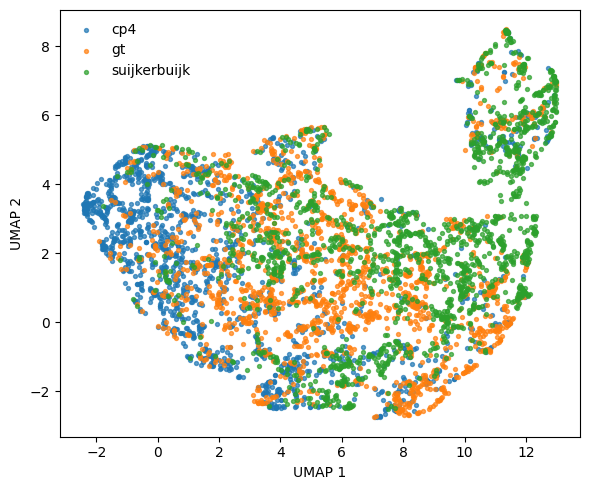

C:\Users\6331823\AppData\Local\Temp\ipykernel_32604\2157958935.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


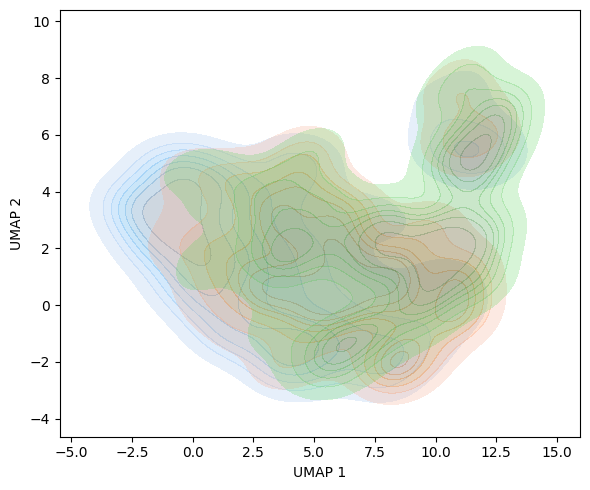

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
for label, grp in df_all.groupby("source"):
    plt.scatter(grp["umap_1"], grp["umap_2"], s=8, alpha=0.7, label=label)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ...existing code...
# --- KDE on UMAP (per source) ---
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
for label, grp in df_all.groupby("source"):
    sns.kdeplot(
        x=grp["umap_1"],
        y=grp["umap_2"],
        fill=True,
        alpha=0.25,
        levels=8,
        bw_adjust=0.9,
        label=label,
    )
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Filtered outliers: 30
Explained variance ratio: [0.514 0.207 0.19  0.058 0.031]
Cumulative: [0.514 0.722 0.911 0.969 1.   ]


,PC1,PC2,PC3,PC4,PC5
sphericity,0.560634,0.225189,0.021890,-0.551620,0.574644
compactness,-0.556004,-0.084507,0.334061,0.179195,0.734854
solidity_bbox,0.548906,-0.169968,-0.128062,0.762613,0.268019
flatness,0.249743,0.111231,0.927395,0.085341,-0.240648
elongation,-0.113488,0.949151,-0.107065,0.273391,0.005288


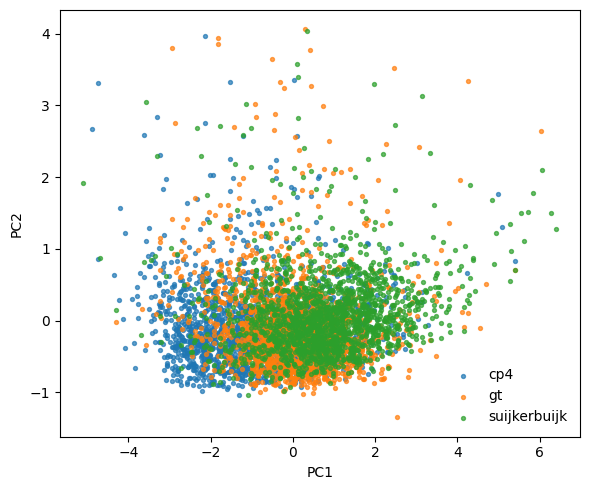

In [19]:
# ...existing code...
# --- POD / PCA on scaled features ---
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

pca = PCA(n_components=5, random_state=42)
scores = pca.fit_transform(X_scaled)

df_all["pc1"] = scores[:, 0]
df_all["pc2"] = scores[:, 1]

# filter outliers for plotting only
z = np.abs(zscore(df_all[["pc1", "pc2"]], nan_policy="omit"))
keep = (z < 4).all(axis=1)  # adjust threshold if needed
df_plot = df_all[keep].copy()

print(f"Filtered outliers: {len(df_all) - len(df_plot)}")

# explained variance
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative:", np.round(np.cumsum(pca.explained_variance_ratio_), 3))

# loadings (feature contributions)
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
)
display(loadings.sort_values("PC1", key=np.abs, ascending=False).head(10))

# PC1/PC2 scatter
plt.figure(figsize=(6, 5))
for label, grp in df_plot.groupby("source"):
    plt.scatter(grp["pc1"], grp["pc2"], s=8, alpha=0.7, label=label)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [20]:
# ...existing code...

# --- PCA-space MMD (pairwise) ---
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances


def _rbf_mmd(X, Y, gamma=None):
    """Unbiased MMD^2 with RBF kernel."""
    if gamma is None:
        Z = np.vstack([X, Y])
        # median heuristic for gamma
        d2 = pairwise_distances(Z, metric="sqeuclidean")
        med = np.median(d2[d2 > 0])
        gamma = 1.0 / (2.0 * med) if med > 0 else 1.0

    Kxx = np.exp(-gamma * pairwise_distances(X, metric="sqeuclidean"))
    Kyy = np.exp(-gamma * pairwise_distances(Y, metric="sqeuclidean"))
    Kxy = np.exp(-gamma * pairwise_distances(X, Y, metric="sqeuclidean"))

    n = X.shape[0]
    m = Y.shape[0]
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    mmd2 = (
        (Kxx.sum() / (n * (n - 1))) + (Kyy.sum() / (m * (m - 1))) - (2.0 * Kxy.mean())
    )
    return float(mmd2)


# pick k PCs by variance threshold
pca = PCA(n_components=min(20, X_scaled.shape[1]), random_state=42)
scores = pca.fit_transform(X_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)
k = int(np.searchsorted(cumvar, 0.90) + 1)  # 90% variance
X_pca = scores[:, :k]

df_all["source"] = df_all["source"].astype(str)  # ensure string
sources = df_all["source"].unique()

# compute pairwise MMD
mmd_rows = []
for i, a in enumerate(sources):
    Xa = X_pca[df_all["source"] == a]
    for b in sources[i + 1 :]:
        Xb = X_pca[df_all["source"] == b]
        mmd2 = _rbf_mmd(Xa, Xb, gamma=None)
        mmd_rows.append({"A": a, "B": b, "MMD^2": mmd2, "k_pcs": k})

mmd_df = pd.DataFrame(mmd_rows).sort_values("MMD^2")
display(mmd_df)

# ...existing code...

,A,B,MMD^2,k_pcs
1,suijkerbuijk,gt,0.064005,3
2,cp4,gt,0.140611,3
0,suijkerbuijk,cp4,0.268236,3
